STEP 1 - DATA UNDERSTANDING
NEW_BACKUP / FINAL 80-20 SPLIT

Checking New_backup files...

✓ Combined cleaned dataset       506.79 MB
✓ Training 80%                   405.14 MB
✓ Validation 20%                 101.68 MB
✓ Training features              22.05 MB
✓ Validation features            5.66 MB
✓ 3000 GPT-OSS labels            26.27 MB
✓ Fresh Step-4 sample            1.68 MB

LOADING FINAL DATA
✓ Training loaded   : 149,277
✓ Validation loaded : 37,320

DATASET SIZE
Training trajectories   : 149,277
Validation trajectories : 37,320
Total trajectories      : 186,597
Training shape          : (149277, 10)
Validation shape        : (37320, 10)
✓ Dataset row counts verified.

ACTUAL DATASET COLUMNS
['id', 'conversations', 'original_split', 'valid_conversation', 'step_depth', 'role_sequence', 'num_turns', 'has_required_roles', 'depth_bucket', 'research_split']

Dataset dtypes:
id                    object
conversations         object
original_split        object
valid_conversation   

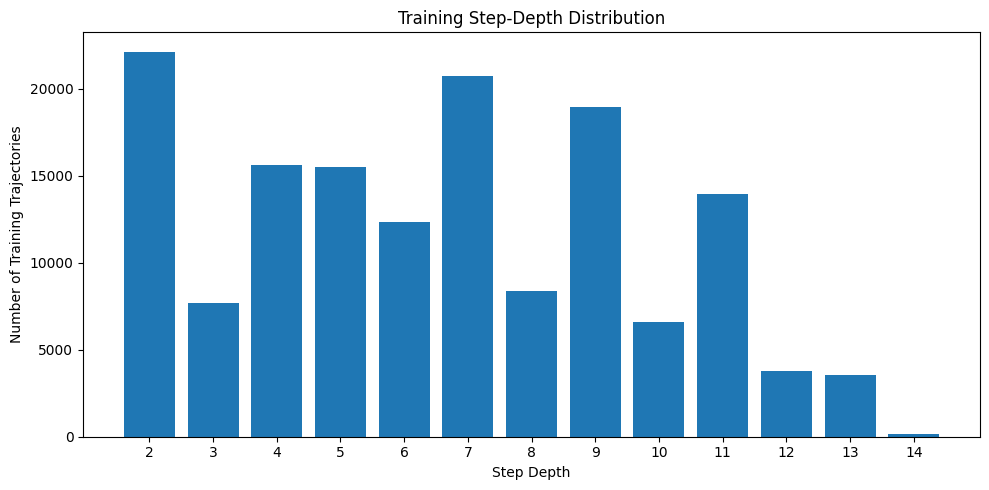


✓ STEP 1 CELL 1 COMPLETED SUCCESSFULLY
New backup root         : /kaggle/input/datasets/anandadevnath/new-backup/Master_backup
Training file           : /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/dataset/toolbench_train_80.parquet
Validation file         : /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/dataset/toolbench_validation_20.parquet
Combined cleaned file   : /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/dataset/toolbench_combined_cleaned.parquet
Training trajectories   : 149,277
Validation trajectories : 37,320
Total trajectories      : 186,597
Train/validation overlap: 0
Training depth range    : 2-14
Validation depth range  : 2-14
3000 GPT-OSS labels     : /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/labeling_backups/step4_llm_annotations_gptoss120b.parquet
Fresh Step-4 sample     : /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/research_outputs/data/processed/step4_fresh_sample_300.parquet
Wo

In [1]:
# ============================================================
# STEP 1 - CELL 1
# KAGGLE VERSION — NEW_BACKUP
# DATA UNDERSTANDING USING FINAL CLEANED 80/20 SPLIT
# ============================================================

import os
import json
import ast
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. NEW_BACKUP PATHS
# ============================================================

BACKUP_ROOT = (
    "/kaggle/input/datasets/"
    "anandadevnath/"
    "new-backup/"
    "Master_backup"
)

DATASET_PATH = os.path.join(
    BACKUP_ROOT,
    "dataset"
)

FEATURE_PATH = os.path.join(
    BACKUP_ROOT,
    "featured"
)

LABEL_PATH = os.path.join(
    BACKUP_ROOT,
    "labeling_backups"
)

RESEARCH_OUTPUT_PATH = os.path.join(
    BACKUP_ROOT,
    "research_outputs"
)


# ============================================================
# 2. MAIN DATA FILES
# ============================================================

COMBINED_FILE = os.path.join(
    DATASET_PATH,
    "toolbench_combined_cleaned.parquet"
)

TRAIN_FILE = os.path.join(
    DATASET_PATH,
    "toolbench_train_80.parquet"
)

VALIDATION_FILE = os.path.join(
    DATASET_PATH,
    "toolbench_validation_20.parquet"
)


# ============================================================
# 3. STEP 3 FEATURE FILES
# ============================================================

TRAIN_FEATURE_FILE = os.path.join(
    FEATURE_PATH,
    "toolbench_train_80_features.parquet"
)

VALIDATION_FEATURE_FILE = os.path.join(
    FEATURE_PATH,
    "toolbench_validation_20_features.parquet"
)


# ============================================================
# 4. STEP 4 FILES
# ============================================================

LLM_ANNOTATION_FILE = os.path.join(
    LABEL_PATH,
    "step4_llm_annotations_gptoss120b.parquet"
)

STEP4_SAMPLE_FILE = os.path.join(
    RESEARCH_OUTPUT_PATH,
    "data",
    "processed",
    "step4_fresh_sample_300.parquet"
)


# ============================================================
# 5. WORKING OUTPUT PATHS
# ============================================================

WORKING_PATH = (
    "/kaggle/working/toolbench_research"
)

PROCESSED_PATH = os.path.join(
    WORKING_PATH,
    "data",
    "processed"
)

FIGURE_PATH = os.path.join(
    WORKING_PATH,
    "results",
    "figures"
)

TABLE_PATH = os.path.join(
    WORKING_PATH,
    "results",
    "tables"
)


for folder in [
    PROCESSED_PATH,
    FIGURE_PATH,
    TABLE_PATH
]:
    os.makedirs(
        folder,
        exist_ok=True
    )


print("=" * 100)
print("STEP 1 - DATA UNDERSTANDING")
print("NEW_BACKUP / FINAL 80-20 SPLIT")
print("=" * 100)


# ============================================================
# 6. VERIFY ALL IMPORTANT FILES
# ============================================================

required_files = {
    "Combined cleaned dataset":
        COMBINED_FILE,

    "Training 80%":
        TRAIN_FILE,

    "Validation 20%":
        VALIDATION_FILE,

    "Training features":
        TRAIN_FEATURE_FILE,

    "Validation features":
        VALIDATION_FEATURE_FILE,

    "3000 GPT-OSS labels":
        LLM_ANNOTATION_FILE,

    "Fresh Step-4 sample":
        STEP4_SAMPLE_FILE,
}


print("\nChecking New_backup files...\n")


for name, path in required_files.items():

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    size_mb = (
        os.path.getsize(path)
        /
        (1024 ** 2)
    )

    print(
        f"✓ {name:<30} "
        f"{size_mb:,.2f} MB"
    )


# ============================================================
# 7. LOAD FINAL TRAINING / VALIDATION DATA
# ============================================================

print("\n" + "=" * 100)
print("LOADING FINAL DATA")
print("=" * 100)


df = pd.read_parquet(
    TRAIN_FILE
)

validation_df = pd.read_parquet(
    VALIDATION_FILE
)


print(
    f"✓ Training loaded   : "
    f"{len(df):,}"
)

print(
    f"✓ Validation loaded : "
    f"{len(validation_df):,}"
)


# ============================================================
# 8. DATASET SIZE
# ============================================================

print("\n" + "=" * 100)
print("DATASET SIZE")
print("=" * 100)


print(
    f"Training trajectories   : "
    f"{len(df):,}"
)

print(
    f"Validation trajectories : "
    f"{len(validation_df):,}"
)

print(
    f"Total trajectories      : "
    f"{len(df) + len(validation_df):,}"
)

print(
    f"Training shape          : "
    f"{df.shape}"
)

print(
    f"Validation shape        : "
    f"{validation_df.shape}"
)


# Expected final counts

if len(df) != 149277:

    raise ValueError(
        f"Expected 149,277 training rows, "
        f"found {len(df):,}"
    )


if len(validation_df) != 37320:

    raise ValueError(
        f"Expected 37,320 validation rows, "
        f"found {len(validation_df):,}"
    )


if (
    len(df)
    +
    len(validation_df)
    !=
    186597
):

    raise ValueError(
        "Expected 186,597 total cleaned trajectories."
    )


print(
    "✓ Dataset row counts verified."
)


# ============================================================
# 9. ACTUAL DATASET COLUMNS
# ============================================================

print("\n" + "=" * 100)
print("ACTUAL DATASET COLUMNS")
print("=" * 100)


print(
    df.columns.tolist()
)


print(
    "\nDataset dtypes:"
)

print(
    df.dtypes
)


# ============================================================
# 10. VERIFY REQUIRED COLUMNS
# ============================================================

required_columns = [
    "id",
    "conversations",
    "step_depth",
    "depth_bucket",
    "num_turns",
]


missing_train = [
    column
    for column in required_columns
    if column not in df.columns
]


missing_validation = [
    column
    for column in required_columns
    if column not in validation_df.columns
]


if missing_train:

    raise ValueError(
        f"Training missing columns: "
        f"{missing_train}"
    )


if missing_validation:

    raise ValueError(
        f"Validation missing columns: "
        f"{missing_validation}"
    )


print(
    "\n✓ Required columns found."
)


# ============================================================
# 11. BASIC DATA CHECK
# ============================================================

print("\n" + "=" * 100)
print("BASIC DATA CHECK")
print("=" * 100)


print(
    "\nTraining missing values:"
)

print(
    df[
        required_columns
    ]
    .isnull()
    .sum()
)


print(
    "\nValidation missing values:"
)

print(
    validation_df[
        required_columns
    ]
    .isnull()
    .sum()
)


train_duplicates = int(
    df[
        "id"
    ]
    .duplicated()
    .sum()
)


validation_duplicates = int(
    validation_df[
        "id"
    ]
    .duplicated()
    .sum()
)


print(
    f"\nTraining duplicate IDs   : "
    f"{train_duplicates}"
)

print(
    f"Validation duplicate IDs : "
    f"{validation_duplicates}"
)

print(
    f"Training unique IDs      : "
    f"{df['id'].nunique():,}"
)

print(
    f"Validation unique IDs    : "
    f"{validation_df['id'].nunique():,}"
)


if train_duplicates != 0:

    raise ValueError(
        "Duplicate IDs detected in training data."
    )


if validation_duplicates != 0:

    raise ValueError(
        "Duplicate IDs detected in validation data."
    )


# ============================================================
# 12. TRAIN / VALIDATION LEAKAGE CHECK
# ============================================================

train_ids = set(
    df[
        "id"
    ]
    .astype(str)
)


validation_ids = set(
    validation_df[
        "id"
    ]
    .astype(str)
)


overlap = (
    train_ids
    &
    validation_ids
)


print(
    f"\nTrain-validation ID overlap: "
    f"{len(overlap)}"
)


if len(overlap) != 0:

    raise ValueError(
        "Train/validation leakage detected."
    )


print(
    "✓ No train/validation leakage."
)


# ============================================================
# 13. STEP DEPTH CHECK
# ============================================================

print("\n" + "=" * 100)
print("STEP DEPTH CHECK")
print("=" * 100)


print(
    f"Training minimum depth   : "
    f"{df['step_depth'].min()}"
)

print(
    f"Training maximum depth   : "
    f"{df['step_depth'].max()}"
)

print(
    f"Validation minimum depth : "
    f"{validation_df['step_depth'].min()}"
)

print(
    f"Validation maximum depth : "
    f"{validation_df['step_depth'].max()}"
)


if not df[
    "step_depth"
].between(
    2,
    14
).all():

    raise ValueError(
        "Training contains invalid step depth."
    )


if not validation_df[
    "step_depth"
].between(
    2,
    14
).all():

    raise ValueError(
        "Validation contains invalid step depth."
    )


print(
    "✓ Step depth range = 2-14."
)


# ============================================================
# 14. SAMPLE IDS
# ============================================================

print("\n" + "=" * 100)
print("SAMPLE TRAINING IDS")
print("=" * 100)


for i, value in enumerate(
    df[
        "id"
    ].head(
        10
    ),
    start=1
):

    print(
        f"{i}. {value}"
    )


# ============================================================
# 15. ROBUST CONVERSATION PARSER
# ============================================================

def parse_conversation(conv):

    if conv is None:

        return [], []


    # --------------------------------------------------------
    # NUMPY ARRAY
    # --------------------------------------------------------

    if isinstance(
        conv,
        np.ndarray
    ):

        conv = conv.tolist()


    # --------------------------------------------------------
    # DICTIONARY FORMAT
    # --------------------------------------------------------

    if isinstance(
        conv,
        dict
    ):

        roles = conv.get(
            "from",
            []
        )

        values = conv.get(
            "value",
            []
        )


        if isinstance(
            roles,
            np.ndarray
        ):

            roles = roles.tolist()


        if isinstance(
            values,
            np.ndarray
        ):

            values = values.tolist()


        roles = (
            []
            if roles is None
            else list(
                roles
            )
        )

        values = (
            []
            if values is None
            else list(
                values
            )
        )


        return (
            roles,
            values
        )


    # --------------------------------------------------------
    # LIST OF DICTIONARIES
    # --------------------------------------------------------

    if isinstance(
        conv,
        list
    ):

        roles = []
        values = []


        for turn in conv:

            if isinstance(
                turn,
                dict
            ):

                roles.append(
                    turn.get(
                        "from",
                        turn.get(
                            "role",
                            "unknown"
                        )
                    )
                )


                values.append(
                    turn.get(
                        "value",
                        turn.get(
                            "content",
                            ""
                        )
                    )
                )


        return (
            roles,
            values
        )


    # --------------------------------------------------------
    # STRING FORMAT
    # --------------------------------------------------------

    if isinstance(
        conv,
        str
    ):

        try:

            parsed = json.loads(
                conv
            )

            return parse_conversation(
                parsed
            )

        except Exception:

            try:

                parsed = ast.literal_eval(
                    conv
                )

                return parse_conversation(
                    parsed
                )

            except Exception:

                return [], []


    return [], []


# ============================================================
# 16. INSPECT FIRST REAL CONVERSATION
# ============================================================

sample_conv = (
    df[
        "conversations"
    ]
    .iloc[
        0
    ]
)


roles, values = (
    parse_conversation(
        sample_conv
    )
)


print("\n" + "=" * 100)
print("FIRST TRAJECTORY STRUCTURE")
print("=" * 100)


print(
    "Conversation Python type:",
    type(
        sample_conv
    )
)


print(
    "\nRoles:"
)

print(
    roles
)


print(
    f"\nNumber of turns: "
    f"{len(roles)}"
)


print(
    "\nFirst few turns:"
)


for i in range(
    min(
        5,
        len(
            roles
        )
    )
):

    text = str(
        values[
            i
        ]
    )


    if len(
        text
    ) > 300:

        text = (
            text[
                :300
            ]
            +
            "..."
        )


    print(
        f"\nTurn {i + 1}"
    )

    print(
        f"Role: {roles[i]}"
    )

    print(
        f"Text: {text}"
    )


# ============================================================
# 17. VERIFY EXISTING ROLE SEQUENCE / NUM_TURNS
# ============================================================

def get_roles(conv):

    roles, _ = (
        parse_conversation(
            conv
        )
    )

    return roles


# We DO NOT overwrite the cleaned dataset.
# We only verify a sample against stored num_turns.

VERIFY_ROWS = min(
    1000,
    len(
        df
    )
)


verification_sample = df.iloc[
    :VERIFY_ROWS
].copy()


verification_sample[
    "_parsed_roles"
] = (
    verification_sample[
        "conversations"
    ]
    .apply(
        get_roles
    )
)


verification_sample[
    "_parsed_num_turns"
] = (
    verification_sample[
        "_parsed_roles"
    ]
    .apply(
        len
    )
)


turn_mismatches = int(
    (
        verification_sample[
            "_parsed_num_turns"
        ]
        !=
        verification_sample[
            "num_turns"
        ]
    )
    .sum()
)


print("\n" + "=" * 100)
print("TURN COUNT VERIFICATION")
print("=" * 100)


print(
    f"Rows checked    : "
    f"{VERIFY_ROWS:,}"
)

print(
    f"Turn mismatches : "
    f"{turn_mismatches}"
)


if turn_mismatches != 0:

    raise ValueError(
        "Stored num_turns does not match "
        "parsed conversation structure."
    )


print(
    "✓ Stored num_turns verified."
)


# ============================================================
# 18. ROLE FREQUENCY — TRAINING ONLY
# ============================================================

role_counter = Counter()


for conv in df[
    "conversations"
]:

    roles, _ = (
        parse_conversation(
            conv
        )
    )

    role_counter.update(
        roles
    )


role_df = pd.DataFrame(
    role_counter.items(),
    columns=[
        "role",
        "count"
    ]
).sort_values(
    "count",
    ascending=False
)


# ============================================================
# 19. TRAINING STEP DEPTH DISTRIBUTION
# ============================================================

depth_distribution = (
    df[
        "step_depth"
    ]
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis(
        "step_depth"
    )
    .reset_index(
        name="trajectory_count"
    )
)


depth_distribution[
    "percentage"
] = (
    depth_distribution[
        "trajectory_count"
    ]
    /
    len(
        df
    )
    *
    100
)


# ============================================================
# 20. VALIDATION STEP DEPTH DISTRIBUTION
# ============================================================

validation_depth_distribution = (
    validation_df[
        "step_depth"
    ]
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis(
        "step_depth"
    )
    .reset_index(
        name="trajectory_count"
    )
)


validation_depth_distribution[
    "percentage"
] = (
    validation_depth_distribution[
        "trajectory_count"
    ]
    /
    len(
        validation_df
    )
    *
    100
)


# ============================================================
# 21. DEPTH BUCKET DISTRIBUTION
# ============================================================

DEPTH_BUCKETS = [
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9",
    "10",
    "11",
    "12",
    "13+"
]


train_bucket_distribution = (
    df[
        "depth_bucket"
    ]
    .astype(str)
    .value_counts()
    .reindex(
        DEPTH_BUCKETS,
        fill_value=0
    )
)


validation_bucket_distribution = (
    validation_df[
        "depth_bucket"
    ]
    .astype(str)
    .value_counts()
    .reindex(
        DEPTH_BUCKETS,
        fill_value=0
    )
)


bucket_table = pd.DataFrame(
    {
        "train":
            train_bucket_distribution,

        "validation":
            validation_bucket_distribution
    }
)


# ============================================================
# 22. RESULTS
# ============================================================

print("\n" + "=" * 100)
print("TRAJECTORY LENGTH STATISTICS — TRAINING")
print("=" * 100)


print(
    df[
        "num_turns"
    ]
    .describe()
)


print("\n" + "=" * 100)
print("TRAJECTORY LENGTH STATISTICS — VALIDATION")
print("=" * 100)


print(
    validation_df[
        "num_turns"
    ]
    .describe()
)


print("\n" + "=" * 100)
print("ROLE DISTRIBUTION — TRAINING")
print("=" * 100)


print(
    role_df.to_string(
        index=False
    )
)


print("\n" + "=" * 100)
print("STEP DEPTH DISTRIBUTION — TRAINING")
print("=" * 100)


print(
    depth_distribution.to_string(
        index=False
    )
)


print("\n" + "=" * 100)
print("STEP DEPTH DISTRIBUTION — VALIDATION")
print("=" * 100)


print(
    validation_depth_distribution.to_string(
        index=False
    )
)


print("\n" + "=" * 100)
print("DEPTH BUCKET DISTRIBUTION — 80/20")
print("=" * 100)


print(
    bucket_table.to_string()
)


# ============================================================
# 23. SAVE STEP 1 OUTPUTS
# ============================================================

depth_distribution.to_csv(
    os.path.join(
        PROCESSED_PATH,
        "step1_train_depth_distribution.csv"
    ),
    index=False
)


validation_depth_distribution.to_csv(
    os.path.join(
        PROCESSED_PATH,
        "step1_validation_depth_distribution.csv"
    ),
    index=False
)


role_df.to_csv(
    os.path.join(
        PROCESSED_PATH,
        "step1_train_role_distribution.csv"
    ),
    index=False
)


bucket_table.to_csv(
    os.path.join(
        PROCESSED_PATH,
        "step1_train_validation_depth_buckets.csv"
    )
)


# ============================================================
# 24. VISUALIZATION
# ============================================================

plt.figure(
    figsize=(
        10,
        5
    )
)


plt.bar(
    depth_distribution[
        "step_depth"
    ].astype(str),
    depth_distribution[
        "trajectory_count"
    ]
)


plt.xlabel(
    "Step Depth"
)

plt.ylabel(
    "Number of Training Trajectories"
)

plt.title(
    "Training Step-Depth Distribution"
)

plt.tight_layout()


figure_file = os.path.join(
    FIGURE_PATH,
    "step1_train_step_depth_distribution.png"
)


plt.savefig(
    figure_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 25. FINAL STATUS
# ============================================================

print("\n" + "=" * 100)
print("✓ STEP 1 CELL 1 COMPLETED SUCCESSFULLY")
print("=" * 100)


print(
    f"New backup root         : "
    f"{BACKUP_ROOT}"
)

print(
    f"Training file           : "
    f"{TRAIN_FILE}"
)

print(
    f"Validation file         : "
    f"{VALIDATION_FILE}"
)

print(
    f"Combined cleaned file   : "
    f"{COMBINED_FILE}"
)

print(
    f"Training trajectories   : "
    f"{len(df):,}"
)

print(
    f"Validation trajectories : "
    f"{len(validation_df):,}"
)

print(
    f"Total trajectories      : "
    f"{len(df) + len(validation_df):,}"
)

print(
    f"Train/validation overlap: "
    f"{len(overlap)}"
)

print(
    f"Training depth range    : "
    f"{df['step_depth'].min()}-"
    f"{df['step_depth'].max()}"
)

print(
    f"Validation depth range  : "
    f"{validation_df['step_depth'].min()}-"
    f"{validation_df['step_depth'].max()}"
)

print(
    f"3000 GPT-OSS labels     : "
    f"{LLM_ANNOTATION_FILE}"
)

print(
    f"Fresh Step-4 sample     : "
    f"{STEP4_SAMPLE_FILE}"
)

print(
    f"Working path            : "
    f"{WORKING_PATH}"
)


print("\n✓ Uses ONLY New_backup")
print("✓ Uses final cleaned 80% training split")
print("✓ Keeps final 20% validation separate")
print("✓ Does NOT reload old raw ToolBench shards")
print("✓ Does NOT redo cleaning")
print("✓ Does NOT redo the 80/20 split")
print("✓ Does NOT modify the 3000 GPT-OSS labels")
print("✓ Does NOT modify the fresh Step-4 sample")
print("=" * 100)

STEP 1 - CELL 2 VISUALIZATIONS

Figure directory:
/kaggle/working/toolbench_research/results/figures


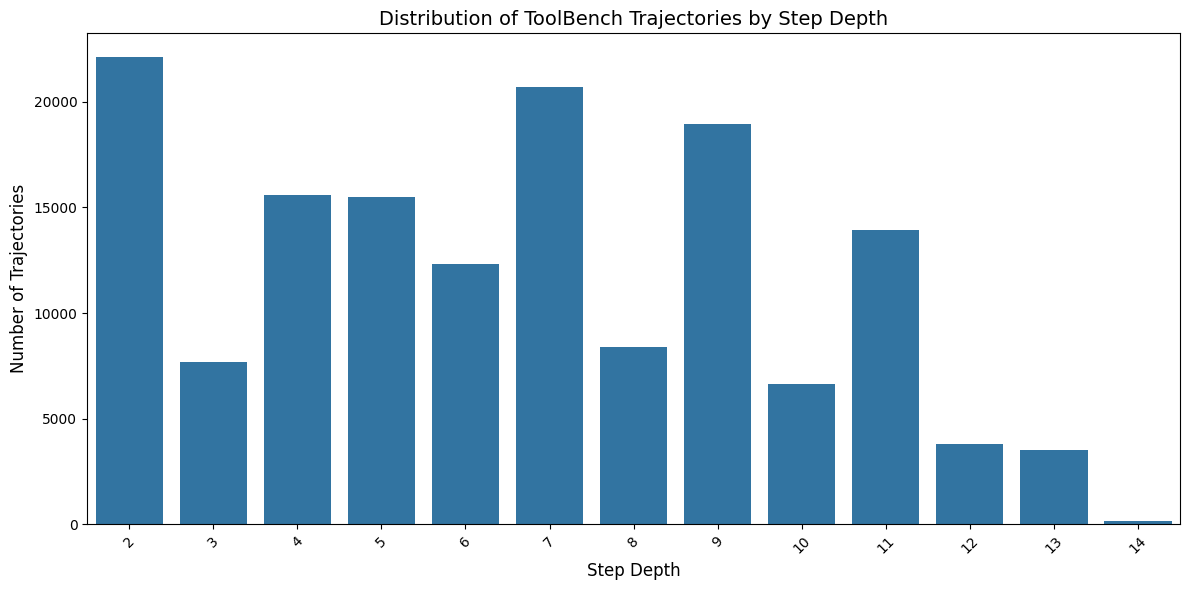

✓ Saved: /kaggle/working/toolbench_research/results/figures/step1_step_depth_distribution.png


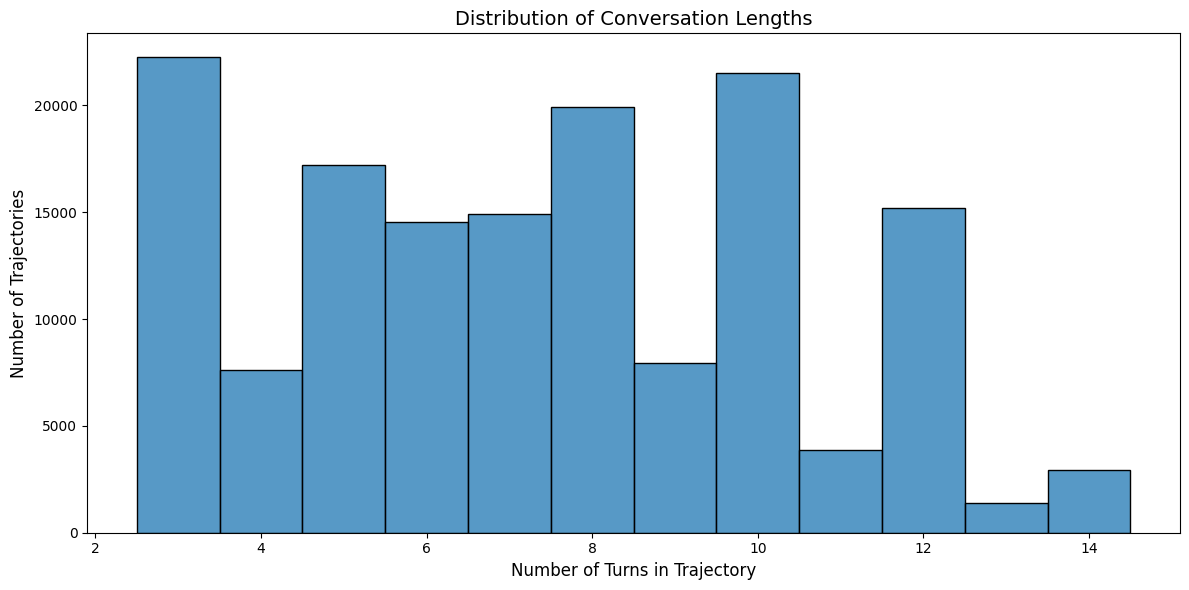

✓ Saved: /kaggle/working/toolbench_research/results/figures/step1_conversation_length_distribution.png


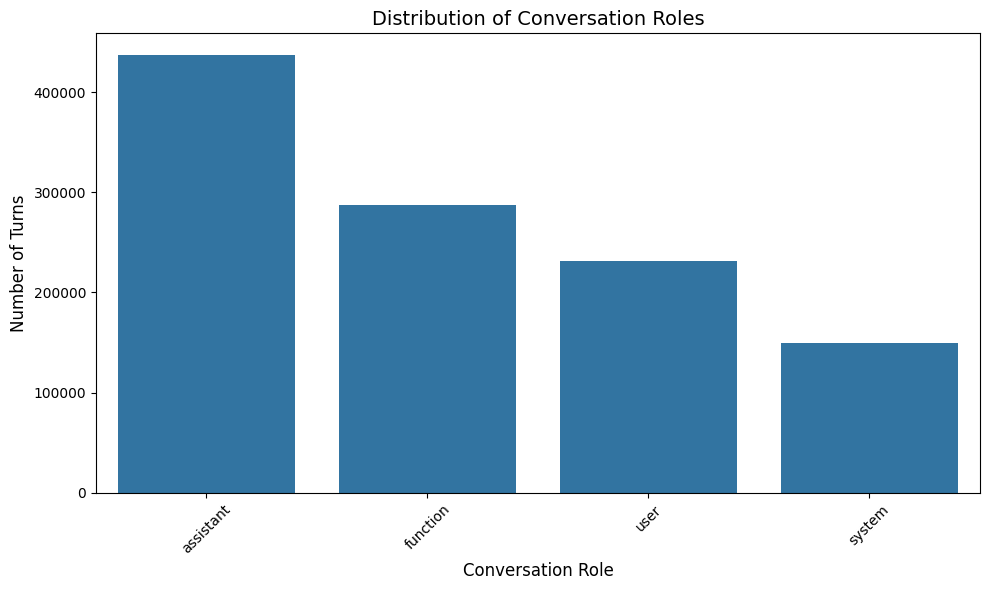

✓ Saved: /kaggle/working/toolbench_research/results/figures/step1_role_distribution.png


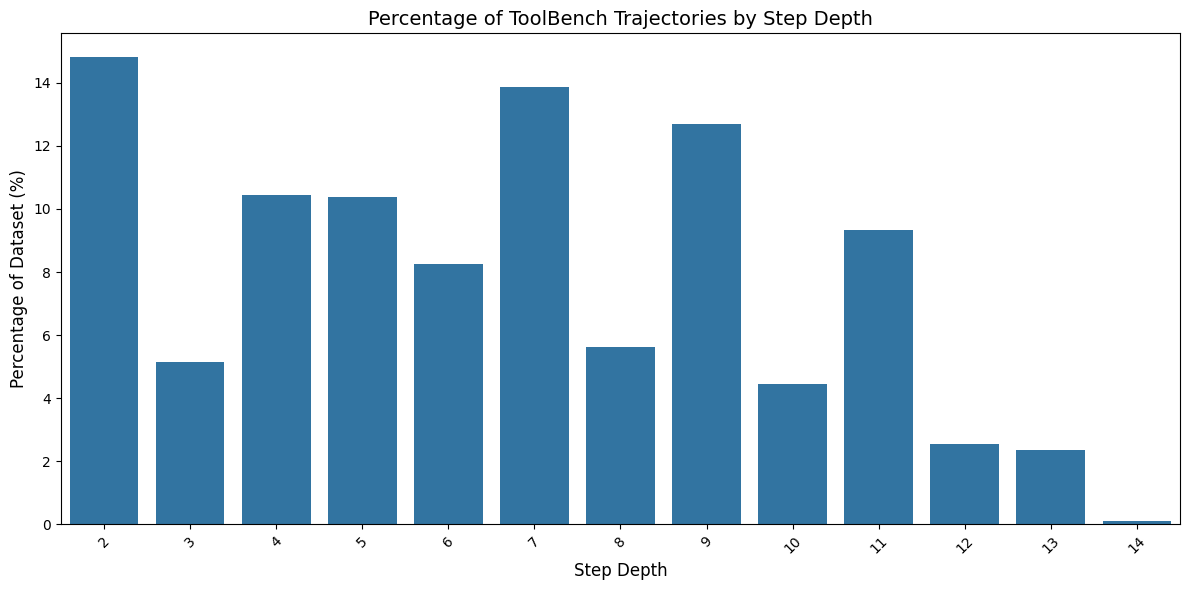

✓ Saved: /kaggle/working/toolbench_research/results/figures/step1_step_depth_percentage.png

FIGURE FILE CHECK
✓ step1_step_depth_distribution.png (110.4 KB)
✓ step1_conversation_length_distribution.png (96.4 KB)
✓ step1_role_distribution.png (107.8 KB)
✓ step1_step_depth_percentage.png (113.8 KB)

✓ STEP 1 - CELL 2 COMPLETED SUCCESSFULLY

Generated visualizations:
1. Step-depth trajectory count
2. Conversation-length distribution
3. Conversation-role distribution
4. Step-depth percentage distribution

Saved in:
/kaggle/working/toolbench_research/results/figures


In [3]:
# ============================================================
# STEP 1 - CELL 2
# KAGGLE VERSION
# VISUALIZATIONS
# ============================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. FIGURE OUTPUT DIRECTORY
# ============================================================

FIGURE_DIR = os.path.join(
    WORKING_PATH,
    "results",
    "figures"
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

print("=" * 70)
print("STEP 1 - CELL 2 VISUALIZATIONS")
print("=" * 70)

print("\nFigure directory:")
print(FIGURE_DIR)


# ============================================================
# 2. VISUAL 1 — STEP DEPTH DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(12, 6)
)

sns.barplot(
    data=depth_distribution,
    x="step_depth",
    y="trajectory_count"
)

plt.title(
    "Distribution of ToolBench Trajectories by Step Depth",
    fontsize=14
)

plt.xlabel(
    "Step Depth",
    fontsize=12
)

plt.ylabel(
    "Number of Trajectories",
    fontsize=12
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

STEP_DEPTH_COUNT_PATH = os.path.join(
    FIGURE_DIR,
    "step1_step_depth_distribution.png"
)

plt.savefig(
    STEP_DEPTH_COUNT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Saved:",
    STEP_DEPTH_COUNT_PATH
)


# ============================================================
# 3. VISUAL 2 — CONVERSATION LENGTH DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(12, 6)
)

sns.histplot(
    data=df,
    x="num_turns",
    discrete=True
)

plt.title(
    "Distribution of Conversation Lengths",
    fontsize=14
)

plt.xlabel(
    "Number of Turns in Trajectory",
    fontsize=12
)

plt.ylabel(
    "Number of Trajectories",
    fontsize=12
)

plt.tight_layout()

CONVERSATION_LENGTH_PATH = os.path.join(
    FIGURE_DIR,
    "step1_conversation_length_distribution.png"
)

plt.savefig(
    CONVERSATION_LENGTH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Saved:",
    CONVERSATION_LENGTH_PATH
)


# ============================================================
# 4. VISUAL 3 — ROLE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=role_df,
    x="role",
    y="count"
)

plt.title(
    "Distribution of Conversation Roles",
    fontsize=14
)

plt.xlabel(
    "Conversation Role",
    fontsize=12
)

plt.ylabel(
    "Number of Turns",
    fontsize=12
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

ROLE_DISTRIBUTION_PATH = os.path.join(
    FIGURE_DIR,
    "step1_role_distribution.png"
)

plt.savefig(
    ROLE_DISTRIBUTION_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Saved:",
    ROLE_DISTRIBUTION_PATH
)


# ============================================================
# 5. VISUAL 4 — STEP DEPTH PERCENTAGE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(12, 6)
)

sns.barplot(
    data=depth_distribution,
    x="step_depth",
    y="percentage"
)

plt.title(
    "Percentage of ToolBench Trajectories by Step Depth",
    fontsize=14
)

plt.xlabel(
    "Step Depth",
    fontsize=12
)

plt.ylabel(
    "Percentage of Dataset (%)",
    fontsize=12
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

STEP_DEPTH_PERCENTAGE_PATH = os.path.join(
    FIGURE_DIR,
    "step1_step_depth_percentage.png"
)

plt.savefig(
    STEP_DEPTH_PERCENTAGE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Saved:",
    STEP_DEPTH_PERCENTAGE_PATH
)


# ============================================================
# 6. VERIFY GENERATED FILES
# ============================================================

generated_figures = [
    STEP_DEPTH_COUNT_PATH,
    CONVERSATION_LENGTH_PATH,
    ROLE_DISTRIBUTION_PATH,
    STEP_DEPTH_PERCENTAGE_PATH
]

print("\n" + "=" * 70)
print("FIGURE FILE CHECK")
print("=" * 70)

for path in generated_figures:

    if os.path.exists(path):

        size_kb = (
            os.path.getsize(path)
            / 1024
        )

        print(
            f"✓ {os.path.basename(path)} "
            f"({size_kb:.1f} KB)"
        )

    else:

        raise FileNotFoundError(
            f"Figure was not created:\n{path}"
        )


# ============================================================
# 7. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("✓ STEP 1 - CELL 2 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nGenerated visualizations:")

print(
    "1. Step-depth trajectory count"
)

print(
    "2. Conversation-length distribution"
)

print(
    "3. Conversation-role distribution"
)

print(
    "4. Step-depth percentage distribution"
)

print("\nSaved in:")
print(FIGURE_DIR)

STEP 1 - CELL 3
INITIAL ERROR-SIGNAL ANALYSIS

Scanning trajectories for preliminary function error signals...
✓ Error-signal scan completed

CORRECTED INITIAL ERROR-SIGNAL ANALYSIS

No detected error signal : 90,378
Detected error signal    : 58,899
Initial error-signal rate: 39.456179%

ERROR-SIGNAL SUMMARY TABLE
         status  count  percentage
No Error Signal  90378   60.543821
   Error Signal  58899   39.456179


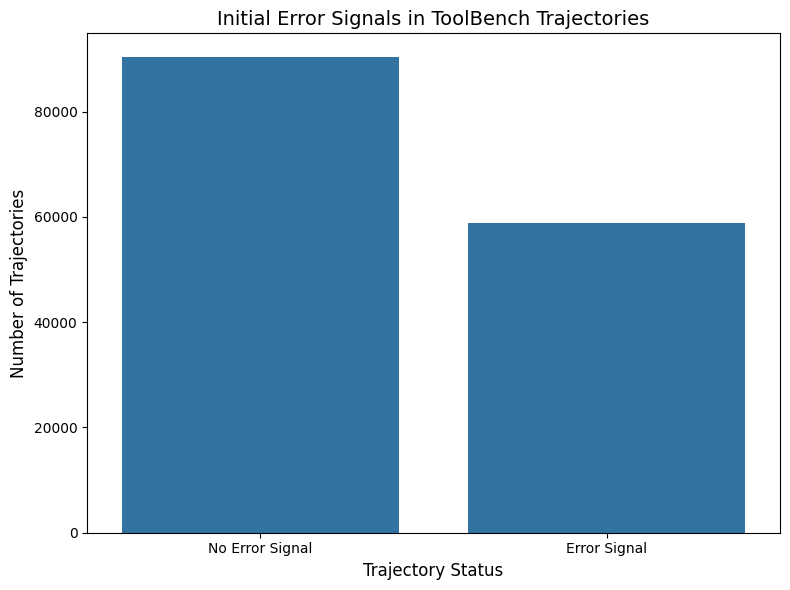

✓ Saved: /kaggle/working/toolbench_research/results/figures/step1_corrected_error_signal_distribution.png

CORRECTED ERROR SIGNAL BY STEP DEPTH
 step_depth  total_trajectories  error_trajectories  error_rate_percent
          2               22134                  53            0.239451
          3                7668                  19            0.247783
          4               15611                3737           23.938249
          5               15476                6904           44.611011
          6               12315                3572           29.005278
          7               20715               11350           54.791214
          8                8379                3377           40.303139
          9               18952               12182           64.278176
         10                6620                3611           54.546828
         11               13932                9397           67.449038
         12                3792                2336           61

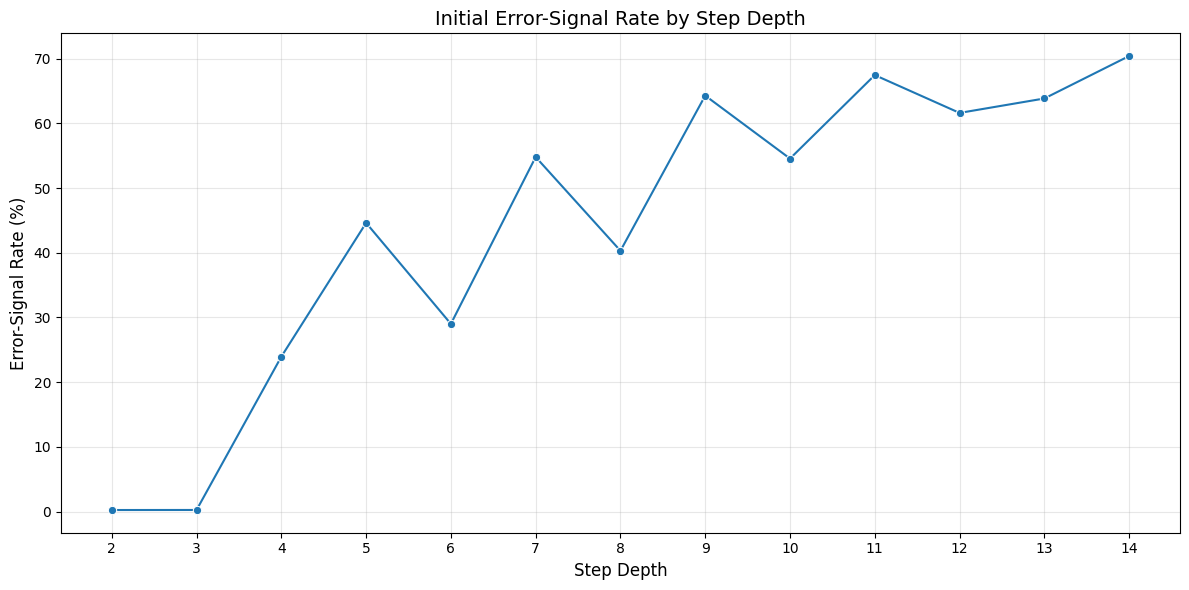

✓ Saved: /kaggle/working/toolbench_research/results/figures/step1_corrected_error_rate_by_depth.png

SAMPLE TRAJECTORIES WITH ERROR SIGNAL
                                                                                                                                                                                                                                                                                                                                                                                id  step_depth  num_turns
                                                    Step 5: I'm organizing a cocktail workshop and I need a variety of cocktail recipes. Could you please give me a list of cocktails along with their images? I would also like to get the detailed recipes for a few randomly selected cocktails. Additionally, do you have any recommendations for wine pairing with cocktails?           5          6
                                                                 Step 11:

In [2]:
# ============================================================
# STEP 1 - CELL 3
# KAGGLE VERSION
# CORRECTED INITIAL ERROR-SIGNAL ANALYSIS + FINAL SUMMARY
# ============================================================

import os
import ast
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. OUTPUT DIRECTORIES
# ============================================================

FIGURE_DIR = os.path.join(
    WORKING_PATH,
    "results",
    "figures"
)

TABLE_DIR = os.path.join(
    WORKING_PATH,
    "results",
    "tables"
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

os.makedirs(
    TABLE_DIR,
    exist_ok=True
)


print("=" * 70)
print("STEP 1 - CELL 3")
print("INITIAL ERROR-SIGNAL ANALYSIS")
print("=" * 70)


# ============================================================
# 2. FAILURE-SIGNAL KEYWORDS
# ============================================================

error_keywords = [
    "failed",
    "failure",
    "invalid",
    "exception",
    "timeout",
    "timed out",
    "rate limit",
    "not found",
    "unauthorized",
    "forbidden"
]


# ============================================================
# 3. CHECK A FUNCTION RESPONSE FOR AN ERROR SIGNAL
# ============================================================

def function_response_has_error(value):

    if value is None:

        return False


    # --------------------------------------------------------
    # CASE 1: ALREADY A DICTIONARY
    # --------------------------------------------------------

    if isinstance(
        value,
        dict
    ):

        error_value = value.get(
            "error",
            ""
        )

        if error_value is not None:

            error_text = str(
                error_value
            ).strip()

            if error_text != "":

                return True


        response_value = value.get(
            "response",
            ""
        )

        response_text = str(
            response_value
        ).lower()


        if any(
            keyword in response_text
            for keyword in error_keywords
        ):

            return True


        return False


    # --------------------------------------------------------
    # CONVERT TO TEXT
    # --------------------------------------------------------

    text = str(
        value
    ).strip()


    if text == "":

        return False


    # --------------------------------------------------------
    # CASE 2: JSON STRING
    # --------------------------------------------------------

    try:

        parsed = json.loads(
            text
        )

        if isinstance(
            parsed,
            dict
        ):

            error_value = parsed.get(
                "error",
                ""
            )

            if error_value is not None:

                error_text = str(
                    error_value
                ).strip()

                if error_text != "":

                    return True


            response_value = parsed.get(
                "response",
                ""
            )

            response_text = str(
                response_value
            ).lower()


            if any(
                keyword in response_text
                for keyword in error_keywords
            ):

                return True


            return False


    except Exception:

        pass


    # --------------------------------------------------------
    # CASE 3: PYTHON-STYLE DICTIONARY STRING
    # --------------------------------------------------------

    try:

        parsed = ast.literal_eval(
            text
        )

        if isinstance(
            parsed,
            dict
        ):

            error_value = parsed.get(
                "error",
                ""
            )

            if error_value is not None:

                error_text = str(
                    error_value
                ).strip()

                if error_text != "":

                    return True


            response_value = parsed.get(
                "response",
                ""
            )

            response_text = str(
                response_value
            ).lower()


            if any(
                keyword in response_text
                for keyword in error_keywords
            ):

                return True


            return False


    except Exception:

        pass


    # --------------------------------------------------------
    # CASE 4: PLAIN TEXT FALLBACK
    # --------------------------------------------------------

    lower_text = text.lower()


    if any(
        keyword in lower_text
        for keyword in error_keywords
    ):

        return True


    return False


# ============================================================
# 4. DETECT ERROR SIGNALS IN A TRAJECTORY
# ============================================================

def detect_function_error(conv):

    roles, values = parse_conversation(
        conv
    )


    for role, value in zip(
        roles,
        values
    ):

        role_text = str(
            role
        ).lower().strip()


        if role_text == "function":

            if function_response_has_error(
                value
            ):

                return True


    return False


# ============================================================
# 5. APPLY ERROR-SIGNAL DETECTION
# ============================================================

print(
    "\nScanning trajectories for "
    "preliminary function error signals..."
)


df["has_error_signal"] = (
    df["conversations"]
    .apply(
        detect_function_error
    )
)


print(
    "✓ Error-signal scan completed"
)


# ============================================================
# 6. OVERALL ERROR-SIGNAL COUNTS
# ============================================================

error_summary = (
    df["has_error_signal"]
    .value_counts()
    .reindex(
        [
            False,
            True
        ],
        fill_value=0
    )
)


no_error_count = int(
    error_summary.loc[
        False
    ]
)


error_count = int(
    error_summary.loc[
        True
    ]
)


error_rate = (
    error_count
    / len(df)
    * 100
)


print("\n" + "=" * 70)
print("CORRECTED INITIAL ERROR-SIGNAL ANALYSIS")
print("=" * 70)


print(
    f"\nNo detected error signal : "
    f"{no_error_count:,}"
)


print(
    f"Detected error signal    : "
    f"{error_count:,}"
)


print(
    f"Initial error-signal rate: "
    f"{error_rate:.6f}%"
)


# ============================================================
# 7. SUMMARY TABLE
# ============================================================

error_plot_df = pd.DataFrame(
    {
        "status": [
            "No Error Signal",
            "Error Signal"
        ],
        "count": [
            no_error_count,
            error_count
        ]
    }
)


error_plot_df[
    "percentage"
] = (
    error_plot_df[
        "count"
    ]
    / len(df)
    * 100
)


print("\n" + "=" * 70)
print("ERROR-SIGNAL SUMMARY TABLE")
print("=" * 70)


print(
    error_plot_df.to_string(
        index=False
    )
)


# ============================================================
# 8. VISUAL 1 — OVERALL ERROR-SIGNAL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 6)
)


sns.barplot(
    data=error_plot_df,
    x="status",
    y="count"
)


plt.title(
    "Initial Error Signals in ToolBench Trajectories",
    fontsize=14
)


plt.xlabel(
    "Trajectory Status",
    fontsize=12
)


plt.ylabel(
    "Number of Trajectories",
    fontsize=12
)


plt.tight_layout()


ERROR_DISTRIBUTION_FIGURE = os.path.join(
    FIGURE_DIR,
    "step1_corrected_error_signal_distribution.png"
)


plt.savefig(
    ERROR_DISTRIBUTION_FIGURE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "✓ Saved:",
    ERROR_DISTRIBUTION_FIGURE
)


# ============================================================
# 9. ERROR SIGNAL BY STEP DEPTH
# ============================================================

error_by_depth = (
    df[
        df["step_depth"].notna()
    ]
    .groupby(
        "step_depth"
    )[
        "has_error_signal"
    ]
    .agg(
        total_trajectories="count",
        error_trajectories="sum"
    )
    .reset_index()
)


error_by_depth[
    "step_depth"
] = (
    error_by_depth[
        "step_depth"
    ]
    .astype(int)
)


error_by_depth[
    "error_trajectories"
] = (
    error_by_depth[
        "error_trajectories"
    ]
    .astype(int)
)


error_by_depth[
    "error_rate_percent"
] = (
    error_by_depth[
        "error_trajectories"
    ]
    /
    error_by_depth[
        "total_trajectories"
    ]
    * 100
)


error_by_depth = (
    error_by_depth
    .sort_values(
        "step_depth"
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 70)
print("CORRECTED ERROR SIGNAL BY STEP DEPTH")
print("=" * 70)


print(
    error_by_depth.to_string(
        index=False
    )
)


# ============================================================
# 10. VISUAL 2 — ERROR-SIGNAL RATE BY STEP DEPTH
# ============================================================

plt.figure(
    figsize=(12, 6)
)


sns.lineplot(
    data=error_by_depth,
    x="step_depth",
    y="error_rate_percent",
    marker="o"
)


plt.title(
    "Initial Error-Signal Rate by Step Depth",
    fontsize=14
)


plt.xlabel(
    "Step Depth",
    fontsize=12
)


plt.ylabel(
    "Error-Signal Rate (%)",
    fontsize=12
)


plt.xticks(
    error_by_depth[
        "step_depth"
    ].tolist()
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


ERROR_BY_DEPTH_FIGURE = os.path.join(
    FIGURE_DIR,
    "step1_corrected_error_rate_by_depth.png"
)


plt.savefig(
    ERROR_BY_DEPTH_FIGURE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "✓ Saved:",
    ERROR_BY_DEPTH_FIGURE
)


# ============================================================
# 11. SAMPLE ERROR-SIGNAL TRAJECTORIES
# ============================================================

error_examples = (
    df.loc[
        df[
            "has_error_signal"
        ] == True,
        [
            "id",
            "step_depth",
            "num_turns"
        ]
    ]
    .head(5)
)


print("\n" + "=" * 70)
print("SAMPLE TRAJECTORIES WITH ERROR SIGNAL")
print("=" * 70)


if len(
    error_examples
) == 0:

    print(
        "No error-signal trajectories detected."
    )


else:

    print(
        error_examples.to_string(
            index=False
        )
    )


# ============================================================
# 12. SAVE RESULT TABLES
# ============================================================

ERROR_DISTRIBUTION_TABLE = os.path.join(
    TABLE_DIR,
    "step1_corrected_error_distribution.csv"
)


ERROR_BY_DEPTH_TABLE = os.path.join(
    TABLE_DIR,
    "step1_corrected_error_by_depth.csv"
)


error_plot_df.to_csv(
    ERROR_DISTRIBUTION_TABLE,
    index=False
)


error_by_depth.to_csv(
    ERROR_BY_DEPTH_TABLE,
    index=False
)


print(
    "\n✓ Saved:",
    ERROR_DISTRIBUTION_TABLE
)


print(
    "✓ Saved:",
    ERROR_BY_DEPTH_TABLE
)


# ============================================================
# 13. VERIFY OUTPUT FILES
# ============================================================

generated_files = [
    ERROR_DISTRIBUTION_FIGURE,
    ERROR_BY_DEPTH_FIGURE,
    ERROR_DISTRIBUTION_TABLE,
    ERROR_BY_DEPTH_TABLE
]


print("\n" + "=" * 70)
print("OUTPUT FILE CHECK")
print("=" * 70)


for path in generated_files:

    if os.path.exists(
        path
    ):

        size_kb = (
            os.path.getsize(
                path
            )
            / 1024
        )

        print(
            f"✓ {os.path.basename(path)} "
            f"({size_kb:.1f} KB)"
        )


    else:

        raise FileNotFoundError(
            f"Output file was not created:\n"
            f"{path}"
        )


# ============================================================
# 14. FINAL STEP 1 SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 1 FINAL SUMMARY - CORRECTED")
print("=" * 70)


print(
    f"Training trajectories          : "
    f"{len(df):,}"
)


print(
    f"Validation trajectories        : "
    f"{len(validation_df):,}"
)


print(
    f"Unique trajectory IDs          : "
    f"{df['id'].nunique():,}"
)


print(
    f"Duplicate IDs observed         : "
    f"{df['id'].duplicated().sum():,}"
)


print(
    f"Average trajectory length      : "
    f"{df['num_turns'].mean():.6f} turns"
)


if df[
    "step_depth"
].notna().any():

    print(
        f"Minimum step depth             : "
        f"{int(df['step_depth'].min())}"
    )

    print(
        f"Maximum step depth             : "
        f"{int(df['step_depth'].max())}"
    )


print(
    f"Trajectories with error signal : "
    f"{error_count:,}"
)


print(
    f"Initial error-signal rate      : "
    f"{error_rate:.6f}%"
)


print("\nIMPORTANT:")


print(
    "• Empty fields such as {'error': ''} "
    "are treated as NO error."
)


print(
    "• Only FUNCTION responses are checked "
    "for these preliminary signals."
)


print(
    "• These signals are heuristic indicators only."
)


print(
    "• They are NOT the final failure taxonomy labels "
    "and NOT ground-truth annotations."
)


print(
    "\nResults tables saved in:"
)

print(
    TABLE_DIR
)


print(
    "\nFigures saved in:"
)

print(
    FIGURE_DIR
)


print("\n" + "=" * 70)
print("✓ STEP 1 - CELL 3 COMPLETED SUCCESSFULLY")
print("=" * 70)

STEP 2 - TRAINING DATA STRUCTURE + IMBALANCE ANALYSIS
✓ Training file: /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/dataset/toolbench_train_80.parquet
✓ Validation file: /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/dataset/toolbench_validation_20.parquet

TRAINING DATA LOADED
Rows    : 149,277
Columns : 10
['id', 'conversations', 'original_split', 'valid_conversation', 'step_depth', 'role_sequence', 'num_turns', 'has_required_roles', 'depth_bucket', 'research_split']

✓ Required columns found.

TRAINING VALIDATION
Duplicate IDs          : 0
Missing IDs            : 0
Missing conversations  : 0
Depths outside 2-14    : 0
✓ Training data validation PASS

TRAIN / VALIDATION LEAKAGE CHECK
Validation rows          : 37,320
ID overlap              : 0
✓ Validation remains untouched and separate.

CONVERSATION PARSER TEST
Conversation type : <class 'dict'>
Roles extracted   : 9
Values extracted  : 9
First roles       : ['system', 'user', 'assistant', 'functio

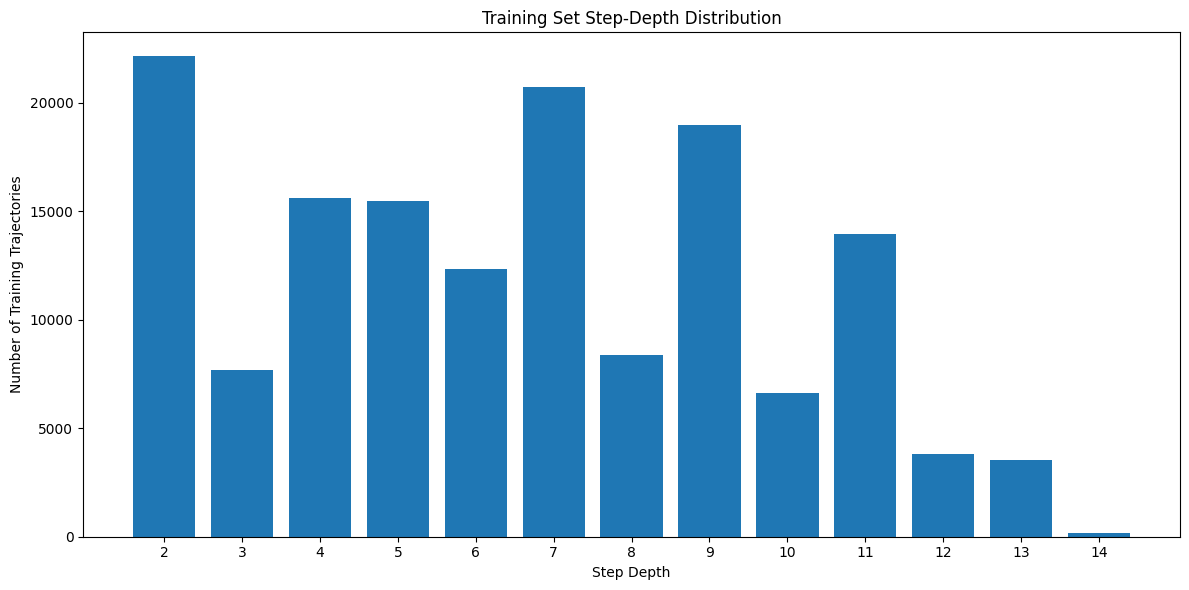

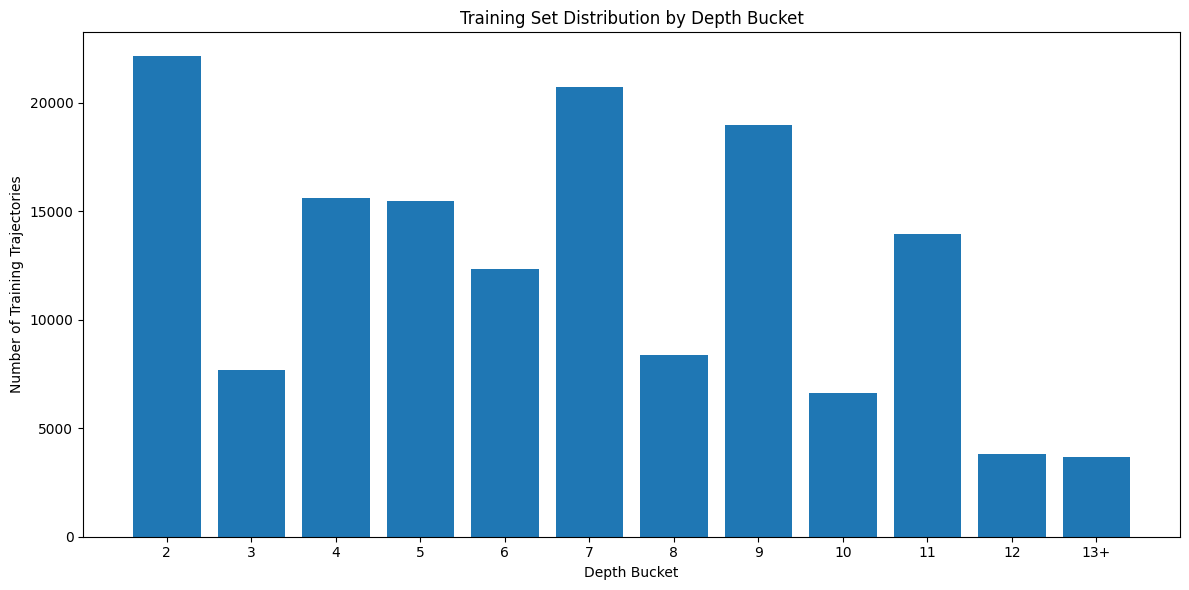

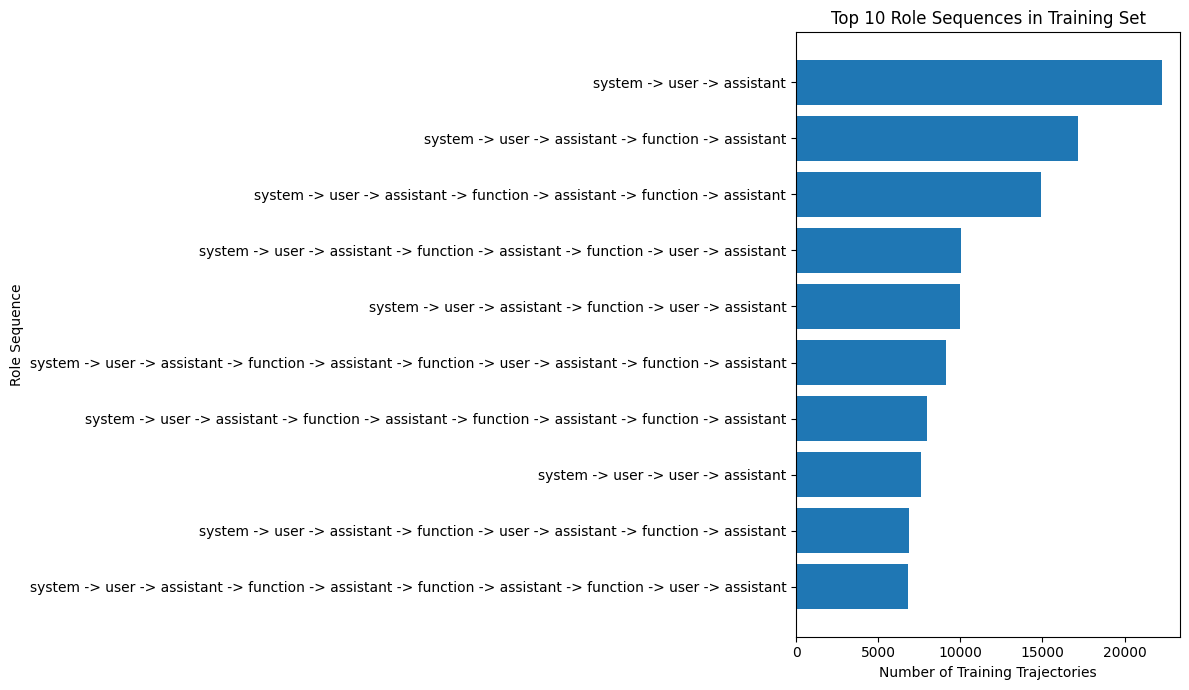


STEP 2 FINAL SUMMARY
Training trajectories analyzed : 149,277
Validation trajectories used    : 0
Train/validation overlap        : 0
Depth range                     : 2-14
Exact depth groups              : 13
Depth buckets                   : 12
Unique role sequences           : 27
Turn-count mismatches           : 0
Depth imbalance ratio           : 145.62x

Saved tables:
✓ /kaggle/working/toolbench_research/results/tables/step2_train_depth_balance.csv
✓ /kaggle/working/toolbench_research/results/tables/step2_train_depth_bucket_balance.csv
✓ /kaggle/working/toolbench_research/results/tables/step2_train_stratification_info.csv
✓ /kaggle/working/toolbench_research/results/tables/step2_train_role_sequence_frequency.csv
✓ /kaggle/working/toolbench_research/results/tables/step2_train_role_statistics.csv

Saved figures:
✓ /kaggle/working/toolbench_research/results/figures/step2_train_depth_distribution.png
✓ /kaggle/working/toolbench_research/results/figures/step2_train_depth_bucket_distr

In [3]:
# ============================================================
# STEP 2 - NEW KAGGLE VERSION
# USE FINAL CLEANED 80% TRAINING SPLIT ONLY
#
# PURPOSE:
# - Load already-cleaned training split from New_backup
# - Validate training data
# - Analyze depth imbalance
# - Analyze trajectory structure
# - Save lightweight Step 2 tables/figures
#
# IMPORTANT:
# - DOES NOT clean raw data
# - DOES NOT combine datasets
# - DOES NOT resplit data
# - DOES NOT touch validation
# ============================================================

import os
import json
import ast
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PATHS
# ============================================================

BACKUP_ROOT = (
    "/kaggle/input/datasets/"
    "anandadevnath/"
    "new-backup/"
    "Master_backup"
)

TRAIN_FILE = os.path.join(
    BACKUP_ROOT,
    "dataset",
    "toolbench_train_80.parquet"
)

VALIDATION_FILE = os.path.join(
    BACKUP_ROOT,
    "dataset",
    "toolbench_validation_20.parquet"
)


WORKING_PATH = (
    "/kaggle/working/toolbench_research"
)

PROCESSED_PATH = os.path.join(
    WORKING_PATH,
    "data",
    "processed"
)

FIGURE_PATH = os.path.join(
    WORKING_PATH,
    "results",
    "figures"
)

TABLE_PATH = os.path.join(
    WORKING_PATH,
    "results",
    "tables"
)


for folder in [
    PROCESSED_PATH,
    FIGURE_PATH,
    TABLE_PATH
]:
    os.makedirs(
        folder,
        exist_ok=True
    )


print("=" * 100)
print("STEP 2 - TRAINING DATA STRUCTURE + IMBALANCE ANALYSIS")
print("=" * 100)


# ============================================================
# 2. VERIFY INPUT FILES
# ============================================================

for name, path in [
    ("Training file", TRAIN_FILE),
    ("Validation file", VALIDATION_FILE),
]:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(
        f"✓ {name}: {path}"
    )


# ============================================================
# 3. LOAD FINAL TRAINING SPLIT
# ============================================================

df_train = pd.read_parquet(
    TRAIN_FILE
)


print("\n" + "=" * 100)
print("TRAINING DATA LOADED")
print("=" * 100)

print(
    f"Rows    : {len(df_train):,}"
)

print(
    f"Columns : {len(df_train.columns)}"
)

print(
    df_train.columns.tolist()
)


# ============================================================
# 4. REQUIRED COLUMNS
# ============================================================

required_columns = [
    "id",
    "conversations",
    "step_depth",
    "depth_bucket",
    "num_turns",
]


missing_columns = [
    column
    for column in required_columns
    if column not in df_train.columns
]


if missing_columns:

    raise KeyError(
        f"Missing required columns: "
        f"{missing_columns}"
    )


print(
    "\n✓ Required columns found."
)


# ============================================================
# 5. TRAINING DATA VALIDATION
# ============================================================

duplicate_ids = int(
    df_train[
        "id"
    ]
    .duplicated()
    .sum()
)


missing_ids = int(
    df_train[
        "id"
    ]
    .isna()
    .sum()
)


missing_conversations = int(
    df_train[
        "conversations"
    ]
    .isna()
    .sum()
)


invalid_depths = int(
    (
        ~df_train[
            "step_depth"
        ]
        .between(
            2,
            14
        )
    )
    .sum()
)


print("\n" + "=" * 100)
print("TRAINING VALIDATION")
print("=" * 100)

print(
    f"Duplicate IDs          : {duplicate_ids}"
)

print(
    f"Missing IDs            : {missing_ids}"
)

print(
    f"Missing conversations  : {missing_conversations}"
)

print(
    f"Depths outside 2-14    : {invalid_depths}"
)


if duplicate_ids != 0:
    raise ValueError(
        "Duplicate IDs detected."
    )


if missing_ids != 0:
    raise ValueError(
        "Missing IDs detected."
    )


if missing_conversations != 0:
    raise ValueError(
        "Missing conversations detected."
    )


if invalid_depths != 0:
    raise ValueError(
        "Invalid step depths detected."
    )


if len(df_train) != 149277:
    raise ValueError(
        f"Expected 149,277 training rows, "
        f"found {len(df_train):,}"
    )


print(
    "✓ Training data validation PASS"
)


# ============================================================
# 6. CHECK VALIDATION REMAINS SEPARATE
# ============================================================

validation_ids = pd.read_parquet(
    VALIDATION_FILE,
    columns=[
        "id"
    ]
)


train_id_set = set(
    df_train[
        "id"
    ]
    .astype(str)
)


validation_id_set = set(
    validation_ids[
        "id"
    ]
    .astype(str)
)


overlap = (
    train_id_set
    &
    validation_id_set
)


print("\n" + "=" * 100)
print("TRAIN / VALIDATION LEAKAGE CHECK")
print("=" * 100)

print(
    f"Validation rows          : "
    f"{len(validation_ids):,}"
)

print(
    f"ID overlap              : "
    f"{len(overlap)}"
)


if len(validation_ids) != 37320:
    raise ValueError(
        "Unexpected validation row count."
    )


if len(overlap) != 0:
    raise ValueError(
        "Train/validation leakage detected."
    )


print(
    "✓ Validation remains untouched and separate."
)


del validation_ids


# ============================================================
# 7. ROBUST CONVERSATION PARSER
# ============================================================

def parse_conversation(conv):

    if conv is None:

        return [], []


    if isinstance(
        conv,
        np.ndarray
    ):

        conv = conv.tolist()


    if isinstance(
        conv,
        dict
    ):

        roles = conv.get(
            "from",
            []
        )

        values = conv.get(
            "value",
            []
        )


        if isinstance(
            roles,
            np.ndarray
        ):
            roles = roles.tolist()


        if isinstance(
            values,
            np.ndarray
        ):
            values = values.tolist()


        return (
            list(roles),
            list(values)
        )


    if isinstance(
        conv,
        list
    ):

        roles = []
        values = []


        for turn in conv:

            if isinstance(
                turn,
                dict
            ):

                roles.append(
                    turn.get(
                        "from",
                        turn.get(
                            "role",
                            "unknown"
                        )
                    )
                )


                values.append(
                    turn.get(
                        "value",
                        turn.get(
                            "content",
                            ""
                        )
                    )
                )


        return (
            roles,
            values
        )


    if isinstance(
        conv,
        str
    ):

        try:

            parsed = json.loads(
                conv
            )

            return parse_conversation(
                parsed
            )

        except Exception:

            try:

                parsed = ast.literal_eval(
                    conv
                )

                return parse_conversation(
                    parsed
                )

            except Exception:

                return [], []


    return [], []


# ============================================================
# 8. PARSER TEST
# ============================================================

test_conv = df_train[
    "conversations"
].iloc[
    0
]


test_roles, test_values = (
    parse_conversation(
        test_conv
    )
)


print("\n" + "=" * 100)
print("CONVERSATION PARSER TEST")
print("=" * 100)

print(
    f"Conversation type : "
    f"{type(test_conv)}"
)

print(
    f"Roles extracted   : "
    f"{len(test_roles)}"
)

print(
    f"Values extracted  : "
    f"{len(test_values)}"
)

print(
    f"First roles       : "
    f"{test_roles[:5]}"
)


if (
    len(test_roles) == 0
    or
    len(test_roles)
    !=
    len(test_values)
):

    raise ValueError(
        "Conversation parser failed."
    )


print(
    "✓ Conversation parser PASS"
)


# ============================================================
# 9. STEP DEPTH DISTRIBUTION
# ============================================================

depth_balance = (
    df_train
    .groupby(
        "step_depth"
    )
    .size()
    .reset_index(
        name="trajectory_count"
    )
    .sort_values(
        "step_depth"
    )
    .reset_index(
        drop=True
    )
)


depth_balance[
    "percentage"
] = (
    depth_balance[
        "trajectory_count"
    ]
    /
    len(df_train)
    *
    100
)


depth_balance[
    "proportion"
] = (
    depth_balance[
        "trajectory_count"
    ]
    /
    len(df_train)
)


print("\n" + "=" * 100)
print("TRAINING STEP-DEPTH DISTRIBUTION")
print("=" * 100)

print(
    depth_balance.to_string(
        index=False,
        formatters={
            "percentage":
                lambda x: f"{x:.4f}",

            "proportion":
                lambda x: f"{x:.6f}"
        }
    )
)


# ============================================================
# 10. IMBALANCE SUMMARY
# ============================================================

largest_group = (
    depth_balance.loc[
        depth_balance[
            "trajectory_count"
        ].idxmax()
    ]
)


smallest_group = (
    depth_balance.loc[
        depth_balance[
            "trajectory_count"
        ].idxmin()
    ]
)


imbalance_ratio = (
    largest_group[
        "trajectory_count"
    ]
    /
    smallest_group[
        "trajectory_count"
    ]
)


print("\n" + "=" * 100)
print("STEP-DEPTH IMBALANCE SUMMARY")
print("=" * 100)

print(
    f"Largest depth group  : "
    f"Step {int(largest_group['step_depth'])}"
)

print(
    f"Largest count        : "
    f"{int(largest_group['trajectory_count']):,}"
)

print(
    f"Smallest depth group : "
    f"Step {int(smallest_group['step_depth'])}"
)

print(
    f"Smallest count       : "
    f"{int(smallest_group['trajectory_count']):,}"
)

print(
    f"Imbalance ratio      : "
    f"{imbalance_ratio:.2f}x"
)


# ============================================================
# 11. DEPTH BUCKET DISTRIBUTION
# ============================================================

bucket_order = [
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9",
    "10",
    "11",
    "12",
    "13+"
]


bucket_balance = (
    df_train[
        "depth_bucket"
    ]
    .astype(str)
    .value_counts()
    .reindex(
        bucket_order,
        fill_value=0
    )
    .rename_axis(
        "depth_bucket"
    )
    .reset_index(
        name="trajectory_count"
    )
)


bucket_balance[
    "percentage"
] = (
    bucket_balance[
        "trajectory_count"
    ]
    /
    len(df_train)
    *
    100
)


bucket_balance[
    "proportion"
] = (
    bucket_balance[
        "trajectory_count"
    ]
    /
    len(df_train)
)


print("\n" + "=" * 100)
print("TRAINING DEPTH-BUCKET DISTRIBUTION")
print("=" * 100)

print(
    bucket_balance.to_string(
        index=False,
        formatters={
            "percentage":
                lambda x: f"{x:.4f}",

            "proportion":
                lambda x: f"{x:.6f}"
        }
    )
)


# ============================================================
# 12. CREATE STRUCTURAL FEATURES
# ============================================================

def get_roles(conv):

    roles, _ = (
        parse_conversation(
            conv
        )
    )

    return [
        str(role)
        .strip()
        .lower()
        for role in roles
    ]


df_structure = df_train[
    [
        "id",
        "step_depth",
        "depth_bucket",
        "num_turns",
        "conversations"
    ]
].copy()


df_structure[
    "parsed_roles"
] = (
    df_structure[
        "conversations"
    ]
    .apply(
        get_roles
    )
)


df_structure[
    "parsed_num_turns"
] = (
    df_structure[
        "parsed_roles"
    ]
    .apply(
        len
    )
)


df_structure[
    "role_sequence_string"
] = (
    df_structure[
        "parsed_roles"
    ]
    .apply(
        lambda roles:
            " -> ".join(
                roles
            )
    )
)


# ============================================================
# 13. TURN COUNT VALIDATION
# ============================================================

turn_mismatch = int(
    (
        df_structure[
            "parsed_num_turns"
        ]
        !=
        df_structure[
            "num_turns"
        ]
    )
    .sum()
)


print("\n" + "=" * 100)
print("STRUCTURAL VALIDATION")
print("=" * 100)

print(
    f"Rows checked          : "
    f"{len(df_structure):,}"
)

print(
    f"Turn-count mismatches : "
    f"{turn_mismatch:,}"
)


if turn_mismatch != 0:

    raise ValueError(
        "Parsed turn counts do not match stored num_turns."
    )


print(
    "✓ All turn counts match."
)


# ============================================================
# 14. ROLE SEQUENCE FREQUENCY
# ============================================================

sequence_frequency = (
    df_structure[
        "role_sequence_string"
    ]
    .value_counts()
    .reset_index()
)


sequence_frequency.columns = [
    "role_sequence",
    "trajectory_count"
]


sequence_frequency[
    "percentage"
] = (
    sequence_frequency[
        "trajectory_count"
    ]
    /
    len(df_structure)
    *
    100
)


print("\n" + "=" * 100)
print("TOP 10 ROLE-SEQUENCE PATTERNS")
print("=" * 100)

print(
    sequence_frequency
    .head(
        10
    )
    .to_string(
        index=False,
        formatters={
            "percentage":
                lambda x: f"{x:.4f}"
        }
    )
)


# ============================================================
# 15. ROLE COUNTS
# ============================================================

role_counter = Counter()


for roles in df_structure[
    "parsed_roles"
]:

    role_counter.update(
        roles
    )


role_stats = pd.DataFrame(
    role_counter.items(),
    columns=[
        "role",
        "total_turns"
    ]
).sort_values(
    "total_turns",
    ascending=False
)


role_stats[
    "average_per_trajectory"
] = (
    role_stats[
        "total_turns"
    ]
    /
    len(df_structure)
)


print("\n" + "=" * 100)
print("ROLE STATISTICS")
print("=" * 100)

print(
    role_stats.to_string(
        index=False,
        formatters={
            "average_per_trajectory":
                lambda x: f"{x:.4f}"
        }
    )
)


# ============================================================
# 16. STRATIFICATION INFORMATION
# ============================================================

stratification_table = (
    bucket_balance.copy()
)


stratification_table[
    "available_for_sampling"
] = (
    stratification_table[
        "trajectory_count"
    ]
)


print("\n" + "=" * 100)
print("STRATIFICATION INFORMATION")
print("=" * 100)

print(
    stratification_table.to_string(
        index=False,
        formatters={
            "percentage":
                lambda x: f"{x:.4f}",

            "proportion":
                lambda x: f"{x:.6f}"
        }
    )
)


# ============================================================
# 17. VISUALIZATION 1 - EXACT DEPTH
# ============================================================

plt.figure(
    figsize=(
        12,
        6
    )
)


plt.bar(
    depth_balance[
        "step_depth"
    ].astype(str),
    depth_balance[
        "trajectory_count"
    ]
)


plt.xlabel(
    "Step Depth"
)

plt.ylabel(
    "Number of Training Trajectories"
)

plt.title(
    "Training Set Step-Depth Distribution"
)

plt.tight_layout()


DEPTH_FIGURE = os.path.join(
    FIGURE_PATH,
    "step2_train_depth_distribution.png"
)


plt.savefig(
    DEPTH_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. VISUALIZATION 2 - DEPTH BUCKETS
# ============================================================

plt.figure(
    figsize=(
        12,
        6
    )
)


plt.bar(
    bucket_balance[
        "depth_bucket"
    ],
    bucket_balance[
        "trajectory_count"
    ]
)


plt.xlabel(
    "Depth Bucket"
)

plt.ylabel(
    "Number of Training Trajectories"
)

plt.title(
    "Training Set Distribution by Depth Bucket"
)

plt.tight_layout()


BUCKET_FIGURE = os.path.join(
    FIGURE_PATH,
    "step2_train_depth_bucket_distribution.png"
)


plt.savefig(
    BUCKET_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. VISUALIZATION 3 - TOP ROLE SEQUENCES
# ============================================================

top_sequences = (
    sequence_frequency
    .head(
        10
    )
    .copy()
)


plt.figure(
    figsize=(
        12,
        7
    )
)


plt.barh(
    top_sequences[
        "role_sequence"
    ],
    top_sequences[
        "trajectory_count"
    ]
)


plt.xlabel(
    "Number of Training Trajectories"
)

plt.ylabel(
    "Role Sequence"
)

plt.title(
    "Top 10 Role Sequences in Training Set"
)

plt.gca().invert_yaxis()

plt.tight_layout()


ROLE_FIGURE = os.path.join(
    FIGURE_PATH,
    "step2_train_top_role_sequences.png"
)


plt.savefig(
    ROLE_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 20. SAVE TABLES
# ============================================================

DEPTH_BALANCE_FILE = os.path.join(
    TABLE_PATH,
    "step2_train_depth_balance.csv"
)

BUCKET_BALANCE_FILE = os.path.join(
    TABLE_PATH,
    "step2_train_depth_bucket_balance.csv"
)

STRATIFICATION_FILE = os.path.join(
    TABLE_PATH,
    "step2_train_stratification_info.csv"
)

ROLE_SEQUENCE_FILE = os.path.join(
    TABLE_PATH,
    "step2_train_role_sequence_frequency.csv"
)

ROLE_STATS_FILE = os.path.join(
    TABLE_PATH,
    "step2_train_role_statistics.csv"
)


depth_balance.to_csv(
    DEPTH_BALANCE_FILE,
    index=False
)


bucket_balance.to_csv(
    BUCKET_BALANCE_FILE,
    index=False
)


stratification_table.to_csv(
    STRATIFICATION_FILE,
    index=False
)


sequence_frequency.to_csv(
    ROLE_SEQUENCE_FILE,
    index=False
)


role_stats.to_csv(
    ROLE_STATS_FILE,
    index=False
)


# ============================================================
# 21. FINAL VALIDATION
# ============================================================

if int(
    depth_balance[
        "trajectory_count"
    ].sum()
) != len(df_train):

    raise ValueError(
        "Depth counts do not sum to training size."
    )


if int(
    bucket_balance[
        "trajectory_count"
    ].sum()
) != len(df_train):

    raise ValueError(
        "Bucket counts do not sum to training size."
    )


print("\n" + "=" * 100)
print("STEP 2 FINAL SUMMARY")
print("=" * 100)

print(
    f"Training trajectories analyzed : "
    f"{len(df_train):,}"
)

print(
    f"Validation trajectories used    : "
    f"0"
)

print(
    f"Train/validation overlap        : "
    f"{len(overlap)}"
)

print(
    f"Depth range                     : "
    f"{df_train['step_depth'].min()}-"
    f"{df_train['step_depth'].max()}"
)

print(
    f"Exact depth groups              : "
    f"{df_train['step_depth'].nunique()}"
)

print(
    f"Depth buckets                   : "
    f"{df_train['depth_bucket'].nunique()}"
)

print(
    f"Unique role sequences           : "
    f"{len(sequence_frequency):,}"
)

print(
    f"Turn-count mismatches           : "
    f"{turn_mismatch}"
)

print(
    f"Depth imbalance ratio           : "
    f"{imbalance_ratio:.2f}x"
)


print("\nSaved tables:")

for path in [
    DEPTH_BALANCE_FILE,
    BUCKET_BALANCE_FILE,
    STRATIFICATION_FILE,
    ROLE_SEQUENCE_FILE,
    ROLE_STATS_FILE
]:

    print(
        "✓",
        path
    )


print("\nSaved figures:")

for path in [
    DEPTH_FIGURE,
    BUCKET_FIGURE,
    ROLE_FIGURE
]:

    print(
        "✓",
        path
    )


print("\n✓ STEP 2 COMPLETED SUCCESSFULLY")
print("✓ Uses only final 80% training split")
print("✓ Validation 20% untouched")
print("✓ No cleaning performed")
print("✓ No resplitting performed")
print("✓ No dataset overwritten")
print("=" * 100)

STEP 3 - FEATURE DATASET LOADING + VERIFICATION
✓ Training feature file: /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/featured/toolbench_train_80_features.parquet
✓ Validation feature file: /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/featured/toolbench_validation_20_features.parquet
✓ Training raw file: /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/dataset/toolbench_train_80.parquet
✓ Validation raw file: /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/dataset/toolbench_validation_20.parquet

FEATURE DATASETS LOADED
Training rows       : 149,277
Validation rows     : 37,320
Training columns    : 27
Validation columns  : 27

✓ Feature row counts PASS
✓ Required Step 3 columns PASS
✓ Training/validation feature schema match PASS

ID VALIDATION
Training duplicate IDs    : 0
Validation duplicate IDs  : 0
Training missing IDs      : 0
Validation missing IDs    : 0
✓ ID validation PASS

TRAIN / VALIDATION LEAKAGE CHECK
ID overl

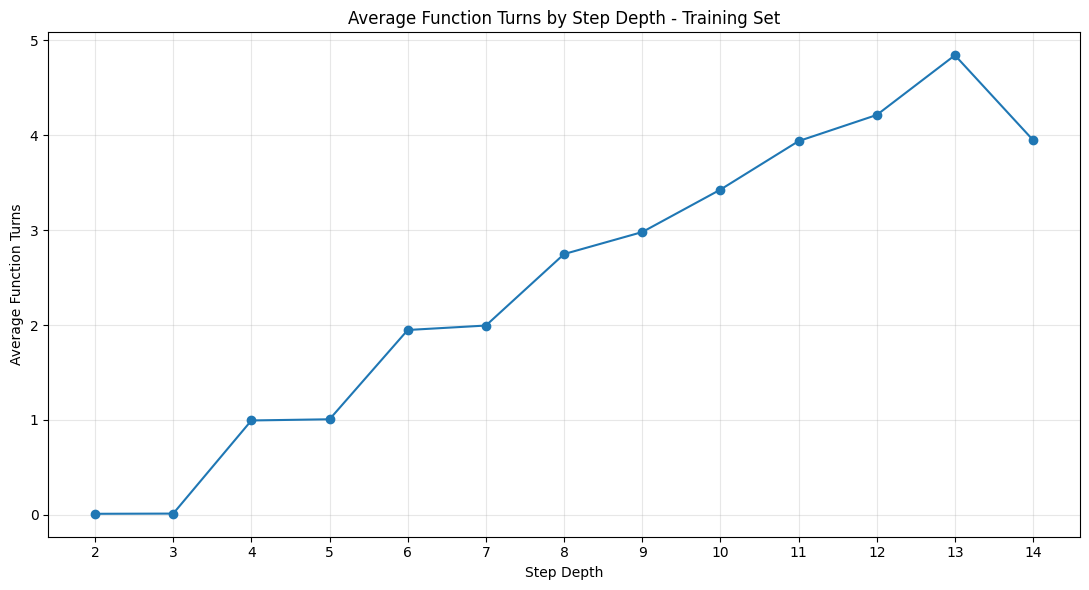

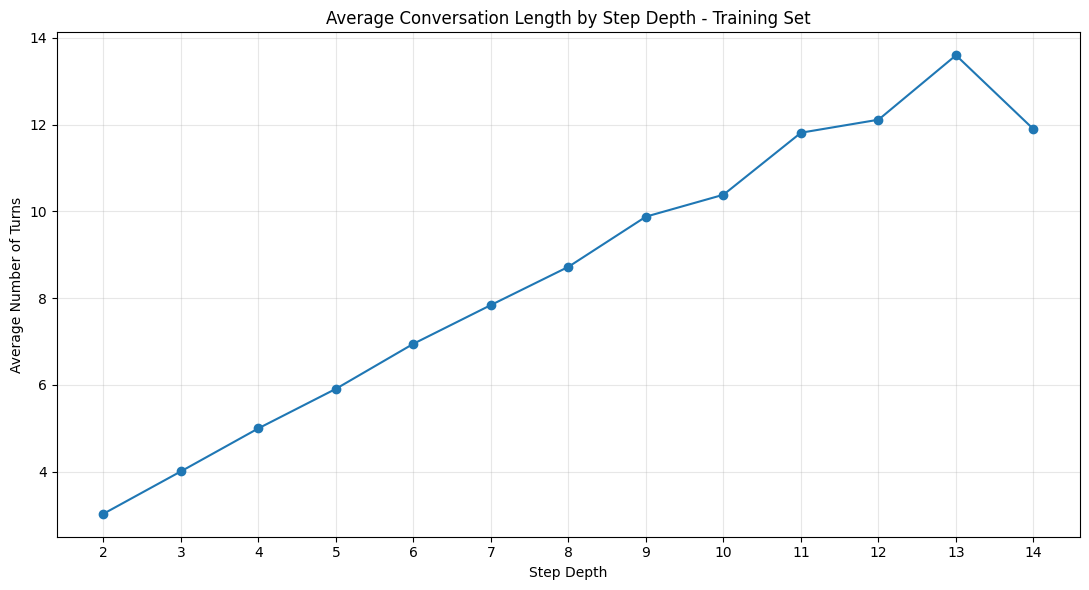

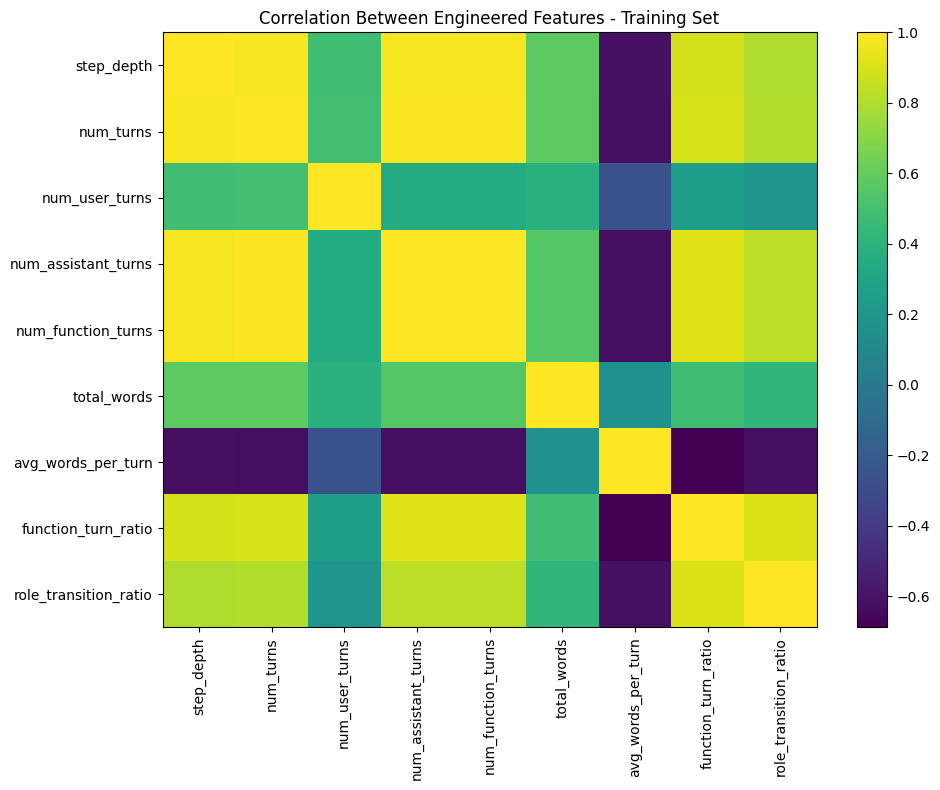


STEP 3 FINAL SUMMARY
Training feature rows        : 149,277
Validation feature rows      : 37,320
Total represented rows       : 186,597
Feature dataset columns      : 27
Engineered feature fields    : 23
Training missing values      : 0
Validation missing values    : 0
Training infinite values     : 0
Validation infinite values   : 0
Train/validation ID overlap  : 0
Training depth range         : 2-14
Validation depth range       : 2-14

FEATURE FILES USED:
✓ /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/featured/toolbench_train_80_features.parquet
✓ /kaggle/input/datasets/anandadevnath/new-backup/Master_backup/featured/toolbench_validation_20_features.parquet

SAVED TABLES:
✓ /kaggle/working/toolbench_research/results/tables/step3_train_features_by_depth.csv
✓ /kaggle/working/toolbench_research/results/tables/step3_validation_features_by_depth.csv
✓ /kaggle/working/toolbench_research/results/tables/step3_train_feature_summary.csv
✓ /kaggle/working/toolbench_research/

In [4]:
# ============================================================
# STEP 3 - NEW KAGGLE VERSION
# LOAD + VERIFY EXISTING FEATURE DATASETS FROM NEW_BACKUP
#
# IMPORTANT:
# - DOES NOT recompute features
# - DOES NOT overwrite backup files
# - DOES NOT fit scaler / PCA / TF-IDF / model
# - Keeps training and validation separate
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PATHS
# ============================================================

MASTER_ROOT = (
    "/kaggle/input/datasets/"
    "anandadevnath/"
    "new-backup/"
    "Master_backup"
)

TRAIN_FEATURE_FILE = os.path.join(
    MASTER_ROOT,
    "featured",
    "toolbench_train_80_features.parquet"
)

VALIDATION_FEATURE_FILE = os.path.join(
    MASTER_ROOT,
    "featured",
    "toolbench_validation_20_features.parquet"
)

TRAIN_RAW_FILE = os.path.join(
    MASTER_ROOT,
    "dataset",
    "toolbench_train_80.parquet"
)

VALIDATION_RAW_FILE = os.path.join(
    MASTER_ROOT,
    "dataset",
    "toolbench_validation_20.parquet"
)

WORKING_ROOT = (
    "/kaggle/working/toolbench_research"
)

TABLE_PATH = os.path.join(
    WORKING_ROOT,
    "results",
    "tables"
)

FIGURE_PATH = os.path.join(
    WORKING_ROOT,
    "results",
    "figures"
)

os.makedirs(
    TABLE_PATH,
    exist_ok=True
)

os.makedirs(
    FIGURE_PATH,
    exist_ok=True
)


print("=" * 100)
print("STEP 3 - FEATURE DATASET LOADING + VERIFICATION")
print("=" * 100)


# ============================================================
# 2. VERIFY REQUIRED FILES
# ============================================================

required_files = {
    "Training feature file":
        TRAIN_FEATURE_FILE,

    "Validation feature file":
        VALIDATION_FEATURE_FILE,

    "Training raw file":
        TRAIN_RAW_FILE,

    "Validation raw file":
        VALIDATION_RAW_FILE,
}


for name, path in required_files.items():

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(
        f"✓ {name}: {path}"
    )


# ============================================================
# 3. LOAD FEATURE DATASETS
# ============================================================

train_features = pd.read_parquet(
    TRAIN_FEATURE_FILE
)

validation_features = pd.read_parquet(
    VALIDATION_FEATURE_FILE
)


print("\n" + "=" * 100)
print("FEATURE DATASETS LOADED")
print("=" * 100)

print(
    f"Training rows       : "
    f"{len(train_features):,}"
)

print(
    f"Validation rows     : "
    f"{len(validation_features):,}"
)

print(
    f"Training columns    : "
    f"{len(train_features.columns)}"
)

print(
    f"Validation columns  : "
    f"{len(validation_features.columns)}"
)


# ============================================================
# 4. EXPECTED ROW COUNTS
# ============================================================

if len(train_features) != 149277:

    raise ValueError(
        f"Expected 149,277 training feature rows, "
        f"found {len(train_features):,}"
    )


if len(validation_features) != 37320:

    raise ValueError(
        f"Expected 37,320 validation feature rows, "
        f"found {len(validation_features):,}"
    )


print(
    "\n✓ Feature row counts PASS"
)


# ============================================================
# 5. VERIFY REQUIRED COLUMNS
# ============================================================

required_columns = [
    "id",
    "original_split",
    "research_split",
    "step_depth",
    "depth_bucket",
    "num_turns",
    "num_system_turns",
    "num_user_turns",
    "num_assistant_turns",
    "num_function_turns",
    "has_function_call",
    "total_characters",
    "user_characters",
    "assistant_characters",
    "function_characters",
    "total_words",
    "assistant_words",
    "avg_chars_per_turn",
    "avg_words_per_turn",
    "function_turn_ratio",
    "assistant_turn_ratio",
    "user_turn_ratio",
    "role_transitions",
    "repeated_role_transitions",
    "role_transition_ratio",
    "first_function_position",
    "last_function_position",
]


for dataset_name, dataset in [
    ("Training", train_features),
    ("Validation", validation_features),
]:

    missing_columns = [
        column
        for column in required_columns
        if column not in dataset.columns
    ]

    if missing_columns:

        raise KeyError(
            f"{dataset_name} feature dataset "
            f"is missing columns:\n"
            f"{missing_columns}"
        )


print(
    "✓ Required Step 3 columns PASS"
)


# ============================================================
# 6. FEATURE SCHEMA MATCH
# ============================================================

if list(
    train_features.columns
) != list(
    validation_features.columns
):

    raise ValueError(
        "Training and validation feature "
        "schemas do not match exactly."
    )


print(
    "✓ Training/validation feature schema match PASS"
)


# ============================================================
# 7. DUPLICATE / MISSING ID CHECK
# ============================================================

train_duplicate_ids = int(
    train_features[
        "id"
    ]
    .duplicated()
    .sum()
)

validation_duplicate_ids = int(
    validation_features[
        "id"
    ]
    .duplicated()
    .sum()
)

train_missing_ids = int(
    train_features[
        "id"
    ]
    .isna()
    .sum()
)

validation_missing_ids = int(
    validation_features[
        "id"
    ]
    .isna()
    .sum()
)


print("\n" + "=" * 100)
print("ID VALIDATION")
print("=" * 100)

print(
    f"Training duplicate IDs    : "
    f"{train_duplicate_ids}"
)

print(
    f"Validation duplicate IDs  : "
    f"{validation_duplicate_ids}"
)

print(
    f"Training missing IDs      : "
    f"{train_missing_ids}"
)

print(
    f"Validation missing IDs    : "
    f"{validation_missing_ids}"
)


if train_duplicate_ids != 0:

    raise ValueError(
        "Duplicate IDs found in training features."
    )


if validation_duplicate_ids != 0:

    raise ValueError(
        "Duplicate IDs found in validation features."
    )


if train_missing_ids != 0:

    raise ValueError(
        "Missing IDs found in training features."
    )


if validation_missing_ids != 0:

    raise ValueError(
        "Missing IDs found in validation features."
    )


print(
    "✓ ID validation PASS"
)


# ============================================================
# 8. TRAIN / VALIDATION LEAKAGE CHECK
# ============================================================

train_ids = set(
    train_features[
        "id"
    ]
    .astype(str)
)

validation_ids = set(
    validation_features[
        "id"
    ]
    .astype(str)
)

overlap_ids = (
    train_ids
    &
    validation_ids
)


print("\n" + "=" * 100)
print("TRAIN / VALIDATION LEAKAGE CHECK")
print("=" * 100)

print(
    f"ID overlap : "
    f"{len(overlap_ids)}"
)


if len(overlap_ids) != 0:

    raise ValueError(
        "DATA LEAKAGE detected."
    )


print(
    "✓ No train/validation ID leakage"
)


# ============================================================
# 9. VERIFY FEATURE IDS MATCH RAW SPLITS
# ============================================================

train_raw_ids = set(
    pd.read_parquet(
        TRAIN_RAW_FILE,
        columns=[
            "id"
        ]
    )[
        "id"
    ]
    .astype(str)
)

validation_raw_ids = set(
    pd.read_parquet(
        VALIDATION_RAW_FILE,
        columns=[
            "id"
        ]
    )[
        "id"
    ]
    .astype(str)
)


if train_ids != train_raw_ids:

    raise ValueError(
        "Training feature IDs do not match "
        "training dataset IDs."
    )


if validation_ids != validation_raw_ids:

    raise ValueError(
        "Validation feature IDs do not match "
        "validation dataset IDs."
    )


print(
    "✓ Feature IDs match original 80/20 splits"
)


# ============================================================
# 10. DEPTH VALIDATION
# ============================================================

train_invalid_depth = int(
    (
        ~train_features[
            "step_depth"
        ]
        .between(
            2,
            14
        )
    )
    .sum()
)

validation_invalid_depth = int(
    (
        ~validation_features[
            "step_depth"
        ]
        .between(
            2,
            14
        )
    )
    .sum()
)


print("\n" + "=" * 100)
print("DEPTH VALIDATION")
print("=" * 100)

print(
    f"Training invalid depths   : "
    f"{train_invalid_depth}"
)

print(
    f"Validation invalid depths : "
    f"{validation_invalid_depth}"
)


if train_invalid_depth != 0:

    raise ValueError(
        "Training feature dataset "
        "contains invalid depth."
    )


if validation_invalid_depth != 0:

    raise ValueError(
        "Validation feature dataset "
        "contains invalid depth."
    )


print(
    "✓ Depth validation PASS"
)


# ============================================================
# 11. DEFINE ENGINEERED FEATURE COLUMNS
# ============================================================

feature_columns = [
    "step_depth",
    "num_turns",
    "num_system_turns",
    "num_user_turns",
    "num_assistant_turns",
    "num_function_turns",
    "has_function_call",
    "total_characters",
    "user_characters",
    "assistant_characters",
    "function_characters",
    "total_words",
    "assistant_words",
    "avg_chars_per_turn",
    "avg_words_per_turn",
    "function_turn_ratio",
    "assistant_turn_ratio",
    "user_turn_ratio",
    "role_transitions",
    "repeated_role_transitions",
    "role_transition_ratio",
    "first_function_position",
    "last_function_position",
]


print("\n" + "=" * 100)
print("ENGINEERED FEATURE LIST")
print("=" * 100)


for number, feature in enumerate(
    feature_columns,
    start=1
):

    print(
        f"{number:02d}. {feature}"
    )


print(
    f"\nTotal engineered features : "
    f"{len(feature_columns)}"
)


# ============================================================
# 12. MISSING VALUE CHECK
# ============================================================

train_missing = (
    train_features[
        feature_columns
    ]
    .isna()
    .sum()
)

validation_missing = (
    validation_features[
        feature_columns
    ]
    .isna()
    .sum()
)

train_missing_total = int(
    train_missing.sum()
)

validation_missing_total = int(
    validation_missing.sum()
)


print("\n" + "=" * 100)
print("MISSING VALUE CHECK")
print("=" * 100)

print(
    f"Training missing feature values   : "
    f"{train_missing_total:,}"
)

print(
    f"Validation missing feature values : "
    f"{validation_missing_total:,}"
)


if train_missing_total != 0:

    print(
        "\nTraining missing values:"
    )

    print(
        train_missing[
            train_missing > 0
        ]
    )

    raise ValueError(
        "Training feature dataset contains "
        "missing values."
    )


if validation_missing_total != 0:

    print(
        "\nValidation missing values:"
    )

    print(
        validation_missing[
            validation_missing > 0
        ]
    )

    raise ValueError(
        "Validation feature dataset contains "
        "missing values."
    )


print(
    "✓ Missing value check PASS"
)


# ============================================================
# 13. INFINITE VALUE CHECK
# ============================================================

numeric_features = [
    column
    for column in feature_columns
    if pd.api.types.is_numeric_dtype(
        train_features[
            column
        ]
    )
]


train_infinite = int(
    np.isinf(
        train_features[
            numeric_features
        ]
        .to_numpy(
            dtype=float
        )
    )
    .sum()
)

validation_infinite = int(
    np.isinf(
        validation_features[
            numeric_features
        ]
        .to_numpy(
            dtype=float
        )
    )
    .sum()
)


print("\n" + "=" * 100)
print("INFINITE VALUE CHECK")
print("=" * 100)

print(
    f"Training infinite values   : "
    f"{train_infinite:,}"
)

print(
    f"Validation infinite values : "
    f"{validation_infinite:,}"
)


if train_infinite != 0:

    raise ValueError(
        "Training feature dataset "
        "contains infinite values."
    )


if validation_infinite != 0:

    raise ValueError(
        "Validation feature dataset "
        "contains infinite values."
    )


print(
    "✓ Infinite value check PASS"
)


# ============================================================
# 14. RESEARCH SPLIT CHECK
# ============================================================

print("\n" + "=" * 100)
print("RESEARCH SPLIT CHECK")
print("=" * 100)

print(
    "Training values:"
)

print(
    train_features[
        "research_split"
    ]
    .value_counts(
        dropna=False
    )
)


print(
    "\nValidation values:"
)

print(
    validation_features[
        "research_split"
    ]
    .value_counts(
        dropna=False
    )
)


# ============================================================
# 15. TOOL USAGE SUMMARY
# ============================================================

def tool_usage_summary(
    dataset,
    name
):

    summary = (
        dataset[
            "has_function_call"
        ]
        .value_counts()
        .rename_axis(
            "has_function_call"
        )
        .reset_index(
            name="trajectory_count"
        )
    )

    summary[
        "percentage"
    ] = (
        summary[
            "trajectory_count"
        ]
        /
        len(dataset)
        *
        100
    )

    summary[
        "dataset"
    ] = name

    return summary


train_tool_usage = (
    tool_usage_summary(
        train_features,
        "train"
    )
)

validation_tool_usage = (
    tool_usage_summary(
        validation_features,
        "validation"
    )
)


print("\n" + "=" * 100)
print("TRAINING TOOL USAGE")
print("=" * 100)

print(
    train_tool_usage.to_string(
        index=False,
        formatters={
            "percentage":
                lambda x: f"{x:.4f}"
        }
    )
)


print("\n" + "=" * 100)
print("VALIDATION TOOL USAGE")
print("=" * 100)

print(
    validation_tool_usage.to_string(
        index=False,
        formatters={
            "percentage":
                lambda x: f"{x:.4f}"
        }
    )
)


# ============================================================
# 16. FEATURE SUMMARY STATISTICS
# ============================================================

summary_features = [
    "step_depth",
    "num_turns",
    "num_user_turns",
    "num_assistant_turns",
    "num_function_turns",
    "total_words",
    "avg_words_per_turn",
    "function_turn_ratio",
    "role_transition_ratio",
]


train_summary = (
    train_features[
        summary_features
    ]
    .describe()
    .round(
        4
    )
)

validation_summary = (
    validation_features[
        summary_features
    ]
    .describe()
    .round(
        4
    )
)


print("\n" + "=" * 100)
print("TRAINING FEATURE SUMMARY")
print("=" * 100)

print(
    train_summary.to_string()
)


print("\n" + "=" * 100)
print("VALIDATION FEATURE SUMMARY")
print("=" * 100)

print(
    validation_summary.to_string()
)


# ============================================================
# 17. FEATURES BY DEPTH
# ============================================================

train_by_depth = (
    train_features
    .groupby(
        "step_depth"
    )
    .agg(
        trajectories=(
            "id",
            "count"
        ),

        avg_turns=(
            "num_turns",
            "mean"
        ),

        avg_function_turns=(
            "num_function_turns",
            "mean"
        ),

        avg_total_words=(
            "total_words",
            "mean"
        ),

        avg_function_ratio=(
            "function_turn_ratio",
            "mean"
        ),

        avg_role_transition_ratio=(
            "role_transition_ratio",
            "mean"
        )
    )
    .reset_index()
)


validation_by_depth = (
    validation_features
    .groupby(
        "step_depth"
    )
    .agg(
        trajectories=(
            "id",
            "count"
        ),

        avg_turns=(
            "num_turns",
            "mean"
        ),

        avg_function_turns=(
            "num_function_turns",
            "mean"
        ),

        avg_total_words=(
            "total_words",
            "mean"
        ),

        avg_function_ratio=(
            "function_turn_ratio",
            "mean"
        ),

        avg_role_transition_ratio=(
            "role_transition_ratio",
            "mean"
        )
    )
    .reset_index()
)


print("\n" + "=" * 100)
print("TRAINING FEATURES BY DEPTH")
print("=" * 100)

print(
    train_by_depth
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ============================================================
# 18. TRAIN VS VALIDATION COMPARISON
# ============================================================

comparison_rows = []


for feature in summary_features:

    comparison_rows.append(
        {
            "feature":
                feature,

            "train_mean":
                train_features[
                    feature
                ].mean(),

            "validation_mean":
                validation_features[
                    feature
                ].mean(),

            "train_std":
                train_features[
                    feature
                ].std(),

            "validation_std":
                validation_features[
                    feature
                ].std(),
        }
    )


train_validation_comparison = (
    pd.DataFrame(
        comparison_rows
    )
)


train_validation_comparison[
    "absolute_mean_difference"
] = (
    train_validation_comparison[
        "train_mean"
    ]
    -
    train_validation_comparison[
        "validation_mean"
    ]
).abs()


print("\n" + "=" * 100)
print("TRAIN VS VALIDATION FEATURE COMPARISON")
print("=" * 100)

print(
    train_validation_comparison
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ============================================================
# 19. CORRELATION MATRIX
# ============================================================

correlation_features = [
    "step_depth",
    "num_turns",
    "num_user_turns",
    "num_assistant_turns",
    "num_function_turns",
    "total_words",
    "avg_words_per_turn",
    "function_turn_ratio",
    "role_transition_ratio",
]


correlation_matrix = (
    train_features[
        correlation_features
    ]
    .corr()
)


# ============================================================
# 20. VISUALIZATION 1
# AVERAGE FUNCTION TURNS BY DEPTH
# ============================================================

plt.figure(
    figsize=(
        11,
        6
    )
)

plt.plot(
    train_by_depth[
        "step_depth"
    ],
    train_by_depth[
        "avg_function_turns"
    ],
    marker="o"
)

plt.xlabel(
    "Step Depth"
)

plt.ylabel(
    "Average Function Turns"
)

plt.title(
    "Average Function Turns by Step Depth - Training Set"
)

plt.xticks(
    train_by_depth[
        "step_depth"
    ]
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()


AVG_FUNCTION_FIGURE = os.path.join(
    FIGURE_PATH,
    "step3_train_avg_function_turns_by_depth.png"
)


plt.savefig(
    AVG_FUNCTION_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. VISUALIZATION 2
# AVERAGE TURNS BY DEPTH
# ============================================================

plt.figure(
    figsize=(
        11,
        6
    )
)

plt.plot(
    train_by_depth[
        "step_depth"
    ],
    train_by_depth[
        "avg_turns"
    ],
    marker="o"
)

plt.xlabel(
    "Step Depth"
)

plt.ylabel(
    "Average Number of Turns"
)

plt.title(
    "Average Conversation Length by Step Depth - Training Set"
)

plt.xticks(
    train_by_depth[
        "step_depth"
    ]
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()


AVG_TURNS_FIGURE = os.path.join(
    FIGURE_PATH,
    "step3_train_avg_turns_by_depth.png"
)


plt.savefig(
    AVG_TURNS_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. VISUALIZATION 3
# FEATURE CORRELATION
# ============================================================

plt.figure(
    figsize=(
        10,
        8
    )
)

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(
        len(
            correlation_features
        )
    ),
    correlation_features,
    rotation=90
)

plt.yticks(
    range(
        len(
            correlation_features
        )
    ),
    correlation_features
)

plt.title(
    "Correlation Between Engineered Features - Training Set"
)

plt.tight_layout()


CORRELATION_FIGURE = os.path.join(
    FIGURE_PATH,
    "step3_train_feature_correlation.png"
)


plt.savefig(
    CORRELATION_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 23. SAVE TABLES
# ============================================================

TRAIN_DEPTH_FILE = os.path.join(
    TABLE_PATH,
    "step3_train_features_by_depth.csv"
)

VALIDATION_DEPTH_FILE = os.path.join(
    TABLE_PATH,
    "step3_validation_features_by_depth.csv"
)

TRAIN_SUMMARY_FILE = os.path.join(
    TABLE_PATH,
    "step3_train_feature_summary.csv"
)

VALIDATION_SUMMARY_FILE = os.path.join(
    TABLE_PATH,
    "step3_validation_feature_summary.csv"
)

TOOL_USAGE_FILE = os.path.join(
    TABLE_PATH,
    "step3_train_validation_tool_usage.csv"
)

COMPARISON_FILE = os.path.join(
    TABLE_PATH,
    "step3_train_validation_feature_comparison.csv"
)

CORRELATION_FILE = os.path.join(
    TABLE_PATH,
    "step3_train_feature_correlation.csv"
)


train_by_depth.to_csv(
    TRAIN_DEPTH_FILE,
    index=False
)

validation_by_depth.to_csv(
    VALIDATION_DEPTH_FILE,
    index=False
)

train_summary.to_csv(
    TRAIN_SUMMARY_FILE
)

validation_summary.to_csv(
    VALIDATION_SUMMARY_FILE
)

pd.concat(
    [
        train_tool_usage,
        validation_tool_usage
    ],
    ignore_index=True
).to_csv(
    TOOL_USAGE_FILE,
    index=False
)

train_validation_comparison.to_csv(
    COMPARISON_FILE,
    index=False
)

correlation_matrix.to_csv(
    CORRELATION_FILE
)


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("STEP 3 FINAL SUMMARY")
print("=" * 100)

print(
    f"Training feature rows        : "
    f"{len(train_features):,}"
)

print(
    f"Validation feature rows      : "
    f"{len(validation_features):,}"
)

print(
    f"Total represented rows       : "
    f"{len(train_features) + len(validation_features):,}"
)

print(
    f"Feature dataset columns      : "
    f"{train_features.shape[1]}"
)

print(
    f"Engineered feature fields    : "
    f"{len(feature_columns)}"
)

print(
    f"Training missing values      : "
    f"{train_missing_total}"
)

print(
    f"Validation missing values    : "
    f"{validation_missing_total}"
)

print(
    f"Training infinite values     : "
    f"{train_infinite}"
)

print(
    f"Validation infinite values   : "
    f"{validation_infinite}"
)

print(
    f"Train/validation ID overlap  : "
    f"{len(overlap_ids)}"
)

print(
    f"Training depth range         : "
    f"{train_features['step_depth'].min()}-"
    f"{train_features['step_depth'].max()}"
)

print(
    f"Validation depth range       : "
    f"{validation_features['step_depth'].min()}-"
    f"{validation_features['step_depth'].max()}"
)


print("\nFEATURE FILES USED:")

print(
    f"✓ {TRAIN_FEATURE_FILE}"
)

print(
    f"✓ {VALIDATION_FEATURE_FILE}"
)


print("\nSAVED TABLES:")

for path in [
    TRAIN_DEPTH_FILE,
    VALIDATION_DEPTH_FILE,
    TRAIN_SUMMARY_FILE,
    VALIDATION_SUMMARY_FILE,
    TOOL_USAGE_FILE,
    COMPARISON_FILE,
    CORRELATION_FILE,
]:

    print(
        f"✓ {path}"
    )


print("\nSAVED FIGURES:")

for path in [
    AVG_FUNCTION_FIGURE,
    AVG_TURNS_FIGURE,
    CORRELATION_FIGURE,
]:

    print(
        f"✓ {path}"
    )


print("\nIMPORTANT:")
print(
    "✓ Existing Step 3 features loaded from New_backup"
)
print(
    "✓ No feature engineering recomputed"
)
print(
    "✓ No scaler fitted"
)
print(
    "✓ No PCA fitted"
)
print(
    "✓ No TF-IDF fitted"
)
print(
    "✓ No model fitted"
)
print(
    "✓ Validation remains separate"
)
print(
    "✓ No backup file overwritten"
)

print(
    "\n✓ STEP 3 COMPLETED SUCCESSFULLY"
)

print("=" * 100)

In [13]:
# ==================================================================================================
# STEP 4 — EXPAND GPT-OSS LABELS FROM 2,105 → 4,000
# SAFE RESUME + STRATIFIED DEPTH SAMPLING
#
# CORRECTED FOR NEW KAGGLE BACKUP:
# /kaggle/input/datasets/anandadevnath/master-setup
# ==================================================================================================

# ==================================================================================================
# 0. IMPORTS
# ==================================================================================================

import os
import re
import json
import ast
import time
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import requests


# ==================================================================================================
# 1. CONFIGURATION
# ==================================================================================================

SEED = 42

np.random.seed(SEED)

FINAL_TARGET = 4000

EXISTING_EXPECTED = 2105

NEW_LABELS_EXPECTED = (
    FINAL_TARGET
    -
    EXISTING_EXPECTED
)

MODEL_NAME = "gpt-oss:120b-cloud"

REQUEST_TIMEOUT = 300

MAX_ATTEMPTS = 3


# ==================================================================================================
# 2. PATHS — FIXED FOR YOUR NEW BACKUP
# ==================================================================================================

BASE = Path(
    "/kaggle/working/toolbench_research"
)

PROCESSED_DIR = (
    BASE
    /
    "data"
    /
    "processed"
)

TABLE_DIR = (
    BASE
    /
    "results"
    /
    "tables"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# --------------------------------------------------------------------------------------------------
# YOUR NEW KAGGLE DATASET ROOT
# --------------------------------------------------------------------------------------------------

NEW_BACKUP_ROOT = Path(
    "/kaggle/input/datasets/anandadevnath/master-setup"
)


if not NEW_BACKUP_ROOT.exists():

    print(
        "\n⚠ Exact supplied root was not found:"
    )

    print(
        NEW_BACKUP_ROOT
    )

    print(
        "\nSearching under:"
    )

    author_root = Path(
        "/kaggle/input/datasets/anandadevnath"
    )

    if author_root.exists():

        print(
            "\nAvailable dataset folders:"
        )

        for p in sorted(
            author_root.iterdir()
        ):

            if p.is_dir():

                print(
                    " -",
                    p
                )

    raise FileNotFoundError(
        "\nYour supplied Kaggle dataset root does not exist.\n"
        "Check the exact folder name shown under /kaggle/input/datasets/anandadevnath/"
    )


print(
    "\n✓ New backup root found:"
)

print(
    NEW_BACKUP_ROOT
)


# ==================================================================================================
# 3. ROBUST FILE FINDER
# ==================================================================================================

def find_file(
    root,
    filename,
    preferred_parts=None
):

    root = Path(
        root
    )

    preferred_parts = (
        preferred_parts
        or
        []
    )


    # ----------------------------------------------------------------------------------------------
    # Search recursively
    # ----------------------------------------------------------------------------------------------

    matches = list(
        root.rglob(
            filename
        )
    )


    matches = [
        p
        for p in matches
        if p.is_file()
    ]


    if not matches:

        raise FileNotFoundError(
            f"\nCould not find:\n"
            f"{filename}\n\n"
            f"inside:\n"
            f"{root}"
        )


    # ----------------------------------------------------------------------------------------------
    # Prefer paths containing expected folder names
    # ----------------------------------------------------------------------------------------------

    if preferred_parts:

        preferred = []

        for path in matches:

            path_lower = str(
                path
            ).lower()

            if all(
                part.lower()
                in
                path_lower

                for part in preferred_parts
            ):

                preferred.append(
                    path
                )


        if preferred:

            matches = preferred


    # ----------------------------------------------------------------------------------------------
    # Deterministic selection
    # ----------------------------------------------------------------------------------------------

    matches = sorted(
        matches,
        key=lambda x:
            (
                len(
                    str(x)
                ),
                str(x)
            )
    )


    selected = matches[0]


    if len(
        matches
    ) > 1:

        print(
            f"\n⚠ Multiple copies of {filename} found."
        )

        print(
            "Using:"
        )

        print(
            selected
        )


    return selected


# ==================================================================================================
# 4. FIND REQUIRED SOURCE FILES
# ==================================================================================================

TRAIN_FILE = find_file(
    NEW_BACKUP_ROOT,
    "toolbench_train_80.parquet",
    preferred_parts=[
        "dataset"
    ]
)


FEATURE_FILE = find_file(
    NEW_BACKUP_ROOT,
    "toolbench_train_80_features.parquet",
    preferred_parts=[
        "featured"
    ]
)


# --------------------------------------------------------------------------------------------------
# First prefer an already-existing working checkpoint.
# If not present, recover it from the new backup.
# --------------------------------------------------------------------------------------------------

WORKING_2105_CHECKPOINT = (
    PROCESSED_DIR
    /
    "step4_gptoss120b_fresh3000_checkpoint.csv"
)


if WORKING_2105_CHECKPOINT.exists():

    OLD_2105_CHECKPOINT = (
        WORKING_2105_CHECKPOINT
    )

else:

    OLD_2105_CHECKPOINT = find_file(
        NEW_BACKUP_ROOT,
        "step4_gptoss120b_fresh3000_checkpoint.csv"
    )


print(
    "\n" + "=" * 110
)

print(
    "SOURCE FILES"
)

print(
    "=" * 110
)

print(
    "\nTraining file:"
)

print(
    TRAIN_FILE
)

print(
    "\nFeature file:"
)

print(
    FEATURE_FILE
)

print(
    "\nExisting 2,105 checkpoint:"
)

print(
    OLD_2105_CHECKPOINT
)


# ==================================================================================================
# 5. OUTPUT FILES
# ==================================================================================================

TARGET_SAMPLE_PARQUET = (
    PROCESSED_DIR
    /
    "step4_target4000_sample.parquet"
)

TARGET_SAMPLE_CSV = (
    PROCESSED_DIR
    /
    "step4_target4000_sample.csv"
)

TARGET_CHECKPOINT = (
    PROCESSED_DIR
    /
    "step4_gptoss120b_target4000_checkpoint.csv"
)

TARGET_FINAL_PARQUET = (
    PROCESSED_DIR
    /
    "step4_gptoss120b_target4000_FINAL.parquet"
)

TARGET_FINAL_CSV = (
    PROCESSED_DIR
    /
    "step4_gptoss120b_target4000_FINAL.csv"
)

PROGRESS_SUMMARY_PATH = (
    TABLE_DIR
    /
    "step4_target4000_progress_summary.csv"
)


# ==================================================================================================
# 6. FAILURE TAXONOMY
# ==================================================================================================

LABELS = [

    "Intent Misunderstanding",

    "Wrong Tool Selection",

    "Parameter Hallucination",

    "Execution/Cascading Error",

    "No Failure"
]


LABEL_SET = set(
    LABELS
)


DEPTH_ORDER = [

    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9",
    "10",
    "11",
    "12",
    "13+"
]


# ==================================================================================================
# 7. BASIC HELPERS
# ==================================================================================================

def safe_text(
    value
):

    if value is None:

        return ""


    try:

        if pd.isna(
            value
        ):

            return ""

    except Exception:

        pass


    return str(
        value
    )


def normalize_id_series(
    series
):

    return (
        series
        .astype(str)
        .str.strip()
    )


def depth_to_bucket(
    depth
):

    depth = int(
        depth
    )

    if depth >= 13:

        return "13+"

    return str(
        depth
    )


def valid_annotation_mask(
    df
):

    if (
        "llm_failure_type"
        not in
        df.columns
    ):

        return pd.Series(
            False,
            index=df.index
        )


    mask = (
        df[
            "llm_failure_type"
        ]
        .astype(str)
        .str.strip()
        .isin(
            LABELS
        )
    )


    if (
        "annotation_valid"
        in
        df.columns
    ):

        annotation_mask = (
            df[
                "annotation_valid"
            ]
            .astype(str)
            .str.strip()
            .str.lower()
            .isin(
                [
                    "true",
                    "1",
                    "yes"
                ]
            )
        )


        mask = (
            mask
            &
            annotation_mask
        )


    return mask


# ==================================================================================================
# 8. PARSE TOOLBENCH CONVERSATION
# ==================================================================================================

def parse_conversation(
    value
):

    if value is None:

        return []


    # ----------------------------------------------------------------------------------------------
    # String representation
    # ----------------------------------------------------------------------------------------------

    if isinstance(
        value,
        str
    ):

        text = value.strip()


        if not text:

            return []


        try:

            value = json.loads(
                text
            )

        except Exception:

            try:

                value = ast.literal_eval(
                    text
                )

            except Exception:

                return [
                    (
                        "unknown",
                        text
                    )
                ]


    # ----------------------------------------------------------------------------------------------
    # ToolBench dictionary format
    # {'from': [...], 'value': [...]}
    # ----------------------------------------------------------------------------------------------

    if isinstance(
        value,
        dict
    ):

        roles = value.get(
            "from"
        )

        texts = value.get(
            "value"
        )


        if (
            roles is not None
            and
            texts is not None
        ):

            try:

                roles = list(
                    roles
                )

                texts = list(
                    texts
                )


                return [

                    (
                        safe_text(
                            role
                        ),
                        safe_text(
                            text
                        )
                    )

                    for role, text
                    in zip(
                        roles,
                        texts
                    )
                ]

            except Exception:

                pass


        role = (
            value.get(
                "role"
            )
            or
            value.get(
                "from"
            )
            or
            value.get(
                "speaker"
            )
            or
            "unknown"
        )


        text = (
            value.get(
                "content"
            )
            or
            value.get(
                "value"
            )
            or
            value.get(
                "text"
            )
            or
            ""
        )


        return [
            (
                safe_text(
                    role
                ),
                safe_text(
                    text
                )
            )
        ]


    # ----------------------------------------------------------------------------------------------
    # Lists / tuples / arrays
    # ----------------------------------------------------------------------------------------------

    if isinstance(
        value,
        (
            list,
            tuple,
            np.ndarray
        )
    ):

        result = []


        for item in list(
            value
        ):

            if isinstance(
                item,
                dict
            ):

                role = (
                    item.get(
                        "role"
                    )
                    or
                    item.get(
                        "from"
                    )
                    or
                    item.get(
                        "speaker"
                    )
                    or
                    "unknown"
                )


                text = (
                    item.get(
                        "content"
                    )
                    or
                    item.get(
                        "value"
                    )
                    or
                    item.get(
                        "text"
                    )
                    or
                    ""
                )


                result.append(
                    (
                        safe_text(
                            role
                        ),
                        safe_text(
                            text
                        )
                    )
                )


            else:

                result.append(
                    (
                        "unknown",
                        safe_text(
                            item
                        )
                    )
                )


        return result


    return []


# ==================================================================================================
# 9. CONVERT TRAJECTORY TO TEXT
# ==================================================================================================

def conversation_to_text(
    conversation
):

    turns = parse_conversation(
        conversation
    )


    lines = []


    for turn_number, (
        role,
        text
    ) in enumerate(
        turns,
        start=1
    ):

        role = (
            safe_text(
                role
            )
            .strip()
            .upper()
        )


        text = (
            safe_text(
                text
            )
            .strip()
        )


        if not text:

            continue


        lines.append(

            f"[TURN {turn_number}] "
            f"{role}:\n"
            f"{text}"
        )


    return (
        "\n\n"
        .join(
            lines
        )
    )


# ==================================================================================================
# 10. HEADER
# ==================================================================================================

print(
    "\n" + "=" * 110
)

print(
    "STEP 4 — EXPAND GPT-OSS LABELING: 2,105 → 4,000"
)

print(
    "=" * 110
)


print(
    f"\nExisting labels expected : "
    f"{EXISTING_EXPECTED:,}"
)


print(
    f"Additional labels needed : "
    f"{NEW_LABELS_EXPECTED:,}"
)


print(
    f"Final target             : "
    f"{FINAL_TARGET:,}"
)


# ==================================================================================================
# 11. LOAD EXISTING 2,105 LABELS
# ==================================================================================================

print(
    "\n" + "=" * 110
)

print(
    "LOAD EXISTING 2,105 GPT LABELS"
)

print(
    "=" * 110
)


old_checkpoint = pd.read_csv(
    OLD_2105_CHECKPOINT,
    low_memory=False
)


if (
    "id"
    not in
    old_checkpoint.columns
):

    raise ValueError(
        "Existing GPT checkpoint has no 'id' column."
    )


if (
    "llm_failure_type"
    not in
    old_checkpoint.columns
):

    raise ValueError(
        "Existing checkpoint has no 'llm_failure_type' column."
    )


old_checkpoint[
    "id"
] = normalize_id_series(
    old_checkpoint[
        "id"
    ]
)


old_valid = (
    old_checkpoint[
        valid_annotation_mask(
            old_checkpoint
        )
    ]
    .drop_duplicates(
        subset=[
            "id"
        ],
        keep="last"
    )
    .copy()
    .reset_index(
        drop=True
    )
)


print(
    f"Valid existing labels : "
    f"{len(old_valid):,}"
)


print(
    f"Unique existing IDs   : "
    f"{old_valid['id'].nunique():,}"
)


if len(
    old_valid
) != EXISTING_EXPECTED:

    raise RuntimeError(

        f"Expected {EXISTING_EXPECTED:,} existing valid labels, "
        f"found {len(old_valid):,}."
    )


if (
    old_valid[
        "id"
    ]
    .nunique()
    !=
    EXISTING_EXPECTED
):

    raise RuntimeError(
        "Existing checkpoint does not contain "
        "2,105 unique trajectory IDs."
    )


print(
    "\n✓ Existing 2,105 labels verified."
)


# ==================================================================================================
# 12. LOAD TRAINING DATA
# ==================================================================================================

print(
    "\n" + "=" * 110
)

print(
    "LOAD LATEST 80% TRAINING DATA"
)

print(
    "=" * 110
)


train_df = pd.read_parquet(
    TRAIN_FILE
)


print(
    f"Training rows : "
    f"{len(train_df):,}"
)


if (
    "id"
    not in
    train_df.columns
):

    raise ValueError(
        "Training dataset has no 'id' column."
    )


train_df[
    "id"
] = normalize_id_series(
    train_df[
        "id"
    ]
)


if train_df[
    "id"
].duplicated().any():

    raise RuntimeError(
        "Training dataset contains duplicate IDs."
    )


# ==================================================================================================
# 13. FIND CONVERSATION COLUMN
# ==================================================================================================

conversation_column = None


for candidate in [

    "conversations",
    "conversation",
    "messages",
    "trajectory",
    "dialogue",
    "chat"

]:

    if candidate in train_df.columns:

        conversation_column = candidate

        break


if conversation_column is None:

    raise ValueError(

        "Could not find conversation column.\n"
        f"Columns:\n{list(train_df.columns)}"
    )


print(
    f"Conversation column : "
    f"{conversation_column}"
)


# ==================================================================================================
# 14. LOAD STEP-3 FEATURES
# ==================================================================================================

feature_df = pd.read_parquet(
    FEATURE_FILE
)


if (
    "id"
    not in
    feature_df.columns
):

    raise ValueError(
        "Feature dataset has no 'id' column."
    )


feature_df[
    "id"
] = normalize_id_series(
    feature_df[
        "id"
    ]
)


required_feature_columns = [

    "id",
    "step_depth",
    "num_turns"

]


missing_metadata_cols = [

    col

    for col
    in required_feature_columns

    if col
    not in
    feature_df.columns
]


if missing_metadata_cols:

    raise ValueError(

        f"Missing required Step-3 metadata: "
        f"{missing_metadata_cols}"
    )


feature_meta = (
    feature_df[
        required_feature_columns
    ]
    .copy()
)


feature_meta[
    "step_depth"
] = pd.to_numeric(
    feature_meta[
        "step_depth"
    ],
    errors="raise"
).astype(
    int
)


feature_meta[
    "num_turns"
] = pd.to_numeric(
    feature_meta[
        "num_turns"
    ],
    errors="raise"
).astype(
    int
)


feature_meta[
    "depth_bucket"
] = (
    feature_meta[
        "step_depth"
    ]
    .apply(
        depth_to_bucket
    )
)


# ==================================================================================================
# 15. CREATE COMPLETE TRAINING METADATA
# ==================================================================================================

train_meta = (
    train_df[
        [
            "id",
            conversation_column
        ]
    ]
    .merge(
        feature_meta,
        on="id",
        how="inner",
        validate="one_to_one"
    )
)


print(
    f"Training rows with metadata : "
    f"{len(train_meta):,}"
)


if len(
    train_meta
) != len(
    train_df
):

    raise RuntimeError(
        "Training/feature ID mismatch detected."
    )


# ==================================================================================================
# 16. VERIFY EXISTING 2,105 IDS
# ==================================================================================================

train_ids = set(
    train_meta[
        "id"
    ]
)


existing_ids = set(
    old_valid[
        "id"
    ]
)


missing_existing_ids = (
    existing_ids
    -
    train_ids
)


print(
    f"Existing labels outside current train : "
    f"{len(missing_existing_ids)}"
)


if missing_existing_ids:

    raise RuntimeError(

        f"{len(missing_existing_ids)} existing GPT labels "
        "do not belong to the current 80% training split."
    )


# ==================================================================================================
# 17. SEARCH FOR ORIGINAL 3,000 SAMPLE
# ==================================================================================================

print(
    "\n" + "=" * 110
)

print(
    "SEARCH FOR ORIGINAL 3,000 SAMPLE"
)

print(
    "=" * 110
)


search_roots = [

    PROCESSED_DIR,

    NEW_BACKUP_ROOT

]


sample_candidates = []


candidate_patterns = [

    "*annotation*sample*.parquet",
    "*fresh3000*.parquet",
    "*3000*sample*.parquet",
    "*annotation*sample*.csv",
    "*fresh3000*.csv"

]


for root in search_roots:

    if not root.exists():

        continue


    for pattern in candidate_patterns:

        try:

            for path in root.rglob(
                pattern
            ):

                if path.is_file():

                    sample_candidates.append(
                        path
                    )

        except Exception:

            pass


sample_candidates = list(
    dict.fromkeys(
        sample_candidates
    )
)


print(
    f"Candidate files found : "
    f"{len(sample_candidates)}"
)


original_sample = None

original_sample_path = None


for path in sample_candidates:

    try:

        if (
            path.suffix.lower()
            ==
            ".parquet"
        ):

            candidate_df = pd.read_parquet(
                path
            )

        else:

            candidate_df = pd.read_csv(
                path,
                low_memory=False
            )


        if (
            "id"
            not in
            candidate_df.columns
        ):

            continue


        candidate_df[
            "id"
        ] = normalize_id_series(
            candidate_df[
                "id"
            ]
        )


        if len(
            candidate_df
        ) != 3000:

            continue


        if (
            candidate_df[
                "id"
            ]
            .nunique()
            !=
            3000
        ):

            continue


        candidate_ids = set(
            candidate_df[
                "id"
            ]
        )


        if not existing_ids.issubset(
            candidate_ids
        ):

            continue


        if not candidate_ids.issubset(
            train_ids
        ):

            continue


        original_sample = (
            candidate_df[
                [
                    "id"
                ]
            ]
            .copy()
        )


        original_sample_path = path

        break


    except Exception:

        continue


if original_sample is not None:

    print(
        "\n✓ Valid original 3,000 sample found:"
    )

    print(
        original_sample_path
    )


else:

    print(
        "\n⚠ Original valid 3,000 sample was not found."
    )

    print(
        "Using safe fallback: preserve all 2,105 labels "
        "and build balanced target directly."
    )


# ==================================================================================================
# 18. FINAL BALANCED DEPTH TARGETS
# ==================================================================================================

final_bucket_targets = {

    bucket:
        (
            334
            if index < 4
            else 333
        )

    for index, bucket
    in enumerate(
        DEPTH_ORDER
    )
}


print(
    "\nTarget distribution:"
)

print(
    pd.Series(
        final_bucket_targets
    )
)


# ==================================================================================================
# 19. BUILD FINAL 4,000 SAMPLE
# ==================================================================================================

print(
    "\n" + "=" * 110
)

print(
    "BUILD FINAL 4,000-TRAJECTORY TARGET SAMPLE"
)

print(
    "=" * 110
)


# --------------------------------------------------------------------------------------------------
# CASE A: Original 3K exists
# --------------------------------------------------------------------------------------------------

if original_sample is not None:

    base_ids = set(
        original_sample[
            "id"
        ]
    )


    base_sample = (
        train_meta[
            train_meta[
                "id"
            ]
            .isin(
                base_ids
            )
        ]
        .copy()
    )


    if len(
        base_sample
    ) != 3000:

        raise RuntimeError(
            "Original sample IDs did not recover exactly 3,000 rows."
        )


    candidate_pool = (
        train_meta[
            ~train_meta[
                "id"
            ]
            .isin(
                base_ids
            )
        ]
        .copy()
    )


    base_counts = (
        base_sample[
            "depth_bucket"
        ]
        .value_counts()
        .reindex(
            DEPTH_ORDER,
            fill_value=0
        )
    )


    additions_needed = (
        FINAL_TARGET
        -
        len(
            base_sample
        )
    )


    additions = {

        bucket:
            max(
                0,
                final_bucket_targets[
                    bucket
                ]
                -
                int(
                    base_counts[
                        bucket
                    ]
                )
            )

        for bucket
        in DEPTH_ORDER
    }


    current_additions = sum(
        additions.values()
    )


    # ----------------------------------------------------------------------------------------------
    # Correct target total to exactly +1,000
    # ----------------------------------------------------------------------------------------------

    projected = {

        bucket:
            int(
                base_counts[
                    bucket
                ]
            )
            +
            additions[
                bucket
            ]

        for bucket
        in DEPTH_ORDER
    }


    while current_additions < additions_needed:

        available = [

            bucket

            for bucket
            in DEPTH_ORDER

            if (
                len(
                    candidate_pool[
                        candidate_pool[
                            "depth_bucket"
                        ]
                        ==
                        bucket
                    ]
                )
                >
                additions[
                    bucket
                ]
            )
        ]


        if not available:

            raise RuntimeError(
                "Not enough unused trajectories to reach 4,000."
            )


        bucket = min(
            available,
            key=lambda b:
                projected[
                    b
                ]
        )


        additions[
            bucket
        ] += 1


        projected[
            bucket
        ] += 1


        current_additions += 1


    while current_additions > additions_needed:

        reducible = [

            bucket

            for bucket
            in DEPTH_ORDER

            if additions[
                bucket
            ] > 0
        ]


        bucket = max(
            reducible,
            key=lambda b:
                additions[
                    b
                ]
        )


        additions[
            bucket
        ] -= 1

        current_additions -= 1


    new_parts = []


    for bucket_index, bucket in enumerate(
        DEPTH_ORDER
    ):

        n_needed = int(
            additions[
                bucket
            ]
        )


        if n_needed <= 0:

            continue


        pool = (
            candidate_pool[
                candidate_pool[
                    "depth_bucket"
                ]
                ==
                bucket
            ]
            .copy()
        )


        if len(
            pool
        ) < n_needed:

            raise RuntimeError(

                f"Depth bucket {bucket} has only "
                f"{len(pool)} available rows but "
                f"{n_needed} are required."
            )


        sampled = pool.sample(

            n=n_needed,

            random_state=(
                SEED
                +
                100
                +
                bucket_index
            )
        )


        new_parts.append(
            sampled
        )


    additional_sample = pd.concat(
        new_parts,
        ignore_index=True
    )


    target_sample = pd.concat(

        [
            base_sample,
            additional_sample
        ],

        ignore_index=True
    )


# --------------------------------------------------------------------------------------------------
# CASE B: No original 3K
# --------------------------------------------------------------------------------------------------

else:

    labeled_base = (
        train_meta[
            train_meta[
                "id"
            ]
            .isin(
                existing_ids
            )
        ]
        .copy()
    )


    if len(
        labeled_base
    ) != EXISTING_EXPECTED:

        raise RuntimeError(
            "Could not recover all 2,105 labeled trajectories."
        )


    current_counts = (
        labeled_base[
            "depth_bucket"
        ]
        .value_counts()
        .reindex(
            DEPTH_ORDER,
            fill_value=0
        )
    )


    additions = {

        bucket:
            max(
                0,
                final_bucket_targets[
                    bucket
                ]
                -
                int(
                    current_counts[
                        bucket
                    ]
                )
            )

        for bucket
        in DEPTH_ORDER
    }


    projected_total = (
        EXISTING_EXPECTED
        +
        sum(
            additions.values()
        )
    )


    projected = {

        bucket:
            int(
                current_counts[
                    bucket
                ]
            )
            +
            additions[
                bucket
            ]

        for bucket
        in DEPTH_ORDER
    }


    while projected_total < FINAL_TARGET:

        bucket = min(
            DEPTH_ORDER,
            key=lambda b:
                projected[
                    b
                ]
        )


        additions[
            bucket
        ] += 1


        projected[
            bucket
        ] += 1


        projected_total += 1


    while projected_total > FINAL_TARGET:

        reducible = [

            bucket

            for bucket
            in DEPTH_ORDER

            if additions[
                bucket
            ] > 0
        ]


        if not reducible:

            raise RuntimeError(
                "Cannot reach exactly 4,000 without deleting existing labels."
            )


        bucket = max(
            reducible,
            key=lambda b:
                additions[
                    b
                ]
        )


        additions[
            bucket
        ] -= 1


        projected[
            bucket
        ] -= 1


        projected_total -= 1


    unused_pool = (
        train_meta[
            ~train_meta[
                "id"
            ]
            .isin(
                existing_ids
            )
        ]
        .copy()
    )


    new_parts = []


    for bucket_index, bucket in enumerate(
        DEPTH_ORDER
    ):

        n_needed = int(
            additions[
                bucket
            ]
        )


        if n_needed <= 0:

            continue


        pool = (
            unused_pool[
                unused_pool[
                    "depth_bucket"
                ]
                ==
                bucket
            ]
            .copy()
        )


        if len(
            pool
        ) < n_needed:

            raise RuntimeError(

                f"Not enough trajectories in depth bucket "
                f"{bucket}. Need {n_needed}, have {len(pool)}."
            )


        sampled = pool.sample(

            n=n_needed,

            random_state=(
                SEED
                +
                500
                +
                bucket_index
            )
        )


        new_parts.append(
            sampled
        )


    additional_sample = pd.concat(
        new_parts,
        ignore_index=True
    )


    target_sample = pd.concat(

        [
            labeled_base,
            additional_sample
        ],

        ignore_index=True
    )


# ==================================================================================================
# 20. VALIDATE TARGET SAMPLE
# ==================================================================================================

target_sample[
    "id"
] = normalize_id_series(
    target_sample[
        "id"
    ]
)


target_sample = (
    target_sample
    .drop_duplicates(
        subset=[
            "id"
        ],
        keep="first"
    )
    .reset_index(
        drop=True
    )
)


if len(
    target_sample
) != FINAL_TARGET:

    raise RuntimeError(

        f"Target sample should contain 4,000 rows, "
        f"but contains {len(target_sample):,}."
    )


if (
    target_sample[
        "id"
    ]
    .nunique()
    !=
    FINAL_TARGET
):

    raise RuntimeError(
        "Target sample does not contain 4,000 unique IDs."
    )


target_ids = set(
    target_sample[
        "id"
    ]
)


if not existing_ids.issubset(
    target_ids
):

    raise RuntimeError(
        "Target 4,000 sample does not preserve all existing 2,105 labels."
    )


print(
    f"\nTarget sample rows       : "
    f"{len(target_sample):,}"
)

print(
    f"Target unique IDs        : "
    f"{target_sample['id'].nunique():,}"
)

print(
    f"Existing labels retained : "
    f"{len(existing_ids):,}"
)

print(
    f"New trajectories         : "
    f"{FINAL_TARGET - len(existing_ids):,}"
)


print(
    "\nFinal target depth distribution:"
)


print(

    target_sample[
        "depth_bucket"
    ]
    .value_counts()
    .reindex(
        DEPTH_ORDER,
        fill_value=0
    )
    .to_string()
)


# ==================================================================================================
# 21. ADD ANNOTATION IDS + TRAJECTORY TEXT
# ==================================================================================================

target_sample = (
    target_sample
    .sort_values(
        [
            "depth_bucket",
            "id"
        ]
    )
    .reset_index(
        drop=True
    )
)


target_sample[
    "annotation_id"
] = [

    f"TARGET4000_{i:04d}"

    for i in range(
        1,
        len(
            target_sample
        )
        +
        1
    )
]


print(
    "\nBuilding trajectory text..."
)


target_sample[
    "trajectory_text"
] = (
    target_sample[
        conversation_column
    ]
    .apply(
        conversation_to_text
    )
)


empty_count = int(

    (
        target_sample[
            "trajectory_text"
        ]
        .str.strip()
        ==
        ""
    )
    .sum()
)


print(
    f"Empty trajectory texts : "
    f"{empty_count}"
)


if empty_count > 0:

    raise RuntimeError(
        "Some trajectories could not be converted to text."
    )


# ==================================================================================================
# 22. SAVE FIXED TARGET SAMPLE
# ==================================================================================================

sample_save_columns = [

    "annotation_id",
    "id",
    "step_depth",
    "depth_bucket",
    "num_turns",
    "trajectory_text"
]


target_sample[
    sample_save_columns
].to_parquet(

    TARGET_SAMPLE_PARQUET,

    index=False
)


target_sample[
    sample_save_columns
].to_csv(

    TARGET_SAMPLE_CSV,

    index=False
)


print(
    "\n✓ Fixed 4,000 target sample saved."
)


# ==================================================================================================
# 23. INITIALIZE / RESUME 4K CHECKPOINT
# ==================================================================================================

sample_annotation_map = (
    target_sample[
        [
            "id",
            "annotation_id",
            "step_depth",
            "depth_bucket",
            "num_turns"
        ]
    ]
    .copy()
)


if TARGET_CHECKPOINT.exists():

    checkpoint_df = pd.read_csv(
        TARGET_CHECKPOINT,
        low_memory=False
    )

    print(
        "\n✓ Existing target-4,000 checkpoint found."
    )

    print(
        "✓ Resume mode enabled."
    )


else:

    checkpoint_df = (
        old_valid
        .copy()
    )


    drop_cols = [

        "annotation_id",
        "step_depth",
        "depth_bucket",
        "num_turns"

    ]


    checkpoint_df = (
        checkpoint_df
        .drop(
            columns=[
                col
                for col
                in drop_cols

                if col
                in checkpoint_df.columns
            ],
            errors="ignore"
        )
    )


    checkpoint_df = (
        checkpoint_df
        .merge(
            sample_annotation_map,
            on="id",
            how="left",
            validate="one_to_one"
        )
    )


    checkpoint_df.to_csv(
        TARGET_CHECKPOINT,
        index=False
    )


    print(
        "\n✓ New 4,000 checkpoint initialized from 2,105 existing labels."
    )


# ==================================================================================================
# 24. CLEAN CHECKPOINT
# ==================================================================================================

checkpoint_df[
    "id"
] = normalize_id_series(
    checkpoint_df[
        "id"
    ]
)


checkpoint_df = (
    checkpoint_df[
        checkpoint_df[
            "id"
        ]
        .isin(
            target_ids
        )
    ]
    .drop_duplicates(
        subset=[
            "id"
        ],
        keep="last"
    )
    .reset_index(
        drop=True
    )
)


valid_checkpoint = (
    checkpoint_df[
        valid_annotation_mask(
            checkpoint_df
        )
    ]
    .copy()
)


processed_ids = set(
    valid_checkpoint[
        "id"
    ]
)


print(
    "\n" + "=" * 110
)

print(
    "TARGET 4,000 CHECKPOINT STATUS"
)

print(
    "=" * 110
)


print(
    f"Valid completed labels : "
    f"{len(processed_ids):,}"
)

print(
    f"Remaining labels       : "
    f"{FINAL_TARGET - len(processed_ids):,}"
)


if len(
    processed_ids
) < EXISTING_EXPECTED:

    raise RuntimeError(
        "Checkpoint contains fewer than original 2,105 valid labels."
    )


# ==================================================================================================
# 25. IF ALREADY COMPLETE
# ==================================================================================================

if len(
    processed_ids
) >= FINAL_TARGET:

    final_df = (
        valid_checkpoint
        .drop_duplicates(
            subset=[
                "id"
            ],
            keep="last"
        )
        .copy()
    )


    final_df.to_csv(
        TARGET_FINAL_CSV,
        index=False
    )


    final_df.to_parquet(
        TARGET_FINAL_PARQUET,
        index=False
    )


    print(
        "\n✓ Target 4,000 labels already complete."
    )

    print(
        TARGET_FINAL_CSV
    )

    print(
        TARGET_FINAL_PARQUET
    )


else:

    # ==================================================================================================
    # 26. ENTER CURRENT OLLAMA URL
    # ==================================================================================================

    print(
        "\n" + "=" * 110
    )

    print(
        "OLLAMA CONNECTION"
    )

    print(
        "=" * 110
    )


    OLLAMA_BASE_URL = input(

        "\nEnter CURRENT working Ollama URL "
        "(example: https://xxxxx.trycloudflare.com):\n"

    ).strip().rstrip(
        "/"
    )


    if not OLLAMA_BASE_URL.startswith(
        (
            "http://",
            "https://"
        )
    ):

        raise ValueError(
            "Enter a valid Ollama URL beginning with http:// or https://"
        )


    GENERATE_URL = (
        f"{OLLAMA_BASE_URL}/api/generate"
    )


    TAGS_URL = (
        f"{OLLAMA_BASE_URL}/api/tags"
    )


    # ==================================================================================================
    # 27. TEST OLLAMA CONNECTION
    # ==================================================================================================

    print(
        "\nTesting Ollama connection..."
    )


    try:

        response = requests.get(
            TAGS_URL,
            timeout=30
        )

        response.raise_for_status()


    except Exception as e:

        raise RuntimeError(

            "\nCannot reach Ollama.\n"
            "Check that Ollama and your Cloudflare tunnel are running.\n\n"
            f"Error:\n{e}"
        )


    print(
        "✓ Ollama connection successful."
    )


    # ==================================================================================================
    # 28. BUILD GPT-OSS PROMPT
    # ==================================================================================================

    def build_prompt(
        row
    ):

        trajectory_text = row[
            "trajectory_text"
        ]


        num_turns = int(
            row[
                "num_turns"
            ]
        )


        return f"""
You are a strict research annotation judge evaluating a tool-calling AI agent trajectory.

Your task is to identify the EARLIEST meaningful failure and assign exactly ONE failure category.

Use only the observable trajectory evidence.

FAILURE TAXONOMY

1. Intent Misunderstanding
The agent misunderstands the user's actual request, objective, constraints, or intended task.

2. Wrong Tool Selection
The agent selects an inappropriate API, tool, function, or tool sequence for accomplishing the user's task.

3. Parameter Hallucination
The agent supplies incorrect, fabricated, unsupported, missing, contradictory, or inappropriate parameters to a selected tool/API.

4. Execution/Cascading Error
A tool/execution error occurs and the error is repeated, propagated, mishandled, or causes downstream failures.

5. No Failure
The trajectory completes successfully without a meaningful failure.

ANNOTATION RULES

- Assign exactly ONE category.
- Identify the earliest meaningful failure.
- Do not label a harmless stylistic issue as failure.
- Do not infer failures unsupported by the trajectory.
- A tool returning an error does not automatically mean the agent failed if the agent correctly recovers.
- If the trajectory succeeds without a meaningful failure, use "No Failure".
- failure_turn must be the 1-based trajectory turn where the earliest meaningful failure becomes observable.
- For "No Failure", failure_turn must be null.
- The trajectory has approximately {num_turns} turns.

RETURN ONLY VALID JSON.

Required schema:

{{
  "failure_type": "one exact taxonomy label",
  "failure_turn": integer_or_null,
  "reason": "brief evidence-based explanation"
}}

TRAJECTORY

{trajectory_text}
""".strip()


    # ==================================================================================================
    # 29. JSON EXTRACTION
    # ==================================================================================================

    def extract_json_object(
        text
    ):

        if text is None:

            return None


        text = str(
            text
        ).strip()


        if not text:

            return None


        try:

            return json.loads(
                text
            )

        except Exception:

            pass


        cleaned = re.sub(
            r"^```(?:json)?\s*",
            "",
            text,
            flags=re.IGNORECASE
        )


        cleaned = re.sub(
            r"\s*```$",
            "",
            cleaned
        )


        try:

            return json.loads(
                cleaned
            )

        except Exception:

            pass


        match = re.search(
            r"\{.*\}",
            text,
            flags=re.DOTALL
        )


        if match:

            try:

                return json.loads(
                    match.group(0)
                )

            except Exception:

                pass


        return None


    # ==================================================================================================
    # 30. VALIDATE MODEL RESULT
    # ==================================================================================================

    def validate_result(
        obj
    ):

        if not isinstance(
            obj,
            dict
        ):

            return (
                False,
                None
            )


        failure_type = str(
            obj.get(
                "failure_type",
                ""
            )
        ).strip()


        failure_turn = obj.get(
            "failure_turn",
            None
        )


        reason = str(
            obj.get(
                "reason",
                ""
            )
        ).strip()


        if failure_type not in LABEL_SET:

            return (
                False,
                None
            )


        if (
            failure_type
            ==
            "No Failure"
        ):

            failure_turn = None


        else:

            try:

                failure_turn = int(
                    failure_turn
                )

            except Exception:

                return (
                    False,
                    None
                )


            if failure_turn < 1:

                return (
                    False,
                    None
                )


        if not reason:

            reason = (
                "No explanation returned."
            )


        return (

            True,

            {

                "failure_type":
                    failure_type,

                "failure_turn":
                    failure_turn,

                "reason":
                    reason

            }

        )


    # ==================================================================================================
    # 31. CALL GPT-OSS
    # ==================================================================================================

    def call_gptoss(
        row,
        max_attempts=MAX_ATTEMPTS
    ):

        prompt = build_prompt(
            row
        )


        last_error = None


        for attempt in range(
            1,
            max_attempts + 1
        ):

            started = time.time()


            try:

                payload = {

                    "model":
                        MODEL_NAME,

                    "prompt":
                        prompt,

                    "stream":
                        False,

                    "format":
                        "json",

                    "options": {

                        "temperature":
                            0

                    }

                }


                response = requests.post(

                    GENERATE_URL,

                    json=payload,

                    timeout=REQUEST_TIMEOUT

                )


                response.raise_for_status()


                data = response.json()


                raw_response = str(
                    data.get(
                        "response",
                        ""
                    )
                )


                parsed = extract_json_object(
                    raw_response
                )


                valid, cleaned = validate_result(
                    parsed
                )


                runtime = (
                    time.time()
                    -
                    started
                )


                if valid:

                    return {

                        "success":
                            True,

                        "llm_failure_type":
                            cleaned[
                                "failure_type"
                            ],

                        "llm_failure_turn":
                            cleaned[
                                "failure_turn"
                            ],

                        "llm_reason":
                            cleaned[
                                "reason"
                            ],

                        "annotation_valid":
                            True,

                        "repair_used":
                            attempt > 1,

                        "repair_attempts":
                            attempt - 1,

                        "runtime_seconds":
                            runtime,

                        "requested_model":
                            MODEL_NAME,

                        "actual_model":
                            data.get(
                                "model",
                                MODEL_NAME
                            ),

                        "prompt_tokens":
                            data.get(
                                "prompt_eval_count",
                                np.nan
                            ),

                        "completion_tokens":
                            data.get(
                                "eval_count",
                                np.nan
                            ),

                        "raw_output":
                            raw_response,

                        "generation_error":
                            ""

                    }


                last_error = (
                    "Invalid JSON or invalid taxonomy label."
                )


            except Exception as e:

                last_error = str(
                    e
                )


            time.sleep(
                min(
                    2 * attempt,
                    8
                )
            )


        return {

            "success":
                False,

            "llm_failure_type":
                None,

            "llm_failure_turn":
                None,

            "llm_reason":
                None,

            "annotation_valid":
                False,

            "repair_used":
                True,

            "repair_attempts":
                max_attempts,

            "runtime_seconds":
                np.nan,

            "requested_model":
                MODEL_NAME,

            "actual_model":
                None,

            "prompt_tokens":
                np.nan,

            "completion_tokens":
                np.nan,

            "raw_output":
                "",

            "generation_error":
                last_error

        }


    # ==================================================================================================
    # 32. SAFE CHECKPOINT SAVE
    # ==================================================================================================

    def save_checkpoint(
        dataframe
    ):

        dataframe = (
            dataframe
            .drop_duplicates(
                subset=[
                    "id"
                ],
                keep="last"
            )
            .copy()
        )


        temp_path = (
            TARGET_CHECKPOINT
            .with_suffix(
                ".tmp.csv"
            )
        )


        dataframe.to_csv(
            temp_path,
            index=False
        )


        os.replace(
            temp_path,
            TARGET_CHECKPOINT
        )


    # ==================================================================================================
    # 33. PREPARE REMAINING LABELING ORDER
    # ==================================================================================================

    checkpoint_df = pd.read_csv(
        TARGET_CHECKPOINT,
        low_memory=False
    )


    checkpoint_df[
        "id"
    ] = normalize_id_series(
        checkpoint_df[
            "id"
        ]
    )


    checkpoint_df = (
        checkpoint_df
        .drop_duplicates(
            subset=[
                "id"
            ],
            keep="last"
        )
        .reset_index(
            drop=True
        )
    )


    valid_now = (
        checkpoint_df[
            valid_annotation_mask(
                checkpoint_df
            )
        ]
        .copy()
    )


    processed_ids = set(
        valid_now[
            "id"
        ]
    )


    remaining_df = (
        target_sample[
            sample_save_columns
        ]
        [
            ~target_sample[
                "id"
            ]
            .isin(
                processed_ids
            )
        ]
        .copy()
    )


    # --------------------------------------------------------------------------------------------------
    # Interleave depth buckets
    # --------------------------------------------------------------------------------------------------

    remaining_parts = []


    for bucket_index, bucket in enumerate(
        DEPTH_ORDER
    ):

        bucket_df = (
            remaining_df[
                remaining_df[
                    "depth_bucket"
                ]
                ==
                bucket
            ]
            .sample(
                frac=1,
                random_state=(
                    SEED
                    +
                    900
                    +
                    bucket_index
                )
            )
            .reset_index(
                drop=True
            )
        )


        bucket_df[
            "_bucket_order"
        ] = np.arange(
            len(
                bucket_df
            )
        )


        remaining_parts.append(
            bucket_df
        )


    if remaining_parts:

        remaining_df = (
            pd.concat(
                remaining_parts,
                ignore_index=True
            )
            .sort_values(
                [
                    "_bucket_order",
                    "depth_bucket"
                ]
            )
            .drop(
                columns=[
                    "_bucket_order"
                ]
            )
            .reset_index(
                drop=True
            )
        )


    print(
        "\n" + "=" * 110
    )

    print(
        "LABELING START STATUS"
    )

    print(
        "=" * 110
    )


    print(
        f"Already valid : "
        f"{len(processed_ids):,}"
    )

    print(
        f"Remaining     : "
        f"{len(remaining_df):,}"
    )

    print(
        f"Target        : "
        f"{FINAL_TARGET:,}"
    )


    # ==================================================================================================
    # 34. LABEL REMAINING TRAJECTORIES
    # ==================================================================================================

    session_successes = 0

    session_failures = 0

    run_started = time.time()


    for _, row in remaining_df.iterrows():

        trajectory_id = str(
            row[
                "id"
            ]
        )


        if trajectory_id in processed_ids:

            continue


        current_total = len(
            processed_ids
        )


        if current_total >= FINAL_TARGET:

            break


        print(
            "\n" + "-" * 110
        )


        print(

            f"[{current_total + 1}/{FINAL_TARGET}] "
            f"id={trajectory_id} "
            f"| depth={row['depth_bucket']} "
            f"| turns={row['num_turns']}"

        )


        result = call_gptoss(
            row
        )


        if not result[
            "success"
        ]:

            session_failures += 1


            print(
                "✗ Annotation failed after retries."
            )


            print(
                f"  Error: "
                f"{result['generation_error']}"
            )


            continue


        new_record = {

            "annotation_id":
                row[
                    "annotation_id"
                ],

            "id":
                trajectory_id,

            "step_depth":
                int(
                    row[
                        "step_depth"
                    ]
                ),

            "depth_bucket":
                str(
                    row[
                        "depth_bucket"
                    ]
                ),

            "num_turns":
                int(
                    row[
                        "num_turns"
                    ]
                ),

            "llm_failure_type":
                result[
                    "llm_failure_type"
                ],

            "llm_failure_turn":
                result[
                    "llm_failure_turn"
                ],

            "llm_reason":
                result[
                    "llm_reason"
                ],

            "annotation_valid":
                result[
                    "annotation_valid"
                ],

            "repair_used":
                result[
                    "repair_used"
                ],

            "repair_attempts":
                result[
                    "repair_attempts"
                ],

            "runtime_seconds":
                result[
                    "runtime_seconds"
                ],

            "requested_model":
                result[
                    "requested_model"
                ],

            "actual_model":
                result[
                    "actual_model"
                ],

            "prompt_tokens":
                result[
                    "prompt_tokens"
                ],

            "completion_tokens":
                result[
                    "completion_tokens"
                ],

            "raw_output":
                result[
                    "raw_output"
                ],

            "generation_error":
                result[
                    "generation_error"
                ]
        }


        checkpoint_df = pd.concat(

            [
                checkpoint_df,
                pd.DataFrame(
                    [
                        new_record
                    ]
                )
            ],

            ignore_index=True
        )


        save_checkpoint(
            checkpoint_df
        )


        processed_ids.add(
            trajectory_id
        )


        session_successes += 1


        print(
            f"✓ {result['llm_failure_type']}"
        )


        print(
            f"  Completed: "
            f"{len(processed_ids):,}/{FINAL_TARGET:,}"
        )


    # ==================================================================================================
    # 35. FINAL RELOAD
    # ==================================================================================================

    checkpoint_df = pd.read_csv(
        TARGET_CHECKPOINT,
        low_memory=False
    )


    checkpoint_df[
        "id"
    ] = normalize_id_series(
        checkpoint_df[
            "id"
        ]
    )


    final_valid = (
        checkpoint_df[
            valid_annotation_mask(
                checkpoint_df
            )
        ]
        .drop_duplicates(
            subset=[
                "id"
            ],
            keep="last"
        )
        .copy()
        .reset_index(
            drop=True
        )
    )


    # ==================================================================================================
    # 36. PROGRESS SUMMARY
    # ==================================================================================================

    elapsed_minutes = (
        time.time()
        -
        run_started
    ) / 60


    progress_summary = pd.DataFrame(

        [
            {
                "final_target":
                    FINAL_TARGET,

                "valid_labels":
                    len(
                        final_valid
                    ),

                "remaining":
                    FINAL_TARGET
                    -
                    len(
                        final_valid
                    ),

                "session_successes":
                    session_successes,

                "session_failures":
                    session_failures,

                "session_minutes":
                    elapsed_minutes,

                "model":
                    MODEL_NAME
            }
        ]

    )


    progress_summary.to_csv(
        PROGRESS_SUMMARY_PATH,
        index=False
    )


    # ==================================================================================================
    # 37. FINALIZE IF EXACTLY 4,000
    # ==================================================================================================

    print(
        "\n" + "=" * 110
    )

    print(
        "FINAL STEP 4 STATUS"
    )

    print(
        "=" * 110
    )


    print(
        f"Valid unique labels : "
        f"{len(final_valid):,}"
    )


    if len(
        final_valid
    ) == FINAL_TARGET:

        if (
            final_valid[
                "id"
            ]
            .nunique()
            !=
            FINAL_TARGET
        ):

            raise RuntimeError(
                "Final data does not contain 4,000 unique IDs."
            )


        if not set(
            old_valid[
                "id"
            ]
        ).issubset(
            set(
                final_valid[
                    "id"
                ]
            )
        ):

            raise RuntimeError(
                "Original 2,105 labels are not fully preserved."
            )


        final_valid.to_csv(
            TARGET_FINAL_CSV,
            index=False
        )


        final_valid.to_parquet(
            TARGET_FINAL_PARQUET,
            index=False
        )


        print(
            "\n✓ STEP 4 COMPLETE"
        )


        print(
            "\nFinal label distribution:"
        )


        print(

            final_valid[
                "llm_failure_type"
            ]
            .value_counts()
            .reindex(
                LABELS,
                fill_value=0
            )
            .to_string()

        )


        print(
            "\nFinal depth distribution:"
        )


        print(

            final_valid[
                "depth_bucket"
            ]
            .value_counts()
            .reindex(
                DEPTH_ORDER,
                fill_value=0
            )
            .to_string()

        )


        print(
            "\nSaved:"
        )


        print(
            TARGET_FINAL_CSV
        )


        print(
            TARGET_FINAL_PARQUET
        )


    else:

        print(
            "\n⚠ STEP 4 NOT YET COMPLETE"
        )


        print(
            f"Remaining valid annotations: "
            f"{FINAL_TARGET - len(final_valid):,}"
        )


        print(
            "\nRun the SAME cell again later."
        )


        print(
            "It will resume from the existing checkpoint."
        )


# ==================================================================================================
# 38. END
# ==================================================================================================

print(
    "\n" + "=" * 110
)

print(
    "STEP 4 CELL FINISHED"
)

print(
    "=" * 110
)


✓ New backup root found:
/kaggle/input/datasets/anandadevnath/master-setup

SOURCE FILES

Training file:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/SOURCE_MASTER_BACKUP/dataset/toolbench_train_80.parquet

Feature file:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/SOURCE_MASTER_BACKUP/featured/toolbench_train_80_features.parquet

Existing 2,105 checkpoint:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_gptoss120b_fresh3000_checkpoint.csv

STEP 4 — EXPAND GPT-OSS LABELING: 2,105 → 4,000

Existing labels expected : 2,105
Additional labels needed : 1,895
Final target             : 4,000

LOAD EXISTING 2,105 GPT LABELS
Valid existing labels : 2,105
Unique existing IDs   : 2,105

✓ Existing 2,105 labels verified.

LOAD LATEST 80% TRAINING DATA
Training rows :

KeyboardInterrupt: Interrupted by user

STEP 4 — FINAL HUMAN vs GPT-OSS VALIDATION

Master setup root:
/kaggle/input/datasets/anandadevnath/master-setup

Final backup selected:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408

Backup processed-data directory:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed
STEP 4 — FINAL HUMAN vs GPT-OSS VALIDATION

Human gold file:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_human_gold_FINAL_300.parquet

GPT-OSS file selected:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_gptoss120b_target4000_FINAL.parquet

✓ FINAL 4,000-label GPT-OSS dataset selected.

-------------------------------------------------------------------------------

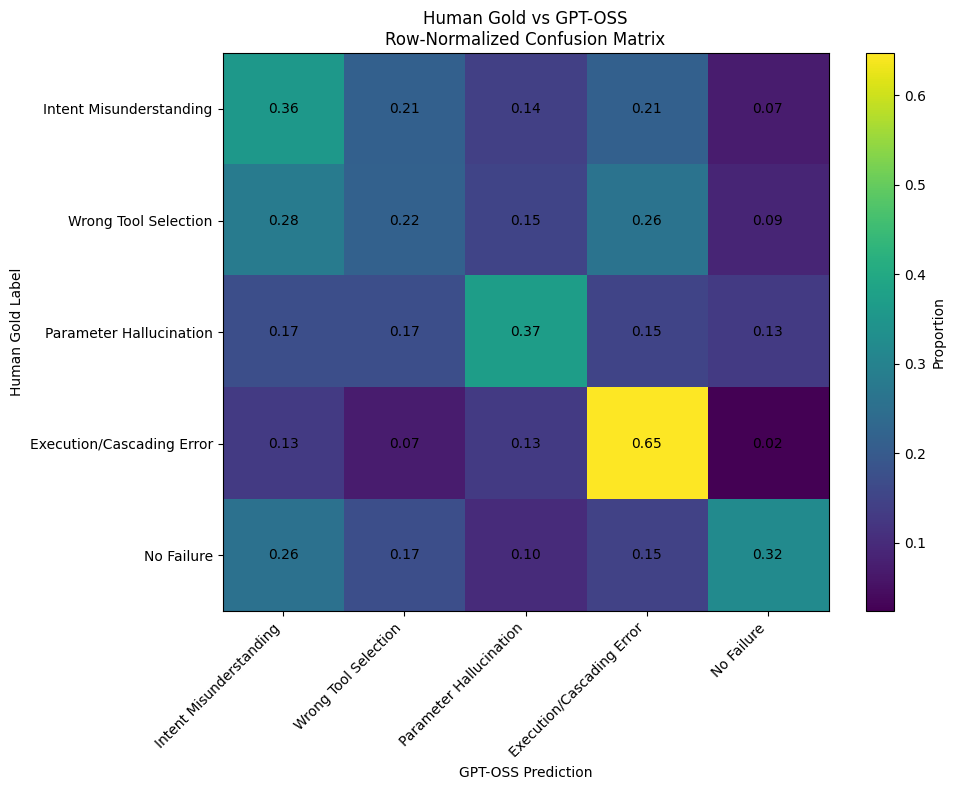

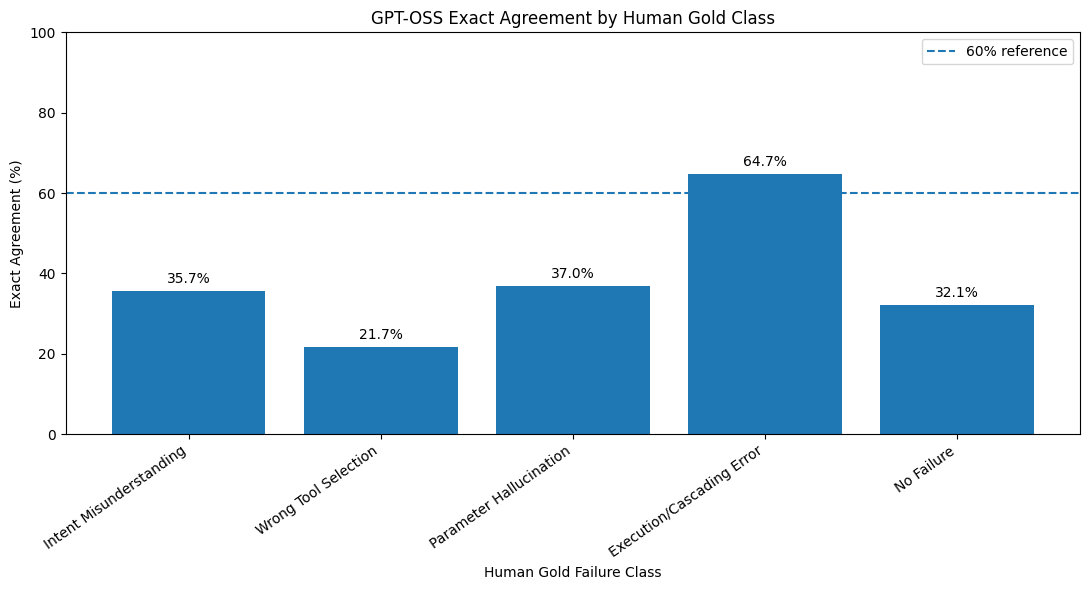


STEP 4 HUMAN VALIDATION COMPLETE
Human gold              : 300 genuine manual labels
Matched GPT-OSS labels  : 300/300
Agreement               : 40.67%
Cohen's Kappa           : 0.2545
95% bootstrap CI        : [0.1904, 0.3203]
Reliability status      : BELOW PROJECT RELIABILITY TARGET

Saved files:
✓ /kaggle/working/toolbench_research/results/tables/step4_FINAL_human300_vs_gptoss_comparison.csv
✓ /kaggle/working/toolbench_research/results/tables/step4_FINAL_human300_vs_gptoss_kappa_metrics.csv
✓ /kaggle/working/toolbench_research/results/tables/step4_FINAL_human300_vs_gptoss_confusion_matrix.csv
✓ /kaggle/working/toolbench_research/results/tables/step4_FINAL_human300_vs_gptoss_confusion_matrix_normalized.csv
✓ /kaggle/working/toolbench_research/results/tables/step4_FINAL_human300_vs_gptoss_classification_report.csv
✓ /kaggle/working/toolbench_research/results/tables/step4_FINAL_human300_vs_gptoss_per_class_agreement.csv
✓ /kaggle/working/toolbench_research/results/tables/step4_FINAL_

In [14]:
# ============================================================
# STEP 4 — FINAL HUMAN vs GPT-OSS VALIDATION
# UPDATED / ROBUST VERSION
#
# PURPOSE
# -------
# 1. Compare 300 genuine HUMAN GOLD labels against GPT-OSS labels
#    for the EXACT SAME trajectory IDs.
#
# 2. Calculate:
#       - Raw agreement
#       - Cohen's Kappa
#       - 95% bootstrap CI for Kappa
#       - Per-class agreement
#       - Precision / Recall / F1
#       - Confusion matrix
#       - Row-normalized confusion matrix
#       - Systematic disagreement pairs
#
# 3. Explicitly evaluate whether agreement reaches the
#    methodology target:
#
#       Kappa >= 0.60  -> minimum acceptable target
#       Kappa >= 0.70  -> stronger reliability target
#
# IMPORTANT
# ---------
# LOW KAPPA MUST NOT BE "FIXED" BY CHANGING LABELS.
# If Kappa is low, report it transparently as a limitation.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import glob
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    cohen_kappa_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42
N_BOOTSTRAP = 5000

# Require every human-gold trajectory to have a GPT label.
# For the final research analysis this SHOULD remain True.
REQUIRE_ALL_300_MATCHED = True

# Reliability thresholds from the methodology PDF
KAPPA_MIN_TARGET = 0.60
KAPPA_STRONG_TARGET = 0.70


# ============================================================
# WORKING OUTPUT ROOT
# ============================================================

BASE = "/kaggle/working/toolbench_research"

RESULTS_DIR = os.path.join(
    BASE,
    "results",
    "tables"
)

FIGURES_DIR = os.path.join(
    BASE,
    "results",
    "figures"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURES_DIR,
    exist_ok=True
)


# ============================================================
# 2. FINAL PROJECT FILES — UPDATED FOR MASTER-SETUP BACKUP
# ============================================================

MASTER_SETUP_ROOT = (
    "/kaggle/input/datasets/anandadevnath/master-setup"
)

if not os.path.isdir(
    MASTER_SETUP_ROOT
):

    raise FileNotFoundError(
        f"Master setup dataset root not found:\n"
        f"{MASTER_SETUP_ROOT}"
    )


# Find the final Step-10 master backup automatically.
backup_candidates = sorted(
    glob.glob(
        os.path.join(
            MASTER_SETUP_ROOT,
            "ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_*"
        )
    )
)

backup_candidates = [
    p
    for p in backup_candidates
    if os.path.isdir(p)
]


if not backup_candidates:

    raise FileNotFoundError(
        "Could not find the final ToolBench master backup inside:\n"
        f"{MASTER_SETUP_ROOT}"
    )


FINAL_BACKUP_ROOT = backup_candidates[-1]

BACKUP_PROCESSED_DIR = os.path.join(
    FINAL_BACKUP_ROOT,
    "CURRENT_RESEARCH",
    "data",
    "processed"
)

WORKING_PROCESSED_DIR = os.path.join(
    BASE,
    "data",
    "processed"
)


print("=" * 100)
print("STEP 4 — FINAL HUMAN vs GPT-OSS VALIDATION")
print("=" * 100)

print(
    f"\nMaster setup root:\n"
    f"{MASTER_SETUP_ROOT}"
)

print(
    f"\nFinal backup selected:\n"
    f"{FINAL_BACKUP_ROOT}"
)

print(
    f"\nBackup processed-data directory:\n"
    f"{BACKUP_PROCESSED_DIR}"
)


if not os.path.isdir(
    BACKUP_PROCESSED_DIR
):

    raise FileNotFoundError(
        "Backup processed-data directory not found:\n"
        f"{BACKUP_PROCESSED_DIR}"
    )


# ------------------------------------------------------------
# Resolve Human Gold.
# Prefer a current working copy if present; otherwise use backup.
# ------------------------------------------------------------

HUMAN_CANDIDATES = [

    os.path.join(
        WORKING_PROCESSED_DIR,
        "step4_human_gold_FINAL_300.parquet"
    ),

    os.path.join(
        BACKUP_PROCESSED_DIR,
        "step4_human_gold_FINAL_300.parquet"
    ),

    os.path.join(
        WORKING_PROCESSED_DIR,
        "step4_human_gold_FINAL_300.csv"
    ),

    os.path.join(
        BACKUP_PROCESSED_DIR,
        "step4_human_gold_FINAL_300.csv"
    ),
]


HUMAN_PATH = next(
    (
        path
        for path in HUMAN_CANDIDATES
        if os.path.isfile(path)
    ),
    None
)


if HUMAN_PATH is None:

    raise FileNotFoundError(
        "Could not locate step4_human_gold_FINAL_300 "
        "in either the working directory or final backup."
    )


# ------------------------------------------------------------
# Resolve GPT-OSS annotations.
# Prefer FINAL 4,000-label files.
# Working copy first, then final backup.
# Legacy 3K files are fallback only.
# ------------------------------------------------------------

GPT_CANDIDATES = [

    # --------------------------------------------------------
    # FINAL 4,000 — WORKING
    # --------------------------------------------------------

    os.path.join(
        WORKING_PROCESSED_DIR,
        "step4_gptoss120b_target4000_FINAL.parquet"
    ),

    os.path.join(
        WORKING_PROCESSED_DIR,
        "step4_gptoss120b_target4000_FINAL.csv"
    ),

    # --------------------------------------------------------
    # FINAL 4,000 — MASTER BACKUP
    # --------------------------------------------------------

    os.path.join(
        BACKUP_PROCESSED_DIR,
        "step4_gptoss120b_target4000_FINAL.parquet"
    ),

    os.path.join(
        BACKUP_PROCESSED_DIR,
        "step4_gptoss120b_target4000_FINAL.csv"
    ),

    # --------------------------------------------------------
    # LEGACY FALLBACKS — WORKING
    # --------------------------------------------------------

    os.path.join(
        WORKING_PROCESSED_DIR,
        "step4_llm_annotations_gptoss120b_fresh3000.parquet"
    ),

    os.path.join(
        WORKING_PROCESSED_DIR,
        "step4_llm_annotations_gptoss120b_fresh3000.csv"
    ),

    os.path.join(
        WORKING_PROCESSED_DIR,
        "step4_gptoss120b_fresh3000_checkpoint.csv"
    ),

    # --------------------------------------------------------
    # LEGACY FALLBACKS — MASTER BACKUP
    # --------------------------------------------------------

    os.path.join(
        BACKUP_PROCESSED_DIR,
        "step4_llm_annotations_gptoss120b_fresh3000.parquet"
    ),

    os.path.join(
        BACKUP_PROCESSED_DIR,
        "step4_llm_annotations_gptoss120b_fresh3000.csv"
    ),

    os.path.join(
        BACKUP_PROCESSED_DIR,
        "step4_gptoss120b_fresh3000_checkpoint.csv"
    ),
]


# Used later by fallback-search logic.
# Point it at the authoritative final backup processed directory.
PROCESSED_DIR = BACKUP_PROCESSED_DIR


# ============================================================
# 3. TAXONOMY
# ============================================================

LABELS = [
    "Intent Misunderstanding",
    "Wrong Tool Selection",
    "Parameter Hallucination",
    "Execution/Cascading Error",
    "No Failure"
]


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def load_table(path):
    """
    Load parquet or CSV while preserving trajectory IDs as strings.
    """

    if path.lower().endswith(".parquet"):

        df = pd.read_parquet(
            path
        )

    elif path.lower().endswith(".csv"):

        df = pd.read_csv(
            path,
            dtype={"id": str}
        )

    else:

        raise ValueError(
            f"Unsupported file type: {path}"
        )

    return df


def clean_string_column(series):
    """
    Convert values to stripped strings while preserving missing values.
    """

    return series.apply(
        lambda x:
            str(x).strip()
            if pd.notna(x)
            else np.nan
    )


def detect_column(df, candidates, column_type):
    """
    Locate the first valid column from a list of candidates.
    """

    for col in candidates:

        if col in df.columns:
            return col

    raise ValueError(
        f"Could not identify {column_type} column.\n"
        f"Columns found:\n{df.columns.tolist()}"
    )


def bootstrap_kappa(
    human_values,
    gpt_values,
    labels,
    n_bootstrap=5000,
    seed=42
):
    """
    Paired bootstrap for Cohen's Kappa.

    Both labels are sampled using the SAME indices,
    preserving the human/GPT pair relationship.
    """

    rng = np.random.default_rng(
        seed
    )

    human_values = np.asarray(
        human_values
    )

    gpt_values = np.asarray(
        gpt_values
    )

    n = len(
        human_values
    )

    values = []

    for _ in range(n_bootstrap):

        idx = rng.integers(
            0,
            n,
            size=n
        )

        h_sample = human_values[idx]
        g_sample = gpt_values[idx]

        try:

            k = cohen_kappa_score(
                h_sample,
                g_sample,
                labels=labels
            )

            if np.isfinite(k):
                values.append(
                    float(k)
                )

        except Exception:
            pass

    values = np.asarray(
        values,
        dtype=float
    )

    if len(values) == 0:

        raise RuntimeError(
            "Bootstrap Cohen's Kappa calculation failed."
        )

    return {
        "values": values,
        "mean": float(np.mean(values)),
        "median": float(np.median(values)),
        "std": float(np.std(values, ddof=1)),
        "lower_95": float(np.percentile(values, 2.5)),
        "upper_95": float(np.percentile(values, 97.5)),
        "iterations": int(len(values))
    }


def interpret_kappa(kappa):
    """
    Project-specific interpretation using the methodology threshold.
    """

    if kappa >= KAPPA_STRONG_TARGET:

        return (
            "MEETS STRONG TARGET",
            "Kappa is >= 0.70."
        )

    elif kappa >= KAPPA_MIN_TARGET:

        return (
            "MEETS MINIMUM TARGET",
            "Kappa is >= 0.60 but below 0.70."
        )

    else:

        return (
            "BELOW PROJECT RELIABILITY TARGET",
            "Kappa is below 0.60; automated labels should be "
            "treated as noisy proxy labels."
        )


# ============================================================
# 5. LOCATE GPT-OSS FILE
# ============================================================

GPT_PATH = None


# ------------------------------------------------------------
# 5A. Preferred explicit candidates
# ------------------------------------------------------------

for path in GPT_CANDIDATES:

    if os.path.isfile(
        path
    ):

        GPT_PATH = path
        break


# ------------------------------------------------------------
# 5B. Safe fallback search
# ------------------------------------------------------------

if GPT_PATH is None:

    all_candidates = (
        glob.glob(
            os.path.join(
                PROCESSED_DIR,
                "*gptoss*.parquet"
            )
        )
        +
        glob.glob(
            os.path.join(
                PROCESSED_DIR,
                "*gptoss*.csv"
            )
        )
    )

    # Exclude files that are outputs/metrics/comparisons rather
    # than raw/final GPT annotation datasets.
    excluded_words = [
        "comparison",
        "metric",
        "confusion",
        "classification",
        "distribution",
        "human",
        "missing",
        "agreement"
    ]

    safe_candidates = []

    for path in all_candidates:

        name = os.path.basename(
            path
        ).lower()

        if not any(
            word in name
            for word in excluded_words
        ):

            safe_candidates.append(
                path
            )

    if safe_candidates:

        # Prefer names containing FINAL / 4000
        safe_candidates = sorted(
            safe_candidates,
            key=lambda p: (
                "final" in os.path.basename(p).lower(),
                "4000" in os.path.basename(p).lower(),
                os.path.getmtime(p)
            ),
            reverse=True
        )

        GPT_PATH = safe_candidates[0]


if GPT_PATH is None:

    raise FileNotFoundError(
        "Could not locate a valid GPT-OSS annotation file."
    )


# ============================================================
# 6. FILE EXISTENCE CHECK
# ============================================================

if not os.path.isfile(
    HUMAN_PATH
):

    raise FileNotFoundError(
        f"Human gold file not found:\n{HUMAN_PATH}"
    )


print("=" * 100)
print("STEP 4 — FINAL HUMAN vs GPT-OSS VALIDATION")
print("=" * 100)

print(
    f"\nHuman gold file:\n{HUMAN_PATH}"
)

print(
    f"\nGPT-OSS file selected:\n{GPT_PATH}"
)


if "target4000_FINAL" in GPT_PATH:

    print(
        "\n✓ FINAL 4,000-label GPT-OSS dataset selected."
    )

else:

    print(
        "\nWARNING:"
    )

    print(
        "The preferred final 4,000-label GPT file was not found."
    )

    print(
        "A fallback GPT annotation file is being used."
    )


# ============================================================
# 7. LOAD HUMAN GOLD
# ============================================================

human = load_table(
    HUMAN_PATH
)


required_human_columns = [
    "id",
    "human_label"
]


missing_human_columns = [
    col
    for col in required_human_columns
    if col not in human.columns
]


if missing_human_columns:

    raise ValueError(
        f"Human gold is missing columns: "
        f"{missing_human_columns}"
    )


human["id"] = clean_string_column(
    human["id"]
)

human["human_label"] = clean_string_column(
    human["human_label"]
)


# ============================================================
# 8. HUMAN GOLD VALIDATION
# ============================================================

print("\n" + "-" * 100)
print("HUMAN GOLD VALIDATION")
print("-" * 100)

print(
    f"Rows                : {len(human):,}"
)

print(
    f"Unique IDs          : {human['id'].nunique():,}"
)

print(
    f"Missing IDs         : {human['id'].isna().sum():,}"
)

print(
    f"Missing labels      : {human['human_label'].isna().sum():,}"
)

print(
    f"Invalid labels      : "
    f"{(~human['human_label'].isin(LABELS)).sum():,}"
)


if len(human) != 300:

    raise ValueError(
        f"Expected exactly 300 human labels, "
        f"but found {len(human)}."
    )


if human["id"].isna().any():

    raise ValueError(
        "Human gold contains missing trajectory IDs."
    )


if human["id"].nunique() != 300:

    duplicated_ids = human[
        human["id"].duplicated(
            keep=False
        )
    ]

    raise ValueError(
        "Human gold IDs are not unique.\n\n"
        f"Duplicated records:\n"
        f"{duplicated_ids}"
    )


if human["human_label"].isna().any():

    raise ValueError(
        "Human gold contains missing labels."
    )


if not human["human_label"].isin(
    LABELS
).all():

    invalid = human.loc[
        ~human["human_label"].isin(LABELS),
        [
            "id",
            "human_label"
        ]
    ]

    raise ValueError(
        "Human gold contains invalid taxonomy labels.\n\n"
        f"{invalid}"
    )


print(
    "\n✓ Human Gold contains exactly "
    "300 unique, valid manual labels."
)


# ============================================================
# 9. LOAD GPT LABELS
# ============================================================

gpt = load_table(
    GPT_PATH
)


# ============================================================
# 10. DETECT GPT ID COLUMN
# ============================================================

possible_id_columns = [
    "id",
    "annotation_id",
    "trajectory_id"
]


gpt_id_col = detect_column(
    gpt,
    possible_id_columns,
    "GPT trajectory ID"
)


if gpt_id_col != "id":

    gpt = gpt.rename(
        columns={
            gpt_id_col: "id"
        }
    )


gpt["id"] = clean_string_column(
    gpt["id"]
)


# ============================================================
# 11. DETECT GPT LABEL COLUMN
# ============================================================

possible_label_columns = [
    "llm_failure_type",
    "failure_type",
    "gpt_label",
    "llm_label",
    "label"
]


gpt_label_col = detect_column(
    gpt,
    possible_label_columns,
    "GPT failure label"
)


gpt[gpt_label_col] = clean_string_column(
    gpt[gpt_label_col]
)


# ============================================================
# 12. GPT DATA QUALITY CHECK
# ============================================================

print("\n" + "-" * 100)
print("GPT-OSS DATA QUALITY")
print("-" * 100)

print(
    f"Rows loaded             : {len(gpt):,}"
)

print(
    f"Detected label column   : {gpt_label_col}"
)

print(
    f"Missing IDs             : {gpt['id'].isna().sum():,}"
)

print(
    f"Missing labels          : {gpt[gpt_label_col].isna().sum():,}"
)


# Remove missing IDs because they cannot be paired.
gpt = gpt[
    gpt["id"].notna()
].copy()


# ============================================================
# 13. INVALID GPT LABEL CHECK
# ============================================================

invalid_gpt = gpt[
    gpt[gpt_label_col].notna()
    &
    ~gpt[gpt_label_col].isin(
        LABELS
    )
].copy()


print(
    f"Invalid taxonomy labels : {len(invalid_gpt):,}"
)


if len(invalid_gpt) > 0:

    invalid_path = os.path.join(
        RESULTS_DIR,
        "step4_FINAL_invalid_gptoss_labels.csv"
    )

    invalid_gpt.to_csv(
        invalid_path,
        index=False
    )

    print(
        f"Invalid-label rows saved:\n{invalid_path}"
    )


# Keep ONLY valid taxonomy labels
gpt = gpt[
    gpt[gpt_label_col].isin(
        LABELS
    )
].copy()


# ============================================================
# 14. DUPLICATE GPT ID CHECK
# ============================================================

duplicate_rows = gpt[
    gpt["id"].duplicated(
        keep=False
    )
].copy()


if len(duplicate_rows) > 0:

    duplicate_label_counts = (
        duplicate_rows
        .groupby("id")[
            gpt_label_col
        ]
        .nunique()
    )

    conflicting_ids = (
        duplicate_label_counts[
            duplicate_label_counts > 1
        ]
        .index
        .tolist()
    )

    if conflicting_ids:

        conflicting_rows = duplicate_rows[
            duplicate_rows["id"].isin(
                conflicting_ids
            )
        ]

        conflict_path = os.path.join(
            RESULTS_DIR,
            "step4_FINAL_conflicting_duplicate_gpt_labels.csv"
        )

        conflicting_rows.to_csv(
            conflict_path,
            index=False
        )

        raise ValueError(
            "GPT annotation file contains duplicate IDs "
            "with CONFLICTING labels.\n"
            "The analysis has been stopped to prevent "
            "silently selecting an incorrect label.\n\n"
            f"Saved conflicts:\n{conflict_path}"
        )

    else:

        print(
            "\nNOTE:"
        )

        print(
            "Duplicate GPT IDs were found, but their "
            "labels were identical."
        )

        print(
            "Identical duplicates will be safely removed."
        )


# Remove only exact/non-conflicting duplicate IDs
gpt = (
    gpt
    .drop_duplicates(
        subset=["id"],
        keep="first"
    )
    .reset_index(
        drop=True
    )
)


print(
    f"Valid unique GPT labels : {len(gpt):,}"
)


# ============================================================
# 15. GPT LABEL DISTRIBUTION
# ============================================================

print("\nGPT label distribution:")

gpt_label_distribution_all = (
    gpt[gpt_label_col]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print(
    gpt_label_distribution_all.to_string()
)


# ============================================================
# 16. EXACT ID PAIRING
# ============================================================

comparison = (
    human[
        [
            "id",
            "human_label"
        ]
    ]
    .merge(
        gpt[
            [
                "id",
                gpt_label_col
            ]
        ],
        on="id",
        how="left",
        validate="one_to_one"
    )
)


comparison = comparison.rename(
    columns={
        gpt_label_col:
            "gptoss_label"
    }
)


matched_mask = (
    comparison["gptoss_label"]
    .notna()
)


matched = (
    comparison[
        matched_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


missing_gpt = (
    comparison[
        ~matched_mask
    ]
    .copy()
)


# ============================================================
# 17. PAIRING VALIDATION
# ============================================================

print("\n" + "-" * 100)
print("EXACT ID PAIRING VALIDATION")
print("-" * 100)

print(
    f"Human gold trajectories : {len(comparison):,}"
)

print(
    f"Matched with GPT-OSS    : {len(matched):,}"
)

print(
    f"Missing GPT labels      : {len(missing_gpt):,}"
)

print(
    f"Matched unique IDs      : {matched['id'].nunique():,}"
)


missing_path = os.path.join(
    RESULTS_DIR,
    "step4_FINAL_human300_missing_gptoss_labels.csv"
)

missing_gpt.to_csv(
    missing_path,
    index=False
)


if REQUIRE_ALL_300_MATCHED:

    if len(matched) != 300:

        raise RuntimeError(
            "\nFINAL VALIDATION FAILED:\n"
            f"Only {len(matched)}/300 human-gold IDs "
            "have matching GPT labels.\n\n"
            "For the final methodology validation, "
            "all 300 must be paired.\n\n"
            f"Missing-ID table:\n{missing_path}"
        )


if len(matched) < 2:

    raise RuntimeError(
        "Not enough matched trajectories "
        "to calculate Cohen's Kappa."
    )


if len(matched) == 300:

    print(
        "\n✓ Exact 300/300 human-GPT trajectory pairing confirmed."
    )


# ============================================================
# 18. RAW AGREEMENT
# ============================================================

matched["agreement"] = (
    matched["human_label"]
    ==
    matched["gptoss_label"]
)


n = len(
    matched
)


exact_matches = int(
    matched["agreement"]
    .sum()
)


disagreements = int(
    n - exact_matches
)


raw_agreement = float(
    accuracy_score(
        matched["human_label"],
        matched["gptoss_label"]
    )
)


# ============================================================
# 19. COHEN'S KAPPA
# ============================================================

kappa = float(
    cohen_kappa_score(
        matched["human_label"],
        matched["gptoss_label"],
        labels=LABELS
    )
)


# ============================================================
# 20. BOOTSTRAP 95% CI FOR KAPPA
# ============================================================

bootstrap_result = bootstrap_kappa(

    human_values=matched[
        "human_label"
    ].to_numpy(),

    gpt_values=matched[
        "gptoss_label"
    ].to_numpy(),

    labels=LABELS,

    n_bootstrap=N_BOOTSTRAP,

    seed=SEED
)


bootstrap_mean = bootstrap_result[
    "mean"
]

bootstrap_median = bootstrap_result[
    "median"
]

bootstrap_std = bootstrap_result[
    "std"
]

ci_lower = bootstrap_result[
    "lower_95"
]

ci_upper = bootstrap_result[
    "upper_95"
]

bootstrap_iterations = bootstrap_result[
    "iterations"
]


# ============================================================
# 21. RELIABILITY INTERPRETATION
# ============================================================

reliability_status, reliability_explanation = (
    interpret_kappa(
        kappa
    )
)


# Extra conservative check:
# Does even the upper CI reach the minimum target?
ci_reaches_minimum = (
    ci_upper >= KAPPA_MIN_TARGET
)


if (
    kappa < KAPPA_MIN_TARGET
    and ci_upper < KAPPA_MIN_TARGET
):

    ci_interpretation = (
        "Even the upper bound of the 95% bootstrap CI "
        "is below the project's minimum Kappa target."
    )

elif (
    kappa < KAPPA_MIN_TARGET
    and ci_upper >= KAPPA_MIN_TARGET
):

    ci_interpretation = (
        "Point estimate is below target, but the bootstrap "
        "CI overlaps the minimum reliability threshold."
    )

else:

    ci_interpretation = (
        "Point estimate meets the minimum project target."
    )


# ============================================================
# 22. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    matched["human_label"],
    matched["gptoss_label"],
    labels=LABELS
)


cm_df = pd.DataFrame(
    cm,
    index=LABELS,
    columns=LABELS
)

cm_df.index.name = "Human"
cm_df.columns.name = "GPT-OSS"


# ============================================================
# 23. NORMALIZED CONFUSION MATRIX
# ============================================================

row_sums = cm.sum(
    axis=1,
    keepdims=True
)


normalized_cm = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(
        cm,
        dtype=float
    ),
    where=row_sums != 0
)


normalized_cm_df = pd.DataFrame(
    normalized_cm,
    index=LABELS,
    columns=LABELS
)

normalized_cm_df.index.name = "Human"
normalized_cm_df.columns.name = "GPT-OSS"


# ============================================================
# 24. CLASSIFICATION REPORT
# ============================================================

report_dict = classification_report(
    matched["human_label"],
    matched["gptoss_label"],
    labels=LABELS,
    output_dict=True,
    zero_division=0
)


report_df = (
    pd.DataFrame(
        report_dict
    )
    .transpose()
)


# ============================================================
# 25. PER-HUMAN-CLASS AGREEMENT
# ============================================================

per_class_records = []


for label in LABELS:

    subset = matched[
        matched["human_label"]
        ==
        label
    ]


    support = len(
        subset
    )


    correct = int(
        (
            subset["gptoss_label"]
            ==
            label
        )
        .sum()
    )


    agreement_rate = (
        correct / support
        if support > 0
        else np.nan
    )


    per_class_records.append(
        {
            "human_class":
                label,

            "support":
                support,

            "exact_gpt_matches":
                correct,

            "class_agreement":
                agreement_rate,

            "class_agreement_percent":
                (
                    agreement_rate * 100
                    if np.isfinite(
                        agreement_rate
                    )
                    else np.nan
                )
        }
    )


per_class_df = pd.DataFrame(
    per_class_records
)


# ============================================================
# 26. SYSTEMATIC DISAGREEMENT ANALYSIS
# ============================================================

disagreement_rows = matched[
    ~matched["agreement"]
].copy()


if len(disagreement_rows) > 0:

    disagreement_pairs = (
        disagreement_rows
        .groupby(
            [
                "human_label",
                "gptoss_label"
            ]
        )
        .size()
        .reset_index(
            name="count"
        )
        .sort_values(
            "count",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    disagreement_pairs[
        "percent_of_all_disagreements"
    ] = (
        disagreement_pairs["count"]
        /
        disagreements
        *
        100
    )

else:

    disagreement_pairs = pd.DataFrame(
        columns=[
            "human_label",
            "gptoss_label",
            "count",
            "percent_of_all_disagreements"
        ]
    )


# ============================================================
# 27. LABEL DISTRIBUTION COMPARISON
# ============================================================

human_distribution = (
    matched[
        "human_label"
    ]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)


gpt_distribution = (
    matched[
        "gptoss_label"
    ]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)


distribution_df = pd.DataFrame(
    {
        "Human_Gold":
            human_distribution,

        "GPT_OSS":
            gpt_distribution
    }
)


distribution_df[
    "Human_Percent"
] = (
    distribution_df[
        "Human_Gold"
    ]
    /
    n
    *
    100
)


distribution_df[
    "GPT_OSS_Percent"
] = (
    distribution_df[
        "GPT_OSS"
    ]
    /
    n
    *
    100
)


# ============================================================
# 28. PRINT FINAL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("FINAL HUMAN vs GPT-OSS AGREEMENT RESULTS")
print("=" * 100)

print(
    f"Matched trajectories     : {n}/300"
)

print(
    f"Exact matches            : "
    f"{exact_matches}/{n}"
)

print(
    f"Disagreements            : "
    f"{disagreements}/{n}"
)

print(
    f"Raw agreement            : "
    f"{raw_agreement:.4f} "
    f"({raw_agreement * 100:.2f}%)"
)

print(
    f"Cohen's Kappa            : "
    f"{kappa:.4f}"
)

print(
    f"Bootstrap mean Kappa     : "
    f"{bootstrap_mean:.4f}"
)

print(
    f"Bootstrap median Kappa   : "
    f"{bootstrap_median:.4f}"
)

print(
    f"Bootstrap std            : "
    f"{bootstrap_std:.4f}"
)

print(
    f"95% Bootstrap CI         : "
    f"[{ci_lower:.4f}, "
    f"{ci_upper:.4f}]"
)

print(
    f"Bootstrap iterations     : "
    f"{bootstrap_iterations:,}"
)


print("\n" + "-" * 100)
print("METHODOLOGY RELIABILITY CHECK")
print("-" * 100)

print(
    f"Minimum target           : "
    f"Kappa >= {KAPPA_MIN_TARGET:.2f}"
)

print(
    f"Stronger target          : "
    f"Kappa >= {KAPPA_STRONG_TARGET:.2f}"
)

print(
    f"Observed Kappa           : "
    f"{kappa:.4f}"
)

print(
    f"Status                   : "
    f"{reliability_status}"
)

print(
    f"Interpretation           : "
    f"{reliability_explanation}"
)

print(
    f"CI interpretation        : "
    f"{ci_interpretation}"
)


# ============================================================
# 29. PER-CLASS OUTPUT
# ============================================================

print("\n" + "=" * 100)
print("PER-CLASS AGREEMENT")
print("=" * 100)

print(
    per_class_df.to_string(
        index=False,
        formatters={
            "class_agreement":
                lambda x:
                    (
                        f"{x:.4f}"
                        if pd.notna(x)
                        else "NA"
                    ),

            "class_agreement_percent":
                lambda x:
                    (
                        f"{x:.2f}%"
                        if pd.notna(x)
                        else "NA"
                    )
        }
    )
)


# ============================================================
# 30. CONFUSION MATRIX OUTPUT
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("Rows = Human Gold | Columns = GPT-OSS")
print("=" * 100)

print(
    cm_df.to_string()
)


print("\n" + "=" * 100)
print("ROW-NORMALIZED CONFUSION MATRIX")
print("Each human-label row sums to approximately 1.0")
print("=" * 100)

print(
    normalized_cm_df.round(
        4
    ).to_string()
)


# ============================================================
# 31. CLASSIFICATION REPORT OUTPUT
# ============================================================

print("\n" + "=" * 100)
print("GPT-OSS vs HUMAN GOLD CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        matched["human_label"],
        matched["gptoss_label"],
        labels=LABELS,
        zero_division=0
    )
)


# ============================================================
# 32. DISAGREEMENT PAIRS
# ============================================================

print("\n" + "=" * 100)
print("MOST COMMON HUMAN ↔ GPT DISAGREEMENTS")
print("=" * 100)

if len(
    disagreement_pairs
) > 0:

    print(
        disagreement_pairs
        .head(20)
        .to_string(
            index=False,
            formatters={
                "percent_of_all_disagreements":
                    lambda x:
                        f"{x:.2f}%"
            }
        )
    )

else:

    print(
        "No disagreements."
    )


# ============================================================
# 33. DISTRIBUTION COMPARISON
# ============================================================

print("\n" + "=" * 100)
print("LABEL DISTRIBUTION COMPARISON")
print("=" * 100)

print(
    distribution_df
    .round(4)
    .to_string()
)


# ============================================================
# 34. SAVE COMPARISON DATA
# ============================================================

comparison_path = os.path.join(
    RESULTS_DIR,
    "step4_FINAL_human300_vs_gptoss_comparison.csv"
)


matched.to_csv(
    comparison_path,
    index=False
)


# ============================================================
# 35. SAVE MAIN METRICS
# ============================================================

metrics_df = pd.DataFrame(
    [
        {
            "human_gold_total":
                300,

            "matched_trajectories":
                n,

            "exact_matches":
                exact_matches,

            "disagreements":
                disagreements,

            "raw_agreement":
                raw_agreement,

            "raw_agreement_percent":
                raw_agreement * 100,

            "cohen_kappa":
                kappa,

            "bootstrap_mean_kappa":
                bootstrap_mean,

            "bootstrap_median_kappa":
                bootstrap_median,

            "bootstrap_std_kappa":
                bootstrap_std,

            "bootstrap_ci_lower_95":
                ci_lower,

            "bootstrap_ci_upper_95":
                ci_upper,

            "bootstrap_iterations":
                bootstrap_iterations,

            "kappa_min_target":
                KAPPA_MIN_TARGET,

            "kappa_strong_target":
                KAPPA_STRONG_TARGET,

            "meets_minimum_target":
                bool(
                    kappa >=
                    KAPPA_MIN_TARGET
                ),

            "meets_strong_target":
                bool(
                    kappa >=
                    KAPPA_STRONG_TARGET
                ),

            "ci_upper_reaches_minimum":
                bool(
                    ci_reaches_minimum
                ),

            "reliability_status":
                reliability_status,

            "seed":
                SEED,

            "gpt_source_file":
                os.path.basename(
                    GPT_PATH
                )
        }
    ]
)


metrics_path = os.path.join(
    RESULTS_DIR,
    "step4_FINAL_human300_vs_gptoss_kappa_metrics.csv"
)


metrics_df.to_csv(
    metrics_path,
    index=False
)


# ============================================================
# 36. SAVE OTHER TABLES
# ============================================================

cm_path = os.path.join(
    RESULTS_DIR,
    "step4_FINAL_human300_vs_gptoss_confusion_matrix.csv"
)

cm_df.to_csv(
    cm_path
)


normalized_cm_path = os.path.join(
    RESULTS_DIR,
    "step4_FINAL_human300_vs_gptoss_confusion_matrix_normalized.csv"
)

normalized_cm_df.to_csv(
    normalized_cm_path
)


report_path = os.path.join(
    RESULTS_DIR,
    "step4_FINAL_human300_vs_gptoss_classification_report.csv"
)

report_df.to_csv(
    report_path
)


per_class_path = os.path.join(
    RESULTS_DIR,
    "step4_FINAL_human300_vs_gptoss_per_class_agreement.csv"
)

per_class_df.to_csv(
    per_class_path,
    index=False
)


distribution_path = os.path.join(
    RESULTS_DIR,
    "step4_FINAL_human300_vs_gptoss_label_distribution.csv"
)

distribution_df.to_csv(
    distribution_path
)


disagreement_path = os.path.join(
    RESULTS_DIR,
    "step4_FINAL_human300_vs_gptoss_disagreement_pairs.csv"
)

disagreement_pairs.to_csv(
    disagreement_path,
    index=False
)


# ============================================================
# 37. SAVE RELIABILITY SUMMARY
# ============================================================

summary_path = os.path.join(
    RESULTS_DIR,
    "step4_FINAL_human300_vs_gptoss_reliability_summary.txt"
)


summary_lines = [

    "STEP 4 — HUMAN vs GPT-OSS RELIABILITY SUMMARY",
    "=" * 75,
    "",

    f"Human gold trajectories : 300",
    f"Matched trajectories    : {n}",
    f"Exact agreements        : {exact_matches}",
    f"Disagreements           : {disagreements}",
    "",

    f"Raw agreement           : "
    f"{raw_agreement:.4f} "
    f"({raw_agreement * 100:.2f}%)",

    f"Cohen's Kappa           : "
    f"{kappa:.4f}",

    f"Bootstrap mean Kappa    : "
    f"{bootstrap_mean:.4f}",

    f"95% Bootstrap CI        : "
    f"[{ci_lower:.4f}, "
    f"{ci_upper:.4f}]",

    "",

    f"Minimum project target  : "
    f"{KAPPA_MIN_TARGET:.2f}",

    f"Strong project target   : "
    f"{KAPPA_STRONG_TARGET:.2f}",

    f"Reliability status      : "
    f"{reliability_status}",

    "",

    reliability_explanation,

    ci_interpretation,

    "",

    "RESEARCH INTERPRETATION:",

    (
        "If Kappa remains below 0.60, the GPT-OSS "
        "failure labels must be described as noisy proxy "
        "annotations rather than strongly validated "
        "ground-truth labels."
        if kappa < KAPPA_MIN_TARGET
        else
        "The observed agreement reaches the project's "
        "minimum reliability criterion."
    ),

    "",

    f"GPT annotation source   : "
    f"{GPT_PATH}"
]


with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "\n".join(
            summary_lines
        )
    )


# ============================================================
# 38. FIGURE 1 — CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 8)
)


image = ax.imshow(
    normalized_cm,
    aspect="auto"
)


ax.set_xticks(
    np.arange(
        len(LABELS)
    )
)

ax.set_yticks(
    np.arange(
        len(LABELS)
    )
)


ax.set_xticklabels(
    LABELS,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    LABELS
)


ax.set_xlabel(
    "GPT-OSS Prediction"
)

ax.set_ylabel(
    "Human Gold Label"
)

ax.set_title(
    "Human Gold vs GPT-OSS\n"
    "Row-Normalized Confusion Matrix"
)


for i in range(
    len(LABELS)
):

    for j in range(
        len(LABELS)
    ):

        value = normalized_cm[
            i,
            j
        ]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )


fig.colorbar(
    image,
    ax=ax,
    label="Proportion"
)

fig.tight_layout()


confusion_figure_path = os.path.join(
    FIGURES_DIR,
    "step4_FINAL_human_vs_gptoss_normalized_confusion_matrix.png"
)


fig.savefig(
    confusion_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close(
    fig
)


# ============================================================
# 39. FIGURE 2 — PER-CLASS AGREEMENT
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6)
)


plot_values = (
    per_class_df[
        "class_agreement_percent"
    ]
)


ax.bar(
    np.arange(
        len(LABELS)
    ),
    plot_values
)


ax.axhline(
    60,
    linestyle="--",
    linewidth=1.5,
    label="60% reference"
)


ax.set_xticks(
    np.arange(
        len(LABELS)
    )
)


ax.set_xticklabels(
    LABELS,
    rotation=35,
    ha="right"
)


ax.set_ylabel(
    "Exact Agreement (%)"
)

ax.set_xlabel(
    "Human Gold Failure Class"
)

ax.set_title(
    "GPT-OSS Exact Agreement by Human Gold Class"
)


ax.set_ylim(
    0,
    100
)


for i, value in enumerate(
    plot_values
):

    if pd.notna(
        value
    ):

        ax.text(
            i,
            value + 2,
            f"{value:.1f}%",
            ha="center"
        )


ax.legend()

fig.tight_layout()


agreement_figure_path = os.path.join(
    FIGURES_DIR,
    "step4_FINAL_human_vs_gptoss_per_class_agreement.png"
)


fig.savefig(
    agreement_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close(
    fig
)


# ============================================================
# 40. FINAL SAVED-FILE REPORT
# ============================================================

saved_files = [

    comparison_path,

    metrics_path,

    cm_path,

    normalized_cm_path,

    report_path,

    per_class_path,

    distribution_path,

    disagreement_path,

    missing_path,

    summary_path,

    confusion_figure_path,

    agreement_figure_path
]


print("\n" + "=" * 100)
print("STEP 4 HUMAN VALIDATION COMPLETE")
print("=" * 100)

print(
    f"Human gold              : 300 genuine manual labels"
)

print(
    f"Matched GPT-OSS labels  : {n}/300"
)

print(
    f"Agreement               : "
    f"{raw_agreement * 100:.2f}%"
)

print(
    f"Cohen's Kappa           : "
    f"{kappa:.4f}"
)

print(
    f"95% bootstrap CI        : "
    f"[{ci_lower:.4f}, "
    f"{ci_upper:.4f}]"
)

print(
    f"Reliability status      : "
    f"{reliability_status}"
)


print("\nSaved files:")

for path in saved_files:

    print(
        f"✓ {path}"
    )


print("\n" + "-" * 100)

if kappa < KAPPA_MIN_TARGET:

    print(
        "IMPORTANT RESEARCH LIMITATION:"
    )

    print(
        "Human/GPT agreement does NOT reach the "
        "methodology's minimum Kappa target."
    )

    print(
        "Do not describe GPT-OSS labels as strongly "
        "validated ground truth."
    )

    print(
        "Use wording such as:"
    )

    print(
        "\"Automated failure labels are treated as "
        "noisy proxy annotations, with limited human "
        "agreement explicitly acknowledged as a "
        "methodological limitation.\""
    )

else:

    print(
        "✓ Human/GPT agreement reaches the minimum "
        "project reliability target."
    )


print("=" * 100)

In [15]:
# ==================================================================================================
# STEP 5.1 — PREFIXSPAN SEQUENTIAL PATTERN MINING
# FINAL 4,000 LABELS — RECOVER RAW CONVERSATIONS FROM TRAIN-80
#
# FIX:
#   Final Step4 annotations = labels
#   Original train-80 parquet = actual raw ToolBench conversations
#
# WORKFLOW:
#   1. Load final 4,000 GPT labels
#   2. Load original train-80 parquet
#   3. Match the exact 4,000 IDs
#   4. Recover raw `conversations`
#   5. Extract USER / ASSISTANT / TOOL sequences
#   6. Validate extraction
#   7. Run PrefixSpan
#
# GPU: NOT REQUIRED
# ==================================================================================================


# ==================================================================================================
# 0. INSTALL PREFIXSPAN
# ==================================================================================================

import sys
import subprocess
import importlib.util

if importlib.util.find_spec("prefixspan") is None:
    print("Installing prefixspan...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "prefixspan"
    ])

print("✓ PrefixSpan available")


# ==================================================================================================
# 1. IMPORTS
# ==================================================================================================

import os
import re
import ast
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prefixspan import PrefixSpan

warnings.filterwarnings("ignore")


# ==================================================================================================
# 2. CONFIG
# ==================================================================================================

SEED = 42

EXPECTED_ROWS = 4000

LABELS = [
    "Intent Misunderstanding",
    "Wrong Tool Selection",
    "Parameter Hallucination",
    "Execution/Cascading Error",
    "No Failure"
]

BASE = "/kaggle/working/toolbench_research"

PROCESSED_DIR = os.path.join(
    BASE,
    "data",
    "processed"
)

TABLE_DIR = os.path.join(
    BASE,
    "results",
    "tables"
)

FIGURE_DIR = os.path.join(
    BASE,
    "results",
    "figures"
)

os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)


# ==================================================================================================
# 3. INPUT PATHS
# ==================================================================================================

FINAL_LABEL_PATH = os.path.join(
    PROCESSED_DIR,
    "step4_gptoss120b_target4000_FINAL.parquet"
)

TRAIN80_PATH = (
    "/kaggle/input/datasets/anandadevnath/new-backup/"
    "Master_backup/dataset/toolbench_train_80.parquet"
)


# ==================================================================================================
# 4. PREFIXSPAN SETTINGS
# ==================================================================================================

# Previous 2,105-label analysis:
# 50 / 2105 ≈ 2.38%
#
# Equivalent on 4,000:
# ≈ 95

OVERALL_MIN_SUPPORT = 95

MIN_PATTERN_LENGTH = 2
MAX_PATTERN_LENGTH = 6

TOP_PATTERNS_TO_SAVE = 200
TOP_PATTERNS_TO_PLOT = 15
TOP_CROSS_CLASS = 50
HEATMAP_TOP_PATTERNS = 20


# ==================================================================================================
# 5. FILE CHECK
# ==================================================================================================

print("=" * 110)
print("STEP 5.1 — PREFIXSPAN — FINAL 4,000 LABELS")
print("=" * 110)

for path in [
    FINAL_LABEL_PATH,
    TRAIN80_PATH
]:

    if not os.path.isfile(path):

        raise FileNotFoundError(
            f"Missing required file:\n{path}"
        )

    print(f"✓ Found: {path}")


# ==================================================================================================
# 6. LOAD FINAL 4,000 LABELS
# ==================================================================================================

labels_df = pd.read_parquet(
    FINAL_LABEL_PATH
)

if "id" not in labels_df.columns:

    raise ValueError(
        "Final label file does not contain 'id'."
    )

if "llm_failure_type" not in labels_df.columns:

    raise ValueError(
        "Final label file does not contain 'llm_failure_type'."
    )

labels_df["id"] = (
    labels_df["id"]
    .astype(str)
    .str.strip()
)

labels_df["llm_failure_type"] = (
    labels_df["llm_failure_type"]
    .astype(str)
    .str.strip()
)

labels_df = labels_df[
    labels_df[
        "llm_failure_type"
    ].isin(
        LABELS
    )
].copy()

labels_df = (
    labels_df
    .drop_duplicates(
        subset=["id"],
        keep="last"
    )
    .reset_index(drop=True)
)


print("\nFINAL LABEL DATASET")
print("-" * 110)

print(
    f"Valid labels : {len(labels_df):,}"
)

print(
    f"Unique IDs   : {labels_df['id'].nunique():,}"
)


if len(labels_df) != EXPECTED_ROWS:

    raise RuntimeError(
        f"Expected 4,000 valid labels, found {len(labels_df):,}."
    )

if labels_df["id"].nunique() != EXPECTED_ROWS:

    raise RuntimeError(
        "Final labels do not contain 4,000 unique IDs."
    )


print("\nLabel distribution:")

print(
    labels_df[
        "llm_failure_type"
    ]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
    .to_string()
)


# ==================================================================================================
# 7. LOAD ORIGINAL TRAIN-80 DATA
# ==================================================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "LOAD ORIGINAL TRAIN-80 RAW TRAJECTORIES"
)

print(
    "=" * 110
)


train_df = pd.read_parquet(
    TRAIN80_PATH
)


print(
    f"Train rows    : {len(train_df):,}"
)

print(
    f"Train columns : {train_df.columns.tolist()}"
)


if "id" not in train_df.columns:

    raise ValueError(
        "Train-80 parquet does not contain 'id'."
    )


if "conversations" not in train_df.columns:

    raise ValueError(
        "Train-80 parquet does not contain 'conversations'."
    )


train_df["id"] = (
    train_df["id"]
    .astype(str)
    .str.strip()
)


duplicate_train_ids = int(
    train_df["id"].duplicated().sum()
)


print(
    f"Duplicate train IDs : {duplicate_train_ids:,}"
)


if duplicate_train_ids != 0:

    raise RuntimeError(
        "Unexpected duplicate IDs in train-80 dataset."
    )


# ==================================================================================================
# 8. MATCH EXACT 4,000 IDs
# ==================================================================================================

label_ids = set(
    labels_df["id"]
)

train_ids = set(
    train_df["id"]
)


missing_from_train = (
    label_ids
    -
    train_ids
)


print(
    f"\nFinal-label IDs missing from train-80 : "
    f"{len(missing_from_train):,}"
)


if missing_from_train:

    preview = list(
        missing_from_train
    )[:10]

    raise RuntimeError(
        f"{len(missing_from_train)} final-label IDs "
        f"are missing from train-80.\n"
        f"Examples:\n{preview}"
    )


print(
    "✓ All 4,000 final-label IDs found in original train-80"
)


# ==================================================================================================
# 9. EXTRACT ONLY 4,000 RAW TRAJECTORIES
# ==================================================================================================

raw_columns = [
    "id",
    "conversations"
]


for optional_col in [
    "role_sequence",
    "step_depth",
    "depth_bucket",
    "num_turns"
]:

    if optional_col in train_df.columns:

        raw_columns.append(
            optional_col
        )


raw_4000 = (
    train_df[
        train_df[
            "id"
        ].isin(
            label_ids
        )
    ][
        raw_columns
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    f"\nMatched raw trajectories : {len(raw_4000):,}"
)

print(
    f"Matched unique IDs       : {raw_4000['id'].nunique():,}"
)


if len(raw_4000) != EXPECTED_ROWS:

    raise RuntimeError(
        f"Expected 4,000 matched raw trajectories, "
        f"found {len(raw_4000):,}."
    )


# ==================================================================================================
# 10. MERGE FINAL LABELS WITH RAW CONVERSATIONS
# ==================================================================================================

label_cols = [
    "id",
    "llm_failure_type"
]


for optional_col in [
    "llm_failure_turn",
    "llm_reason",
    "annotation_valid",
    "actual_model"
]:

    if optional_col in labels_df.columns:

        label_cols.append(
            optional_col
        )


df = raw_4000.merge(
    labels_df[
        label_cols
    ],
    on="id",
    how="inner",
    validate="one_to_one"
)


print(
    "\n"
    + "=" * 110
)

print(
    "MERGED STEP 5.1 DATASET"
)

print(
    "=" * 110
)


print(
    f"Rows       : {len(df):,}"
)

print(
    f"Unique IDs : {df['id'].nunique():,}"
)

print(
    f"Columns    : {df.columns.tolist()}"
)


if len(df) != EXPECTED_ROWS:

    raise RuntimeError(
        "Merged Step 5.1 dataset is not exactly 4,000 rows."
    )


# ==================================================================================================
# 11. ROLE NORMALIZATION
# ==================================================================================================

def normalize_role(role):

    if role is None:

        return None


    role = (
        str(role)
        .strip()
        .lower()
        .replace('"', "")
        .replace("'", "")
    )


    if role in [
        "human",
        "user"
    ]:

        return "USER"


    if role in [
        "assistant",
        "gpt"
    ]:

        return "ASSISTANT"


    if role in [
        "function",
        "tool",
        "observation",
        "api",
        "function_response",
        "tool_response"
    ]:

        return "TOOL"


    if role == "system":

        return "SYSTEM"


    return None


# ==================================================================================================
# 12. ROLE REGEX
# ==================================================================================================

KNOWN_ROLE_PATTERN = re.compile(
    r"""
    (?:
        system
        |
        human
        |
        user
        |
        assistant
        |
        gpt
        |
        function_response
        |
        tool_response
        |
        function
        |
        observation
        |
        tool
        |
        api
    )
    """,
    flags=re.IGNORECASE | re.VERBOSE
)


# ==================================================================================================
# 13. PARSE ROLE_SEQUENCE IF AVAILABLE
# ==================================================================================================

def parse_role_sequence_column(value):

    if value is None:

        return []


    if isinstance(
        value,
        (
            list,
            tuple,
            np.ndarray
        )
    ):

        raw_roles = list(
            value
        )


    else:

        text = str(
            value
        ).strip()


        if not text or text.lower() in [
            "nan",
            "none",
            "null"
        ]:

            return []


        raw_roles = None


        try:

            parsed = ast.literal_eval(
                text
            )


            if isinstance(
                parsed,
                (
                    list,
                    tuple,
                    np.ndarray
                )
            ):

                raw_roles = list(
                    parsed
                )


        except Exception:

            pass


        if raw_roles is None:

            try:

                parsed = json.loads(
                    text
                )


                if isinstance(
                    parsed,
                    list
                ):

                    raw_roles = parsed


            except Exception:

                pass


        if raw_roles is None:

            raw_roles = (
                KNOWN_ROLE_PATTERN
                .findall(
                    text
                )
            )


    output = []


    for role in raw_roles:

        normalized = normalize_role(
            role
        )


        if normalized is not None:

            output.append(
                normalized
            )


    return output


# ==================================================================================================
# 14. PARSE TOOLBENCH CONVERSATIONS
# ==================================================================================================

def extract_roles_from_conversation(value):

    if value is None:

        return []


    # ----------------------------------------------------------------------------------------------
    # Native ToolBench dictionary:
    #
    # {
    #   'from': np.array([...]),
    #   'value': np.array([...])
    # }
    # ----------------------------------------------------------------------------------------------

    if isinstance(
        value,
        dict
    ):

        roles = value.get(
            "from",
            []
        )


        try:

            roles = list(
                roles
            )


        except Exception:

            roles = [
                roles
            ]


        output = []


        for role in roles:

            normalized = normalize_role(
                role
            )


            if normalized is not None:

                output.append(
                    normalized
                )


        return output


    # ----------------------------------------------------------------------------------------------
    # List of dictionaries
    # ----------------------------------------------------------------------------------------------

    if isinstance(
        value,
        (
            list,
            tuple
        )
    ):

        output = []


        for item in value:

            if isinstance(
                item,
                dict
            ):

                role = (
                    item.get(
                        "from"
                    )
                    or
                    item.get(
                        "role"
                    )
                )


                normalized = normalize_role(
                    role
                )


                if normalized is not None:

                    output.append(
                        normalized
                    )


        if output:

            return output


    # ----------------------------------------------------------------------------------------------
    # String representation
    # ----------------------------------------------------------------------------------------------

    text = str(
        value
    ).strip()


    if not text or text.lower() in [
        "nan",
        "none",
        "null"
    ]:

        return []


    # ----------------------------------------------------------------------------------------------
    # Literal dictionary
    # ----------------------------------------------------------------------------------------------

    try:

        obj = ast.literal_eval(
            text
        )


        if isinstance(
            obj,
            dict
        ):

            roles = obj.get(
                "from",
                []
            )


            try:

                roles = list(
                    roles
                )


            except Exception:

                roles = [
                    roles
                ]


            output = []


            for role in roles:

                normalized = normalize_role(
                    role
                )


                if normalized is not None:

                    output.append(
                        normalized
                    )


            if output:

                return output


    except Exception:

        pass


    # ----------------------------------------------------------------------------------------------
    # numpy array representation
    # ----------------------------------------------------------------------------------------------

    array_match = re.search(
        r"""
        ['"]from['"]
        \s*:
        \s*
        (?:
            np\.
        )?
        array
        \s*
        \(
        \s*
        \[
        (.*?)
        \]
        """,
        text,
        flags=(
            re.IGNORECASE
            |
            re.DOTALL
            |
            re.VERBOSE
        )
    )


    if array_match:

        section = array_match.group(
            1
        )


        found_roles = (
            KNOWN_ROLE_PATTERN
            .findall(
                section
            )
        )


        output = []


        for role in found_roles:

            normalized = normalize_role(
                role
            )


            if normalized is not None:

                output.append(
                    normalized
                )


        if output:

            return output


    # ----------------------------------------------------------------------------------------------
    # Plain list
    # ----------------------------------------------------------------------------------------------

    list_match = re.search(
        r"""
        ['"]from['"]
        \s*:
        \s*
        \[
        (.*?)
        \]
        """,
        text,
        flags=(
            re.IGNORECASE
            |
            re.DOTALL
            |
            re.VERBOSE
        )
    )


    if list_match:

        found_roles = (
            KNOWN_ROLE_PATTERN
            .findall(
                list_match.group(
                    1
                )
            )
        )


        output = []


        for role in found_roles:

            normalized = normalize_role(
                role
            )


            if normalized is not None:

                output.append(
                    normalized
                )


        if output:

            return output


    return []


# ==================================================================================================
# 15. MASTER SEQUENCE EXTRACTOR
# ==================================================================================================

def extract_sequence(row):

    # Prefer original role_sequence if available.
    if "role_sequence" in row.index:

        sequence = parse_role_sequence_column(
            row[
                "role_sequence"
            ]
        )


        if len(sequence) >= 2:

            return sequence


    # Then use raw ToolBench conversations.
    sequence = extract_roles_from_conversation(
        row[
            "conversations"
        ]
    )


    if len(sequence) >= 2:

        return sequence


    return []


# ==================================================================================================
# 16. EXTRACT SEQUENCES
# ==================================================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "SEQUENCE EXTRACTION FROM ORIGINAL TRAIN-80"
)

print(
    "=" * 110
)


df[
    "role_sequence_fixed"
] = df.apply(
    extract_sequence,
    axis=1
)


# Remove SYSTEM because it is fixed prompt context.
df[
    "role_sequence_fixed"
] = (
    df[
        "role_sequence_fixed"
    ]
    .apply(
        lambda seq: [
            role
            for role in seq
            if role != "SYSTEM"
        ]
    )
)


df[
    "sequence_length"
] = (
    df[
        "role_sequence_fixed"
    ]
    .apply(
        len
    )
)


empty_sequences = int(
    (
        df[
            "sequence_length"
        ]
        ==
        0
    ).sum()
)


one_token_sequences = int(
    (
        df[
            "sequence_length"
        ]
        ==
        1
    ).sum()
)


print(
    f"Trajectories           : {len(df):,}"
)

print(
    f"Empty sequences        : {empty_sequences:,}"
)

print(
    f"One-token sequences    : {one_token_sequences:,}"
)

print(
    f"Mean sequence length   : "
    f"{df['sequence_length'].mean():.2f}"
)

print(
    f"Median sequence length : "
    f"{df['sequence_length'].median():.2f}"
)

print(
    f"Maximum sequence length: "
    f"{df['sequence_length'].max():,}"
)


# ==================================================================================================
# 17. ROLE COUNTS
# ==================================================================================================

all_tokens = [
    token
    for sequence in df[
        "role_sequence_fixed"
    ]
    for token in sequence
]


role_counts = (
    pd.Series(
        all_tokens,
        dtype="object"
    )
    .value_counts()
)


print(
    "\nRole-token counts:"
)

print(
    role_counts.to_string()
)


# ==================================================================================================
# 18. EXAMPLES
# ==================================================================================================

print(
    "\nExample corrected sequences:"
)


examples = (
    df[
        df[
            "sequence_length"
        ]
        >=
        2
    ][
        "role_sequence_fixed"
    ]
    .head(
        10
    )
)


for i, sequence in enumerate(
    examples,
    start=1
):

    print(
        f"{i}. "
        +
        " → ".join(
            sequence
        )
    )


# ==================================================================================================
# 19. HARD VALIDATION
# ==================================================================================================

valid_sequence_count = int(
    (
        df[
            "sequence_length"
        ]
        >=
        2
    ).sum()
)


valid_sequence_percent = (
    valid_sequence_count
    /
    len(df)
    *
    100
)


print(
    f"\nValid multi-turn sequences: "
    f"{valid_sequence_count:,}/{len(df):,} "
    f"({valid_sequence_percent:.2f}%)"
)


FAILED_PATH = os.path.join(
    TABLE_DIR,
    "step5_sequence_extraction_failures_4000.csv"
)


if valid_sequence_count < (
    0.90
    *
    len(df)
):

    failure_columns = [
        col
        for col in [
            "id",
            "step_depth",
            "depth_bucket",
            "llm_failure_type",
            "sequence_length"
        ]
        if col in df.columns
    ]


    df[
        df[
            "sequence_length"
        ]
        <
        2
    ][
        failure_columns
    ].to_csv(
        FAILED_PATH,
        index=False
    )


    raise RuntimeError(
        "\nSequence extraction is still suspicious.\n"
        f"Only {valid_sequence_percent:.2f}% "
        f"have sequence length >= 2.\n"
        f"Failed rows saved to:\n{FAILED_PATH}"
    )


if df[
    "sequence_length"
].max() <= 2:

    raise RuntimeError(
        "Maximum sequence length <= 2. Parser is incorrect."
    )


if len(
    role_counts
) < 2:

    raise RuntimeError(
        "Only one role token extracted."
    )


print(
    "\n✓ Sequence extraction validation PASSED"
)


# ==================================================================================================
# 20. ANALYSIS DATA
# ==================================================================================================

analysis_df = (
    df[
        df[
            "sequence_length"
        ]
        >=
        2
    ]
    .copy()
    .reset_index(drop=True)
)


sequences = (
    analysis_df[
        "role_sequence_fixed"
    ]
    .tolist()
)


# ==================================================================================================
# 21. PREFIXSPAN FUNCTION
# ==================================================================================================

def mine_prefixspan(
    sequence_list,
    min_support,
    min_length=2,
    max_length=6
):

    ps = PrefixSpan(
        sequence_list
    )

    ps.maxlen = max_length


    raw_patterns = ps.frequent(
        min_support
    )


    records = []


    for support, pattern in raw_patterns:

        if len(
            pattern
        ) < min_length:

            continue


        records.append({
            "pattern_text":
                " → ".join(
                    pattern
                ),

            "pattern_tuple":
                tuple(
                    pattern
                ),

            "pattern_length":
                len(
                    pattern
                ),

            "support_count":
                int(
                    support
                ),

            "support_percent":
                (
                    support
                    /
                    len(
                        sequence_list
                    )
                    *
                    100
                )
        })


    if not records:

        return pd.DataFrame(
            columns=[
                "pattern_text",
                "pattern_tuple",
                "pattern_length",
                "support_count",
                "support_percent"
            ]
        )


    result = pd.DataFrame(
        records
    )


    result = (
        result
        .sort_values(
            [
                "support_count",
                "pattern_length",
                "pattern_text"
            ],
            ascending=[
                False,
                False,
                True
            ]
        )
        .drop_duplicates(
            subset=[
                "pattern_text"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    return result


# ==================================================================================================
# 22. OVERALL PREFIXSPAN
# ==================================================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "OVERALL PREFIXSPAN MINING"
)

print(
    "=" * 110
)


print(
    f"Trajectories analyzed : "
    f"{len(sequences):,}"
)

print(
    f"Minimum support count : "
    f"{OVERALL_MIN_SUPPORT:,}"
)

print(
    f"Minimum support %     : "
    f"{OVERALL_MIN_SUPPORT / len(sequences) * 100:.2f}%"
)

print(
    f"Pattern length        : "
    f"{MIN_PATTERN_LENGTH}–{MAX_PATTERN_LENGTH}"
)


overall_patterns = mine_prefixspan(
    sequence_list=sequences,
    min_support=OVERALL_MIN_SUPPORT,
    min_length=MIN_PATTERN_LENGTH,
    max_length=MAX_PATTERN_LENGTH
)


if len(
    overall_patterns
) == 0:

    raise RuntimeError(
        "No PrefixSpan patterns found."
    )


overall_patterns = (
    overall_patterns
    .head(
        TOP_PATTERNS_TO_SAVE
    )
    .copy()
)


print(
    f"\nFrequent patterns saved: "
    f"{len(overall_patterns):,}"
)


print(
    "\nTop 20 overall sequential patterns:"
)


print(
    overall_patterns[
        [
            "pattern_text",
            "pattern_length",
            "support_count",
            "support_percent"
        ]
    ]
    .head(
        20
    )
    .to_string(
        index=False,
        formatters={
            "support_percent":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


# ==================================================================================================
# 23. SAVE OVERALL
# ==================================================================================================

OVERALL_PATH = os.path.join(
    TABLE_DIR,
    "step5_prefixspan_overall_patterns_4000.csv"
)


overall_patterns.drop(
    columns=[
        "pattern_tuple"
    ]
).to_csv(
    OVERALL_PATH,
    index=False
)


# ==================================================================================================
# 24. PREFIXSPAN BY FAILURE CLASS
# ==================================================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "PREFIXSPAN BY FAILURE CLASS"
)

print(
    "=" * 110
)


class_frames = []


for failure_label in LABELS:

    class_df = analysis_df[
        analysis_df[
            "llm_failure_type"
        ]
        ==
        failure_label
    ]


    class_sequences = (
        class_df[
            "role_sequence_fixed"
        ]
        .tolist()
    )


    class_size = len(
        class_sequences
    )


    if class_size == 0:

        continue


    class_min_support = max(
        5,
        int(
            math.ceil(
                class_size
                *
                0.05
            )
        )
    )


    class_patterns = mine_prefixspan(
        sequence_list=class_sequences,
        min_support=class_min_support,
        min_length=MIN_PATTERN_LENGTH,
        max_length=MAX_PATTERN_LENGTH
    )


    if len(
        class_patterns
    ) == 0:

        continue


    class_patterns = (
        class_patterns
        .head(
            TOP_PATTERNS_TO_SAVE
        )
        .copy()
    )


    class_patterns[
        "failure_type"
    ] = failure_label


    class_patterns[
        "class_size"
    ] = class_size


    class_patterns[
        "min_support_count"
    ] = class_min_support


    class_frames.append(
        class_patterns
    )


    print(
        f"\n{failure_label}"
    )

    print(
        f"Class size      : "
        f"{class_size:,}"
    )

    print(
        f"Minimum support : "
        f"{class_min_support:,} "
        f"({class_min_support / class_size * 100:.2f}%)"
    )


    print(
        class_patterns[
            [
                "pattern_text",
                "support_count",
                "support_percent"
            ]
        ]
        .head(
            10
        )
        .to_string(
            index=False,
            formatters={
                "support_percent":
                    lambda x:
                    f"{x:.2f}%"
            }
        )
    )


if class_frames:

    class_patterns_all = pd.concat(
        class_frames,
        ignore_index=True
    )

else:

    class_patterns_all = pd.DataFrame()


CLASS_PATH = os.path.join(
    TABLE_DIR,
    "step5_prefixspan_patterns_by_failure_class_4000.csv"
)


if len(
    class_patterns_all
) > 0:

    class_patterns_all.drop(
        columns=[
            "pattern_tuple"
        ]
    ).to_csv(
        CLASS_PATH,
        index=False
    )


# ==================================================================================================
# 25. SUBSEQUENCE MATCHING
# ==================================================================================================

def contains_subsequence(
    sequence,
    pattern
):

    if len(pattern) == 0:

        return True


    position = 0


    for token in sequence:

        if token == pattern[
            position
        ]:

            position += 1


            if position == len(
                pattern
            ):

                return True


    return False


# ==================================================================================================
# 26. CROSS-CLASS SUPPORT
# ==================================================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "CROSS-CLASS PATTERN SUPPORT"
)

print(
    "=" * 110
)


top_patterns = (
    overall_patterns
    .head(
        TOP_CROSS_CLASS
    )
    .copy()
)


support_records = []


for _, pattern_row in top_patterns.iterrows():

    pattern = pattern_row[
        "pattern_tuple"
    ]


    record = {
        "pattern_text":
            pattern_row[
                "pattern_text"
            ],

        "pattern_length":
            pattern_row[
                "pattern_length"
            ],

        "overall_support_count":
            pattern_row[
                "support_count"
            ],

        "overall_support_percent":
            pattern_row[
                "support_percent"
            ]
    }


    for failure_label in LABELS:

        class_df = analysis_df[
            analysis_df[
                "llm_failure_type"
            ]
            ==
            failure_label
        ]


        class_size = len(
            class_df
        )


        match_count = sum(
            contains_subsequence(
                sequence,
                pattern
            )

            for sequence in class_df[
                "role_sequence_fixed"
            ]
        )


        support_pct = (
            match_count
            /
            class_size
            *
            100

            if class_size > 0

            else 0
        )


        safe_name = (
            failure_label
            .replace(
                "/",
                "_"
            )
            .replace(
                " ",
                "_"
            )
        )


        record[
            f"{safe_name}_count"
        ] = match_count


        record[
            f"{safe_name}_percent"
        ] = support_pct


    support_records.append(
        record
    )


cross_class_df = pd.DataFrame(
    support_records
)


CROSS_CLASS_PATH = os.path.join(
    TABLE_DIR,
    "step5_prefixspan_cross_class_support_4000.csv"
)


cross_class_df.to_csv(
    CROSS_CLASS_PATH,
    index=False
)


print(
    f"Patterns compared across classes: "
    f"{len(cross_class_df):,}"
)


# ==================================================================================================
# 27. ENRICHMENT
# ==================================================================================================

enrichment_records = []


for _, row in cross_class_df.iterrows():

    overall_pct = row[
        "overall_support_percent"
    ]


    for failure_label in LABELS:

        safe_name = (
            failure_label
            .replace(
                "/",
                "_"
            )
            .replace(
                " ",
                "_"
            )
        )


        class_pct = row[
            f"{safe_name}_percent"
        ]


        enrichment = (
            class_pct
            /
            overall_pct

            if overall_pct > 0

            else np.nan
        )


        enrichment_records.append({
            "pattern_text":
                row[
                    "pattern_text"
                ],

            "failure_type":
                failure_label,

            "overall_support_percent":
                overall_pct,

            "class_support_percent":
                class_pct,

            "enrichment_ratio":
                enrichment
        })


enrichment_df = pd.DataFrame(
    enrichment_records
)


enrichment_df = (
    enrichment_df
    .sort_values(
        [
            "enrichment_ratio",
            "class_support_percent"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


ENRICHMENT_PATH = os.path.join(
    TABLE_DIR,
    "step5_prefixspan_pattern_enrichment_4000.csv"
)


enrichment_df.to_csv(
    ENRICHMENT_PATH,
    index=False
)


print(
    "\nMost class-enriched patterns:"
)


print(
    enrichment_df[
        [
            "pattern_text",
            "failure_type",
            "overall_support_percent",
            "class_support_percent",
            "enrichment_ratio"
        ]
    ]
    .head(
        20
    )
    .to_string(
        index=False,
        formatters={
            "overall_support_percent":
                lambda x:
                f"{x:.2f}%",

            "class_support_percent":
                lambda x:
                f"{x:.2f}%",

            "enrichment_ratio":
                lambda x:
                f"{x:.2f}x"
        }
    )
)


# ==================================================================================================
# 28. SEQUENCE LENGTH SUMMARY
# ==================================================================================================

sequence_summary = (
    analysis_df
    .groupby(
        "llm_failure_type"
    )[
        "sequence_length"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .reindex(
        LABELS
    )
)


SEQUENCE_SUMMARY_PATH = os.path.join(
    TABLE_DIR,
    "step5_sequence_length_by_failure_type_4000.csv"
)


sequence_summary.to_csv(
    SEQUENCE_SUMMARY_PATH
)


print(
    "\n"
    + "=" * 110
)

print(
    "SEQUENCE LENGTH BY FAILURE TYPE"
)

print(
    "=" * 110
)


print(
    sequence_summary
    .round(
        2
    )
    .to_string()
)


# ==================================================================================================
# 29. SAVE SEQUENCES
# ==================================================================================================

sequence_export = analysis_df[
    [
        col
        for col in [
            "id",
            "step_depth",
            "depth_bucket",
            "llm_failure_type",
            "sequence_length"
        ]
        if col in analysis_df.columns
    ]
].copy()


sequence_export[
    "role_sequence"
] = (
    analysis_df[
        "role_sequence_fixed"
    ]
    .apply(
        lambda seq:
        " → ".join(
            seq
        )
    )
)


SEQUENCE_EXPORT_PATH = os.path.join(
    TABLE_DIR,
    "step5_role_sequences_gpt4000.csv"
)


sequence_export.to_csv(
    SEQUENCE_EXPORT_PATH,
    index=False
)


# ==================================================================================================
# 30. SAVE REBUILT ANALYSIS DATA
# ==================================================================================================

REBUILT_PATH = os.path.join(
    PROCESSED_DIR,
    "step5_prefixspan_input_4000_rebuilt.parquet"
)


df.to_parquet(
    REBUILT_PATH,
    index=False
)


# ==================================================================================================
# 31. FIGURE — TOP PATTERNS
# ==================================================================================================

plot_df = (
    overall_patterns
    .head(
        TOP_PATTERNS_TO_PLOT
    )
    .sort_values(
        "support_percent",
        ascending=True
    )
)


plt.figure(
    figsize=(
        12,
        8
    )
)


plt.barh(
    plot_df[
        "pattern_text"
    ],
    plot_df[
        "support_percent"
    ]
)


plt.xlabel(
    "Support (%)"
)

plt.ylabel(
    "Sequential Pattern"
)

plt.title(
    "Top Frequent Tool-Calling Role Sequences — 4,000 Labels"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()


TOP_PATTERN_FIG = os.path.join(
    FIGURE_DIR,
    "step5_prefixspan_top_patterns_4000.png"
)


plt.savefig(
    TOP_PATTERN_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 32. FIGURE — FAILURE CLASS HEATMAP
# ==================================================================================================

heatmap_df = (
    cross_class_df
    .head(
        HEATMAP_TOP_PATTERNS
    )
    .copy()
)


heat_values = []


for _, row in heatmap_df.iterrows():

    row_values = []


    for failure_label in LABELS:

        safe_name = (
            failure_label
            .replace(
                "/",
                "_"
            )
            .replace(
                " ",
                "_"
            )
        )


        row_values.append(
            row[
                f"{safe_name}_percent"
            ]
        )


    heat_values.append(
        row_values
    )


heat_values = np.asarray(
    heat_values
)


plt.figure(
    figsize=(
        13,
        10
    )
)


image = plt.imshow(
    heat_values,
    aspect="auto"
)


plt.colorbar(
    image,
    label="Support (%)"
)


plt.xticks(
    np.arange(
        len(LABELS)
    ),
    LABELS,
    rotation=35,
    ha="right"
)


plt.yticks(
    np.arange(
        len(heatmap_df)
    ),
    heatmap_df[
        "pattern_text"
    ]
)


plt.xlabel(
    "Failure Type"
)

plt.ylabel(
    "Sequential Pattern"
)

plt.title(
    "Sequential Pattern Support Across Failure Types — 4,000 Labels"
)

plt.tight_layout()


HEATMAP_FIG = os.path.join(
    FIGURE_DIR,
    "step5_prefixspan_failure_class_heatmap_4000.png"
)


plt.savefig(
    HEATMAP_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 33. ROLE COUNTS
# ==================================================================================================

ROLE_COUNT_PATH = os.path.join(
    TABLE_DIR,
    "step5_role_token_counts_4000.csv"
)


role_counts.rename(
    "count"
).to_csv(
    ROLE_COUNT_PATH
)


# ==================================================================================================
# 34. RUN SUMMARY
# ==================================================================================================

RUN_SUMMARY_PATH = os.path.join(
    TABLE_DIR,
    "step5_prefixspan_run_summary_4000.csv"
)


run_summary = pd.DataFrame([
    {
        "labels_source":
            FINAL_LABEL_PATH,

        "raw_conversation_source":
            TRAIN80_PATH,

        "final_labels":
            len(labels_df),

        "raw_matches":
            len(raw_4000),

        "merged_rows":
            len(df),

        "unique_ids":
            df["id"].nunique(),

        "valid_sequences":
            len(analysis_df),

        "sequence_success_percent":
            (
                len(analysis_df)
                /
                len(df)
                *
                100
            ),

        "mean_sequence_length":
            analysis_df[
                "sequence_length"
            ].mean(),

        "median_sequence_length":
            analysis_df[
                "sequence_length"
            ].median(),

        "max_sequence_length":
            analysis_df[
                "sequence_length"
            ].max(),

        "overall_min_support":
            OVERALL_MIN_SUPPORT,

        "overall_support_percent":
            (
                OVERALL_MIN_SUPPORT
                /
                len(analysis_df)
                *
                100
            ),

        "min_pattern_length":
            MIN_PATTERN_LENGTH,

        "max_pattern_length":
            MAX_PATTERN_LENGTH,

        "patterns_saved":
            len(overall_patterns),

        "seed":
            SEED
    }
])


run_summary.to_csv(
    RUN_SUMMARY_PATH,
    index=False
)


# ==================================================================================================
# 35. FINAL VALIDATION
# ==================================================================================================

assert len(
    labels_df
) == 4000

assert labels_df[
    "id"
].nunique() == 4000

assert len(
    raw_4000
) == 4000

assert len(
    df
) == 4000

assert df[
    "id"
].nunique() == 4000

assert analysis_df[
    "id"
].nunique() == len(
    analysis_df
)

assert analysis_df[
    "llm_failure_type"
].isin(
    LABELS
).all()

assert len(
    overall_patterns
) > 0

assert analysis_df[
    "sequence_length"
].max() > 2


required_outputs = [
    OVERALL_PATH,
    CLASS_PATH,
    CROSS_CLASS_PATH,
    ENRICHMENT_PATH,
    SEQUENCE_SUMMARY_PATH,
    SEQUENCE_EXPORT_PATH,
    REBUILT_PATH,
    ROLE_COUNT_PATH,
    RUN_SUMMARY_PATH,
    TOP_PATTERN_FIG,
    HEATMAP_FIG
]


for path in required_outputs:

    if not os.path.isfile(
        path
    ):

        raise RuntimeError(
            f"Missing output:\n{path}"
        )


# ==================================================================================================
# 36. FINAL SUMMARY
# ==================================================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "STEP 5.1 — PREFIXSPAN COMPLETE — FINAL 4,000 LABELS"
)

print(
    "=" * 110
)


print(
    f"Final GPT labels               : "
    f"{len(labels_df):,}"
)

print(
    f"Raw train trajectories matched : "
    f"{len(raw_4000):,}"
)

print(
    f"Merged rows                    : "
    f"{len(df):,}"
)

print(
    f"Unique IDs                     : "
    f"{df['id'].nunique():,}"
)

print(
    f"Valid sequences analyzed       : "
    f"{len(analysis_df):,}"
)

print(
    f"Sequence extraction success    : "
    f"{len(analysis_df) / len(df) * 100:.2f}%"
)

print(
    f"Mean sequence length           : "
    f"{analysis_df['sequence_length'].mean():.2f}"
)

print(
    f"Median sequence length         : "
    f"{analysis_df['sequence_length'].median():.2f}"
)

print(
    f"Maximum sequence length        : "
    f"{analysis_df['sequence_length'].max()}"
)

print(
    f"Frequent patterns saved        : "
    f"{len(overall_patterns):,}"
)

print(
    f"Overall minimum support        : "
    f"{OVERALL_MIN_SUPPORT:,}"
)

print(
    f"Support threshold              : "
    f"{OVERALL_MIN_SUPPORT / len(analysis_df) * 100:.2f}%"
)


print(
    "\nSaved tables:"
)


for path in [
    OVERALL_PATH,
    CLASS_PATH,
    CROSS_CLASS_PATH,
    ENRICHMENT_PATH,
    SEQUENCE_SUMMARY_PATH,
    SEQUENCE_EXPORT_PATH,
    ROLE_COUNT_PATH,
    RUN_SUMMARY_PATH
]:

    print(
        f"✓ {path}"
    )


print(
    "\nSaved figures:"
)

print(
    f"✓ {TOP_PATTERN_FIG}"
)

print(
    f"✓ {HEATMAP_FIG}"
)


print(
    "\nSaved rebuilt analysis input:"
)

print(
    f"✓ {REBUILT_PATH}"
)


print(
    "\n"
    + "=" * 110
)

print(
    "✓ STEP 5.1 SUCCESSFULLY COMPLETED ON FINAL 4,000 LABELS"
)

print(
    "✓ RAW CONVERSATIONS RECOVERED FROM ORIGINAL TRAIN-80"
)

print(
    "✓ OLD 2,105-LABEL RESULTS NOT OVERWRITTEN"
)

print(
    "NEXT: STEP 5.2 — ASSOCIATION RULE MINING WITH FINAL 4,000"
)

print(
    "=" * 110
)

Installing prefixspan...
✓ PrefixSpan available
STEP 5.1 — PREFIXSPAN — FINAL 4,000 LABELS


FileNotFoundError: Missing required file:
/kaggle/working/toolbench_research/data/processed/step4_gptoss120b_target4000_FINAL.parquet

✓ mlxtend available
STEP 5.2 — ASSOCIATION RULE MINING — FINAL 4,000 LABELS
✓ Found: /kaggle/working/toolbench_research/data/processed/step4_gptoss120b_target4000_FINAL.parquet
✓ Found: /kaggle/working/toolbench_research/results/tables/step5_role_sequences_gpt4000.csv

Final annotation rows loaded : 4,000
Columns                      : ['id', 'conversations', 'role_sequence', 'trajectory_text', 'llm_failure_type', 'llm_failure_turn', 'llm_reason', 'annotation_valid', 'repair_used', 'repair_attempts', 'runtime_seconds', 'requested_model', 'actual_model', 'prompt_tokens', 'completion_tokens', 'raw_response', 'annotation_id', 'step_depth', 'depth_bucket', 'num_turns', 'generation_error', 'raw_output']

Valid unique labeled trajectories : 4,000
Unique IDs                        : 4,000

Failure distribution:
                           count percent
llm_failure_type                        
Intent Misunderstanding      943  23.57%
Wrong Tool Selection         834  20.85%
Parameter Hallucinat

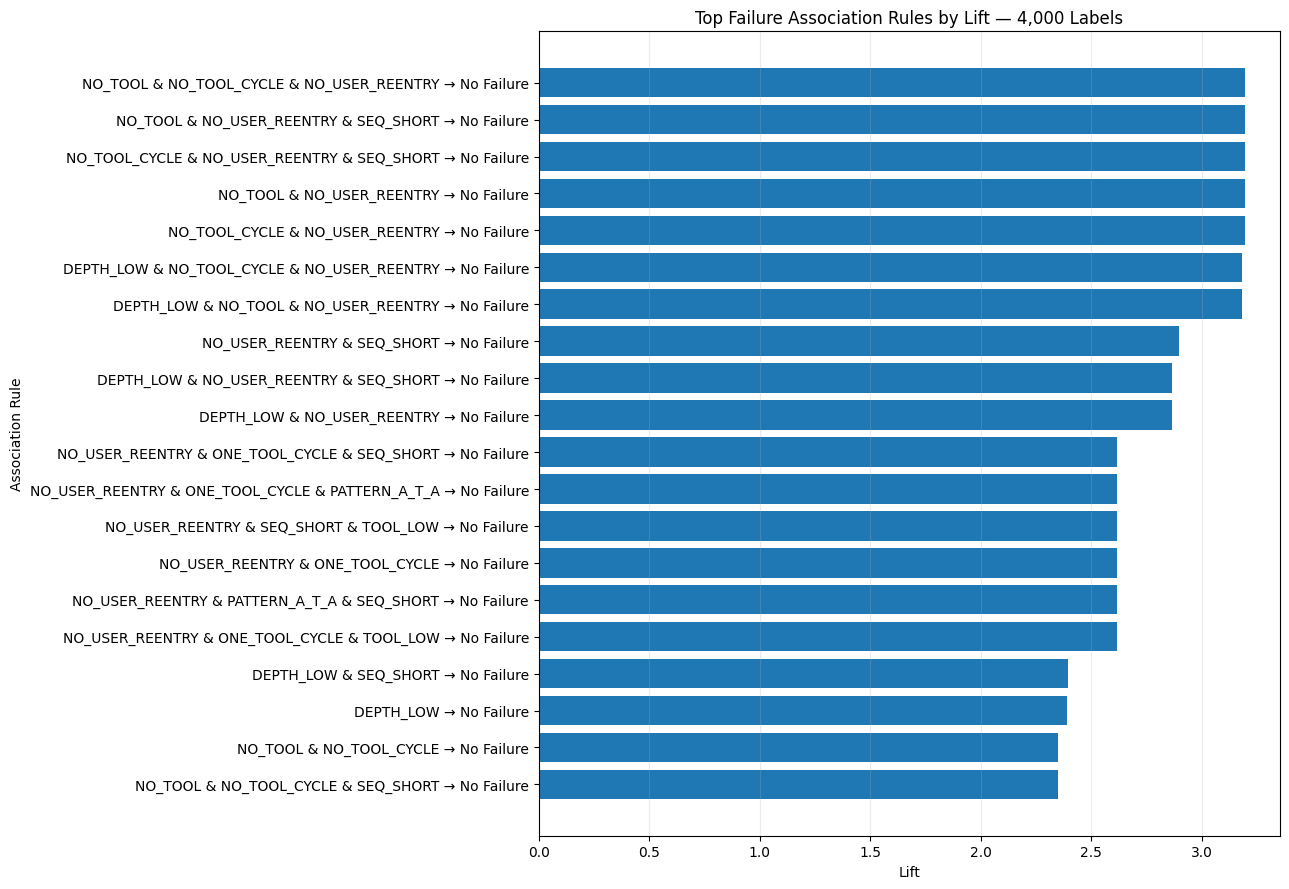

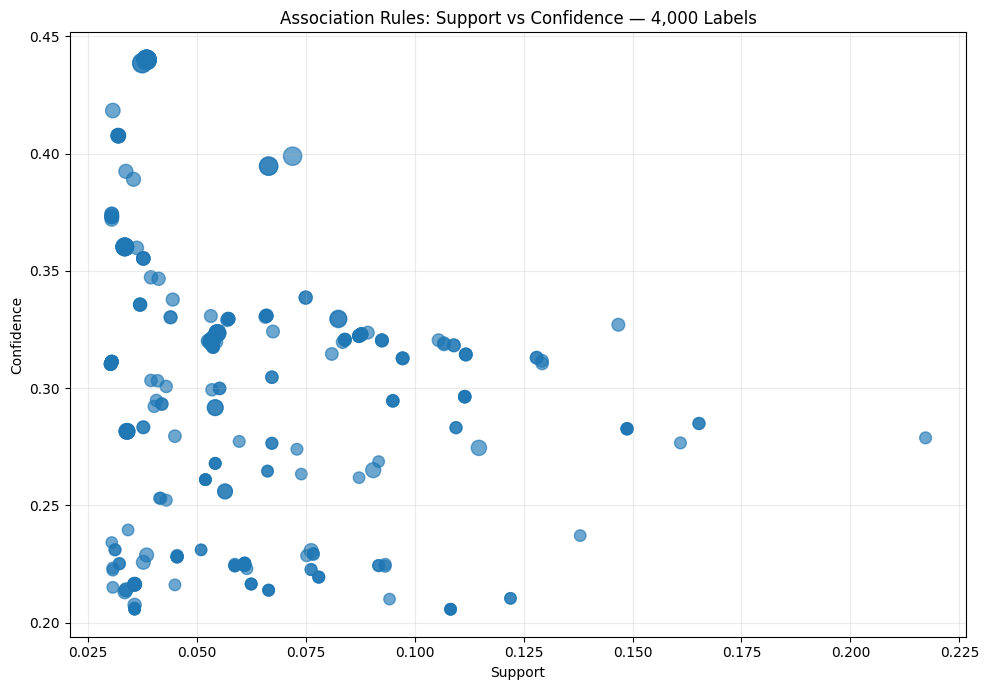

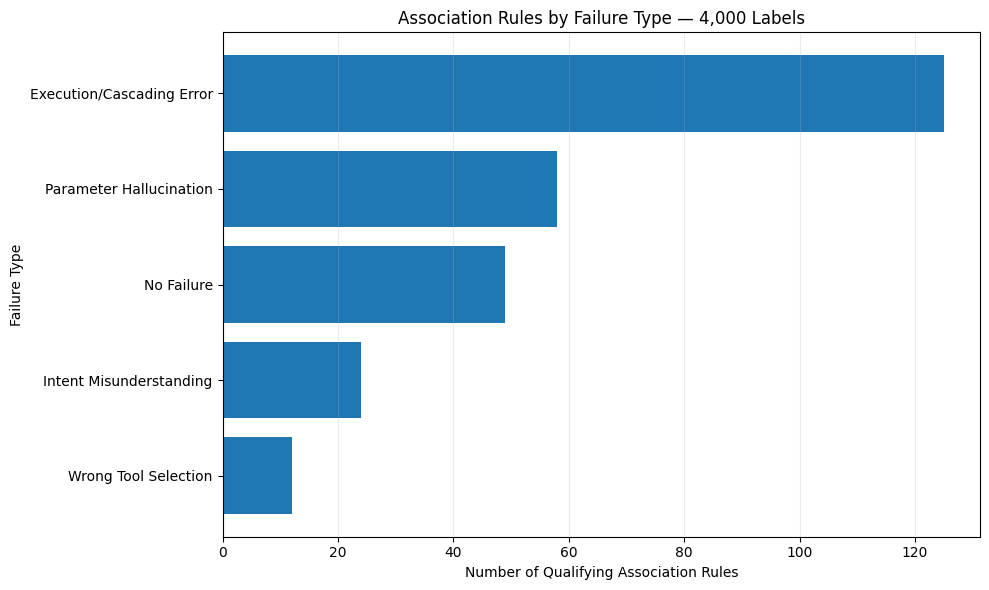


STEP 5.2 — ASSOCIATION RULE MINING COMPLETE — FINAL 4,000
Trajectories analyzed              : 4,000
Unique trajectory IDs              : 4,000
Sequence matching                  : 4,000/4,000
Transaction items                  : 22
Frequent itemsets                  : 1,131
Raw association rules              : 7,484
Failure rules before lift          : 520
Qualifying rules before top-N cap  : 268
Failure rules saved                : 268
Minimum support                    : 3.00%
Minimum confidence                 : 20.00%
Minimum lift                       : 1.10
Mean sequence length               : 7.25
Median sequence length             : 7.00
Maximum sequence length            : 13

Saved tables:
✓ /kaggle/working/toolbench_research/results/tables/step5_association_frequent_itemsets_4000.csv
✓ /kaggle/working/toolbench_research/results/tables/step5_association_failure_rules_before_lift_4000.csv
✓ /kaggle/working/toolbench_research/results/tables/step5_association_failure_rules_400

In [40]:
# ==================================================================================================
# STEP 5.2 — ASSOCIATION RULE MINING
# FINAL 4,000-LABEL VERSION
#
# INPUTS:
#   1. Final GPT-OSS 120B 4,000 labels
#   2. Correct Step 5.1 role sequences extracted from original train-80
#
# METHOD:
#   - Construct structural transaction features
#   - Apriori frequent-itemset mining
#   - Association rules: structural pattern -> failure taxonomy class
#   - Support >= 3%
#   - Confidence >= 20%
#   - Lift >= 1.10
#
# IMPORTANT:
#   - Does NOT use the old 2,105 checkpoint
#   - Does NOT overwrite old Step 5.2 outputs
#   - All new outputs end with _4000
#
# GPU: NOT REQUIRED
# ==================================================================================================


# ==================================================================================================
# 0. INSTALL MLXTEND
# ==================================================================================================

import sys
import subprocess
import importlib.util

if importlib.util.find_spec("mlxtend") is None:

    print("Installing mlxtend...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "mlxtend"
    ])

print("✓ mlxtend available")


# ==================================================================================================
# 1. IMPORTS
# ==================================================================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import (
    apriori,
    association_rules
)

warnings.filterwarnings("ignore")


# ==================================================================================================
# 2. CONFIG
# ==================================================================================================

BASE = "/kaggle/working/toolbench_research"

PROCESSED_DIR = os.path.join(
    BASE,
    "data",
    "processed"
)

TABLE_DIR = os.path.join(
    BASE,
    "results",
    "tables"
)

FIGURE_DIR = os.path.join(
    BASE,
    "results",
    "figures"
)

os.makedirs(
    TABLE_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)


EXPECTED_ROWS = 4000


LABELS = [
    "Intent Misunderstanding",
    "Wrong Tool Selection",
    "Parameter Hallucination",
    "Execution/Cascading Error",
    "No Failure"
]


# ==================================================================================================
# 3. INPUT FILES — FINAL 4,000
# ==================================================================================================

FINAL_LABEL_PATH = os.path.join(
    PROCESSED_DIR,
    "step4_gptoss120b_target4000_FINAL.parquet"
)


SEQUENCE_TABLE = os.path.join(
    TABLE_DIR,
    "step5_role_sequences_gpt4000.csv"
)


# ==================================================================================================
# 4. ASSOCIATION-RULE SETTINGS
# ==================================================================================================

MIN_SUPPORT = 0.03

MIN_CONFIDENCE = 0.20

MIN_LIFT = 1.10

MAX_ITEMSET_LENGTH = 4

TOP_RULES_TO_SAVE = 300

TOP_RULES_TO_PLOT = 20


# ==================================================================================================
# 5. CHECK INPUT FILES
# ==================================================================================================

print("=" * 110)
print("STEP 5.2 — ASSOCIATION RULE MINING — FINAL 4,000 LABELS")
print("=" * 110)


for path in [
    FINAL_LABEL_PATH,
    SEQUENCE_TABLE
]:

    if not os.path.isfile(path):

        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )

    print(
        f"✓ Found: {path}"
    )


# ==================================================================================================
# 6. LOAD FINAL 4,000 GPT LABELS
# ==================================================================================================

df = pd.read_parquet(
    FINAL_LABEL_PATH
)


print(
    f"\nFinal annotation rows loaded : {len(df):,}"
)

print(
    f"Columns                      : {df.columns.tolist()}"
)


# ==================================================================================================
# 7. VALIDATE REQUIRED COLUMNS
# ==================================================================================================

required_gpt_cols = [
    "id",
    "llm_failure_type",
    "step_depth"
]


for col in required_gpt_cols:

    if col not in df.columns:

        raise ValueError(
            f"Missing required annotation column: {col}"
        )


df["id"] = (
    df["id"]
    .astype(str)
    .str.strip()
)


df["llm_failure_type"] = (
    df["llm_failure_type"]
    .astype(str)
    .str.strip()
)


# ==================================================================================================
# 8. KEEP VALID UNIQUE FINAL ANNOTATIONS
# ==================================================================================================

df = df[
    df[
        "llm_failure_type"
    ].isin(
        LABELS
    )
].copy()


df = (
    df
    .drop_duplicates(
        subset=["id"],
        keep="last"
    )
    .reset_index(drop=True)
)


print(
    f"\nValid unique labeled trajectories : {len(df):,}"
)

print(
    f"Unique IDs                        : {df['id'].nunique():,}"
)


if len(df) != EXPECTED_ROWS:

    raise RuntimeError(
        f"Expected {EXPECTED_ROWS:,} final annotations, "
        f"found {len(df):,}."
    )


if df["id"].nunique() != EXPECTED_ROWS:

    raise RuntimeError(
        "Final annotation dataset does not contain "
        "4,000 unique IDs."
    )


# ==================================================================================================
# 9. FAILURE DISTRIBUTION
# ==================================================================================================

failure_counts = (
    df[
        "llm_failure_type"
    ]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)


failure_percent = (
    failure_counts
    /
    len(df)
    *
    100
)


failure_summary = pd.DataFrame({
    "count":
        failure_counts,

    "percent":
        failure_percent
})


print(
    "\nFailure distribution:"
)


print(
    failure_summary.to_string(
        formatters={
            "percent":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


# ==================================================================================================
# 10. CLASS PRIOR PROBABILITIES
# ==================================================================================================

print(
    "\nClass prior probabilities:"
)


for label in LABELS:

    prior = (
        failure_counts[
            label
        ]
        /
        len(df)
    )

    print(
        f"{label:<30} "
        f"{prior:.4f} "
        f"({prior * 100:.2f}%)"
    )


print(
    "\nAssociation thresholds:"
)

print(
    f"Minimum support    : {MIN_SUPPORT:.2%}"
)

print(
    f"Minimum confidence : {MIN_CONFIDENCE:.2%}"
)

print(
    f"Minimum lift       : {MIN_LIFT:.2f}"
)


# ==================================================================================================
# 11. LOAD STEP 5.1 FINAL 4,000 SEQUENCES
# ==================================================================================================

seq = pd.read_csv(
    SEQUENCE_TABLE,
    dtype={
        "id": str
    }
)


required_seq_cols = [
    "id",
    "role_sequence",
    "sequence_length"
]


for col in required_seq_cols:

    if col not in seq.columns:

        raise ValueError(
            f"Step 5.1 sequence table missing column: {col}"
        )


seq["id"] = (
    seq["id"]
    .astype(str)
    .str.strip()
)


# ==================================================================================================
# 12. STEP 5.1 VALIDATION
# ==================================================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "STEP 5.1 FINAL 4,000 SEQUENCE DATA CHECK"
)

print(
    "=" * 110
)


print(
    f"Sequence table rows       : {len(seq):,}"
)

print(
    f"Sequence unique IDs       : {seq['id'].nunique():,}"
)

print(
    f"Missing role sequences    : "
    f"{seq['role_sequence'].isna().sum():,}"
)

print(
    f"Missing sequence lengths  : "
    f"{seq['sequence_length'].isna().sum():,}"
)


if len(seq) != EXPECTED_ROWS:

    raise RuntimeError(
        f"Expected {EXPECTED_ROWS:,} Step 5.1 sequences, "
        f"found {len(seq):,}."
    )


if seq["id"].nunique() != EXPECTED_ROWS:

    raise RuntimeError(
        "Step 5.1 sequence table does not contain "
        "4,000 unique IDs."
    )


if seq["id"].duplicated().any():

    raise RuntimeError(
        "Duplicate IDs found in Step 5.1 sequence table."
    )


if seq["role_sequence"].isna().any():

    raise RuntimeError(
        "Missing role sequences found in Step 5.1."
    )


# ==================================================================================================
# 13. VERIFY EXACT ID ALIGNMENT
# ==================================================================================================

annotation_ids = set(
    df["id"]
)

sequence_ids = set(
    seq["id"]
)


missing_sequences = (
    annotation_ids
    -
    sequence_ids
)


extra_sequences = (
    sequence_ids
    -
    annotation_ids
)


print(
    f"\nFinal-label IDs missing from sequence table : "
    f"{len(missing_sequences):,}"
)

print(
    f"Extra sequence IDs                         : "
    f"{len(extra_sequences):,}"
)


if missing_sequences:

    raise RuntimeError(
        f"{len(missing_sequences):,} final-label IDs "
        "are missing from Step 5.1 sequence table."
    )


if extra_sequences:

    raise RuntimeError(
        f"{len(extra_sequences):,} Step 5.1 IDs "
        "are not present in final annotations."
    )


print(
    "✓ Exact 4,000-ID alignment confirmed"
)


# ==================================================================================================
# 14. PREPARE SEQUENCE MERGE
# ==================================================================================================

seq_merge = (
    seq[
        [
            "id",
            "role_sequence",
            "sequence_length"
        ]
    ]
    .copy()
)


seq_merge = seq_merge.rename(
    columns={
        "role_sequence":
            "step5_role_sequence",

        "sequence_length":
            "step5_sequence_length"
    }
)


# ==================================================================================================
# 15. MERGE FINAL LABELS + FINAL SEQUENCES
# ==================================================================================================

df = df.merge(
    seq_merge,
    on="id",
    how="inner",
    validate="one_to_one"
)


matched_sequence_rows = int(
    df[
        "step5_role_sequence"
    ]
    .notna()
    .sum()
)


print(
    f"\nSequence data matched : "
    f"{matched_sequence_rows:,}/{len(df):,}"
)


if len(df) != EXPECTED_ROWS:

    raise RuntimeError(
        f"Expected {EXPECTED_ROWS:,} merged trajectories, "
        f"found {len(df):,}."
    )


if matched_sequence_rows != EXPECTED_ROWS:

    raise RuntimeError(
        "Not every final trajectory matched Step 5.1."
    )


# ==================================================================================================
# 16. PARSE ROLE SEQUENCES
# ==================================================================================================

def parse_role_sequence(value):

    if value is None:

        return []


    if isinstance(
        value,
        list
    ):

        return [
            str(x).strip()
            for x in value
            if str(x).strip()
        ]


    text = str(
        value
    ).strip()


    if not text:

        return []


    return [
        token.strip()
        for token in text.split(
            "→"
        )
        if token.strip()
    ]


df[
    "role_sequence_list"
] = (
    df[
        "step5_role_sequence"
    ]
    .apply(
        parse_role_sequence
    )
)


df[
    "sequence_length"
] = (
    df[
        "role_sequence_list"
    ]
    .apply(
        len
    )
)


# ==================================================================================================
# 17. SEQUENCE VALIDATION
# ==================================================================================================

empty_sequences = int(
    (
        df[
            "sequence_length"
        ]
        ==
        0
    ).sum()
)


mean_sequence_length = float(
    df[
        "sequence_length"
    ].mean()
)


median_sequence_length = float(
    df[
        "sequence_length"
    ].median()
)


max_sequence_length = int(
    df[
        "sequence_length"
    ].max()
)


print(
    "\n"
    + "=" * 110
)

print(
    "PARSED SEQUENCE VALIDATION"
)

print(
    "=" * 110
)


print(
    f"Empty sequences        : {empty_sequences:,}"
)

print(
    f"Mean sequence length   : {mean_sequence_length:.2f}"
)

print(
    f"Median sequence length : {median_sequence_length:.2f}"
)

print(
    f"Maximum sequence length: {max_sequence_length}"
)


if empty_sequences != 0:

    raise RuntimeError(
        "Empty sequences detected."
    )


if max_sequence_length <= 2:

    raise RuntimeError(
        "Sequence parsing appears incorrect."
    )


# ==================================================================================================
# 18. VALID ROLE TOKENS
# ==================================================================================================

VALID_ROLES = {
    "USER",
    "ASSISTANT",
    "TOOL"
}


unexpected_roles = sorted({
    role

    for sequence in df[
        "role_sequence_list"
    ]

    for role in sequence

    if role not in VALID_ROLES
})


if unexpected_roles:

    raise RuntimeError(
        f"Unexpected role tokens detected: "
        f"{unexpected_roles}"
    )


print(
    "✓ Role-token validation passed"
)


# ==================================================================================================
# 19. TOKEN COUNTS
# ==================================================================================================

def count_token(
    sequence,
    token
):

    return sum(
        item == token
        for item in sequence
    )


df[
    "assistant_count"
] = (
    df[
        "role_sequence_list"
    ]
    .apply(
        lambda sequence:
        count_token(
            sequence,
            "ASSISTANT"
        )
    )
)


df[
    "tool_count_seq"
] = (
    df[
        "role_sequence_list"
    ]
    .apply(
        lambda sequence:
        count_token(
            sequence,
            "TOOL"
        )
    )
)


df[
    "user_count_seq"
] = (
    df[
        "role_sequence_list"
    ]
    .apply(
        lambda sequence:
        count_token(
            sequence,
            "USER"
        )
    )
)


# ==================================================================================================
# 20. TOOL CYCLE COUNT
# ==================================================================================================

def count_tool_cycles(
    sequence
):

    count = 0


    for i in range(
        len(sequence) - 2
    ):

        if (
            sequence[i]
            ==
            "ASSISTANT"

            and

            sequence[i + 1]
            ==
            "TOOL"

            and

            sequence[i + 2]
            ==
            "ASSISTANT"
        ):

            count += 1


    return count


df[
    "tool_cycles"
] = (
    df[
        "role_sequence_list"
    ]
    .apply(
        count_tool_cycles
    )
)


# ==================================================================================================
# 21. CONTIGUOUS PATTERN DETECTION
# ==================================================================================================

def contains_contiguous_pattern(
    sequence,
    pattern
):

    pattern_length = len(
        pattern
    )


    for i in range(
        len(sequence)
        -
        pattern_length
        +
        1
    ):

        if (
            sequence[
                i:
                i + pattern_length
            ]
            ==
            pattern
        ):

            return True


    return False


df[
    "has_A_T_A"
] = (
    df[
        "role_sequence_list"
    ]
    .apply(
        lambda sequence:
        contains_contiguous_pattern(
            sequence,
            [
                "ASSISTANT",
                "TOOL",
                "ASSISTANT"
            ]
        )
    )
)


df[
    "has_A_T_A_T_A"
] = (
    df[
        "role_sequence_list"
    ]
    .apply(
        lambda sequence:
        contains_contiguous_pattern(
            sequence,
            [
                "ASSISTANT",
                "TOOL",
                "ASSISTANT",
                "TOOL",
                "ASSISTANT"
            ]
        )
    )
)


df[
    "has_user_reentry"
] = (
    df[
        "user_count_seq"
    ]
    >=
    2
)


# ==================================================================================================
# 22. DEPTH CATEGORIES
# ==================================================================================================

def depth_category(
    value
):

    value = int(
        value
    )


    if value <= 4:

        return "DEPTH_LOW"


    elif value <= 8:

        return "DEPTH_MEDIUM"


    return "DEPTH_HIGH"


df[
    "depth_group"
] = (
    df[
        "step_depth"
    ]
    .apply(
        depth_category
    )
)


# ==================================================================================================
# 23. SEQUENCE-LENGTH CATEGORIES
# ==================================================================================================

sequence_q33 = float(
    df[
        "sequence_length"
    ]
    .quantile(
        0.33
    )
)


sequence_q67 = float(
    df[
        "sequence_length"
    ]
    .quantile(
        0.67
    )
)


def sequence_category(
    value
):

    if value <= sequence_q33:

        return "SEQ_SHORT"


    elif value <= sequence_q67:

        return "SEQ_MEDIUM"


    return "SEQ_LONG"


df[
    "sequence_group"
] = (
    df[
        "sequence_length"
    ]
    .apply(
        sequence_category
    )
)


print(
    "\nSequence thresholds:"
)

print(
    f"33rd percentile : {sequence_q33:.2f}"
)

print(
    f"67th percentile : {sequence_q67:.2f}"
)


# ==================================================================================================
# 24. TOOL-COUNT CATEGORIES
# ==================================================================================================

tool_q50 = float(
    df[
        "tool_count_seq"
    ]
    .quantile(
        0.50
    )
)


tool_q75 = float(
    df[
        "tool_count_seq"
    ]
    .quantile(
        0.75
    )
)


def tool_category(
    value
):

    if value == 0:

        return "NO_TOOL"


    elif value <= tool_q50:

        return "TOOL_LOW"


    elif value <= tool_q75:

        return "TOOL_MEDIUM"


    return "TOOL_HIGH"


df[
    "tool_group"
] = (
    df[
        "tool_count_seq"
    ]
    .apply(
        tool_category
    )
)


print(
    "\nTool-count thresholds:"
)

print(
    f"Median tool count : {tool_q50:.2f}"
)

print(
    f"75th percentile   : {tool_q75:.2f}"
)


# ==================================================================================================
# 25. TOOL-CYCLE CATEGORIES
# ==================================================================================================

def cycle_category(
    value
):

    if value == 0:

        return "NO_TOOL_CYCLE"


    elif value == 1:

        return "ONE_TOOL_CYCLE"


    return "MULTI_TOOL_CYCLE"


df[
    "cycle_group"
] = (
    df[
        "tool_cycles"
    ]
    .apply(
        cycle_category
    )
)


# ==================================================================================================
# 26. FAILURE ITEM MAPPING
# ==================================================================================================

LABEL_TO_FAILURE_ITEM = {
    "Intent Misunderstanding":
        "FAILURE_INTENT_MISUNDERSTANDING",

    "Wrong Tool Selection":
        "FAILURE_WRONG_TOOL_SELECTION",

    "Parameter Hallucination":
        "FAILURE_PARAMETER_HALLUCINATION",

    "Execution/Cascading Error":
        "FAILURE_EXECUTION_CASCADING_ERROR",

    "No Failure":
        "FAILURE_NO_FAILURE"
}


FAILURE_ITEM_TO_LABEL = {
    value:
        key

    for key, value
    in LABEL_TO_FAILURE_ITEM.items()
}


df[
    "failure_item"
] = (
    df[
        "llm_failure_type"
    ]
    .map(
        LABEL_TO_FAILURE_ITEM
    )
)


if df[
    "failure_item"
].isna().any():

    raise RuntimeError(
        "Failure-item mapping produced missing values."
    )


# ==================================================================================================
# 27. BUILD TRANSACTIONS
# ==================================================================================================

transactions = []


for _, row in df.iterrows():

    items = set()


    # Depth
    items.add(
        row[
            "depth_group"
        ]
    )


    # Sequence length
    items.add(
        row[
            "sequence_group"
        ]
    )


    # Tool count
    items.add(
        row[
            "tool_group"
        ]
    )


    # Tool cycles
    items.add(
        row[
            "cycle_group"
        ]
    )


    # User re-entry
    if row[
        "has_user_reentry"
    ]:

        items.add(
            "USER_REENTRY"
        )

    else:

        items.add(
            "NO_USER_REENTRY"
        )


    # Tool patterns
    if row[
        "has_A_T_A"
    ]:

        items.add(
            "PATTERN_A_T_A"
        )


    if row[
        "has_A_T_A_T_A"
    ]:

        items.add(
            "PATTERN_A_T_A_T_A"
        )


    # Failure outcome
    items.add(
        row[
            "failure_item"
        ]
    )


    transactions.append(
        sorted(
            items
        )
    )


# ==================================================================================================
# 28. SAMPLE TRANSACTIONS
# ==================================================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "SAMPLE TRANSACTIONS"
)

print(
    "=" * 110
)


for i, transaction in enumerate(
    transactions[
        :10
    ],
    start=1
):

    print(
        f"{i}. "
        +
        ", ".join(
            transaction
        )
    )


# ==================================================================================================
# 29. ONE-HOT ENCODE TRANSACTIONS
# ==================================================================================================

all_items = sorted({
    item

    for transaction in transactions

    for item in transaction
})


encoded = pd.DataFrame(
    False,
    index=np.arange(
        len(transactions)
    ),
    columns=all_items
)


for i, transaction in enumerate(
    transactions
):

    encoded.loc[
        i,
        transaction
    ] = True


print(
    "\n"
    + "=" * 110
)

print(
    "TRANSACTION MATRIX"
)

print(
    "=" * 110
)


print(
    f"Rows  : {encoded.shape[0]:,}"
)

print(
    f"Items : {encoded.shape[1]:,}"
)


if encoded.shape[
    0
] != EXPECTED_ROWS:

    raise RuntimeError(
        "Transaction matrix does not contain 4,000 rows."
    )


# ==================================================================================================
# 30. ITEM FREQUENCIES
# ==================================================================================================

item_frequency_df = pd.DataFrame({
    "item":
        encoded.columns,

    "count":
        encoded.sum().values
})


item_frequency_df[
    "percent"
] = (
    item_frequency_df[
        "count"
    ]
    /
    len(encoded)
    *
    100
)


item_frequency_df = (
    item_frequency_df
    .sort_values(
        "count",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nTop transaction items:"
)


print(
    item_frequency_df
    .head(
        20
    )
    .to_string(
        index=False,
        formatters={
            "percent":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


# ==================================================================================================
# 31. APRIORI FREQUENT ITEMSETS
# ==================================================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "APRIORI FREQUENT ITEMSETS"
)

print(
    "=" * 110
)


frequent_itemsets = apriori(
    encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_ITEMSET_LENGTH
)


frequent_itemsets[
    "itemset_length"
] = (
    frequent_itemsets[
        "itemsets"
    ]
    .apply(
        len
    )
)


frequent_itemsets = (
    frequent_itemsets
    .sort_values(
        [
            "support",
            "itemset_length"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    f"Minimum support   : {MIN_SUPPORT:.2%}"
)

print(
    f"Frequent itemsets : {len(frequent_itemsets):,}"
)


if len(
    frequent_itemsets
) == 0:

    raise RuntimeError(
        "Apriori found no frequent itemsets."
    )


# ==================================================================================================
# 32. GENERATE ASSOCIATION RULES
# ==================================================================================================

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE
)


print(
    f"Raw association rules : {len(rules):,}"
)


if len(
    rules
) == 0:

    raise RuntimeError(
        "No association rules were produced."
    )


# ==================================================================================================
# 33. FAILURE RULE HELPERS
# ==================================================================================================

FAILURE_ITEMS = set(
    FAILURE_ITEM_TO_LABEL.keys()
)


def contains_failure_item(
    itemset
):

    return any(
        item in FAILURE_ITEMS
        for item in itemset
    )


def single_failure_consequent(
    itemset
):

    if len(
        itemset
    ) != 1:

        return False


    only_item = next(
        iter(
            itemset
        )
    )


    return (
        only_item
        in FAILURE_ITEMS
    )


# ==================================================================================================
# 34. FILTER STRUCTURE -> FAILURE
# ==================================================================================================

consequent_mask = (
    rules[
        "consequents"
    ]
    .apply(
        single_failure_consequent
    )
)


antecedent_mask = (
    ~rules[
        "antecedents"
    ]
    .apply(
        contains_failure_item
    )
)


failure_rules_before_lift = (
    rules.loc[
        consequent_mask
        &
        antecedent_mask
    ]
    .copy()
)


print(
    f"Rules predicting failure classes before lift filtering : "
    f"{len(failure_rules_before_lift):,}"
)


# ==================================================================================================
# 35. DIAGNOSTIC IF NO FAILURE RULES
# ==================================================================================================

if len(
    failure_rules_before_lift
) == 0:

    print(
        "\nNo structure → failure rules found."
    )


    for failure_item, label in (
        FAILURE_ITEM_TO_LABEL.items()
    ):

        class_rules = rules[
            rules[
                "consequents"
            ]
            .apply(
                lambda x:
                (
                    len(x) == 1
                    and
                    failure_item in x
                )
            )
        ]


        if len(
            class_rules
        ) > 0:

            max_conf = class_rules[
                "confidence"
            ].max()

            print(
                f"{label:<30}: "
                f"{max_conf:.2%}"
            )

        else:

            print(
                f"{label:<30}: "
                "no candidate rules"
            )


    raise RuntimeError(
        "No structure → failure rules were found "
        "at the configured confidence threshold."
    )


# ==================================================================================================
# 36. APPLY LIFT FILTER
# ==================================================================================================

failure_rules = (
    failure_rules_before_lift
    .loc[
        failure_rules_before_lift[
            "lift"
        ]
        >=
        MIN_LIFT
    ]
    .copy()
)


print(
    f"Rules after lift >= {MIN_LIFT:.2f} : "
    f"{len(failure_rules):,}"
)


# ==================================================================================================
# 37. ITEMSET -> TEXT
# ==================================================================================================

def itemset_to_text(
    itemset
):

    return " & ".join(
        sorted(
            str(item)
            for item in itemset
        )
    )


# ==================================================================================================
# 38. FORMAT FINAL FAILURE RULES
# ==================================================================================================

if len(
    failure_rules
) > 0:

    failure_rules[
        "antecedent_text"
    ] = (
        failure_rules[
            "antecedents"
        ]
        .apply(
            itemset_to_text
        )
    )


    failure_rules[
        "consequent_item"
    ] = (
        failure_rules[
            "consequents"
        ]
        .apply(
            lambda x:
            next(
                iter(
                    x
                )
            )
        )
    )


    failure_rules[
        "failure_type"
    ] = (
        failure_rules[
            "consequent_item"
        ]
        .map(
            FAILURE_ITEM_TO_LABEL
        )
    )


    failure_rules = (
        failure_rules
        .sort_values(
            [
                "lift",
                "confidence",
                "support"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )


    total_qualifying_rules = len(
        failure_rules
    )


    failure_rules = (
        failure_rules
        .head(
            TOP_RULES_TO_SAVE
        )
        .copy()
    )


else:

    total_qualifying_rules = 0

    failure_rules = pd.DataFrame(
        columns=[
            "antecedent_text",
            "consequent_item",
            "failure_type",
            "support",
            "confidence",
            "lift",
            "leverage",
            "conviction"
        ]
    )


# ==================================================================================================
# 39. TOP FAILURE ASSOCIATION RULES
# ==================================================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "TOP FAILURE ASSOCIATION RULES"
)

print(
    "=" * 110
)


if len(
    failure_rules
) == 0:

    print(
        "No rules passed the lift threshold."
    )


else:

    display_columns = [
        "antecedent_text",
        "failure_type",
        "support",
        "confidence",
        "lift"
    ]


    print(
        failure_rules[
            display_columns
        ]
        .head(
            30
        )
        .to_string(
            index=False,
            formatters={
                "support":
                    lambda x:
                    f"{x:.2%}",

                "confidence":
                    lambda x:
                    f"{x:.2%}",

                "lift":
                    lambda x:
                    f"{x:.2f}x"
            }
        )
    )


# ==================================================================================================
# 40. OUTPUT PATHS — _4000
# ==================================================================================================

FREQUENT_ITEMSETS_PATH = os.path.join(
    TABLE_DIR,
    "step5_association_frequent_itemsets_4000.csv"
)


ALL_FAILURE_RULES_PATH = os.path.join(
    TABLE_DIR,
    "step5_association_failure_rules_before_lift_4000.csv"
)


RULES_PATH = os.path.join(
    TABLE_DIR,
    "step5_association_failure_rules_4000.csv"
)


BEST_RULES_PATH = os.path.join(
    TABLE_DIR,
    "step5_association_best_rule_per_failure_class_4000.csv"
)


RULE_COUNTS_PATH = os.path.join(
    TABLE_DIR,
    "step5_association_rule_counts_by_failure_type_4000.csv"
)


TRANSACTION_PATH = os.path.join(
    TABLE_DIR,
    "step5_association_transaction_features_4000.csv"
)


ITEM_FREQUENCY_PATH = os.path.join(
    TABLE_DIR,
    "step5_association_item_frequencies_4000.csv"
)


RUN_SUMMARY_PATH = os.path.join(
    TABLE_DIR,
    "step5_association_run_summary_4000.csv"
)


FAILURE_SUMMARY_PATH = os.path.join(
    TABLE_DIR,
    "step5_association_failure_distribution_4000.csv"
)


# ==================================================================================================
# 41. SAVE FAILURE DISTRIBUTION
# ==================================================================================================

failure_summary.to_csv(
    FAILURE_SUMMARY_PATH
)


# ==================================================================================================
# 42. SAVE FREQUENT ITEMSETS
# ==================================================================================================

frequent_save = (
    frequent_itemsets
    .copy()
)


frequent_save[
    "itemsets"
] = (
    frequent_save[
        "itemsets"
    ]
    .apply(
        itemset_to_text
    )
)


frequent_save.to_csv(
    FREQUENT_ITEMSETS_PATH,
    index=False
)


# ==================================================================================================
# 43. SAVE ALL FAILURE RULES BEFORE LIFT
# ==================================================================================================

before_lift_save = (
    failure_rules_before_lift
    .copy()
)


before_lift_save[
    "antecedents"
] = (
    before_lift_save[
        "antecedents"
    ]
    .apply(
        itemset_to_text
    )
)


before_lift_save[
    "consequents"
] = (
    before_lift_save[
        "consequents"
    ]
    .apply(
        itemset_to_text
    )
)


before_lift_save.to_csv(
    ALL_FAILURE_RULES_PATH,
    index=False
)


# ==================================================================================================
# 44. SAVE FINAL FILTERED RULES
# ==================================================================================================

if len(
    failure_rules
) > 0:

    rules_save = (
        failure_rules[
            [
                "antecedent_text",
                "consequent_item",
                "failure_type",
                "support",
                "confidence",
                "lift",
                "leverage",
                "conviction"
            ]
        ]
        .copy()
    )


else:

    rules_save = pd.DataFrame(
        columns=[
            "antecedent_text",
            "consequent_item",
            "failure_type",
            "support",
            "confidence",
            "lift",
            "leverage",
            "conviction"
        ]
    )


rules_save.to_csv(
    RULES_PATH,
    index=False
)


# ==================================================================================================
# 45. BEST RULE PER FAILURE CLASS
# ==================================================================================================

best_records = []


for label in LABELS:

    class_rules = (
        failure_rules[
            failure_rules[
                "failure_type"
            ]
            ==
            label
        ]
        .copy()
    )


    if len(
        class_rules
    ) == 0:

        continue


    best = (
        class_rules
        .sort_values(
            [
                "lift",
                "confidence",
                "support"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
        .iloc[
            0
        ]
    )


    best_records.append({
        "failure_type":
            label,

        "antecedent":
            best[
                "antecedent_text"
            ],

        "support":
            float(
                best[
                    "support"
                ]
            ),

        "confidence":
            float(
                best[
                    "confidence"
                ]
            ),

        "lift":
            float(
                best[
                    "lift"
                ]
            )
    })


best_rules_df = pd.DataFrame(
    best_records
)


if len(
    best_rules_df
) == 0:

    best_rules_df = pd.DataFrame(
        columns=[
            "failure_type",
            "antecedent",
            "support",
            "confidence",
            "lift"
        ]
    )


best_rules_df.to_csv(
    BEST_RULES_PATH,
    index=False
)


print(
    "\n"
    + "=" * 110
)

print(
    "BEST RULE PER FAILURE CLASS"
)

print(
    "=" * 110
)


if len(
    best_rules_df
) == 0:

    print(
        "No failure class has a qualifying rule."
    )


else:

    print(
        best_rules_df.to_string(
            index=False,
            formatters={
                "support":
                    lambda x:
                    f"{x:.2%}",

                "confidence":
                    lambda x:
                    f"{x:.2%}",

                "lift":
                    lambda x:
                    f"{x:.2f}x"
            }
        )
    )


# ==================================================================================================
# 46. RULE COUNTS BY FAILURE TYPE
# ==================================================================================================

if len(
    failure_rules
) > 0:

    rule_counts = (
        failure_rules[
            "failure_type"
        ]
        .value_counts()
        .reindex(
            LABELS,
            fill_value=0
        )
    )


else:

    rule_counts = pd.Series(
        0,
        index=LABELS,
        dtype=int
    )


print(
    "\nRules by failure type:"
)

print(
    rule_counts.to_string()
)


rule_counts.rename(
    "rule_count"
).to_csv(
    RULE_COUNTS_PATH
)


# ==================================================================================================
# 47. SAVE TRANSACTION FEATURES
# ==================================================================================================

transaction_columns = [
    "id",
    "step_depth",
    "llm_failure_type",
    "sequence_length",
    "assistant_count",
    "tool_count_seq",
    "user_count_seq",
    "tool_cycles",
    "depth_group",
    "sequence_group",
    "tool_group",
    "cycle_group",
    "has_A_T_A",
    "has_A_T_A_T_A",
    "has_user_reentry"
]


df[
    transaction_columns
].to_csv(
    TRANSACTION_PATH,
    index=False
)


# ==================================================================================================
# 48. SAVE ITEM FREQUENCIES
# ==================================================================================================

item_frequency_df.to_csv(
    ITEM_FREQUENCY_PATH,
    index=False
)


# ==================================================================================================
# 49. RUN SUMMARY
# ==================================================================================================

run_summary = pd.DataFrame([
    {
        "label_source":
            FINAL_LABEL_PATH,

        "sequence_source":
            SEQUENCE_TABLE,

        "trajectories":
            len(df),

        "unique_ids":
            df[
                "id"
            ].nunique(),

        "transaction_items":
            len(
                all_items
            ),

        "min_support":
            MIN_SUPPORT,

        "min_confidence":
            MIN_CONFIDENCE,

        "min_lift":
            MIN_LIFT,

        "max_itemset_length":
            MAX_ITEMSET_LENGTH,

        "frequent_itemsets":
            len(
                frequent_itemsets
            ),

        "raw_rules":
            len(
                rules
            ),

        "failure_rules_before_lift":
            len(
                failure_rules_before_lift
            ),

        "total_failure_rules_after_lift_before_top_n":
            total_qualifying_rules,

        "failure_rules_saved":
            len(
                failure_rules
            ),

        "sequence_mean":
            mean_sequence_length,

        "sequence_median":
            median_sequence_length,

        "sequence_max":
            max_sequence_length,

        "sequence_q33":
            sequence_q33,

        "sequence_q67":
            sequence_q67,

        "tool_q50":
            tool_q50,

        "tool_q75":
            tool_q75
    }
])


run_summary.to_csv(
    RUN_SUMMARY_PATH,
    index=False
)


# ==================================================================================================
# 50. FIGURE 1 — TOP RULES BY LIFT
# ==================================================================================================

TOP_RULE_FIG = os.path.join(
    FIGURE_DIR,
    "step5_association_top_rules_by_lift_4000.png"
)


if len(
    failure_rules
) > 0:

    plot_df = (
        failure_rules
        .head(
            TOP_RULES_TO_PLOT
        )
        .copy()
    )


    plot_df[
        "rule_text"
    ] = (
        plot_df[
            "antecedent_text"
        ]
        +
        " → "
        +
        plot_df[
            "failure_type"
        ]
    )


    plot_df = (
        plot_df
        .sort_values(
            "lift",
            ascending=True
        )
    )


    plt.figure(
        figsize=(
            13,
            9
        )
    )


    plt.barh(
        plot_df[
            "rule_text"
        ],
        plot_df[
            "lift"
        ]
    )


    plt.xlabel(
        "Lift"
    )

    plt.ylabel(
        "Association Rule"
    )

    plt.title(
        "Top Failure Association Rules by Lift — 4,000 Labels"
    )

    plt.grid(
        axis="x",
        alpha=0.25
    )

    plt.tight_layout()


    plt.savefig(
        TOP_RULE_FIG,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ==================================================================================================
# 51. FIGURE 2 — SUPPORT VS CONFIDENCE
# ==================================================================================================

SCATTER_FIG = os.path.join(
    FIGURE_DIR,
    "step5_association_support_vs_confidence_4000.png"
)


if len(
    failure_rules
) > 0:

    plt.figure(
        figsize=(
            10,
            7
        )
    )


    plt.scatter(
        failure_rules[
            "support"
        ],
        failure_rules[
            "confidence"
        ],
        s=(
            failure_rules[
                "lift"
            ]
            *
            60
        ),
        alpha=0.65
    )


    plt.xlabel(
        "Support"
    )

    plt.ylabel(
        "Confidence"
    )

    plt.title(
        "Association Rules: Support vs Confidence — 4,000 Labels"
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()


    plt.savefig(
        SCATTER_FIG,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ==================================================================================================
# 52. FIGURE 3 — RULE COUNTS
# ==================================================================================================

RULE_COUNT_FIG = os.path.join(
    FIGURE_DIR,
    "step5_association_rule_counts_by_failure_4000.png"
)


plt.figure(
    figsize=(
        10,
        6
    )
)


plot_rule_counts = (
    rule_counts
    .sort_values(
        ascending=True
    )
)


plt.barh(
    plot_rule_counts.index,
    plot_rule_counts.values
)


plt.xlabel(
    "Number of Qualifying Association Rules"
)

plt.ylabel(
    "Failure Type"
)

plt.title(
    "Association Rules by Failure Type — 4,000 Labels"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    RULE_COUNT_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 53. FINAL VALIDATION
# ==================================================================================================

assert len(
    df
) == EXPECTED_ROWS

assert df[
    "id"
].nunique() == EXPECTED_ROWS

assert matched_sequence_rows == EXPECTED_ROWS

assert empty_sequences == 0

assert df[
    "llm_failure_type"
].isin(
    LABELS
).all()

assert len(
    frequent_itemsets
) > 0


required_outputs = [
    FREQUENT_ITEMSETS_PATH,
    ALL_FAILURE_RULES_PATH,
    RULES_PATH,
    BEST_RULES_PATH,
    RULE_COUNTS_PATH,
    TRANSACTION_PATH,
    ITEM_FREQUENCY_PATH,
    RUN_SUMMARY_PATH,
    FAILURE_SUMMARY_PATH
]


for path in required_outputs:

    if not os.path.isfile(
        path
    ):

        raise RuntimeError(
            f"Missing output:\n{path}"
        )


if len(
    failure_rules
) > 0:

    assert (
        failure_rules[
            "confidence"
        ]
        >=
        MIN_CONFIDENCE
    ).all()


    assert (
        failure_rules[
            "lift"
        ]
        >=
        MIN_LIFT
    ).all()


    assert (
        failure_rules[
            "failure_type"
        ]
        .isin(
            LABELS
        )
        .all()
    )


# ==================================================================================================
# 54. FINAL SUMMARY
# ==================================================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "STEP 5.2 — ASSOCIATION RULE MINING COMPLETE — FINAL 4,000"
)

print(
    "=" * 110
)


print(
    f"Trajectories analyzed              : {len(df):,}"
)

print(
    f"Unique trajectory IDs              : {df['id'].nunique():,}"
)

print(
    f"Sequence matching                  : "
    f"{matched_sequence_rows:,}/{len(df):,}"
)

print(
    f"Transaction items                  : {len(all_items):,}"
)

print(
    f"Frequent itemsets                  : {len(frequent_itemsets):,}"
)

print(
    f"Raw association rules              : {len(rules):,}"
)

print(
    f"Failure rules before lift          : "
    f"{len(failure_rules_before_lift):,}"
)

print(
    f"Qualifying rules before top-N cap  : "
    f"{total_qualifying_rules:,}"
)

print(
    f"Failure rules saved                : {len(failure_rules):,}"
)

print(
    f"Minimum support                    : {MIN_SUPPORT:.2%}"
)

print(
    f"Minimum confidence                 : {MIN_CONFIDENCE:.2%}"
)

print(
    f"Minimum lift                       : {MIN_LIFT:.2f}"
)

print(
    f"Mean sequence length               : {mean_sequence_length:.2f}"
)

print(
    f"Median sequence length             : {median_sequence_length:.2f}"
)

print(
    f"Maximum sequence length            : {max_sequence_length}"
)


print(
    "\nSaved tables:"
)


for path in required_outputs:

    print(
        f"✓ {path}"
    )


print(
    "\nSaved figures:"
)


for path in [
    TOP_RULE_FIG,
    SCATTER_FIG,
    RULE_COUNT_FIG
]:

    if os.path.isfile(
        path
    ):

        print(
            f"✓ {path}"
        )


print(
    "\n"
    + "=" * 110
)

print(
    "✓ STEP 5.2 SUCCESSFULLY COMPLETED ON FINAL 4,000 LABELS"
)

print(
    "✓ FINAL STEP 5.1 SEQUENCES USED"
)

print(
    "✓ OLD 2,105-LABEL STEP 5.2 OUTPUTS NOT OVERWRITTEN"
)

print(
    "NEXT: STEP 5.3 — UNSUPERVISED CLUSTERING / BOTTOM-UP TAXONOMY COMPARISON"
)

print(
    "=" * 110
)

STEP 5.3 — UNSUPERVISED CLUSTERING / BOTTOM-UP TAXONOMY COMPARISON — FINAL 4,000

Master setup root:
/kaggle/input/datasets/anandadevnath/master-setup

Final backup selected:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408

Final 4,000 labels:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_gptoss120b_target4000_FINAL.parquet

Train-80 source:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/SOURCE_MASTER_BACKUP/dataset/toolbench_train_80.parquet
STEP 5.3 — UNSUPERVISED CLUSTERING / BOTTOM-UP TAXONOMY COMPARISON — FINAL 4,000
✓ Found: /kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_gptoss120b_target4000_FINAL.parquet
✓ Found: /kaggle/input/datasets/anandadevnath/ma

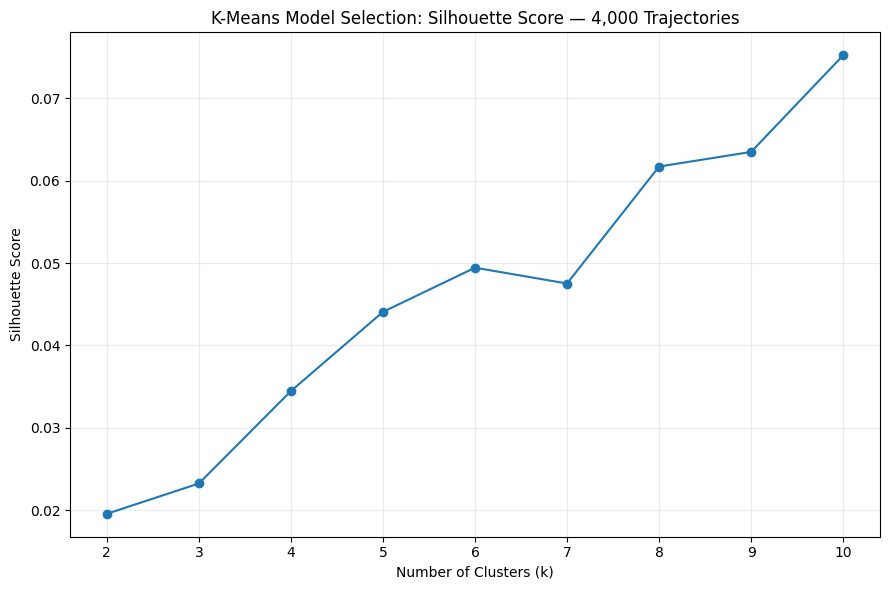

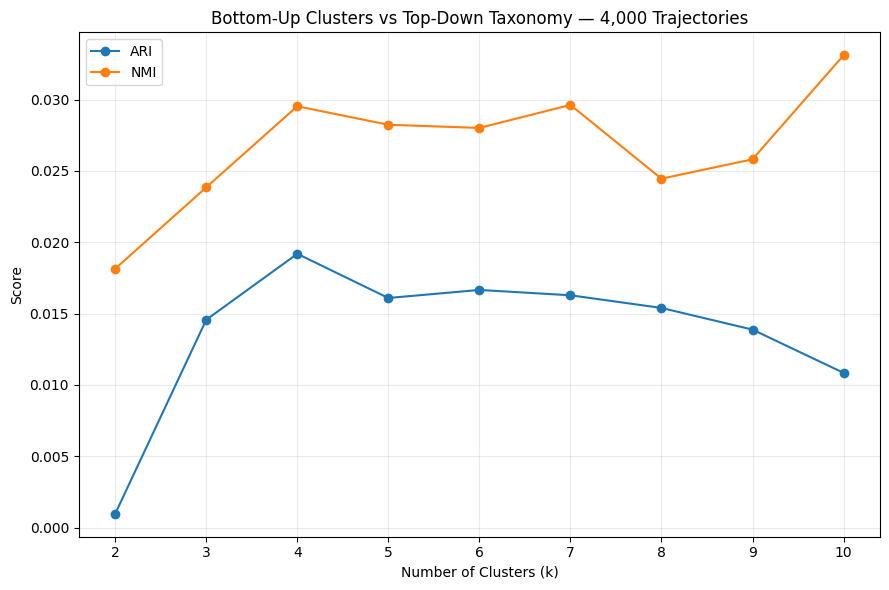

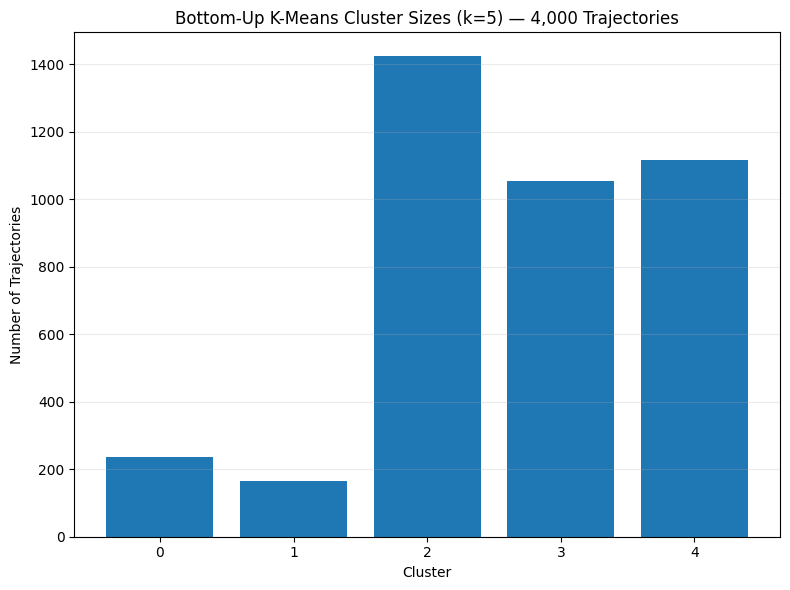

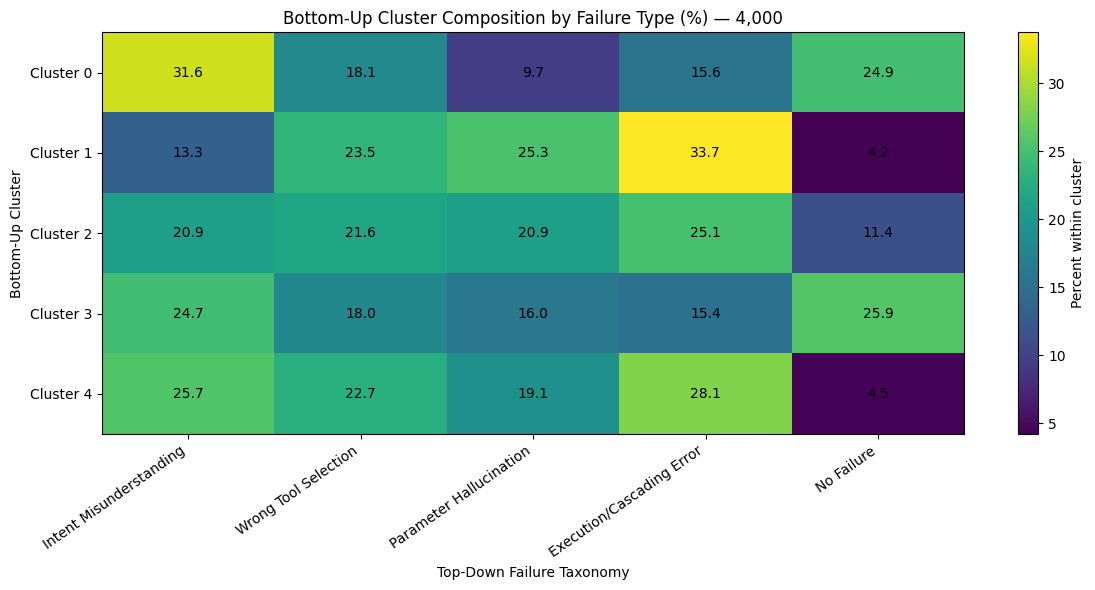

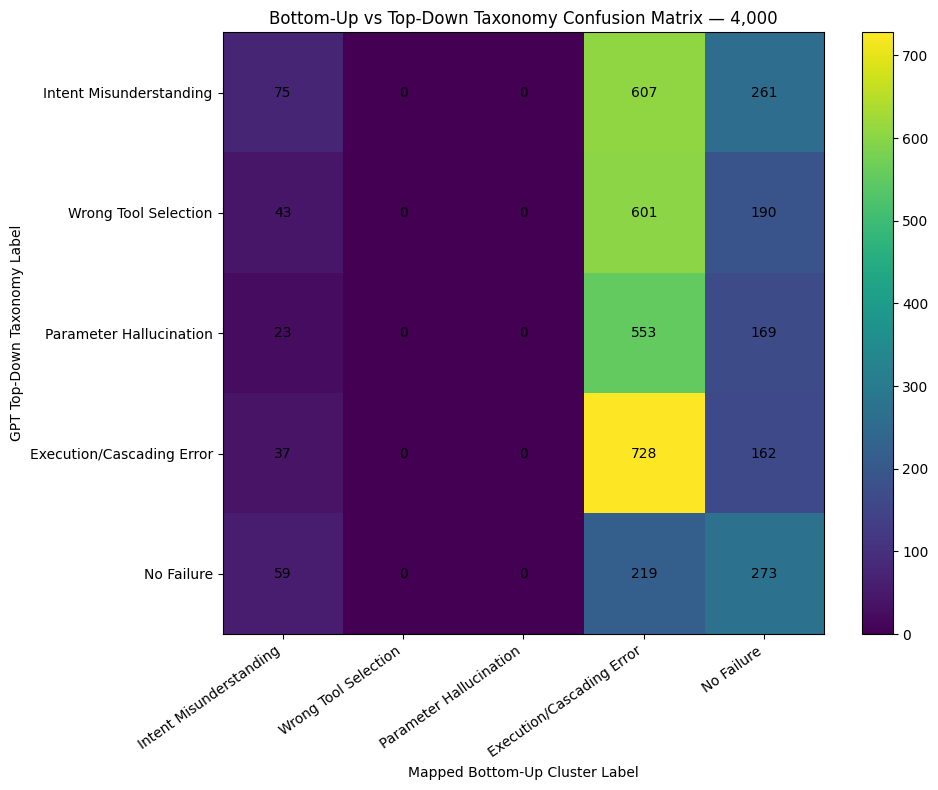

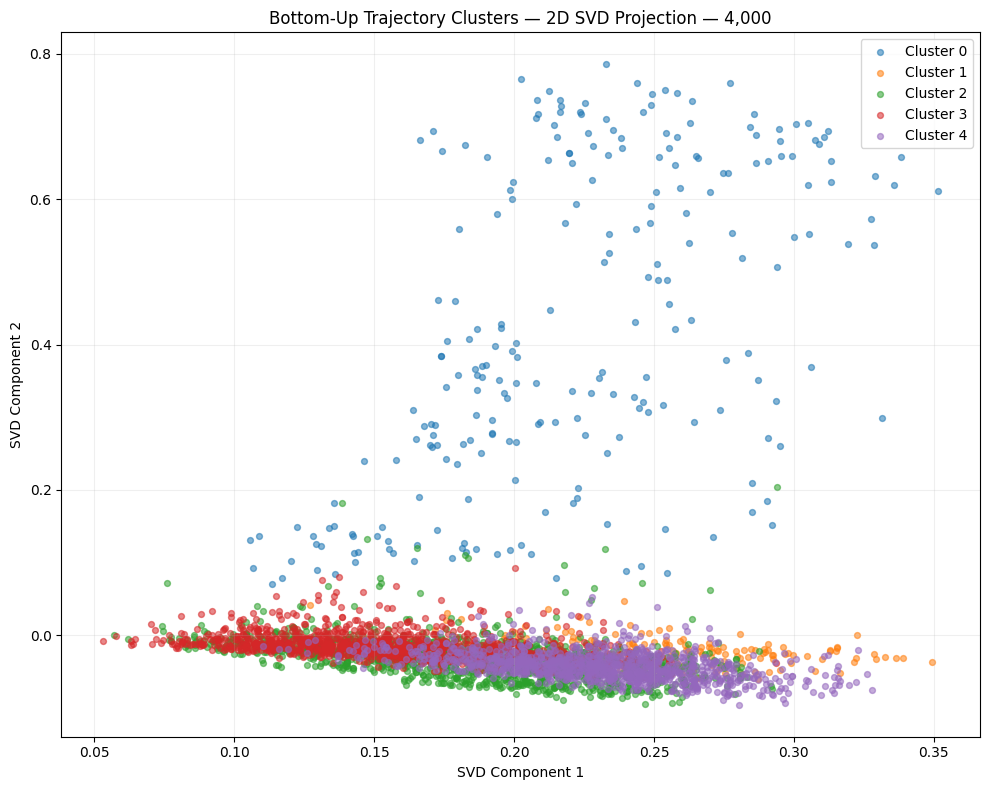


STEP 5.3 — UNSUPERVISED CLUSTERING COMPLETE — FINAL 4,000
Trajectories clustered          : 4,000
Unique trajectory IDs          : 4,000
Usable trajectory texts        : 4,000/4,000
TF-IDF features                : 20,000
SVD components                 : 100
SVD explained variance         : 0.2923 (29.23%)
Best k by silhouette           : 10
Primary comparison k           : 5
K=5 silhouette score           : 0.0441
K=5 ARI vs top-down taxonomy   : 0.0161
K=5 NMI vs top-down taxonomy   : 0.0282
K=5 cluster purity             : 0.2690 (26.90%)
Majority-mapped agreement      : 0.2690 (26.90%)

Cluster sizes:
Cluster 0: 237
Cluster 1: 166
Cluster 2: 1,424
Cluster 3: 1,055
Cluster 4: 1,118

Saved tables:
✓ /kaggle/working/toolbench_research/results/tables/step5_clustering_k_selection_4000.csv
✓ /kaggle/working/toolbench_research/results/tables/step5_clustering_assignments_k5_4000.csv
✓ /kaggle/working/toolbench_research/results/tables/step5_clustering_cluster_to_taxonomy_mapping_4000.csv
✓

In [22]:
# ==================================================================================================
# STEP 5.3 — UNSUPERVISED CLUSTERING / BOTTOM-UP TAXONOMY COMPARISON
# FINAL 4,000-LABEL VERSION
#
# DATA SOURCES:
#   Labels:
#       step4_gptoss120b_target4000_FINAL.parquet
#
#   Raw trajectory text:
#       original toolbench_train_80.parquet conversations
#
# IMPORTANT:
#   ✓ 4,000 final GPT-OSS labels
#   ✓ Raw text recovered from original train-80
#   ✓ Failure labels are NOT used to train TF-IDF / SVD / K-Means
#   ✓ Labels are used only AFTER clustering for external comparison
#   ✓ Validation split remains untouched
#   ✓ New outputs use _4000 suffix
#   ✓ Old Step 5.3 files are not overwritten
#
# METHOD:
#   1. Load final 4,000 labeled IDs
#   2. Recover raw conversations from train-80
#   3. Build text without annotation labels/reasons
#   4. TF-IDF
#   5. Truncated SVD
#   6. K-Means for k = 2..10
#   7. Primary taxonomy comparison at k = 5
#   8. Compare clusters against top-down five-class taxonomy
#
# METRICS:
#   - Silhouette Score
#   - Adjusted Rand Index (ARI)
#   - Normalized Mutual Information (NMI)
#   - Cluster Purity
#   - Majority-mapped agreement
#   - Confusion matrix
#
# GPU: NOT REQUIRED
# ==================================================================================================


# ==================================================================================================
# 0. IMPORTS
# ==================================================================================================

import os
import glob
import re
import ast
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

from sklearn.preprocessing import normalize

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")


# ==================================================================================================
# 1. CONFIG
# ==================================================================================================

BASE = "/kaggle/working/toolbench_research"

PROCESSED_DIR = os.path.join(
    BASE,
    "data",
    "processed"
)

TABLE_DIR = os.path.join(
    BASE,
    "results",
    "tables"
)

FIGURE_DIR = os.path.join(
    BASE,
    "results",
    "figures"
)

os.makedirs(
    PROCESSED_DIR,
    exist_ok=True
)

os.makedirs(
    TABLE_DIR,
    exist_ok=True
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)


EXPECTED_ROWS = 4000

RANDOM_STATE = 42

PRIMARY_K = 5

K_RANGE = range(
    2,
    11
)

MAX_TFIDF_FEATURES = 20000

MIN_DF = 2

MAX_DF = 0.95

NGRAM_RANGE = (
    1,
    2
)

SVD_COMPONENTS = 100

TOP_TERMS_PER_CLUSTER = 20

REPRESENTATIVES_PER_CLUSTER = 5


LABELS = [
    "Intent Misunderstanding",
    "Wrong Tool Selection",
    "Parameter Hallucination",
    "Execution/Cascading Error",
    "No Failure"
]


# ==================================================================================================
# 2. INPUT FILES — UPDATED FOR CURRENT MASTER-SETUP BACKUP
# ==================================================================================================

MASTER_SETUP_ROOT = (
    "/kaggle/input/datasets/anandadevnath/master-setup"
)

if not os.path.isdir(
    MASTER_SETUP_ROOT
):

    raise FileNotFoundError(
        f"Master setup dataset root not found:\n"
        f"{MASTER_SETUP_ROOT}"
    )


backup_candidates = sorted(
    [
        p
        for p in glob.glob(
            os.path.join(
                MASTER_SETUP_ROOT,
                "ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_*"
            )
        )
        if os.path.isdir(p)
    ]
)


if not backup_candidates:

    raise FileNotFoundError(
        "Could not find the final ToolBench master backup inside:\n"
        f"{MASTER_SETUP_ROOT}"
    )


FINAL_BACKUP_ROOT = backup_candidates[-1]

BACKUP_PROCESSED_DIR = os.path.join(
    FINAL_BACKUP_ROOT,
    "CURRENT_RESEARCH",
    "data",
    "processed"
)

BACKUP_TRAIN80_PATH = os.path.join(
    FINAL_BACKUP_ROOT,
    "SOURCE_MASTER_BACKUP",
    "dataset",
    "toolbench_train_80.parquet"
)


# Prefer current working final 4K labels if they exist.
# Otherwise use the authoritative copy from the final master backup.
FINAL_LABEL_CANDIDATES = [

    os.path.join(
        PROCESSED_DIR,
        "step4_gptoss120b_target4000_FINAL.parquet"
    ),

    os.path.join(
        BACKUP_PROCESSED_DIR,
        "step4_gptoss120b_target4000_FINAL.parquet"
    ),

    os.path.join(
        PROCESSED_DIR,
        "step4_gptoss120b_target4000_FINAL.csv"
    ),

    os.path.join(
        BACKUP_PROCESSED_DIR,
        "step4_gptoss120b_target4000_FINAL.csv"
    ),
]


FINAL_LABEL_PATH = next(
    (
        path
        for path in FINAL_LABEL_CANDIDATES
        if os.path.isfile(path)
    ),
    None
)


if FINAL_LABEL_PATH is None:

    raise FileNotFoundError(
        "Could not locate the final 4,000-label Step 4 dataset "
        "in either /kaggle/working or the master backup."
    )


TRAIN80_PATH = BACKUP_TRAIN80_PATH


print("=" * 115)

print(
    "STEP 5.3 — UNSUPERVISED CLUSTERING / "
    "BOTTOM-UP TAXONOMY COMPARISON — FINAL 4,000"
)

print("=" * 115)

print(
    f"\nMaster setup root:\n"
    f"{MASTER_SETUP_ROOT}"
)

print(
    f"\nFinal backup selected:\n"
    f"{FINAL_BACKUP_ROOT}"
)

print(
    f"\nFinal 4,000 labels:\n"
    f"{FINAL_LABEL_PATH}"
)

print(
    f"\nTrain-80 source:\n"
    f"{TRAIN80_PATH}"
)


# ==================================================================================================
# 3. CHECK INPUT FILES
# ==================================================================================================

print("=" * 115)

print(
    "STEP 5.3 — UNSUPERVISED CLUSTERING / "
    "BOTTOM-UP TAXONOMY COMPARISON — FINAL 4,000"
)

print("=" * 115)


for path in [
    FINAL_LABEL_PATH,
    TRAIN80_PATH
]:

    if not os.path.isfile(path):

        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )

    print(
        f"✓ Found: {path}"
    )


# ==================================================================================================
# 4. LOAD FINAL 4,000 LABELS
# ==================================================================================================

if FINAL_LABEL_PATH.lower().endswith(".parquet"):

    labels_df = pd.read_parquet(
        FINAL_LABEL_PATH
    )

elif FINAL_LABEL_PATH.lower().endswith(".csv"):

    labels_df = pd.read_csv(
        FINAL_LABEL_PATH,
        dtype={"id": str},
        low_memory=False
    )

else:

    raise ValueError(
        f"Unsupported final label file type: {FINAL_LABEL_PATH}"
    )


required_label_cols = [
    "id",
    "llm_failure_type"
]


for col in required_label_cols:

    if col not in labels_df.columns:

        raise ValueError(
            f"Final label file missing required column: {col}"
        )


labels_df["id"] = (
    labels_df["id"]
    .astype(str)
    .str.strip()
)


labels_df["llm_failure_type"] = (
    labels_df["llm_failure_type"]
    .astype(str)
    .str.strip()
)


labels_df = labels_df[
    labels_df[
        "llm_failure_type"
    ].isin(
        LABELS
    )
].copy()


labels_df = (
    labels_df
    .drop_duplicates(
        subset=["id"],
        keep="last"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n"
    + "=" * 115
)

print(
    "FINAL LABEL DATASET"
)

print(
    "=" * 115
)


print(
    f"Valid labels : {len(labels_df):,}"
)

print(
    f"Unique IDs   : {labels_df['id'].nunique():,}"
)


if len(
    labels_df
) != EXPECTED_ROWS:

    raise RuntimeError(
        f"Expected {EXPECTED_ROWS:,} final labels, "
        f"found {len(labels_df):,}."
    )


if labels_df[
    "id"
].nunique() != EXPECTED_ROWS:

    raise RuntimeError(
        "Final label file does not contain "
        "4,000 unique IDs."
    )


print(
    "\nTop-down taxonomy distribution:"
)


print(
    labels_df[
        "llm_failure_type"
    ]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
    .to_string()
)


# ==================================================================================================
# 5. LOAD ORIGINAL TRAIN-80
# ==================================================================================================

print(
    "\n"
    + "=" * 115
)

print(
    "LOAD ORIGINAL TRAIN-80 TRAJECTORIES"
)

print(
    "=" * 115
)


train_df = pd.read_parquet(
    TRAIN80_PATH
)


print(
    f"Train rows    : {len(train_df):,}"
)

print(
    f"Train columns : {train_df.columns.tolist()}"
)


if "id" not in train_df.columns:

    raise ValueError(
        "Train-80 file does not contain id."
    )


if "conversations" not in train_df.columns:

    raise ValueError(
        "Train-80 file does not contain conversations."
    )


train_df["id"] = (
    train_df["id"]
    .astype(str)
    .str.strip()
)


if train_df[
    "id"
].duplicated().any():

    raise RuntimeError(
        "Duplicate IDs detected in train-80."
    )


# ==================================================================================================
# 6. VERIFY EXACT ID COVERAGE
# ==================================================================================================

label_ids = set(
    labels_df["id"]
)

train_ids = set(
    train_df["id"]
)


missing_from_train = (
    label_ids
    -
    train_ids
)


print(
    f"\nFinal-label IDs missing from train-80 : "
    f"{len(missing_from_train):,}"
)


if missing_from_train:

    raise RuntimeError(
        f"{len(missing_from_train):,} final-label IDs "
        "are missing from train-80."
    )


print(
    "✓ All 4,000 final-label IDs exist in train-80"
)


# ==================================================================================================
# 7. GET ONLY THE 4,000 RAW TRAJECTORIES
# ==================================================================================================

raw_columns = [
    "id",
    "conversations"
]


for optional_col in [
    "step_depth",
    "depth_bucket",
    "num_turns",
    "role_sequence"
]:

    if optional_col in train_df.columns:

        raw_columns.append(
            optional_col
        )


raw_df = (
    train_df[
        train_df[
            "id"
        ].isin(
            label_ids
        )
    ][
        raw_columns
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print(
    f"\nMatched raw trajectories : {len(raw_df):,}"
)

print(
    f"Matched raw unique IDs   : {raw_df['id'].nunique():,}"
)


if len(
    raw_df
) != EXPECTED_ROWS:

    raise RuntimeError(
        f"Expected {EXPECTED_ROWS:,} matched raw trajectories, "
        f"found {len(raw_df):,}."
    )


# ==================================================================================================
# 8. MERGE RAW TRAJECTORIES WITH LABELS
#
# NOTE:
#   Labels are present only for later evaluation.
#   They are NOT inserted into cluster_text.
# ==================================================================================================

label_columns = [
    "id",
    "llm_failure_type"
]


df = raw_df.merge(
    labels_df[
        label_columns
    ],
    on="id",
    how="inner",
    validate="one_to_one"
)


print(
    "\n"
    + "=" * 115
)

print(
    "MERGED CLUSTERING DATASET"
)

print(
    "=" * 115
)


print(
    f"Rows       : {len(df):,}"
)

print(
    f"Unique IDs : {df['id'].nunique():,}"
)

print(
    f"Columns    : {df.columns.tolist()}"
)


if len(
    df
) != EXPECTED_ROWS:

    raise RuntimeError(
        "Merged clustering dataset does not contain 4,000 rows."
    )


# ==================================================================================================
# 9. TEXT CLEANING
# ==================================================================================================

def clean_text(
    text
):

    if text is None:

        return ""


    text = str(
        text
    )


    if text.lower() in [
        "nan",
        "none",
        "null"
    ]:

        return ""


    text = re.sub(
        r"\s+",
        " ",
        text
    )


    return text.strip()


# ==================================================================================================
# 10. ROBUST TOOLBENCH CONVERSATION -> TEXT
# ==================================================================================================

def conversation_to_text(
    value
):

    if value is None:

        return ""


    # ----------------------------------------------------------------------------------------------
    # Native ToolBench dictionary
    #
    # {
    #   "from": np.array([...]),
    #   "value": np.array([...])
    # }
    # ----------------------------------------------------------------------------------------------

    if isinstance(
        value,
        dict
    ):

        roles = value.get(
            "from",
            []
        )

        texts = value.get(
            "value",
            []
        )


        try:

            roles = list(
                roles
            )

        except Exception:

            roles = [
                roles
            ]


        try:

            texts = list(
                texts
            )

        except Exception:

            texts = [
                texts
            ]


        output = []


        for role, text in zip(
            roles,
            texts
        ):

            role = str(
                role
            ).strip()

            text = str(
                text
            ).strip()


            if text and text.lower() not in [
                "nan",
                "none",
                "null"
            ]:

                output.append(
                    f"{role}: {text}"
                )


        return " ".join(
            output
        )


    # ----------------------------------------------------------------------------------------------
    # List of message dictionaries
    # ----------------------------------------------------------------------------------------------

    if isinstance(
        value,
        (
            list,
            tuple
        )
    ):

        output = []


        for item in value:

            if isinstance(
                item,
                dict
            ):

                role = (
                    item.get(
                        "from"
                    )
                    or
                    item.get(
                        "role"
                    )
                    or
                    ""
                )


                text = (
                    item.get(
                        "value"
                    )
                    or
                    item.get(
                        "content"
                    )
                    or
                    ""
                )


                role = str(
                    role
                ).strip()

                text = str(
                    text
                ).strip()


                if text:

                    output.append(
                        f"{role}: {text}"
                    )


            else:

                text = str(
                    item
                ).strip()


                if text:

                    output.append(
                        text
                    )


        return " ".join(
            output
        )


    # ----------------------------------------------------------------------------------------------
    # String representation
    # ----------------------------------------------------------------------------------------------

    text = str(
        value
    ).strip()


    if not text:

        return ""


    # ----------------------------------------------------------------------------------------------
    # Attempt Python literal parsing
    # ----------------------------------------------------------------------------------------------

    try:

        parsed = ast.literal_eval(
            text
        )


        if isinstance(
            parsed,
            (
                dict,
                list,
                tuple
            )
        ):

            return conversation_to_text(
                parsed
            )


    except Exception:

        pass


    # ----------------------------------------------------------------------------------------------
    # Fall back to original string.
    # ----------------------------------------------------------------------------------------------

    return text


# ==================================================================================================
# 11. BUILD UNSUPERVISED CLUSTERING TEXT
#
# IMPORTANT:
#   We use ONLY original conversation content.
#
#   We do NOT include:
#       llm_failure_type
#       llm_reason
#       annotation_valid
#       GPT explanations
#       cluster labels
#
# ==================================================================================================

df[
    "cluster_text"
] = (
    df[
        "conversations"
    ]
    .apply(
        conversation_to_text
    )
    .apply(
        clean_text
    )
)


# ==================================================================================================
# 12. TEXT VALIDATION
# ==================================================================================================

df[
    "cluster_text_length"
] = (
    df[
        "cluster_text"
    ]
    .str.len()
)


empty_text_count = int(
    (
        df[
            "cluster_text_length"
        ]
        <
        10
    ).sum()
)


print(
    "\n"
    + "=" * 115
)

print(
    "TEXT PREPARATION"
)

print(
    "=" * 115
)


print(
    f"Trajectories               : {len(df):,}"
)

print(
    f"Texts shorter than 10 chars: {empty_text_count:,}"
)

print(
    f"Mean text characters       : "
    f"{df['cluster_text_length'].mean():,.2f}"
)

print(
    f"Median text characters     : "
    f"{df['cluster_text_length'].median():,.2f}"
)

print(
    f"Minimum text characters    : "
    f"{df['cluster_text_length'].min():,}"
)

print(
    f"Maximum text characters    : "
    f"{df['cluster_text_length'].max():,}"
)


if empty_text_count != 0:

    bad_text_path = os.path.join(
        TABLE_DIR,
        "step5_clustering_invalid_text_rows_4000.csv"
    )


    df[
        df[
            "cluster_text_length"
        ]
        <
        10
    ][
        [
            "id",
            "cluster_text_length"
        ]
    ].to_csv(
        bad_text_path,
        index=False
    )


    raise RuntimeError(
        f"{empty_text_count:,} trajectories have unusable text.\n"
        f"Saved to:\n{bad_text_path}"
    )


print(
    "✓ All 4,000 trajectories have usable clustering text"
)


# ==================================================================================================
# 13. LEAKAGE SANITY CHECK
# ==================================================================================================

for forbidden_col in [
    "llm_reason",
    "annotation_valid",
    "raw_response",
    "raw_output"
]:

    if forbidden_col in df.columns:

        raise RuntimeError(
            f"Unexpected annotation column present in clustering "
            f"dataset: {forbidden_col}"
        )


print(
    "✓ Annotation explanation fields are excluded from clustering input"
)


# ==================================================================================================
# 14. TF-IDF
# ==================================================================================================

print(
    "\n"
    + "=" * 115
)

print(
    "TF-IDF VECTORIZATION"
)

print(
    "=" * 115
)


tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=MAX_TFIDF_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF,
    ngram_range=NGRAM_RANGE,
    sublinear_tf=True
)


X_tfidf = tfidf.fit_transform(
    df[
        "cluster_text"
    ]
)


feature_names = np.array(
    tfidf.get_feature_names_out()
)


print(
    f"TF-IDF matrix shape : {X_tfidf.shape}"
)

print(
    f"Vocabulary size     : {len(feature_names):,}"
)


if X_tfidf.shape[
    0
] != EXPECTED_ROWS:

    raise RuntimeError(
        "TF-IDF matrix row count is not 4,000."
    )


if X_tfidf.shape[
    1
] < 10:

    raise RuntimeError(
        "TF-IDF vocabulary unexpectedly small."
    )


# ==================================================================================================
# 15. TRUNCATED SVD
# ==================================================================================================

actual_svd_components = min(
    SVD_COMPONENTS,
    X_tfidf.shape[1] - 1,
    X_tfidf.shape[0] - 1
)


if actual_svd_components < 2:

    raise RuntimeError(
        "Not enough dimensions for TruncatedSVD."
    )


print(
    "\n"
    + "=" * 115
)

print(
    "TRUNCATED SVD"
)

print(
    "=" * 115
)


svd = TruncatedSVD(
    n_components=actual_svd_components,
    random_state=RANDOM_STATE
)


X_svd = svd.fit_transform(
    X_tfidf
)


X_cluster = normalize(
    X_svd
)


explained_variance = float(
    svd
    .explained_variance_ratio_
    .sum()
)


print(
    f"SVD components              : {actual_svd_components}"
)

print(
    f"Explained variance retained : "
    f"{explained_variance:.4f} "
    f"({explained_variance * 100:.2f}%)"
)

print(
    f"Reduced matrix shape        : {X_cluster.shape}"
)


# ==================================================================================================
# 16. TRUE LABELS FOR EXTERNAL EVALUATION ONLY
# ==================================================================================================

true_labels = (
    df[
        "llm_failure_type"
    ]
    .astype(str)
    .values
)


# ==================================================================================================
# 17. EVALUATE K = 2..10
#
# K-Means fitting uses ONLY X_cluster.
#
# ARI/NMI use GPT labels only after each clustering result exists.
# ==================================================================================================

print(
    "\n"
    + "=" * 115
)

print(
    "K-MEANS MODEL SELECTION"
)

print(
    "=" * 115
)


k_results = []


for k in K_RANGE:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
        max_iter=500
    )


    clusters = model.fit_predict(
        X_cluster
    )


    silhouette = silhouette_score(
        X_cluster,
        clusters,
        metric="euclidean"
    )


    ari = adjusted_rand_score(
        true_labels,
        clusters
    )


    nmi = normalized_mutual_info_score(
        true_labels,
        clusters
    )


    cluster_sizes_k = pd.Series(
        clusters
    ).value_counts()


    k_results.append({
        "k":
            k,

        "silhouette_score":
            silhouette,

        "ari_vs_topdown":
            ari,

        "nmi_vs_topdown":
            nmi,

        "inertia":
            model.inertia_,

        "smallest_cluster":
            int(
                cluster_sizes_k.min()
            ),

        "largest_cluster":
            int(
                cluster_sizes_k.max()
            )
    })


    print(
        f"k={k:2d} | "
        f"Silhouette={silhouette:.4f} | "
        f"ARI={ari:.4f} | "
        f"NMI={nmi:.4f} | "
        f"Min cluster={cluster_sizes_k.min():4d} | "
        f"Max cluster={cluster_sizes_k.max():4d}"
    )


k_results_df = pd.DataFrame(
    k_results
)


# ==================================================================================================
# 18. BEST UNSUPERVISED K
# ==================================================================================================

best_silhouette_row = (
    k_results_df
    .sort_values(
        "silhouette_score",
        ascending=False
    )
    .iloc[
        0
    ]
)


best_unsupervised_k = int(
    best_silhouette_row[
        "k"
    ]
)


print(
    "\nBest k by silhouette:"
)

print(
    f"k = {best_unsupervised_k}"
)

print(
    f"Silhouette = "
    f"{best_silhouette_row['silhouette_score']:.4f}"
)

print(
    f"\nPrimary taxonomy-comparison k = {PRIMARY_K}"
)


# ==================================================================================================
# 19. PRIMARY K = 5
# ==================================================================================================

print(
    "\n"
    + "=" * 115
)

print(
    "PRIMARY K=5 BOTTOM-UP CLUSTERING"
)

print(
    "=" * 115
)


kmeans = KMeans(
    n_clusters=PRIMARY_K,
    random_state=RANDOM_STATE,
    n_init=50,
    max_iter=500
)


cluster_ids = kmeans.fit_predict(
    X_cluster
)


df[
    "cluster"
] = cluster_ids.astype(
    int
)


# ==================================================================================================
# 20. PRIMARY METRICS
# ==================================================================================================

silhouette_primary = silhouette_score(
    X_cluster,
    cluster_ids
)


ari_primary = adjusted_rand_score(
    true_labels,
    cluster_ids
)


nmi_primary = normalized_mutual_info_score(
    true_labels,
    cluster_ids
)


print(
    f"Silhouette Score                   : "
    f"{silhouette_primary:.4f}"
)

print(
    f"Adjusted Rand Index (ARI)          : "
    f"{ari_primary:.4f}"
)

print(
    f"Normalized Mutual Information (NMI): "
    f"{nmi_primary:.4f}"
)


# ==================================================================================================
# 21. CLUSTER SIZE DISTRIBUTION
# ==================================================================================================

cluster_sizes = (
    df[
        "cluster"
    ]
    .value_counts()
    .sort_index()
)


print(
    "\nCluster sizes:"
)

print(
    cluster_sizes.to_string()
)


if len(
    cluster_sizes
) != PRIMARY_K:

    raise RuntimeError(
        "K=5 did not produce exactly five non-empty clusters."
    )


# ==================================================================================================
# 22. CLUSTER × TAXONOMY
# ==================================================================================================

cluster_taxonomy_counts = pd.crosstab(
    df[
        "cluster"
    ],
    df[
        "llm_failure_type"
    ]
)


cluster_taxonomy_counts = (
    cluster_taxonomy_counts
    .reindex(
        columns=LABELS,
        fill_value=0
    )
)


cluster_taxonomy_percent = (
    cluster_taxonomy_counts
    .div(
        cluster_taxonomy_counts.sum(
            axis=1
        ),
        axis=0
    )
    *
    100
)


print(
    "\n"
    + "=" * 115
)

print(
    "CLUSTER × TOP-DOWN TAXONOMY COUNTS"
)

print(
    "=" * 115
)


print(
    cluster_taxonomy_counts.to_string()
)


print(
    "\n"
    + "=" * 115
)

print(
    "CLUSTER × TOP-DOWN TAXONOMY PERCENTAGES"
)

print(
    "=" * 115
)


print(
    cluster_taxonomy_percent
    .round(
        2
    )
    .to_string()
)


# ==================================================================================================
# 23. POST-HOC MAJORITY MAPPING
# ==================================================================================================

cluster_to_label = {}

mapping_records = []


for cluster in sorted(
    df[
        "cluster"
    ].unique()
):

    subset = df[
        df[
            "cluster"
        ]
        ==
        cluster
    ]


    label_counts = (
        subset[
            "llm_failure_type"
        ]
        .value_counts()
        .reindex(
            LABELS,
            fill_value=0
        )
    )


    majority_label = (
        label_counts.idxmax()
    )


    majority_count = int(
        label_counts.max()
    )


    cluster_size = len(
        subset
    )


    purity = (
        majority_count
        /
        cluster_size
    )


    cluster_to_label[
        cluster
    ] = majority_label


    mapping_records.append({
        "cluster":
            int(
                cluster
            ),

        "cluster_size":
            int(
                cluster_size
            ),

        "majority_taxonomy_label":
            majority_label,

        "majority_count":
            majority_count,

        "cluster_purity":
            purity
    })


cluster_mapping_df = pd.DataFrame(
    mapping_records
)


print(
    "\n"
    + "=" * 115
)

print(
    "POST-HOC CLUSTER → TAXONOMY MAPPING"
)

print(
    "=" * 115
)


print(
    cluster_mapping_df.to_string(
        index=False,
        formatters={
            "cluster_purity":
                lambda x:
                f"{x:.2%}"
        }
    )
)


# ==================================================================================================
# 24. OVERALL PURITY
# ==================================================================================================

total_correct_majority = int(
    cluster_mapping_df[
        "majority_count"
    ].sum()
)


overall_purity = (
    total_correct_majority
    /
    len(df)
)


print(
    f"\nOverall cluster purity: "
    f"{overall_purity:.4f} "
    f"({overall_purity * 100:.2f}%)"
)


# ==================================================================================================
# 25. MAJORITY-MAPPED AGREEMENT
# ==================================================================================================

df[
    "mapped_cluster_label"
] = (
    df[
        "cluster"
    ]
    .map(
        cluster_to_label
    )
)


mapped_accuracy = float(
    (
        df[
            "mapped_cluster_label"
        ]
        ==
        df[
            "llm_failure_type"
        ]
    )
    .mean()
)


print(
    f"Majority-mapped agreement: "
    f"{mapped_accuracy:.4f} "
    f"({mapped_accuracy * 100:.2f}%)"
)


# ==================================================================================================
# 26. CONFUSION MATRIX
# ==================================================================================================

cm = confusion_matrix(
    df[
        "llm_failure_type"
    ],
    df[
        "mapped_cluster_label"
    ],
    labels=LABELS
)


cm_df = pd.DataFrame(
    cm,
    index=LABELS,
    columns=LABELS
)


cm_df.index.name = "GPT_Taxonomy"

cm_df.columns.name = "Mapped_Cluster_Label"


print(
    "\n"
    + "=" * 115
)

print(
    "CONFUSION MATRIX"
)

print(
    "Rows = GPT taxonomy | Columns = mapped bottom-up cluster"
)

print(
    "=" * 115
)


print(
    cm_df.to_string()
)


# ==================================================================================================
# 27. CLASSIFICATION REPORT
# ==================================================================================================

report_dict = classification_report(
    df[
        "llm_failure_type"
    ],
    df[
        "mapped_cluster_label"
    ],
    labels=LABELS,
    output_dict=True,
    zero_division=0
)


report_df = (
    pd.DataFrame(
        report_dict
    )
    .transpose()
)


print(
    "\n"
    + "=" * 115
)

print(
    "MAPPED CLUSTER CLASSIFICATION REPORT"
)

print(
    "=" * 115
)


print(
    report_df
    .round(
        4
    )
    .to_string()
)


# ==================================================================================================
# 28. TOP TERMS PER CLUSTER
# ==================================================================================================

print(
    "\n"
    + "=" * 115
)

print(
    "TOP TERMS PER CLUSTER"
)

print(
    "=" * 115
)


top_term_records = []


for cluster in sorted(
    df[
        "cluster"
    ].unique()
):

    indices = np.where(
        cluster_ids
        ==
        cluster
    )[0]


    cluster_tfidf = X_tfidf[
        indices
    ]


    mean_scores = np.asarray(
        cluster_tfidf.mean(
            axis=0
        )
    ).ravel()


    top_indices = (
        mean_scores
        .argsort()[
            ::-1
        ][
            :TOP_TERMS_PER_CLUSTER
        ]
    )


    top_terms = feature_names[
        top_indices
    ]


    top_scores = mean_scores[
        top_indices
    ]


    print(
        f"\nCluster {cluster} "
        f"({len(indices):,} trajectories)"
    )


    print(
        ", ".join(
            top_terms.tolist()
        )
    )


    for rank, (
        term,
        score
    ) in enumerate(
        zip(
            top_terms,
            top_scores
        ),
        start=1
    ):

        top_term_records.append({
            "cluster":
                int(
                    cluster
                ),

            "rank":
                rank,

            "term":
                str(
                    term
                ),

            "mean_tfidf":
                float(
                    score
                )
        })


top_terms_df = pd.DataFrame(
    top_term_records
)


# ==================================================================================================
# 29. REPRESENTATIVE EXAMPLES
# ==================================================================================================

distances = kmeans.transform(
    X_cluster
)


representative_records = []


for cluster in sorted(
    df[
        "cluster"
    ].unique()
):

    cluster_indices = np.where(
        cluster_ids
        ==
        cluster
    )[0]


    cluster_distances = distances[
        cluster_indices,
        cluster
    ]


    local_order = np.argsort(
        cluster_distances
    )


    top_representatives = (
        cluster_indices[
            local_order[
                :REPRESENTATIVES_PER_CLUSTER
            ]
        ]
    )


    for rank, idx in enumerate(
        top_representatives,
        start=1
    ):

        row = df.iloc[
            idx
        ]


        representative_records.append({
            "cluster":
                int(
                    cluster
                ),

            "rank":
                rank,

            "id":
                row[
                    "id"
                ],

            "gpt_taxonomy_label":
                row[
                    "llm_failure_type"
                ],

            "mapped_cluster_label":
                row[
                    "mapped_cluster_label"
                ],

            "distance_to_centroid":
                float(
                    distances[
                        idx,
                        cluster
                    ]
                ),

            "trajectory_preview":
                row[
                    "cluster_text"
                ][
                    :1200
                ]
        })


representatives_df = pd.DataFrame(
    representative_records
)


# ==================================================================================================
# 30. CLUSTER DISTRIBUTION LONG FORMAT
# ==================================================================================================

cluster_distribution_records = []


for cluster in cluster_taxonomy_counts.index:

    cluster_total = (
        cluster_taxonomy_counts
        .loc[
            cluster
        ]
        .sum()
    )


    for label in LABELS:

        count = int(
            cluster_taxonomy_counts
            .loc[
                cluster,
                label
            ]
        )


        percent = (
            count
            /
            cluster_total
            *
            100
        )


        cluster_distribution_records.append({
            "cluster":
                int(
                    cluster
                ),

            "failure_type":
                label,

            "count":
                count,

            "percent_within_cluster":
                percent
        })


cluster_distribution_long_df = pd.DataFrame(
    cluster_distribution_records
)


# ==================================================================================================
# 31. OUTPUT PATHS
# ==================================================================================================

K_SELECTION_PATH = os.path.join(
    TABLE_DIR,
    "step5_clustering_k_selection_4000.csv"
)


CLUSTER_ASSIGNMENTS_PATH = os.path.join(
    TABLE_DIR,
    "step5_clustering_assignments_k5_4000.csv"
)


CLUSTER_MAPPING_PATH = os.path.join(
    TABLE_DIR,
    "step5_clustering_cluster_to_taxonomy_mapping_4000.csv"
)


CLUSTER_COUNTS_PATH = os.path.join(
    TABLE_DIR,
    "step5_clustering_taxonomy_crosstab_counts_4000.csv"
)


CLUSTER_PERCENT_PATH = os.path.join(
    TABLE_DIR,
    "step5_clustering_taxonomy_crosstab_percent_4000.csv"
)


CLUSTER_DISTRIBUTION_PATH = os.path.join(
    TABLE_DIR,
    "step5_clustering_taxonomy_distribution_long_4000.csv"
)


TOP_TERMS_PATH = os.path.join(
    TABLE_DIR,
    "step5_clustering_top_terms_per_cluster_4000.csv"
)


REPRESENTATIVES_PATH = os.path.join(
    TABLE_DIR,
    "step5_clustering_representative_examples_4000.csv"
)


CONFUSION_PATH = os.path.join(
    TABLE_DIR,
    "step5_clustering_mapped_confusion_matrix_4000.csv"
)


CLASSIFICATION_REPORT_PATH = os.path.join(
    TABLE_DIR,
    "step5_clustering_mapped_classification_report_4000.csv"
)


METRICS_PATH = os.path.join(
    TABLE_DIR,
    "step5_clustering_metrics_4000.csv"
)


TEXT_STATS_PATH = os.path.join(
    TABLE_DIR,
    "step5_clustering_text_statistics_4000.csv"
)


# ==================================================================================================
# 32. SAVE K SELECTION
# ==================================================================================================

k_results_df.to_csv(
    K_SELECTION_PATH,
    index=False
)


# ==================================================================================================
# 33. SAVE CLUSTER ASSIGNMENTS
# ==================================================================================================

cluster_output_cols = [
    "id",
    "llm_failure_type",
    "cluster",
    "mapped_cluster_label",
    "cluster_text_length"
]


if "step_depth" in df.columns:

    cluster_output_cols.insert(
        1,
        "step_depth"
    )


df[
    cluster_output_cols
].to_csv(
    CLUSTER_ASSIGNMENTS_PATH,
    index=False
)


# ==================================================================================================
# 34. SAVE MAPPING
# ==================================================================================================

cluster_mapping_df.to_csv(
    CLUSTER_MAPPING_PATH,
    index=False
)


# ==================================================================================================
# 35. SAVE CROSS-TABS
# ==================================================================================================

cluster_taxonomy_counts.to_csv(
    CLUSTER_COUNTS_PATH
)


cluster_taxonomy_percent.to_csv(
    CLUSTER_PERCENT_PATH
)


cluster_distribution_long_df.to_csv(
    CLUSTER_DISTRIBUTION_PATH,
    index=False
)


# ==================================================================================================
# 36. SAVE TOP TERMS
# ==================================================================================================

top_terms_df.to_csv(
    TOP_TERMS_PATH,
    index=False
)


# ==================================================================================================
# 37. SAVE REPRESENTATIVES
# ==================================================================================================

representatives_df.to_csv(
    REPRESENTATIVES_PATH,
    index=False
)


# ==================================================================================================
# 38. SAVE CONFUSION MATRIX
# ==================================================================================================

cm_df.to_csv(
    CONFUSION_PATH
)


# ==================================================================================================
# 39. SAVE CLASSIFICATION REPORT
# ==================================================================================================

report_df.to_csv(
    CLASSIFICATION_REPORT_PATH
)


# ==================================================================================================
# 40. SAVE MAIN METRICS
# ==================================================================================================

metrics_df = pd.DataFrame([
    {
        "trajectories":
            len(
                df
            ),

        "primary_k":
            PRIMARY_K,

        "best_k_by_silhouette":
            best_unsupervised_k,

        "tfidf_features":
            X_tfidf.shape[
                1
            ],

        "svd_components":
            actual_svd_components,

        "svd_explained_variance":
            explained_variance,

        "silhouette_k5":
            silhouette_primary,

        "ari_vs_topdown":
            ari_primary,

        "nmi_vs_topdown":
            nmi_primary,

        "cluster_purity":
            overall_purity,

        "mapped_cluster_agreement":
            mapped_accuracy,

        "random_state":
            RANDOM_STATE
    }
])


metrics_df.to_csv(
    METRICS_PATH,
    index=False
)


# ==================================================================================================
# 41. SAVE TEXT STATISTICS
# ==================================================================================================

text_stats_df = pd.DataFrame([
    {
        "trajectories":
            len(
                df
            ),

        "empty_or_short_texts":
            empty_text_count,

        "mean_text_characters":
            df[
                "cluster_text_length"
            ].mean(),

        "median_text_characters":
            df[
                "cluster_text_length"
            ].median(),

        "min_text_characters":
            df[
                "cluster_text_length"
            ].min(),

        "max_text_characters":
            df[
                "cluster_text_length"
            ].max()
    }
])


text_stats_df.to_csv(
    TEXT_STATS_PATH,
    index=False
)


# ==================================================================================================
# 42. FIGURE 1 — SILHOUETTE BY K
# ==================================================================================================

SILHOUETTE_FIG = os.path.join(
    FIGURE_DIR,
    "step5_clustering_silhouette_by_k_4000.png"
)


plt.figure(
    figsize=(
        9,
        6
    )
)


plt.plot(
    k_results_df[
        "k"
    ],
    k_results_df[
        "silhouette_score"
    ],
    marker="o"
)


plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "K-Means Model Selection: Silhouette Score — 4,000 Trajectories"
)

plt.xticks(
    list(
        K_RANGE
    )
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    SILHOUETTE_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 43. FIGURE 2 — ARI / NMI BY K
# ==================================================================================================

COMPARISON_FIG = os.path.join(
    FIGURE_DIR,
    "step5_clustering_external_metrics_by_k_4000.png"
)


plt.figure(
    figsize=(
        9,
        6
    )
)


plt.plot(
    k_results_df[
        "k"
    ],
    k_results_df[
        "ari_vs_topdown"
    ],
    marker="o",
    label="ARI"
)


plt.plot(
    k_results_df[
        "k"
    ],
    k_results_df[
        "nmi_vs_topdown"
    ],
    marker="o",
    label="NMI"
)


plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Bottom-Up Clusters vs Top-Down Taxonomy — 4,000 Trajectories"
)

plt.xticks(
    list(
        K_RANGE
    )
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    COMPARISON_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 44. FIGURE 3 — CLUSTER SIZES
# ==================================================================================================

CLUSTER_SIZE_FIG = os.path.join(
    FIGURE_DIR,
    "step5_clustering_cluster_sizes_k5_4000.png"
)


plt.figure(
    figsize=(
        8,
        6
    )
)


plt.bar(
    cluster_sizes.index.astype(
        str
    ),
    cluster_sizes.values
)


plt.xlabel(
    "Cluster"
)

plt.ylabel(
    "Number of Trajectories"
)

plt.title(
    "Bottom-Up K-Means Cluster Sizes (k=5) — 4,000 Trajectories"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    CLUSTER_SIZE_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 45. FIGURE 4 — TAXONOMY COMPOSITION HEATMAP
# ==================================================================================================

HEATMAP_FIG = os.path.join(
    FIGURE_DIR,
    "step5_clustering_taxonomy_heatmap_4000.png"
)


heatmap_data = (
    cluster_taxonomy_percent
    .values
)


fig, ax = plt.subplots(
    figsize=(
        12,
        6
    )
)


im = ax.imshow(
    heatmap_data,
    aspect="auto"
)


ax.set_xticks(
    np.arange(
        len(
            LABELS
        )
    )
)


ax.set_xticklabels(
    LABELS,
    rotation=35,
    ha="right"
)


ax.set_yticks(
    np.arange(
        len(
            cluster_taxonomy_percent
        )
    )
)


ax.set_yticklabels([
    f"Cluster {cluster}"
    for cluster
    in cluster_taxonomy_percent.index
])


ax.set_xlabel(
    "Top-Down Failure Taxonomy"
)

ax.set_ylabel(
    "Bottom-Up Cluster"
)

ax.set_title(
    "Bottom-Up Cluster Composition by Failure Type (%) — 4,000"
)


for i in range(
    heatmap_data.shape[
        0
    ]
):

    for j in range(
        heatmap_data.shape[
            1
        ]
    ):

        ax.text(
            j,
            i,
            f"{heatmap_data[i, j]:.1f}",
            ha="center",
            va="center"
        )


fig.colorbar(
    im,
    ax=ax,
    label="Percent within cluster"
)


plt.tight_layout()


plt.savefig(
    HEATMAP_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 46. FIGURE 5 — CONFUSION MATRIX
# ==================================================================================================

CONFUSION_FIG = os.path.join(
    FIGURE_DIR,
    "step5_clustering_mapped_confusion_matrix_4000.png"
)


fig, ax = plt.subplots(
    figsize=(
        10,
        8
    )
)


im = ax.imshow(
    cm
)


ax.set_xticks(
    np.arange(
        len(
            LABELS
        )
    )
)


ax.set_yticks(
    np.arange(
        len(
            LABELS
        )
    )
)


ax.set_xticklabels(
    LABELS,
    rotation=35,
    ha="right"
)


ax.set_yticklabels(
    LABELS
)


ax.set_xlabel(
    "Mapped Bottom-Up Cluster Label"
)

ax.set_ylabel(
    "GPT Top-Down Taxonomy Label"
)

ax.set_title(
    "Bottom-Up vs Top-Down Taxonomy Confusion Matrix — 4,000"
)


for i in range(
    cm.shape[
        0
    ]
):

    for j in range(
        cm.shape[
            1
        ]
    ):

        ax.text(
            j,
            i,
            str(
                cm[
                    i,
                    j
                ]
            ),
            ha="center",
            va="center"
        )


fig.colorbar(
    im,
    ax=ax
)


plt.tight_layout()


plt.savefig(
    CONFUSION_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 47. FIGURE 6 — 2D SVD PROJECTION
# ==================================================================================================

CLUSTER_2D_FIG = os.path.join(
    FIGURE_DIR,
    "step5_clustering_2d_projection_4000.png"
)


plt.figure(
    figsize=(
        10,
        8
    )
)


for cluster in sorted(
    df[
        "cluster"
    ].unique()
):

    mask = (
        df[
            "cluster"
        ].values
        ==
        cluster
    )


    plt.scatter(
        X_svd[
            mask,
            0
        ],
        X_svd[
            mask,
            1
        ],
        s=18,
        alpha=0.55,
        label=f"Cluster {cluster}"
    )


plt.xlabel(
    "SVD Component 1"
)

plt.ylabel(
    "SVD Component 2"
)

plt.title(
    "Bottom-Up Trajectory Clusters — 2D SVD Projection — 4,000"
)

plt.legend()

plt.grid(
    alpha=0.20
)

plt.tight_layout()


plt.savefig(
    CLUSTER_2D_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 48. FINAL VALIDATION
# ==================================================================================================

assert len(
    df
) == EXPECTED_ROWS


assert df[
    "id"
].nunique() == EXPECTED_ROWS


assert X_tfidf.shape[
    0
] == EXPECTED_ROWS


assert X_cluster.shape[
    0
] == EXPECTED_ROWS


assert df[
    "cluster"
].nunique() == PRIMARY_K


assert df[
    "llm_failure_type"
].isin(
    LABELS
).all()


assert df[
    "mapped_cluster_label"
].isin(
    LABELS
).all()


assert empty_text_count == 0


assert np.isfinite(
    silhouette_primary
)


assert np.isfinite(
    ari_primary
)


assert np.isfinite(
    nmi_primary
)


required_outputs = [
    K_SELECTION_PATH,
    CLUSTER_ASSIGNMENTS_PATH,
    CLUSTER_MAPPING_PATH,
    CLUSTER_COUNTS_PATH,
    CLUSTER_PERCENT_PATH,
    CLUSTER_DISTRIBUTION_PATH,
    TOP_TERMS_PATH,
    REPRESENTATIVES_PATH,
    CONFUSION_PATH,
    CLASSIFICATION_REPORT_PATH,
    METRICS_PATH,
    TEXT_STATS_PATH
]


for path in required_outputs:

    if not os.path.isfile(
        path
    ):

        raise RuntimeError(
            f"Missing output:\n{path}"
        )


required_figures = [
    SILHOUETTE_FIG,
    COMPARISON_FIG,
    CLUSTER_SIZE_FIG,
    HEATMAP_FIG,
    CONFUSION_FIG,
    CLUSTER_2D_FIG
]


for path in required_figures:

    if not os.path.isfile(
        path
    ):

        raise RuntimeError(
            f"Missing figure:\n{path}"
        )


# ==================================================================================================
# 49. FINAL SUMMARY
# ==================================================================================================

print(
    "\n"
    + "=" * 115
)

print(
    "STEP 5.3 — UNSUPERVISED CLUSTERING COMPLETE — FINAL 4,000"
)

print(
    "=" * 115
)


print(
    f"Trajectories clustered          : "
    f"{len(df):,}"
)

print(
    f"Unique trajectory IDs          : "
    f"{df['id'].nunique():,}"
)

print(
    f"Usable trajectory texts        : "
    f"{len(df) - empty_text_count:,}/{len(df):,}"
)

print(
    f"TF-IDF features                : "
    f"{X_tfidf.shape[1]:,}"
)

print(
    f"SVD components                 : "
    f"{actual_svd_components}"
)

print(
    f"SVD explained variance         : "
    f"{explained_variance:.4f} "
    f"({explained_variance * 100:.2f}%)"
)

print(
    f"Best k by silhouette           : "
    f"{best_unsupervised_k}"
)

print(
    f"Primary comparison k           : "
    f"{PRIMARY_K}"
)

print(
    f"K=5 silhouette score           : "
    f"{silhouette_primary:.4f}"
)

print(
    f"K=5 ARI vs top-down taxonomy   : "
    f"{ari_primary:.4f}"
)

print(
    f"K=5 NMI vs top-down taxonomy   : "
    f"{nmi_primary:.4f}"
)

print(
    f"K=5 cluster purity             : "
    f"{overall_purity:.4f} "
    f"({overall_purity * 100:.2f}%)"
)

print(
    f"Majority-mapped agreement      : "
    f"{mapped_accuracy:.4f} "
    f"({mapped_accuracy * 100:.2f}%)"
)


print(
    "\nCluster sizes:"
)


for cluster, size in cluster_sizes.items():

    print(
        f"Cluster {cluster}: {size:,}"
    )


print(
    "\nSaved tables:"
)


for path in required_outputs:

    print(
        f"✓ {path}"
    )


print(
    "\nSaved figures:"
)


for path in required_figures:

    print(
        f"✓ {path}"
    )


print(
    "\n"
    + "=" * 115
)

print(
    "✓ STEP 5.3 SUCCESSFULLY COMPLETED ON FINAL 4,000 LABELS"
)

print(
    "✓ CLUSTERING TEXT RECOVERED FROM ORIGINAL TRAIN-80"
)

print(
    "✓ GPT LABELS USED ONLY FOR POST-HOC EXTERNAL EVALUATION"
)

print(
    "✓ VALIDATION SPLIT REMAINS UNTOUCHED"
)

print(
    "✓ EXISTING STEP 5.3 OUTPUTS NOT OVERWRITTEN"
)

print(
    "✓ STEP 5 — BOTTOM-UP TAXONOMY DISCOVERY COMPLETE"
)

print(
    "=" * 115
)

STEP 6B — ENHANCED XGBOOST FAILURE PREDICTION

Master setup root:
/kaggle/input/datasets/anandadevnath/master-setup

Final backup:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408

✓ Final 4,000 GPT-OSS labels:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_gptoss120b_target4000_FINAL.parquet

✓ Human Gold 300 labels:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_human_gold_FINAL_300.parquet

✓ ToolBench train-80 raw trajectories:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/SOURCE_MASTER_BACKUP/dataset/toolbench_train_80.parquet

✓ Step-3 train structural features:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10

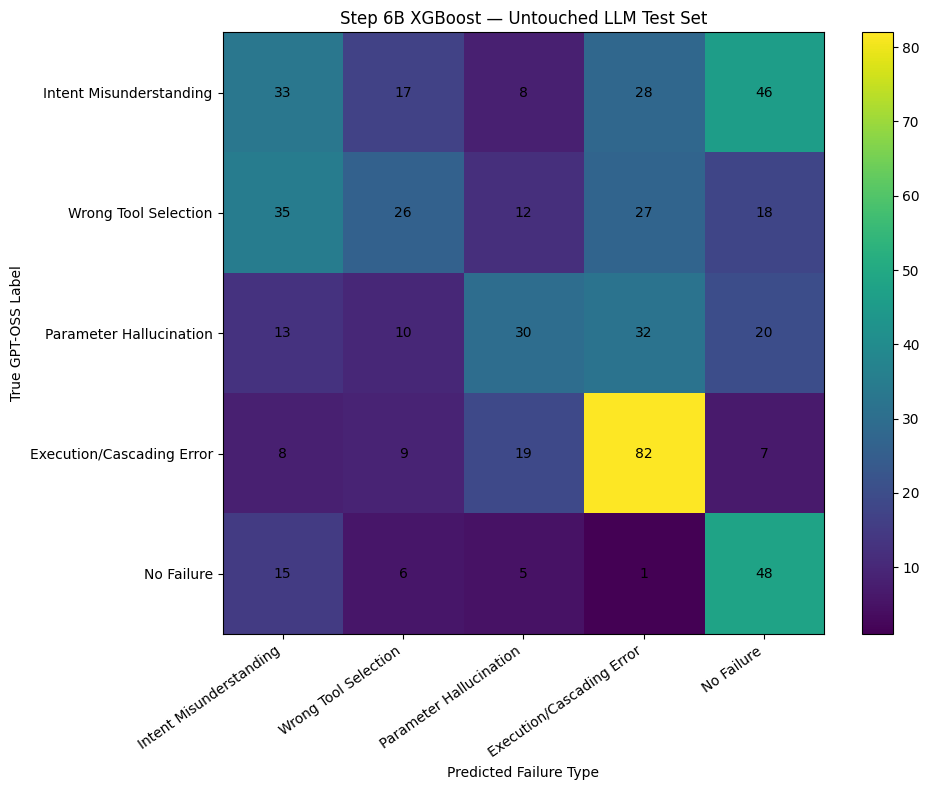

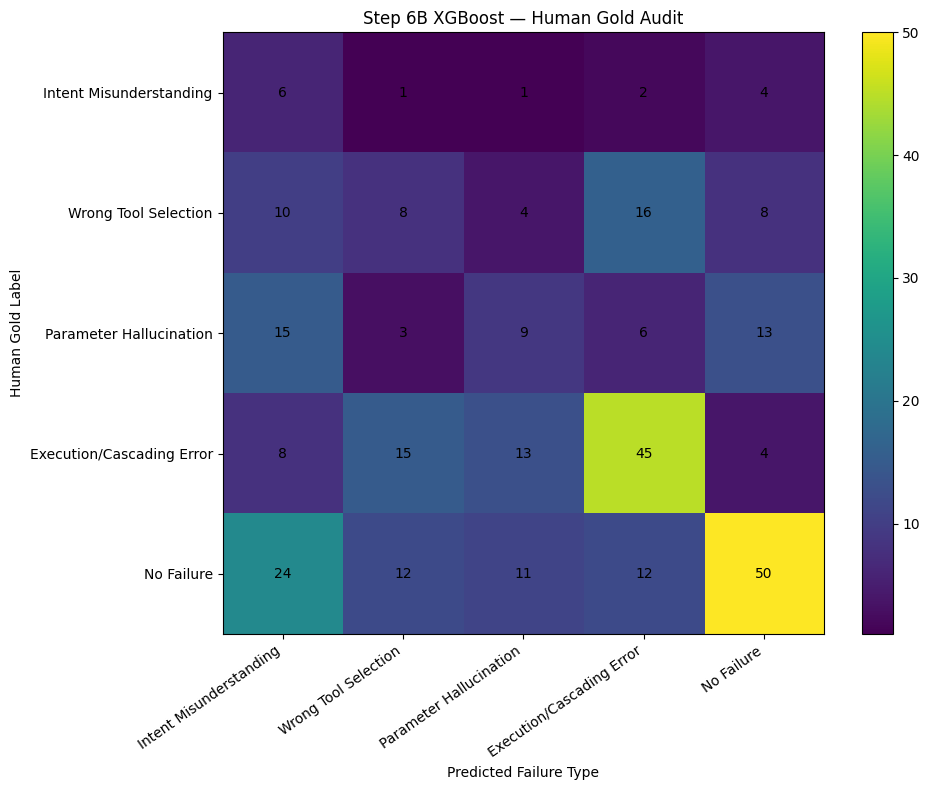

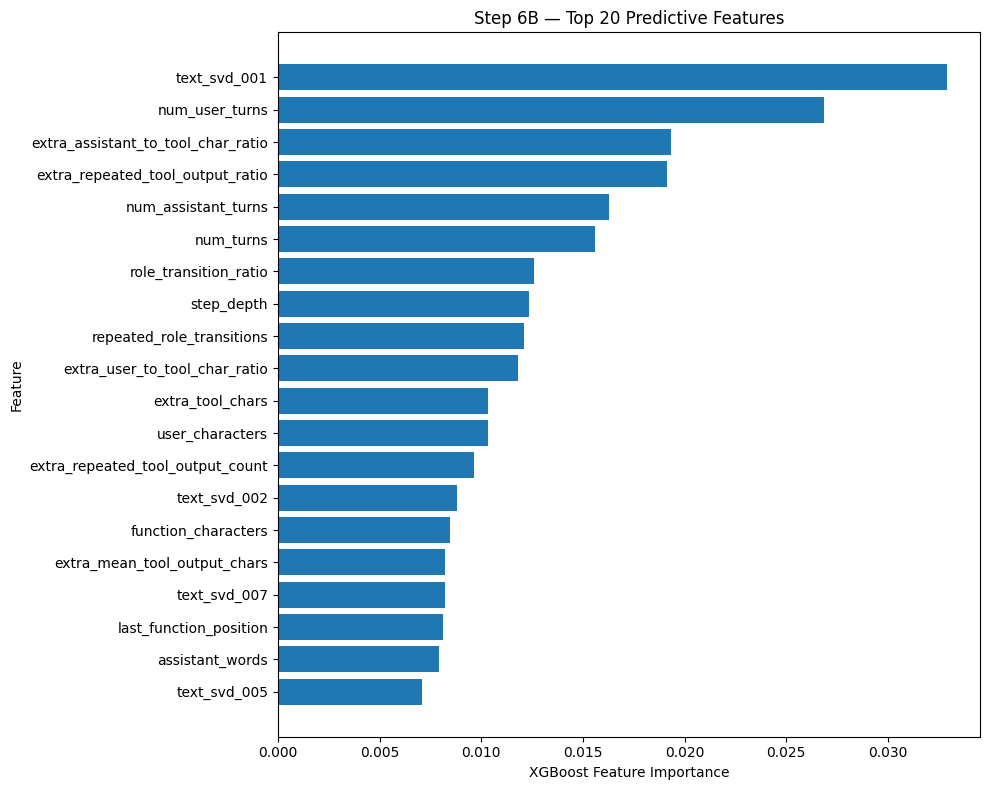


STEP 6B — ENHANCED XGBOOST COMPLETE
Training trajectories             : 2,590
Validation trajectories           : 555
Untouched LLM test trajectories   : 555
Human Gold audit trajectories     : 300
Structural features               : 23
Additional tool features          : 15
Text SVD features                 : 150
Total final model features        : 188
Best validation Macro-F1          : 0.4042

UNTouched LLM TEST:
Accuracy                          : 0.3946
Balanced Accuracy                 : 0.4104
Macro-F1                          : 0.3798
Weighted-F1                       : 0.3752
ROC-AUC Macro                     : 0.7218
Log Loss                          : 1.3701

HUMAN GOLD AUDIT:
Accuracy                          : 0.3933
Balanced Accuracy                 : 0.3573
Macro-F1                          : 0.3265
Weighted-F1                       : 0.4159
ROC-AUC Macro                     : 0.6273
Log Loss                          : 1.6258

BASELINE COMPARISON:
Original Step 6 LLM-Te

In [23]:
# ==================================================================================================
# STEP 6B — ENHANCED XGBOOST FAILURE PREDICTION
# FINAL 4,000-LABEL VERSION
#
# PURPOSE:
#   Improve the original Step 6 structural-feature XGBoost baseline.
#
# DESIGN:
#   ✓ Preserve exact existing Step-6 split:
#       Train       = 2,590
#       Validation  =   555
#       Test        =   555
#       Human Gold  =   300
#
#   ✓ Human Gold is NOT used for training or tuning
#   ✓ Test set is NOT used for tuning
#   ✓ Validation Macro-F1 chooses the best model
#
# FEATURES:
#   ✓ Original 23 Step-3 structural features
#   ✓ Additional tool-behavior features
#   ✓ TF-IDF text features
#   ✓ Truncated SVD text representation
#   ✓ Class-balanced sample weights
#
# OUTPUT:
#   New STEP 6B files only.
#   Original Step 6 baseline files are NOT overwritten.
#
# GPU:
#   NOT REQUIRED
# ==================================================================================================


# ==================================================================================================
# 0. IMPORTS
# ==================================================================================================

import os
import re
import ast
import json
import glob
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import (
    csr_matrix,
    hstack
)

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.decomposition import (
    TruncatedSVD
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score
)

from sklearn.utils.class_weight import (
    compute_class_weight
)

from xgboost import XGBClassifier


warnings.filterwarnings(
    "ignore"
)


# ==================================================================================================
# 1. CONFIGURATION
# ==================================================================================================

SEED = 42

np.random.seed(
    SEED
)


LABELS = [

    "Intent Misunderstanding",

    "Wrong Tool Selection",

    "Parameter Hallucination",

    "Execution/Cascading Error",

    "No Failure"
]


LABEL_TO_INT = {

    label: idx

    for idx, label
    in enumerate(
        LABELS
    )
}


INT_TO_LABEL = {

    idx: label

    for label, idx
    in LABEL_TO_INT.items()
}


EXPECTED_TOTAL = 4000

EXPECTED_TRAIN = 2590

EXPECTED_VALIDATION = 555

EXPECTED_TEST = 555

EXPECTED_HUMAN = 300


TFIDF_MAX_FEATURES = 15000

TFIDF_MIN_DF = 3

TFIDF_MAX_DF = 0.98

TFIDF_NGRAM_RANGE = (
    1,
    2
)

SVD_COMPONENTS = 150


# ==================================================================================================
# 2. PROJECT PATHS
# ==================================================================================================

WORKING_BASE = Path(
    "/kaggle/working/toolbench_research"
)


WORKING_PROCESSED_DIR = (
    WORKING_BASE
    /
    "data"
    /
    "processed"
)


WORKING_TABLE_DIR = (
    WORKING_BASE
    /
    "results"
    /
    "tables"
)


WORKING_FIGURE_DIR = (
    WORKING_BASE
    /
    "results"
    /
    "figures"
)


WORKING_MODEL_DIR = (
    WORKING_BASE
    /
    "models"
    /
    "step6b"
)


for directory in [

    WORKING_PROCESSED_DIR,

    WORKING_TABLE_DIR,

    WORKING_FIGURE_DIR,

    WORKING_MODEL_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ==================================================================================================
# 3. LOCATE MASTER BACKUP
# ==================================================================================================

MASTER_SETUP_ROOT = Path(
    "/kaggle/input/datasets/anandadevnath/master-setup"
)


if not MASTER_SETUP_ROOT.exists():

    raise FileNotFoundError(
        f"Master setup root not found:\n"
        f"{MASTER_SETUP_ROOT}"
    )


backup_candidates = sorted(

    [
        path

        for path
        in MASTER_SETUP_ROOT.glob(
            "ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_*"
        )

        if path.is_dir()
    ]
)


if not backup_candidates:

    raise FileNotFoundError(

        "Could not locate final ToolBench backup inside:\n"
        f"{MASTER_SETUP_ROOT}"
    )


FINAL_BACKUP_ROOT = (
    backup_candidates[-1]
)


SOURCE_MASTER_BACKUP = (
    FINAL_BACKUP_ROOT
    /
    "SOURCE_MASTER_BACKUP"
)


BACKUP_RESEARCH_ROOT = (
    FINAL_BACKUP_ROOT
    /
    "CURRENT_RESEARCH"
)


BACKUP_PROCESSED_DIR = (
    BACKUP_RESEARCH_ROOT
    /
    "data"
    /
    "processed"
)


BACKUP_TABLE_DIR = (
    BACKUP_RESEARCH_ROOT
    /
    "results"
    /
    "tables"
)


print(
    "=" * 115
)

print(
    "STEP 6B — ENHANCED XGBOOST FAILURE PREDICTION"
)

print(
    "=" * 115
)

print(
    "\nMaster setup root:"
)

print(
    MASTER_SETUP_ROOT
)

print(
    "\nFinal backup:"
)

print(
    FINAL_BACKUP_ROOT
)


# ==================================================================================================
# 4. FILE RESOLVER
# ==================================================================================================

def first_existing(
    candidates,
    description
):

    for candidate in candidates:

        candidate = Path(
            candidate
        )

        if candidate.exists():

            print(
                f"\n✓ {description}:"
            )

            print(
                candidate
            )

            return candidate


    raise FileNotFoundError(

        f"\nCould not locate {description}.\n\n"
        f"Checked:\n"
        +
        "\n".join(
            str(
                Path(p)
            )
            for p in candidates
        )
    )


# ==================================================================================================
# 5. RESOLVE CORE FILES
# ==================================================================================================

LABEL_FILE = first_existing(

    [

        WORKING_PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.parquet",

        BACKUP_PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.parquet",

        WORKING_PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.csv",

        BACKUP_PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.csv"

    ],

    "Final 4,000 GPT-OSS labels"
)


HUMAN_FILE = first_existing(

    [

        WORKING_PROCESSED_DIR
        /
        "step4_human_gold_FINAL_300.parquet",

        BACKUP_PROCESSED_DIR
        /
        "step4_human_gold_FINAL_300.parquet",

        WORKING_PROCESSED_DIR
        /
        "step4_human_gold_FINAL_300.csv",

        BACKUP_PROCESSED_DIR
        /
        "step4_human_gold_FINAL_300.csv"

    ],

    "Human Gold 300 labels"
)


RAW_TRAIN_FILE = first_existing(

    [

        SOURCE_MASTER_BACKUP
        /
        "dataset"
        /
        "toolbench_train_80.parquet"

    ],

    "ToolBench train-80 raw trajectories"
)


STRUCTURAL_FEATURE_FILE = first_existing(

    [

        SOURCE_MASTER_BACKUP
        /
        "featured"
        /
        "toolbench_train_80_features.parquet"

    ],

    "Step-3 train structural features"
)


# ==================================================================================================
# 6. RESOLVE EXISTING STEP-6 SPLIT FILES
# ==================================================================================================

TRAIN_IDS_FILE = first_existing(

    [

        WORKING_TABLE_DIR
        /
        "step6_train_ids_4000.csv",

        BACKUP_TABLE_DIR
        /
        "step6_train_ids_4000.csv"

    ],

    "Step-6 training IDs"
)


VALIDATION_IDS_FILE = first_existing(

    [

        WORKING_TABLE_DIR
        /
        "step6_validation_ids_4000.csv",

        BACKUP_TABLE_DIR
        /
        "step6_validation_ids_4000.csv"

    ],

    "Step-6 validation IDs"
)


TEST_IDS_FILE = first_existing(

    [

        WORKING_TABLE_DIR
        /
        "step6_test_ids_4000.csv",

        BACKUP_TABLE_DIR
        /
        "step6_test_ids_4000.csv"

    ],

    "Step-6 untouched test IDs"
)


HUMAN_IDS_FILE = first_existing(

    [

        WORKING_TABLE_DIR
        /
        "step6_human_gold_ids_300.csv",

        BACKUP_TABLE_DIR
        /
        "step6_human_gold_ids_300.csv"

    ],

    "Step-6 Human Gold audit IDs"
)


# ==================================================================================================
# 7. TABLE LOADER
# ==================================================================================================

def load_table(
    path
):

    path = Path(
        path
    )


    if path.suffix.lower() == ".parquet":

        return pd.read_parquet(
            path
        )


    if path.suffix.lower() == ".csv":

        return pd.read_csv(
            path,
            low_memory=False,
            dtype={
                "id": str
            }
        )


    raise ValueError(
        f"Unsupported file type:\n{path}"
    )


# ==================================================================================================
# 8. LOAD DATA
# ==================================================================================================

labels_df = load_table(
    LABEL_FILE
)


human_df = load_table(
    HUMAN_FILE
)


raw_df = pd.read_parquet(
    RAW_TRAIN_FILE
)


structural_df = pd.read_parquet(
    STRUCTURAL_FEATURE_FILE
)


train_ids_df = pd.read_csv(
    TRAIN_IDS_FILE,
    dtype={
        "id": str
    }
)


validation_ids_df = pd.read_csv(
    VALIDATION_IDS_FILE,
    dtype={
        "id": str
    }
)


test_ids_df = pd.read_csv(
    TEST_IDS_FILE,
    dtype={
        "id": str
    }
)


human_ids_df = pd.read_csv(
    HUMAN_IDS_FILE,
    dtype={
        "id": str
    }
)


# ==================================================================================================
# 9. NORMALIZE IDS
# ==================================================================================================

def normalize_id(
    series
):

    return (
        series
        .astype(str)
        .str.strip()
    )


for dataframe in [

    labels_df,

    human_df,

    raw_df,

    structural_df,

    train_ids_df,

    validation_ids_df,

    test_ids_df,

    human_ids_df

]:

    if "id" not in dataframe.columns:

        raise ValueError(
            "A required dataframe is missing the 'id' column."
        )


    dataframe[
        "id"
    ] = normalize_id(
        dataframe[
            "id"
        ]
    )


# ==================================================================================================
# 10. DETECT HUMAN LABEL COLUMN
# ==================================================================================================

HUMAN_LABEL_CANDIDATES = [

    "human_failure_type",

    "human_label",

    "failure_type",

    "gold_failure_type",

    "gold_label"
]


human_label_column = None


for candidate in HUMAN_LABEL_CANDIDATES:

    if candidate in human_df.columns:

        human_label_column = candidate

        break


if human_label_column is None:

    raise ValueError(

        "Could not identify Human Gold label column.\n"
        f"Columns:\n"
        f"{human_df.columns.tolist()}"
    )


print(
    "\nHuman label column:"
)

print(
    human_label_column
)


# ==================================================================================================
# 11. VALIDATE FINAL GPT LABEL DATA
# ==================================================================================================

if (
    "llm_failure_type"
    not in
    labels_df.columns
):

    raise ValueError(
        "Final GPT label file has no llm_failure_type column."
    )


labels_df[
    "llm_failure_type"
] = (
    labels_df[
        "llm_failure_type"
    ]
    .astype(str)
    .str.strip()
)


labels_df = (
    labels_df[
        labels_df[
            "llm_failure_type"
        ]
        .isin(
            LABELS
        )
    ]
    .drop_duplicates(
        subset=[
            "id"
        ],
        keep="last"
    )
    .reset_index(
        drop=True
    )
)


if len(
    labels_df
) != EXPECTED_TOTAL:

    raise RuntimeError(

        f"Expected exactly {EXPECTED_TOTAL:,} final labels, "
        f"found {len(labels_df):,}."
    )


if labels_df[
    "id"
].nunique() != EXPECTED_TOTAL:

    raise RuntimeError(
        "Final GPT label file does not contain 4,000 unique IDs."
    )


# ==================================================================================================
# 12. VALIDATE HUMAN GOLD
# ==================================================================================================

human_df[
    human_label_column
] = (
    human_df[
        human_label_column
    ]
    .astype(str)
    .str.strip()
)


human_df = (
    human_df[
        human_df[
            human_label_column
        ]
        .isin(
            LABELS
        )
    ]
    .drop_duplicates(
        subset=[
            "id"
        ],
        keep="last"
    )
    .reset_index(
        drop=True
    )
)


if len(
    human_df
) != EXPECTED_HUMAN:

    raise RuntimeError(

        f"Expected {EXPECTED_HUMAN} Human Gold rows, "
        f"found {len(human_df)}."
    )


# ==================================================================================================
# 13. VALIDATE SPLIT SIZES
# ==================================================================================================

def unique_id_set(
    dataframe
):

    return set(
        dataframe[
            "id"
        ]
        .astype(str)
        .str.strip()
    )


train_ids = unique_id_set(
    train_ids_df
)


validation_ids = unique_id_set(
    validation_ids_df
)


test_ids = unique_id_set(
    test_ids_df
)


human_ids = unique_id_set(
    human_ids_df
)


print(
    "\n" + "=" * 115
)

print(
    "STEP 6 SPLIT VALIDATION"
)

print(
    "=" * 115
)


print(
    f"Train       : {len(train_ids):,}"
)

print(
    f"Validation  : {len(validation_ids):,}"
)

print(
    f"Test        : {len(test_ids):,}"
)

print(
    f"Human Gold  : {len(human_ids):,}"
)


if len(
    train_ids
) != EXPECTED_TRAIN:

    raise RuntimeError(
        "Training split is not 2,590."
    )


if len(
    validation_ids
) != EXPECTED_VALIDATION:

    raise RuntimeError(
        "Validation split is not 555."
    )


if len(
    test_ids
) != EXPECTED_TEST:

    raise RuntimeError(
        "Test split is not 555."
    )


if len(
    human_ids
) != EXPECTED_HUMAN:

    raise RuntimeError(
        "Human Gold split is not 300."
    )


# ==================================================================================================
# 14. CHECK SPLIT DISJOINTNESS
# ==================================================================================================

split_sets = {

    "train":
        train_ids,

    "validation":
        validation_ids,

    "test":
        test_ids,

    "human":
        human_ids
}


split_names = list(
    split_sets.keys()
)


for i in range(
    len(
        split_names
    )
):

    for j in range(
        i + 1,
        len(
            split_names
        )
    ):

        left_name = (
            split_names[
                i
            ]
        )

        right_name = (
            split_names[
                j
            ]
        )


        overlap = (
            split_sets[
                left_name
            ]
            &
            split_sets[
                right_name
            ]
        )


        if overlap:

            raise RuntimeError(

                f"Split leakage detected between "
                f"{left_name} and {right_name}: "
                f"{len(overlap)} IDs"
            )


all_split_ids = (

    train_ids
    |
    validation_ids
    |
    test_ids
    |
    human_ids
)


if len(
    all_split_ids
) != EXPECTED_TOTAL:

    raise RuntimeError(

        f"Combined Step-6 splits contain "
        f"{len(all_split_ids):,} unique IDs, "
        f"expected 4,000."
    )


print(
    "\n✓ All Step-6 splits are mutually exclusive."
)

print(
    "✓ Combined split IDs = 4,000."
)


# ==================================================================================================
# 15. STRUCTURAL FEATURE COLUMNS
# ==================================================================================================

STRUCTURAL_FEATURES = [

    "step_depth",

    "num_turns",

    "num_system_turns",

    "num_user_turns",

    "num_assistant_turns",

    "num_function_turns",

    "has_function_call",

    "total_characters",

    "user_characters",

    "assistant_characters",

    "function_characters",

    "total_words",

    "assistant_words",

    "avg_chars_per_turn",

    "avg_words_per_turn",

    "function_turn_ratio",

    "assistant_turn_ratio",

    "user_turn_ratio",

    "role_transitions",

    "repeated_role_transitions",

    "role_transition_ratio",

    "first_function_position",

    "last_function_position"
]


missing_structural = [

    col

    for col
    in STRUCTURAL_FEATURES

    if col
    not in
    structural_df.columns
]


if missing_structural:

    raise ValueError(

        f"Missing Step-3 structural features:\n"
        f"{missing_structural}"
    )


# ==================================================================================================
# 16. ROBUST CONVERSATION PARSER
# ==================================================================================================

def safe_text(
    value
):

    if value is None:

        return ""


    try:

        if pd.isna(
            value
        ):

            return ""

    except Exception:

        pass


    return str(
        value
    )


def parse_conversation(
    value
):

    if value is None:

        return []


    if isinstance(
        value,
        str
    ):

        text = value.strip()


        if not text:

            return []


        try:

            value = json.loads(
                text
            )

        except Exception:

            try:

                value = ast.literal_eval(
                    text
                )

            except Exception:

                return [
                    (
                        "unknown",
                        text
                    )
                ]


    if isinstance(
        value,
        dict
    ):

        roles = value.get(
            "from"
        )

        texts = value.get(
            "value"
        )


        if (
            roles is not None
            and
            texts is not None
        ):

            try:

                roles = list(
                    roles
                )

                texts = list(
                    texts
                )


                return [

                    (
                        safe_text(
                            role
                        ),
                        safe_text(
                            text
                        )
                    )

                    for role, text
                    in zip(
                        roles,
                        texts
                    )
                ]

            except Exception:

                pass


        role = (

            value.get(
                "role"
            )
            or
            value.get(
                "from"
            )
            or
            value.get(
                "speaker"
            )
            or
            "unknown"
        )


        text = (

            value.get(
                "content"
            )
            or
            value.get(
                "value"
            )
            or
            value.get(
                "text"
            )
            or
            ""
        )


        return [
            (
                safe_text(
                    role
                ),
                safe_text(
                    text
                )
            )
        ]


    if isinstance(
        value,
        (
            list,
            tuple,
            np.ndarray
        )
    ):

        output = []


        for item in list(
            value
        ):

            if isinstance(
                item,
                dict
            ):

                role = (

                    item.get(
                        "role"
                    )
                    or
                    item.get(
                        "from"
                    )
                    or
                    item.get(
                        "speaker"
                    )
                    or
                    "unknown"
                )


                text = (

                    item.get(
                        "content"
                    )
                    or
                    item.get(
                        "value"
                    )
                    or
                    item.get(
                        "text"
                    )
                    or
                    ""
                )


                output.append(
                    (
                        safe_text(
                            role
                        ),
                        safe_text(
                            text
                        )
                    )
                )


            else:

                output.append(
                    (
                        "unknown",
                        safe_text(
                            item
                        )
                    )
                )


        return output


    return []


# ==================================================================================================
# 17. NORMALIZE ROLE
# ==================================================================================================

def normalize_role(
    role
):

    role = (
        safe_text(
            role
        )
        .strip()
        .lower()
    )


    if role in [

        "function",

        "tool",

        "tool_result",

        "function_result"

    ]:

        return "tool"


    if role in [

        "assistant",

        "gpt",

        "model"

    ]:

        return "assistant"


    if role in [

        "human",

        "user"

    ]:

        return "user"


    if role in [

        "system"

    ]:

        return "system"


    return role


# ==================================================================================================
# 18. BUILD TEXT FEATURE
# ==================================================================================================

def conversation_to_model_text(
    conversation
):

    turns = parse_conversation(
        conversation
    )


    output = []


    for role, text in turns:

        role = normalize_role(
            role
        )


        text = (
            safe_text(
                text
            )
            .strip()
        )


        if not text:

            continue


        # Do not use SYSTEM prompts for predictive text representation.
        if role == "system":

            continue


        output.append(
            f"{role}: {text}"
        )


    return " ".join(
        output
    )


# ==================================================================================================
# 19. TOOL-BEHAVIOR FEATURES
# ==================================================================================================

ERROR_PATTERNS = [

    r"\berror\b",

    r"\bexception\b",

    r"\bfailed\b",

    r"\bfailure\b",

    r"\binvalid\b",

    r"\bnot found\b",

    r"\btimeout\b",

    r"\bunauthorized\b",

    r"\bforbidden\b",

    r"\bmissing\b",

    r"\bstatus[_ ]?code['\"]?\s*[:=]\s*[45]\d\d\b",

    r"\bhttp\s*[45]\d\d\b"
]


CALL_LIKE_PATTERN = re.compile(

    r"(\{.*\}|"
    r"\barguments?\b|"
    r"\bparameters?\b|"
    r"\btool[_ ]?call\b|"
    r"\bfunction[_ ]?call\b)",

    flags=re.IGNORECASE
)


JSON_LIKE_PATTERN = re.compile(

    r"^\s*[\{\[]",

    flags=re.DOTALL
)


def normalize_for_repeat(
    text
):

    text = (
        safe_text(
            text
        )
        .strip()
        .lower()
    )


    text = re.sub(
        r"\s+",
        " ",
        text
    )


    return text


def extract_tool_behavior_features(
    conversation
):

    turns = parse_conversation(
        conversation
    )


    normalized_turns = [

        (
            normalize_role(
                role
            ),
            safe_text(
                text
            )
        )

        for role, text
        in turns
    ]


    tool_texts = [

        text

        for role, text
        in normalized_turns

        if role == "tool"
    ]


    assistant_texts = [

        text

        for role, text
        in normalized_turns

        if role == "assistant"
    ]


    tool_count = len(
        tool_texts
    )


    normalized_tool_outputs = [

        normalize_for_repeat(
            text
        )

        for text
        in tool_texts
    ]


    nonempty_tool_outputs = [

        text

        for text
        in normalized_tool_outputs

        if text
    ]


    unique_tool_outputs = len(
        set(
            nonempty_tool_outputs
        )
    )


    repeated_tool_outputs = max(

        0,

        len(
            nonempty_tool_outputs
        )
        -
        unique_tool_outputs
    )


    repeated_ratio = (

        repeated_tool_outputs
        /
        len(
            nonempty_tool_outputs
        )

        if nonempty_tool_outputs

        else 0.0
    )


    error_count = 0


    for text in tool_texts:

        lowered = (
            safe_text(
                text
            )
            .lower()
        )


        if any(

            re.search(
                pattern,
                lowered,
                flags=re.IGNORECASE
            )

            for pattern
            in ERROR_PATTERNS

        ):

            error_count += 1


    error_ratio = (

        error_count
        /
        tool_count

        if tool_count > 0

        else 0.0
    )


    assistant_call_like_count = sum(

        1

        for text
        in assistant_texts

        if CALL_LIKE_PATTERN.search(
            safe_text(
                text
            )
        )
    )


    assistant_json_like_count = sum(

        1

        for text
        in assistant_texts

        if JSON_LIKE_PATTERN.search(
            safe_text(
                text
            )
        )
    )


    consecutive_tool_pairs = 0

    assistant_tool_transitions = 0

    tool_assistant_transitions = 0


    roles = [

        role

        for role, _
        in normalized_turns

        if role != "system"
    ]


    for previous_role, current_role in zip(
        roles,
        roles[
            1:
        ]
    ):

        if (
            previous_role == "tool"
            and
            current_role == "tool"
        ):

            consecutive_tool_pairs += 1


        if (
            previous_role == "assistant"
            and
            current_role == "tool"
        ):

            assistant_tool_transitions += 1


        if (
            previous_role == "tool"
            and
            current_role == "assistant"
        ):

            tool_assistant_transitions += 1


    tool_chars = sum(

        len(
            safe_text(
                text
            )
        )

        for text
        in tool_texts
    )


    assistant_chars = sum(

        len(
            safe_text(
                text
            )
        )

        for text
        in assistant_texts
    )


    user_chars = sum(

        len(
            safe_text(
                text
            )
        )

        for role, text
        in normalized_turns

        if role == "user"
    )


    mean_tool_output_chars = (

        tool_chars
        /
        tool_count

        if tool_count > 0

        else 0.0
    )


    assistant_to_tool_char_ratio = (

        assistant_chars
        /
        tool_chars

        if tool_chars > 0

        else 0.0
    )


    user_to_tool_char_ratio = (

        user_chars
        /
        tool_chars

        if tool_chars > 0

        else 0.0
    )


    return {

        "extra_tool_output_count":
            tool_count,

        "extra_unique_tool_output_count":
            unique_tool_outputs,

        "extra_repeated_tool_output_count":
            repeated_tool_outputs,

        "extra_repeated_tool_output_ratio":
            repeated_ratio,

        "extra_tool_error_count":
            error_count,

        "extra_tool_error_ratio":
            error_ratio,

        "extra_assistant_call_like_count":
            assistant_call_like_count,

        "extra_assistant_json_like_count":
            assistant_json_like_count,

        "extra_consecutive_tool_pairs":
            consecutive_tool_pairs,

        "extra_assistant_tool_transitions":
            assistant_tool_transitions,

        "extra_tool_assistant_transitions":
            tool_assistant_transitions,

        "extra_tool_chars":
            tool_chars,

        "extra_mean_tool_output_chars":
            mean_tool_output_chars,

        "extra_assistant_to_tool_char_ratio":
            assistant_to_tool_char_ratio,

        "extra_user_to_tool_char_ratio":
            user_to_tool_char_ratio
    }


# ==================================================================================================
# 20. PREPARE RAW DATA FOR 4,000 IDS
# ==================================================================================================

if "conversations" not in raw_df.columns:

    raise ValueError(
        "Raw train file has no conversations column."
    )


raw_df = (
    raw_df[
        raw_df[
            "id"
        ]
        .isin(
            all_split_ids
        )
    ][
        [
            "id",
            "conversations"
        ]
    ]
    .copy()
)


if len(
    raw_df
) != EXPECTED_TOTAL:

    raise RuntimeError(

        f"Expected 4,000 raw trajectories for Step 6, "
        f"found {len(raw_df):,}."
    )


print(
    "\nBuilding text features..."
)


raw_df[
    "model_text"
] = (
    raw_df[
        "conversations"
    ]
    .apply(
        conversation_to_model_text
    )
)


empty_texts = int(

    (
        raw_df[
            "model_text"
        ]
        .str.strip()
        ==
        ""
    )
    .sum()
)


if empty_texts > 0:

    raise RuntimeError(

        f"{empty_texts} Step-6 trajectories have empty model text."
    )


print(
    "✓ Text extraction complete."
)


# ==================================================================================================
# 21. BUILD TOOL FEATURES
# ==================================================================================================

print(
    "\nBuilding additional tool-behavior features..."
)


tool_feature_records = []


for _, row in raw_df.iterrows():

    features = extract_tool_behavior_features(
        row[
            "conversations"
        ]
    )


    features[
        "id"
    ] = row[
        "id"
    ]


    tool_feature_records.append(
        features
    )


tool_features_df = pd.DataFrame(
    tool_feature_records
)


EXTRA_FEATURES = [

    "extra_tool_output_count",

    "extra_unique_tool_output_count",

    "extra_repeated_tool_output_count",

    "extra_repeated_tool_output_ratio",

    "extra_tool_error_count",

    "extra_tool_error_ratio",

    "extra_assistant_call_like_count",

    "extra_assistant_json_like_count",

    "extra_consecutive_tool_pairs",

    "extra_assistant_tool_transitions",

    "extra_tool_assistant_transitions",

    "extra_tool_chars",

    "extra_mean_tool_output_chars",

    "extra_assistant_to_tool_char_ratio",

    "extra_user_to_tool_char_ratio"
]


print(
    f"✓ Added {len(EXTRA_FEATURES)} tool-behavior features."
)


# ==================================================================================================
# 22. BUILD MASTER MODEL DATASET
# ==================================================================================================

structural_subset = (
    structural_df[
        [
            "id"
        ]
        +
        STRUCTURAL_FEATURES
    ]
    .copy()
)


model_df = (

    labels_df[
        [
            "id",
            "llm_failure_type"
        ]
    ]

    .merge(
        structural_subset,
        on="id",
        how="inner",
        validate="one_to_one"
    )

    .merge(
        tool_features_df,
        on="id",
        how="inner",
        validate="one_to_one"
    )

    .merge(
        raw_df[
            [
                "id",
                "model_text"
            ]
        ],
        on="id",
        how="inner",
        validate="one_to_one"
    )
)


if len(
    model_df
) != EXPECTED_TOTAL:

    raise RuntimeError(

        f"Master Step-6B dataset has "
        f"{len(model_df):,} rows instead of 4,000."
    )


# ==================================================================================================
# 23. SPLIT MASTER DATASET
# ==================================================================================================

def take_split(
    dataframe,
    id_set
):

    output = (
        dataframe[
            dataframe[
                "id"
            ]
            .isin(
                id_set
            )
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    return output


train_df_model = take_split(
    model_df,
    train_ids
)


validation_df_model = take_split(
    model_df,
    validation_ids
)


test_df_model = take_split(
    model_df,
    test_ids
)


human_structural_df = take_split(
    model_df,
    human_ids
)


if len(
    train_df_model
) != EXPECTED_TRAIN:

    raise RuntimeError(
        "Recovered train rows do not equal 2,590."
    )


if len(
    validation_df_model
) != EXPECTED_VALIDATION:

    raise RuntimeError(
        "Recovered validation rows do not equal 555."
    )


if len(
    test_df_model
) != EXPECTED_TEST:

    raise RuntimeError(
        "Recovered test rows do not equal 555."
    )


if len(
    human_structural_df
) != EXPECTED_HUMAN:

    raise RuntimeError(
        "Recovered Human Gold rows do not equal 300."
    )


# ==================================================================================================
# 24. PREPARE HUMAN GOLD LABELS
# ==================================================================================================

human_gold_map = (
    human_df[
        [
            "id",
            human_label_column
        ]
    ]
    .rename(
        columns={
            human_label_column:
                "human_gold_label"
        }
    )
)


human_model_df = (
    human_structural_df
    .drop(
        columns=[
            "llm_failure_type"
        ]
    )
    .merge(
        human_gold_map,
        on="id",
        how="inner",
        validate="one_to_one"
    )
)


if len(
    human_model_df
) != EXPECTED_HUMAN:

    raise RuntimeError(
        "Human Gold merge failed."
    )


# ==================================================================================================
# 25. NUMERIC FEATURES
# ==================================================================================================

NUMERIC_FEATURES = (

    STRUCTURAL_FEATURES
    +
    EXTRA_FEATURES
)


# ==================================================================================================
# 26. TRAIN-ONLY MEDIAN IMPUTATION
# ==================================================================================================

train_numeric = (
    train_df_model[
        NUMERIC_FEATURES
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


validation_numeric = (
    validation_df_model[
        NUMERIC_FEATURES
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


test_numeric = (
    test_df_model[
        NUMERIC_FEATURES
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


human_numeric = (
    human_model_df[
        NUMERIC_FEATURES
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


train_medians = (
    train_numeric
    .median()
)


train_numeric = (
    train_numeric
    .fillna(
        train_medians
    )
)


validation_numeric = (
    validation_numeric
    .fillna(
        train_medians
    )
)


test_numeric = (
    test_numeric
    .fillna(
        train_medians
    )
)


human_numeric = (
    human_numeric
    .fillna(
        train_medians
    )
)


# ==================================================================================================
# 27. STANDARDIZE NUMERIC FEATURES
# ==================================================================================================

numeric_scaler = StandardScaler()


X_train_numeric = numeric_scaler.fit_transform(
    train_numeric
)


X_validation_numeric = numeric_scaler.transform(
    validation_numeric
)


X_test_numeric = numeric_scaler.transform(
    test_numeric
)


X_human_numeric = numeric_scaler.transform(
    human_numeric
)


# ==================================================================================================
# 28. TRAIN-ONLY TF-IDF
# ==================================================================================================

print(
    "\n" + "=" * 115
)

print(
    "TRAIN-ONLY TF-IDF"
)

print(
    "=" * 115
)


tfidf = TfidfVectorizer(

    lowercase=True,

    stop_words="english",

    max_features=TFIDF_MAX_FEATURES,

    min_df=TFIDF_MIN_DF,

    max_df=TFIDF_MAX_DF,

    ngram_range=TFIDF_NGRAM_RANGE,

    sublinear_tf=True,

    dtype=np.float32
)


X_train_tfidf = tfidf.fit_transform(
    train_df_model[
        "model_text"
    ]
)


X_validation_tfidf = tfidf.transform(
    validation_df_model[
        "model_text"
    ]
)


X_test_tfidf = tfidf.transform(
    test_df_model[
        "model_text"
    ]
)


X_human_tfidf = tfidf.transform(
    human_model_df[
        "model_text"
    ]
)


print(
    f"TF-IDF vocabulary size : "
    f"{X_train_tfidf.shape[1]:,}"
)


# ==================================================================================================
# 29. TRAIN-ONLY SVD
# ==================================================================================================

actual_svd_components = min(

    SVD_COMPONENTS,

    X_train_tfidf.shape[
        1
    ]
    -
    1,

    X_train_tfidf.shape[
        0
    ]
    -
    1
)


if actual_svd_components < 2:

    raise RuntimeError(
        "Not enough TF-IDF dimensions for SVD."
    )


svd = TruncatedSVD(

    n_components=actual_svd_components,

    random_state=SEED
)


X_train_svd = svd.fit_transform(
    X_train_tfidf
)


X_validation_svd = svd.transform(
    X_validation_tfidf
)


X_test_svd = svd.transform(
    X_test_tfidf
)


X_human_svd = svd.transform(
    X_human_tfidf
)


print(
    f"SVD components         : "
    f"{actual_svd_components}"
)

print(
    f"Explained variance     : "
    f"{svd.explained_variance_ratio_.sum():.4f}"
)


# ==================================================================================================
# 30. COMBINE NUMERIC + TEXT FEATURES
# ==================================================================================================

X_train = np.hstack(

    [
        X_train_numeric,
        X_train_svd
    ]
).astype(
    np.float32
)


X_validation = np.hstack(

    [
        X_validation_numeric,
        X_validation_svd
    ]
).astype(
    np.float32
)


X_test = np.hstack(

    [
        X_test_numeric,
        X_test_svd
    ]
).astype(
    np.float32
)


X_human = np.hstack(

    [
        X_human_numeric,
        X_human_svd
    ]
).astype(
    np.float32
)


print(
    "\nFinal feature shapes:"
)

print(
    "Train      :",
    X_train.shape
)

print(
    "Validation :",
    X_validation.shape
)

print(
    "Test       :",
    X_test.shape
)

print(
    "Human Gold :",
    X_human.shape
)


# ==================================================================================================
# 31. TARGET ENCODING — FIXED CANONICAL ORDER
# ==================================================================================================

def encode_labels(
    series
):

    encoded = (
        series
        .map(
            LABEL_TO_INT
        )
    )


    if encoded.isna().any():

        invalid_values = (
            series[
                encoded.isna()
            ]
            .unique()
            .tolist()
        )


        raise ValueError(
            f"Unknown labels detected: {invalid_values}"
        )


    return (
        encoded
        .astype(int)
        .to_numpy()
    )


y_train = encode_labels(
    train_df_model[
        "llm_failure_type"
    ]
)


y_validation = encode_labels(
    validation_df_model[
        "llm_failure_type"
    ]
)


y_test = encode_labels(
    test_df_model[
        "llm_failure_type"
    ]
)


y_human = encode_labels(
    human_model_df[
        "human_gold_label"
    ]
)


# ==================================================================================================
# 32. CLASS-BALANCED SAMPLE WEIGHTS
# ==================================================================================================

class_values = np.arange(
    len(
        LABELS
    )
)


class_weights = compute_class_weight(

    class_weight="balanced",

    classes=class_values,

    y=y_train
)


class_weight_map = {

    int(
        class_id
    ):
        float(
            weight
        )

    for class_id, weight
    in zip(
        class_values,
        class_weights
    )
}


sample_weights = np.array(

    [
        class_weight_map[
            int(
                label
            )
        ]

        for label
        in y_train
    ],

    dtype=np.float32
)


print(
    "\nClass weights:"
)


for index, label in enumerate(
    LABELS
):

    print(
        f"{label:30s} "
        f"{class_weight_map[index]:.4f}"
    )


# ==================================================================================================
# 33. XGBOOST PARAMETER CANDIDATES
# ==================================================================================================

PARAMETER_CANDIDATES = [

    {
        "n_estimators":
            80,

        "max_depth":
            3,

        "learning_rate":
            0.05,

        "min_child_weight":
            1,

        "subsample":
            0.90,

        "colsample_bytree":
            0.90,

        "gamma":
            0.0,

        "reg_alpha":
            0.0,

        "reg_lambda":
            1.0
    },


    {
        "n_estimators":
            120,

        "max_depth":
            3,

        "learning_rate":
            0.05,

        "min_child_weight":
            2,

        "subsample":
            0.90,

        "colsample_bytree":
            0.85,

        "gamma":
            0.0,

        "reg_alpha":
            0.05,

        "reg_lambda":
            2.0
    },


    {
        "n_estimators":
            180,

        "max_depth":
            3,

        "learning_rate":
            0.03,

        "min_child_weight":
            2,

        "subsample":
            0.90,

        "colsample_bytree":
            0.85,

        "gamma":
            0.05,

        "reg_alpha":
            0.10,

        "reg_lambda":
            2.0
    },


    {
        "n_estimators":
            120,

        "max_depth":
            4,

        "learning_rate":
            0.04,

        "min_child_weight":
            2,

        "subsample":
            0.85,

        "colsample_bytree":
            0.85,

        "gamma":
            0.05,

        "reg_alpha":
            0.10,

        "reg_lambda":
            2.0
    },


    {
        "n_estimators":
            180,

        "max_depth":
            4,

        "learning_rate":
            0.03,

        "min_child_weight":
            3,

        "subsample":
            0.85,

        "colsample_bytree":
            0.80,

        "gamma":
            0.10,

        "reg_alpha":
            0.15,

        "reg_lambda":
            3.0
    },


    {
        "n_estimators":
            250,

        "max_depth":
            4,

        "learning_rate":
            0.02,

        "min_child_weight":
            3,

        "subsample":
            0.85,

        "colsample_bytree":
            0.80,

        "gamma":
            0.10,

        "reg_alpha":
            0.20,

        "reg_lambda":
            3.0
    },


    {
        "n_estimators":
            150,

        "max_depth":
            5,

        "learning_rate":
            0.03,

        "min_child_weight":
            4,

        "subsample":
            0.80,

        "colsample_bytree":
            0.80,

        "gamma":
            0.10,

        "reg_alpha":
            0.20,

        "reg_lambda":
            4.0
    },


    {
        "n_estimators":
            220,

        "max_depth":
            5,

        "learning_rate":
            0.02,

        "min_child_weight":
            5,

        "subsample":
            0.80,

        "colsample_bytree":
            0.75,

        "gamma":
            0.15,

        "reg_alpha":
            0.25,

        "reg_lambda":
            4.0
    }
]


# ==================================================================================================
# 34. TRAIN / VALIDATION MODEL SELECTION
# ==================================================================================================

print(
    "\n" + "=" * 115
)

print(
    "XGBOOST VALIDATION MODEL SELECTION"
)

print(
    "=" * 115
)


candidate_results = []

best_model = None

best_validation_macro_f1 = -np.inf

best_candidate_index = None

best_parameters = None


for candidate_index, parameters in enumerate(
    PARAMETER_CANDIDATES,
    start=1
):

    print(
        f"\nCandidate "
        f"{candidate_index}/"
        f"{len(PARAMETER_CANDIDATES)}"
    )


    model = XGBClassifier(

        objective="multi:softprob",

        num_class=len(
            LABELS
        ),

        eval_metric="mlogloss",

        tree_method="hist",

        random_state=SEED,

        n_jobs=-1,

        **parameters
    )


    model.fit(

        X_train,

        y_train,

        sample_weight=sample_weights,

        verbose=False
    )


    validation_probabilities = (
        model.predict_proba(
            X_validation
        )
    )


    validation_predictions = np.argmax(
        validation_probabilities,
        axis=1
    )


    validation_accuracy = accuracy_score(
        y_validation,
        validation_predictions
    )


    validation_balanced_accuracy = balanced_accuracy_score(
        y_validation,
        validation_predictions
    )


    validation_macro_f1 = f1_score(

        y_validation,

        validation_predictions,

        average="macro",

        zero_division=0
    )


    validation_weighted_f1 = f1_score(

        y_validation,

        validation_predictions,

        average="weighted",

        zero_division=0
    )


    validation_log_loss = log_loss(

        y_validation,

        validation_probabilities,

        labels=class_values
    )


    print(
        f"Validation Accuracy     : "
        f"{validation_accuracy:.4f}"
    )


    print(
        f"Validation Balanced Acc : "
        f"{validation_balanced_accuracy:.4f}"
    )


    print(
        f"Validation Macro-F1     : "
        f"{validation_macro_f1:.4f}"
    )


    print(
        f"Validation Weighted-F1  : "
        f"{validation_weighted_f1:.4f}"
    )


    candidate_record = {

        "candidate":
            candidate_index,

        "validation_accuracy":
            validation_accuracy,

        "validation_balanced_accuracy":
            validation_balanced_accuracy,

        "validation_macro_f1":
            validation_macro_f1,

        "validation_weighted_f1":
            validation_weighted_f1,

        "validation_log_loss":
            validation_log_loss
    }


    candidate_record.update(
        parameters
    )


    candidate_results.append(
        candidate_record
    )


    if (
        validation_macro_f1
        >
        best_validation_macro_f1
    ):

        best_validation_macro_f1 = (
            validation_macro_f1
        )

        best_model = model

        best_candidate_index = (
            candidate_index
        )

        best_parameters = (
            parameters.copy()
        )


# ==================================================================================================
# 35. SAVE VALIDATION MODEL-SELECTION TABLE
# ==================================================================================================

candidate_results_df = pd.DataFrame(
    candidate_results
)


candidate_results_df = (
    candidate_results_df
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


MODEL_SELECTION_PATH = (
    WORKING_TABLE_DIR
    /
    "step6b_xgboost_validation_model_selection_4000.csv"
)


candidate_results_df.to_csv(
    MODEL_SELECTION_PATH,
    index=False
)


print(
    "\n" + "=" * 115
)

print(
    "BEST VALIDATION MODEL"
)

print(
    "=" * 115
)


print(
    f"Candidate               : "
    f"{best_candidate_index}"
)

print(
    f"Validation Macro-F1     : "
    f"{best_validation_macro_f1:.4f}"
)

print(
    "\nParameters:"
)

print(
    best_parameters
)


# ==================================================================================================
# 36. EVALUATION FUNCTION
# ==================================================================================================

def evaluate_model(
    model,
    X,
    y_true,
    split_name
):

    probabilities = model.predict_proba(
        X
    )


    predictions = np.argmax(
        probabilities,
        axis=1
    )


    accuracy = accuracy_score(
        y_true,
        predictions
    )


    balanced_accuracy = balanced_accuracy_score(
        y_true,
        predictions
    )


    macro_f1 = f1_score(

        y_true,

        predictions,

        average="macro",

        zero_division=0
    )


    weighted_f1 = f1_score(

        y_true,

        predictions,

        average="weighted",

        zero_division=0
    )


    precision_macro, recall_macro, _, _ = (
        precision_recall_fscore_support(

            y_true,

            predictions,

            labels=class_values,

            average="macro",

            zero_division=0
        )
    )


    loss = log_loss(

        y_true,

        probabilities,

        labels=class_values
    )


    try:

        auc_macro = roc_auc_score(

            y_true,

            probabilities,

            labels=class_values,

            multi_class="ovr",

            average="macro"
        )

    except Exception:

        auc_macro = np.nan


    report = classification_report(

        y_true,

        predictions,

        labels=class_values,

        target_names=LABELS,

        output_dict=True,

        zero_division=0
    )


    report_df = (
        pd.DataFrame(
            report
        )
        .transpose()
    )


    cm = confusion_matrix(

        y_true,

        predictions,

        labels=class_values
    )


    metrics = {

        "split":
            split_name,

        "n":
            len(
                y_true
            ),

        "accuracy":
            accuracy,

        "balanced_accuracy":
            balanced_accuracy,

        "macro_precision":
            precision_macro,

        "macro_recall":
            recall_macro,

        "macro_f1":
            macro_f1,

        "weighted_f1":
            weighted_f1,

        "roc_auc_macro_ovr":
            auc_macro,

        "log_loss":
            loss
    }


    return {

        "metrics":
            metrics,

        "report_df":
            report_df,

        "confusion_matrix":
            cm,

        "predictions":
            predictions,

        "probabilities":
            probabilities
    }


# ==================================================================================================
# 37. FINAL UNTOUCHED LLM TEST
# ==================================================================================================

print(
    "\n" + "=" * 115
)

print(
    "FINAL UNTOUCHED LLM TEST EVALUATION"
)

print(
    "=" * 115
)


test_result = evaluate_model(

    best_model,

    X_test,

    y_test,

    "LLM_Test_555"
)


for key, value in (
    test_result[
        "metrics"
    ]
    .items()
):

    print(
        f"{key:25s}: "
        f"{value}"
    )


# ==================================================================================================
# 38. FINAL HUMAN GOLD AUDIT
# ==================================================================================================

print(
    "\n" + "=" * 115
)

print(
    "HUMAN GOLD 300 AUDIT"
)

print(
    "=" * 115
)


human_result = evaluate_model(

    best_model,

    X_human,

    y_human,

    "Human_Gold_300"
)


for key, value in (
    human_result[
        "metrics"
    ]
    .items()
):

    print(
        f"{key:25s}: "
        f"{value}"
    )


# ==================================================================================================
# 39. ORIGINAL STEP-6 BASELINE COMPARISON
# ==================================================================================================

ORIGINAL_TEST_MACRO_F1 = 0.3369

ORIGINAL_HUMAN_MACRO_F1 = 0.2418


new_test_macro_f1 = (
    test_result[
        "metrics"
    ][
        "macro_f1"
    ]
)


new_human_macro_f1 = (
    human_result[
        "metrics"
    ][
        "macro_f1"
    ]
)


comparison_df = pd.DataFrame(

    [

        {
            "evaluation":
                "LLM Test 555",

            "original_step6_macro_f1":
                ORIGINAL_TEST_MACRO_F1,

            "step6b_macro_f1":
                new_test_macro_f1,

            "absolute_change":
                new_test_macro_f1
                -
                ORIGINAL_TEST_MACRO_F1
        },


        {
            "evaluation":
                "Human Gold 300",

            "original_step6_macro_f1":
                ORIGINAL_HUMAN_MACRO_F1,

            "step6b_macro_f1":
                new_human_macro_f1,

            "absolute_change":
                new_human_macro_f1
                -
                ORIGINAL_HUMAN_MACRO_F1
        }

    ]

)


print(
    "\n" + "=" * 115
)

print(
    "STEP 6 BASELINE vs STEP 6B"
)

print(
    "=" * 115
)


print(
    comparison_df.to_string(
        index=False
    )
)


# ==================================================================================================
# 40. FEATURE NAMES
# ==================================================================================================

SVD_FEATURE_NAMES = [

    f"text_svd_{i + 1:03d}"

    for i
    in range(
        actual_svd_components
    )
]


ALL_FEATURE_NAMES = (

    NUMERIC_FEATURES
    +
    SVD_FEATURE_NAMES
)


if len(
    ALL_FEATURE_NAMES
) != X_train.shape[
    1
]:

    raise RuntimeError(
        "Feature-name count does not match model matrix."
    )


# ==================================================================================================
# 41. XGBOOST FEATURE IMPORTANCE
# ==================================================================================================

importance_df = pd.DataFrame(

    {
        "feature":
            ALL_FEATURE_NAMES,

        "importance":
            best_model.feature_importances_
    }

)


importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nTop 20 Step-6B features:"
)


print(
    importance_df
    .head(
        20
    )
    .to_string(
        index=False
    )
)


# ==================================================================================================
# 42. SAVE METRICS
# ==================================================================================================

metrics_df = pd.DataFrame(

    [

        test_result[
            "metrics"
        ],

        human_result[
            "metrics"
        ]

    ]

)


METRICS_PATH = (
    WORKING_TABLE_DIR
    /
    "step6b_xgboost_metrics_4000.csv"
)


metrics_df.to_csv(
    METRICS_PATH,
    index=False
)


# ==================================================================================================
# 43. SAVE CLASSIFICATION REPORTS
# ==================================================================================================

TEST_REPORT_PATH = (
    WORKING_TABLE_DIR
    /
    "step6b_xgboost_llm_test_classification_report_4000.csv"
)


HUMAN_REPORT_PATH = (
    WORKING_TABLE_DIR
    /
    "step6b_xgboost_human_gold_classification_report_4000.csv"
)


test_result[
    "report_df"
].to_csv(
    TEST_REPORT_PATH
)


human_result[
    "report_df"
].to_csv(
    HUMAN_REPORT_PATH
)


# ==================================================================================================
# 44. SAVE CONFUSION MATRICES
# ==================================================================================================

TEST_CM_PATH = (
    WORKING_TABLE_DIR
    /
    "step6b_xgboost_llm_test_confusion_matrix_4000.csv"
)


HUMAN_CM_PATH = (
    WORKING_TABLE_DIR
    /
    "step6b_xgboost_human_gold_confusion_matrix_4000.csv"
)


test_cm_df = pd.DataFrame(

    test_result[
        "confusion_matrix"
    ],

    index=LABELS,

    columns=LABELS
)


human_cm_df = pd.DataFrame(

    human_result[
        "confusion_matrix"
    ],

    index=LABELS,

    columns=LABELS
)


test_cm_df.to_csv(
    TEST_CM_PATH
)


human_cm_df.to_csv(
    HUMAN_CM_PATH
)


# ==================================================================================================
# 45. SAVE PREDICTIONS
# ==================================================================================================

def prediction_dataframe(
    source_df,
    true_labels,
    predictions,
    probabilities,
    true_column_name
):

    output = pd.DataFrame(

        {
            "id":
                source_df[
                    "id"
                ]
                .values,

            true_column_name:
                [
                    INT_TO_LABEL[
                        int(
                            value
                        )
                    ]

                    for value
                    in true_labels
                ],

            "predicted_failure_type":
                [
                    INT_TO_LABEL[
                        int(
                            value
                        )
                    ]

                    for value
                    in predictions
                ]
        }

    )


    for class_index, label in enumerate(
        LABELS
    ):

        safe_label = (

            label.lower()
            .replace(
                "/",
                "_"
            )
            .replace(
                " ",
                "_"
            )
        )


        output[
            f"prob_{safe_label}"
        ] = probabilities[
            :,
            class_index
        ]


    return output


test_predictions_df = prediction_dataframe(

    test_df_model,

    y_test,

    test_result[
        "predictions"
    ],

    test_result[
        "probabilities"
    ],

    "true_llm_failure_type"
)


human_predictions_df = prediction_dataframe(

    human_model_df,

    y_human,

    human_result[
        "predictions"
    ],

    human_result[
        "probabilities"
    ],

    "true_human_failure_type"
)


TEST_PREDICTION_PATH = (
    WORKING_TABLE_DIR
    /
    "step6b_xgboost_llm_test_predictions_4000.csv"
)


HUMAN_PREDICTION_PATH = (
    WORKING_TABLE_DIR
    /
    "step6b_xgboost_human_gold_predictions_300.csv"
)


test_predictions_df.to_csv(
    TEST_PREDICTION_PATH,
    index=False
)


human_predictions_df.to_csv(
    HUMAN_PREDICTION_PATH,
    index=False
)


# ==================================================================================================
# 46. SAVE FEATURE IMPORTANCE + COMPARISON
# ==================================================================================================

IMPORTANCE_PATH = (
    WORKING_TABLE_DIR
    /
    "step6b_xgboost_feature_importance_4000.csv"
)


COMPARISON_PATH = (
    WORKING_TABLE_DIR
    /
    "step6b_vs_original_step6_macro_f1.csv"
)


importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)


comparison_df.to_csv(
    COMPARISON_PATH,
    index=False
)


# ==================================================================================================
# 47. SAVE PREPROCESSORS + MODEL
# ==================================================================================================

MODEL_PATH = (
    WORKING_MODEL_DIR
    /
    "step6b_xgboost_model.json"
)


TFIDF_PATH = (
    WORKING_MODEL_DIR
    /
    "step6b_tfidf.pkl"
)


SVD_PATH = (
    WORKING_MODEL_DIR
    /
    "step6b_svd.pkl"
)


SCALER_PATH = (
    WORKING_MODEL_DIR
    /
    "step6b_numeric_scaler.pkl"
)


MEDIAN_PATH = (
    WORKING_MODEL_DIR
    /
    "step6b_train_medians.csv"
)


FEATURE_NAMES_PATH = (
    WORKING_MODEL_DIR
    /
    "step6b_feature_names.csv"
)


BEST_PARAMETERS_PATH = (
    WORKING_MODEL_DIR
    /
    "step6b_best_parameters.json"
)


best_model.save_model(
    MODEL_PATH
)


with open(
    TFIDF_PATH,
    "wb"
) as handle:

    pickle.dump(
        tfidf,
        handle
    )


with open(
    SVD_PATH,
    "wb"
) as handle:

    pickle.dump(
        svd,
        handle
    )


with open(
    SCALER_PATH,
    "wb"
) as handle:

    pickle.dump(
        numeric_scaler,
        handle
    )


train_medians.to_csv(
    MEDIAN_PATH,
    header=[
        "median"
    ]
)


pd.DataFrame(

    {
        "feature":
            ALL_FEATURE_NAMES
    }

).to_csv(
    FEATURE_NAMES_PATH,
    index=False
)


with open(
    BEST_PARAMETERS_PATH,
    "w",
    encoding="utf-8"
) as handle:

    json.dump(

        {
            "candidate":
                best_candidate_index,

            "validation_macro_f1":
                float(
                    best_validation_macro_f1
                ),

            "parameters":
                best_parameters
        },

        handle,

        indent=2
    )


# ==================================================================================================
# 48. FIGURE — TEST CONFUSION MATRIX
# ==================================================================================================

TEST_CM_FIG = (
    WORKING_FIGURE_DIR
    /
    "step6b_xgboost_llm_test_confusion_matrix_4000.png"
)


fig, ax = plt.subplots(
    figsize=(
        10,
        8
    )
)


image = ax.imshow(
    test_result[
        "confusion_matrix"
    ]
)


ax.set_xticks(
    np.arange(
        len(
            LABELS
        )
    )
)


ax.set_yticks(
    np.arange(
        len(
            LABELS
        )
    )
)


ax.set_xticklabels(
    LABELS,
    rotation=35,
    ha="right"
)


ax.set_yticklabels(
    LABELS
)


ax.set_xlabel(
    "Predicted Failure Type"
)


ax.set_ylabel(
    "True GPT-OSS Label"
)


ax.set_title(
    "Step 6B XGBoost — Untouched LLM Test Set"
)


for i in range(
    len(
        LABELS
    )
):

    for j in range(
        len(
            LABELS
        )
    ):

        ax.text(

            j,

            i,

            str(
                test_result[
                    "confusion_matrix"
                ][
                    i,
                    j
                ]
            ),

            ha="center",

            va="center"
        )


fig.colorbar(
    image,
    ax=ax
)


fig.tight_layout()


fig.savefig(
    TEST_CM_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


plt.close(
    fig
)


# ==================================================================================================
# 49. FIGURE — HUMAN GOLD CONFUSION MATRIX
# ==================================================================================================

HUMAN_CM_FIG = (
    WORKING_FIGURE_DIR
    /
    "step6b_xgboost_human_gold_confusion_matrix_300.png"
)


fig, ax = plt.subplots(
    figsize=(
        10,
        8
    )
)


image = ax.imshow(
    human_result[
        "confusion_matrix"
    ]
)


ax.set_xticks(
    np.arange(
        len(
            LABELS
        )
    )
)


ax.set_yticks(
    np.arange(
        len(
            LABELS
        )
    )
)


ax.set_xticklabels(
    LABELS,
    rotation=35,
    ha="right"
)


ax.set_yticklabels(
    LABELS
)


ax.set_xlabel(
    "Predicted Failure Type"
)


ax.set_ylabel(
    "Human Gold Label"
)


ax.set_title(
    "Step 6B XGBoost — Human Gold Audit"
)


for i in range(
    len(
        LABELS
    )
):

    for j in range(
        len(
            LABELS
        )
    ):

        ax.text(

            j,

            i,

            str(
                human_result[
                    "confusion_matrix"
                ][
                    i,
                    j
                ]
            ),

            ha="center",

            va="center"
        )


fig.colorbar(
    image,
    ax=ax
)


fig.tight_layout()


fig.savefig(
    HUMAN_CM_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


plt.close(
    fig
)


# ==================================================================================================
# 50. FIGURE — TOP FEATURE IMPORTANCE
# ==================================================================================================

IMPORTANCE_FIG = (
    WORKING_FIGURE_DIR
    /
    "step6b_xgboost_top20_feature_importance_4000.png"
)


top_importance = (
    importance_df
    .head(
        20
    )
    .iloc[
        ::-1
    ]
)


fig, ax = plt.subplots(
    figsize=(
        10,
        8
    )
)


ax.barh(

    top_importance[
        "feature"
    ],

    top_importance[
        "importance"
    ]
)


ax.set_xlabel(
    "XGBoost Feature Importance"
)


ax.set_ylabel(
    "Feature"
)


ax.set_title(
    "Step 6B — Top 20 Predictive Features"
)


fig.tight_layout()


fig.savefig(
    IMPORTANCE_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


plt.close(
    fig
)


# ==================================================================================================
# 51. FINAL VALIDATION
# ==================================================================================================

assert X_train.shape[
    0
] == EXPECTED_TRAIN


assert X_validation.shape[
    0
] == EXPECTED_VALIDATION


assert X_test.shape[
    0
] == EXPECTED_TEST


assert X_human.shape[
    0
] == EXPECTED_HUMAN


assert len(
    test_result[
        "predictions"
    ]
) == EXPECTED_TEST


assert len(
    human_result[
        "predictions"
    ]
) == EXPECTED_HUMAN


assert np.isfinite(
    new_test_macro_f1
)


assert np.isfinite(
    new_human_macro_f1
)


required_outputs = [

    MODEL_SELECTION_PATH,

    METRICS_PATH,

    TEST_REPORT_PATH,

    HUMAN_REPORT_PATH,

    TEST_CM_PATH,

    HUMAN_CM_PATH,

    TEST_PREDICTION_PATH,

    HUMAN_PREDICTION_PATH,

    IMPORTANCE_PATH,

    COMPARISON_PATH,

    MODEL_PATH,

    TFIDF_PATH,

    SVD_PATH,

    SCALER_PATH,

    MEDIAN_PATH,

    FEATURE_NAMES_PATH,

    BEST_PARAMETERS_PATH,

    TEST_CM_FIG,

    HUMAN_CM_FIG,

    IMPORTANCE_FIG
]


for path in required_outputs:

    if not Path(
        path
    ).exists():

        raise RuntimeError(
            f"Missing Step-6B output:\n{path}"
        )


# ==================================================================================================
# 52. FINAL SUMMARY
# ==================================================================================================

print(
    "\n" + "=" * 115
)

print(
    "STEP 6B — ENHANCED XGBOOST COMPLETE"
)

print(
    "=" * 115
)


print(
    f"Training trajectories             : "
    f"{len(train_df_model):,}"
)


print(
    f"Validation trajectories           : "
    f"{len(validation_df_model):,}"
)


print(
    f"Untouched LLM test trajectories   : "
    f"{len(test_df_model):,}"
)


print(
    f"Human Gold audit trajectories     : "
    f"{len(human_model_df):,}"
)


print(
    f"Structural features               : "
    f"{len(STRUCTURAL_FEATURES)}"
)


print(
    f"Additional tool features          : "
    f"{len(EXTRA_FEATURES)}"
)


print(
    f"Text SVD features                 : "
    f"{actual_svd_components}"
)


print(
    f"Total final model features        : "
    f"{X_train.shape[1]}"
)


print(
    f"Best validation Macro-F1          : "
    f"{best_validation_macro_f1:.4f}"
)


print(
    "\nUNTouched LLM TEST:"
)


print(
    f"Accuracy                          : "
    f"{test_result['metrics']['accuracy']:.4f}"
)


print(
    f"Balanced Accuracy                 : "
    f"{test_result['metrics']['balanced_accuracy']:.4f}"
)


print(
    f"Macro-F1                          : "
    f"{new_test_macro_f1:.4f}"
)


print(
    f"Weighted-F1                       : "
    f"{test_result['metrics']['weighted_f1']:.4f}"
)


print(
    f"ROC-AUC Macro                     : "
    f"{test_result['metrics']['roc_auc_macro_ovr']:.4f}"
)


print(
    f"Log Loss                          : "
    f"{test_result['metrics']['log_loss']:.4f}"
)


print(
    "\nHUMAN GOLD AUDIT:"
)


print(
    f"Accuracy                          : "
    f"{human_result['metrics']['accuracy']:.4f}"
)


print(
    f"Balanced Accuracy                 : "
    f"{human_result['metrics']['balanced_accuracy']:.4f}"
)


print(
    f"Macro-F1                          : "
    f"{new_human_macro_f1:.4f}"
)


print(
    f"Weighted-F1                       : "
    f"{human_result['metrics']['weighted_f1']:.4f}"
)


print(
    f"ROC-AUC Macro                     : "
    f"{human_result['metrics']['roc_auc_macro_ovr']:.4f}"
)


print(
    f"Log Loss                          : "
    f"{human_result['metrics']['log_loss']:.4f}"
)


print(
    "\nBASELINE COMPARISON:"
)


print(
    f"Original Step 6 LLM-Test Macro-F1 : "
    f"{ORIGINAL_TEST_MACRO_F1:.4f}"
)


print(
    f"Step 6B LLM-Test Macro-F1         : "
    f"{new_test_macro_f1:.4f}"
)


print(
    f"Original Step 6 Human Macro-F1    : "
    f"{ORIGINAL_HUMAN_MACRO_F1:.4f}"
)


print(
    f"Step 6B Human Macro-F1            : "
    f"{new_human_macro_f1:.4f}"
)


print(
    "\n✓ TRAIN-ONLY preprocessing."
)


print(
    "✓ Validation used only for model selection."
)


print(
    "✓ Untouched 555 test set evaluated only after selection."
)


print(
    "✓ Human Gold 300 excluded from training and tuning."
)


print(
    "✓ Original Step 6 baseline outputs were not overwritten."
)


print(
    "=" * 115
)

In [38]:
# ==================================================================================================
# FIX — RESTORE THE ACTUAL STEP-6B XGBOOST MODEL BEFORE SHAP
# ==================================================================================================

from pathlib import Path
from xgboost import XGBClassifier
import shap


MODEL_PATH = (
    Path(
        "/kaggle/working/toolbench_research"
    )
    /
    "models"
    /
    "step6b"
    /
    "step6b_xgboost_model.json"
)


if not MODEL_PATH.exists():

    raise FileNotFoundError(
        f"Step 6B trained XGBoost model not found:\n{MODEL_PATH}"
    )


print(
    "\nCurrent best_model type:"
)

print(
    type(
        best_model
    )
)


# --------------------------------------------------------------------------------------------------
# Reload the ACTUAL trained XGBoost classifier saved by Step 6B.
# --------------------------------------------------------------------------------------------------

shap_model = XGBClassifier()


shap_model.load_model(
    MODEL_PATH
)


print(
    "\n✓ Step 6B trained XGBoost model restored."
)

print(
    f"Model path : {MODEL_PATH}"
)

print(
    f"Model type : {type(shap_model)}"
)


# ==================================================================================================
# CREATE SHAP EXPLAINER
# ==================================================================================================

print(
    "\nCreating SHAP TreeExplainer..."
)


explainer = shap.TreeExplainer(
    shap_model
)


print(
    "✓ SHAP TreeExplainer created successfully."
)


# ==================================================================================================
# CALCULATE SHAP VALUES
# ==================================================================================================

print(
    "\nCalculating SHAP values..."
)


raw_shap_values = explainer.shap_values(
    X_shap
)


print(
    "✓ SHAP values calculated."
)


print(
    "\nRaw SHAP output type:"
)

print(
    type(
        raw_shap_values
    )
)


if isinstance(
    raw_shap_values,
    list
):

    print(
        f"Number of class arrays: {len(raw_shap_values)}"
    )

    for i, values in enumerate(
        raw_shap_values
    ):

        print(
            f"Class {i}: {np.asarray(values).shape}"
        )

else:

    print(
        f"Raw SHAP shape: {np.asarray(raw_shap_values).shape}"
    )


Current best_model type:
<class 'str'>

✓ Step 6B trained XGBoost model restored.
Model path : /kaggle/working/toolbench_research/models/step6b/step6b_xgboost_model.json
Model type : <class 'xgboost.sklearn.XGBClassifier'>

Creating SHAP TreeExplainer...
✓ SHAP TreeExplainer created successfully.

Calculating SHAP values...
✓ SHAP values calculated.

Raw SHAP output type:
<class 'numpy.ndarray'>
Raw SHAP shape: (555, 188, 5)


✓ Found final 4,000 GPT-OSS labels:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_gptoss120b_target4000_FINAL.parquet
✓ Found Step-3 structural features:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/SOURCE_MASTER_BACKUP/featured/toolbench_train_80_features.parquet
STEP 7 — FAILURE RATE SCALING ANALYSIS — FINAL 4,000 LABELS

Final backup:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408

Label file:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_gptoss120b_target4000_FINAL.parquet

Feature file:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/SOURCE_MASTER_BACKUP/featured/toolbench_train_80_feature

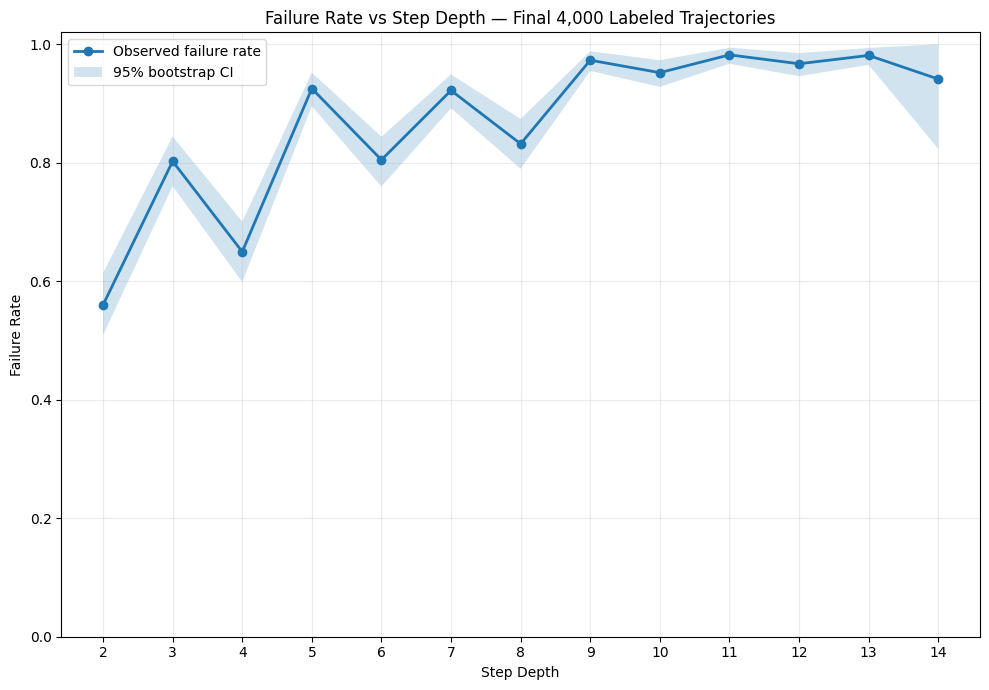

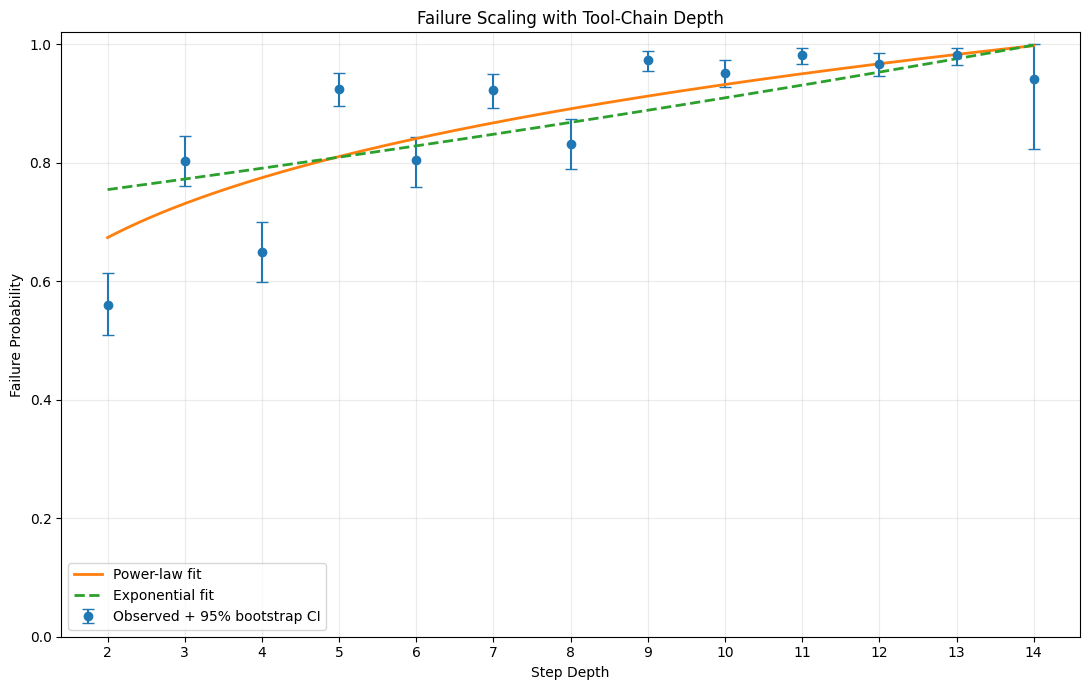

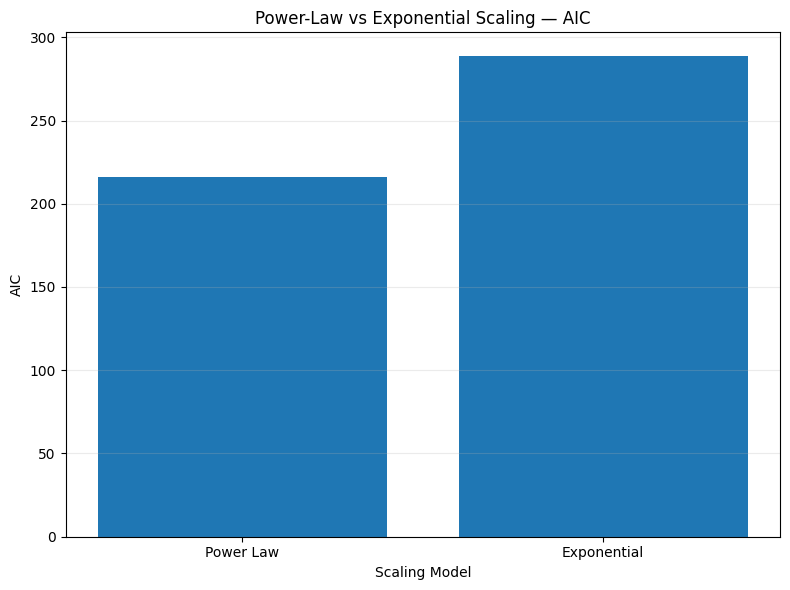

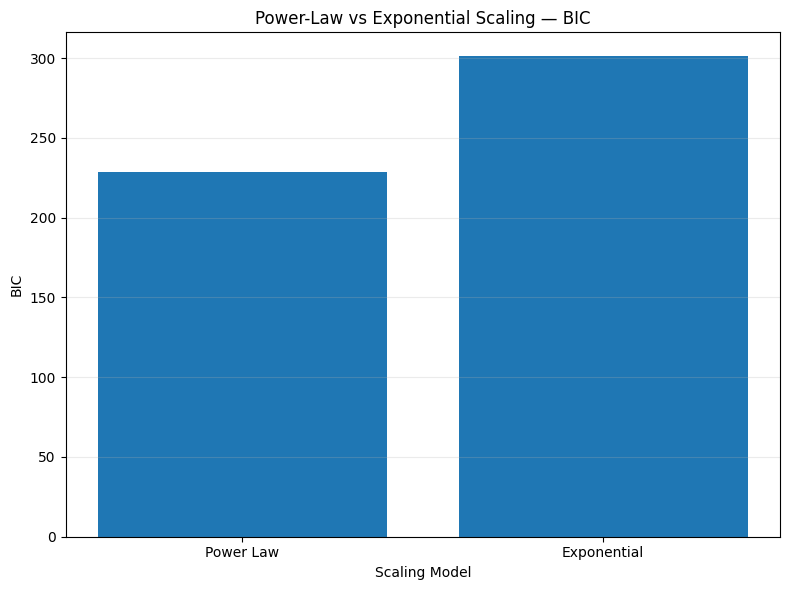

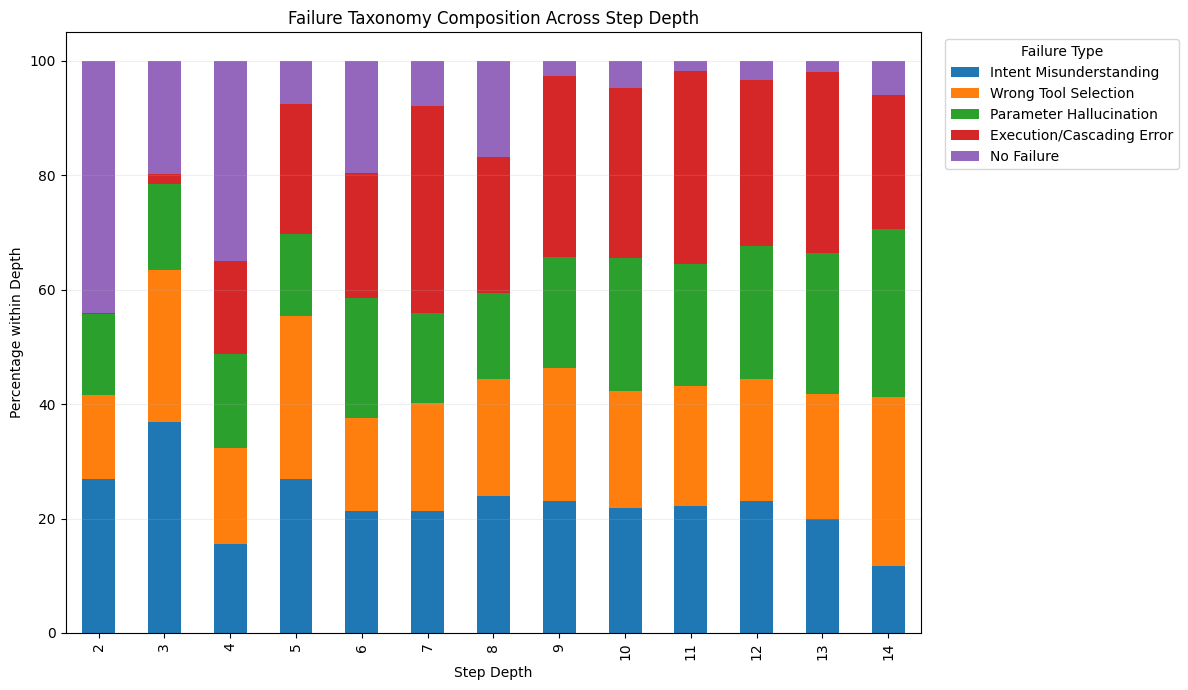

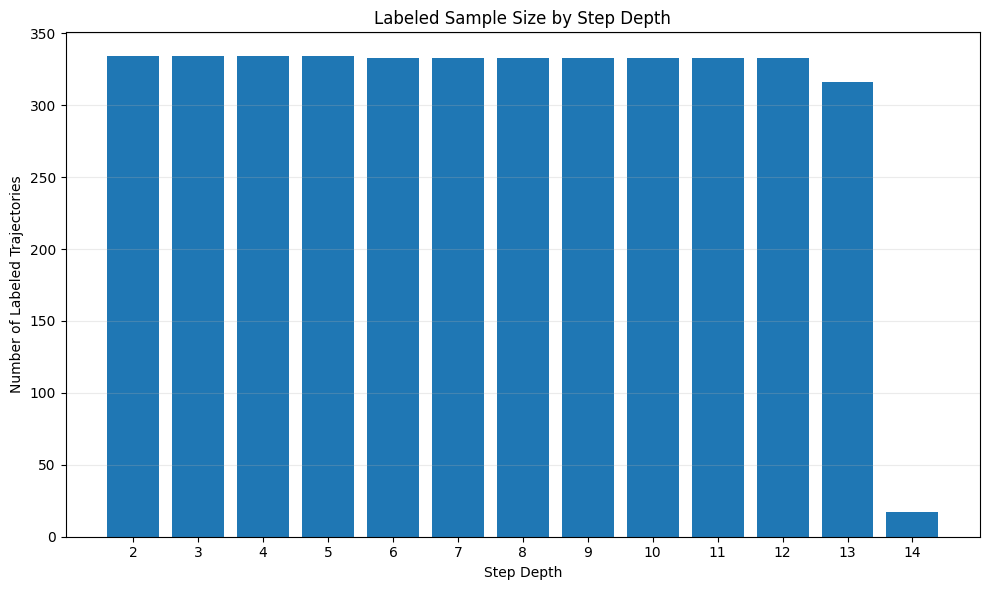

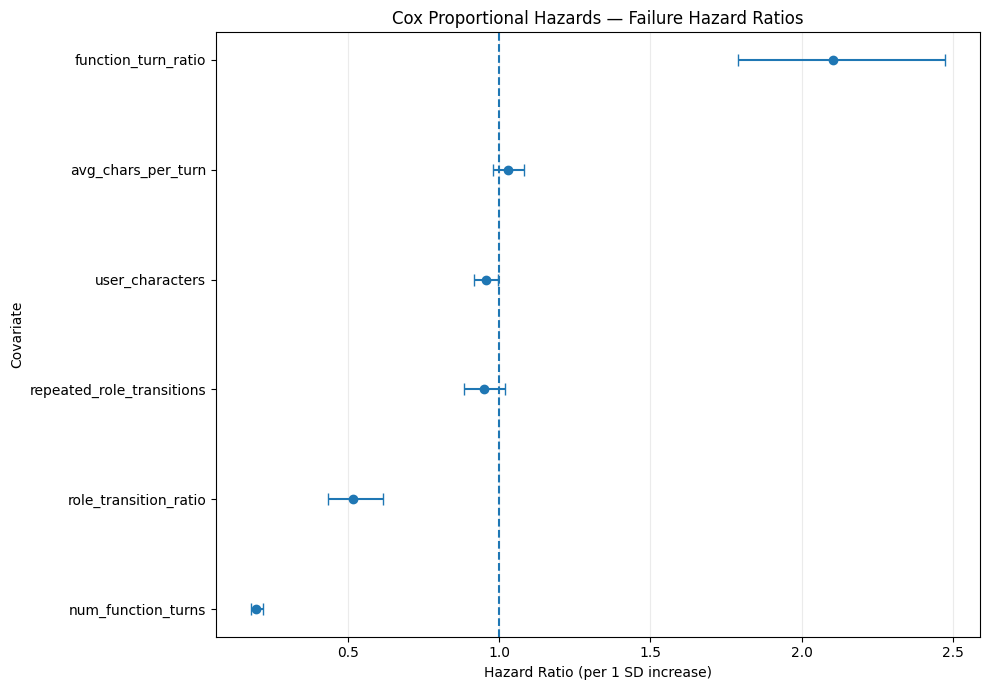

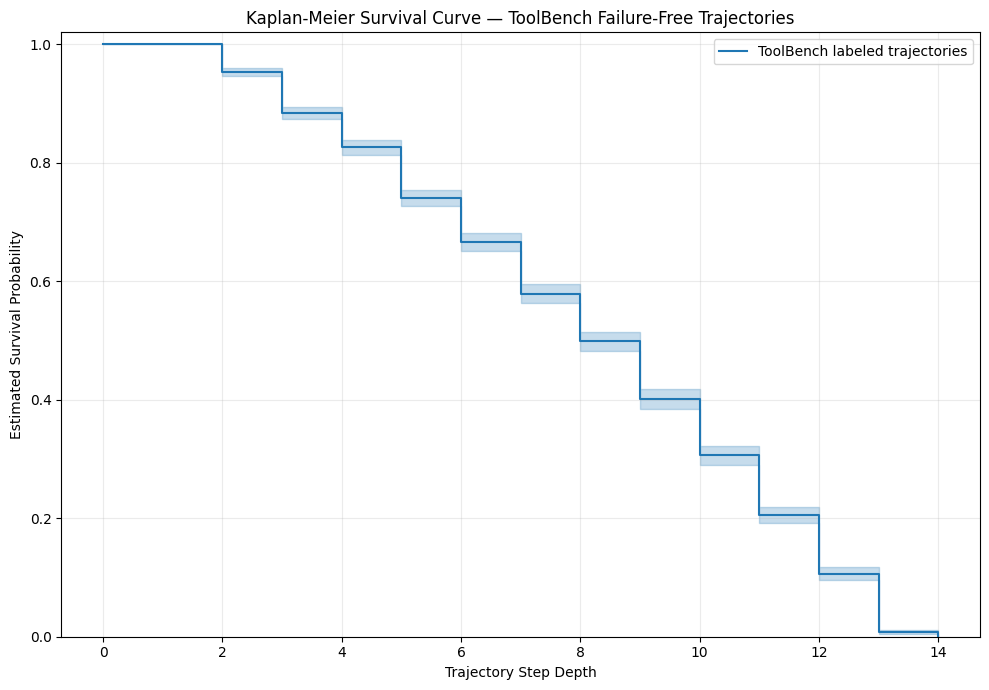

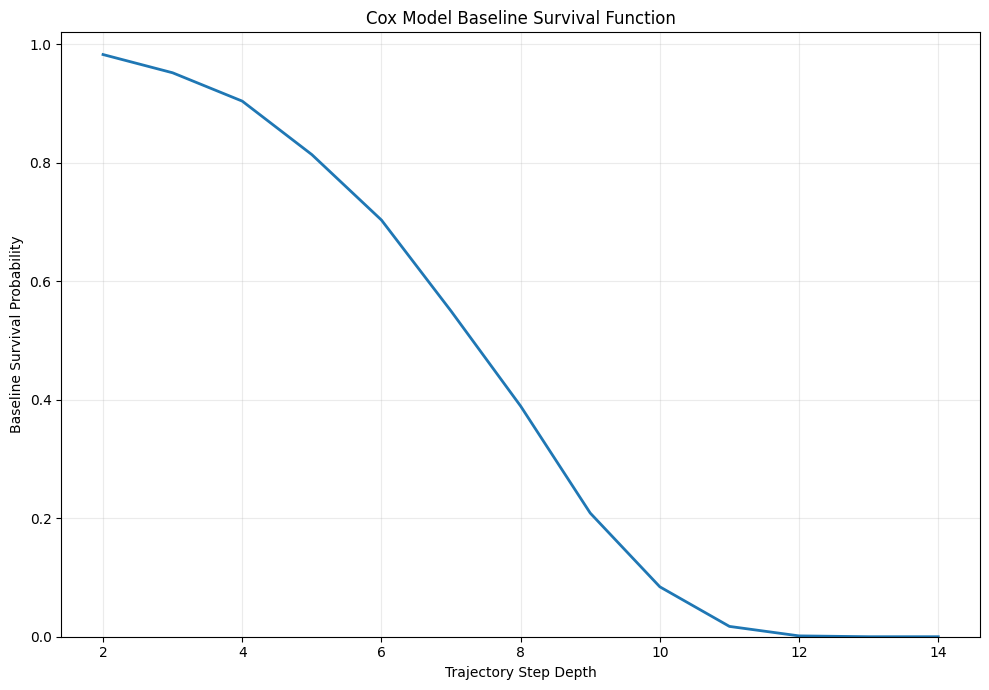


FINAL INTEGRITY CHECK
✓ All integrity checks passed

STEP 7 — FAILURE SCALING ANALYSIS COMPLETE — FINAL 4,000
Trajectories analyzed        : 4,000
Failure trajectories         : 3,449
No-Failure trajectories      : 551
Exact depth range            : 2–14
Depth levels analyzed        : 13
Bootstrap iterations/depth   : 5,000
Confidence interval          : 95%

--- DEPTH CHANGE ---
Failure rate at depth 2  : 0.5599 (55.99%)
Failure rate at depth 14 : 0.9412 (94.12%)
Absolute change             : +0.3813 (+38.13 percentage points)
Relative change             : +68.10%

--- POWER-LAW MODEL ---
a                          : 0.58568089
b                          : 0.20176260
Log Likelihood             : -106.0423
AIC                        : 216.0846
BIC                        : 228.6727
RMSE                       : 0.069532
R²                         : 0.710823

--- EXPONENTIAL MODEL ---
a                          : 0.72017877
b                          : 0.02333262
Log Likelihood          

In [27]:
# ==================================================================================================
# STEP 7 — FAILURE RATE SCALING WITH REASONING / TOOL-CHAIN DEPTH
# FINAL 4,000-LABEL VERSION
#
# PRIMARY QUESTION:
#   How does the probability of failure change as trajectory depth increases?
#
# FAILURE DEFINITION:
#   Failure = any of the four failure classes
#   Success = "No Failure"
#
# ANALYSES:
#   1. Failure rate at each exact step depth
#   2. 5,000-bootstrap 95% confidence intervals
#   3. Failure-type composition by depth
#   4. Power-law scaling model
#          p(failure | depth) = a * depth^b
#   5. Exponential / log-linear scaling model
#          p(failure | depth) = a * exp(b * depth)
#   6. Binomial maximum-likelihood fitting
#   7. AIC / BIC model comparison
#   8. RMSE / R² descriptive fit statistics
#   9. Cox Proportional Hazards survival analysis
#  10. Kaplan-Meier survival curve
#  11. Proportional-hazards assumption test
#  12. Publication-quality figures
#
# DATA:
#   Final GPT-OSS labels = 4,000
#   Step depth recovered from Step-3 features if necessary
#
# IMPORTANT:
#   ✓ Uses final 4,000 labels
#   ✓ Does NOT use XGBoost predictions as ground truth
#   ✓ Does NOT touch ToolBench held-out validation split
#   ✓ Uses exact numerical depth for model fitting
#   ✓ 13+ sampling bucket does not replace actual numerical step depth
#   ✓ New outputs use _4000 suffix
#
# GPU:
#   NOT REQUIRED
# ==================================================================================================


# ==================================================================================================
# 0. IMPORTS
# ==================================================================================================

import os
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.special import gammaln

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

try:
    from lifelines import CoxPHFitter, KaplanMeierFitter
    from lifelines.statistics import proportional_hazard_test
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lifelines"])
    from lifelines import CoxPHFitter, KaplanMeierFitter
    from lifelines.statistics import proportional_hazard_test

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

rng = np.random.default_rng(
    RANDOM_STATE
)


# ==================================================================================================
# 1. CONFIGURATION
# ==================================================================================================

BASE = Path(
    "/kaggle/working/toolbench_research"
)


PROCESSED_DIR = (
    BASE
    /
    "data"
    /
    "processed"
)


TABLE_DIR = (
    BASE
    /
    "results"
    /
    "tables"
)


FIGURE_DIR = (
    BASE
    /
    "results"
    /
    "figures"
)


for directory in [
    PROCESSED_DIR,
    TABLE_DIR,
    FIGURE_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


EXPECTED_ROWS = 4000

BOOTSTRAP_ITERATIONS = 5000

CI_LEVEL = 0.95

ALPHA = (
    1.0
    -
    CI_LEVEL
)


MIN_DEPTH_COUNT_FOR_MODEL = 10

PROB_EPS = 1e-8


# ==================================================================================================
# 2. INPUT FILES
# ==================================================================================================

MASTER_SETUP_ROOT = Path(
    "/kaggle/input/datasets/anandadevnath/master-setup"
)


if not MASTER_SETUP_ROOT.exists():

    raise FileNotFoundError(
        f"Master setup root not found:\n{MASTER_SETUP_ROOT}"
    )


backup_candidates = sorted(
    [
        path
        for path in MASTER_SETUP_ROOT.glob(
            "ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_*"
        )
        if path.is_dir()
    ]
)


if not backup_candidates:

    raise FileNotFoundError(
        "Could not locate ToolBench final backup inside:\n"
        f"{MASTER_SETUP_ROOT}"
    )


FINAL_BACKUP_ROOT = backup_candidates[-1]


BACKUP_RESEARCH_ROOT = (
    FINAL_BACKUP_ROOT
    /
    "CURRENT_RESEARCH"
)


SOURCE_MASTER_BACKUP = (
    FINAL_BACKUP_ROOT
    /
    "SOURCE_MASTER_BACKUP"
)


def first_existing(
    candidates,
    description
):

    for candidate in candidates:

        candidate = Path(candidate)

        if candidate.exists():

            print(
                f"✓ Found {description}:\n{candidate}"
            )

            return candidate


    raise FileNotFoundError(
        f"Could not locate {description}.\nChecked:\n"
        +
        "\n".join(
            str(Path(p))
            for p in candidates
        )
    )


LABEL_FILE = first_existing(
    [
        PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.parquet",

        BACKUP_RESEARCH_ROOT
        /
        "data"
        /
        "processed"
        /
        "step4_gptoss120b_target4000_FINAL.parquet",

        PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.csv",

        BACKUP_RESEARCH_ROOT
        /
        "data"
        /
        "processed"
        /
        "step4_gptoss120b_target4000_FINAL.csv"
    ],
    "final 4,000 GPT-OSS labels"
)


FEATURE_FILE = first_existing(
    [
        SOURCE_MASTER_BACKUP
        /
        "featured"
        /
        "toolbench_train_80_features.parquet",

        MASTER_SETUP_ROOT
        /
        "featured"
        /
        "toolbench_train_80_features.parquet"
    ],
    "Step-3 structural features"
)


print(
    "=" * 118
)

print(
    "STEP 7 — FAILURE RATE SCALING ANALYSIS — FINAL 4,000 LABELS"
)

print(
    "=" * 118
)


print(
    f"\nFinal backup:\n{FINAL_BACKUP_ROOT}"
)

print(
    f"\nLabel file:\n{LABEL_FILE}"
)

print(
    f"\nFeature file:\n{FEATURE_FILE}"
)


# ==================================================================================================
# 3. FAILURE TAXONOMY
# ==================================================================================================

LABEL_ORDER = [
    "Intent Misunderstanding",
    "Wrong Tool Selection",
    "Parameter Hallucination",
    "Execution/Cascading Error",
    "No Failure"
]


FAILURE_LABELS = [
    "Intent Misunderstanding",
    "Wrong Tool Selection",
    "Parameter Hallucination",
    "Execution/Cascading Error"
]


NO_FAILURE_LABEL = (
    "No Failure"
)


# ==================================================================================================
# 4. LOAD FINAL 4,000 LABELS
# ==================================================================================================

labels_df = pd.read_parquet(
    LABEL_FILE
)


required_label_columns = [
    "id",
    "llm_failure_type"
]


for column in required_label_columns:

    if column not in labels_df.columns:

        raise ValueError(
            f"Missing label column: {column}"
        )


labels_df[
    "id"
] = (
    labels_df[
        "id"
    ]
    .astype(str)
    .str.strip()
)


labels_df[
    "llm_failure_type"
] = (
    labels_df[
        "llm_failure_type"
    ]
    .astype(str)
    .str.strip()
)


labels_df = (
    labels_df[
        labels_df[
            "llm_failure_type"
        ]
        .isin(
            LABEL_ORDER
        )
    ]
    .copy()
    .drop_duplicates(
        subset=[
            "id"
        ],
        keep="last"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n"
    + "=" * 118
)

print(
    "FINAL LABEL DATASET"
)

print(
    "=" * 118
)


print(
    f"Valid labels : {len(labels_df):,}"
)

print(
    f"Unique IDs   : {labels_df['id'].nunique():,}"
)


if len(
    labels_df
) != EXPECTED_ROWS:

    raise RuntimeError(
        f"Expected {EXPECTED_ROWS:,} labels, "
        f"found {len(labels_df):,}."
    )


if labels_df[
    "id"
].nunique() != EXPECTED_ROWS:

    raise RuntimeError(
        "Expected exactly 4,000 unique trajectory IDs."
    )


print(
    "\nFailure taxonomy distribution:"
)


print(
    labels_df[
        "llm_failure_type"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0
    )
    .to_string()
)


# ==================================================================================================
# 5. LOAD STEP-3 FEATURES FOR AUTHORITATIVE STEP DEPTH
# ==================================================================================================

COX_COVARIATES = [
    "num_function_turns",
    "user_characters",
    "avg_chars_per_turn",
    "function_turn_ratio",
    "role_transition_ratio",
    "repeated_role_transitions"
]

FEATURE_COLUMNS = [
    "id",
    "step_depth"
] + COX_COVARIATES

features_df = pd.read_parquet(
    FEATURE_FILE,
    columns=FEATURE_COLUMNS
)


features_df[
    "id"
] = (
    features_df[
        "id"
    ]
    .astype(str)
    .str.strip()
)


if features_df[
    "id"
].duplicated().any():

    raise RuntimeError(
        "Duplicate IDs found in Step-3 feature file."
    )


features_df[
    "step_depth"
] = pd.to_numeric(
    features_df[
        "step_depth"
    ],
    errors="coerce"
)


# ==================================================================================================
# 6. MERGE LABELS WITH EXACT STEP DEPTH
# ==================================================================================================

df = (
    labels_df[
        [
            "id",
            "llm_failure_type"
        ]
    ]
    .merge(
        features_df,
        on="id",
        how="left",
        validate="one_to_one"
    )
)


missing_depth = int(
    df[
        "step_depth"
    ]
    .isna()
    .sum()
)


print(
    "\n"
    + "=" * 118
)

print(
    "LABEL + STEP DEPTH MERGE"
)

print(
    "=" * 118
)


print(
    f"Merged trajectories : {len(df):,}"
)

print(
    f"Missing step depth  : {missing_depth:,}"
)


if missing_depth != 0:

    raise RuntimeError(
        "Some final labeled trajectories do not have Step-3 depth."
    )


df[
    "step_depth"
] = (
    df[
        "step_depth"
    ]
    .astype(int)
)


if (
    df[
        "step_depth"
    ]
    <
    2
).any():

    raise RuntimeError(
        "Unexpected trajectory depth below 2."
    )


print(
    f"Minimum depth : {df['step_depth'].min()}"
)

print(
    f"Maximum depth : {df['step_depth'].max()}"
)


# ==================================================================================================
# 7. CREATE BINARY FAILURE TARGET
# ==================================================================================================

df[
    "is_failure"
] = (
    df[
        "llm_failure_type"
    ]
    !=
    NO_FAILURE_LABEL
).astype(
    int
)


total_failures = int(
    df[
        "is_failure"
    ]
    .sum()
)


total_successes = int(
    len(df)
    -
    total_failures
)


print(
    "\n"
    + "=" * 118
)

print(
    "BINARY FAILURE TARGET"
)

print(
    "=" * 118
)


print(
    f"Failure trajectories    : {total_failures:,}"
)

print(
    f"No-Failure trajectories : {total_successes:,}"
)

print(
    f"Sample failure fraction : "
    f"{df['is_failure'].mean():.4f} "
    f"({df['is_failure'].mean() * 100:.2f}%)"
)


# ==================================================================================================
# 8. DEPTH DISTRIBUTION
# ==================================================================================================

depth_counts = (
    df[
        "step_depth"
    ]
    .value_counts()
    .sort_index()
)


print(
    "\nDepth distribution:"
)

print(
    depth_counts.to_string()
)


# ==================================================================================================
# 9. BOOTSTRAP FUNCTION
# ==================================================================================================

def bootstrap_failure_rate(
    binary_values,
    iterations=BOOTSTRAP_ITERATIONS,
    alpha=ALPHA,
    random_seed=RANDOM_STATE
):

    values = np.asarray(
        binary_values,
        dtype=int
    )


    n = len(
        values
    )


    if n == 0:

        return (
            np.nan,
            np.nan,
            np.nan,
            np.nan
        )


    observed_rate = float(
        values.mean()
    )


    local_rng = np.random.default_rng(
        random_seed
    )


    # ----------------------------------------------------------------------------------------------
    # For binary outcomes, a bootstrap resample can be represented
    # efficiently by drawing n observations with replacement.
    # ----------------------------------------------------------------------------------------------

    bootstrap_rates = np.empty(
        iterations,
        dtype=float
    )


    for iteration in range(
        iterations
    ):

        sample = local_rng.choice(
            values,
            size=n,
            replace=True
        )


        bootstrap_rates[
            iteration
        ] = sample.mean()


    lower = float(
        np.quantile(
            bootstrap_rates,
            alpha / 2.0
        )
    )


    upper = float(
        np.quantile(
            bootstrap_rates,
            1.0
            -
            alpha / 2.0
        )
    )


    standard_error = float(
        np.std(
            bootstrap_rates,
            ddof=1
        )
    )


    return (
        observed_rate,
        lower,
        upper,
        standard_error
    )


# ==================================================================================================
# 10. FAILURE RATE + BOOTSTRAP CI AT EACH DEPTH
# ==================================================================================================

print(
    "\n"
    + "=" * 118
)

print(
    f"BOOTSTRAP FAILURE RATE BY DEPTH — "
    f"{BOOTSTRAP_ITERATIONS:,} ITERATIONS"
)

print(
    "=" * 118
)


depth_records = []


unique_depths = sorted(
    df[
        "step_depth"
    ]
    .unique()
)


for depth in unique_depths:

    subset = df[
        df[
            "step_depth"
        ]
        ==
        depth
    ]


    values = subset[
        "is_failure"
    ].to_numpy(
        dtype=int
    )


    (
        observed_rate,
        ci_lower,
        ci_upper,
        bootstrap_se
    ) = bootstrap_failure_rate(
        values,
        iterations=BOOTSTRAP_ITERATIONS,
        alpha=ALPHA,
        random_seed=(
            RANDOM_STATE
            +
            int(
                depth
            )
        )
    )


    n_total = len(
        subset
    )


    n_failures = int(
        subset[
            "is_failure"
        ]
        .sum()
    )


    n_no_failure = int(
        n_total
        -
        n_failures
    )


    depth_records.append({
        "step_depth":
            int(
                depth
            ),

        "n_trajectories":
            int(
                n_total
            ),

        "n_failures":
            n_failures,

        "n_no_failure":
            n_no_failure,

        "failure_rate":
            observed_rate,

        "failure_percent":
            observed_rate
            *
            100,

        "bootstrap_se":
            bootstrap_se,

        "ci_lower":
            ci_lower,

        "ci_upper":
            ci_upper,

        "ci_lower_percent":
            ci_lower
            *
            100,

        "ci_upper_percent":
            ci_upper
            *
            100
    })


depth_failure_df = pd.DataFrame(
    depth_records
)


print(
    depth_failure_df[
        [
            "step_depth",
            "n_trajectories",
            "n_failures",
            "n_no_failure",
            "failure_percent",
            "ci_lower_percent",
            "ci_upper_percent"
        ]
    ]
    .to_string(
        index=False,
        formatters={
            "failure_percent":
                lambda x:
                f"{x:.2f}%",

            "ci_lower_percent":
                lambda x:
                f"{x:.2f}%",

            "ci_upper_percent":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


# ==================================================================================================
# 11. FAILURE-TYPE COMPOSITION BY DEPTH
# ==================================================================================================

failure_type_counts = pd.crosstab(
    df[
        "step_depth"
    ],
    df[
        "llm_failure_type"
    ]
)


failure_type_counts = (
    failure_type_counts
    .reindex(
        columns=LABEL_ORDER,
        fill_value=0
    )
    .sort_index()
)


failure_type_percent = (
    failure_type_counts
    .div(
        failure_type_counts.sum(
            axis=1
        ),
        axis=0
    )
    *
    100
)


# ==================================================================================================
# 12. LONG-FORM FAILURE-TYPE TABLE
# ==================================================================================================

failure_type_long_records = []


for depth in failure_type_counts.index:

    depth_total = int(
        failure_type_counts
        .loc[
            depth
        ]
        .sum()
    )


    for label in LABEL_ORDER:

        count = int(
            failure_type_counts
            .loc[
                depth,
                label
            ]
        )


        percent = (
            count
            /
            depth_total
            *
            100
        )


        failure_type_long_records.append({
            "step_depth":
                int(
                    depth
                ),

            "failure_type":
                label,

            "count":
                count,

            "percent_within_depth":
                percent
        })


failure_type_long_df = pd.DataFrame(
    failure_type_long_records
)


# ==================================================================================================
# 13. PREPARE DEPTH DATA FOR SCALING MODELS
# ==================================================================================================

model_depth_df = (
    depth_failure_df[
        depth_failure_df[
            "n_trajectories"
        ]
        >=
        MIN_DEPTH_COUNT_FOR_MODEL
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


if len(
    model_depth_df
) < 4:

    raise RuntimeError(
        "Too few depth levels for scaling-model comparison."
    )


depth_x = (
    model_depth_df[
        "step_depth"
    ]
    .to_numpy(
        dtype=float
    )
)


depth_n = (
    model_depth_df[
        "n_trajectories"
    ]
    .to_numpy(
        dtype=float
    )
)


depth_failures = (
    model_depth_df[
        "n_failures"
    ]
    .to_numpy(
        dtype=float
    )
)


observed_rates = (
    model_depth_df[
        "failure_rate"
    ]
    .to_numpy(
        dtype=float
    )
)


TOTAL_MODEL_OBSERVATIONS = int(
    depth_n.sum()
)


print(
    "\n"
    + "=" * 118
)

print(
    "SCALING-MODEL INPUT"
)

print(
    "=" * 118
)


print(
    f"Depth levels modeled    : {len(model_depth_df)}"
)

print(
    f"Trajectory observations : {TOTAL_MODEL_OBSERVATIONS:,}"
)

print(
    f"Minimum depth modeled   : {int(depth_x.min())}"
)

print(
    f"Maximum depth modeled   : {int(depth_x.max())}"
)


# ==================================================================================================
# 14. BINOMIAL LOG-LIKELIHOOD
# ==================================================================================================

def binomial_log_likelihood(
    successes,
    totals,
    probabilities
):

    probabilities = np.clip(
        np.asarray(
            probabilities,
            dtype=float
        ),
        PROB_EPS,
        1.0
        -
        PROB_EPS
    )


    successes = np.asarray(
        successes,
        dtype=float
    )


    totals = np.asarray(
        totals,
        dtype=float
    )


    failures = (
        totals
        -
        successes
    )


    log_choose = (
        gammaln(
            totals
            +
            1
        )
        -
        gammaln(
            successes
            +
            1
        )
        -
        gammaln(
            failures
            +
            1
        )
    )


    log_likelihood = np.sum(
        log_choose
        +
        successes
        *
        np.log(
            probabilities
        )
        +
        failures
        *
        np.log(
            1.0
            -
            probabilities
        )
    )


    return float(
        log_likelihood
    )


# ==================================================================================================
# 15. POWER-LAW MODEL
#
# p(depth) = a * depth^b
#
# Optimized internally as:
# a = exp(log_a)
# ==================================================================================================

def power_predictions(
    parameters,
    depth
):

    log_a = parameters[
        0
    ]

    exponent_b = parameters[
        1
    ]


    a = np.exp(
        log_a
    )


    probabilities = (
        a
        *
        np.power(
            depth,
            exponent_b
        )
    )


    return probabilities


def power_negative_log_likelihood(
    parameters
):

    probabilities = power_predictions(
        parameters,
        depth_x
    )


    # ----------------------------------------------------------------------------------------------
    # Explicit validity penalty.
    # This prevents an unconstrained power curve from becoming > 1.
    # ----------------------------------------------------------------------------------------------

    if (
        np.any(
            probabilities <= PROB_EPS
        )
        or
        np.any(
            probabilities >=
            1.0
            -
            PROB_EPS
        )
    ):

        invalid_low = np.maximum(
            PROB_EPS
            -
            probabilities,
            0
        )


        invalid_high = np.maximum(
            probabilities
            -
            (
                1.0
                -
                PROB_EPS
            ),
            0
        )


        penalty = (
            1e8
            *
            (
                np.sum(
                    invalid_low ** 2
                )
                +
                np.sum(
                    invalid_high ** 2
                )
                +
                1
            )
        )


        return float(
            penalty
        )


    log_likelihood = binomial_log_likelihood(
        depth_failures,
        depth_n,
        probabilities
    )


    return (
        -log_likelihood
    )


# ==================================================================================================
# 16. INITIAL POWER-LAW ESTIMATE
# ==================================================================================================

safe_rates = np.clip(
    observed_rates,
    1e-5,
    1
    -
    1e-5
)


initial_power_coefficients = np.polyfit(
    np.log(
        depth_x
    ),
    np.log(
        safe_rates
    ),
    1
)


initial_power_b = float(
    initial_power_coefficients[
        0
    ]
)


initial_power_log_a = float(
    initial_power_coefficients[
        1
    ]
)


power_initial = np.array([
    initial_power_log_a,
    initial_power_b
])


# ==================================================================================================
# 17. FIT POWER LAW
# ==================================================================================================

power_fit = minimize(
    power_negative_log_likelihood,
    x0=power_initial,
    method="Nelder-Mead",
    options={
        "maxiter":
            50000,

        "xatol":
            1e-10,

        "fatol":
            1e-10
    }
)


if not power_fit.success:

    print(
        "\n⚠ Primary Power-Law optimizer warning:"
    )

    print(
        power_fit.message
    )


power_parameters = (
    power_fit.x
)


power_log_a = float(
    power_parameters[
        0
    ]
)


power_a = float(
    np.exp(
        power_log_a
    )
)


power_b = float(
    power_parameters[
        1
    ]
)


power_probabilities = power_predictions(
    power_parameters,
    depth_x
)


power_probabilities = np.clip(
    power_probabilities,
    PROB_EPS,
    1
    -
    PROB_EPS
)


power_loglik = binomial_log_likelihood(
    depth_failures,
    depth_n,
    power_probabilities
)


# ==================================================================================================
# 18. EXPONENTIAL / LOG-LINEAR MODEL
#
# p(depth) = a * exp(b * depth)
#
# Equivalent:
# log p(depth) = log(a) + b * depth
# ==================================================================================================

def exponential_predictions(
    parameters,
    depth
):

    log_a = parameters[
        0
    ]

    slope_b = parameters[
        1
    ]


    probabilities = np.exp(
        log_a
        +
        slope_b
        *
        depth
    )


    return probabilities


def exponential_negative_log_likelihood(
    parameters
):

    probabilities = exponential_predictions(
        parameters,
        depth_x
    )


    if (
        np.any(
            probabilities <= PROB_EPS
        )
        or
        np.any(
            probabilities >=
            1.0
            -
            PROB_EPS
        )
    ):

        invalid_low = np.maximum(
            PROB_EPS
            -
            probabilities,
            0
        )


        invalid_high = np.maximum(
            probabilities
            -
            (
                1.0
                -
                PROB_EPS
            ),
            0
        )


        penalty = (
            1e8
            *
            (
                np.sum(
                    invalid_low ** 2
                )
                +
                np.sum(
                    invalid_high ** 2
                )
                +
                1
            )
        )


        return float(
            penalty
        )


    log_likelihood = binomial_log_likelihood(
        depth_failures,
        depth_n,
        probabilities
    )


    return (
        -log_likelihood
    )


# ==================================================================================================
# 19. INITIAL EXPONENTIAL ESTIMATE
# ==================================================================================================

initial_exponential_coefficients = np.polyfit(
    depth_x,
    np.log(
        safe_rates
    ),
    1
)


initial_exponential_b = float(
    initial_exponential_coefficients[
        0
    ]
)


initial_exponential_log_a = float(
    initial_exponential_coefficients[
        1
    ]
)


exponential_initial = np.array([
    initial_exponential_log_a,
    initial_exponential_b
])


# ==================================================================================================
# 20. FIT EXPONENTIAL MODEL
# ==================================================================================================

exponential_fit = minimize(
    exponential_negative_log_likelihood,
    x0=exponential_initial,
    method="Nelder-Mead",
    options={
        "maxiter":
            50000,

        "xatol":
            1e-10,

        "fatol":
            1e-10
    }
)


if not exponential_fit.success:

    print(
        "\n⚠ Primary Exponential optimizer warning:"
    )

    print(
        exponential_fit.message
    )


exponential_parameters = (
    exponential_fit.x
)


exponential_log_a = float(
    exponential_parameters[
        0
    ]
)


exponential_a = float(
    np.exp(
        exponential_log_a
    )
)


exponential_b = float(
    exponential_parameters[
        1
    ]
)


exponential_probabilities = exponential_predictions(
    exponential_parameters,
    depth_x
)


exponential_probabilities = np.clip(
    exponential_probabilities,
    PROB_EPS,
    1
    -
    PROB_EPS
)


exponential_loglik = binomial_log_likelihood(
    depth_failures,
    depth_n,
    exponential_probabilities
)


# ==================================================================================================
# 21. INFORMATION CRITERIA
#
# Both models have 2 free parameters:
#   a, b
#
# AIC = 2k - 2 log(L)
# BIC = k log(N) - 2 log(L)
#
# N = number of trajectory-level Bernoulli observations
# ==================================================================================================

NUMBER_PARAMETERS = 2


power_aic = (
    2
    *
    NUMBER_PARAMETERS
    -
    2
    *
    power_loglik
)


power_bic = (
    NUMBER_PARAMETERS
    *
    np.log(
        TOTAL_MODEL_OBSERVATIONS
    )
    -
    2
    *
    power_loglik
)


exponential_aic = (
    2
    *
    NUMBER_PARAMETERS
    -
    2
    *
    exponential_loglik
)


exponential_bic = (
    NUMBER_PARAMETERS
    *
    np.log(
        TOTAL_MODEL_OBSERVATIONS
    )
    -
    2
    *
    exponential_loglik
)


# ==================================================================================================
# 22. DESCRIPTIVE MODEL FIT METRICS
# ==================================================================================================

power_rmse = float(
    np.sqrt(
        mean_squared_error(
            observed_rates,
            power_probabilities
        )
    )
)


exponential_rmse = float(
    np.sqrt(
        mean_squared_error(
            observed_rates,
            exponential_probabilities
        )
    )
)


power_r2 = float(
    r2_score(
        observed_rates,
        power_probabilities
    )
)


exponential_r2 = float(
    r2_score(
        observed_rates,
        exponential_probabilities
    )
)


# ==================================================================================================
# 23. MODEL COMPARISON TABLE
# ==================================================================================================

model_comparison_df = pd.DataFrame([
    {
        "model":
            "Power Law",

        "equation":
            "p = a * depth^b",

        "parameter_a":
            power_a,

        "parameter_b":
            power_b,

        "log_likelihood":
            power_loglik,

        "num_parameters":
            NUMBER_PARAMETERS,

        "AIC":
            power_aic,

        "BIC":
            power_bic,

        "RMSE":
            power_rmse,

        "R2":
            power_r2
    },

    {
        "model":
            "Exponential",

        "equation":
            "p = a * exp(b * depth)",

        "parameter_a":
            exponential_a,

        "parameter_b":
            exponential_b,

        "log_likelihood":
            exponential_loglik,

        "num_parameters":
            NUMBER_PARAMETERS,

        "AIC":
            exponential_aic,

        "BIC":
            exponential_bic,

        "RMSE":
            exponential_rmse,

        "R2":
            exponential_r2
    }
])


model_comparison_df[
    "delta_AIC"
] = (
    model_comparison_df[
        "AIC"
    ]
    -
    model_comparison_df[
        "AIC"
    ].min()
)


model_comparison_df[
    "delta_BIC"
] = (
    model_comparison_df[
        "BIC"
    ]
    -
    model_comparison_df[
        "BIC"
    ].min()
)


model_comparison_df = (
    model_comparison_df
    .sort_values(
        [
            "AIC",
            "BIC"
        ],
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


best_aic_model = (
    model_comparison_df
    .sort_values(
        "AIC"
    )
    .iloc[
        0
    ][
        "model"
    ]
)


best_bic_model = (
    model_comparison_df
    .sort_values(
        "BIC"
    )
    .iloc[
        0
    ][
        "model"
    ]
)


print(
    "\n"
    + "=" * 118
)

print(
    "SCALING MODEL COMPARISON"
)

print(
    "=" * 118
)


print(
    model_comparison_df.to_string(
        index=False,
        formatters={
            "parameter_a":
                lambda x:
                f"{x:.8f}",

            "parameter_b":
                lambda x:
                f"{x:.8f}",

            "log_likelihood":
                lambda x:
                f"{x:.4f}",

            "AIC":
                lambda x:
                f"{x:.4f}",

            "BIC":
                lambda x:
                f"{x:.4f}",

            "delta_AIC":
                lambda x:
                f"{x:.4f}",

            "delta_BIC":
                lambda x:
                f"{x:.4f}",

            "RMSE":
                lambda x:
                f"{x:.6f}",

            "R2":
                lambda x:
                f"{x:.6f}"
        }
    )
)


print(
    f"\nBest model by AIC : {best_aic_model}"
)

print(
    f"Best model by BIC : {best_bic_model}"
)


# ==================================================================================================
# 24. MODEL PREDICTIONS AT OBSERVED DEPTHS
# ==================================================================================================

model_depth_df[
    "power_predicted_failure_rate"
] = (
    power_probabilities
)


model_depth_df[
    "exponential_predicted_failure_rate"
] = (
    exponential_probabilities
)


model_depth_df[
    "power_residual"
] = (
    model_depth_df[
        "failure_rate"
    ]
    -
    model_depth_df[
        "power_predicted_failure_rate"
    ]
)


model_depth_df[
    "exponential_residual"
] = (
    model_depth_df[
        "failure_rate"
    ]
    -
    model_depth_df[
        "exponential_predicted_failure_rate"
    ]
)


# ==================================================================================================
# 25. SMOOTH CURVES FOR FIGURE
# ==================================================================================================

depth_grid = np.linspace(
    depth_x.min(),
    depth_x.max(),
    400
)


power_curve = power_predictions(
    power_parameters,
    depth_grid
)


exponential_curve = exponential_predictions(
    exponential_parameters,
    depth_grid
)


power_curve = np.clip(
    power_curve,
    0,
    1
)


exponential_curve = np.clip(
    exponential_curve,
    0,
    1
)


curve_df = pd.DataFrame({
    "step_depth":
        depth_grid,

    "power_law_failure_rate":
        power_curve,

    "exponential_failure_rate":
        exponential_curve
})


# ==================================================================================================
# 26. SIMPLE DEPTH TREND SUMMARY
# ==================================================================================================

lowest_depth = int(
    depth_failure_df[
        "step_depth"
    ].min()
)


highest_depth = int(
    depth_failure_df[
        "step_depth"
    ].max()
)


lowest_depth_rate = float(
    depth_failure_df.loc[
        depth_failure_df[
            "step_depth"
        ]
        ==
        lowest_depth,
        "failure_rate"
    ].iloc[
        0
    ]
)


highest_depth_rate = float(
    depth_failure_df.loc[
        depth_failure_df[
            "step_depth"
        ]
        ==
        highest_depth,
        "failure_rate"
    ].iloc[
        0
    ]
)


absolute_change = (
    highest_depth_rate
    -
    lowest_depth_rate
)


if lowest_depth_rate > 0:

    relative_change = (
        highest_depth_rate
        /
        lowest_depth_rate
        -
        1
    )

else:

    relative_change = np.nan


trend_summary_df = pd.DataFrame([
    {
        "lowest_depth":
            lowest_depth,

        "lowest_depth_failure_rate":
            lowest_depth_rate,

        "highest_depth":
            highest_depth,

        "highest_depth_failure_rate":
            highest_depth_rate,

        "absolute_change":
            absolute_change,

        "relative_change":
            relative_change,

        "best_model_AIC":
            best_aic_model,

        "best_model_BIC":
            best_bic_model,

        "bootstrap_iterations":
            BOOTSTRAP_ITERATIONS,

        "ci_level":
            CI_LEVEL
    }
])



# ==================================================================================================
# 27. COX PROPORTIONAL HAZARDS SURVIVAL ANALYSIS
#
# IMPORTANT:
#   ToolBench provides trajectory-level final failure labels, not independently annotated
#   first-failure onset times. Therefore:
#
#       duration = observed trajectory step_depth
#       event    = 1 for any failure class, 0 for "No Failure"
#
#   This is a trajectory-level survival analysis and should NOT be interpreted as an exact
#   per-turn first-failure-time model.
#
#   Continuous Cox covariates are standardized so exp(coef) represents the hazard ratio
#   for a 1-standard-deviation increase in the corresponding feature.
# ==================================================================================================

print(
    "\n"
    + "=" * 118
)

print(
    "COX PROPORTIONAL HAZARDS SURVIVAL ANALYSIS"
)

print(
    "=" * 118
)


cox_source_df = (
    df[
        [
            "id",
            "step_depth",
            "is_failure"
        ]
    ]
    .merge(
        features_df[
            [
                "id"
            ]
            +
            COX_COVARIATES
        ],
        on="id",
        how="left",
        validate="one_to_one"
    )
)


if len(
    cox_source_df
) != EXPECTED_ROWS:

    raise RuntimeError(
        "Cox dataset does not contain exactly 4,000 trajectories."
    )


for column in COX_COVARIATES:

    cox_source_df[
        column
    ] = pd.to_numeric(
        cox_source_df[
            column
        ],
        errors="coerce"
    )


cox_usable_covariates = []


for column in COX_COVARIATES:

    if cox_source_df[
        column
    ].notna().sum() == 0:

        print(
            f"⚠ Cox covariate excluded (all missing): {column}"
        )

        continue


    median_value = float(
        cox_source_df[
            column
        ].median()
    )


    cox_source_df[
        column
    ] = (
        cox_source_df[
            column
        ]
        .fillna(
            median_value
        )
    )


    variance = float(
        cox_source_df[
            column
        ].var(
            ddof=0
        )
    )


    if (
        not np.isfinite(
            variance
        )
        or
        variance <= 0
    ):

        print(
            f"⚠ Cox covariate excluded (zero/invalid variance): {column}"
        )

        continue


    cox_usable_covariates.append(
        column
    )


if not cox_usable_covariates:

    raise RuntimeError(
        "No usable Cox covariates remain."
    )


cox_standardization_records = []


for column in cox_usable_covariates:

    mean_value = float(
        cox_source_df[
            column
        ].mean()
    )


    std_value = float(
        cox_source_df[
            column
        ].std(
            ddof=0
        )
    )


    cox_standardization_records.append(
        {
            "feature":
                column,

            "mean":
                mean_value,

            "std":
                std_value
        }
    )


    cox_source_df[
        column
    ] = (
        cox_source_df[
            column
        ]
        -
        mean_value
    ) / std_value


cox_standardization_df = pd.DataFrame(
    cox_standardization_records
)


cox_model_df = (
    cox_source_df[
        [
            "step_depth",
            "is_failure"
        ]
        +
        cox_usable_covariates
    ]
    .copy()
)


if (
    cox_model_df[
        "step_depth"
    ]
    <= 0
).any():

    raise RuntimeError(
        "Cox analysis contains non-positive duration values."
    )


if not cox_model_df[
    "is_failure"
].isin(
    [
        0,
        1
    ]
).all():

    raise RuntimeError(
        "Cox event indicator is not binary."
    )


print(
    f"Trajectories modeled         : {len(cox_model_df):,}"
)

print(
    f"Failure events               : {int(cox_model_df['is_failure'].sum()):,}"
)

print(
    f"Censored / No Failure        : "
    f"{int((cox_model_df['is_failure'] == 0).sum()):,}"
)

print(
    f"Depth range                  : "
    f"{int(cox_model_df['step_depth'].min())}–"
    f"{int(cox_model_df['step_depth'].max())}"
)

print(
    f"Cox covariates               : {len(cox_usable_covariates)}"
)

for column in cox_usable_covariates:

    print(
        f"✓ {column}"
    )


# --------------------------------------------------------------------------------------------------
# Cox model
# --------------------------------------------------------------------------------------------------

cox_model = CoxPHFitter(
    penalizer=0.01
)


cox_model.fit(
    cox_model_df,
    duration_col="step_depth",
    event_col="is_failure",
    show_progress=False
)


cox_summary_df = (
    cox_model.summary
    .reset_index()
)


if "covariate" not in cox_summary_df.columns:

    first_column = cox_summary_df.columns[
        0
    ]

    cox_summary_df = cox_summary_df.rename(
        columns={
            first_column:
                "covariate"
        }
    )


cox_summary_df[
    "hazard_ratio"
] = np.exp(
    cox_summary_df[
        "coef"
    ]
)


cox_summary_df[
    "hr_ci_lower_95"
] = np.exp(
    cox_summary_df[
        "coef lower 95%"
    ]
)


cox_summary_df[
    "hr_ci_upper_95"
] = np.exp(
    cox_summary_df[
        "coef upper 95%"
    ]
)


cox_summary_df[
    "significant_0_05"
] = (
    cox_summary_df[
        "p"
    ]
    <
    0.05
)


cox_concordance = float(
    cox_model.concordance_index_
)


cox_log_likelihood = float(
    cox_model.log_likelihood_
)


cox_partial_aic = float(
    cox_model.AIC_partial_
)


print(
    "\nCox model summary:"
)

print(
    cox_summary_df[
        [
            "covariate",
            "coef",
            "hazard_ratio",
            "hr_ci_lower_95",
            "hr_ci_upper_95",
            "p",
            "significant_0_05"
        ]
    ]
    .to_string(
        index=False,
        formatters={
            "coef":
                lambda x:
                f"{x:.6f}",

            "hazard_ratio":
                lambda x:
                f"{x:.6f}",

            "hr_ci_lower_95":
                lambda x:
                f"{x:.6f}",

            "hr_ci_upper_95":
                lambda x:
                f"{x:.6f}",

            "p":
                lambda x:
                f"{x:.6g}"
        }
    )
)


print(
    f"\nConcordance index            : {cox_concordance:.6f}"
)

print(
    f"Partial log-likelihood       : {cox_log_likelihood:.6f}"
)

print(
    f"Partial AIC                  : {cox_partial_aic:.6f}"
)


# --------------------------------------------------------------------------------------------------
# Proportional-hazards assumption test
# --------------------------------------------------------------------------------------------------

ph_test = proportional_hazard_test(
    cox_model,
    cox_model_df,
    time_transform="rank"
)


ph_test_df = (
    ph_test.summary
    .reset_index()
)


if "index" in ph_test_df.columns:

    ph_test_df = ph_test_df.rename(
        columns={
            "index":
                "covariate"
        }
    )


if "covariate" not in ph_test_df.columns:

    first_column = ph_test_df.columns[
        0
    ]

    ph_test_df = ph_test_df.rename(
        columns={
            first_column:
                "covariate"
        }
    )


ph_test_df[
    "ph_assumption_pass_0_05"
] = (
    ph_test_df[
        "p"
    ]
    >=
    0.05
)


print(
    "\nProportional-hazards assumption test:"
)

print(
    ph_test_df.to_string(
        index=False,
        formatters={
            "test_statistic":
                lambda x:
                f"{x:.6f}",

            "p":
                lambda x:
                f"{x:.6g}"
        }
    )
)


ph_violations = int(
    (
        ph_test_df[
            "p"
        ]
        <
        0.05
    )
    .sum()
)


# --------------------------------------------------------------------------------------------------
# Kaplan-Meier trajectory-level survival curve
# --------------------------------------------------------------------------------------------------

km_model = KaplanMeierFitter()


km_model.fit(
    durations=cox_model_df[
        "step_depth"
    ],
    event_observed=cox_model_df[
        "is_failure"
    ],
    label="ToolBench labeled trajectories"
)


km_survival_df = (
    km_model.survival_function_
    .reset_index()
)


km_survival_df.columns = [
    "step_depth",
    "survival_probability"
]


km_ci_df = (
    km_model.confidence_interval_
    .reset_index()
)


km_ci_df.columns = [
    "step_depth",
    "ci_lower",
    "ci_upper"
]


km_table_df = (
    km_survival_df
    .merge(
        km_ci_df,
        on="step_depth",
        how="left",
        validate="one_to_one"
    )
)


cox_model_summary_df = pd.DataFrame(
    [
        {
            "n_trajectories":
                len(
                    cox_model_df
                ),

            "n_failure_events":
                int(
                    cox_model_df[
                        "is_failure"
                    ].sum()
                ),

            "n_censored_no_failure":
                int(
                    (
                        cox_model_df[
                            "is_failure"
                        ]
                        ==
                        0
                    ).sum()
                ),

            "minimum_depth":
                int(
                    cox_model_df[
                        "step_depth"
                    ].min()
                ),

            "maximum_depth":
                int(
                    cox_model_df[
                        "step_depth"
                    ].max()
                ),

            "n_covariates":
                len(
                    cox_usable_covariates
                ),

            "concordance_index":
                cox_concordance,

            "partial_log_likelihood":
                cox_log_likelihood,

            "partial_AIC":
                cox_partial_aic,

            "ph_violations_p_lt_0_05":
                ph_violations,

            "interpretation_note":
                (
                    "Trajectory-level depth-to-failure/censoring model; "
                    "exact first-failure onset is not independently annotated."
                )
        }
    ]
)


# ==================================================================================================
# 28. OUTPUT FILE PATHS
# ==================================================================================================

DEPTH_RATE_PATH = (
    TABLE_DIR
    /
    "step7_failure_rate_by_depth_bootstrap_4000.csv"
)


FAILURE_COUNTS_PATH = (
    TABLE_DIR
    /
    "step7_failure_type_counts_by_depth_4000.csv"
)


FAILURE_PERCENT_PATH = (
    TABLE_DIR
    /
    "step7_failure_type_percent_by_depth_4000.csv"
)


FAILURE_LONG_PATH = (
    TABLE_DIR
    /
    "step7_failure_type_distribution_long_4000.csv"
)


MODEL_COMPARISON_PATH = (
    TABLE_DIR
    /
    "step7_scaling_model_comparison_4000.csv"
)


MODEL_PREDICTIONS_PATH = (
    TABLE_DIR
    /
    "step7_scaling_model_depth_predictions_4000.csv"
)


CURVE_PATH = (
    TABLE_DIR
    /
    "step7_scaling_model_curves_4000.csv"
)


TREND_SUMMARY_PATH = (
    TABLE_DIR
    /
    "step7_scaling_trend_summary_4000.csv"
)


ANALYSIS_INPUT_PATH = (
    PROCESSED_DIR
    /
    "step7_failure_scaling_input_4000.parquet"
)



COX_SUMMARY_PATH = (
    TABLE_DIR
    /
    "step7_cox_hazard_ratios_4000.csv"
)


COX_PH_TEST_PATH = (
    TABLE_DIR
    /
    "step7_cox_proportional_hazards_test_4000.csv"
)


COX_STANDARDIZATION_PATH = (
    TABLE_DIR
    /
    "step7_cox_covariate_standardization_4000.csv"
)


COX_MODEL_SUMMARY_PATH = (
    TABLE_DIR
    /
    "step7_cox_model_summary_4000.csv"
)


KM_SURVIVAL_PATH = (
    TABLE_DIR
    /
    "step7_kaplan_meier_survival_4000.csv"
)


COX_ANALYSIS_INPUT_PATH = (
    PROCESSED_DIR
    /
    "step7_cox_survival_input_4000.parquet"
)


# ==================================================================================================
# 29. SAVE TABLES
# ==================================================================================================

depth_failure_df.to_csv(
    DEPTH_RATE_PATH,
    index=False
)


failure_type_counts.to_csv(
    FAILURE_COUNTS_PATH
)


failure_type_percent.to_csv(
    FAILURE_PERCENT_PATH
)


failure_type_long_df.to_csv(
    FAILURE_LONG_PATH,
    index=False
)


model_comparison_df.to_csv(
    MODEL_COMPARISON_PATH,
    index=False
)


model_depth_df.to_csv(
    MODEL_PREDICTIONS_PATH,
    index=False
)


curve_df.to_csv(
    CURVE_PATH,
    index=False
)


trend_summary_df.to_csv(
    TREND_SUMMARY_PATH,
    index=False
)


df.to_parquet(
    ANALYSIS_INPUT_PATH,
    index=False
)


cox_summary_df.to_csv(
    COX_SUMMARY_PATH,
    index=False
)


ph_test_df.to_csv(
    COX_PH_TEST_PATH,
    index=False
)


cox_standardization_df.to_csv(
    COX_STANDARDIZATION_PATH,
    index=False
)


cox_model_summary_df.to_csv(
    COX_MODEL_SUMMARY_PATH,
    index=False
)


km_table_df.to_csv(
    KM_SURVIVAL_PATH,
    index=False
)


cox_source_df.to_parquet(
    COX_ANALYSIS_INPUT_PATH,
    index=False
)


# ==================================================================================================
# 30. FIGURE 1 — FAILURE RATE VS DEPTH WITH BOOTSTRAP CI
# ==================================================================================================

FAILURE_RATE_FIG = (
    FIGURE_DIR
    /
    "step7_failure_rate_vs_depth_bootstrap_4000.png"
)


x_plot = (
    depth_failure_df[
        "step_depth"
    ]
    .to_numpy(
        dtype=float
    )
)


y_plot = (
    depth_failure_df[
        "failure_rate"
    ]
    .to_numpy(
        dtype=float
    )
)


lower_plot = (
    depth_failure_df[
        "ci_lower"
    ]
    .to_numpy(
        dtype=float
    )
)


upper_plot = (
    depth_failure_df[
        "ci_upper"
    ]
    .to_numpy(
        dtype=float
    )
)


fig, ax = plt.subplots(
    figsize=(
        10,
        7
    )
)


ax.plot(
    x_plot,
    y_plot,
    marker="o",
    linewidth=2,
    label="Observed failure rate"
)


ax.fill_between(
    x_plot,
    lower_plot,
    upper_plot,
    alpha=0.20,
    label="95% bootstrap CI"
)


ax.set_xlabel(
    "Step Depth"
)

ax.set_ylabel(
    "Failure Rate"
)

ax.set_title(
    "Failure Rate vs Step Depth — Final 4,000 Labeled Trajectories"
)

ax.set_ylim(
    0,
    1.02
)

ax.set_xticks(
    sorted(
        depth_failure_df[
            "step_depth"
        ].unique()
    )
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()


fig.savefig(
    FAILURE_RATE_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# ==================================================================================================
# 31. FIGURE 2 — OBSERVED FAILURE RATE + POWER / EXPONENTIAL CURVES
# ==================================================================================================

SCALING_FIG = (
    FIGURE_DIR
    /
    "step7_failure_scaling_models_4000.png"
)


fig, ax = plt.subplots(
    figsize=(
        11,
        7
    )
)


ax.errorbar(
    x_plot,
    y_plot,
    yerr=[
        y_plot
        -
        lower_plot,

        upper_plot
        -
        y_plot
    ],
    fmt="o",
    capsize=4,
    label="Observed + 95% bootstrap CI"
)


ax.plot(
    depth_grid,
    power_curve,
    linewidth=2,
    label="Power-law fit"
)


ax.plot(
    depth_grid,
    exponential_curve,
    linewidth=2,
    linestyle="--",
    label="Exponential fit"
)


ax.set_xlabel(
    "Step Depth"
)

ax.set_ylabel(
    "Failure Probability"
)

ax.set_title(
    "Failure Scaling with Tool-Chain Depth"
)

ax.set_ylim(
    0,
    1.02
)

ax.set_xticks(
    sorted(
        depth_failure_df[
            "step_depth"
        ].unique()
    )
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()


fig.savefig(
    SCALING_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# ==================================================================================================
# 32. FIGURE 3 — AIC MODEL COMPARISON
# ==================================================================================================

AIC_FIG = (
    FIGURE_DIR
    /
    "step7_scaling_model_AIC_comparison_4000.png"
)


aic_plot_df = (
    model_comparison_df
    .sort_values(
        "AIC",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(
        8,
        6
    )
)


ax.bar(
    aic_plot_df[
        "model"
    ],
    aic_plot_df[
        "AIC"
    ]
)


ax.set_xlabel(
    "Scaling Model"
)

ax.set_ylabel(
    "AIC"
)

ax.set_title(
    "Power-Law vs Exponential Scaling — AIC"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()


fig.savefig(
    AIC_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# ==================================================================================================
# 33. FIGURE 4 — BIC MODEL COMPARISON
# ==================================================================================================

BIC_FIG = (
    FIGURE_DIR
    /
    "step7_scaling_model_BIC_comparison_4000.png"
)


bic_plot_df = (
    model_comparison_df
    .sort_values(
        "BIC",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(
        8,
        6
    )
)


ax.bar(
    bic_plot_df[
        "model"
    ],
    bic_plot_df[
        "BIC"
    ]
)


ax.set_xlabel(
    "Scaling Model"
)

ax.set_ylabel(
    "BIC"
)

ax.set_title(
    "Power-Law vs Exponential Scaling — BIC"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()


fig.savefig(
    BIC_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# ==================================================================================================
# 34. FIGURE 5 — FAILURE-TYPE COMPOSITION BY DEPTH
# ==================================================================================================

FAILURE_COMPOSITION_FIG = (
    FIGURE_DIR
    /
    "step7_failure_type_composition_by_depth_4000.png"
)


fig, ax = plt.subplots(
    figsize=(
        12,
        7
    )
)


failure_type_percent.plot(
    kind="bar",
    stacked=True,
    ax=ax
)


ax.set_xlabel(
    "Step Depth"
)

ax.set_ylabel(
    "Percentage within Depth"
)

ax.set_title(
    "Failure Taxonomy Composition Across Step Depth"
)

ax.legend(
    title="Failure Type",
    bbox_to_anchor=(
        1.02,
        1
    ),
    loc="upper left"
)

ax.grid(
    axis="y",
    alpha=0.20
)

fig.tight_layout()


fig.savefig(
    FAILURE_COMPOSITION_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# ==================================================================================================
# 35. FIGURE 6 — SAMPLE SIZE BY DEPTH
# ==================================================================================================

DEPTH_COUNT_FIG = (
    FIGURE_DIR
    /
    "step7_sample_size_by_depth_4000.png"
)


fig, ax = plt.subplots(
    figsize=(
        10,
        6
    )
)


ax.bar(
    depth_failure_df[
        "step_depth"
    ].astype(
        str
    ),
    depth_failure_df[
        "n_trajectories"
    ]
)


ax.set_xlabel(
    "Step Depth"
)

ax.set_ylabel(
    "Number of Labeled Trajectories"
)

ax.set_title(
    "Labeled Sample Size by Step Depth"
)

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()


fig.savefig(
    DEPTH_COUNT_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)



# ==================================================================================================
# 35. FIGURE 7 — COX HAZARD-RATIO FOREST PLOT
# ==================================================================================================

COX_FOREST_FIG = (
    FIGURE_DIR
    /
    "step7_cox_hazard_ratio_forest_4000.png"
)


cox_plot_df = (
    cox_summary_df[
        [
            "covariate",
            "hazard_ratio",
            "hr_ci_lower_95",
            "hr_ci_upper_95"
        ]
    ]
    .copy()
    .sort_values(
        "hazard_ratio",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


fig, ax = plt.subplots(
    figsize=(
        10,
        7
    )
)


y_positions = np.arange(
    len(
        cox_plot_df
    )
)


hazard_ratios = (
    cox_plot_df[
        "hazard_ratio"
    ]
    .to_numpy(
        dtype=float
    )
)


lower_errors = (
    hazard_ratios
    -
    cox_plot_df[
        "hr_ci_lower_95"
    ]
    .to_numpy(
        dtype=float
    )
)


upper_errors = (
    cox_plot_df[
        "hr_ci_upper_95"
    ]
    .to_numpy(
        dtype=float
    )
    -
    hazard_ratios
)


ax.errorbar(
    hazard_ratios,
    y_positions,
    xerr=[
        lower_errors,
        upper_errors
    ],
    fmt="o",
    capsize=4
)


ax.axvline(
    1.0,
    linestyle="--",
    linewidth=1.5
)


ax.set_yticks(
    y_positions
)


ax.set_yticklabels(
    cox_plot_df[
        "covariate"
    ]
)


ax.set_xlabel(
    "Hazard Ratio (per 1 SD increase)"
)


ax.set_ylabel(
    "Covariate"
)


ax.set_title(
    "Cox Proportional Hazards — Failure Hazard Ratios"
)


ax.grid(
    axis="x",
    alpha=0.25
)


fig.tight_layout()


fig.savefig(
    COX_FOREST_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# ==================================================================================================
# 36. FIGURE 8 — KAPLAN-MEIER SURVIVAL CURVE
# ==================================================================================================

KM_FIG = (
    FIGURE_DIR
    /
    "step7_kaplan_meier_survival_curve_4000.png"
)


fig, ax = plt.subplots(
    figsize=(
        10,
        7
    )
)


km_model.plot_survival_function(
    ax=ax,
    ci_show=True
)


ax.set_xlabel(
    "Trajectory Step Depth"
)


ax.set_ylabel(
    "Estimated Survival Probability"
)


ax.set_title(
    "Kaplan-Meier Survival Curve — ToolBench Failure-Free Trajectories"
)


ax.set_ylim(
    0,
    1.02
)


ax.grid(
    alpha=0.25
)


fig.tight_layout()


fig.savefig(
    KM_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# ==================================================================================================
# 37. FIGURE 9 — COX BASELINE SURVIVAL
# ==================================================================================================

COX_BASELINE_SURVIVAL_FIG = (
    FIGURE_DIR
    /
    "step7_cox_baseline_survival_4000.png"
)


baseline_survival_df = (
    cox_model.baseline_survival_
    .reset_index()
)


baseline_survival_df.columns = [
    "step_depth",
    "baseline_survival"
]


fig, ax = plt.subplots(
    figsize=(
        10,
        7
    )
)


ax.plot(
    baseline_survival_df[
        "step_depth"
    ],
    baseline_survival_df[
        "baseline_survival"
    ],
    linewidth=2
)


ax.set_xlabel(
    "Trajectory Step Depth"
)


ax.set_ylabel(
    "Baseline Survival Probability"
)


ax.set_title(
    "Cox Model Baseline Survival Function"
)


ax.set_ylim(
    0,
    1.02
)


ax.grid(
    alpha=0.25
)


fig.tight_layout()


fig.savefig(
    COX_BASELINE_SURVIVAL_FIG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# ==================================================================================================
# 38. FINAL INTEGRITY CHECK
# ==================================================================================================

print(
    "\n"
    + "=" * 118
)

print(
    "FINAL INTEGRITY CHECK"
)

print(
    "=" * 118
)


assert len(
    df
) == EXPECTED_ROWS


assert df[
    "id"
].nunique() == EXPECTED_ROWS


assert df[
    "llm_failure_type"
].isin(
    LABEL_ORDER
).all()


assert df[
    "is_failure"
].isin([
    0,
    1
]).all()


assert depth_failure_df[
    "n_trajectories"
].sum() == EXPECTED_ROWS


assert (
    depth_failure_df[
        "n_failures"
    ].sum()
    ==
    total_failures
)


assert (
    depth_failure_df[
        "n_no_failure"
    ].sum()
    ==
    total_successes
)


assert (
    depth_failure_df[
        "ci_lower"
    ]
    <=
    depth_failure_df[
        "failure_rate"
    ]
).all()


assert (
    depth_failure_df[
        "ci_upper"
    ]
    >=
    depth_failure_df[
        "failure_rate"
    ]
).all()


assert (
    depth_failure_df[
        "failure_rate"
    ]
    >=
    0
).all()


assert (
    depth_failure_df[
        "failure_rate"
    ]
    <=
    1
).all()


assert np.isfinite(
    power_aic
)


assert np.isfinite(
    exponential_aic
)


assert np.isfinite(
    power_bic
)


assert np.isfinite(
    exponential_bic
)



assert len(
    cox_source_df
) == EXPECTED_ROWS


assert cox_source_df[
    "is_failure"
].isin(
    [
        0,
        1
    ]
).all()


assert (
    cox_source_df[
        "step_depth"
    ]
    >
    0
).all()


assert np.isfinite(
    cox_concordance
)


assert np.isfinite(
    cox_partial_aic
)


assert len(
    cox_summary_df
) == len(
    cox_usable_covariates
)


assert (
    cox_summary_df[
        "hazard_ratio"
    ]
    >
    0
).all()


required_tables = [
    DEPTH_RATE_PATH,
    FAILURE_COUNTS_PATH,
    FAILURE_PERCENT_PATH,
    FAILURE_LONG_PATH,
    MODEL_COMPARISON_PATH,
    MODEL_PREDICTIONS_PATH,
    CURVE_PATH,
    TREND_SUMMARY_PATH,
    ANALYSIS_INPUT_PATH,
    COX_SUMMARY_PATH,
    COX_PH_TEST_PATH,
    COX_STANDARDIZATION_PATH,
    COX_MODEL_SUMMARY_PATH,
    KM_SURVIVAL_PATH,
    COX_ANALYSIS_INPUT_PATH
]


for path in required_tables:

    if not path.exists():

        raise RuntimeError(
            f"Missing output:\n{path}"
        )


required_figures = [
    FAILURE_RATE_FIG,
    SCALING_FIG,
    AIC_FIG,
    BIC_FIG,
    FAILURE_COMPOSITION_FIG,
    DEPTH_COUNT_FIG,
    COX_FOREST_FIG,
    KM_FIG,
    COX_BASELINE_SURVIVAL_FIG
]


for path in required_figures:

    if not path.exists():

        raise RuntimeError(
            f"Missing figure:\n{path}"
        )


print(
    "✓ All integrity checks passed"
)


# ==================================================================================================
# 39. FINAL SUMMARY
# ==================================================================================================

print(
    "\n"
    + "=" * 118
)

print(
    "STEP 7 — FAILURE SCALING ANALYSIS COMPLETE — FINAL 4,000"
)

print(
    "=" * 118
)


print(
    f"Trajectories analyzed        : {len(df):,}"
)

print(
    f"Failure trajectories         : {total_failures:,}"
)

print(
    f"No-Failure trajectories      : {total_successes:,}"
)

print(
    f"Exact depth range            : "
    f"{df['step_depth'].min()}–{df['step_depth'].max()}"
)

print(
    f"Depth levels analyzed        : "
    f"{len(depth_failure_df)}"
)

print(
    f"Bootstrap iterations/depth   : "
    f"{BOOTSTRAP_ITERATIONS:,}"
)

print(
    f"Confidence interval          : "
    f"{CI_LEVEL * 100:.0f}%"
)


print(
    "\n--- DEPTH CHANGE ---"
)

print(
    f"Failure rate at depth {lowest_depth:<2} : "
    f"{lowest_depth_rate:.4f} "
    f"({lowest_depth_rate * 100:.2f}%)"
)

print(
    f"Failure rate at depth {highest_depth:<2} : "
    f"{highest_depth_rate:.4f} "
    f"({highest_depth_rate * 100:.2f}%)"
)

print(
    f"Absolute change             : "
    f"{absolute_change:+.4f} "
    f"({absolute_change * 100:+.2f} percentage points)"
)


if np.isfinite(
    relative_change
):

    print(
        f"Relative change             : "
        f"{relative_change * 100:+.2f}%"
    )


print(
    "\n--- POWER-LAW MODEL ---"
)

print(
    f"a                          : {power_a:.8f}"
)

print(
    f"b                          : {power_b:.8f}"
)

print(
    f"Log Likelihood             : {power_loglik:.4f}"
)

print(
    f"AIC                        : {power_aic:.4f}"
)

print(
    f"BIC                        : {power_bic:.4f}"
)

print(
    f"RMSE                       : {power_rmse:.6f}"
)

print(
    f"R²                         : {power_r2:.6f}"
)


print(
    "\n--- EXPONENTIAL MODEL ---"
)

print(
    f"a                          : {exponential_a:.8f}"
)

print(
    f"b                          : {exponential_b:.8f}"
)

print(
    f"Log Likelihood             : {exponential_loglik:.4f}"
)

print(
    f"AIC                        : {exponential_aic:.4f}"
)

print(
    f"BIC                        : {exponential_bic:.4f}"
)

print(
    f"RMSE                       : {exponential_rmse:.6f}"
)

print(
    f"R²                         : {exponential_r2:.6f}"
)


print(
    "\n--- MODEL SELECTION ---"
)

print(
    f"Best model by AIC          : {best_aic_model}"
)

print(
    f"Best model by BIC          : {best_bic_model}"
)


print(
    "\n--- COX SURVIVAL ANALYSIS ---"
)

print(
    f"Failure events              : {int(cox_model_df['is_failure'].sum()):,}"
)

print(
    f"Censored / No Failure       : "
    f"{int((cox_model_df['is_failure'] == 0).sum()):,}"
)

print(
    f"Cox covariates              : {len(cox_usable_covariates)}"
)

print(
    f"Concordance index           : {cox_concordance:.6f}"
)

print(
    f"Partial AIC                 : {cox_partial_aic:.6f}"
)

print(
    f"PH-assumption violations    : {ph_violations}"
)


print(
    "\nSaved tables:"
)


for path in required_tables:

    print(
        f"✓ {path}"
    )


print(
    "\nSaved figures:"
)


for path in required_figures:

    print(
        f"✓ {path}"
    )


print(
    "\nMethodology safeguards:"
)

print(
    "✓ Failure rates calculated directly from final GPT-OSS taxonomy labels."
)

print(
    "✓ XGBoost predictions are NOT treated as ground-truth failure labels."
)

print(
    "✓ Exact numerical step depth is used rather than replacing 13+ with an arbitrary midpoint."
)

print(
    "✓ Bootstrap intervals are calculated independently within each depth."
)

print(
    "✓ Power-law and exponential models are fitted using binomial likelihood."
)

print(
    "✓ AIC and BIC compare models with the same two-parameter complexity."
)

print(
    "✓ Original ToolBench held-out 20% validation split remains untouched."
)

print(
    "✓ Cox survival analysis uses trajectory step_depth as duration and final failure status as event."
)

print(
    "✓ Cox covariates are standardized before fitting."
)

print(
    "✓ Proportional-hazards assumption is tested explicitly."
)

print(
    "✓ Survival interpretation is limited to trajectory-level failure/censoring because exact first-failure onset is not independently annotated."
)


print(
    "\n"
    + "=" * 118
)

print(
    "✓ STEP 7 SUCCESSFULLY COMPLETED"
)

print(
    "✓ FAILURE RATE VS DEPTH COMPLETE"
)

print(
    "✓ BOOTSTRAP 95% CONFIDENCE INTERVALS COMPLETE"
)

print(
    "✓ POWER-LAW VS EXPONENTIAL MODEL COMPARISON COMPLETE"
)

print(
    "✓ COX PROPORTIONAL HAZARDS SURVIVAL ANALYSIS COMPLETE"
)

print(
    "✓ KAPLAN-MEIER SURVIVAL ANALYSIS COMPLETE"
)

print(
    "✓ PROPORTIONAL-HAZARDS ASSUMPTION TEST COMPLETE"
)

print(
    "=" * 118
)

STEP 8 — FAILURE PROPAGATION MODELING
PyTorch device : cuda
CUDA available : True
GPU            : Tesla T4

✓ Final 4,000 GPT-OSS labels:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_gptoss120b_target4000_FINAL.parquet

✓ ToolBench train-80 raw trajectories:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/SOURCE_MASTER_BACKUP/dataset/toolbench_train_80.parquet

✓ Step-6 training IDs:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/results/tables/step6_train_ids_4000.csv

✓ Step-6 validation IDs:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/results/tables/step6_validation_ids_4000.csv

✓ Step-6 untouched test IDs:
/kaggle/input/datasets/anandadevnath/master-setu

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/477 [00:00<?, ?it/s]


Turn embeddings shape: (30522, 384)
Embedding dimension  : 384

Sequence examples:
Train      : 2,590
Validation : 555
Test       : 555

Training next-state counts:
Intent Misunderstanding        2,342 | weight=1.5968
Wrong Tool Selection           2,638 | weight=1.4177
Parameter Hallucination        2,715 | weight=1.3775
Execution/Cascading Error      3,285 | weight=1.1384
No Failure                     7,719 | weight=0.4845

TRAIN FAILURE-PROPAGATION LSTM
Epoch 01 | train_loss=1.5656 | val_loss=1.5083 | train_F1=0.2271 | val_F1=0.2846
Epoch 02 | train_loss=1.4430 | val_loss=1.3740 | train_F1=0.3553 | val_F1=0.3207
Epoch 03 | train_loss=1.3610 | val_loss=1.3520 | train_F1=0.3574 | val_F1=0.3480
Epoch 04 | train_loss=1.3352 | val_loss=1.3393 | train_F1=0.3887 | val_F1=0.3693
Epoch 05 | train_loss=1.3044 | val_loss=1.3706 | train_F1=0.3996 | val_F1=0.3841
Epoch 06 | train_loss=1.2950 | val_loss=1.3199 | train_F1=0.4147 | val_F1=0.4106
Epoch 07 | train_loss=1.2609 | val_loss=1.3182 | tr

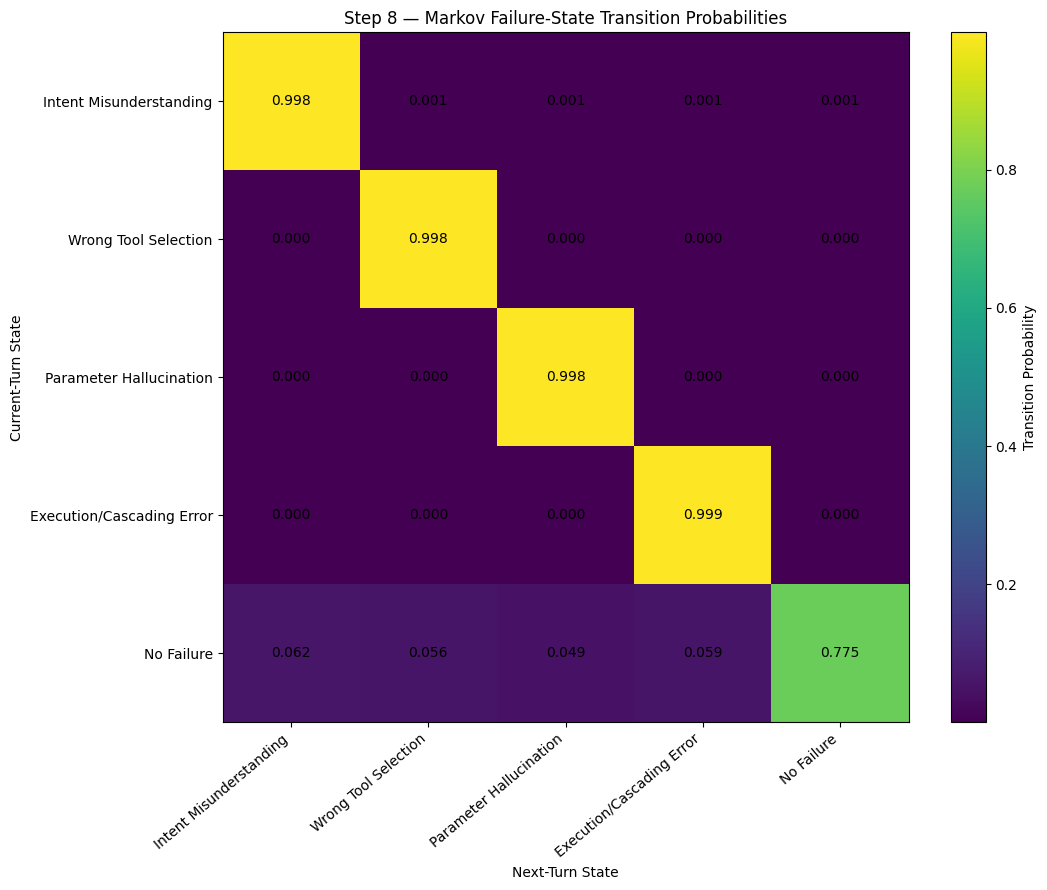

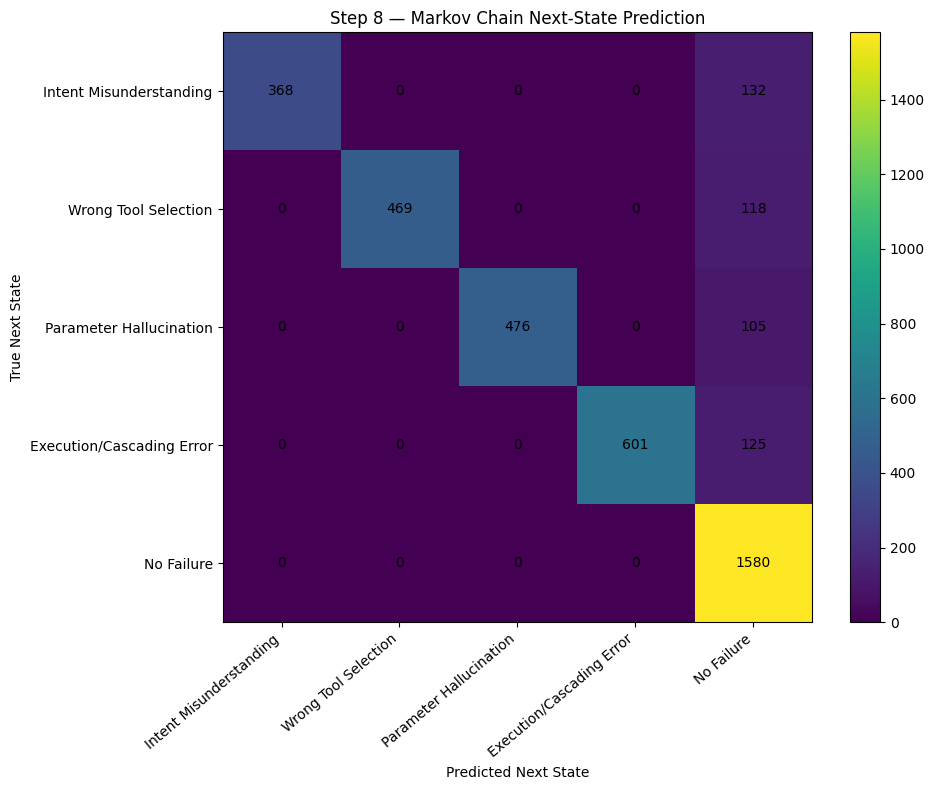

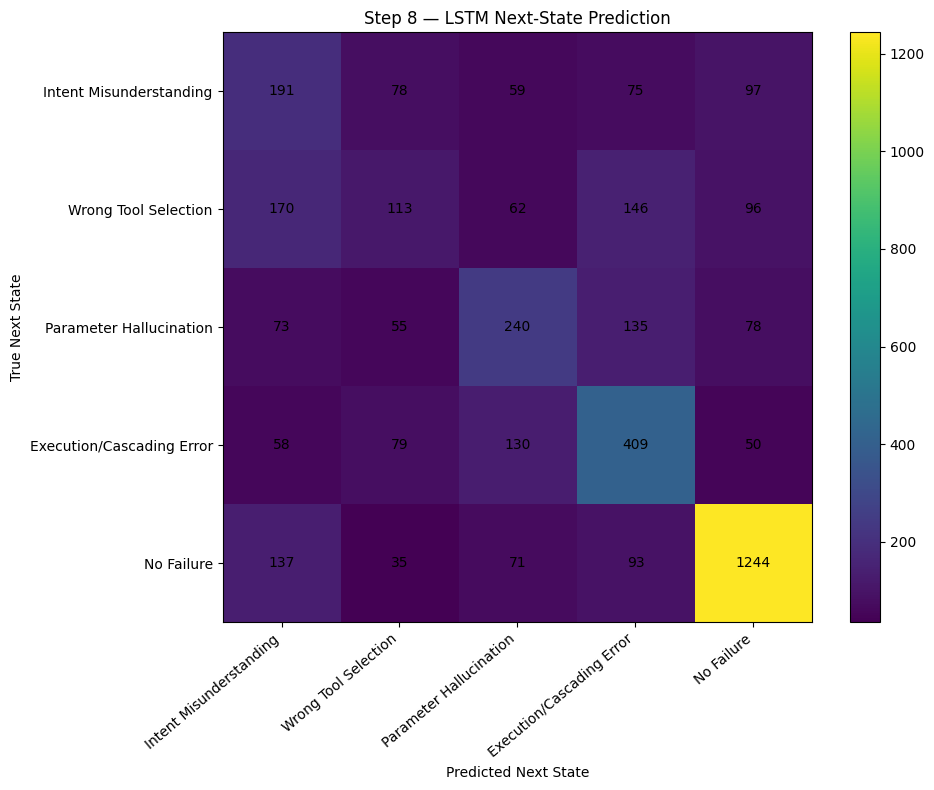

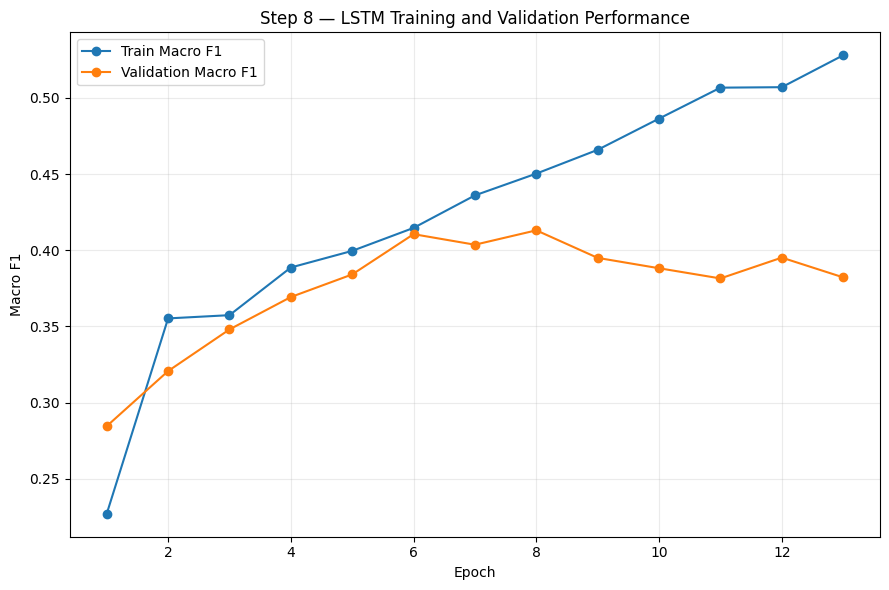

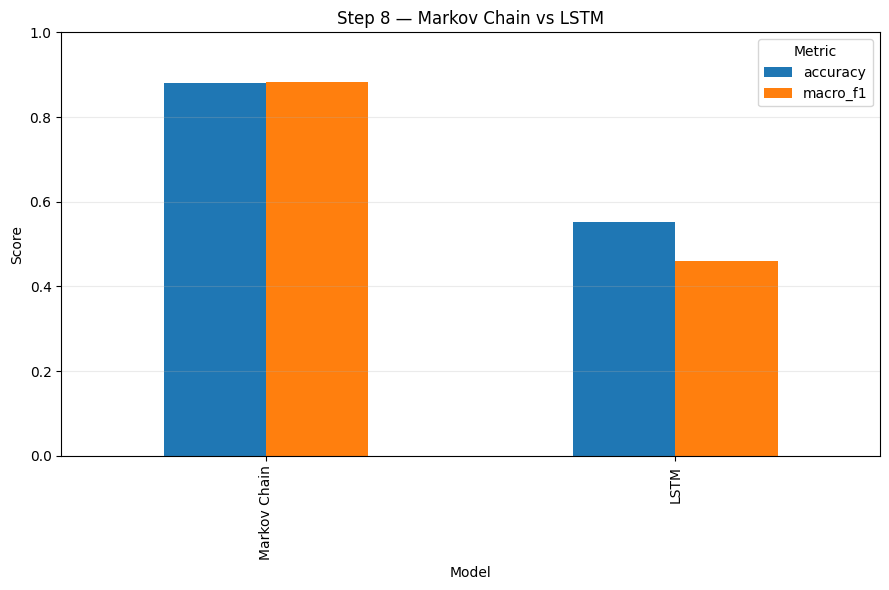


STEP 8 — FINAL VALIDATION
✓ All Step-8 integrity checks passed

STEP 8 — FAILURE PROPAGATION MODELING COMPLETE
Final GPT labels available       : 4,000
Development trajectories         : 3,700
Human Gold excluded              : 300
Train trajectories               : 2,590
Validation trajectories          : 555
Test trajectories                : 555
Derived transitions              : 26,822
Sentence embedding dimension     : 384
Best LSTM epoch                  : 8

--- MARKOV CHAIN TEST ---
Accuracy                          : 0.8792
Balanced Accuracy                 : 0.8364
Macro F1                          : 0.8822
Weighted F1                       : 0.8802

--- LSTM TEST ---
Accuracy                          : 0.5528
Balanced Accuracy                 : 0.4677
Macro F1                          : 0.4609
Weighted F1                       : 0.5481

--- COMPARISON ---
Best model by Macro F1            : Markov Chain

Methodology safeguards:
✓ Step-6 trajectory-level train/validation/tes

In [28]:
# ==================================================================================================
# STEP 8 — FAILURE PROPAGATION MODELING
# FINAL 4,000-LABEL PIPELINE
#
# METHODOLOGY:
#   8.1 Markov Chain baseline
#   8.2 LSTM sequence model using sentence-transformer turn embeddings
#   8.3 Markov vs LSTM comparison
#
# IMPORTANT DATA LIMITATION:
#   Step 4 provides:
#       - one trajectory-level failure type
#       - earliest failure turn
#
#   It does NOT provide independently annotated failure type at every turn.
#
#   Therefore this analysis constructs an explicit ONSET-PERSISTENCE PROXY:
#
#       Before earliest failure turn:
#           No Failure
#
#       At and after earliest failure turn:
#           trajectory's annotated failure type
#
#       For No Failure trajectories:
#           No Failure at every turn
#
#   This proxy must be described transparently in the paper.
#
# SPLITS:
#   Reuses Step 6 trajectory-level splits:
#       Train      = 2,590 trajectories
#       Validation =   555 trajectories
#       Test       =   555 trajectories
#
#   Human Gold 300 remains excluded from model development.
#
#   This prevents trajectory leakage across transition/sequence examples.
#
# MODELS:
#   1. First-order Markov Chain
#   2. LSTM over sentence-transformer turn embeddings
#
# PRIMARY EVALUATION:
#   Next-turn state prediction
#
# METRICS:
#   - Accuracy
#   - Balanced Accuracy
#   - Macro Precision
#   - Macro Recall
#   - Macro F1
#   - Weighted F1
#   - Per-class Precision / Recall / F1
#   - Confusion Matrix
#
# OUTPUT:
#   All Step 8 outputs use _4000 suffix.
#
# GPU:
#   RECOMMENDED
# ==================================================================================================


# ==================================================================================================
# 0. INSTALL REQUIRED PACKAGES
# ==================================================================================================

import sys
import subprocess
import importlib.util


def install_if_missing(
    package,
    import_name=None
):

    if import_name is None:
        import_name = package

    if importlib.util.find_spec(
        import_name
    ) is None:

        print(
            f"Installing {package} ..."
        )

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package
        ])


install_if_missing(
    "sentence-transformers",
    "sentence_transformers"
)


# ==================================================================================================
# 1. IMPORTS
# ==================================================================================================

import os
import ast
import json
import math
import random
import pickle
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sentence_transformers import (
    SentenceTransformer
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings(
    "ignore"
)


# ==================================================================================================
# 2. REPRODUCIBILITY
# ==================================================================================================

RANDOM_STATE = 42

random.seed(
    RANDOM_STATE
)

np.random.seed(
    RANDOM_STATE
)

torch.manual_seed(
    RANDOM_STATE
)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        RANDOM_STATE
    )


try:

    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )

except Exception:

    pass


# ==================================================================================================
# 3. DEVICE
# ==================================================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else
    "cpu"
)


print(
    "=" * 120
)

print(
    "STEP 8 — FAILURE PROPAGATION MODELING"
)

print(
    "=" * 120
)


print(
    f"PyTorch device : {DEVICE}"
)

print(
    f"CUDA available : {torch.cuda.is_available()}"
)


if torch.cuda.is_available():

    print(
        f"GPU            : {torch.cuda.get_device_name(0)}"
    )


# ==================================================================================================
# 4. CONFIGURATION
# ==================================================================================================

BASE = Path(
    "/kaggle/working/toolbench_research"
)


PROCESSED_DIR = (
    BASE
    /
    "data"
    /
    "processed"
)


TABLE_DIR = (
    BASE
    /
    "results"
    /
    "tables"
)


FIGURE_DIR = (
    BASE
    /
    "results"
    /
    "figures"
)


MODEL_DIR = (
    BASE
    /
    "models"
)


for directory in [
    PROCESSED_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    MODEL_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


EXPECTED_FINAL_LABELS = 4000

EXPECTED_DEVELOPMENT = 3700

EXPECTED_TRAIN_IDS = 2590

EXPECTED_VAL_IDS = 555

EXPECTED_TEST_IDS = 555


# ==================================================================================================
# 5. TAXONOMY / STATE SPACE
# ==================================================================================================

STATE_ORDER = [
    "Intent Misunderstanding",
    "Wrong Tool Selection",
    "Parameter Hallucination",
    "Execution/Cascading Error",
    "No Failure"
]


NUM_CLASSES = len(
    STATE_ORDER
)


state_to_id = {
    state:
        index

    for index, state
    in enumerate(
        STATE_ORDER
    )
}


id_to_state = {
    index:
        state

    for state, index
    in state_to_id.items()
}


NO_FAILURE = (
    "No Failure"
)


# ==================================================================================================
# 6. INPUT FILES
# ==================================================================================================

MASTER_SETUP_ROOT = Path(
    "/kaggle/input/datasets/anandadevnath/master-setup"
)


if not MASTER_SETUP_ROOT.exists():

    raise FileNotFoundError(
        f"Master setup root not found:\n{MASTER_SETUP_ROOT}"
    )


backup_candidates = sorted(
    [
        path
        for path
        in MASTER_SETUP_ROOT.glob(
            "ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_*"
        )
        if path.is_dir()
    ]
)


if not backup_candidates:

    raise FileNotFoundError(
        "Could not locate ToolBench final backup inside:\n"
        f"{MASTER_SETUP_ROOT}"
    )


FINAL_BACKUP_ROOT = (
    backup_candidates[-1]
)


BACKUP_RESEARCH_ROOT = (
    FINAL_BACKUP_ROOT
    /
    "CURRENT_RESEARCH"
)


BACKUP_PROCESSED_DIR = (
    BACKUP_RESEARCH_ROOT
    /
    "data"
    /
    "processed"
)


BACKUP_TABLE_DIR = (
    BACKUP_RESEARCH_ROOT
    /
    "results"
    /
    "tables"
)


SOURCE_MASTER_BACKUP = (
    FINAL_BACKUP_ROOT
    /
    "SOURCE_MASTER_BACKUP"
)


def first_existing(
    candidates,
    description
):

    for candidate in candidates:

        candidate = Path(
            candidate
        )

        if candidate.exists():

            print(
                f"\n✓ {description}:"
            )

            print(
                candidate
            )

            return candidate


    raise FileNotFoundError(
        f"Could not locate {description}.\n\nChecked:\n"
        +
        "\n".join(
            str(
                Path(p)
            )
            for p in candidates
        )
    )


LABEL_FILE = first_existing(
    [
        PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.parquet",

        BACKUP_PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.parquet",

        PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.csv",

        BACKUP_PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.csv"
    ],
    "Final 4,000 GPT-OSS labels"
)


RAW_TRAIN_FILE = first_existing(
    [
        SOURCE_MASTER_BACKUP
        /
        "dataset"
        /
        "toolbench_train_80.parquet"
    ],
    "ToolBench train-80 raw trajectories"
)


TRAIN_IDS_FILE = first_existing(
    [
        TABLE_DIR
        /
        "step6_train_ids_4000.csv",

        BACKUP_TABLE_DIR
        /
        "step6_train_ids_4000.csv"
    ],
    "Step-6 training IDs"
)


VAL_IDS_FILE = first_existing(
    [
        TABLE_DIR
        /
        "step6_validation_ids_4000.csv",

        BACKUP_TABLE_DIR
        /
        "step6_validation_ids_4000.csv"
    ],
    "Step-6 validation IDs"
)


TEST_IDS_FILE = first_existing(
    [
        TABLE_DIR
        /
        "step6_test_ids_4000.csv",

        BACKUP_TABLE_DIR
        /
        "step6_test_ids_4000.csv"
    ],
    "Step-6 untouched test IDs"
)


HUMAN_IDS_FILE = first_existing(
    [
        TABLE_DIR
        /
        "step6_human_gold_ids_300.csv",

        BACKUP_TABLE_DIR
        /
        "step6_human_gold_ids_300.csv"
    ],
    "Step-6 Human Gold audit IDs"
)


print(
    "\nFinal backup:"
)

print(
    FINAL_BACKUP_ROOT
)


# ==================================================================================================
# 7. LOAD FINAL LABELS
# ==================================================================================================

if LABEL_FILE.suffix.lower() == ".parquet":

    labels_df = pd.read_parquet(
        LABEL_FILE
    )

elif LABEL_FILE.suffix.lower() == ".csv":

    labels_df = pd.read_csv(
        LABEL_FILE,
        low_memory=False,
        dtype={
            "id": str
        }
    )

else:

    raise ValueError(
        f"Unsupported label file type:\n{LABEL_FILE}"
    )


required_label_columns = [
    "id",
    "llm_failure_type",
    "llm_failure_turn"
]


for column in required_label_columns:

    if column not in labels_df.columns:

        raise ValueError(
            f"Final annotation file missing column: {column}"
        )


labels_df[
    "id"
] = (
    labels_df[
        "id"
    ]
    .astype(str)
    .str.strip()
)


labels_df[
    "llm_failure_type"
] = (
    labels_df[
        "llm_failure_type"
    ]
    .astype(str)
    .str.strip()
)


labels_df = (
    labels_df[
        labels_df[
            "llm_failure_type"
        ]
        .isin(
            STATE_ORDER
        )
    ]
    .copy()
    .drop_duplicates(
        subset=[
            "id"
        ],
        keep="last"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n"
    + "=" * 120
)

print(
    "FINAL STEP-4 LABELS"
)

print(
    "=" * 120
)


print(
    f"Rows       : {len(labels_df):,}"
)

print(
    f"Unique IDs : {labels_df['id'].nunique():,}"
)


if len(
    labels_df
) != EXPECTED_FINAL_LABELS:

    raise RuntimeError(
        f"Expected {EXPECTED_FINAL_LABELS:,} labels, "
        f"found {len(labels_df):,}."
    )


# ==================================================================================================
# 8. VALIDATE FAILURE TURNS
# ==================================================================================================

failure_mask = (
    labels_df[
        "llm_failure_type"
    ]
    !=
    NO_FAILURE
)


no_failure_mask = (
    labels_df[
        "llm_failure_type"
    ]
    ==
    NO_FAILURE
)


labels_df.loc[
    failure_mask,
    "llm_failure_turn"
] = pd.to_numeric(
    labels_df.loc[
        failure_mask,
        "llm_failure_turn"
    ],
    errors="coerce"
)


invalid_failure_turns = int(
    labels_df.loc[
        failure_mask,
        "llm_failure_turn"
    ]
    .isna()
    .sum()
)


if invalid_failure_turns:

    raise RuntimeError(
        f"{invalid_failure_turns} failure trajectories "
        "have missing/invalid llm_failure_turn."
    )


labels_df.loc[
    failure_mask,
    "llm_failure_turn"
] = (
    labels_df.loc[
        failure_mask,
        "llm_failure_turn"
    ]
    .astype(int)
)


print(
    f"Failure trajectories     : {failure_mask.sum():,}"
)

print(
    f"No-Failure trajectories  : {no_failure_mask.sum():,}"
)

print(
    "✓ Failure-turn validation passed"
)


# ==================================================================================================
# 9. LOAD STEP-6 SPLIT IDS
# ==================================================================================================

def load_id_set(
    path
):

    temp = pd.read_csv(
        path,
        dtype={
            "id":
                str
        }
    )


    if "id" not in temp.columns:

        raise ValueError(
            f"Missing id column:\n{path}"
        )


    return set(
        temp[
            "id"
        ]
        .astype(str)
        .str.strip()
    )


train_ids = load_id_set(
    TRAIN_IDS_FILE
)


val_ids = load_id_set(
    VAL_IDS_FILE
)


test_ids = load_id_set(
    TEST_IDS_FILE
)


human_ids = load_id_set(
    HUMAN_IDS_FILE
)


print(
    "\n"
    + "=" * 120
)

print(
    "STEP-6 SPLIT REUSE"
)

print(
    "=" * 120
)


print(
    f"Train trajectories      : {len(train_ids):,}"
)

print(
    f"Validation trajectories : {len(val_ids):,}"
)

print(
    f"Test trajectories       : {len(test_ids):,}"
)

print(
    f"Human Gold excluded     : {len(human_ids):,}"
)


assert len(
    train_ids
) == EXPECTED_TRAIN_IDS


assert len(
    val_ids
) == EXPECTED_VAL_IDS


assert len(
    test_ids
) == EXPECTED_TEST_IDS


assert train_ids.isdisjoint(
    val_ids
)

assert train_ids.isdisjoint(
    test_ids
)

assert val_ids.isdisjoint(
    test_ids
)


development_ids = (
    train_ids
    |
    val_ids
    |
    test_ids
)


assert len(
    development_ids
) == EXPECTED_DEVELOPMENT


assert development_ids.isdisjoint(
    human_ids
)


print(
    "✓ No trajectory leakage"
)


# ==================================================================================================
# 10. LOAD RAW TOOLBENCH TRAIN DATA
# ==================================================================================================

raw_df = pd.read_parquet(
    RAW_TRAIN_FILE
)


required_raw_columns = [
    "id",
    "conversations"
]


for column in required_raw_columns:

    if column not in raw_df.columns:

        raise ValueError(
            f"Raw ToolBench file missing: {column}"
        )


raw_df[
    "id"
] = (
    raw_df[
        "id"
    ]
    .astype(str)
    .str.strip()
)


if raw_df[
    "id"
].duplicated().any():

    raise RuntimeError(
        "Duplicate IDs detected in raw train dataset."
    )


raw_df = (
    raw_df[
        raw_df[
            "id"
        ]
        .isin(
            development_ids
        )
    ]
    .copy()
)


print(
    "\nRaw development trajectories matched:"
)

print(
    f"{len(raw_df):,}/{EXPECTED_DEVELOPMENT:,}"
)


if len(
    raw_df
) != EXPECTED_DEVELOPMENT:

    raise RuntimeError(
        "Not all Step-8 development IDs were found in raw train data."
    )


# ==================================================================================================
# 11. MERGE RAW TRAJECTORIES + LABELS
# ==================================================================================================

df = (
    raw_df[
        [
            "id",
            "conversations"
        ]
    ]
    .merge(
        labels_df[
            [
                "id",
                "llm_failure_type",
                "llm_failure_turn"
            ]
        ],
        on="id",
        how="inner",
        validate="one_to_one"
    )
)


print(
    f"Step-8 development rows: {len(df):,}"
)


if len(
    df
) != EXPECTED_DEVELOPMENT:

    raise RuntimeError(
        "Step-8 merged dataset should contain 3,700 trajectories."
    )


# ==================================================================================================
# 12. ROLE NORMALIZATION
# ==================================================================================================

def normalize_role(
    role
):

    role = str(
        role
    ).strip().lower()


    if role in {
        "human",
        "user"
    }:

        return "USER"


    if role in {
        "assistant",
        "gpt"
    }:

        return "ASSISTANT"


    if role in {
        "function",
        "tool",
        "observation",
        "api"
    }:

        return "TOOL"


    if role == "system":

        return "SYSTEM"


    return role.upper()


# ==================================================================================================
# 13. ROBUST CONVERSATION PARSER
# ==================================================================================================

def parse_conversation(
    value
):

    messages = []


    if value is None:

        return messages


    # ----------------------------------------------------------------------------------------------
    # Native ToolBench parquet format:
    #
    # {
    #     'from': np.array([...]),
    #     'value': np.array([...])
    # }
    # ----------------------------------------------------------------------------------------------

    if isinstance(
        value,
        dict
    ):

        roles = value.get(
            "from",
            []
        )


        texts = value.get(
            "value",
            []
        )


        try:

            roles = list(
                roles
            )

        except Exception:

            roles = [
                roles
            ]


        try:

            texts = list(
                texts
            )

        except Exception:

            texts = [
                texts
            ]


        for role, text in zip(
            roles,
            texts
        ):

            role = normalize_role(
                role
            )


            text = str(
                text
            ).strip()


            if not text:

                continue


            messages.append({
                "role":
                    role,

                "text":
                    text
            })


        return messages


    # ----------------------------------------------------------------------------------------------
    # List format.
    # ----------------------------------------------------------------------------------------------

    if isinstance(
        value,
        (
            list,
            tuple
        )
    ):

        for item in value:

            if isinstance(
                item,
                dict
            ):

                role = (
                    item.get(
                        "from"
                    )
                    or
                    item.get(
                        "role"
                    )
                    or
                    ""
                )


                text = (
                    item.get(
                        "value"
                    )
                    or
                    item.get(
                        "content"
                    )
                    or
                    ""
                )


                role = normalize_role(
                    role
                )


                text = str(
                    text
                ).strip()


                if text:

                    messages.append({
                        "role":
                            role,

                        "text":
                            text
                    })


        return messages


    # ----------------------------------------------------------------------------------------------
    # String representation.
    # ----------------------------------------------------------------------------------------------

    text = str(
        value
    ).strip()


    if not text:

        return messages


    try:

        parsed = ast.literal_eval(
            text
        )


        if isinstance(
            parsed,
            (
                dict,
                list,
                tuple
            )
        ):

            return parse_conversation(
                parsed
            )


    except Exception:

        pass


    return messages


# ==================================================================================================
# 14. PARSE ALL CONVERSATIONS
# ==================================================================================================

df[
    "messages"
] = (
    df[
        "conversations"
    ]
    .apply(
        parse_conversation
    )
)


df[
    "parsed_turn_count"
] = (
    df[
        "messages"
    ]
    .apply(
        len
    )
)


empty_conversations = int(
    (
        df[
            "parsed_turn_count"
        ]
        <
        2
    ).sum()
)


print(
    "\n"
    + "=" * 120
)

print(
    "CONVERSATION PARSING"
)

print(
    "=" * 120
)


print(
    f"Parsed trajectories    : {len(df):,}"
)

print(
    f"Empty/short trajectories: {empty_conversations:,}"
)

print(
    f"Mean messages          : "
    f"{df['parsed_turn_count'].mean():.2f}"
)

print(
    f"Median messages        : "
    f"{df['parsed_turn_count'].median():.2f}"
)

print(
    f"Maximum messages       : "
    f"{df['parsed_turn_count'].max()}"
)


if empty_conversations != 0:

    raise RuntimeError(
        "Some Step-8 trajectories could not be parsed."
    )


# ==================================================================================================
# 15. FAILURE-TURN RANGE VALIDATION
# ==================================================================================================

bad_turn_records = []


for _, row in df.iterrows():

    if row[
        "llm_failure_type"
    ] == NO_FAILURE:

        continue


    failure_turn = int(
        row[
            "llm_failure_turn"
        ]
    )


    n_messages = int(
        row[
            "parsed_turn_count"
        ]
    )


    if (
        failure_turn < 1
        or
        failure_turn > n_messages
    ):

        bad_turn_records.append({
            "id":
                row[
                    "id"
                ],

            "failure_turn":
                failure_turn,

            "parsed_turn_count":
                n_messages
        })


if bad_turn_records:

    bad_turn_df = pd.DataFrame(
        bad_turn_records
    )


    BAD_TURN_PATH = (
        TABLE_DIR
        /
        "step8_invalid_failure_turn_alignment_4000.csv"
    )


    bad_turn_df.to_csv(
        BAD_TURN_PATH,
        index=False
    )


    raise RuntimeError(
        f"{len(bad_turn_records)} failure-turn values "
        f"do not align with parsed conversation length.\n"
        f"Saved diagnostic:\n{BAD_TURN_PATH}"
    )


print(
    "✓ All failure-turn values align with parsed conversations"
)


# ==================================================================================================
# 16. BUILD ONSET-PERSISTENCE STATE SEQUENCES
#
# Proxy construction:
#
#   Failure trajectory:
#
#       turns before failure_turn:
#           No Failure
#
#       failure_turn and every subsequent turn:
#           annotated failure type
#
#   No-Failure trajectory:
#
#       every turn:
#           No Failure
#
# ==================================================================================================

def build_state_sequence(
    failure_type,
    failure_turn,
    n_turns
):

    if failure_type == NO_FAILURE:

        return [
            NO_FAILURE
        ] * n_turns


    failure_turn = int(
        failure_turn
    )


    states = []


    for turn_index in range(
        1,
        n_turns + 1
    ):

        if turn_index < failure_turn:

            states.append(
                NO_FAILURE
            )

        else:

            states.append(
                failure_type
            )


    return states


df[
    "state_sequence"
] = df.apply(
    lambda row:
    build_state_sequence(
        row[
            "llm_failure_type"
        ],
        row[
            "llm_failure_turn"
        ],
        row[
            "parsed_turn_count"
        ]
    ),
    axis=1
)


df[
    "state_ids"
] = (
    df[
        "state_sequence"
    ]
    .apply(
        lambda sequence:
        [
            state_to_id[
                state
            ]
            for state in sequence
        ]
    )
)


# ==================================================================================================
# 17. SPLIT LABEL
# ==================================================================================================

def get_split(
    trajectory_id
):

    if trajectory_id in train_ids:

        return "train"


    if trajectory_id in val_ids:

        return "validation"


    if trajectory_id in test_ids:

        return "test"


    return "unknown"


df[
    "split"
] = (
    df[
        "id"
    ]
    .apply(
        get_split
    )
)


print(
    "\nSplit distribution:"
)


print(
    df[
        "split"
    ]
    .value_counts()
    .to_string()
)


assert (
    df[
        "split"
    ]
    !=
    "unknown"
).all()


# ==================================================================================================
# 18. SAVE DERIVED STATE DATASET
# ==================================================================================================

DERIVED_STATE_PATH = (
    PROCESSED_DIR
    /
    "step8_onset_persistence_state_sequences_4000.parquet"
)


state_save_df = df[
    [
        "id",
        "llm_failure_type",
        "llm_failure_turn",
        "parsed_turn_count",
        "split",
        "state_sequence",
        "state_ids"
    ]
].copy()


state_save_df.to_parquet(
    DERIVED_STATE_PATH,
    index=False
)


# ==================================================================================================
# 19. BUILD TRANSITION-LEVEL DATA
# ==================================================================================================

transition_records = []


for _, row in df.iterrows():

    states = row[
        "state_sequence"
    ]


    messages = row[
        "messages"
    ]


    for index in range(
        len(
            states
        )
        -
        1
    ):

        transition_records.append({
            "id":
                row[
                    "id"
                ],

            "split":
                row[
                    "split"
                ],

            "current_turn":
                index + 1,

            "next_turn":
                index + 2,

            "current_state":
                states[
                    index
                ],

            "next_state":
                states[
                    index + 1
                ],

            "current_state_id":
                state_to_id[
                    states[
                        index
                    ]
                ],

            "next_state_id":
                state_to_id[
                    states[
                        index + 1
                    ]
                ],

            "current_role":
                messages[
                    index
                ][
                    "role"
                ],

            "next_role":
                messages[
                    index + 1
                ][
                    "role"
                ]
        })


transitions_df = pd.DataFrame(
    transition_records
)


print(
    "\n"
    + "=" * 120
)

print(
    "DERIVED TRANSITION DATA"
)

print(
    "=" * 120
)


print(
    f"Total transitions      : {len(transitions_df):,}"
)

print(
    f"Training transitions   : "
    f"{(transitions_df['split'] == 'train').sum():,}"
)

print(
    f"Validation transitions : "
    f"{(transitions_df['split'] == 'validation').sum():,}"
)

print(
    f"Test transitions       : "
    f"{(transitions_df['split'] == 'test').sum():,}"
)


TRANSITION_DATA_PATH = (
    PROCESSED_DIR
    /
    "step8_transition_dataset_4000.parquet"
)


transitions_df.to_parquet(
    TRANSITION_DATA_PATH,
    index=False
)


# ==================================================================================================
# 20. STEP 8.1 — MARKOV CHAIN TRAINING
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 8.1 — FIRST-ORDER MARKOV CHAIN"
)

print(
    "=" * 120
)


train_transitions = (
    transitions_df[
        transitions_df[
            "split"
        ]
        ==
        "train"
    ]
    .copy()
)


transition_counts = np.zeros(
    (
        NUM_CLASSES,
        NUM_CLASSES
    ),
    dtype=np.int64
)


for _, row in train_transitions.iterrows():

    current_id = int(
        row[
            "current_state_id"
        ]
    )


    next_id = int(
        row[
            "next_state_id"
        ]
    )


    transition_counts[
        current_id,
        next_id
    ] += 1


# ==================================================================================================
# 21. LAPLACE-SMOOTHED TRANSITION MATRIX
# ==================================================================================================

LAPLACE_ALPHA = 1.0


transition_probabilities = (
    transition_counts
    +
    LAPLACE_ALPHA
)


transition_probabilities = (
    transition_probabilities
    /
    transition_probabilities.sum(
        axis=1,
        keepdims=True
    )
)


transition_count_df = pd.DataFrame(
    transition_counts,
    index=STATE_ORDER,
    columns=STATE_ORDER
)


transition_probability_df = pd.DataFrame(
    transition_probabilities,
    index=STATE_ORDER,
    columns=STATE_ORDER
)


print(
    "\nMarkov transition counts:"
)

print(
    transition_count_df.to_string()
)


print(
    "\nMarkov transition probabilities:"
)

print(
    transition_probability_df
    .round(
        4
    )
    .to_string()
)


# ==================================================================================================
# 22. MARKOV TEST PREDICTIONS
# ==================================================================================================

test_transitions = (
    transitions_df[
        transitions_df[
            "split"
        ]
        ==
        "test"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


markov_true = (
    test_transitions[
        "next_state_id"
    ]
    .to_numpy(
        dtype=int
    )
)


markov_pred = np.array([
    int(
        np.argmax(
            transition_probabilities[
                int(
                    current_state
                )
            ]
        )
    )

    for current_state
    in test_transitions[
        "current_state_id"
    ]
], dtype=int)


# ==================================================================================================
# 23. METRIC FUNCTION
# ==================================================================================================

def classification_metrics(
    y_true,
    y_pred
):

    return {
        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "macro_recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "weighted_f1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            )
    }


markov_metrics = classification_metrics(
    markov_true,
    markov_pred
)


print(
    "\nMARKOV TEST PERFORMANCE"
)


for key, value in markov_metrics.items():

    print(
        f"{key:<20}: {value:.4f}"
    )


# ==================================================================================================
# 24. MARKOV CLASSIFICATION REPORT
# ==================================================================================================

markov_report = classification_report(
    markov_true,
    markov_pred,
    labels=list(
        range(
            NUM_CLASSES
        )
    ),
    target_names=STATE_ORDER,
    output_dict=True,
    zero_division=0
)


markov_report_df = pd.DataFrame(
    markov_report
).transpose()


markov_cm = confusion_matrix(
    markov_true,
    markov_pred,
    labels=list(
        range(
            NUM_CLASSES
        )
    )
)


markov_cm_df = pd.DataFrame(
    markov_cm,
    index=STATE_ORDER,
    columns=STATE_ORDER
)


# ==================================================================================================
# 25. PREPARE TURN TEXTS FOR SENTENCE EMBEDDINGS
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 8.2 — SENTENCE-TRANSFORMER TURN EMBEDDINGS"
)

print(
    "=" * 120
)


trajectory_records = []


all_turn_texts = []

turn_lookup = []


for row_index, row in df.iterrows():

    messages = row[
        "messages"
    ]


    states = row[
        "state_ids"
    ]


    texts = []


    for turn_index, message in enumerate(
        messages
    ):

        # ------------------------------------------------------------------------------------------
        # Role prefix is included as input information.
        # Failure labels are NOT included in embedding text.
        # ------------------------------------------------------------------------------------------

        turn_text = (
            f"{message['role']}: "
            f"{message['text']}"
        )


        texts.append(
            turn_text
        )


        all_turn_texts.append(
            turn_text
        )


        turn_lookup.append(
            (
                row[
                    "id"
                ],
                turn_index
            )
        )


    trajectory_records.append({
        "id":
            row[
                "id"
            ],

        "split":
            row[
                "split"
            ],

        "texts":
            texts,

        "state_ids":
            states
    })


print(
    f"Trajectory sequences : {len(trajectory_records):,}"
)

print(
    f"Total turn texts     : {len(all_turn_texts):,}"
)


# ==================================================================================================
# 26. SENTENCE-TRANSFORMER MODEL
# ==================================================================================================

EMBEDDING_MODEL_NAME = (
    "sentence-transformers/all-MiniLM-L6-v2"
)


print(
    f"\nEmbedding model:\n{EMBEDDING_MODEL_NAME}"
)


embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME,
    device=str(
        DEVICE
    )
)


# ==================================================================================================
# 27. ENCODE ALL TURNS
# ==================================================================================================

turn_embeddings = embedding_model.encode(
    all_turn_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)


turn_embeddings = turn_embeddings.astype(
    np.float32
)


EMBEDDING_DIM = int(
    turn_embeddings.shape[
        1
    ]
)


print(
    f"\nTurn embeddings shape: {turn_embeddings.shape}"
)

print(
    f"Embedding dimension  : {EMBEDDING_DIM}"
)


# ==================================================================================================
# 28. MAP EMBEDDINGS BACK TO TRAJECTORIES
# ==================================================================================================

embedding_cursor = 0

sequence_examples = []


for record in trajectory_records:

    sequence_length = len(
        record[
            "texts"
        ]
    )


    embeddings = turn_embeddings[
        embedding_cursor:
        embedding_cursor
        +
        sequence_length
    ]


    embedding_cursor += sequence_length


    states = np.asarray(
        record[
            "state_ids"
        ],
        dtype=np.int64
    )


    if sequence_length < 2:

        continue


    # ----------------------------------------------------------------------------------------------
    # Next-state prediction:
    #
    # Input:
    #     turn embeddings 1...(T-1)
    #
    # Target:
    #     state labels 2...T
    #
    # This predicts the state at the NEXT turn.
    # ----------------------------------------------------------------------------------------------

    input_embeddings = embeddings[
        :-1
    ]


    target_states = states[
        1:
    ]


    sequence_examples.append({
        "id":
            record[
                "id"
            ],

        "split":
            record[
                "split"
            ],

        "x":
            input_embeddings,

        "y":
            target_states
    })


assert embedding_cursor == len(
    turn_embeddings
)


# ==================================================================================================
# 29. SAVE EMBEDDINGS
# ==================================================================================================

EMBEDDING_PATH = (
    PROCESSED_DIR
    /
    "step8_turn_embeddings_4000.npy"
)


np.save(
    EMBEDDING_PATH,
    turn_embeddings
)


# ==================================================================================================
# 30. DATASET CLASS
# ==================================================================================================

class SequenceDataset(
    Dataset
):

    def __init__(
        self,
        examples
    ):

        self.examples = examples


    def __len__(
        self
    ):

        return len(
            self.examples
        )


    def __getitem__(
        self,
        index
    ):

        item = self.examples[
            index
        ]


        return {
            "id":
                item[
                    "id"
                ],

            "x":
                torch.tensor(
                    item[
                        "x"
                    ],
                    dtype=torch.float32
                ),

            "y":
                torch.tensor(
                    item[
                        "y"
                    ],
                    dtype=torch.long
                )
        }


# ==================================================================================================
# 31. COLLATE VARIABLE-LENGTH SEQUENCES
# ==================================================================================================

def collate_sequences(
    batch
):

    lengths = torch.tensor(
        [
            item[
                "x"
            ].shape[
                0
            ]

            for item in batch
        ],
        dtype=torch.long
    )


    max_length = int(
        lengths.max()
    )


    batch_size = len(
        batch
    )


    x_batch = torch.zeros(
        (
            batch_size,
            max_length,
            EMBEDDING_DIM
        ),
        dtype=torch.float32
    )


    y_batch = torch.full(
        (
            batch_size,
            max_length
        ),
        fill_value=-100,
        dtype=torch.long
    )


    ids = []


    for batch_index, item in enumerate(
        batch
    ):

        length = item[
            "x"
        ].shape[
            0
        ]


        x_batch[
            batch_index,
            :length
        ] = item[
            "x"
        ]


        y_batch[
            batch_index,
            :length
        ] = item[
            "y"
        ]


        ids.append(
            item[
                "id"
            ]
        )


    return {
        "ids":
            ids,

        "x":
            x_batch,

        "y":
            y_batch,

        "lengths":
            lengths
    }


# ==================================================================================================
# 32. SPLIT SEQUENCE EXAMPLES
# ==================================================================================================

train_examples = [
    example

    for example in sequence_examples

    if example[
        "split"
    ]
    ==
    "train"
]


val_examples = [
    example

    for example in sequence_examples

    if example[
        "split"
    ]
    ==
    "validation"
]


test_examples = [
    example

    for example in sequence_examples

    if example[
        "split"
    ]
    ==
    "test"
]


print(
    "\nSequence examples:"
)

print(
    f"Train      : {len(train_examples):,}"
)

print(
    f"Validation : {len(val_examples):,}"
)

print(
    f"Test       : {len(test_examples):,}"
)


assert len(
    train_examples
) == EXPECTED_TRAIN_IDS

assert len(
    val_examples
) == EXPECTED_VAL_IDS

assert len(
    test_examples
) == EXPECTED_TEST_IDS


# ==================================================================================================
# 33. DATALOADERS
# ==================================================================================================

BATCH_SIZE = 64


train_loader = DataLoader(
    SequenceDataset(
        train_examples
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_sequences
)


val_loader = DataLoader(
    SequenceDataset(
        val_examples
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_sequences
)


test_loader = DataLoader(
    SequenceDataset(
        test_examples
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_sequences
)


# ==================================================================================================
# 34. CALCULATE CLASS WEIGHTS FROM TRAINING TARGETS ONLY
# ==================================================================================================

train_target_values = np.concatenate([
    example[
        "y"
    ]

    for example in train_examples
])


train_class_counts = np.bincount(
    train_target_values,
    minlength=NUM_CLASSES
)


train_class_weights = (
    train_target_values.shape[
        0
    ]
    /
    (
        NUM_CLASSES
        *
        np.maximum(
            train_class_counts,
            1
        )
    )
)


# Avoid pathological huge weights.
train_class_weights = np.clip(
    train_class_weights,
    0.25,
    5.0
)


class_weight_tensor = torch.tensor(
    train_class_weights,
    dtype=torch.float32,
    device=DEVICE
)


print(
    "\nTraining next-state counts:"
)


for class_id, state in enumerate(
    STATE_ORDER
):

    print(
        f"{state:<30} "
        f"{train_class_counts[class_id]:,} "
        f"| weight={train_class_weights[class_id]:.4f}"
    )


# ==================================================================================================
# 35. LSTM MODEL
# ==================================================================================================

class FailurePropagationLSTM(
    nn.Module
):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_layers,
        num_classes,
        dropout
    ):

        super().__init__()


        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(
                dropout
                if num_layers > 1
                else 0.0
            ),
            bidirectional=False
        )


        self.dropout = nn.Dropout(
            dropout
        )


        self.classifier = nn.Linear(
            hidden_dim,
            num_classes
        )


    def forward(
        self,
        x,
        lengths
    ):

        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )


        packed_output, _ = self.lstm(
            packed
        )


        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output,
            batch_first=True
        )


        output = self.dropout(
            output
        )


        logits = self.classifier(
            output
        )


        return logits


# ==================================================================================================
# 36. MODEL CONFIG
# ==================================================================================================

HIDDEN_DIM = 128

NUM_LSTM_LAYERS = 2

DROPOUT = 0.30

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 30

EARLY_STOPPING_PATIENCE = 5


model = FailurePropagationLSTM(
    input_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LSTM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(
    DEVICE
)


criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor,
    ignore_index=-100
)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ==================================================================================================
# 37. TRAIN / EVALUATION HELPER
# ==================================================================================================

def run_epoch(
    model,
    loader,
    optimizer=None
):

    training = (
        optimizer is not None
    )


    if training:

        model.train()

    else:

        model.eval()


    total_loss = 0.0

    total_valid_targets = 0

    all_true = []

    all_pred = []


    for batch in loader:

        x = batch[
            "x"
        ].to(
            DEVICE
        )


        y = batch[
            "y"
        ].to(
            DEVICE
        )


        lengths = batch[
            "lengths"
        ].to(
            DEVICE
        )


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        with torch.set_grad_enabled(
            training
        ):

            logits = model(
                x,
                lengths
            )


            loss = criterion(
                logits.reshape(
                    -1,
                    NUM_CLASSES
                ),
                y.reshape(
                    -1
                )
            )


            if training:

                loss.backward()


                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )


                optimizer.step()


        valid_mask = (
            y
            !=
            -100
        )


        valid_count = int(
            valid_mask.sum().item()
        )


        total_loss += (
            float(
                loss.item()
            )
            *
            valid_count
        )


        total_valid_targets += (
            valid_count
        )


        predictions = torch.argmax(
            logits,
            dim=-1
        )


        all_true.extend(
            y[
                valid_mask
            ]
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )


        all_pred.extend(
            predictions[
                valid_mask
            ]
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )


    mean_loss = (
        total_loss
        /
        max(
            total_valid_targets,
            1
        )
    )


    all_true = np.asarray(
        all_true,
        dtype=int
    )


    all_pred = np.asarray(
        all_pred,
        dtype=int
    )


    metrics = classification_metrics(
        all_true,
        all_pred
    )


    return (
        mean_loss,
        metrics,
        all_true,
        all_pred
    )


# ==================================================================================================
# 38. TRAIN LSTM WITH EARLY STOPPING
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "TRAIN FAILURE-PROPAGATION LSTM"
)

print(
    "=" * 120
)


BEST_MODEL_PATH = (
    MODEL_DIR
    /
    "step8_failure_propagation_lstm_4000.pt"
)


training_history = []

best_val_macro_f1 = -np.inf

best_epoch = None

epochs_without_improvement = 0


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    train_loss, train_metrics, _, _ = run_epoch(
        model,
        train_loader,
        optimizer=optimizer
    )


    with torch.no_grad():

        val_loss, val_metrics, _, _ = run_epoch(
            model,
            val_loader,
            optimizer=None
        )


    training_history.append({
        "epoch":
            epoch,

        "train_loss":
            train_loss,

        "validation_loss":
            val_loss,

        "train_accuracy":
            train_metrics[
                "accuracy"
            ],

        "validation_accuracy":
            val_metrics[
                "accuracy"
            ],

        "train_macro_f1":
            train_metrics[
                "macro_f1"
            ],

        "validation_macro_f1":
            val_metrics[
                "macro_f1"
            ]
    })


    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"train_F1={train_metrics['macro_f1']:.4f} | "
        f"val_F1={val_metrics['macro_f1']:.4f}"
    )


    current_val_f1 = (
        val_metrics[
            "macro_f1"
        ]
    )


    if current_val_f1 > (
        best_val_macro_f1
        +
        1e-6
    ):

        best_val_macro_f1 = (
            current_val_f1
        )


        best_epoch = epoch


        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "embedding_dim":
                    EMBEDDING_DIM,

                "hidden_dim":
                    HIDDEN_DIM,

                "num_layers":
                    NUM_LSTM_LAYERS,

                "dropout":
                    DROPOUT,

                "num_classes":
                    NUM_CLASSES,

                "state_order":
                    STATE_ORDER,

                "embedding_model":
                    EMBEDDING_MODEL_NAME,

                "best_epoch":
                    best_epoch,

                "best_validation_macro_f1":
                    best_val_macro_f1
            },
            BEST_MODEL_PATH
        )


        epochs_without_improvement = 0


    else:

        epochs_without_improvement += 1


    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}."
        )

        break


print(
    f"\nBest epoch              : {best_epoch}"
)

print(
    f"Best validation Macro F1: {best_val_macro_f1:.4f}"
)


# ==================================================================================================
# 39. LOAD BEST LSTM
# ==================================================================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model.eval()


# ==================================================================================================
# 40. FINAL LSTM TEST EVALUATION
# ==================================================================================================

with torch.no_grad():

    (
        lstm_test_loss,
        lstm_metrics,
        lstm_true,
        lstm_pred
    ) = run_epoch(
        model,
        test_loader,
        optimizer=None
    )


print(
    "\n"
    + "=" * 120
)

print(
    "LSTM TEST PERFORMANCE"
)

print(
    "=" * 120
)


print(
    f"Test loss            : {lstm_test_loss:.4f}"
)


for key, value in lstm_metrics.items():

    print(
        f"{key:<20}: {value:.4f}"
    )


# ==================================================================================================
# 41. LSTM REPORT / CONFUSION MATRIX
# ==================================================================================================

lstm_report = classification_report(
    lstm_true,
    lstm_pred,
    labels=list(
        range(
            NUM_CLASSES
        )
    ),
    target_names=STATE_ORDER,
    output_dict=True,
    zero_division=0
)


lstm_report_df = pd.DataFrame(
    lstm_report
).transpose()


lstm_cm = confusion_matrix(
    lstm_true,
    lstm_pred,
    labels=list(
        range(
            NUM_CLASSES
        )
    )
)


lstm_cm_df = pd.DataFrame(
    lstm_cm,
    index=STATE_ORDER,
    columns=STATE_ORDER
)


# ==================================================================================================
# 42. STEP 8.3 — MARKOV VS LSTM COMPARISON
# ==================================================================================================

comparison_df = pd.DataFrame([
    {
        "model":
            "Markov Chain",

        "accuracy":
            markov_metrics[
                "accuracy"
            ],

        "balanced_accuracy":
            markov_metrics[
                "balanced_accuracy"
            ],

        "macro_precision":
            markov_metrics[
                "macro_precision"
            ],

        "macro_recall":
            markov_metrics[
                "macro_recall"
            ],

        "macro_f1":
            markov_metrics[
                "macro_f1"
            ],

        "weighted_f1":
            markov_metrics[
                "weighted_f1"
            ]
    },

    {
        "model":
            "LSTM",

        "accuracy":
            lstm_metrics[
                "accuracy"
            ],

        "balanced_accuracy":
            lstm_metrics[
                "balanced_accuracy"
            ],

        "macro_precision":
            lstm_metrics[
                "macro_precision"
            ],

        "macro_recall":
            lstm_metrics[
                "macro_recall"
            ],

        "macro_f1":
            lstm_metrics[
                "macro_f1"
            ],

        "weighted_f1":
            lstm_metrics[
                "weighted_f1"
            ]
    }
])


comparison_df[
    "macro_f1_rank"
] = (
    comparison_df[
        "macro_f1"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


comparison_df = (
    comparison_df
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n"
    + "=" * 120
)

print(
    "STEP 8.3 — MARKOV VS LSTM COMPARISON"
)

print(
    "=" * 120
)


print(
    comparison_df
    .to_string(
        index=False,
        formatters={
            "accuracy":
                lambda x:
                f"{x:.4f}",

            "balanced_accuracy":
                lambda x:
                f"{x:.4f}",

            "macro_precision":
                lambda x:
                f"{x:.4f}",

            "macro_recall":
                lambda x:
                f"{x:.4f}",

            "macro_f1":
                lambda x:
                f"{x:.4f}",

            "weighted_f1":
                lambda x:
                f"{x:.4f}"
        }
    )
)


best_model = comparison_df.iloc[
    0
][
    "model"
]


print(
    f"\nBest model by Macro F1: {best_model}"
)


# ==================================================================================================
# 43. SAVE TABLE PATHS
# ==================================================================================================

MARKOV_COUNTS_PATH = (
    TABLE_DIR
    /
    "step8_markov_transition_counts_4000.csv"
)


MARKOV_PROB_PATH = (
    TABLE_DIR
    /
    "step8_markov_transition_probabilities_4000.csv"
)


MARKOV_REPORT_PATH = (
    TABLE_DIR
    /
    "step8_markov_classification_report_4000.csv"
)


MARKOV_CM_PATH = (
    TABLE_DIR
    /
    "step8_markov_confusion_matrix_4000.csv"
)


LSTM_REPORT_PATH = (
    TABLE_DIR
    /
    "step8_lstm_classification_report_4000.csv"
)


LSTM_CM_PATH = (
    TABLE_DIR
    /
    "step8_lstm_confusion_matrix_4000.csv"
)


COMPARISON_PATH = (
    TABLE_DIR
    /
    "step8_markov_vs_lstm_comparison_4000.csv"
)


TRAINING_HISTORY_PATH = (
    TABLE_DIR
    /
    "step8_lstm_training_history_4000.csv"
)


STATE_DISTRIBUTION_PATH = (
    TABLE_DIR
    /
    "step8_next_state_distribution_4000.csv"
)


RUN_SUMMARY_PATH = (
    TABLE_DIR
    /
    "step8_run_summary_4000.csv"
)


# ==================================================================================================
# 44. SAVE TABLES
# ==================================================================================================

transition_count_df.to_csv(
    MARKOV_COUNTS_PATH
)


transition_probability_df.to_csv(
    MARKOV_PROB_PATH
)


markov_report_df.to_csv(
    MARKOV_REPORT_PATH
)


markov_cm_df.to_csv(
    MARKOV_CM_PATH
)


lstm_report_df.to_csv(
    LSTM_REPORT_PATH
)


lstm_cm_df.to_csv(
    LSTM_CM_PATH
)


comparison_df.to_csv(
    COMPARISON_PATH,
    index=False
)


training_history_df = pd.DataFrame(
    training_history
)


training_history_df.to_csv(
    TRAINING_HISTORY_PATH,
    index=False
)


state_distribution_df = pd.DataFrame({
    "state":
        STATE_ORDER,

    "train_next_state_count":
        train_class_counts
})


state_distribution_df[
    "train_next_state_percent"
] = (
    state_distribution_df[
        "train_next_state_count"
    ]
    /
    state_distribution_df[
        "train_next_state_count"
    ].sum()
    *
    100
)


state_distribution_df.to_csv(
    STATE_DISTRIBUTION_PATH,
    index=False
)


# ==================================================================================================
# 45. RUN SUMMARY
# ==================================================================================================

run_summary_df = pd.DataFrame([
    {
        "total_final_labels":
            EXPECTED_FINAL_LABELS,

        "development_trajectories":
            EXPECTED_DEVELOPMENT,

        "train_trajectories":
            len(
                train_ids
            ),

        "validation_trajectories":
            len(
                val_ids
            ),

        "test_trajectories":
            len(
                test_ids
            ),

        "human_gold_excluded":
            len(
                human_ids
            ),

        "derived_total_transitions":
            len(
                transitions_df
            ),

        "train_transitions":
            int(
                (
                    transitions_df[
                        "split"
                    ]
                    ==
                    "train"
                ).sum()
            ),

        "validation_transitions":
            int(
                (
                    transitions_df[
                        "split"
                    ]
                    ==
                    "validation"
                ).sum()
            ),

        "test_transitions":
            int(
                (
                    transitions_df[
                        "split"
                    ]
                    ==
                    "test"
                ).sum()
            ),

        "state_proxy":
            (
                "No Failure before earliest annotated failure turn; "
                "trajectory failure type persists from onset onward."
            ),

        "embedding_model":
            EMBEDDING_MODEL_NAME,

        "embedding_dimension":
            EMBEDDING_DIM,

        "lstm_hidden_dim":
            HIDDEN_DIM,

        "lstm_layers":
            NUM_LSTM_LAYERS,

        "best_lstm_epoch":
            best_epoch,

        "best_validation_macro_f1":
            best_val_macro_f1,

        "markov_test_accuracy":
            markov_metrics[
                "accuracy"
            ],

        "markov_test_macro_f1":
            markov_metrics[
                "macro_f1"
            ],

        "lstm_test_accuracy":
            lstm_metrics[
                "accuracy"
            ],

        "lstm_test_macro_f1":
            lstm_metrics[
                "macro_f1"
            ],

        "best_model_macro_f1":
            best_model,

        "device":
            str(
                DEVICE
            ),

        "random_state":
            RANDOM_STATE
    }
])


run_summary_df.to_csv(
    RUN_SUMMARY_PATH,
    index=False
)


# ==================================================================================================
# 46. SAVE MARKOV MODEL
# ==================================================================================================

MARKOV_MODEL_PATH = (
    MODEL_DIR
    /
    "step8_markov_transition_model_4000.npz"
)


np.savez(
    MARKOV_MODEL_PATH,
    transition_counts=transition_counts,
    transition_probabilities=transition_probabilities,
    state_order=np.array(
        STATE_ORDER,
        dtype=object
    ),
    laplace_alpha=LAPLACE_ALPHA
)


# ==================================================================================================
# 47. FIGURE — MARKOV TRANSITION HEATMAP
# ==================================================================================================

MARKOV_HEATMAP_PATH = (
    FIGURE_DIR
    /
    "step8_markov_transition_heatmap_4000.png"
)


fig, ax = plt.subplots(
    figsize=(
        11,
        9
    )
)


image = ax.imshow(
    transition_probabilities,
    aspect="auto"
)


ax.set_xticks(
    np.arange(
        NUM_CLASSES
    )
)


ax.set_yticks(
    np.arange(
        NUM_CLASSES
    )
)


ax.set_xticklabels(
    STATE_ORDER,
    rotation=40,
    ha="right"
)


ax.set_yticklabels(
    STATE_ORDER
)


ax.set_xlabel(
    "Next-Turn State"
)


ax.set_ylabel(
    "Current-Turn State"
)


ax.set_title(
    "Step 8 — Markov Failure-State Transition Probabilities"
)


for row in range(
    NUM_CLASSES
):

    for column in range(
        NUM_CLASSES
    ):

        ax.text(
            column,
            row,
            f"{transition_probabilities[row, column]:.3f}",
            ha="center",
            va="center"
        )


fig.colorbar(
    image,
    ax=ax,
    label="Transition Probability"
)


fig.tight_layout()


fig.savefig(
    MARKOV_HEATMAP_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# ==================================================================================================
# 48. CONFUSION-MATRIX PLOT HELPER
# ==================================================================================================

def plot_confusion_matrix(
    matrix,
    title,
    output_path
):

    fig, ax = plt.subplots(
        figsize=(
            10,
            8
        )
    )


    image = ax.imshow(
        matrix
    )


    ax.set_xticks(
        np.arange(
            NUM_CLASSES
        )
    )


    ax.set_yticks(
        np.arange(
            NUM_CLASSES
        )
    )


    ax.set_xticklabels(
        STATE_ORDER,
        rotation=40,
        ha="right"
    )


    ax.set_yticklabels(
        STATE_ORDER
    )


    ax.set_xlabel(
        "Predicted Next State"
    )


    ax.set_ylabel(
        "True Next State"
    )


    ax.set_title(
        title
    )


    for row in range(
        NUM_CLASSES
    ):

        for column in range(
            NUM_CLASSES
        ):

            ax.text(
                column,
                row,
                str(
                    int(
                        matrix[
                            row,
                            column
                        ]
                    )
                ),
                ha="center",
                va="center"
            )


    fig.colorbar(
        image,
        ax=ax
    )


    fig.tight_layout()


    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

    plt.close(
        fig
    )


# ==================================================================================================
# 49. MARKOV CONFUSION FIGURE
# ==================================================================================================

MARKOV_CM_FIGURE = (
    FIGURE_DIR
    /
    "step8_markov_confusion_matrix_4000.png"
)


plot_confusion_matrix(
    markov_cm,
    "Step 8 — Markov Chain Next-State Prediction",
    MARKOV_CM_FIGURE
)


# ==================================================================================================
# 50. LSTM CONFUSION FIGURE
# ==================================================================================================

LSTM_CM_FIGURE = (
    FIGURE_DIR
    /
    "step8_lstm_confusion_matrix_4000.png"
)


plot_confusion_matrix(
    lstm_cm,
    "Step 8 — LSTM Next-State Prediction",
    LSTM_CM_FIGURE
)


# ==================================================================================================
# 51. TRAINING CURVE
# ==================================================================================================

TRAINING_CURVE_PATH = (
    FIGURE_DIR
    /
    "step8_lstm_training_curve_4000.png"
)


fig, ax = plt.subplots(
    figsize=(
        9,
        6
    )
)


ax.plot(
    training_history_df[
        "epoch"
    ],
    training_history_df[
        "train_macro_f1"
    ],
    marker="o",
    label="Train Macro F1"
)


ax.plot(
    training_history_df[
        "epoch"
    ],
    training_history_df[
        "validation_macro_f1"
    ],
    marker="o",
    label="Validation Macro F1"
)


ax.set_xlabel(
    "Epoch"
)


ax.set_ylabel(
    "Macro F1"
)


ax.set_title(
    "Step 8 — LSTM Training and Validation Performance"
)


ax.grid(
    alpha=0.25
)


ax.legend()


fig.tight_layout()


fig.savefig(
    TRAINING_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# ==================================================================================================
# 52. MODEL COMPARISON FIGURE
# ==================================================================================================

COMPARISON_FIGURE = (
    FIGURE_DIR
    /
    "step8_markov_vs_lstm_comparison_4000.png"
)


comparison_plot = comparison_df.set_index(
    "model"
)[
    [
        "accuracy",
        "macro_f1"
    ]
]


fig, ax = plt.subplots(
    figsize=(
        9,
        6
    )
)


comparison_plot.plot(
    kind="bar",
    ax=ax
)


ax.set_xlabel(
    "Model"
)


ax.set_ylabel(
    "Score"
)


ax.set_ylim(
    0,
    1
)


ax.set_title(
    "Step 8 — Markov Chain vs LSTM"
)


ax.grid(
    axis="y",
    alpha=0.25
)


ax.legend(
    title="Metric"
)


fig.tight_layout()


fig.savefig(
    COMPARISON_FIGURE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(
    fig
)


# ==================================================================================================
# 53. FINAL VALIDATION
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 8 — FINAL VALIDATION"
)

print(
    "=" * 120
)


assert len(
    df
) == EXPECTED_DEVELOPMENT


assert set(
    df[
        "id"
    ]
) == development_ids


assert development_ids.isdisjoint(
    human_ids
)


assert transition_counts.shape == (
    NUM_CLASSES,
    NUM_CLASSES
)


assert transition_probabilities.shape == (
    NUM_CLASSES,
    NUM_CLASSES
)


assert np.allclose(
    transition_probabilities.sum(
        axis=1
    ),
    1.0
)


assert len(
    markov_true
) == len(
    markov_pred
)


assert len(
    lstm_true
) == len(
    lstm_pred
)


assert len(
    train_examples
) == EXPECTED_TRAIN_IDS


assert len(
    val_examples
) == EXPECTED_VAL_IDS


assert len(
    test_examples
) == EXPECTED_TEST_IDS


required_outputs = [
    DERIVED_STATE_PATH,
    TRANSITION_DATA_PATH,
    EMBEDDING_PATH,

    MARKOV_COUNTS_PATH,
    MARKOV_PROB_PATH,
    MARKOV_REPORT_PATH,
    MARKOV_CM_PATH,

    LSTM_REPORT_PATH,
    LSTM_CM_PATH,

    COMPARISON_PATH,
    TRAINING_HISTORY_PATH,
    STATE_DISTRIBUTION_PATH,
    RUN_SUMMARY_PATH,

    MARKOV_MODEL_PATH,
    BEST_MODEL_PATH,

    MARKOV_HEATMAP_PATH,
    MARKOV_CM_FIGURE,
    LSTM_CM_FIGURE,
    TRAINING_CURVE_PATH,
    COMPARISON_FIGURE
]


for path in required_outputs:

    if not Path(
        path
    ).exists():

        raise RuntimeError(
            f"Missing Step-8 output:\n{path}"
        )


print(
    "✓ All Step-8 integrity checks passed"
)


# ==================================================================================================
# 54. FINAL SUMMARY
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 8 — FAILURE PROPAGATION MODELING COMPLETE"
)

print(
    "=" * 120
)


print(
    f"Final GPT labels available       : "
    f"{EXPECTED_FINAL_LABELS:,}"
)

print(
    f"Development trajectories         : "
    f"{len(df):,}"
)

print(
    f"Human Gold excluded              : "
    f"{len(human_ids):,}"
)

print(
    f"Train trajectories               : "
    f"{len(train_examples):,}"
)

print(
    f"Validation trajectories          : "
    f"{len(val_examples):,}"
)

print(
    f"Test trajectories                : "
    f"{len(test_examples):,}"
)

print(
    f"Derived transitions              : "
    f"{len(transitions_df):,}"
)

print(
    f"Sentence embedding dimension     : "
    f"{EMBEDDING_DIM}"
)

print(
    f"Best LSTM epoch                  : "
    f"{best_epoch}"
)


print(
    "\n--- MARKOV CHAIN TEST ---"
)

print(
    f"Accuracy                          : "
    f"{markov_metrics['accuracy']:.4f}"
)

print(
    f"Balanced Accuracy                 : "
    f"{markov_metrics['balanced_accuracy']:.4f}"
)

print(
    f"Macro F1                          : "
    f"{markov_metrics['macro_f1']:.4f}"
)

print(
    f"Weighted F1                       : "
    f"{markov_metrics['weighted_f1']:.4f}"
)


print(
    "\n--- LSTM TEST ---"
)

print(
    f"Accuracy                          : "
    f"{lstm_metrics['accuracy']:.4f}"
)

print(
    f"Balanced Accuracy                 : "
    f"{lstm_metrics['balanced_accuracy']:.4f}"
)

print(
    f"Macro F1                          : "
    f"{lstm_metrics['macro_f1']:.4f}"
)

print(
    f"Weighted F1                       : "
    f"{lstm_metrics['weighted_f1']:.4f}"
)


print(
    "\n--- COMPARISON ---"
)

print(
    f"Best model by Macro F1            : "
    f"{best_model}"
)


print(
    "\nMethodology safeguards:"
)

print(
    "✓ Step-6 trajectory-level train/validation/test split reused."
)

print(
    "✓ No trajectory appears in more than one model split."
)

print(
    "✓ Human Gold 300 excluded from model training and selection."
)

print(
    "✓ Sentence embeddings contain trajectory text only — no GPT failure labels."
)

print(
    "✓ Markov transition probabilities learned only from training trajectories."
)

print(
    "✓ LSTM early stopping uses validation trajectories only."
)

print(
    "✓ Final test trajectories are untouched until evaluation."
)

print(
    "✓ Turn-level states are explicitly documented as an onset-persistence proxy."
)

print(
    "✓ No claim is made that these are independently annotated per-turn failure labels."
)


print(
    "\n"
    + "=" * 120
)

print(
    "✓ STEP 8.1 MARKOV CHAIN COMPLETE"
)

print(
    "✓ STEP 8.2 LSTM FAILURE-PROPAGATION MODEL COMPLETE"
)

print(
    "✓ STEP 8.3 MARKOV VS LSTM COMPARISON COMPLETE"
)

print(
    "=" * 120
)

In [29]:
# ==================================================================================================
# STEP 9A — CROSS-BENCHMARK VALIDATION PREPARATION
# TOOLHOP OFFICIAL DATASET
#
# PURPOSE:
#   Prepare ToolHop for external generalization validation.
#
# PDF WORKFLOW:
#   - Take ToolHop / tau-bench sample
#   - Apply same feature extraction + failure detection pipeline
#   - Repeat scaling analysis
#   - Compare curves statistically
#
# IMPORTANT:
#   ToolHop dataset contains benchmark queries/tools.
#   It does NOT automatically contain GPT-OSS trajectories labeled with
#   our five-class failure taxonomy.
#
#   Therefore this cell:
#
#       1. Downloads official ToolHop
#       2. Validates 995 benchmark queries
#       3. Creates deterministic research sample
#       4. Detects schema automatically
#       5. Creates stable IDs
#       6. Extracts query / tool metadata
#       7. Saves full + sampled ToolHop preparation files
#       8. Searches for any already-generated ToolHop trajectory file
#       9. Explicitly prevents fake cross-benchmark failure analysis
#
# NEXT:
#   Step 9B = generate / load ToolHop agent trajectories
#   Step 9C = apply same 5-class GPT-OSS failure annotation
#   Step 9D = scaling + ToolBench-vs-ToolHop comparison
#
# GPU:
#   NOT REQUIRED
#
# KAGGLE:
#   Internet must be ON for automatic download.
# ==================================================================================================


# ==================================================================================================
# 0. IMPORTS
# ==================================================================================================

import os
import re
import json
import ast
import hashlib
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd

warnings.filterwarnings(
    "ignore"
)


# ==================================================================================================
# 1. CONFIG
# ==================================================================================================

RANDOM_STATE = 42

EXPECTED_TOOLHOP_ROWS = 995

# Small external-validation sample.
# 300 is large enough for useful comparison while remaining practical
# for trajectory generation / annotation.
SAMPLE_SIZE = 300


BASE = Path(
    "/kaggle/working/toolbench_research"
)


PROCESSED_DIR = (
    BASE
    /
    "data"
    /
    "processed"
)


EXTERNAL_DIR = (
    BASE
    /
    "data"
    /
    "external"
    /
    "toolhop"
)


TABLE_DIR = (
    BASE
    /
    "results"
    /
    "tables"
)


FIGURE_DIR = (
    BASE
    /
    "results"
    /
    "figures"
)


for directory in [
    PROCESSED_DIR,
    EXTERNAL_DIR,
    TABLE_DIR,
    FIGURE_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ==================================================================================================
# 1A. CURRENT MASTER-SETUP BACKUP RESOLUTION
# ==================================================================================================

MASTER_SETUP_ROOT = Path(
    "/kaggle/input/datasets/anandadevnath/master-setup"
)


FINAL_BACKUP_ROOT = None
BACKUP_RESEARCH_ROOT = None
BACKUP_PROCESSED_DIR = None
BACKUP_EXTERNAL_DIR = None
BACKUP_TABLE_DIR = None


if MASTER_SETUP_ROOT.exists():

    backup_candidates = sorted(
        [
            path
            for path
            in MASTER_SETUP_ROOT.glob(
                "ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_*"
            )
            if path.is_dir()
        ]
    )


    if backup_candidates:

        FINAL_BACKUP_ROOT = backup_candidates[-1]

        BACKUP_RESEARCH_ROOT = (
            FINAL_BACKUP_ROOT
            /
            "CURRENT_RESEARCH"
        )

        BACKUP_PROCESSED_DIR = (
            BACKUP_RESEARCH_ROOT
            /
            "data"
            /
            "processed"
        )

        BACKUP_EXTERNAL_DIR = (
            BACKUP_RESEARCH_ROOT
            /
            "data"
            /
            "external"
            /
            "toolhop"
        )

        BACKUP_TABLE_DIR = (
            BACKUP_RESEARCH_ROOT
            /
            "results"
            /
            "tables"
        )


        print(
            f"✓ Current master backup detected:\n{FINAL_BACKUP_ROOT}"
        )

    else:

        print(
            "⚠ master-setup exists, but no ToolBench final backup directory was found."
        )

else:

    print(
        "⚠ master-setup input dataset is not mounted. "
        "Step 9A will use /kaggle/working and internet download if needed."
    )


def first_existing(
    candidates
):

    for candidate in candidates:

        if candidate is None:

            continue

        candidate = Path(
            candidate
        )

        if candidate.exists():

            return candidate


    return None


# ==================================================================================================
# 2. OFFICIAL TOOLHOP SOURCE
# ==================================================================================================

TOOLHOP_URL = (
    "https://huggingface.co/datasets/"
    "bytedance-research/ToolHop/resolve/main/data/ToolHop.json"
)


WORKING_RAW_TOOLHOP_PATH = (
    EXTERNAL_DIR
    /
    "ToolHop_official.json"
)


BACKUP_RAW_TOOLHOP_PATH = (
    (
        BACKUP_EXTERNAL_DIR
        /
        "ToolHop_official.json"
    )
    if BACKUP_EXTERNAL_DIR is not None
    else None
)


existing_toolhop_source = first_existing(
    [
        WORKING_RAW_TOOLHOP_PATH,
        BACKUP_RAW_TOOLHOP_PATH
    ]
)


RAW_TOOLHOP_PATH = (
    existing_toolhop_source
    if existing_toolhop_source is not None
    else WORKING_RAW_TOOLHOP_PATH
)


print(
    "=" * 120
)

print(
    "STEP 9A — TOOLHOP CROSS-BENCHMARK PREPARATION"
)

print(
    "=" * 120
)


# ==================================================================================================
# 3. DOWNLOAD OFFICIAL TOOLHOP
# ==================================================================================================

if RAW_TOOLHOP_PATH.exists():

    print(
        f"✓ Official ToolHop source found:\n"
        f"{RAW_TOOLHOP_PATH}"
    )

else:

    RAW_TOOLHOP_PATH = WORKING_RAW_TOOLHOP_PATH

    print(
        "\nOfficial ToolHop source not found in working outputs or master backup."
    )

    print(
        "Downloading official ToolHop dataset..."
    )


    try:

        urlretrieve(
            TOOLHOP_URL,
            RAW_TOOLHOP_PATH
        )


    except Exception as error:

        raise RuntimeError(
            "\nCould not obtain ToolHop.\n\n"
            "No existing ToolHop source was found in the current master backup, "
            "and automatic download failed.\n"
            "Turn Kaggle Internet ON and rerun this cell.\n\n"
            f"Original error:\n{error}"
        )


    print(
        f"✓ Downloaded:\n{RAW_TOOLHOP_PATH}"
    )


# ==================================================================================================
# 4. BASIC FILE VALIDATION
# ==================================================================================================

file_size_mb = (
    RAW_TOOLHOP_PATH
    .stat()
    .st_size
    /
    (
        1024 ** 2
    )
)


print(
    f"\nDownloaded size: {file_size_mb:.2f} MB"
)


if file_size_mb < 1:

    raise RuntimeError(
        "Downloaded ToolHop file is unexpectedly small."
    )


# ==================================================================================================
# 5. LOAD JSON ROBUSTLY
# ==================================================================================================

with open(
    RAW_TOOLHOP_PATH,
    "r",
    encoding="utf-8"
) as file:

    raw_object = json.load(
        file
    )


print(
    f"\nTop-level JSON type: "
    f"{type(raw_object).__name__}"
)


# ==================================================================================================
# 6. NORMALIZE TOP-LEVEL STRUCTURE
# ==================================================================================================

def normalize_records(
    obj
):

    if isinstance(
        obj,
        list
    ):

        return obj


    if isinstance(
        obj,
        dict
    ):

        # ------------------------------------------------------------------------------------------
        # Common dataset wrappers.
        # ------------------------------------------------------------------------------------------

        candidate_keys = [
            "data",
            "examples",
            "queries",
            "instances",
            "items",
            "dataset"
        ]


        for key in candidate_keys:

            if (
                key in obj
                and
                isinstance(
                    obj[
                        key
                    ],
                    list
                )
            ):

                return obj[
                    key
                ]


        # ------------------------------------------------------------------------------------------
        # Dictionary keyed by example ID.
        # ------------------------------------------------------------------------------------------

        if all(
            isinstance(
                value,
                dict
            )

            for value
            in obj.values()
        ):

            records = []


            for key, value in obj.items():

                record = dict(
                    value
                )


                record[
                    "_source_key"
                ] = str(
                    key
                )


                records.append(
                    record
                )


            return records


    raise ValueError(
        "Unsupported ToolHop JSON structure."
    )


records = normalize_records(
    raw_object
)


print(
    f"Normalized records: {len(records):,}"
)


if len(
    records
) != EXPECTED_TOOLHOP_ROWS:

    raise RuntimeError(
        f"Expected official ToolHop to contain "
        f"{EXPECTED_TOOLHOP_ROWS:,} records, "
        f"but found {len(records):,}."
    )


# ==================================================================================================
# 7. FLATTEN TOP-LEVEL METADATA
#
# Keep nested objects as JSON strings instead of destroying them.
# ==================================================================================================

def safe_scalar(
    value
):

    if value is None:

        return None


    if isinstance(
        value,
        (
            str,
            int,
            float,
            bool
        )
    ):

        return value


    try:

        return json.dumps(
            value,
            ensure_ascii=False
        )

    except Exception:

        return str(
            value
        )


flat_records = []


for record in records:

    if not isinstance(
        record,
        dict
    ):

        raise RuntimeError(
            "ToolHop contains a non-dictionary example."
        )


    flat_record = {
        str(
            key
        ):
            safe_scalar(
                value
            )

        for key, value
        in record.items()
    }


    flat_records.append(
        flat_record
    )


raw_df = pd.DataFrame(
    flat_records
)


print(
    "\n"
    + "=" * 120
)

print(
    "TOOLHOP RAW SCHEMA"
)

print(
    "=" * 120
)


print(
    f"Rows    : {len(raw_df):,}"
)

print(
    f"Columns : {len(raw_df.columns):,}"
)


print(
    "\nColumns:"
)


for column in raw_df.columns:

    print(
        f"  - {column}"
    )


# ==================================================================================================
# 8. QUERY COLUMN DETECTION
# ==================================================================================================

QUERY_CANDIDATES = [
    "query",
    "question",
    "user_query",
    "instruction",
    "prompt",
    "task",
    "request",
    "input"
]


def detect_best_text_column(
    frame,
    candidates
):

    best_column = None

    best_score = -1


    lower_to_original = {
        str(
            column
        ).lower():
            column

        for column
        in frame.columns
    }


    for candidate in candidates:

        if candidate in lower_to_original:

            column = lower_to_original[
                candidate
            ]


            values = (
                frame[
                    column
                ]
                .fillna(
                    ""
                )
                .astype(str)
                .str.strip()
            )


            nonempty_fraction = (
                values
                .ne(
                    ""
                )
                .mean()
            )


            average_length = (
                values
                .str.len()
                .mean()
            )


            score = (
                nonempty_fraction
                *
                max(
                    average_length,
                    1
                )
            )


            if score > best_score:

                best_score = score

                best_column = column


    return best_column


query_column = detect_best_text_column(
    raw_df,
    QUERY_CANDIDATES
)


if query_column is None:

    # ----------------------------------------------------------------------------------------------
    # Generic text-column fallback.
    # ----------------------------------------------------------------------------------------------

    candidate_scores = []


    for column in raw_df.columns:

        values = (
            raw_df[
                column
            ]
            .fillna(
                ""
            )
            .astype(str)
        )


        average_length = float(
            values
            .str.len()
            .mean()
        )


        nonempty = float(
            values
            .str.strip()
            .ne(
                ""
            )
            .mean()
        )


        candidate_scores.append(
            (
                column,
                average_length
                *
                nonempty
            )
        )


    candidate_scores = sorted(
        candidate_scores,
        key=lambda item:
            item[
                1
            ],
        reverse=True
    )


    query_column = candidate_scores[
        0
    ][
        0
    ]


print(
    f"\nDetected query column: {query_column}"
)


# ==================================================================================================
# 9. IDENTIFIER COLUMN DETECTION
# ==================================================================================================

ID_CANDIDATES = [
    "id",
    "query_id",
    "qid",
    "uid",
    "index",
    "_source_key"
]


id_column = None


lower_to_original = {
    str(
        column
    ).lower():
        column

    for column
    in raw_df.columns
}


for candidate in ID_CANDIDATES:

    if candidate in lower_to_original:

        possible = lower_to_original[
            candidate
        ]


        if raw_df[
            possible
        ].nunique(
            dropna=False
        ) == len(
            raw_df
        ):

            id_column = possible

            break


print(
    f"Detected source ID column: {id_column}"
)


# ==================================================================================================
# 10. TOOL / DEPENDENCY COLUMN DETECTION
# ==================================================================================================

TOOL_KEYWORDS = [
    "tool",
    "api",
    "function"
]


DEPENDENCY_KEYWORDS = [
    "depend",
    "hop",
    "path",
    "chain"
]


tool_columns = [
    column

    for column in raw_df.columns

    if any(
        keyword in str(
            column
        ).lower()

        for keyword
        in TOOL_KEYWORDS
    )
]


dependency_columns = [
    column

    for column in raw_df.columns

    if any(
        keyword in str(
            column
        ).lower()

        for keyword
        in DEPENDENCY_KEYWORDS
    )
]


print(
    "\nPotential tool columns:"
)

print(
    tool_columns
)


print(
    "\nPotential dependency/hop columns:"
)

print(
    dependency_columns
)


# ==================================================================================================
# 11. CREATE STABLE TOOLHOP IDS
# ==================================================================================================

def stable_toolhop_id(
    row,
    row_number
):

    if id_column is not None:

        source_value = str(
            row[
                id_column
            ]
        ).strip()


        if (
            source_value
            and
            source_value.lower()
            not in {
                "nan",
                "none",
                "null"
            }
        ):

            digest = hashlib.sha1(
                source_value.encode(
                    "utf-8"
                )
            ).hexdigest()[
                :12
            ]


            return (
                f"TOOLHOP_{digest}"
            )


    query_text = str(
        row[
            query_column
        ]
    )


    digest = hashlib.sha1(
        query_text.encode(
            "utf-8"
        )
    ).hexdigest()[
        :12
    ]


    return (
        f"TOOLHOP_{digest}"
    )


raw_df[
    "toolhop_id"
] = [
    stable_toolhop_id(
        row,
        index
    )

    for index, row
    in raw_df.iterrows()
]


if raw_df[
    "toolhop_id"
].duplicated().any():

    # ----------------------------------------------------------------------------------------------
    # Deterministic fallback.
    # ----------------------------------------------------------------------------------------------

    raw_df[
        "toolhop_id"
    ] = [
        f"TOOLHOP_{index + 1:04d}"

        for index
        in range(
            len(
                raw_df
            )
        )
    ]


assert raw_df[
    "toolhop_id"
].nunique() == EXPECTED_TOOLHOP_ROWS


# ==================================================================================================
# 12. STANDARDIZE QUERY TEXT
# ==================================================================================================

raw_df[
    "query_text"
] = (
    raw_df[
        query_column
    ]
    .fillna(
        ""
    )
    .astype(str)
    .str.strip()
)


empty_queries = int(
    raw_df[
        "query_text"
    ]
    .eq(
        ""
    )
    .sum()
)


print(
    f"\nEmpty query texts: {empty_queries:,}"
)


if empty_queries > 0:

    raise RuntimeError(
        f"Official ToolHop parsing produced "
        f"{empty_queries} empty query texts."
    )


# ==================================================================================================
# 13. BASIC QUERY STATISTICS
# ==================================================================================================

raw_df[
    "query_characters"
] = (
    raw_df[
        "query_text"
    ]
    .str.len()
)


raw_df[
    "query_words"
] = (
    raw_df[
        "query_text"
    ]
    .str.split()
    .str.len()
)


print(
    "\n"
    + "=" * 120
)

print(
    "TOOLHOP QUERY STATISTICS"
)

print(
    "=" * 120
)


print(
    f"Queries                 : {len(raw_df):,}"
)

print(
    f"Mean query characters   : "
    f"{raw_df['query_characters'].mean():.2f}"
)

print(
    f"Median query characters : "
    f"{raw_df['query_characters'].median():.2f}"
)

print(
    f"Mean query words        : "
    f"{raw_df['query_words'].mean():.2f}"
)

print(
    f"Median query words      : "
    f"{raw_df['query_words'].median():.2f}"
)


# ==================================================================================================
# 14. TRY TO INFER HOP / DEPTH INFORMATION
#
# This does not invent missing depth.
# Only explicit numeric information already contained in ToolHop is used.
# ==================================================================================================

def extract_numeric_value(
    value
):

    if value is None:

        return np.nan


    if isinstance(
        value,
        (
            int,
            np.integer
        )
    ):

        return int(
            value
        )


    if isinstance(
        value,
        (
            float,
            np.floating
        )
    ):

        if np.isfinite(
            value
        ):

            return float(
                value
            )


        return np.nan


    text = str(
        value
    ).strip()


    if not text:

        return np.nan


    if re.fullmatch(
        r"-?\d+(?:\.\d+)?",
        text
    ):

        return float(
            text
        )


    return np.nan


depth_candidates = []


for column in raw_df.columns:

    column_lower = str(
        column
    ).lower()


    if any(
        term in column_lower

        for term in [
            "hop",
            "depth",
            "step"
        ]
    ):

        numeric_values = (
            raw_df[
                column
            ]
            .apply(
                extract_numeric_value
            )
        )


        valid_fraction = (
            numeric_values
            .notna()
            .mean()
        )


        if valid_fraction >= 0.50:

            depth_candidates.append(
                (
                    column,
                    valid_fraction
                )
            )


print(
    "\nExplicit numeric depth/hop candidates:"
)

print(
    depth_candidates
)


if depth_candidates:

    depth_candidates = sorted(
        depth_candidates,
        key=lambda item:
            item[
                1
            ],
        reverse=True
    )


    detected_depth_column = (
        depth_candidates[
            0
        ][
            0
        ]
    )


    raw_df[
        "benchmark_depth"
    ] = (
        raw_df[
            detected_depth_column
        ]
        .apply(
            extract_numeric_value
        )
    )


    print(
        f"\nDetected explicit depth column: "
        f"{detected_depth_column}"
    )


else:

    detected_depth_column = None


    raw_df[
        "benchmark_depth"
    ] = np.nan


    print(
        "\nNo reliable explicit numeric depth/hop column detected."
    )

    print(
        "Depth will be derived later from generated agent trajectories, "
        "not invented from query text."
    )


# ==================================================================================================
# 15. SAVE FULL NORMALIZED TOOLHOP DATASET
# ==================================================================================================

FULL_PARQUET_PATH = (
    EXTERNAL_DIR
    /
    "toolhop_official_995_normalized.parquet"
)


FULL_CSV_PATH = (
    EXTERNAL_DIR
    /
    "toolhop_official_995_normalized.csv"
)


raw_df.to_parquet(
    FULL_PARQUET_PATH,
    index=False
)


raw_df.to_csv(
    FULL_CSV_PATH,
    index=False
)


print(
    f"\n✓ Full normalized ToolHop parquet:\n"
    f"{FULL_PARQUET_PATH}"
)


# ==================================================================================================
# 16. DETERMINISTIC SAMPLE
# ==================================================================================================

if SAMPLE_SIZE > len(
    raw_df
):

    raise ValueError(
        "Requested ToolHop sample is larger than benchmark."
    )


sample_df = (
    raw_df
    .sample(
        n=SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )
    .copy()
    .sort_values(
        "toolhop_id"
    )
    .reset_index(
        drop=True
    )
)


sample_df[
    "external_annotation_id"
] = [
    f"TH_{index + 1:04d}"

    for index
    in range(
        len(
            sample_df
        )
    )
]


# ==================================================================================================
# 17. SAVE SAMPLE
# ==================================================================================================

SAMPLE_PARQUET_PATH = (
    PROCESSED_DIR
    /
    "step9_toolhop_sample300.parquet"
)


SAMPLE_CSV_PATH = (
    PROCESSED_DIR
    /
    "step9_toolhop_sample300.csv"
)


sample_df.to_parquet(
    SAMPLE_PARQUET_PATH,
    index=False
)


sample_df.to_csv(
    SAMPLE_CSV_PATH,
    index=False
)


print(
    "\n"
    + "=" * 120
)

print(
    "STEP 9 TOOLHOP SAMPLE"
)

print(
    "=" * 120
)


print(
    f"Sample rows       : {len(sample_df):,}"
)

print(
    f"Unique IDs        : {sample_df['toolhop_id'].nunique():,}"
)

print(
    f"Random state      : {RANDOM_STATE}"
)


print(
    f"\n✓ Saved:\n{SAMPLE_PARQUET_PATH}"
)


# ==================================================================================================
# 18. SAVE SAMPLE ID MANIFEST
# ==================================================================================================

SAMPLE_ID_PATH = (
    TABLE_DIR
    /
    "step9_toolhop_sample300_ids.csv"
)


sample_df[
    [
        "external_annotation_id",
        "toolhop_id"
    ]
].to_csv(
    SAMPLE_ID_PATH,
    index=False
)


# ==================================================================================================
# 19. SAVE SCHEMA REPORT
# ==================================================================================================

schema_records = []


for column in raw_df.columns:

    values = raw_df[
        column
    ]


    schema_records.append({
        "column":
            column,

        "dtype":
            str(
                values.dtype
            ),

        "non_missing":
            int(
                values
                .notna()
                .sum()
            ),

        "missing":
            int(
                values
                .isna()
                .sum()
            ),

        "unique_values":
            int(
                values
                .nunique(
                    dropna=True
                )
            )
    })


schema_df = pd.DataFrame(
    schema_records
)


SCHEMA_PATH = (
    TABLE_DIR
    /
    "step9_toolhop_schema_report.csv"
)


schema_df.to_csv(
    SCHEMA_PATH,
    index=False
)


# ==================================================================================================
# 20. SAVE PREPARATION SUMMARY
# ==================================================================================================

PREPARATION_SUMMARY_PATH = (
    TABLE_DIR
    /
    "step9_toolhop_preparation_summary.csv"
)


preparation_summary_df = pd.DataFrame([
    {
        "benchmark":
            "ToolHop",

        "official_rows":
            len(
                raw_df
            ),

        "research_sample":
            len(
                sample_df
            ),

        "random_state":
            RANDOM_STATE,

        "query_column":
            str(
                query_column
            ),

        "source_id_column":
            str(
                id_column
            ),

        "detected_depth_column":
            (
                str(
                    detected_depth_column
                )

                if detected_depth_column is not None

                else ""
            ),

        "query_missing":
            empty_queries,

        "official_source":
            TOOLHOP_URL,

        "resolved_toolhop_source":
            str(
                RAW_TOOLHOP_PATH
            ),

        "master_setup_root":
            str(
                MASTER_SETUP_ROOT
            ),

        "final_backup_root":
            (
                str(
                    FINAL_BACKUP_ROOT
                )
                if FINAL_BACKUP_ROOT is not None
                else ""
            ),

        "trajectory_generation_complete":
            False,

        "five_class_failure_annotation_complete":
            False,

        "scaling_comparison_complete":
            False
    }
])


preparation_summary_df.to_csv(
    PREPARATION_SUMMARY_PATH,
    index=False
)


# ==================================================================================================
# 21. SEARCH FOR EXISTING TOOLHOP TRAJECTORY FILES
#
# Step 9 cannot continue to failure-rate comparison until actual
# agent trajectories exist.
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "SEARCH FOR GENERATED TOOLHOP TRAJECTORIES"
)

print(
    "=" * 120
)


trajectory_patterns = [
    "*toolhop*trajector*.parquet",
    "*toolhop*trajector*.csv",
    "*toolhop*trajector*.json",
    "*toolhop*result*.parquet",
    "*toolhop*result*.csv",
    "*toolhop*result*.json"
]


search_roots = [
    Path(
        "/kaggle/working"
    ),
    MASTER_SETUP_ROOT
]


if BACKUP_RESEARCH_ROOT is not None:

    search_roots.append(
        BACKUP_RESEARCH_ROOT
    )


search_roots = [
    root
    for root
    in search_roots
    if root is not None
]


found_trajectory_files = []


for root in search_roots:

    if not root.exists():

        continue


    for pattern in trajectory_patterns:

        try:

            for path in root.rglob(
                pattern
            ):

                if (
                    path.is_file()
                    and
                    path != SAMPLE_PARQUET_PATH
                    and
                    path != SAMPLE_CSV_PATH
                ):

                    found_trajectory_files.append(
                        path
                    )


        except Exception:

            pass


found_trajectory_files = sorted(
    set(
        found_trajectory_files
    )
)


if found_trajectory_files:

    print(
        "Possible ToolHop trajectory/result files found:"
    )


    for path in found_trajectory_files:

        print(
            f"  ✓ {path}"
        )


else:

    print(
        "No generated ToolHop trajectory file found."
    )


# ==================================================================================================
# 22. FINAL VALIDATION
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 9A — FINAL VALIDATION"
)

print(
    "=" * 120
)


assert len(
    raw_df
) == EXPECTED_TOOLHOP_ROWS


assert raw_df[
    "toolhop_id"
].nunique() == EXPECTED_TOOLHOP_ROWS


assert raw_df[
    "query_text"
].ne(
    ""
).all()


assert len(
    sample_df
) == SAMPLE_SIZE


assert sample_df[
    "toolhop_id"
].nunique() == SAMPLE_SIZE


assert set(
    sample_df[
        "toolhop_id"
    ]
).issubset(
    set(
        raw_df[
            "toolhop_id"
        ]
    )
)


required_outputs = [
    RAW_TOOLHOP_PATH,
    FULL_PARQUET_PATH,
    FULL_CSV_PATH,
    SAMPLE_PARQUET_PATH,
    SAMPLE_CSV_PATH,
    SAMPLE_ID_PATH,
    SCHEMA_PATH,
    PREPARATION_SUMMARY_PATH
]


for path in required_outputs:

    if not Path(
        path
    ).exists():

        raise RuntimeError(
            f"Missing Step-9 preparation output:\n{path}"
        )


print(
    "✓ Official ToolHop = 995 queries"
)

print(
    "✓ Stable ToolHop IDs generated"
)

print(
    f"✓ Deterministic sample = {SAMPLE_SIZE}"
)

print(
    "✓ Query text validated"
)

print(
    "✓ Schema report saved"
)

print(
    "✓ No ToolBench held-out validation data used"
)


# ==================================================================================================
# 23. FINAL STATUS
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 9A — TOOLHOP PREPARATION COMPLETE"
)

print(
    "=" * 120
)


print(
    f"Official ToolHop queries : "
    f"{len(raw_df):,}"
)

print(
    f"Research sample          : "
    f"{len(sample_df):,}"
)

print(
    f"Query column             : "
    f"{query_column}"
)

print(
    f"Explicit depth column    : "
    f"{detected_depth_column}"
)


print(
    f"Resolved ToolHop source    : "
    f"{RAW_TOOLHOP_PATH}"
)


if FINAL_BACKUP_ROOT is not None:

    print(
        f"Master backup             : "
        f"{FINAL_BACKUP_ROOT}"
    )


print(
    "\nSaved files:"
)


for path in required_outputs:

    print(
        f"✓ {path}"
    )


print(
    "\nIMPORTANT:"
)

print(
    "ToolHop benchmark preparation is complete."
)

print(
    "Cross-benchmark FAILURE validation is NOT complete yet."
)

print(
    "We still need actual ToolHop agent trajectories before applying "
    "the same five-class failure annotation and scaling analysis."
)


if found_trajectory_files:

    print(
        "\nTrajectory candidates exist, so we can inspect them next."
    )

else:

    print(
        "\nNo ToolHop trajectories were found."
    )

    print(
        "The next Step 9 cell must generate ToolHop agent trajectories "
        "or load official/model evaluation trajectories."
    )


print(
    "\n"
    + "=" * 120
)

print(
    "✓ STEP 9A COMPLETE — EXTERNAL BENCHMARK PREPARED"
)

print(
    "NEXT: STEP 9B — TOOLHOP TRAJECTORY GENERATION / IMPORT"
)

print(
    "=" * 120
)

✓ Current master backup detected:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408
STEP 9A — TOOLHOP CROSS-BENCHMARK PREPARATION
✓ Official ToolHop source found:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/external/toolhop/ToolHop_official.json

Downloaded size: 18.81 MB

Top-level JSON type: list
Normalized records: 995

TOOLHOP RAW SCHEMA
Rows    : 995
Columns : 9

Columns:
  - id
  - question
  - answer
  - sub_task
  - tools
  - functions
  - domain
  - answer_type
  - previous_answer_type

Detected query column: question
Detected source ID column: id

Potential tool columns:
['tools', 'functions']

Potential dependency/hop columns:
[]

Empty query texts: 0

TOOLHOP QUERY STATISTICS
Queries                 : 995
Mean query characters   : 120.45
Median query characters : 116.00
Mean query words        : 22.00
Median query words      :

In [31]:
# ==================================================================================================
# STEP 9B v2 — TOOLHOP AGENT TRAJECTORY GENERATION
# LOOP-SAFE / FINALIZATION-SAFE VERSION
#
# IMPORTANT CHANGES FROM OLD STEP 9B:
#
#   ✓ NEW v2 checkpoint/output files
#   ✓ Old bad checkpoint is NOT reused
#   ✓ Detect repeated identical tool calls
#   ✓ Detect repeated identical tool results
#   ✓ Detect lack of progress
#   ✓ Force a final-answer turn with tools disabled when looping is detected
#   ✓ Separate COMPLETED from COMPLETED_FORCED_FINALIZE
#   ✓ MAX_ROUNDS / MAX_TOOL_CALLS are NOT considered valid usable trajectories
#   ✓ Gold answer and gold sub_task remain hidden from agent
#   ✓ ToolBench held-out validation remains untouched
#   ✓ Step 9A sample can be resolved from current master-setup backup
#   ✓ v2 checkpoint can resume from working output or current master backup
#   ✓ Completed final 300 trajectories are restored from master backup when available
#   ✓ Temporary Cloudflare/Ollama endpoint is required only for genuinely missing trajectories
#
# MODEL:
#   gpt-oss:120b-cloud
#
# GPU:
#   NOT REQUIRED
# ==================================================================================================


# ==================================================================================================
# 0. IMPORTS
# ==================================================================================================

import os
import re
import ast
import json
import time
import math
import hashlib
import builtins
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import requests


warnings.filterwarnings(
    "ignore"
)


# ==================================================================================================
# 1. CONFIG
# ==================================================================================================

BASE = Path(
    "/kaggle/working/toolbench_research"
)


PROCESSED_DIR = (
    BASE
    /
    "data"
    /
    "processed"
)


TABLE_DIR = (
    BASE
    /
    "results"
    /
    "tables"
)


EXTERNAL_DIR = (
    BASE
    /
    "data"
    /
    "external"
    /
    "toolhop"
)


for directory in [
    PROCESSED_DIR,
    TABLE_DIR,
    EXTERNAL_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ==================================================================================================
# 1A. CURRENT MASTER-SETUP BACKUP RESOLUTION
# ==================================================================================================

MASTER_SETUP_ROOT = Path(
    "/kaggle/input/datasets/anandadevnath/master-setup"
)


FINAL_BACKUP_ROOT = None
BACKUP_RESEARCH_ROOT = None
BACKUP_PROCESSED_DIR = None
BACKUP_TABLE_DIR = None
BACKUP_EXTERNAL_DIR = None


if MASTER_SETUP_ROOT.exists():

    backup_candidates = sorted(
        [
            path
            for path
            in MASTER_SETUP_ROOT.glob(
                "ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_*"
            )
            if path.is_dir()
        ]
    )


    if backup_candidates:

        FINAL_BACKUP_ROOT = backup_candidates[-1]

        BACKUP_RESEARCH_ROOT = (
            FINAL_BACKUP_ROOT
            /
            "CURRENT_RESEARCH"
        )

        BACKUP_PROCESSED_DIR = (
            BACKUP_RESEARCH_ROOT
            /
            "data"
            /
            "processed"
        )

        BACKUP_TABLE_DIR = (
            BACKUP_RESEARCH_ROOT
            /
            "results"
            /
            "tables"
        )

        BACKUP_EXTERNAL_DIR = (
            BACKUP_RESEARCH_ROOT
            /
            "data"
            /
            "external"
            /
            "toolhop"
        )


        print(
            f"✓ Current master backup detected:\n{FINAL_BACKUP_ROOT}"
        )

    else:

        print(
            "⚠ master-setup exists, but no ToolBench final backup directory was found."
        )

else:

    print(
        "⚠ master-setup input dataset is not mounted."
    )


def first_existing(
    candidates
):

    for candidate in candidates:

        if candidate is None:

            continue

        candidate = Path(
            candidate
        )

        if candidate.exists():

            return candidate


    return None


WORKING_SAMPLE_FILE = (
    PROCESSED_DIR
    /
    "step9_toolhop_sample300.parquet"
)


BACKUP_SAMPLE_FILE = (
    (
        BACKUP_PROCESSED_DIR
        /
        "step9_toolhop_sample300.parquet"
    )
    if BACKUP_PROCESSED_DIR is not None
    else None
)


SAMPLE_FILE = first_existing(
    [
        WORKING_SAMPLE_FILE,
        BACKUP_SAMPLE_FILE
    ]
)


if SAMPLE_FILE is None:

    SAMPLE_FILE = WORKING_SAMPLE_FILE


EXPECTED_ROWS = 300


MODEL_NAME = (
    "gpt-oss:120b-cloud"
)


# ==================================================================================================
# 2. OLLAMA / CLOUDFLARE
# ==================================================================================================

# Optional live-generation endpoint.
#
# IMPORTANT:
#   The old temporary Cloudflare hostname may expire.
#   If completed Step-9B outputs exist in the master backup, this endpoint
#   is NOT needed because the script restores those completed outputs.
#
#   Only when generation is actually required, define a fresh endpoint with:
#
#       os.environ["OLLAMA_BASE_URL"] = "https://YOUR-FRESH-TUNNEL.trycloudflare.com"
#
#   before running this script.
#
OLLAMA_BASE_URL = (
    os.environ.get(
        "OLLAMA_BASE_URL",
        ""
    )
    .strip()
    .rstrip("/")
)


CHAT_URL = (
    OLLAMA_BASE_URL
    +
    "/api/chat"
    if OLLAMA_BASE_URL
    else ""
)


TAGS_URL = (
    OLLAMA_BASE_URL
    +
    "/api/tags"
    if OLLAMA_BASE_URL
    else ""
)
HEADERS = {
    "Content-Type":
        "application/json"
}


# ==================================================================================================
# 3. GENERATION SETTINGS
# ==================================================================================================

RANDOM_STATE = 42

TEMPERATURE = 0.0


# Allow enough room for real multi-hop chains.
MAX_AGENT_ROUNDS = 20

MAX_TOOL_CALLS = 20


# Loop detection.
MAX_IDENTICAL_CALL_REPEATS = 2

MAX_IDENTICAL_RESULT_REPEATS = 2


# If the agent reaches this many calls without finishing,
# give it a finalization-only turn before continuing further.
SOFT_FINALIZE_AFTER_TOOL_CALLS = 10


# Absolute recovery threshold.
HARD_FINALIZE_AFTER_TOOL_CALLS = 14


REQUEST_TIMEOUT = 300

MAX_API_ATTEMPTS = 3

CHECKPOINT_EVERY = 5

SLEEP_BETWEEN_REQUESTS = 0.20


# ==================================================================================================
# 4. V2 OUTPUT FILES
#
# IMPORTANT:
# Old Step 9B files are intentionally NOT reused.
# ==================================================================================================

CHECKPOINT_CSV = (
    PROCESSED_DIR
    /
    "step9b_v2_toolhop_trajectory_checkpoint.csv"
)


BACKUP_CHECKPOINT_CSV = (
    (
        BACKUP_PROCESSED_DIR
        /
        "step9b_v2_toolhop_trajectory_checkpoint.csv"
    )
    if BACKUP_PROCESSED_DIR is not None
    else None
)


FINAL_CSV = (
    PROCESSED_DIR
    /
    "step9b_v2_toolhop_trajectories_FINAL_300.csv"
)


FINAL_PARQUET = (
    PROCESSED_DIR
    /
    "step9b_v2_toolhop_trajectories_FINAL_300.parquet"
)


SUMMARY_PATH = (
    TABLE_DIR
    /
    "step9b_v2_toolhop_trajectory_summary.csv"
)


DEPTH_DISTRIBUTION_PATH = (
    TABLE_DIR
    /
    "step9b_v2_toolhop_depth_distribution.csv"
)


STATUS_DISTRIBUTION_PATH = (
    TABLE_DIR
    /
    "step9b_v2_toolhop_status_distribution.csv"
)


ERROR_PATH = (
    TABLE_DIR
    /
    "step9b_v2_toolhop_generation_errors.csv"
)


TERMINATION_PATH = (
    TABLE_DIR
    /
    "step9b_v2_toolhop_termination_reason_distribution.csv"
)


# --------------------------------------------------------------------------------------------------
# Completed Step-9B backup artifacts.
# --------------------------------------------------------------------------------------------------

BACKUP_FINAL_CSV = (
    (
        BACKUP_PROCESSED_DIR
        /
        "step9b_v2_toolhop_trajectories_FINAL_300.csv"
    )
    if BACKUP_PROCESSED_DIR is not None
    else None
)


BACKUP_FINAL_PARQUET = (
    (
        BACKUP_PROCESSED_DIR
        /
        "step9b_v2_toolhop_trajectories_FINAL_300.parquet"
    )
    if BACKUP_PROCESSED_DIR is not None
    else None
)


BACKUP_SUMMARY_PATH = (
    (
        BACKUP_TABLE_DIR
        /
        "step9b_v2_toolhop_trajectory_summary.csv"
    )
    if BACKUP_TABLE_DIR is not None
    else None
)


BACKUP_DEPTH_DISTRIBUTION_PATH = (
    (
        BACKUP_TABLE_DIR
        /
        "step9b_v2_toolhop_depth_distribution.csv"
    )
    if BACKUP_TABLE_DIR is not None
    else None
)


BACKUP_STATUS_DISTRIBUTION_PATH = (
    (
        BACKUP_TABLE_DIR
        /
        "step9b_v2_toolhop_status_distribution.csv"
    )
    if BACKUP_TABLE_DIR is not None
    else None
)


BACKUP_ERROR_PATH = (
    (
        BACKUP_TABLE_DIR
        /
        "step9b_v2_toolhop_generation_errors.csv"
    )
    if BACKUP_TABLE_DIR is not None
    else None
)


BACKUP_TERMINATION_PATH = (
    (
        BACKUP_TABLE_DIR
        /
        "step9b_v2_toolhop_termination_reason_distribution.csv"
    )
    if BACKUP_TABLE_DIR is not None
    else None
)


# ==================================================================================================
# 5. START
# ==================================================================================================

print(
    "=" * 120
)

print(
    "STEP 9B v2 — TOOLHOP LOOP-SAFE TRAJECTORY GENERATION"
)

print(
    "=" * 120
)


print(
    f"Model    : {MODEL_NAME}"
)

print(
    f"Base URL : "
    f"{OLLAMA_BASE_URL if OLLAMA_BASE_URL else '[not needed if completed backup is reusable]'}"
)

print(
    f"Sample   : {SAMPLE_FILE}"
)

if FINAL_BACKUP_ROOT is not None:

    print(
        f"Backup   : {FINAL_BACKUP_ROOT}"
    )

print(
    "\nIMPORTANT:"
)

print(
    "This is a clean v2 experiment."
)

print(
    "Old Step-9B MAX_ROUNDS trajectories will NOT be reused."
)


# ==================================================================================================
# 6. INPUT
# ==================================================================================================

if not SAMPLE_FILE.exists():

    raise FileNotFoundError(
        "Step 9A sample not found.\n\n"
        f"Working candidate:\n{WORKING_SAMPLE_FILE}\n\n"
        f"Backup candidate:\n{BACKUP_SAMPLE_FILE}"
    )


print(
    f"\n✓ Resolved Step 9A sample:\n{SAMPLE_FILE}"
)


if FINAL_BACKUP_ROOT is not None:

    print(
        f"✓ Current master backup:\n{FINAL_BACKUP_ROOT}"
    )


sample_df = pd.read_parquet(
    SAMPLE_FILE
)


print(
    f"\nLoaded ToolHop sample: {len(sample_df):,}"
)


if len(
    sample_df
) != EXPECTED_ROWS:

    raise RuntimeError(
        f"Expected {EXPECTED_ROWS} rows, found {len(sample_df)}."
    )


required_columns = [
    "toolhop_id",
    "external_annotation_id",
    "query_text",
    "answer",
    "sub_task",
    "tools",
    "functions"
]


for column in required_columns:

    if column not in sample_df.columns:

        raise ValueError(
            f"Missing required column: {column}"
        )


sample_df[
    "toolhop_id"
] = (
    sample_df[
        "toolhop_id"
    ]
    .astype(str)
    .str.strip()
)


assert (
    sample_df[
        "toolhop_id"
    ].nunique()
    ==
    EXPECTED_ROWS
)


# ==================================================================================================
# 6A. RESTORE COMPLETED STEP-9B OUTPUTS FROM MASTER BACKUP WHEN AVAILABLE
# ==================================================================================================
#
# Step 9B trajectory generation was already completed in the final master backup.
# A temporary Cloudflare URL is not a reproducible dependency and can expire.
#
# Therefore:
#   1. Validate the backed-up final 300 trajectories.
#   2. Confirm the ToolHop IDs exactly match the current Step-9A sample.
#   3. Copy completed Step-9B artifacts back into /kaggle/working.
#   4. Skip all live Ollama/API generation.
#
# If no valid completed backup exists, normal live generation continues and a
# fresh OLLAMA_BASE_URL must be supplied.
# ==================================================================================================

RESTORED_COMPLETED_BACKUP = False


if (
    BACKUP_FINAL_PARQUET is not None
    and
    BACKUP_FINAL_PARQUET.exists()
):

    print(
        "\n"
        + "=" * 120
    )

    print(
        "CHECK COMPLETED STEP-9B MASTER-BACKUP OUTPUT"
    )

    print(
        "=" * 120
    )

    print(
        f"Backup trajectory file:\n{BACKUP_FINAL_PARQUET}"
    )


    backup_result_df = pd.read_parquet(
        BACKUP_FINAL_PARQUET
    )


    backup_required_columns = [
        "toolhop_id",
        "generation_status",
        "step_depth",
        "trajectory_text",
        "final_answer"
    ]


    missing_backup_columns = [
        column
        for column
        in backup_required_columns
        if column not in backup_result_df.columns
    ]


    if missing_backup_columns:

        print(
            "⚠ Backed-up Step-9B file is not reusable because columns are missing:"
        )

        print(
            missing_backup_columns
        )

    else:

        backup_result_df[
            "toolhop_id"
        ] = (
            backup_result_df[
                "toolhop_id"
            ]
            .astype(str)
            .str.strip()
        )


        current_sample_ids = set(
            sample_df[
                "toolhop_id"
            ]
            .astype(str)
            .str.strip()
        )


        backup_ids = set(
            backup_result_df[
                "toolhop_id"
            ]
        )


        backup_rows_valid = (
            len(
                backup_result_df
            )
            ==
            EXPECTED_ROWS
        )


        backup_ids_valid = (
            backup_result_df[
                "toolhop_id"
            ].nunique()
            ==
            EXPECTED_ROWS
            and
            backup_ids
            ==
            current_sample_ids
        )


        valid_statuses = {
            "COMPLETED",
            "COMPLETED_FORCED_FINALIZE"
        }


        backup_statuses_valid = (
            backup_result_df[
                "generation_status"
            ]
            .isin(
                valid_statuses
            )
            .all()
        )


        backup_depth_valid = (
            pd.to_numeric(
                backup_result_df[
                    "step_depth"
                ],
                errors="coerce"
            )
            .fillna(
                0
            )
            >
            0
        ).all()


        backup_text_valid = (
            backup_result_df[
                "trajectory_text"
            ]
            .fillna(
                ""
            )
            .astype(str)
            .str.strip()
            .str.len()
            >
            20
        ).all()


        backup_answer_valid = (
            backup_result_df[
                "final_answer"
            ]
            .fillna(
                ""
            )
            .astype(str)
            .str.strip()
            .str.len()
            >
            0
        ).all()


        print(
            f"Rows                    : {len(backup_result_df):,}/{EXPECTED_ROWS}"
        )

        print(
            f"Unique IDs              : {backup_result_df['toolhop_id'].nunique():,}"
        )

        print(
            f"IDs match Step 9A sample: {backup_ids_valid}"
        )

        print(
            f"Valid completion status : {backup_statuses_valid}"
        )

        print(
            f"Positive depth          : {backup_depth_valid}"
        )

        print(
            f"Trajectory text present : {backup_text_valid}"
        )

        print(
            f"Final answers present   : {backup_answer_valid}"
        )


        if (
            backup_rows_valid
            and
            backup_ids_valid
            and
            backup_statuses_valid
            and
            backup_depth_valid
            and
            backup_text_valid
            and
            backup_answer_valid
        ):

            import shutil


            restore_pairs = [
                (
                    BACKUP_FINAL_PARQUET,
                    FINAL_PARQUET
                ),
                (
                    BACKUP_FINAL_CSV,
                    FINAL_CSV
                ),
                (
                    BACKUP_SUMMARY_PATH,
                    SUMMARY_PATH
                ),
                (
                    BACKUP_DEPTH_DISTRIBUTION_PATH,
                    DEPTH_DISTRIBUTION_PATH
                ),
                (
                    BACKUP_STATUS_DISTRIBUTION_PATH,
                    STATUS_DISTRIBUTION_PATH
                ),
                (
                    BACKUP_ERROR_PATH,
                    ERROR_PATH
                ),
                (
                    BACKUP_TERMINATION_PATH,
                    TERMINATION_PATH
                )
            ]


            restored_files = []


            for source_path, destination_path in restore_pairs:

                if (
                    source_path is not None
                    and
                    Path(
                        source_path
                    ).exists()
                ):

                    destination_path.parent.mkdir(
                        parents=True,
                        exist_ok=True
                    )


                    shutil.copy2(
                        source_path,
                        destination_path
                    )


                    restored_files.append(
                        destination_path
                    )


            # If backup CSV was absent, create it from the validated parquet.
            if not FINAL_CSV.exists():

                backup_result_df.to_csv(
                    FINAL_CSV,
                    index=False
                )

                restored_files.append(
                    FINAL_CSV
                )


            # Always ensure the working final parquet is present.
            if not FINAL_PARQUET.exists():

                backup_result_df.to_parquet(
                    FINAL_PARQUET,
                    index=False
                )

                restored_files.append(
                    FINAL_PARQUET
                )


            RESTORED_COMPLETED_BACKUP = True


            print(
                "\n✓ COMPLETE STEP-9B BACKUP VALIDATED"
            )

            print(
                "✓ Completed trajectories restored to /kaggle/working"
            )

            print(
                "✓ Live Ollama generation is NOT required"
            )

            print(
                "✓ Expired Cloudflare tunnel is safely bypassed"
            )


            print(
                "\nRestored files:"
            )


            for restored_path in restored_files:

                print(
                    f"✓ {restored_path}"
                )


            natural_restore_count = int(
                (
                    backup_result_df[
                        "generation_status"
                    ]
                    ==
                    "COMPLETED"
                ).sum()
            )


            forced_restore_count = int(
                (
                    backup_result_df[
                        "generation_status"
                    ]
                    ==
                    "COMPLETED_FORCED_FINALIZE"
                ).sum()
            )


            print(
                "\n"
                + "=" * 120
            )

            print(
                "STEP 9B v2 — RESTORED FROM VERIFIED MASTER BACKUP"
            )

            print(
                "=" * 120
            )

            print(
                f"Trajectories             : {len(backup_result_df):,}"
            )

            print(
                f"Natural completions      : {natural_restore_count:,}"
            )

            print(
                f"Forced finalizations     : {forced_restore_count:,}"
            )

            print(
                f"Final parquet            : {FINAL_PARQUET}"
            )

            print(
                f"Final CSV                : {FINAL_CSV}"
            )

            print(
                "\n✓ STEP 9B COMPLETE — NO REGENERATION NEEDED"
            )

            print(
                "=" * 120
            )


if RESTORED_COMPLETED_BACKUP:

    raise SystemExit(
        "Step 9B already complete. Verified backup outputs restored successfully."
    )


# ==================================================================================================
# 6B. LIVE GENERATION REQUIREMENT
# ==================================================================================================

if not OLLAMA_BASE_URL:

    raise RuntimeError(
        "\nNo valid completed Step-9B backup was found, so live generation is required.\n\n"
        "The previous Cloudflare tunnel was temporary and has expired.\n"
        "Start a fresh Ollama/Cloudflare tunnel and set its URL before running this script:\n\n"
        '    os.environ["OLLAMA_BASE_URL"] = "https://YOUR-FRESH-TUNNEL.trycloudflare.com"\n\n'
        "Then rerun Step 9B."
    )


# ==================================================================================================
# 7. PARSER
# ==================================================================================================

def parse_object(
    value,
    default=None
):

    if default is None:

        default = {}


    if value is None:

        return default


    if isinstance(
        value,
        (
            dict,
            list,
            tuple
        )
    ):

        return value


    text = str(
        value
    ).strip()


    if not text:

        return default


    if text.lower() in {
        "nan",
        "none",
        "null"
    }:

        return default


    try:

        return json.loads(
            text
        )

    except Exception:

        pass


    try:

        return ast.literal_eval(
            text
        )

    except Exception:

        return default


# ==================================================================================================
# 8. GOLD HOP COUNT — DIAGNOSTIC ONLY
# ==================================================================================================

def get_gold_hop_count(
    value
):

    obj = parse_object(
        value,
        default={}
    )


    if isinstance(
        obj,
        dict
    ):

        return len(
            obj
        )


    if isinstance(
        obj,
        (
            list,
            tuple
        )
    ):

        return len(
            obj
        )


    return np.nan


sample_df[
    "gold_hop_count"
] = (
    sample_df[
        "sub_task"
    ]
    .apply(
        get_gold_hop_count
    )
)


print(
    "\nGold hop-count distribution "
    "(diagnostic only — hidden from agent):"
)


print(
    sample_df[
        "gold_hop_count"
    ]
    .value_counts()
    .sort_index()
    .to_string()
)


# ==================================================================================================
# 9. TOOL SCHEMA NORMALIZATION
# ==================================================================================================

def normalize_tool_schema(
    schema
):

    if not isinstance(
        schema,
        dict
    ):

        return None


    if (
        schema.get(
            "type"
        )
        ==
        "function"
        and
        isinstance(
            schema.get(
                "function"
            ),
            dict
        )
    ):

        function_schema = dict(
            schema[
                "function"
            ]
        )


    else:

        function_schema = dict(
            schema
        )


    name = (
        function_schema.get(
            "name"
        )
    )


    if not name:

        return None


    description = (
        function_schema.get(
            "description"
        )
        or
        ""
    )


    parameters = (
        function_schema.get(
            "parameters"
        )
    )


    if not isinstance(
        parameters,
        dict
    ):

        parameters = {
            "type":
                "object",

            "properties":
                {}
        }


    if "type" not in parameters:

        parameters[
            "type"
        ] = "object"


    return {
        "type":
            "function",

        "function":
            {
                "name":
                    str(
                        name
                    ),

                "description":
                    str(
                        description
                    ),

                "parameters":
                    parameters
            }
    }


# ==================================================================================================
# 10. EXTRACT TOOL SCHEMAS
# ==================================================================================================

def extract_tool_schemas(
    raw_tools
):

    obj = parse_object(
        raw_tools,
        default={}
    )


    candidates = []


    if isinstance(
        obj,
        dict
    ):

        if (
            "name" in obj
            and
            "parameters" in obj
        ):

            candidates.append(
                obj
            )


        else:

            for value in obj.values():

                if isinstance(
                    value,
                    dict
                ):

                    candidates.append(
                        value
                    )


                elif isinstance(
                    value,
                    list
                ):

                    for item in value:

                        if isinstance(
                            item,
                            dict
                        ):

                            candidates.append(
                                item
                            )


    elif isinstance(
        obj,
        list
    ):

        for item in obj:

            if isinstance(
                item,
                dict
            ):

                candidates.append(
                    item
                )


    schemas = []

    seen_names = set()


    for candidate in candidates:

        schema = normalize_tool_schema(
            candidate
        )


        if schema is None:

            continue


        name = (
            schema[
                "function"
            ][
                "name"
            ]
        )


        if name in seen_names:

            continue


        seen_names.add(
            name
        )


        schemas.append(
            schema
        )


    return schemas


# ==================================================================================================
# 11. EXTRACT FUNCTION SOURCES
# ==================================================================================================

def extract_function_sources(
    raw_functions
):

    obj = parse_object(
        raw_functions,
        default=[]
    )


    sources = []


    if isinstance(
        obj,
        str
    ):

        sources.append(
            obj
        )


    elif isinstance(
        obj,
        list
    ):

        for item in obj:

            if isinstance(
                item,
                str
            ):

                sources.append(
                    item
                )


            elif isinstance(
                item,
                dict
            ):

                for value in item.values():

                    if isinstance(
                        value,
                        str
                    ):

                        sources.append(
                            value
                        )


    elif isinstance(
        obj,
        dict
    ):

        for value in obj.values():

            if isinstance(
                value,
                str
            ):

                sources.append(
                    value
                )


            elif isinstance(
                value,
                list
            ):

                for item in value:

                    if isinstance(
                        item,
                        str
                    ):

                        sources.append(
                            item
                        )


    return sources


# ==================================================================================================
# 12. BUILD FUNCTION ENVIRONMENT
# ==================================================================================================

def build_tool_namespace(
    raw_functions,
    tool_schemas
):

    sources = extract_function_sources(
        raw_functions
    )


    namespace = {
        "__builtins__":
            builtins.__dict__,

        "json":
            json,

        "np":
            np,

        "numpy":
            np,

        "pd":
            pd,

        "math":
            math,

        "re":
            re,

        "requests":
            requests
    }


    errors = []


    for source_index, source in enumerate(
        sources
    ):

        try:

            exec(
                source,
                namespace,
                namespace
            )


        except Exception as error:

            errors.append({
                "source_index":
                    source_index,

                "error":
                    (
                        f"{type(error).__name__}: "
                        f"{str(error)}"
                    )
            })


    available_tools = {}


    for schema in tool_schemas:

        name = (
            schema[
                "function"
            ][
                "name"
            ]
        )


        candidate = namespace.get(
            name
        )


        if callable(
            candidate
        ):

            available_tools[
                name
            ] = candidate


    return (
        available_tools,
        errors
    )


# ==================================================================================================
# 13. SERIALIZE RESULTS
# ==================================================================================================

def result_to_text(
    result
):

    if result is None:

        return "None"


    if isinstance(
        result,
        str
    ):

        return result


    try:

        return json.dumps(
            result,
            ensure_ascii=False,
            sort_keys=True,
            default=str
        )

    except Exception:

        return str(
            result
        )


# ==================================================================================================
# 14. TOOL EXECUTION
# ==================================================================================================

def execute_tool(
    tool_name,
    arguments,
    available_tools
):

    if tool_name not in available_tools:

        return {
            "success":
                False,

            "result":
                (
                    f"TOOL_ERROR: Tool '{tool_name}' is unavailable."
                ),

            "error":
                "tool_not_available"
        }


    function = available_tools[
        tool_name
    ]


    if isinstance(
        arguments,
        str
    ):

        arguments = parse_object(
            arguments,
            default={}
        )


    if not isinstance(
        arguments,
        dict
    ):

        arguments = {}


    try:

        result = function(
            **arguments
        )


        return {
            "success":
                True,

            "result":
                result_to_text(
                    result
                ),

            "error":
                ""
        }


    except Exception as error:

        error_text = (
            f"{type(error).__name__}: "
            f"{str(error)}"
        )


        return {
            "success":
                False,

            "result":
                (
                    "TOOL_ERROR: "
                    +
                    error_text
                ),

            "error":
                error_text
        }


# ==================================================================================================
# 15. NORMALIZE TOOL CALL
# ==================================================================================================

def normalize_tool_call(
    tool_call
):

    if not isinstance(
        tool_call,
        dict
    ):

        return (
            None,
            {}
        )


    function_obj = (
        tool_call.get(
            "function"
        )
        or
        {}
    )


    name = (
        function_obj.get(
            "name"
        )
        or
        tool_call.get(
            "name"
        )
    )


    arguments = (
        function_obj.get(
            "arguments"
        )
    )


    if arguments is None:

        arguments = (
            tool_call.get(
                "arguments"
            )
        )


    if isinstance(
        arguments,
        str
    ):

        arguments = parse_object(
            arguments,
            default={}
        )


    if not isinstance(
        arguments,
        dict
    ):

        arguments = {}


    return (
        name,
        arguments
    )


# ==================================================================================================
# 16. CALL / RESULT SIGNATURES
# ==================================================================================================

def canonical_json(
    value
):

    try:

        return json.dumps(
            value,
            sort_keys=True,
            ensure_ascii=False,
            default=str
        )

    except Exception:

        return str(
            value
        )


def tool_call_signature(
    tool_name,
    arguments
):

    payload = (
        str(
            tool_name
        )
        +
        "||"
        +
        canonical_json(
            arguments
        )
    )


    return hashlib.sha1(
        payload.encode(
            "utf-8"
        )
    ).hexdigest()


def tool_result_signature(
    tool_name,
    result_text
):

    payload = (
        str(
            tool_name
        )
        +
        "||"
        +
        str(
            result_text
        ).strip()
    )


    return hashlib.sha1(
        payload.encode(
            "utf-8"
        )
    ).hexdigest()


# ==================================================================================================
# 17. SYSTEM PROMPT
# ==================================================================================================

SYSTEM_PROMPT = """
You are solving a ToolHop multi-hop benchmark question using the provided tools.

Rules:

1. Use the provided tools when factual information is needed.
2. Use outputs from earlier tool calls as arguments to later calls when necessary.
3. Never invent a tool output.
4. Never repeat an identical tool call unless the previous call failed and you have changed something meaningful.
5. If a tool already returned the information needed for the original question, stop calling tools.
6. Before every new tool call, check whether the existing tool results already allow you to answer.
7. If the original question asks for a simple transformation such as a month number, character count, syllable count, sum, difference, or extraction, compute it from the retrieved evidence instead of repeatedly retrieving the same information.
8. If a tool fails, retry only if you can make a meaningfully corrected call.
9. Once enough evidence is available, immediately give the final answer.
10. The final answer should be short and direct.
""".strip()


FINALIZE_PROMPT = """
Stop using tools now.

Use only the evidence already present in the conversation and tool outputs.

Determine the best possible answer to the ORIGINAL user question.

Do not request another tool.
Do not explain your reasoning.
Return only the short final answer.
""".strip()


# ==================================================================================================
# 18. OLLAMA CHAT
# ==================================================================================================

def ollama_chat(
    messages,
    tools=None
):

    payload = {
        "model":
            MODEL_NAME,

        "messages":
            messages,

        "stream":
            False,

        "options":
            {
                "temperature":
                    TEMPERATURE
            }
    }


    if tools:

        payload[
            "tools"
        ] = tools


    last_error = None


    for attempt in range(
        1,
        MAX_API_ATTEMPTS + 1
    ):

        try:

            response = requests.post(
                CHAT_URL,
                headers=HEADERS,
                json=payload,
                timeout=REQUEST_TIMEOUT
            )


            response.raise_for_status()


            data = response.json()


            if not isinstance(
                data,
                dict
            ):

                raise ValueError(
                    "Response is not a JSON object."
                )


            message = data.get(
                "message"
            )


            if not isinstance(
                message,
                dict
            ):

                raise ValueError(
                    "Response missing message."
                )


            return {
                "success":
                    True,

                "message":
                    message,

                "raw":
                    data,

                "error":
                    ""
            }


        except Exception as error:

            last_error = (
                f"{type(error).__name__}: "
                f"{str(error)}"
            )


            if attempt < MAX_API_ATTEMPTS:

                time.sleep(
                    min(
                        2 ** attempt,
                        8
                    )
                )


    return {
        "success":
            False,

        "message":
            None,

        "raw":
            None,

        "error":
            last_error
    }


# ==================================================================================================
# 19. FINALIZATION REQUEST — NO TOOLS
# ==================================================================================================

def request_final_answer(
    messages
):

    finalize_messages = list(
        messages
    )


    finalize_messages.append({
        "role":
            "user",

        "content":
            FINALIZE_PROMPT
    })


    result = ollama_chat(
        finalize_messages,
        tools=None
    )


    if not result[
        "success"
    ]:

        return {
            "success":
                False,

            "final_answer":
                "",

            "message":
                None,

            "error":
                result[
                    "error"
                ]
        }


    message = dict(
        result[
            "message"
        ]
    )


    content = str(
        message.get(
            "content"
        )
        or
        ""
    ).strip()


    # A tool call should not occur because tools are not supplied.
    if message.get(
        "tool_calls"
    ):

        return {
            "success":
                False,

            "final_answer":
                "",

            "message":
                message,

            "error":
                "finalization_response_contained_tool_call"
        }


    if not content:

        return {
            "success":
                False,

            "final_answer":
                "",

            "message":
                message,

            "error":
                "empty_finalization_response"
        }


    return {
        "success":
            True,

        "final_answer":
            content,

        "message":
            message,

        "error":
            ""
    }


# ==================================================================================================
# 20. TRAJECTORY TEXT
# ==================================================================================================

def messages_to_trajectory_text(
    question,
    messages
):

    parts = [
        "USER TASK:",
        str(
            question
        ).strip(),
        ""
    ]


    turn_number = 0


    for message in messages:

        role = str(
            message.get(
                "role",
                ""
            )
        ).upper()


        if role == "SYSTEM":

            continue


        turn_number += 1


        parts.append(
            f"TURN {turn_number} | {role}"
        )


        content = (
            message.get(
                "content"
            )
            or
            ""
        )


        if content:

            parts.append(
                str(
                    content
                )
            )


        tool_calls = (
            message.get(
                "tool_calls"
            )
            or
            []
        )


        for tool_call in tool_calls:

            name, arguments = normalize_tool_call(
                tool_call
            )


            parts.append(
                "TOOL CALL:"
            )


            parts.append(
                f"Name: {name}"
            )


            parts.append(
                "Arguments: "
                +
                canonical_json(
                    arguments
                )
            )


        if role == "TOOL":

            tool_name = (
                message.get(
                    "tool_name"
                )
                or
                ""
            )


            if tool_name:

                parts.append(
                    f"Tool: {tool_name}"
                )


        parts.append(
            ""
        )


    return "\n".join(
        parts
    ).strip()


# ==================================================================================================
# 21. SIMPLE ANSWER MATCH
# ==================================================================================================

def normalize_answer(
    value
):

    if value is None:

        return ""


    text = str(
        value
    ).strip().lower()


    text = re.sub(
        r"\s+",
        " ",
        text
    )


    return text.strip(
        " \n\t\r.,;:!?\"'`"
    )


def simple_answer_match(
    predicted,
    gold
):

    predicted = normalize_answer(
        predicted
    )


    gold = normalize_answer(
        gold
    )


    if not predicted or not gold:

        return False


    if predicted == gold:

        return True


    if (
        len(
            gold
        )
        <=
        40
        and
        gold in predicted
    ):

        return True


    return False


# ==================================================================================================
# 22. EMPTY FAILURE RECORD
# ==================================================================================================

def empty_generation_result(
    status,
    tool_schemas,
    available_tools,
    function_errors,
    tool_names
):

    return {
        "generation_success":
            False,

        "generation_status":
            status,

        "termination_reason":
            status,

        "forced_finalization":
            False,

        "forced_finalization_reason":
            "",

        "api_error":
            "",

        "messages":
            [],

        "trajectory_text":
            "",

        "final_answer":
            "",

        "num_tool_calls":
            0,

        "num_successful_tool_calls":
            0,

        "num_failed_tool_calls":
            0,

        "num_agent_rounds":
            0,

        "unique_tool_call_count":
            0,

        "repeated_tool_call_count":
            0,

        "repeated_result_count":
            0,

        "tool_schema_count":
            len(
                tool_schemas
            ),

        "executable_tool_count":
            len(
                available_tools
            ),

        "function_source_errors":
            function_errors,

        "tool_schema_names":
            tool_names,

        "executable_tool_names":
            list(
                available_tools.keys()
            )
    }


# ==================================================================================================
# 23. GENERATE ONE LOOP-SAFE TRAJECTORY
# ==================================================================================================

def generate_trajectory(
    row
):

    question = str(
        row[
            "query_text"
        ]
    ).strip()


    tool_schemas = extract_tool_schemas(
        row[
            "tools"
        ]
    )


    (
        available_tools,
        function_errors
    ) = build_tool_namespace(
        row[
            "functions"
        ],
        tool_schemas
    )


    usable_tool_schemas = [
        schema

        for schema in tool_schemas

        if (
            schema[
                "function"
            ][
                "name"
            ]
            in
            available_tools
        )
    ]


    tool_names = [
        schema[
            "function"
        ][
            "name"
        ]

        for schema in tool_schemas
    ]


    if len(
        usable_tool_schemas
    ) == 0:

        return empty_generation_result(
            status="NO_EXECUTABLE_TOOLS",
            tool_schemas=tool_schemas,
            available_tools=available_tools,
            function_errors=function_errors,
            tool_names=tool_names
        )


    messages = [
        {
            "role":
                "system",

            "content":
                SYSTEM_PROMPT
        },

        {
            "role":
                "user",

            "content":
                question
        }
    ]


    num_tool_calls = 0

    num_successful_tool_calls = 0

    num_failed_tool_calls = 0

    rounds_completed = 0


    final_answer = ""

    generation_status = (
        "MAX_ROUNDS_REACHED"
    )

    termination_reason = (
        "MAX_ROUNDS_REACHED"
    )

    api_error = ""


    forced_finalization = False

    forced_finalization_reason = ""


    call_counts = {}

    result_counts = {}


    repeated_tool_call_count = 0

    repeated_result_count = 0


    unique_call_signatures = set()


    # ----------------------------------------------------------------------------------------------
    # Agent loop
    # ----------------------------------------------------------------------------------------------

    for round_index in range(
        1,
        MAX_AGENT_ROUNDS + 1
    ):

        rounds_completed = (
            round_index
        )


        # ------------------------------------------------------------------------------------------
        # Hard recovery before another tool-enabled model call.
        # ------------------------------------------------------------------------------------------

        if num_tool_calls >= HARD_FINALIZE_AFTER_TOOL_CALLS:

            forced_finalization = True

            forced_finalization_reason = (
                "HARD_TOOL_CALL_THRESHOLD"
            )


            finalization = request_final_answer(
                messages
            )


            if finalization[
                "success"
            ]:

                final_answer = (
                    finalization[
                        "final_answer"
                    ]
                )


                final_message = dict(
                    finalization[
                        "message"
                    ]
                )


                final_message[
                    "role"
                ] = "assistant"


                messages.append(
                    final_message
                )


                generation_status = (
                    "COMPLETED_FORCED_FINALIZE"
                )


                termination_reason = (
                    forced_finalization_reason
                )


            else:

                generation_status = (
                    "FINALIZATION_FAILED"
                )


                termination_reason = (
                    forced_finalization_reason
                )


                api_error = (
                    finalization[
                        "error"
                    ]
                )


            break


        # ------------------------------------------------------------------------------------------
        # Normal tool-enabled turn.
        # ------------------------------------------------------------------------------------------

        api_result = ollama_chat(
            messages,
            usable_tool_schemas
        )


        if not api_result[
            "success"
        ]:

            generation_status = (
                "API_ERROR"
            )


            termination_reason = (
                "API_ERROR"
            )


            api_error = (
                api_result[
                    "error"
                ]
            )


            break


        assistant_message = dict(
            api_result[
                "message"
            ]
        )


        assistant_message[
            "role"
        ] = "assistant"


        assistant_content = str(
            assistant_message.get(
                "content"
            )
            or
            ""
        ).strip()


        tool_calls = (
            assistant_message.get(
                "tool_calls"
            )
            or
            []
        )


        messages.append(
            assistant_message
        )


        # ------------------------------------------------------------------------------------------
        # Natural completion.
        # ------------------------------------------------------------------------------------------

        if not tool_calls:

            final_answer = (
                assistant_content
            )


            if final_answer:

                generation_status = (
                    "COMPLETED"
                )


                termination_reason = (
                    "NATURAL_COMPLETION"
                )


            else:

                generation_status = (
                    "EMPTY_FINAL_RESPONSE"
                )


                termination_reason = (
                    "EMPTY_FINAL_RESPONSE"
                )


            break


        trigger_finalize = False

        trigger_reason = ""


        # ------------------------------------------------------------------------------------------
        # Execute tool calls.
        # ------------------------------------------------------------------------------------------

        for tool_call in tool_calls:

            if num_tool_calls >= MAX_TOOL_CALLS:

                trigger_finalize = True

                trigger_reason = (
                    "MAX_TOOL_CALLS"
                )

                break


            (
                tool_name,
                arguments
            ) = normalize_tool_call(
                tool_call
            )


            call_signature = tool_call_signature(
                tool_name,
                arguments
            )


            previous_call_count = (
                call_counts.get(
                    call_signature,
                    0
                )
            )


            call_counts[
                call_signature
            ] = (
                previous_call_count
                +
                1
            )


            unique_call_signatures.add(
                call_signature
            )


            if call_counts[
                call_signature
            ] > 1:

                repeated_tool_call_count += 1


            # --------------------------------------------------------------------------------------
            # Stop BEFORE executing a third identical call.
            # --------------------------------------------------------------------------------------

            if (
                call_counts[
                    call_signature
                ]
                >
                MAX_IDENTICAL_CALL_REPEATS
            ):

                trigger_finalize = True

                trigger_reason = (
                    "REPEATED_IDENTICAL_TOOL_CALL"
                )

                break


            num_tool_calls += 1


            if not tool_name:

                execution = {
                    "success":
                        False,

                    "result":
                        (
                            "TOOL_ERROR: "
                            "Tool call contained no tool name."
                        ),

                    "error":
                        "missing_tool_name"
                }


            else:

                execution = execute_tool(
                    tool_name,
                    arguments,
                    available_tools
                )


            if execution[
                "success"
            ]:

                num_successful_tool_calls += 1

            else:

                num_failed_tool_calls += 1


            result_signature = tool_result_signature(
                tool_name,
                execution[
                    "result"
                ]
            )


            previous_result_count = (
                result_counts.get(
                    result_signature,
                    0
                )
            )


            result_counts[
                result_signature
            ] = (
                previous_result_count
                +
                1
            )


            if result_counts[
                result_signature
            ] > 1:

                repeated_result_count += 1


            messages.append({
                "role":
                    "tool",

                "tool_name":
                    (
                        str(
                            tool_name
                        )
                        if tool_name
                        else
                        "UNKNOWN_TOOL"
                    ),

                "content":
                    execution[
                        "result"
                    ]
            })


            # --------------------------------------------------------------------------------------
            # If same tool output occurs too many times, continuing adds no information.
            # --------------------------------------------------------------------------------------

            if (
                result_counts[
                    result_signature
                ]
                >
                MAX_IDENTICAL_RESULT_REPEATS
            ):

                trigger_finalize = True

                trigger_reason = (
                    "REPEATED_IDENTICAL_TOOL_RESULT"
                )

                break


        # ------------------------------------------------------------------------------------------
        # Forced finalization because loop/no-progress condition detected.
        # ------------------------------------------------------------------------------------------

        if trigger_finalize:

            forced_finalization = True

            forced_finalization_reason = (
                trigger_reason
            )


            finalization = request_final_answer(
                messages
            )


            if finalization[
                "success"
            ]:

                final_answer = (
                    finalization[
                        "final_answer"
                    ]
                )


                final_message = dict(
                    finalization[
                        "message"
                    ]
                )


                final_message[
                    "role"
                ] = "assistant"


                messages.append(
                    final_message
                )


                generation_status = (
                    "COMPLETED_FORCED_FINALIZE"
                )


                termination_reason = (
                    trigger_reason
                )


            else:

                generation_status = (
                    "FINALIZATION_FAILED"
                )


                termination_reason = (
                    trigger_reason
                )


                api_error = (
                    finalization[
                        "error"
                    ]
                )


            break


        # ------------------------------------------------------------------------------------------
        # Soft finalization check after enough calls.
        #
        # This does NOT automatically end the trajectory if finalization fails.
        # ------------------------------------------------------------------------------------------

        if (
            num_tool_calls
            >=
            SOFT_FINALIZE_AFTER_TOOL_CALLS
        ):

            finalization = request_final_answer(
                messages
            )


            if finalization[
                "success"
            ]:

                forced_finalization = True

                forced_finalization_reason = (
                    "SOFT_TOOL_CALL_THRESHOLD"
                )


                final_answer = (
                    finalization[
                        "final_answer"
                    ]
                )


                final_message = dict(
                    finalization[
                        "message"
                    ]
                )


                final_message[
                    "role"
                ] = "assistant"


                messages.append(
                    final_message
                )


                generation_status = (
                    "COMPLETED_FORCED_FINALIZE"
                )


                termination_reason = (
                    "SOFT_TOOL_CALL_THRESHOLD"
                )


                break


    # ----------------------------------------------------------------------------------------------
    # If loop exhausted without a terminal answer, one final tools-disabled recovery.
    # ----------------------------------------------------------------------------------------------

    if (
        generation_status
        ==
        "MAX_ROUNDS_REACHED"
    ):

        forced_finalization = True

        forced_finalization_reason = (
            "MAX_AGENT_ROUNDS"
        )


        finalization = request_final_answer(
            messages
        )


        if finalization[
            "success"
        ]:

            final_answer = (
                finalization[
                    "final_answer"
                ]
            )


            final_message = dict(
                finalization[
                    "message"
                ]
            )


            final_message[
                "role"
            ] = "assistant"


            messages.append(
                final_message
            )


            generation_status = (
                "COMPLETED_FORCED_FINALIZE"
            )


            termination_reason = (
                "MAX_AGENT_ROUNDS"
            )


        else:

            generation_status = (
                "MAX_ROUNDS_REACHED"
            )


            termination_reason = (
                "MAX_AGENT_ROUNDS"
            )


            api_error = (
                finalization[
                    "error"
                ]
            )


    trajectory_text = messages_to_trajectory_text(
        question,
        messages
    )


    # ----------------------------------------------------------------------------------------------
    # Valid completion definition.
    # ----------------------------------------------------------------------------------------------

    valid_completion_statuses = {
        "COMPLETED",
        "COMPLETED_FORCED_FINALIZE"
    }


    generation_success = (
        generation_status
        in
        valid_completion_statuses
        and
        num_tool_calls > 0
        and
        bool(
            str(
                final_answer
            ).strip()
        )
    )


    return {
        "generation_success":
            generation_success,

        "generation_status":
            generation_status,

        "termination_reason":
            termination_reason,

        "forced_finalization":
            forced_finalization,

        "forced_finalization_reason":
            forced_finalization_reason,

        "api_error":
            api_error,

        "messages":
            messages,

        "trajectory_text":
            trajectory_text,

        "final_answer":
            final_answer,

        "num_tool_calls":
            num_tool_calls,

        "num_successful_tool_calls":
            num_successful_tool_calls,

        "num_failed_tool_calls":
            num_failed_tool_calls,

        "num_agent_rounds":
            rounds_completed,

        "unique_tool_call_count":
            len(
                unique_call_signatures
            ),

        "repeated_tool_call_count":
            repeated_tool_call_count,

        "repeated_result_count":
            repeated_result_count,

        "tool_schema_count":
            len(
                tool_schemas
            ),

        "executable_tool_count":
            len(
                available_tools
            ),

        "function_source_errors":
            function_errors,

        "tool_schema_names":
            tool_names,

        "executable_tool_names":
            list(
                available_tools.keys()
            )
    }


# ==================================================================================================
# 24. CONNECTIVITY TEST
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "OLLAMA CONNECTIVITY TEST"
)

print(
    "=" * 120
)


try:

    tags_response = requests.get(
        TAGS_URL,
        timeout=30
    )


    print(
        f"/api/tags status: {tags_response.status_code}"
    )


except Exception as error:

    print(
        f"⚠ /api/tags check failed: {error}"
    )


test_payload = {
    "model":
        MODEL_NAME,

    "messages":
        [
            {
                "role":
                    "user",

                "content":
                    "Reply with exactly OK"
            }
        ],

    "stream":
        False,

    "options":
        {
            "temperature":
                0
        }
}


try:

    response = requests.post(
        CHAT_URL,
        headers=HEADERS,
        json=test_payload,
        timeout=REQUEST_TIMEOUT
    )


    response.raise_for_status()


    test_data = response.json()


    test_reply = str(
        test_data
        .get(
            "message",
            {}
        )
        .get(
            "content",
            ""
        )
    ).strip()


    print(
        f"✓ Model reachable: {test_reply[:100]}"
    )


except Exception as error:

    raise RuntimeError(
        "\nOllama connectivity failed.\n\n"
        f"Endpoint: {CHAT_URL}\n"
        f"Error: {type(error).__name__}: {error}"
    )


# ==================================================================================================
# 25. TOOLHOP PREFLIGHT
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "TOOLHOP FUNCTION PREFLIGHT"
)

print(
    "=" * 120
)


preflight_success = False


for preflight_index in range(
    min(
        20,
        len(
            sample_df
        )
    )
):

    row = sample_df.iloc[
        preflight_index
    ]


    schemas = extract_tool_schemas(
        row[
            "tools"
        ]
    )


    (
        executable,
        source_errors
    ) = build_tool_namespace(
        row[
            "functions"
        ],
        schemas
    )


    print(
        f"Row {preflight_index + 1:02d}: "
        f"schemas={len(schemas)}, "
        f"executable={len(executable)}, "
        f"errors={len(source_errors)}"
    )


    if (
        len(
            schemas
        )
        >
        0
        and
        len(
            executable
        )
        >
        0
    ):

        preflight_success = True

        break


if not preflight_success:

    raise RuntimeError(
        "ToolHop tool preflight failed."
    )


print(
    "✓ Tool execution environment ready"
)


# ==================================================================================================
# 26. RESUME v2 CHECKPOINT ONLY
# ==================================================================================================

RESUME_CHECKPOINT_CSV = first_existing(
    [
        CHECKPOINT_CSV,
        BACKUP_CHECKPOINT_CSV
    ]
)


if RESUME_CHECKPOINT_CSV is not None:

    checkpoint_df = pd.read_csv(
        RESUME_CHECKPOINT_CSV,
        dtype={
            "toolhop_id":
                str
        }
    )


    checkpoint_df[
        "toolhop_id"
    ] = (
        checkpoint_df[
            "toolhop_id"
        ]
        .astype(str)
        .str.strip()
    )


    checkpoint_df = (
        checkpoint_df
        .drop_duplicates(
            subset=[
                "toolhop_id"
            ],
            keep="last"
        )
        .reset_index(
            drop=True
        )
    )


    # ----------------------------------------------------------------------------------------------
    # Resume only genuinely terminal v2 rows.
    #
    # Any incomplete v2 row is regenerated.
    # ----------------------------------------------------------------------------------------------

    resumable_statuses = {
        "COMPLETED",
        "COMPLETED_FORCED_FINALIZE",
        "NO_EXECUTABLE_TOOLS"
    }


    resumable_df = checkpoint_df[
        checkpoint_df[
            "generation_status"
        ].isin(
            resumable_statuses
        )
    ].copy()


    completed_ids = set(
        resumable_df[
            "toolhop_id"
        ]
    )


    results = resumable_df.to_dict(
        orient="records"
    )


    print(
        "\n"
        + "=" * 120
    )

    print(
        "v2 CHECKPOINT FOUND"
    )

    print(
        "=" * 120
    )

    print(
        f"Checkpoint source:\n{RESUME_CHECKPOINT_CSV}"
    )


    print(
        f"Valid resumable rows: "
        f"{len(completed_ids):,}/{EXPECTED_ROWS}"
    )


    print(
        f"Invalid/incomplete rows to regenerate: "
        f"{len(checkpoint_df) - len(resumable_df):,}"
    )


else:

    completed_ids = set()

    results = []


    print(
        "\nNo v2 checkpoint found in working outputs or current master backup."
    )

    print(
        "Starting clean 300-row generation."
    )


# ==================================================================================================
# 27. REMAINING ROWS
# ==================================================================================================

remaining_df = sample_df[
    ~sample_df[
        "toolhop_id"
    ].isin(
        completed_ids
    )
].copy()


print(
    f"Remaining trajectories: "
    f"{len(remaining_df):,}"
)


# ==================================================================================================
# 28. GENERATE
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "START v2 TOOLHOP TRAJECTORY GENERATION"
)

print(
    "=" * 120
)


processed_this_run = 0

run_start = time.time()


for _, row in remaining_df.iterrows():

    row_start = (
        time.time()
    )


    toolhop_id = str(
        row[
            "toolhop_id"
        ]
    )


    annotation_id = str(
        row[
            "external_annotation_id"
        ]
    )


    print(
        "\n"
        +
        "-" * 120
    )


    print(
        f"[{len(results) + 1:03d}/{EXPECTED_ROWS}] "
        f"{annotation_id} | "
        f"{toolhop_id}"
    )


    print(
        f"Question: "
        f"{str(row['query_text'])[:180]}"
    )


    try:

        generated = generate_trajectory(
            row
        )


        runtime = (
            time.time()
            -
            row_start
        )


        final_answer = (
            generated[
                "final_answer"
            ]
        )


        answer_match = simple_answer_match(
            final_answer,
            row[
                "answer"
            ]
        )


        output_row = {
            "external_annotation_id":
                annotation_id,

            "toolhop_id":
                toolhop_id,

            "source_id":
                row.get(
                    "id",
                    ""
                ),

            "question":
                row[
                    "query_text"
                ],

            "gold_answer":
                row[
                    "answer"
                ],

            "domain":
                row.get(
                    "domain",
                    ""
                ),

            "answer_type":
                row.get(
                    "answer_type",
                    ""
                ),

            "previous_answer_type":
                row.get(
                    "previous_answer_type",
                    ""
                ),

            "gold_hop_count":
                row[
                    "gold_hop_count"
                ],

            "generation_success":
                generated[
                    "generation_success"
                ],

            "generation_status":
                generated[
                    "generation_status"
                ],

            "termination_reason":
                generated[
                    "termination_reason"
                ],

            "forced_finalization":
                generated[
                    "forced_finalization"
                ],

            "forced_finalization_reason":
                generated[
                    "forced_finalization_reason"
                ],

            "model":
                MODEL_NAME,

            "num_agent_rounds":
                generated[
                    "num_agent_rounds"
                ],

            "step_depth":
                generated[
                    "num_tool_calls"
                ],

            "num_tool_calls":
                generated[
                    "num_tool_calls"
                ],

            "unique_tool_call_count":
                generated[
                    "unique_tool_call_count"
                ],

            "repeated_tool_call_count":
                generated[
                    "repeated_tool_call_count"
                ],

            "repeated_result_count":
                generated[
                    "repeated_result_count"
                ],

            "num_successful_tool_calls":
                generated[
                    "num_successful_tool_calls"
                ],

            "num_failed_tool_calls":
                generated[
                    "num_failed_tool_calls"
                ],

            "tool_schema_count":
                generated[
                    "tool_schema_count"
                ],

            "executable_tool_count":
                generated[
                    "executable_tool_count"
                ],

            "final_answer":
                final_answer,

            "simple_answer_match":
                answer_match,

            "runtime_seconds":
                runtime,

            "api_error":
                generated[
                    "api_error"
                ],

            "messages_json":
                json.dumps(
                    generated[
                        "messages"
                    ],
                    ensure_ascii=False,
                    default=str
                ),

            "trajectory_text":
                generated[
                    "trajectory_text"
                ],

            "function_source_errors_json":
                json.dumps(
                    generated[
                        "function_source_errors"
                    ],
                    ensure_ascii=False,
                    default=str
                ),

            "tool_schema_names_json":
                json.dumps(
                    generated[
                        "tool_schema_names"
                    ],
                    ensure_ascii=False
                ),

            "executable_tool_names_json":
                json.dumps(
                    generated[
                        "executable_tool_names"
                    ],
                    ensure_ascii=False
                )
        }


        results.append(
            output_row
        )


        processed_this_run += 1


        if generated[
            "generation_status"
        ] == "COMPLETED":

            symbol = "✓"


        elif generated[
            "generation_status"
        ] == "COMPLETED_FORCED_FINALIZE":

            symbol = "◉"


        else:

            symbol = "⚠"


        print(
            f"{symbol} "
            f"{generated['generation_status']} | "
            f"reason={generated['termination_reason']} | "
            f"depth={generated['num_tool_calls']} | "
            f"unique_calls={generated['unique_tool_call_count']} | "
            f"repeated_calls={generated['repeated_tool_call_count']} | "
            f"successful={generated['num_successful_tool_calls']} | "
            f"failed={generated['num_failed_tool_calls']} | "
            f"answer_match={answer_match} | "
            f"{runtime:.2f}s"
        )


    except KeyboardInterrupt:

        print(
            "\nKeyboard interrupt."
        )

        print(
            "Saving v2 checkpoint..."
        )


        pd.DataFrame(
            results
        ).to_csv(
            CHECKPOINT_CSV,
            index=False
        )


        raise


    except Exception as error:

        runtime = (
            time.time()
            -
            row_start
        )


        error_text = (
            f"{type(error).__name__}: "
            f"{str(error)}"
        )


        print(
            f"✗ {error_text}"
        )


        results.append({
            "external_annotation_id":
                annotation_id,

            "toolhop_id":
                toolhop_id,

            "source_id":
                row.get(
                    "id",
                    ""
                ),

            "question":
                row[
                    "query_text"
                ],

            "gold_answer":
                row[
                    "answer"
                ],

            "domain":
                row.get(
                    "domain",
                    ""
                ),

            "answer_type":
                row.get(
                    "answer_type",
                    ""
                ),

            "previous_answer_type":
                row.get(
                    "previous_answer_type",
                    ""
                ),

            "gold_hop_count":
                row[
                    "gold_hop_count"
                ],

            "generation_success":
                False,

            "generation_status":
                "UNEXPECTED_ERROR",

            "termination_reason":
                "UNEXPECTED_ERROR",

            "forced_finalization":
                False,

            "forced_finalization_reason":
                "",

            "model":
                MODEL_NAME,

            "num_agent_rounds":
                0,

            "step_depth":
                0,

            "num_tool_calls":
                0,

            "unique_tool_call_count":
                0,

            "repeated_tool_call_count":
                0,

            "repeated_result_count":
                0,

            "num_successful_tool_calls":
                0,

            "num_failed_tool_calls":
                0,

            "tool_schema_count":
                0,

            "executable_tool_count":
                0,

            "final_answer":
                "",

            "simple_answer_match":
                False,

            "runtime_seconds":
                runtime,

            "api_error":
                error_text,

            "messages_json":
                "[]",

            "trajectory_text":
                "",

            "function_source_errors_json":
                "[]",

            "tool_schema_names_json":
                "[]",

            "executable_tool_names_json":
                "[]"
        })


    # ----------------------------------------------------------------------------------------------
    # SAVE CHECKPOINT
    # ----------------------------------------------------------------------------------------------

    if (
        processed_this_run
        %
        CHECKPOINT_EVERY
        ==
        0
        or
        len(
            results
        )
        ==
        EXPECTED_ROWS
    ):

        checkpoint_output = (
            pd.DataFrame(
                results
            )
            .drop_duplicates(
                subset=[
                    "toolhop_id"
                ],
                keep="last"
            )
            .sort_values(
                "external_annotation_id"
            )
            .reset_index(
                drop=True
            )
        )


        checkpoint_output.to_csv(
            CHECKPOINT_CSV,
            index=False
        )


        print(
            f"✓ v2 checkpoint saved: "
            f"{len(checkpoint_output):,}/{EXPECTED_ROWS}"
        )


    time.sleep(
        SLEEP_BETWEEN_REQUESTS
    )


# ==================================================================================================
# 29. FINAL DATAFRAME
# ==================================================================================================

result_df = (
    pd.DataFrame(
        results
    )
    .drop_duplicates(
        subset=[
            "toolhop_id"
        ],
        keep="last"
    )
    .sort_values(
        "external_annotation_id"
    )
    .reset_index(
        drop=True
    )
)


result_df.to_csv(
    CHECKPOINT_CSV,
    index=False
)


# ==================================================================================================
# 30. COMPLETENESS
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "GENERATION STATUS"
)

print(
    "=" * 120
)


print(
    f"Rows       : {len(result_df):,}"
)

print(
    f"Unique IDs : {result_df['toolhop_id'].nunique():,}"
)


if len(
    result_df
) != EXPECTED_ROWS:

    raise RuntimeError(
        f"Step 9B v2 incomplete: "
        f"{len(result_df):,}/{EXPECTED_ROWS}. "
        "Rerun this same cell to resume."
    )


# ==================================================================================================
# 31. STRICT VALID / USABLE DEFINITION
# ==================================================================================================

result_df[
    "num_tool_calls"
] = pd.to_numeric(
    result_df[
        "num_tool_calls"
    ],
    errors="coerce"
).fillna(
    0
)


valid_statuses = {
    "COMPLETED",
    "COMPLETED_FORCED_FINALIZE"
}


result_df[
    "trajectory_usable"
] = (
    result_df[
        "generation_status"
    ].isin(
        valid_statuses
    )
    &
    (
        result_df[
            "num_tool_calls"
        ]
        >
        0
    )
    &
    (
        result_df[
            "final_answer"
        ]
        .fillna(
            ""
        )
        .astype(str)
        .str.strip()
        .str.len()
        >
        0
    )
    &
    (
        result_df[
            "trajectory_text"
        ]
        .fillna(
            ""
        )
        .astype(str)
        .str.len()
        >
        20
    )
)


usable_count = int(
    result_df[
        "trajectory_usable"
    ].sum()
)


natural_count = int(
    (
        result_df[
            "generation_status"
        ]
        ==
        "COMPLETED"
    ).sum()
)


forced_count = int(
    (
        result_df[
            "generation_status"
        ]
        ==
        "COMPLETED_FORCED_FINALIZE"
    ).sum()
)


print(
    f"\nUsable trajectories        : "
    f"{usable_count:,}/{EXPECTED_ROWS}"
)

print(
    f"Natural completions        : "
    f"{natural_count:,}"
)

print(
    f"Forced final completions   : "
    f"{forced_count:,}"
)


# ==================================================================================================
# 32. SAVE FINAL
# ==================================================================================================

result_df.to_csv(
    FINAL_CSV,
    index=False
)


result_df.to_parquet(
    FINAL_PARQUET,
    index=False
)


print(
    f"\n✓ Final CSV:\n{FINAL_CSV}"
)

print(
    f"\n✓ Final Parquet:\n{FINAL_PARQUET}"
)


# ==================================================================================================
# 33. STATUS DISTRIBUTION
# ==================================================================================================

status_df = (
    result_df[
        "generation_status"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "generation_status"
    )
    .reset_index(
        name="count"
    )
)


status_df[
    "percent"
] = (
    status_df[
        "count"
    ]
    /
    len(
        result_df
    )
    *
    100
)


status_df.to_csv(
    STATUS_DISTRIBUTION_PATH,
    index=False
)


print(
    "\nGeneration status distribution:"
)


print(
    status_df.to_string(
        index=False,
        formatters={
            "percent":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


# ==================================================================================================
# 34. TERMINATION DISTRIBUTION
# ==================================================================================================

termination_df = (
    result_df[
        "termination_reason"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "termination_reason"
    )
    .reset_index(
        name="count"
    )
)


termination_df[
    "percent"
] = (
    termination_df[
        "count"
    ]
    /
    len(
        result_df
    )
    *
    100
)


termination_df.to_csv(
    TERMINATION_PATH,
    index=False
)


print(
    "\nTermination reason distribution:"
)


print(
    termination_df.to_string(
        index=False,
        formatters={
            "percent":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


# ==================================================================================================
# 35. DEPTH DISTRIBUTION
#
# ONLY valid usable trajectories.
# ==================================================================================================

usable_df = result_df[
    result_df[
        "trajectory_usable"
    ]
].copy()


usable_df[
    "step_depth"
] = pd.to_numeric(
    usable_df[
        "step_depth"
    ],
    errors="coerce"
)


depth_df = (
    usable_df[
        "step_depth"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "step_depth"
    )
    .reset_index(
        name="trajectory_count"
    )
)


depth_df[
    "percent"
] = (
    depth_df[
        "trajectory_count"
    ]
    /
    max(
        len(
            usable_df
        ),
        1
    )
    *
    100
)


depth_df.to_csv(
    DEPTH_DISTRIBUTION_PATH,
    index=False
)


print(
    "\nUsable trajectory depth distribution:"
)


print(
    depth_df.to_string(
        index=False,
        formatters={
            "percent":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


# ==================================================================================================
# 36. ERROR / INVALID RUN TABLE
# ==================================================================================================

invalid_df = result_df[
    ~result_df[
        "trajectory_usable"
    ]
].copy()


error_columns = [
    "external_annotation_id",
    "toolhop_id",
    "generation_status",
    "termination_reason",
    "num_tool_calls",
    "unique_tool_call_count",
    "repeated_tool_call_count",
    "repeated_result_count",
    "num_successful_tool_calls",
    "num_failed_tool_calls",
    "api_error"
]


invalid_df[
    error_columns
].to_csv(
    ERROR_PATH,
    index=False
)


# ==================================================================================================
# 37. ANSWER MATCH
# ==================================================================================================

answer_matches = int(
    result_df[
        "simple_answer_match"
    ]
    .astype(str)
    .str.lower()
    .isin([
        "true",
        "1"
    ])
    .sum()
)


answer_match_rate = (
    answer_matches
    /
    EXPECTED_ROWS
)


usable_answer_matches = int(
    usable_df[
        "simple_answer_match"
    ]
    .astype(str)
    .str.lower()
    .isin([
        "true",
        "1"
    ])
    .sum()
)


usable_answer_match_rate = (
    usable_answer_matches
    /
    max(
        len(
            usable_df
        ),
        1
    )
)


# ==================================================================================================
# 38. TOOL STATISTICS
# ==================================================================================================

total_tool_calls = int(
    pd.to_numeric(
        result_df[
            "num_tool_calls"
        ],
        errors="coerce"
    )
    .fillna(
        0
    )
    .sum()
)


successful_tool_calls = int(
    pd.to_numeric(
        result_df[
            "num_successful_tool_calls"
        ],
        errors="coerce"
    )
    .fillna(
        0
    )
    .sum()
)


failed_tool_calls = int(
    pd.to_numeric(
        result_df[
            "num_failed_tool_calls"
        ],
        errors="coerce"
    )
    .fillna(
        0
    )
    .sum()
)


repeated_calls_total = int(
    pd.to_numeric(
        result_df[
            "repeated_tool_call_count"
        ],
        errors="coerce"
    )
    .fillna(
        0
    )
    .sum()
)


# ==================================================================================================
# 39. SUMMARY
# ==================================================================================================

summary_df = pd.DataFrame([
    {
        "benchmark":
            "ToolHop",

        "pipeline_version":
            "Step9B_v2_loop_safe",

        "model":
            MODEL_NAME,

        "sample_rows":
            len(
                result_df
            ),

        "usable_tool_trajectories":
            usable_count,

        "natural_completions":
            natural_count,

        "forced_final_completions":
            forced_count,

        "invalid_trajectories":
            len(
                result_df
            )
            -
            usable_count,

        "total_tool_calls":
            total_tool_calls,

        "successful_tool_calls":
            successful_tool_calls,

        "failed_tool_calls":
            failed_tool_calls,

        "repeated_tool_calls_detected":
            repeated_calls_total,

        "mean_depth_usable":
            (
                usable_df[
                    "step_depth"
                ].mean()
                if len(
                    usable_df
                )
                else np.nan
            ),

        "median_depth_usable":
            (
                usable_df[
                    "step_depth"
                ].median()
                if len(
                    usable_df
                )
                else np.nan
            ),

        "min_depth_usable":
            (
                usable_df[
                    "step_depth"
                ].min()
                if len(
                    usable_df
                )
                else np.nan
            ),

        "max_depth_usable":
            (
                usable_df[
                    "step_depth"
                ].max()
                if len(
                    usable_df
                )
                else np.nan
            ),

        "all_rows_answer_match_rate":
            answer_match_rate,

        "usable_rows_answer_match_rate":
            usable_answer_match_rate,

        "soft_finalize_threshold":
            SOFT_FINALIZE_AFTER_TOOL_CALLS,

        "hard_finalize_threshold":
            HARD_FINALIZE_AFTER_TOOL_CALLS,

        "max_identical_call_repeats":
            MAX_IDENTICAL_CALL_REPEATS,

        "max_identical_result_repeats":
            MAX_IDENTICAL_RESULT_REPEATS,

        "toolbench_validation_used":
            False
    }
])


summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)


# ==================================================================================================
# 40. ID VALIDATION
# ==================================================================================================

expected_ids = set(
    sample_df[
        "toolhop_id"
    ]
)


generated_ids = set(
    result_df[
        "toolhop_id"
    ]
)


missing_ids = (
    expected_ids
    -
    generated_ids
)


extra_ids = (
    generated_ids
    -
    expected_ids
)


assert len(
    result_df
) == EXPECTED_ROWS


assert result_df[
    "toolhop_id"
].nunique() == EXPECTED_ROWS


assert len(
    missing_ids
) == 0


assert len(
    extra_ids
) == 0


assert FINAL_CSV.exists()

assert FINAL_PARQUET.exists()

assert SUMMARY_PATH.exists()

assert STATUS_DISTRIBUTION_PATH.exists()

assert TERMINATION_PATH.exists()

assert DEPTH_DISTRIBUTION_PATH.exists()

assert ERROR_PATH.exists()


# ==================================================================================================
# 41. QUALITY CHECK
# ==================================================================================================

usable_fraction = (
    usable_count
    /
    EXPECTED_ROWS
)


forced_fraction = (
    forced_count
    /
    EXPECTED_ROWS
)


print(
    "\n"
    + "=" * 120
)

print(
    "STEP 9B v2 — FINAL VALIDATION"
)

print(
    "=" * 120
)


print(
    f"Expected IDs             : "
    f"{len(expected_ids):,}"
)

print(
    f"Generated IDs            : "
    f"{len(generated_ids):,}"
)

print(
    f"Missing IDs              : "
    f"{len(missing_ids):,}"
)

print(
    f"Unexpected IDs           : "
    f"{len(extra_ids):,}"
)

print(
    f"Usable trajectories      : "
    f"{usable_count:,}/{EXPECTED_ROWS}"
)

print(
    f"Usable rate              : "
    f"{usable_fraction * 100:.2f}%"
)

print(
    f"Natural completions      : "
    f"{natural_count:,}"
)

print(
    f"Forced finalizations     : "
    f"{forced_count:,} "
    f"({forced_fraction * 100:.2f}%)"
)

print(
    f"Answer match — all       : "
    f"{answer_match_rate * 100:.2f}%"
)

print(
    f"Answer match — usable    : "
    f"{usable_answer_match_rate * 100:.2f}%"
)


# ==================================================================================================
# 42. QUALITY WARNINGS
# ==================================================================================================

if usable_fraction < 0.90:

    print(
        "\n⚠ WARNING:"
    )

    print(
        "Usable trajectory rate is below 90%."
    )

    print(
        "Do NOT run Step 9C yet."
    )


elif forced_fraction > 0.30:

    print(
        "\n⚠ WARNING:"
    )

    print(
        "More than 30% of runs required forced finalization."
    )

    print(
        "Send me the final output before Step 9C so we can inspect whether "
        "the agent policy is still producing too many loops."
    )


else:

    print(
        "\n✓ Step 9B v2 trajectory quality is acceptable."
    )

    print(
        "✓ Ready for Step 9C."
    )


# ==================================================================================================
# 43. FINAL
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 9B v2 COMPLETE"
)

print(
    "=" * 120
)


print(
    f"Final trajectories:"
)

print(
    f"✓ {FINAL_PARQUET}"
)

print(
    f"✓ {FINAL_CSV}"
)


print(
    "\nDiagnostics:"
)

print(
    f"✓ {SUMMARY_PATH}"
)

print(
    f"✓ {STATUS_DISTRIBUTION_PATH}"
)

print(
    f"✓ {TERMINATION_PATH}"
)

print(
    f"✓ {DEPTH_DISTRIBUTION_PATH}"
)

print(
    f"✓ {ERROR_PATH}"
)


print(
    "\nMethodology safeguards:"
)

print(
    "✓ Old Step-9B runs are not mixed with v2 runs."
)

print(
    "✓ Gold answer is hidden from the agent."
)

print(
    "✓ Gold sub-task decomposition is hidden from the agent."
)

print(
    "✓ Repeated identical calls are detected."
)

print(
    "✓ Repeated identical results are detected."
)

print(
    "✓ Tool-loop recovery disables tools before requesting the final answer."
)

print(
    "✓ Forced finalization is explicitly recorded, not hidden."
)

print(
    "✓ Invalid MAX_ROUNDS / MAX_TOOL_CALLS trajectories are excluded from usable data."
)

print(
    "✓ ToolBench 37,320-row held-out validation set remains untouched."
)


print(
    "\nNEXT:"
)

print(
    "Step 9C — apply the same five-class GPT-OSS failure taxonomy "
    "to valid ToolHop trajectories."
)

print(
    "=" * 120
)

✓ Current master backup detected:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408
STEP 9B v2 — TOOLHOP LOOP-SAFE TRAJECTORY GENERATION
Model    : gpt-oss:120b-cloud
Base URL : [not needed if completed backup is reusable]
Sample   : /kaggle/working/toolbench_research/data/processed/step9_toolhop_sample300.parquet
Backup   : /kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408

IMPORTANT:
This is a clean v2 experiment.
Old Step-9B MAX_ROUNDS trajectories will NOT be reused.

✓ Resolved Step 9A sample:
/kaggle/working/toolbench_research/data/processed/step9_toolhop_sample300.parquet
✓ Current master backup:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408

Loaded ToolHop sample: 300

CHECK COMPLETED STEP-9B MASTER-BACKUP OUTPUT
Backup trajectory file:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBenc

SystemExit: Step 9B already complete. Verified backup outputs restored successfully.

In [32]:
# ==================================================================================================
# STEP 9C — TOOLHOP FIVE-CLASS FAILURE ANNOTATION
#
# PURPOSE:
#   Apply the SAME five-class failure taxonomy used in ToolBench Step 4
#   to the valid ToolHop trajectories produced by Step 9B v2.
#
# TAXONOMY:
#   1. Intent Misunderstanding
#   2. Wrong Tool Selection
#   3. Parameter Hallucination
#   4. Execution/Cascading Error
#   5. No Failure
#
# IMPORTANT METHODOLOGY:
#   ✓ Uses Step 9B v2 valid trajectories only
#   ✓ Gold ToolHop answer is NOT shown to the judge
#   ✓ Gold ToolHop sub-task decomposition is NOT shown to the judge
#   ✓ Uses the same GPT-OSS family as Step 4 for methodological consistency
#   ✓ Checkpoint/resume safe
#   ✓ Strict JSON parsing + validation
#   ✓ Records earliest failure turn when applicable
#   ✓ Does not touch original ToolBench 37,320 validation split
#   ✓ Completed Step-9C annotations can be restored from current master backup
#   ✓ Temporary Cloudflare endpoint is required only if annotations are genuinely missing
#
# MODEL:
#   gpt-oss:120b-cloud
#
# GPU:
#   NOT REQUIRED
# ==================================================================================================


# ==================================================================================================
# 0. IMPORTS
# ==================================================================================================

import os
import re
import ast
import json
import time
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import requests


warnings.filterwarnings(
    "ignore"
)


# ==================================================================================================
# 1. CONFIG
# ==================================================================================================

BASE = Path(
    "/kaggle/working/toolbench_research"
)


PROCESSED_DIR = (
    BASE
    /
    "data"
    /
    "processed"
)


TABLE_DIR = (
    BASE
    /
    "results"
    /
    "tables"
)


PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ==================================================================================================
# 1A. CURRENT MASTER-SETUP BACKUP RESOLUTION
# ==================================================================================================

MASTER_SETUP_ROOT = Path(
    "/kaggle/input/datasets/anandadevnath/master-setup"
)


FINAL_BACKUP_ROOT = None
BACKUP_RESEARCH_ROOT = None
BACKUP_PROCESSED_DIR = None
BACKUP_TABLE_DIR = None


if MASTER_SETUP_ROOT.exists():

    backup_candidates = sorted(
        [
            path
            for path
            in MASTER_SETUP_ROOT.glob(
                "ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_*"
            )
            if path.is_dir()
        ]
    )


    if backup_candidates:

        FINAL_BACKUP_ROOT = backup_candidates[-1]

        BACKUP_RESEARCH_ROOT = (
            FINAL_BACKUP_ROOT
            /
            "CURRENT_RESEARCH"
        )

        BACKUP_PROCESSED_DIR = (
            BACKUP_RESEARCH_ROOT
            /
            "data"
            /
            "processed"
        )

        BACKUP_TABLE_DIR = (
            BACKUP_RESEARCH_ROOT
            /
            "results"
            /
            "tables"
        )


        print(
            f"✓ Current master backup detected:\n{FINAL_BACKUP_ROOT}"
        )

    else:

        print(
            "⚠ master-setup exists, but no ToolBench final backup directory was found."
        )

else:

    print(
        "⚠ master-setup input dataset is not mounted."
    )


def first_existing(
    candidates
):

    for candidate in candidates:

        if candidate is None:

            continue

        candidate = Path(
            candidate
        )

        if candidate.exists():

            return candidate


    return None


# --------------------------------------------------------------------------------------------------
# Step 9B v2 final trajectory file
# --------------------------------------------------------------------------------------------------

WORKING_TRAJECTORY_FILE = (
    PROCESSED_DIR
    /
    "step9b_v2_toolhop_trajectories_FINAL_300.parquet"
)


BACKUP_TRAJECTORY_FILE = (
    (
        BACKUP_PROCESSED_DIR
        /
        "step9b_v2_toolhop_trajectories_FINAL_300.parquet"
    )
    if BACKUP_PROCESSED_DIR is not None
    else None
)


TRAJECTORY_FILE = first_existing(
    [
        WORKING_TRAJECTORY_FILE,
        BACKUP_TRAJECTORY_FILE
    ]
)


if TRAJECTORY_FILE is None:

    TRAJECTORY_FILE = WORKING_TRAJECTORY_FILE


MODEL_NAME = (
    "gpt-oss:120b-cloud"
)


# --------------------------------------------------------------------------------------------------
# Current Ollama / Cloudflare endpoint
# --------------------------------------------------------------------------------------------------

# Optional live annotation endpoint.
#
# Completed Step-9C annotations should be restored from the master backup when available.
# Only if annotations are missing is a fresh Ollama/Cloudflare endpoint required.
#
OLLAMA_BASE_URL = (
    os.environ.get(
        "OLLAMA_BASE_URL",
        ""
    )
    .strip()
    .rstrip("/")
)


CHAT_URL = (
    OLLAMA_BASE_URL
    +
    "/api/chat"
    if OLLAMA_BASE_URL
    else ""
)


HEADERS = {
    "Content-Type":
        "application/json"
}


# --------------------------------------------------------------------------------------------------
# Annotation settings
# --------------------------------------------------------------------------------------------------

REQUEST_TIMEOUT = 300

MAX_API_ATTEMPTS = 3

TEMPERATURE = 0.0

CHECKPOINT_EVERY = 5

SLEEP_BETWEEN_REQUESTS = 0.20


# --------------------------------------------------------------------------------------------------
# Quality requirement before Step 9C
# --------------------------------------------------------------------------------------------------

MIN_USABLE_FRACTION = 0.90


# ==================================================================================================
# 2. OUTPUT FILES
# ==================================================================================================

CHECKPOINT_CSV = (
    PROCESSED_DIR
    /
    "step9c_toolhop_failure_annotation_checkpoint.csv"
)


FINAL_CSV = (
    PROCESSED_DIR
    /
    "step9c_toolhop_failure_annotations_FINAL.csv"
)


FINAL_PARQUET = (
    PROCESSED_DIR
    /
    "step9c_toolhop_failure_annotations_FINAL.parquet"
)


MERGED_CSV = (
    PROCESSED_DIR
    /
    "step9c_toolhop_trajectories_with_failure_labels.csv"
)


MERGED_PARQUET = (
    PROCESSED_DIR
    /
    "step9c_toolhop_trajectories_with_failure_labels.parquet"
)


LABEL_DISTRIBUTION_PATH = (
    TABLE_DIR
    /
    "step9c_toolhop_failure_type_distribution.csv"
)


DEPTH_LABEL_PATH = (
    TABLE_DIR
    /
    "step9c_toolhop_failure_type_by_depth.csv"
)


QUALITY_SUMMARY_PATH = (
    TABLE_DIR
    /
    "step9c_toolhop_annotation_summary.csv"
)


INVALID_OUTPUT_PATH = (
    TABLE_DIR
    /
    "step9c_toolhop_annotation_invalid_outputs.csv"
)


# --------------------------------------------------------------------------------------------------
# Completed Step-9C backup artifacts.
# --------------------------------------------------------------------------------------------------

BACKUP_FINAL_CSV = (
    (
        BACKUP_PROCESSED_DIR
        /
        "step9c_toolhop_failure_annotations_FINAL.csv"
    )
    if BACKUP_PROCESSED_DIR is not None
    else None
)


BACKUP_FINAL_PARQUET = (
    (
        BACKUP_PROCESSED_DIR
        /
        "step9c_toolhop_failure_annotations_FINAL.parquet"
    )
    if BACKUP_PROCESSED_DIR is not None
    else None
)


BACKUP_MERGED_CSV = (
    (
        BACKUP_PROCESSED_DIR
        /
        "step9c_toolhop_trajectories_with_failure_labels.csv"
    )
    if BACKUP_PROCESSED_DIR is not None
    else None
)


BACKUP_MERGED_PARQUET = (
    (
        BACKUP_PROCESSED_DIR
        /
        "step9c_toolhop_trajectories_with_failure_labels.parquet"
    )
    if BACKUP_PROCESSED_DIR is not None
    else None
)


BACKUP_LABEL_DISTRIBUTION_PATH = (
    (
        BACKUP_TABLE_DIR
        /
        "step9c_toolhop_failure_type_distribution.csv"
    )
    if BACKUP_TABLE_DIR is not None
    else None
)


BACKUP_DEPTH_LABEL_PATH = (
    (
        BACKUP_TABLE_DIR
        /
        "step9c_toolhop_failure_type_by_depth.csv"
    )
    if BACKUP_TABLE_DIR is not None
    else None
)


BACKUP_QUALITY_SUMMARY_PATH = (
    (
        BACKUP_TABLE_DIR
        /
        "step9c_toolhop_annotation_summary.csv"
    )
    if BACKUP_TABLE_DIR is not None
    else None
)


BACKUP_INVALID_OUTPUT_PATH = (
    (
        BACKUP_TABLE_DIR
        /
        "step9c_toolhop_annotation_invalid_outputs.csv"
    )
    if BACKUP_TABLE_DIR is not None
    else None
)


# ==================================================================================================
# 3. VALID TAXONOMY
# ==================================================================================================

VALID_LABELS = [
    "Intent Misunderstanding",
    "Wrong Tool Selection",
    "Parameter Hallucination",
    "Execution/Cascading Error",
    "No Failure"
]


LABEL_NORMALIZATION = {
    # Intent
    "intent misunderstanding":
        "Intent Misunderstanding",

    "intent":
        "Intent Misunderstanding",

    "intent error":
        "Intent Misunderstanding",


    # Wrong tool
    "wrong tool selection":
        "Wrong Tool Selection",

    "wrong tool":
        "Wrong Tool Selection",

    "tool selection":
        "Wrong Tool Selection",


    # Parameter
    "parameter hallucination":
        "Parameter Hallucination",

    "parameter error":
        "Parameter Hallucination",

    "parameter":
        "Parameter Hallucination",


    # Execution
    "execution/cascading error":
        "Execution/Cascading Error",

    "execution cascading error":
        "Execution/Cascading Error",

    "execution error":
        "Execution/Cascading Error",

    "cascading error":
        "Execution/Cascading Error",

    "execution":
        "Execution/Cascading Error",


    # No failure
    "no failure":
        "No Failure",

    "none":
        "No Failure",

    "successful":
        "No Failure"
}


# ==================================================================================================
# 4. START
# ==================================================================================================

print(
    "=" * 120
)

print(
    "STEP 9C — TOOLHOP FIVE-CLASS FAILURE ANNOTATION"
)

print(
    "=" * 120
)


print(
    f"Model      : {MODEL_NAME}"
)

print(
    f"Trajectory : {TRAJECTORY_FILE}"
)

print(
    f"Endpoint   : "
    f"{OLLAMA_BASE_URL if OLLAMA_BASE_URL else '[not needed if completed backup is reusable]'}"
)


# ==================================================================================================
# 5. INPUT CHECK
# ==================================================================================================

if not TRAJECTORY_FILE.exists():

    raise FileNotFoundError(
        "\nStep 9B v2 final trajectory file not found.\n\n"
        f"Expected:\n{TRAJECTORY_FILE}\n\n"
        "Finish Step 9B v2 first."
    )


trajectory_df = pd.read_parquet(
    TRAJECTORY_FILE
)


print(
    f"\nLoaded Step 9B v2 rows: "
    f"{len(trajectory_df):,}"
)


required_columns = [
    "external_annotation_id",
    "toolhop_id",
    "question",
    "step_depth",
    "generation_status",
    "trajectory_text",
    "final_answer"
]


for column in required_columns:

    if column not in trajectory_df.columns:

        raise ValueError(
            f"Missing required Step 9B column: {column}"
        )


trajectory_df[
    "toolhop_id"
] = (
    trajectory_df[
        "toolhop_id"
    ]
    .astype(str)
    .str.strip()
)


if trajectory_df[
    "toolhop_id"
].duplicated().any():

    raise RuntimeError(
        "Duplicate ToolHop IDs found in Step 9B output."
    )


# ==================================================================================================
# 6. REBUILD STRICT USABILITY FLAG IF NEEDED
# ==================================================================================================

valid_generation_statuses = {
    "COMPLETED",
    "COMPLETED_FORCED_FINALIZE"
}


trajectory_df[
    "step_depth"
] = pd.to_numeric(
    trajectory_df[
        "step_depth"
    ],
    errors="coerce"
)


trajectory_df[
    "trajectory_usable_recomputed"
] = (
    trajectory_df[
        "generation_status"
    ].isin(
        valid_generation_statuses
    )
    &
    trajectory_df[
        "step_depth"
    ].gt(
        0
    )
    &
    trajectory_df[
        "trajectory_text"
    ]
    .fillna(
        ""
    )
    .astype(str)
    .str.len()
    .gt(
        20
    )
    &
    trajectory_df[
        "final_answer"
    ]
    .fillna(
        ""
    )
    .astype(str)
    .str.strip()
    .str.len()
    .gt(
        0
    )
)


usable_df = (
    trajectory_df[
        trajectory_df[
            "trajectory_usable_recomputed"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


usable_fraction = (
    len(
        usable_df
    )
    /
    max(
        len(
            trajectory_df
        ),
        1
    )
)


print(
    f"Usable trajectories: "
    f"{len(usable_df):,}/{len(trajectory_df):,} "
    f"({usable_fraction * 100:.2f}%)"
)


if usable_fraction < MIN_USABLE_FRACTION:

    raise RuntimeError(
        "\nStep 9C stopped.\n"
        f"Only {usable_fraction * 100:.2f}% of Step 9B trajectories are usable.\n"
        f"Required minimum: {MIN_USABLE_FRACTION * 100:.0f}%.\n"
        "Fix Step 9B before labeling."
    )


if len(
    usable_df
) == 0:

    raise RuntimeError(
        "No usable trajectories available."
    )


# ==================================================================================================
# 6A. RESTORE COMPLETED STEP-9C ANNOTATIONS FROM MASTER BACKUP
# ==================================================================================================

RESTORED_COMPLETED_BACKUP = False


if (
    BACKUP_FINAL_PARQUET is not None
    and
    BACKUP_FINAL_PARQUET.exists()
):

    print(
        "\n"
        + "=" * 120
    )

    print(
        "CHECK COMPLETED STEP-9C MASTER-BACKUP ANNOTATIONS"
    )

    print(
        "=" * 120
    )

    print(
        f"Backup annotation file:\n{BACKUP_FINAL_PARQUET}"
    )


    backup_annotation_df = pd.read_parquet(
        BACKUP_FINAL_PARQUET
    )


    required_backup_columns = [
        "toolhop_id",
        "failure_type",
        "failure_turn",
        "confidence",
        "annotation_valid"
    ]


    missing_backup_columns = [
        column
        for column
        in required_backup_columns
        if column not in backup_annotation_df.columns
    ]


    if missing_backup_columns:

        print(
            "⚠ Backed-up Step-9C annotations cannot be reused because columns are missing:"
        )

        print(
            missing_backup_columns
        )

    else:

        backup_annotation_df[
            "toolhop_id"
        ] = (
            backup_annotation_df[
                "toolhop_id"
            ]
            .astype(str)
            .str.strip()
        )


        expected_usable_ids = set(
            usable_df[
                "toolhop_id"
            ]
            .astype(str)
            .str.strip()
        )


        backup_ids = set(
            backup_annotation_df[
                "toolhop_id"
            ]
        )


        backup_rows_valid = (
            len(
                backup_annotation_df
            )
            ==
            len(
                usable_df
            )
        )


        backup_ids_valid = (
            backup_annotation_df[
                "toolhop_id"
            ].nunique()
            ==
            len(
                usable_df
            )
            and
            backup_ids
            ==
            expected_usable_ids
        )


        backup_labels_valid = (
            backup_annotation_df[
                "failure_type"
            ]
            .isin(
                VALID_LABELS
            )
            .all()
        )


        backup_annotation_valid = (
            backup_annotation_df[
                "annotation_valid"
            ]
            .astype(str)
            .str.lower()
            .isin(
                [
                    "true",
                    "1"
                ]
            )
            .all()
        )


        no_failure_backup = (
            backup_annotation_df[
                backup_annotation_df[
                    "failure_type"
                ]
                ==
                "No Failure"
            ]
        )


        no_failure_turn_valid = (
            no_failure_backup[
                "failure_turn"
            ].isna().all()
        )


        print(
            f"Rows                     : {len(backup_annotation_df):,}/{len(usable_df):,}"
        )

        print(
            f"Unique IDs               : {backup_annotation_df['toolhop_id'].nunique():,}"
        )

        print(
            f"IDs match usable Step 9B : {backup_ids_valid}"
        )

        print(
            f"All labels valid         : {backup_labels_valid}"
        )

        print(
            f"All annotations valid    : {backup_annotation_valid}"
        )

        print(
            f"No-Failure turn rule OK  : {no_failure_turn_valid}"
        )


        if (
            backup_rows_valid
            and
            backup_ids_valid
            and
            backup_labels_valid
            and
            backup_annotation_valid
            and
            no_failure_turn_valid
        ):

            import shutil


            restore_pairs = [
                (
                    BACKUP_FINAL_PARQUET,
                    FINAL_PARQUET
                ),
                (
                    BACKUP_FINAL_CSV,
                    FINAL_CSV
                ),
                (
                    BACKUP_MERGED_PARQUET,
                    MERGED_PARQUET
                ),
                (
                    BACKUP_MERGED_CSV,
                    MERGED_CSV
                ),
                (
                    BACKUP_LABEL_DISTRIBUTION_PATH,
                    LABEL_DISTRIBUTION_PATH
                ),
                (
                    BACKUP_DEPTH_LABEL_PATH,
                    DEPTH_LABEL_PATH
                ),
                (
                    BACKUP_QUALITY_SUMMARY_PATH,
                    QUALITY_SUMMARY_PATH
                ),
                (
                    BACKUP_INVALID_OUTPUT_PATH,
                    INVALID_OUTPUT_PATH
                )
            ]


            restored_files = []


            for source_path, destination_path in restore_pairs:

                if (
                    source_path is not None
                    and
                    Path(
                        source_path
                    ).exists()
                ):

                    destination_path.parent.mkdir(
                        parents=True,
                        exist_ok=True
                    )

                    shutil.copy2(
                        source_path,
                        destination_path
                    )

                    restored_files.append(
                        destination_path
                    )


            if not FINAL_CSV.exists():

                backup_annotation_df.to_csv(
                    FINAL_CSV,
                    index=False
                )

                restored_files.append(
                    FINAL_CSV
                )


            if not FINAL_PARQUET.exists():

                backup_annotation_df.to_parquet(
                    FINAL_PARQUET,
                    index=False
                )

                restored_files.append(
                    FINAL_PARQUET
                )


            # If the merged file is missing from backup, rebuild it safely.
            if not MERGED_PARQUET.exists():

                merge_columns = [
                    "toolhop_id",
                    "failure_type",
                    "failure_turn",
                    "confidence"
                ]


                optional_columns = [
                    "reason",
                    "annotation_model"
                ]


                for optional_column in optional_columns:

                    if optional_column in backup_annotation_df.columns:

                        merge_columns.append(
                            optional_column
                        )


                rebuilt_merged_df = usable_df.merge(
                    backup_annotation_df[
                        merge_columns
                    ],
                    on="toolhop_id",
                    how="left",
                    validate="one_to_one"
                )


                rebuilt_merged_df[
                    "is_failure"
                ] = (
                    rebuilt_merged_df[
                        "failure_type"
                    ]
                    !=
                    "No Failure"
                ).astype(
                    int
                )


                rebuilt_merged_df.to_parquet(
                    MERGED_PARQUET,
                    index=False
                )


                rebuilt_merged_df.to_csv(
                    MERGED_CSV,
                    index=False
                )


                restored_files.extend(
                    [
                        MERGED_PARQUET,
                        MERGED_CSV
                    ]
                )


            RESTORED_COMPLETED_BACKUP = True


            failure_restore_count = int(
                (
                    backup_annotation_df[
                        "failure_type"
                    ]
                    !=
                    "No Failure"
                ).sum()
            )


            no_failure_restore_count = int(
                (
                    backup_annotation_df[
                        "failure_type"
                    ]
                    ==
                    "No Failure"
                ).sum()
            )


            print(
                "\n✓ COMPLETE STEP-9C BACKUP VALIDATED"
            )

            print(
                "✓ Failure annotations restored to /kaggle/working"
            )

            print(
                "✓ Live GPT-OSS judge is NOT required"
            )

            print(
                "✓ Expired Cloudflare tunnel is safely bypassed"
            )


            print(
                "\nRestored files:"
            )


            for restored_path in restored_files:

                print(
                    f"✓ {restored_path}"
                )


            print(
                "\n"
                + "=" * 120
            )

            print(
                "STEP 9C — RESTORED FROM VERIFIED MASTER BACKUP"
            )

            print(
                "=" * 120
            )

            print(
                f"Valid annotations       : {len(backup_annotation_df):,}"
            )

            print(
                f"Failures                : {failure_restore_count:,}"
            )

            print(
                f"No Failure              : {no_failure_restore_count:,}"
            )

            print(
                f"Failure rate            : "
                f"{failure_restore_count / max(len(backup_annotation_df), 1) * 100:.2f}%"
            )

            print(
                f"Final annotation parquet: {FINAL_PARQUET}"
            )

            print(
                f"Merged labeled parquet  : {MERGED_PARQUET}"
            )

            print(
                "\n✓ STEP 9C COMPLETE — NO RE-ANNOTATION NEEDED"
            )

            print(
                "=" * 120
            )


if RESTORED_COMPLETED_BACKUP:

    raise SystemExit(
        "Step 9C already complete. Verified backup annotations restored successfully."
    )


# ==================================================================================================
# 6B. LIVE ANNOTATION REQUIREMENT
# ==================================================================================================

if not OLLAMA_BASE_URL:

    raise RuntimeError(
        "\nNo valid completed Step-9C backup was found, so live annotation is required.\n\n"
        "The previous Cloudflare tunnel was temporary and has expired.\n"
        "Start a fresh Ollama/Cloudflare tunnel and set its URL before running this script:\n\n"
        '    os.environ["OLLAMA_BASE_URL"] = "https://YOUR-FRESH-TUNNEL.trycloudflare.com"\n\n'
        "Then rerun Step 9C."
    )


# ==================================================================================================
# 7. IMPORTANT — GOLD DATA IS NOT SENT TO JUDGE
# ==================================================================================================

for prohibited_column in [
    "gold_answer",
    "sub_task"
]:

    if prohibited_column in usable_df.columns:

        print(
            f"✓ {prohibited_column} exists in source but "
            "will NOT be shown to annotation model."
        )


# ==================================================================================================
# 8. SYSTEM PROMPT — SAME FIVE-CLASS TAXONOMY
# ==================================================================================================

SYSTEM_PROMPT = """
You are an expert evaluator of tool-calling agent trajectories.

Your task is to assign EXACTLY ONE failure category to the trajectory.

Use only the user task and the observed agent/tool trajectory.
Do NOT assume access to any hidden gold answer.
Do NOT judge based on external knowledge.

The five allowed categories are:

1. Intent Misunderstanding

Definition:
The agent fundamentally misunderstands what the user is asking for, follows the wrong interpretation,
or solves a different task. This should be the EARLIEST primary failure when the reasoning objective
itself becomes incorrect.

Examples:
- User asks for the father's birth year but the agent searches for the mother's birth year.
- User requests the spouse's surname but the agent instead tries to obtain the person's occupation.
- Agent performs the wrong transformation because it misunderstood the requested operation.

2. Wrong Tool Selection

Definition:
The agent understands the objective but selects an inappropriate tool/function for the required
information or operation.

Examples:
- Calls a date tool when a relationship lookup tool is needed.
- Calls a tool that cannot provide the requested entity/fact.
- Chooses the wrong available function despite understanding the task.

Do NOT use this class merely because the tool returned an error if the tool itself was appropriate.

3. Parameter Hallucination

Definition:
The agent selects an appropriate tool but provides invented, unsupported, malformed, or incorrect
arguments/parameters.

Examples:
- Uses a person/entity not supported by prior evidence.
- Invents an ID, date, title, or relationship in the tool arguments.
- Carries the wrong intermediate entity into the next tool call.
- Supplies malformed or semantically incorrect parameters.

4. Execution/Cascading Error

Definition:
The task is initially interpreted correctly and the selected tool/parameters may be reasonable,
but execution fails or an earlier tool/result/error causes downstream failure.

Examples:
- Tool returns an error and the trajectory fails to recover.
- A valid tool call returns empty/incorrect/unusable information and later steps propagate the problem.
- Agent repeatedly calls tools after already receiving inconsistent or failed execution evidence.
- A failed transformation or tool result cascades into subsequent incorrect actions.

If a tool/function itself returns an error despite reasonable tool selection and parameters,
prefer Execution/Cascading Error.

5. No Failure

Definition:
The trajectory shows no clear failure in intent interpretation, tool selection, parameter use,
or execution chain.

The agent may take extra steps, but the sequence remains logically coherent and reaches a reasonable
final answer based on the observed tool evidence.

IMPORTANT LABELING RULES:

A. Assign the EARLIEST PRIMARY failure type.
B. Do not label later consequences when an earlier identifiable failure caused them.
C. Do not use correctness against a hidden gold answer because none is provided.
D. Judge only what can be established from the trajectory itself.
E. A forced-finalization marker is not automatically a failure.
F. Repeated tool calls may indicate Execution/Cascading Error only when they demonstrate lack of
   progress, looping, or failure to use existing evidence.
G. If the trajectory is internally coherent and no failure is observable, label No Failure.
H. Return one category only.

You must return strict JSON with exactly these keys:

{
  "failure_type": "<one allowed category>",
  "failure_turn": <integer or null>,
  "confidence": <number from 0 to 1>,
  "reason": "<brief evidence-based reason>"
}

failure_turn rules:
- Use the earliest trajectory turn where the primary failure becomes observable.
- Use null for No Failure.
- Use an integer only.
""".strip()


# ==================================================================================================
# 9. BUILD JUDGE INPUT
# ==================================================================================================

def build_annotation_prompt(
    row
):

    question = str(
        row[
            "question"
        ]
    ).strip()


    trajectory_text = str(
        row[
            "trajectory_text"
        ]
    ).strip()


    generation_status = str(
        row.get(
            "generation_status",
            ""
        )
    )


    termination_reason = str(
        row.get(
            "termination_reason",
            ""
        )
    )


    forced_finalization = str(
        row.get(
            "forced_finalization",
            ""
        )
    )


    prompt = f"""
USER TASK
---------
{question}


AGENT TRAJECTORY
----------------
{trajectory_text}


TRAJECTORY METADATA
-------------------
generation_status: {generation_status}
termination_reason: {termination_reason}
forced_finalization: {forced_finalization}


Classify the earliest primary failure using the five-category taxonomy.

Return JSON only.
""".strip()


    return prompt


# ==================================================================================================
# 10. API CALL
# ==================================================================================================

def call_judge(
    prompt
):

    payload = {
        "model":
            MODEL_NAME,

        "messages":
            [
                {
                    "role":
                        "system",

                    "content":
                        SYSTEM_PROMPT
                },

                {
                    "role":
                        "user",

                    "content":
                        prompt
                }
            ],

        "stream":
            False,

        "format":
            "json",

        "options":
            {
                "temperature":
                    TEMPERATURE
            }
    }


    last_error = ""


    for attempt in range(
        1,
        MAX_API_ATTEMPTS + 1
    ):

        try:

            response = requests.post(
                CHAT_URL,
                headers=HEADERS,
                json=payload,
                timeout=REQUEST_TIMEOUT
            )


            response.raise_for_status()


            data = response.json()


            message = data.get(
                "message",
                {}
            )


            content = str(
                message.get(
                    "content",
                    ""
                )
            ).strip()


            if not content:

                raise ValueError(
                    "Empty model response."
                )


            return {
                "success":
                    True,

                "content":
                    content,

                "error":
                    ""
            }


        except Exception as error:

            last_error = (
                f"{type(error).__name__}: "
                f"{str(error)}"
            )


            if attempt < MAX_API_ATTEMPTS:

                time.sleep(
                    min(
                        2 ** attempt,
                        8
                    )
                )


    return {
        "success":
            False,

        "content":
            "",

        "error":
            last_error
    }


# ==================================================================================================
# 11. ROBUST JSON PARSER
# ==================================================================================================

def extract_json_object(
    text
):

    if text is None:

        return None


    text = str(
        text
    ).strip()


    if not text:

        return None


    # ----------------------------------------------------------------------------------------------
    # Direct JSON
    # ----------------------------------------------------------------------------------------------

    try:

        obj = json.loads(
            text
        )


        if isinstance(
            obj,
            dict
        ):

            return obj


    except Exception:

        pass


    # ----------------------------------------------------------------------------------------------
    # Remove markdown code fences
    # ----------------------------------------------------------------------------------------------

    cleaned = re.sub(
        r"^```(?:json)?\s*",
        "",
        text,
        flags=re.IGNORECASE
    )


    cleaned = re.sub(
        r"\s*```$",
        "",
        cleaned
    ).strip()


    try:

        obj = json.loads(
            cleaned
        )


        if isinstance(
            obj,
            dict
        ):

            return obj


    except Exception:

        pass


    # ----------------------------------------------------------------------------------------------
    # Extract first {...}
    # ----------------------------------------------------------------------------------------------

    start = cleaned.find(
        "{"
    )


    end = cleaned.rfind(
        "}"
    )


    if (
        start >= 0
        and
        end > start
    ):

        candidate = cleaned[
            start:
            end + 1
        ]


        try:

            obj = json.loads(
                candidate
            )


            if isinstance(
                obj,
                dict
            ):

                return obj


        except Exception:

            pass


        try:

            obj = ast.literal_eval(
                candidate
            )


            if isinstance(
                obj,
                dict
            ):

                return obj


        except Exception:

            pass


    return None


# ==================================================================================================
# 12. NORMALIZE LABEL
# ==================================================================================================

def normalize_failure_label(
    value
):

    if value is None:

        return None


    label = str(
        value
    ).strip()


    if label in VALID_LABELS:

        return label


    normalized = (
        label.lower()
        .strip()
    )


    normalized = re.sub(
        r"^\d+[\.\)\:\-\s]+",
        "",
        normalized
    )


    normalized = normalized.strip()


    if normalized in LABEL_NORMALIZATION:

        return LABEL_NORMALIZATION[
            normalized
        ]


    for valid_label in VALID_LABELS:

        if normalized == valid_label.lower():

            return valid_label


    return None


# ==================================================================================================
# 13. NORMALIZE FAILURE TURN
# ==================================================================================================

def normalize_failure_turn(
    value,
    failure_type
):

    if failure_type == "No Failure":

        return None


    if value is None:

        return None


    if isinstance(
        value,
        bool
    ):

        return None


    try:

        number = int(
            float(
                value
            )
        )


        if number >= 1:

            return number


    except Exception:

        pass


    text = str(
        value
    ).strip()


    match = re.search(
        r"\d+",
        text
    )


    if match:

        number = int(
            match.group()
        )


        if number >= 1:

            return number


    return None


# ==================================================================================================
# 14. NORMALIZE CONFIDENCE
# ==================================================================================================

def normalize_confidence(
    value
):

    try:

        confidence = float(
            value
        )


        if confidence > 1:

            if confidence <= 100:

                confidence = (
                    confidence
                    /
                    100
                )


        confidence = min(
            max(
                confidence,
                0.0
            ),
            1.0
        )


        return confidence


    except Exception:

        return np.nan


# ==================================================================================================
# 15. VALIDATE MODEL ANNOTATION
# ==================================================================================================

def validate_annotation(
    raw_content
):

    obj = extract_json_object(
        raw_content
    )


    if obj is None:

        return {
            "valid":
                False,

            "failure_type":
                None,

            "failure_turn":
                None,

            "confidence":
                np.nan,

            "reason":
                "",

            "error":
                "invalid_json"
        }


    failure_type = normalize_failure_label(
        obj.get(
            "failure_type"
        )
    )


    if failure_type is None:

        return {
            "valid":
                False,

            "failure_type":
                None,

            "failure_turn":
                None,

            "confidence":
                np.nan,

            "reason":
                str(
                    obj.get(
                        "reason",
                        ""
                    )
                ),

            "error":
                (
                    "invalid_failure_type: "
                    +
                    str(
                        obj.get(
                            "failure_type"
                        )
                    )
                )
        }


    failure_turn = normalize_failure_turn(
        obj.get(
            "failure_turn"
        ),
        failure_type
    )


    confidence = normalize_confidence(
        obj.get(
            "confidence"
        )
    )


    reason = str(
        obj.get(
            "reason",
            ""
        )
    ).strip()


    if failure_type == "No Failure":

        failure_turn = None


    return {
        "valid":
            True,

        "failure_type":
            failure_type,

        "failure_turn":
            failure_turn,

        "confidence":
            confidence,

        "reason":
            reason,

        "error":
            ""
    }


# ==================================================================================================
# 16. CONNECTIVITY TEST
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "MODEL CONNECTIVITY TEST"
)

print(
    "=" * 120
)


test_payload = {
    "model":
        MODEL_NAME,

    "messages":
        [
            {
                "role":
                    "user",

                "content":
                    "Reply with exactly OK"
            }
        ],

    "stream":
        False,

    "options":
        {
            "temperature":
                0
        }
}


try:

    response = requests.post(
        CHAT_URL,
        headers=HEADERS,
        json=test_payload,
        timeout=REQUEST_TIMEOUT
    )


    response.raise_for_status()


    data = response.json()


    reply = str(
        data.get(
            "message",
            {}
        ).get(
            "content",
            ""
        )
    ).strip()


    print(
        f"✓ Model reachable: {reply[:100]}"
    )


except Exception as error:

    raise RuntimeError(
        "\nGPT-OSS endpoint unavailable.\n"
        f"{type(error).__name__}: {error}"
    )


# ==================================================================================================
# 17. RESUME CHECKPOINT
# ==================================================================================================

BACKUP_CHECKPOINT_CSV = (
    (
        BACKUP_PROCESSED_DIR
        /
        "step9c_toolhop_failure_annotation_checkpoint.csv"
    )
    if BACKUP_PROCESSED_DIR is not None
    else None
)


RESUME_CHECKPOINT_CSV = first_existing(
    [
        CHECKPOINT_CSV,
        BACKUP_CHECKPOINT_CSV
    ]
)


if RESUME_CHECKPOINT_CSV is not None:

    checkpoint_df = pd.read_csv(
        RESUME_CHECKPOINT_CSV,
        dtype={
            "toolhop_id":
                str
        }
    )


    checkpoint_df[
        "toolhop_id"
    ] = (
        checkpoint_df[
            "toolhop_id"
        ]
        .astype(str)
        .str.strip()
    )


    # Only valid completed annotations should be resumed.
    valid_checkpoint_df = checkpoint_df[
        checkpoint_df[
            "annotation_valid"
        ]
        .astype(str)
        .str.lower()
        .isin([
            "true",
            "1"
        ])
        &
        checkpoint_df[
            "failure_type"
        ].isin(
            VALID_LABELS
        )
    ].copy()


    valid_checkpoint_df = (
        valid_checkpoint_df
        .drop_duplicates(
            subset=[
                "toolhop_id"
            ],
            keep="last"
        )
        .reset_index(
            drop=True
        )
    )


    completed_ids = set(
        valid_checkpoint_df[
            "toolhop_id"
        ]
    )


    results = valid_checkpoint_df.to_dict(
        orient="records"
    )


    print(
        "\nCheckpoint found."
    )

    print(
        f"Checkpoint source:\n{RESUME_CHECKPOINT_CSV}"
    )


    print(
        f"Valid completed annotations: "
        f"{len(completed_ids):,}/{len(usable_df):,}"
    )


else:

    completed_ids = set()

    results = []


    print(
        "\nNo Step 9C checkpoint found."
    )


# ==================================================================================================
# 18. REMAINING
# ==================================================================================================

remaining_df = usable_df[
    ~usable_df[
        "toolhop_id"
    ].isin(
        completed_ids
    )
].copy()


print(
    f"Remaining annotations: "
    f"{len(remaining_df):,}"
)


# ==================================================================================================
# 19. RUN ANNOTATION
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "START TOOLHOP FAILURE ANNOTATION"
)

print(
    "=" * 120
)


processed_this_run = 0


invalid_raw_outputs = []


for _, row in remaining_df.iterrows():

    row_start = time.time()


    toolhop_id = str(
        row[
            "toolhop_id"
        ]
    )


    annotation_id = str(
        row[
            "external_annotation_id"
        ]
    )


    print(
        "\n"
        +
        "-" * 120
    )


    print(
        f"[{len(results) + 1:03d}/{len(usable_df):03d}] "
        f"{annotation_id} | {toolhop_id}"
    )


    try:

        prompt = build_annotation_prompt(
            row
        )


        api_result = call_judge(
            prompt
        )


        if not api_result[
            "success"
        ]:

            raise RuntimeError(
                api_result[
                    "error"
                ]
            )


        raw_content = (
            api_result[
                "content"
            ]
        )


        parsed = validate_annotation(
            raw_content
        )


        # ------------------------------------------------------------------------------------------
        # One repair attempt if parsing/label invalid
        # ------------------------------------------------------------------------------------------

        if not parsed[
            "valid"
        ]:

            repair_prompt = (
                prompt
                +
                "\n\n"
                +
                "Your previous response was invalid. "
                "Return STRICT JSON only with exactly these fields:\n"
                +
                '{"failure_type":"...",'
                '"failure_turn":null,'
                '"confidence":0.0,'
                '"reason":"..."}'
                +
                "\nAllowed failure_type values are exactly:\n"
                +
                json.dumps(
                    VALID_LABELS,
                    ensure_ascii=False
                )
            )


            retry_result = call_judge(
                repair_prompt
            )


            if retry_result[
                "success"
            ]:

                raw_content = (
                    retry_result[
                        "content"
                    ]
                )


                parsed = validate_annotation(
                    raw_content
                )


        runtime = (
            time.time()
            -
            row_start
        )


        output_row = {
            "external_annotation_id":
                annotation_id,

            "toolhop_id":
                toolhop_id,

            "step_depth":
                row[
                    "step_depth"
                ],

            "generation_status":
                row[
                    "generation_status"
                ],

            "termination_reason":
                row.get(
                    "termination_reason",
                    ""
                ),

            "forced_finalization":
                row.get(
                    "forced_finalization",
                    False
                ),

            "failure_type":
                parsed[
                    "failure_type"
                ],

            "failure_turn":
                parsed[
                    "failure_turn"
                ],

            "confidence":
                parsed[
                    "confidence"
                ],

            "reason":
                parsed[
                    "reason"
                ],

            "annotation_valid":
                parsed[
                    "valid"
                ],

            "annotation_error":
                parsed[
                    "error"
                ],

            "annotation_model":
                MODEL_NAME,

            "annotation_runtime_seconds":
                runtime,

            "raw_model_output":
                raw_content
        }


        results.append(
            output_row
        )


        processed_this_run += 1


        if parsed[
            "valid"
        ]:

            print(
                f"✓ {parsed['failure_type']} | "
                f"turn={parsed['failure_turn']} | "
                f"confidence={parsed['confidence']:.2f} | "
                f"{runtime:.2f}s"
            )


        else:

            print(
                f"⚠ INVALID ANNOTATION | "
                f"{parsed['error']} | "
                f"{runtime:.2f}s"
            )


            invalid_raw_outputs.append({
                "toolhop_id":
                    toolhop_id,

                "external_annotation_id":
                    annotation_id,

                "error":
                    parsed[
                        "error"
                    ],

                "raw_output":
                    raw_content
            })


    except KeyboardInterrupt:

        print(
            "\nSaving Step 9C checkpoint..."
        )


        pd.DataFrame(
            results
        ).to_csv(
            CHECKPOINT_CSV,
            index=False
        )


        raise


    except Exception as error:

        runtime = (
            time.time()
            -
            row_start
        )


        error_text = (
            f"{type(error).__name__}: "
            f"{str(error)}"
        )


        print(
            f"✗ {error_text}"
        )


        results.append({
            "external_annotation_id":
                annotation_id,

            "toolhop_id":
                toolhop_id,

            "step_depth":
                row[
                    "step_depth"
                ],

            "generation_status":
                row[
                    "generation_status"
                ],

            "termination_reason":
                row.get(
                    "termination_reason",
                    ""
                ),

            "forced_finalization":
                row.get(
                    "forced_finalization",
                    False
                ),

            "failure_type":
                None,

            "failure_turn":
                None,

            "confidence":
                np.nan,

            "reason":
                "",

            "annotation_valid":
                False,

            "annotation_error":
                error_text,

            "annotation_model":
                MODEL_NAME,

            "annotation_runtime_seconds":
                runtime,

            "raw_model_output":
                ""
        })


    # ----------------------------------------------------------------------------------------------
    # Checkpoint
    # ----------------------------------------------------------------------------------------------

    if (
        processed_this_run
        %
        CHECKPOINT_EVERY
        ==
        0
    ):

        checkpoint_output = (
            pd.DataFrame(
                results
            )
            .drop_duplicates(
                subset=[
                    "toolhop_id"
                ],
                keep="last"
            )
            .sort_values(
                "external_annotation_id"
            )
            .reset_index(
                drop=True
            )
        )


        checkpoint_output.to_csv(
            CHECKPOINT_CSV,
            index=False
        )


        print(
            f"✓ Checkpoint saved: "
            f"{len(checkpoint_output):,}/{len(usable_df):,}"
        )


    time.sleep(
        SLEEP_BETWEEN_REQUESTS
    )


# ==================================================================================================
# 20. FINAL ANNOTATION DATAFRAME
# ==================================================================================================

annotation_df = (
    pd.DataFrame(
        results
    )
    .drop_duplicates(
        subset=[
            "toolhop_id"
        ],
        keep="last"
    )
    .sort_values(
        "external_annotation_id"
    )
    .reset_index(
        drop=True
    )
)


annotation_df.to_csv(
    CHECKPOINT_CSV,
    index=False
)


# ==================================================================================================
# 21. VALIDITY CHECK
# ==================================================================================================

valid_mask = (
    annotation_df[
        "annotation_valid"
    ]
    .astype(str)
    .str.lower()
    .isin([
        "true",
        "1"
    ])
    &
    annotation_df[
        "failure_type"
    ].isin(
        VALID_LABELS
    )
)


valid_annotation_df = (
    annotation_df[
        valid_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


invalid_annotation_df = (
    annotation_df[
        ~valid_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print(
    "\n"
    + "=" * 120
)

print(
    "ANNOTATION VALIDATION"
)

print(
    "=" * 120
)


print(
    f"Usable trajectories : {len(usable_df):,}"
)

print(
    f"Annotated rows       : {len(annotation_df):,}"
)

print(
    f"Valid annotations    : {len(valid_annotation_df):,}"
)

print(
    f"Invalid annotations  : {len(invalid_annotation_df):,}"
)


# ==================================================================================================
# 22. REQUIRE COMPLETE VALID ANNOTATION SET
# ==================================================================================================

expected_ids = set(
    usable_df[
        "toolhop_id"
    ]
)


valid_ids = set(
    valid_annotation_df[
        "toolhop_id"
    ]
)


missing_valid_ids = (
    expected_ids
    -
    valid_ids
)


if len(
    missing_valid_ids
) > 0:

    invalid_annotation_df.to_csv(
        INVALID_OUTPUT_PATH,
        index=False
    )


    raise RuntimeError(
        "\nStep 9C is checkpointed but not fully complete.\n"
        f"Valid labels: {len(valid_ids):,}/{len(expected_ids):,}\n"
        f"Missing/invalid: {len(missing_valid_ids):,}\n\n"
        "Rerun this SAME cell. It will resume and retry unfinished rows."
    )


# ==================================================================================================
# 23. SAVE FINAL LABEL FILES
# ==================================================================================================

valid_annotation_df.to_csv(
    FINAL_CSV,
    index=False
)


valid_annotation_df.to_parquet(
    FINAL_PARQUET,
    index=False
)


# ==================================================================================================
# 24. MERGE LABELS BACK INTO TRAJECTORIES
# ==================================================================================================

columns_to_merge = [
    "toolhop_id",
    "failure_type",
    "failure_turn",
    "confidence",
    "reason",
    "annotation_model"
]


merged_df = usable_df.merge(
    valid_annotation_df[
        columns_to_merge
    ],
    on="toolhop_id",
    how="left",
    validate="one_to_one"
)


assert merged_df[
    "failure_type"
].notna().all()


assert merged_df[
    "toolhop_id"
].nunique() == len(
    merged_df
)


# --------------------------------------------------------------------------------------------------
# Binary failure indicator for Step 9D
# --------------------------------------------------------------------------------------------------

merged_df[
    "is_failure"
] = (
    merged_df[
        "failure_type"
    ]
    !=
    "No Failure"
).astype(
    int
)


merged_df.to_csv(
    MERGED_CSV,
    index=False
)


merged_df.to_parquet(
    MERGED_PARQUET,
    index=False
)


# ==================================================================================================
# 25. LABEL DISTRIBUTION
# ==================================================================================================

label_distribution_df = (
    merged_df[
        "failure_type"
    ]
    .value_counts()
    .reindex(
        VALID_LABELS,
        fill_value=0
    )
    .rename_axis(
        "failure_type"
    )
    .reset_index(
        name="count"
    )
)


label_distribution_df[
    "percent"
] = (
    label_distribution_df[
        "count"
    ]
    /
    len(
        merged_df
    )
    *
    100
)


label_distribution_df.to_csv(
    LABEL_DISTRIBUTION_PATH,
    index=False
)


print(
    "\nFailure-type distribution:"
)


print(
    label_distribution_df.to_string(
        index=False,
        formatters={
            "percent":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


# ==================================================================================================
# 26. FAILURE TYPE × DEPTH
# ==================================================================================================

depth_label_df = (
    pd.crosstab(
        merged_df[
            "step_depth"
        ],
        merged_df[
            "failure_type"
        ]
    )
    .reindex(
        columns=VALID_LABELS,
        fill_value=0
    )
    .reset_index()
    .sort_values(
        "step_depth"
    )
)


depth_label_df.to_csv(
    DEPTH_LABEL_PATH,
    index=False
)


print(
    "\nFailure type by generated tool-call depth:"
)


print(
    depth_label_df.to_string(
        index=False
    )
)


# ==================================================================================================
# 27. BASIC FAILURE RATE
# ==================================================================================================

failure_count = int(
    merged_df[
        "is_failure"
    ].sum()
)


no_failure_count = int(
    (
        merged_df[
            "is_failure"
        ]
        ==
        0
    ).sum()
)


failure_rate = (
    failure_count
    /
    len(
        merged_df
    )
)


natural_count = int(
    (
        merged_df[
            "generation_status"
        ]
        ==
        "COMPLETED"
    ).sum()
)


forced_count = int(
    (
        merged_df[
            "generation_status"
        ]
        ==
        "COMPLETED_FORCED_FINALIZE"
    ).sum()
)


mean_confidence = float(
    pd.to_numeric(
        merged_df[
            "confidence"
        ],
        errors="coerce"
    ).mean()
)


# ==================================================================================================
# 28. SUMMARY TABLE
# ==================================================================================================

summary_df = pd.DataFrame([
    {
        "benchmark":
            "ToolHop",

        "step":
            "9C_failure_annotation",

        "annotation_model":
            MODEL_NAME,

        "source_trajectory_rows":
            len(
                trajectory_df
            ),

        "usable_trajectory_rows":
            len(
                usable_df
            ),

        "valid_annotation_rows":
            len(
                valid_annotation_df
            ),

        "failure_rows":
            failure_count,

        "no_failure_rows":
            no_failure_count,

        "failure_rate":
            failure_rate,

        "mean_annotation_confidence":
            mean_confidence,

        "natural_generation_rows":
            natural_count,

        "forced_finalize_rows":
            forced_count,

        "gold_answer_shown_to_judge":
            False,

        "gold_subtask_shown_to_judge":
            False,

        "toolbench_validation_used":
            False
    }
])


summary_df.to_csv(
    QUALITY_SUMMARY_PATH,
    index=False
)


# ==================================================================================================
# 29. FINAL INTEGRITY CHECKS
# ==================================================================================================

assert len(
    valid_annotation_df
) == len(
    usable_df
)


assert valid_annotation_df[
    "toolhop_id"
].nunique() == len(
    usable_df
)


assert set(
    valid_annotation_df[
        "failure_type"
    ].unique()
).issubset(
    set(
        VALID_LABELS
    )
)


assert merged_df[
    "failure_type"
].notna().all()


assert merged_df[
    "is_failure"
].isin(
    [
        0,
        1
    ]
).all()


no_failure_rows = merged_df[
    merged_df[
        "failure_type"
    ]
    ==
    "No Failure"
]


if len(
    no_failure_rows
) > 0:

    assert no_failure_rows[
        "failure_turn"
    ].isna().all()


assert FINAL_CSV.exists()

assert FINAL_PARQUET.exists()

assert MERGED_CSV.exists()

assert MERGED_PARQUET.exists()

assert LABEL_DISTRIBUTION_PATH.exists()

assert DEPTH_LABEL_PATH.exists()

assert QUALITY_SUMMARY_PATH.exists()


# ==================================================================================================
# 30. FINAL OUTPUT
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 9C — FINAL VALIDATION"
)

print(
    "=" * 120
)


print(
    f"ToolHop source rows      : "
    f"{len(trajectory_df):,}"
)

print(
    f"Usable trajectories     : "
    f"{len(usable_df):,}"
)

print(
    f"Valid annotations       : "
    f"{len(valid_annotation_df):,}"
)

print(
    f"Failures                : "
    f"{failure_count:,}"
)

print(
    f"No Failure              : "
    f"{no_failure_count:,}"
)

print(
    f"Failure rate            : "
    f"{failure_rate * 100:.2f}%"
)

print(
    f"Mean judge confidence   : "
    f"{mean_confidence:.3f}"
)


print(
    "\nSaved:"
)


print(
    f"✓ {FINAL_CSV}"
)

print(
    f"✓ {FINAL_PARQUET}"
)

print(
    f"✓ {MERGED_CSV}"
)

print(
    f"✓ {MERGED_PARQUET}"
)

print(
    f"✓ {LABEL_DISTRIBUTION_PATH}"
)

print(
    f"✓ {DEPTH_LABEL_PATH}"
)

print(
    f"✓ {QUALITY_SUMMARY_PATH}"
)


print(
    "\nMethodology safeguards:"
)

print(
    "✓ Same five-class taxonomy as ToolBench Step 4."
)

print(
    "✓ Gold ToolHop answers were NOT sent to the judge."
)

print(
    "✓ Gold ToolHop sub-task decomposition was NOT sent to the judge."
)

print(
    "✓ Failure type is based on the observable trajectory."
)

print(
    "✓ Earliest primary failure is requested."
)

print(
    "✓ Forced-finalization status alone is not automatically labeled as failure."
)

print(
    "✓ Original ToolBench 37,320-row validation split remains untouched."
)


print(
    "\n"
    + "=" * 120
)

print(
    "✓ STEP 9C COMPLETE"
)

print(
    "NEXT: STEP 9D — CROSS-BENCHMARK FAILURE-SCALING VALIDATION"
)

print(
    "ToolBench vs ToolHop:"
)

print(
    "  • failure rate vs depth"
)

print(
    "  • bootstrap 95% confidence intervals"
)

print(
    "  • power-law vs exponential scaling"
)

print(
    "  • AIC / BIC comparison"
)

print(
    "  • ToolBench vs ToolHop curve comparison"
)

print(
    "  • statistical similarity / KS analysis"
)

print(
    "=" * 120
)

✓ Current master backup detected:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408
STEP 9C — TOOLHOP FIVE-CLASS FAILURE ANNOTATION
Model      : gpt-oss:120b-cloud
Trajectory : /kaggle/working/toolbench_research/data/processed/step9b_v2_toolhop_trajectories_FINAL_300.parquet
Endpoint   : [not needed if completed backup is reusable]

Loaded Step 9B v2 rows: 300
Usable trajectories: 300/300 (100.00%)

CHECK COMPLETED STEP-9C MASTER-BACKUP ANNOTATIONS
Backup annotation file:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step9c_toolhop_failure_annotations_FINAL.parquet
Rows                     : 300/300
Unique IDs               : 300
IDs match usable Step 9B : True
All labels valid         : True
All annotations valid    : True
No-Failure turn rule OK  : True

✓ COMPLETE STEP-9C BACKUP VALIDATED
✓ Failure annotations restored to /kagg

SystemExit: Step 9C already complete. Verified backup annotations restored successfully.

✓ Current master backup detected:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408
✓ ToolBench final 4,000 labels:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_gptoss120b_target4000_FINAL.parquet
✓ ToolBench Step-3 structural features:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/SOURCE_MASTER_BACKUP/featured/toolbench_train_80_features.parquet
✓ ToolHop Step-9C labeled trajectories:
/kaggle/working/toolbench_research/data/processed/step9c_toolhop_trajectories_with_failure_labels.parquet
STEP 9D — CROSS-BENCHMARK FAILURE-SCALING VALIDATION

Master backup:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408

ToolBench labels:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BAC

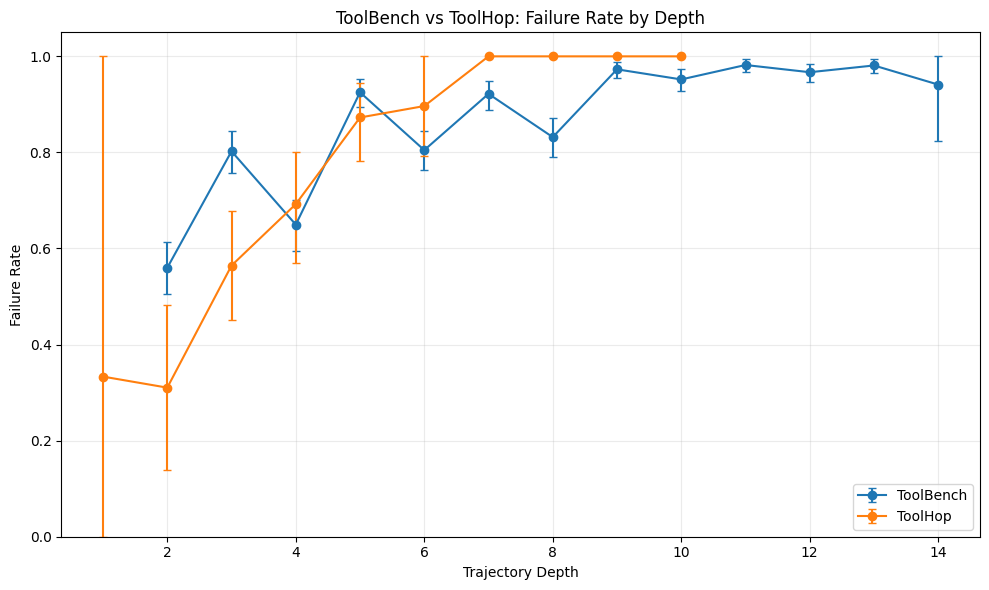

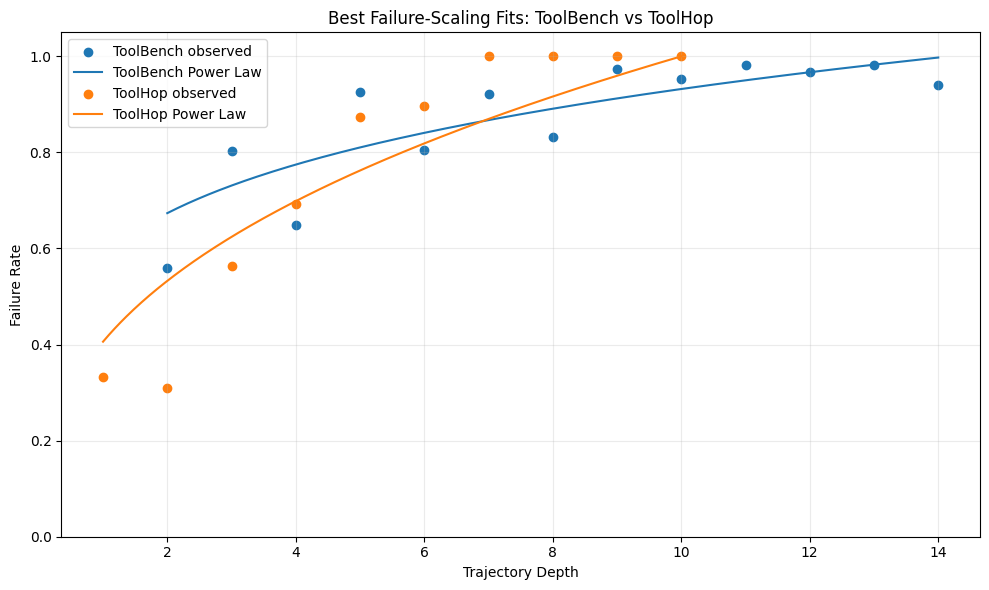

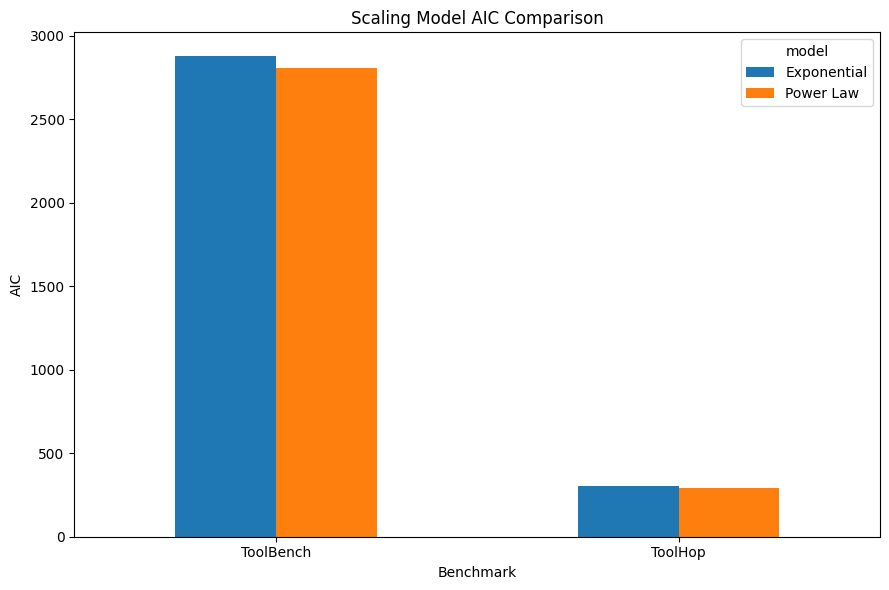

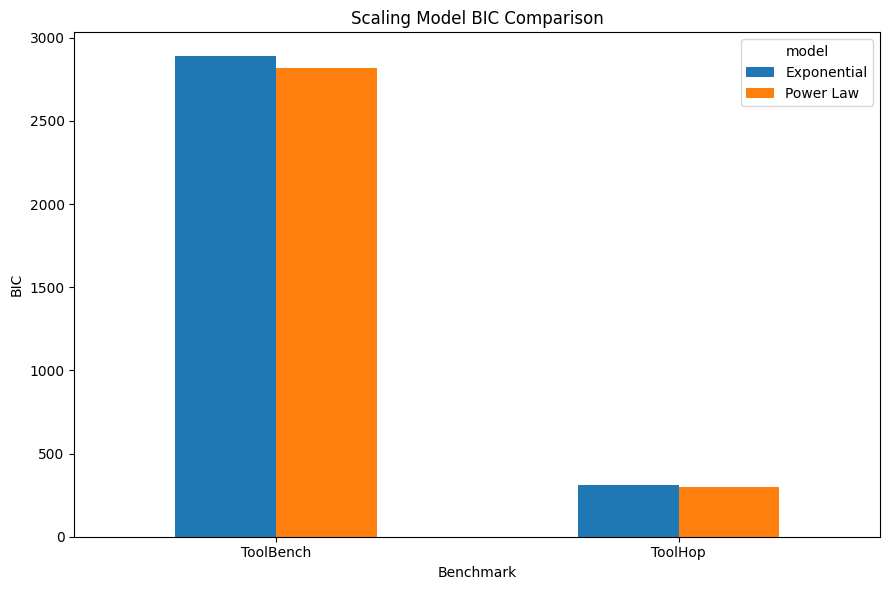


CROSS-BENCHMARK CURVE COMPARISON
 overlap_depth_min  overlap_depth_max  num_overlapping_depths      MAE     RMSE  weighted_MAE  weighted_RMSE  curve_similarity_1_minus_weighted_MAE  pearson_r  pearson_p  spearman_rho  spearman_p
                 2                 10                       9 0.110612 0.137134      0.117404       0.145872                               0.882596   0.850660   0.003651      0.800757    0.009508

KS TESTS
                               comparison  toolbench_n  toolhop_n  KS_statistic  p_value
       All trajectory depth distributions         4000        300      0.392750 0.000000
   Failure trajectory depth distributions         3449        221      0.399533 0.000000
No-Failure trajectory depth distributions          551         79      0.317742 0.000001

STEP 9D — FINAL SUMMARY
ToolBench failure column      : llm_failure_type

ToolBench trajectories        : 4,000
ToolHop trajectories          : 300

ToolBench failures            : 3,449
ToolBench No Failure

In [33]:
# ==================================================================================================
# STEP 9D — CROSS-BENCHMARK FAILURE-SCALING VALIDATION
# FINAL CORRECTED VERSION
#
# FIXES:
#   ✓ Handles ToolBench label files that ALREADY contain step_depth
#   ✓ Avoids step_depth_x / step_depth_y merge problem
#   ✓ Verifies label-file depth against Step3 depth when both exist
#   ✓ Robust ToolBench taxonomy-column detection
#   ✓ Normalizes Intent / Wrong / Param / Exec / NoFailure
#
# ANALYSIS:
#   ✓ Failure rate vs depth
#   ✓ Bootstrap 95% CI
#   ✓ Power-law vs exponential
#   ✓ AIC / BIC
#   ✓ RMSE / R²
#   ✓ Cross-benchmark curve similarity
#   ✓ Pearson / Spearman
#   ✓ KS tests
#   ✓ Publication figures
#   ✓ Resolves current master-setup backup inputs automatically
# ==================================================================================================


# ==================================================================================================
# 0. IMPORTS
# ==================================================================================================

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import (
    ks_2samp,
    pearsonr,
    spearmanr
)

warnings.filterwarnings("ignore")


# ==================================================================================================
# 1. PATHS
# ==================================================================================================

BASE = Path(
    "/kaggle/working/toolbench_research"
)

PROCESSED_DIR = (
    BASE
    /
    "data"
    /
    "processed"
)

TABLE_DIR = (
    BASE
    /
    "results"
    /
    "tables"
)

FIGURE_DIR = (
    BASE
    /
    "results"
    /
    "figures"
)


TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ==================================================================================================
# 1A. CURRENT MASTER-SETUP BACKUP RESOLUTION
# ==================================================================================================

MASTER_SETUP_ROOT = Path(
    "/kaggle/input/datasets/anandadevnath/master-setup"
)


if not MASTER_SETUP_ROOT.exists():

    raise FileNotFoundError(
        f"Master setup root not found:\n{MASTER_SETUP_ROOT}"
    )


backup_candidates = sorted(
    [
        path
        for path
        in MASTER_SETUP_ROOT.glob(
            "ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_*"
        )
        if path.is_dir()
    ]
)


if not backup_candidates:

    raise FileNotFoundError(
        "Could not locate ToolBench final backup inside:\n"
        f"{MASTER_SETUP_ROOT}"
    )


FINAL_BACKUP_ROOT = backup_candidates[-1]


BACKUP_RESEARCH_ROOT = (
    FINAL_BACKUP_ROOT
    /
    "CURRENT_RESEARCH"
)


BACKUP_PROCESSED_DIR = (
    BACKUP_RESEARCH_ROOT
    /
    "data"
    /
    "processed"
)


SOURCE_MASTER_BACKUP = (
    FINAL_BACKUP_ROOT
    /
    "SOURCE_MASTER_BACKUP"
)


def first_existing(
    candidates,
    description
):

    for candidate in candidates:

        candidate = Path(
            candidate
        )

        if candidate.exists():

            print(
                f"✓ {description}:\n{candidate}"
            )

            return candidate


    raise FileNotFoundError(
        f"Could not locate {description}.\n\nChecked:\n"
        +
        "\n".join(
            str(
                Path(path)
            )
            for path in candidates
        )
    )


print(
    f"✓ Current master backup detected:\n{FINAL_BACKUP_ROOT}"
)


# --------------------------------------------------------------------------------------------------
# ToolBench
# --------------------------------------------------------------------------------------------------

TOOLBENCH_LABEL_FILE = first_existing(
    [
        PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.parquet",

        BACKUP_PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.parquet"
    ],
    "ToolBench final 4,000 labels"
)


TOOLBENCH_FEATURE_FILE = first_existing(
    [
        SOURCE_MASTER_BACKUP
        /
        "featured"
        /
        "toolbench_train_80_features.parquet",

        MASTER_SETUP_ROOT
        /
        "featured"
        /
        "toolbench_train_80_features.parquet"
    ],
    "ToolBench Step-3 structural features"
)


# --------------------------------------------------------------------------------------------------
# ToolHop
# --------------------------------------------------------------------------------------------------

TOOLHOP_FILE = first_existing(
    [
        PROCESSED_DIR
        /
        "step9c_toolhop_trajectories_with_failure_labels.parquet",

        BACKUP_PROCESSED_DIR
        /
        "step9c_toolhop_trajectories_with_failure_labels.parquet"
    ],
    "ToolHop Step-9C labeled trajectories"
)


# ==================================================================================================
# 2. OUTPUTS
# ==================================================================================================

TB_RATE_PATH = (
    TABLE_DIR
    /
    "step9d_toolbench_failure_rate_by_depth.csv"
)

TH_RATE_PATH = (
    TABLE_DIR
    /
    "step9d_toolhop_failure_rate_by_depth.csv"
)

COMBINED_RATE_PATH = (
    TABLE_DIR
    /
    "step9d_cross_benchmark_failure_rate_by_depth.csv"
)

MODEL_COMPARISON_PATH = (
    TABLE_DIR
    /
    "step9d_cross_benchmark_scaling_model_comparison.csv"
)

CURVE_COMPARISON_PATH = (
    TABLE_DIR
    /
    "step9d_cross_benchmark_curve_similarity.csv"
)

KS_PATH = (
    TABLE_DIR
    /
    "step9d_cross_benchmark_ks_tests.csv"
)

SUMMARY_PATH = (
    TABLE_DIR
    /
    "step9d_cross_benchmark_summary.csv"
)

PREDICTION_PATH = (
    TABLE_DIR
    /
    "step9d_cross_benchmark_scaling_predictions.csv"
)

LABEL_DIAGNOSTIC_PATH = (
    TABLE_DIR
    /
    "step9d_toolbench_label_detection_diagnostic.csv"
)

DEPTH_VALIDATION_PATH = (
    TABLE_DIR
    /
    "step9d_toolbench_depth_validation.csv"
)


FIG_RATE_PATH = (
    FIGURE_DIR
    /
    "step9d_toolbench_vs_toolhop_failure_rate.png"
)

FIG_MODEL_PATH = (
    FIGURE_DIR
    /
    "step9d_toolbench_vs_toolhop_scaling_models.png"
)

FIG_AIC_PATH = (
    FIGURE_DIR
    /
    "step9d_scaling_model_aic_comparison.png"
)

FIG_BIC_PATH = (
    FIGURE_DIR
    /
    "step9d_scaling_model_bic_comparison.png"
)


# ==================================================================================================
# 3. CONFIG
# ==================================================================================================

RANDOM_STATE = 42

BOOTSTRAP_ITERATIONS = 5000

CI_LEVEL = 0.95

EPS = 1e-9


# ==================================================================================================
# 4. TAXONOMY
# ==================================================================================================

CANONICAL_LABELS = [
    "Intent Misunderstanding",
    "Wrong Tool Selection",
    "Parameter Hallucination",
    "Execution/Cascading Error",
    "No Failure"
]


def normalize_failure_label(value):

    if pd.isna(value):

        return None


    text = str(
        value
    ).strip()


    if not text:

        return None


    key = text.lower().strip()


    key = re.sub(
        r"[_\-]+",
        " ",
        key
    )


    key = re.sub(
        r"\s+",
        " ",
        key
    ).strip()


    mapping = {

        "intent":
            "Intent Misunderstanding",

        "intent misunderstanding":
            "Intent Misunderstanding",

        "intent error":
            "Intent Misunderstanding",


        "wrong":
            "Wrong Tool Selection",

        "wrong tool":
            "Wrong Tool Selection",

        "wrong tool selection":
            "Wrong Tool Selection",


        "param":
            "Parameter Hallucination",

        "parameter":
            "Parameter Hallucination",

        "parameter hallucination":
            "Parameter Hallucination",

        "parameter error":
            "Parameter Hallucination",


        "exec":
            "Execution/Cascading Error",

        "execution":
            "Execution/Cascading Error",

        "execution error":
            "Execution/Cascading Error",

        "execution cascading error":
            "Execution/Cascading Error",

        "execution/cascading error":
            "Execution/Cascading Error",

        "cascading error":
            "Execution/Cascading Error",


        "nofailure":
            "No Failure",

        "no failure":
            "No Failure",

        "none":
            "No Failure"
    }


    if key in mapping:

        return mapping[
            key
        ]


    for label in CANONICAL_LABELS:

        if key == label.lower():

            return label


    return None


# ==================================================================================================
# 5. ID DETECTOR
# ==================================================================================================

def find_id_column(df):

    preferred = [
        "id",
        "trajectory_id",
        "toolbench_id",
        "sample_id",
        "conversation_id"
    ]


    for column in preferred:

        if column in df.columns:

            return column


    for column in df.columns:

        lower = str(
            column
        ).lower()


        if (
            lower == "id"
            or
            lower.endswith(
                "_id"
            )
        ):

            unique_fraction = (
                df[
                    column
                ]
                .nunique(
                    dropna=True
                )
                /
                max(
                    len(
                        df
                    ),
                    1
                )
            )


            if unique_fraction >= 0.90:

                return column


    raise ValueError(
        "Could not detect ID column.\n"
        f"Columns:\n{df.columns.tolist()}"
    )


# ==================================================================================================
# 6. FAILURE COLUMN DETECTOR
# ==================================================================================================

def detect_failure_column(df):

    preferred = [
        "failure_type",
        "failure_label",
        "gpt_failure_type",
        "gpt_label",
        "llm_label",
        "predicted_label",
        "annotation_label",
        "taxonomy_label",
        "failure_category",
        "category",
        "class",
        "label"
    ]


    # ----------------------------------------------------------------------------------------------
    # Known names first
    # ----------------------------------------------------------------------------------------------

    for column in preferred:

        if column not in df.columns:

            continue


        normalized = (
            df[
                column
            ]
            .apply(
                normalize_failure_label
            )
        )


        coverage = float(
            normalized
            .notna()
            .mean()
        )


        classes = set(
            normalized
            .dropna()
            .unique()
        )


        if (
            coverage >= 0.80
            and
            len(
                classes
            ) >= 2
        ):

            return (
                column,
                normalized,
                coverage
            )


    # ----------------------------------------------------------------------------------------------
    # Search all low-cardinality columns
    # ----------------------------------------------------------------------------------------------

    diagnostics = []

    best_column = None

    best_normalized = None

    best_coverage = 0

    best_classes = 0


    for column in df.columns:

        try:

            unique_count = (
                df[
                    column
                ]
                .nunique(
                    dropna=True
                )
            )

        except Exception:

            continue


        if (
            unique_count == 0
            or
            unique_count > 100
        ):

            continue


        normalized = (
            df[
                column
            ]
            .apply(
                normalize_failure_label
            )
        )


        coverage = float(
            normalized
            .notna()
            .mean()
        )


        recognized = (
            normalized
            .dropna()
            .unique()
            .tolist()
        )


        diagnostics.append({
            "column":
                column,

            "unique_values":
                int(
                    unique_count
                ),

            "taxonomy_coverage":
                coverage,

            "recognized_classes":
                " | ".join(
                    sorted(
                        recognized
                    )
                )
        })


        class_count = len(
            recognized
        )


        if (
            coverage > best_coverage
            or
            (
                np.isclose(
                    coverage,
                    best_coverage
                )
                and
                class_count > best_classes
            )
        ):

            best_column = column

            best_normalized = normalized

            best_coverage = coverage

            best_classes = class_count


    diagnostic_df = pd.DataFrame(
        diagnostics
    )


    if not diagnostic_df.empty:

        diagnostic_df = (
            diagnostic_df
            .sort_values(
                "taxonomy_coverage",
                ascending=False
            )
            .reset_index(
                drop=True
            )
        )


        diagnostic_df.to_csv(
            LABEL_DIAGNOSTIC_PATH,
            index=False
        )


    if (
        best_column is None
        or
        best_coverage < 0.80
        or
        best_classes < 2
    ):

        raise ValueError(
            "Could not detect ToolBench failure taxonomy column."
        )


    return (
        best_column,
        best_normalized,
        best_coverage
    )


# ==================================================================================================
# 7. START
# ==================================================================================================

print(
    "=" * 120
)

print(
    "STEP 9D — CROSS-BENCHMARK FAILURE-SCALING VALIDATION"
)

print(
    "=" * 120
)


print(
    f"\nMaster backup:\n{FINAL_BACKUP_ROOT}"
)

print(
    f"\nToolBench labels:\n{TOOLBENCH_LABEL_FILE}"
)

print(
    f"\nToolBench features:\n{TOOLBENCH_FEATURE_FILE}"
)

print(
    f"\nToolHop labeled trajectories:\n{TOOLHOP_FILE}"
)


# ==================================================================================================
# 8. LOAD TOOLBENCH


# ==================================================================================================
# 8. LOAD TOOLBENCH
# ==================================================================================================

print(
    "\nLoading ToolBench..."
)


if not TOOLBENCH_LABEL_FILE.exists():

    raise FileNotFoundError(
        f"Missing ToolBench labels:\n{TOOLBENCH_LABEL_FILE}"
    )


if not TOOLBENCH_FEATURE_FILE.exists():

    raise FileNotFoundError(
        f"Missing ToolBench features:\n{TOOLBENCH_FEATURE_FILE}"
    )


tb_labels = pd.read_parquet(
    TOOLBENCH_LABEL_FILE
)


tb_features = pd.read_parquet(
    TOOLBENCH_FEATURE_FILE
)


print(
    f"ToolBench labels   : {len(tb_labels):,}"
)

print(
    f"ToolBench features : {len(tb_features):,}"
)


print(
    "\nToolBench label columns:"
)

print(
    tb_labels.columns.tolist()
)


# ==================================================================================================
# 9. DETECT IDs
# ==================================================================================================

tb_label_id = find_id_column(
    tb_labels
)


tb_feature_id = find_id_column(
    tb_features
)


print(
    f"\nToolBench label ID   : {tb_label_id}"
)

print(
    f"ToolBench feature ID : {tb_feature_id}"
)


# ==================================================================================================
# 10. DETECT FAILURE LABEL
# ==================================================================================================

(
    tb_failure_column,
    tb_normalized,
    label_coverage
) = detect_failure_column(
    tb_labels
)


tb_labels = tb_labels.copy()


tb_labels[
    "failure_type_normalized"
] = tb_normalized


print(
    "\n✓ Failure column detected"
)

print(
    f"Column           : {tb_failure_column}"
)

print(
    f"Coverage         : {label_coverage * 100:.2f}%"
)


print(
    "\nOriginal label distribution:"
)


print(
    tb_labels[
        tb_failure_column
    ]
    .value_counts(
        dropna=False
    )
    .to_string()
)


print(
    "\nNormalized taxonomy:"
)


print(
    tb_labels[
        "failure_type_normalized"
    ]
    .value_counts()
    .reindex(
        CANONICAL_LABELS,
        fill_value=0
    )
    .to_string()
)


if tb_labels[
    "failure_type_normalized"
].isna().any():

    raise RuntimeError(
        "Some ToolBench labels could not be normalized."
    )


# ==================================================================================================
# 11. TOOLBENCH DEPTH — ROBUST CORRECTED LOGIC
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "TOOLBENCH DEPTH RESOLUTION"
)

print(
    "=" * 120
)


labels_have_depth = (
    "step_depth"
    in
    tb_labels.columns
)


features_have_depth = (
    "step_depth"
    in
    tb_features.columns
)


print(
    f"Label file has step_depth   : {labels_have_depth}"
)

print(
    f"Feature file has step_depth : {features_have_depth}"
)


if (
    not labels_have_depth
    and
    not features_have_depth
):

    raise RuntimeError(
        "step_depth is missing from both ToolBench label and feature files."
    )


# --------------------------------------------------------------------------------------------------
# CASE A:
# Label file already contains step_depth.
#
# Use it directly.
# Optionally validate it against Step3 feature depth.
# --------------------------------------------------------------------------------------------------

if labels_have_depth:

    tb = tb_labels.copy()


    tb[
        "step_depth"
    ] = pd.to_numeric(
        tb[
            "step_depth"
        ],
        errors="coerce"
    )


    if tb[
        "step_depth"
    ].isna().any():

        raise RuntimeError(
            "ToolBench label file contains missing/invalid step_depth values."
        )


    tb[
        "step_depth"
    ] = tb[
        "step_depth"
    ].astype(
        int
    )


    print(
        "✓ Using step_depth already stored in final 4K label file."
    )


    # ----------------------------------------------------------------------------------------------
    # Validate against Step3 if available.
    # Do NOT merge another column named step_depth into tb.
    # ----------------------------------------------------------------------------------------------

    if features_have_depth:

        validation_depth = (
            tb_features[
                [
                    tb_feature_id,
                    "step_depth"
                ]
            ]
            .copy()
            .rename(
                columns={
                    tb_feature_id:
                        tb_label_id,

                    "step_depth":
                        "step_depth_feature"
                }
            )
        )


        depth_check = tb[
            [
                tb_label_id,
                "step_depth"
            ]
        ].merge(
            validation_depth,
            on=tb_label_id,
            how="left",
            validate="one_to_one"
        )


        depth_check[
            "step_depth_feature"
        ] = pd.to_numeric(
            depth_check[
                "step_depth_feature"
            ],
            errors="coerce"
        )


        missing_feature_depth = int(
            depth_check[
                "step_depth_feature"
            ].isna().sum()
        )


        if missing_feature_depth > 0:

            raise RuntimeError(
                f"{missing_feature_depth:,} ToolBench 4K rows "
                "did not match Step3 features."
            )


        depth_check[
            "depth_matches"
        ] = (
            depth_check[
                "step_depth"
            ]
            ==
            depth_check[
                "step_depth_feature"
            ]
        )


        mismatch_count = int(
            (
                ~depth_check[
                    "depth_matches"
                ]
            ).sum()
        )


        depth_check.to_csv(
            DEPTH_VALIDATION_PATH,
            index=False
        )


        print(
            f"Step3 matched rows           : {len(depth_check):,}"
        )

        print(
            f"Depth disagreements          : {mismatch_count:,}"
        )


        if mismatch_count > 0:

            print(
                "\n⚠ Label-file and Step3 depths differ."
            )

            print(
                "Using authoritative Step3 feature depth."
            )


            authoritative_depth = (
                validation_depth[
                    [
                        tb_label_id,
                        "step_depth_feature"
                    ]
                ]
            )


            tb = tb.drop(
                columns=[
                    "step_depth"
                ]
            )


            tb = tb.merge(
                authoritative_depth,
                on=tb_label_id,
                how="left",
                validate="one_to_one"
            )


            tb = tb.rename(
                columns={
                    "step_depth_feature":
                        "step_depth"
                }
            )


        else:

            print(
                "✓ Label-file depth exactly matches Step3 depth."
            )


# --------------------------------------------------------------------------------------------------
# CASE B:
# Labels do NOT contain depth.
# Merge authoritative Step3 depth.
# --------------------------------------------------------------------------------------------------

else:

    print(
        "Label file has no step_depth."
    )

    print(
        "Using Step3 feature depth."
    )


    feature_depth = (
        tb_features[
            [
                tb_feature_id,
                "step_depth"
            ]
        ]
        .copy()
        .rename(
            columns={
                tb_feature_id:
                    tb_label_id
            }
        )
    )


    tb = tb_labels.merge(
        feature_depth,
        on=tb_label_id,
        how="left",
        validate="one_to_one"
    )


    if tb[
        "step_depth"
    ].isna().any():

        missing = int(
            tb[
                "step_depth"
            ].isna().sum()
        )


        raise RuntimeError(
            f"{missing:,} ToolBench labels did not match Step3 depth."
        )


    tb[
        "step_depth"
    ] = pd.to_numeric(
        tb[
            "step_depth"
        ],
        errors="raise"
    ).astype(
        int
    )


# ==================================================================================================
# 12. FINAL TOOLBENCH STRUCTURE CHECK
# ==================================================================================================

# Remove accidental duplicate suffix columns if previous notebook state had them.
for duplicate_column in [
    "step_depth_x",
    "step_depth_y",
    "step_depth_feature"
]:

    if duplicate_column in tb.columns:

        tb = tb.drop(
            columns=[
                duplicate_column
            ]
        )


if "step_depth" not in tb.columns:

    raise RuntimeError(
        "Internal error: final ToolBench table has no step_depth."
    )


tb[
    "failure_type"
] = tb[
    "failure_type_normalized"
]


tb[
    "is_failure"
] = (
    tb[
        "failure_type"
    ]
    !=
    "No Failure"
).astype(
    int
)


if len(
    tb
) != 4000:

    raise RuntimeError(
        f"Expected ToolBench 4,000 rows, found {len(tb):,}."
    )


if tb[
    tb_label_id
].nunique() != 4000:

    raise RuntimeError(
        "ToolBench IDs are not unique after depth resolution."
    )


print(
    "\n✓ Final ToolBench table ready"
)

print(
    f"Rows             : {len(tb):,}"
)

print(
    f"Unique IDs       : {tb[tb_label_id].nunique():,}"
)

print(
    f"Depth range      : {tb['step_depth'].min()}–{tb['step_depth'].max()}"
)

print(
    f"Failures         : {tb['is_failure'].sum():,}"
)

print(
    f"No Failure       : {(tb['is_failure'] == 0).sum():,}"
)

print(
    f"Failure rate     : {tb['is_failure'].mean() * 100:.2f}%"
)


# ==================================================================================================
# 13. LOAD TOOLHOP
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "LOADING TOOLHOP"
)

print(
    "=" * 120
)


if not TOOLHOP_FILE.exists():

    raise FileNotFoundError(
        f"Missing Step9C ToolHop file:\n{TOOLHOP_FILE}"
    )


th = pd.read_parquet(
    TOOLHOP_FILE
)


required_toolhop_columns = [
    "toolhop_id",
    "step_depth",
    "failure_type"
]


for column in required_toolhop_columns:

    if column not in th.columns:

        raise ValueError(
            f"ToolHop missing column: {column}"
        )


th[
    "failure_type"
] = (
    th[
        "failure_type"
    ]
    .apply(
        normalize_failure_label
    )
)


if th[
    "failure_type"
].isna().any():

    raise RuntimeError(
        "Unrecognized ToolHop failure labels found."
    )


th[
    "step_depth"
] = pd.to_numeric(
    th[
        "step_depth"
    ],
    errors="raise"
).astype(
    int
)


th[
    "is_failure"
] = (
    th[
        "failure_type"
    ]
    !=
    "No Failure"
).astype(
    int
)


if len(
    th
) != 300:

    raise RuntimeError(
        f"Expected 300 ToolHop rows, found {len(th):,}."
    )


if th[
    "toolhop_id"
].nunique() != 300:

    raise RuntimeError(
        "ToolHop IDs are not unique."
    )


print(
    f"ToolHop rows         : {len(th):,}"
)

print(
    f"Failures             : {th['is_failure'].sum():,}"
)

print(
    f"No Failure           : {(th['is_failure'] == 0).sum():,}"
)

print(
    f"Failure rate         : {th['is_failure'].mean() * 100:.2f}%"
)

print(
    f"Depth range          : {th['step_depth'].min()}–{th['step_depth'].max()}"
)


# ==================================================================================================
# 14. BOOTSTRAP CI
# ==================================================================================================

def bootstrap_binary_ci(
    values,
    iterations=5000,
    ci_level=0.95,
    seed=42
):

    values = np.asarray(
        values,
        dtype=float
    )


    n = len(
        values
    )


    if n == 0:

        return (
            np.nan,
            np.nan,
            np.nan
        )


    point = float(
        values.mean()
    )


    if n == 1:

        return (
            point,
            point,
            point
        )


    local_rng = np.random.default_rng(
        seed
    )


    means = np.empty(
        iterations,
        dtype=float
    )


    for i in range(
        iterations
    ):

        sampled = local_rng.choice(
            values,
            size=n,
            replace=True
        )


        means[
            i
        ] = sampled.mean()


    alpha = (
        1
        -
        ci_level
    )


    lower = float(
        np.quantile(
            means,
            alpha / 2
        )
    )


    upper = float(
        np.quantile(
            means,
            1 - alpha / 2
        )
    )


    return (
        point,
        lower,
        upper
    )


# ==================================================================================================
# 15. RATE TABLE
# ==================================================================================================

def build_rate_table(
    df,
    benchmark,
    seed_offset
):

    rows = []


    for depth in sorted(
        df[
            "step_depth"
        ].unique()
    ):

        subset = df[
            df[
                "step_depth"
            ]
            ==
            depth
        ]


        point, lower, upper = bootstrap_binary_ci(
            subset[
                "is_failure"
            ].to_numpy(),
            iterations=BOOTSTRAP_ITERATIONS,
            ci_level=CI_LEVEL,
            seed=(
                RANDOM_STATE
                +
                seed_offset
                +
                int(
                    depth
                )
            )
        )


        rows.append({
            "benchmark":
                benchmark,

            "step_depth":
                int(
                    depth
                ),

            "n":
                len(
                    subset
                ),

            "failures":
                int(
                    subset[
                        "is_failure"
                    ].sum()
                ),

            "no_failure":
                int(
                    (
                        subset[
                            "is_failure"
                        ]
                        ==
                        0
                    ).sum()
                ),

            "failure_rate":
                point,

            "ci_low":
                lower,

            "ci_high":
                upper
        })


    return pd.DataFrame(
        rows
    )


tb_rate = build_rate_table(
    tb,
    "ToolBench",
    1000
)


th_rate = build_rate_table(
    th,
    "ToolHop",
    2000
)


tb_rate.to_csv(
    TB_RATE_PATH,
    index=False
)


th_rate.to_csv(
    TH_RATE_PATH,
    index=False
)


combined_rate = pd.concat(
    [
        tb_rate,
        th_rate
    ],
    ignore_index=True
)


combined_rate.to_csv(
    COMBINED_RATE_PATH,
    index=False
)


# ==================================================================================================
# 16. PRINT DEPTH TABLES
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "TOOLBENCH FAILURE RATE BY DEPTH"
)

print(
    "=" * 120
)


print(
    tb_rate.to_string(
        index=False,
        formatters={
            "failure_rate":
                lambda x: f"{x * 100:.2f}%",

            "ci_low":
                lambda x: f"{x * 100:.2f}%",

            "ci_high":
                lambda x: f"{x * 100:.2f}%"
        }
    )
)


print(
    "\n"
    + "=" * 120
)

print(
    "TOOLHOP FAILURE RATE BY DEPTH"
)

print(
    "=" * 120
)


print(
    th_rate.to_string(
        index=False,
        formatters={
            "failure_rate":
                lambda x: f"{x * 100:.2f}%",

            "ci_low":
                lambda x: f"{x * 100:.2f}%",

            "ci_high":
                lambda x: f"{x * 100:.2f}%"
        }
    )
)


# ==================================================================================================
# 17. BINOMIAL LOG-LIKELIHOOD
# ==================================================================================================

def binomial_log_likelihood(
    failures,
    totals,
    probabilities
):

    probabilities = np.clip(
        np.asarray(
            probabilities,
            dtype=float
        ),
        EPS,
        1 - EPS
    )


    failures = np.asarray(
        failures,
        dtype=float
    )


    totals = np.asarray(
        totals,
        dtype=float
    )


    non_failures = (
        totals
        -
        failures
    )


    return float(
        np.sum(
            failures
            *
            np.log(
                probabilities
            )
            +
            non_failures
            *
            np.log(
                1 - probabilities
            )
        )
    )


# ==================================================================================================
# 18. FIT METRICS
# ==================================================================================================

def calculate_fit_metrics(
    observed,
    predicted,
    failures,
    totals
):

    ll = binomial_log_likelihood(
        failures,
        totals,
        predicted
    )


    k = 2


    n_obs = float(
        np.sum(
            totals
        )
    )


    aic = (
        2 * k
        -
        2 * ll
    )


    bic = (
        k
        *
        np.log(
            n_obs
        )
        -
        2 * ll
    )


    rmse = float(
        np.sqrt(
            np.mean(
                (
                    observed
                    -
                    predicted
                )
                **
                2
            )
        )
    )


    ss_res = float(
        np.sum(
            (
                observed
                -
                predicted
            )
            **
            2
        )
    )


    ss_tot = float(
        np.sum(
            (
                observed
                -
                observed.mean()
            )
            **
            2
        )
    )


    if ss_tot > 0:

        r2 = float(
            1
            -
            ss_res
            /
            ss_tot
        )

    else:

        r2 = np.nan


    return (
        ll,
        aic,
        bic,
        rmse,
        r2
    )


# ==================================================================================================
# 19. POWER LAW
# ==================================================================================================

def fit_power_law(rate_df):

    depth = rate_df[
        "step_depth"
    ].to_numpy(
        dtype=float
    )


    totals = rate_df[
        "n"
    ].to_numpy(
        dtype=float
    )


    failures = rate_df[
        "failures"
    ].to_numpy(
        dtype=float
    )


    observed = (
        failures
        /
        totals
    )


    def objective(params):

        a, b = params


        if a <= 0:

            return 1e15


        pred = (
            a
            *
            np.power(
                depth,
                b
            )
        )


        if (
            np.any(
                ~np.isfinite(
                    pred
                )
            )
            or
            np.any(
                pred <= 0
            )
            or
            np.any(
                pred >= 1
            )
        ):

            return 1e15


        return -binomial_log_likelihood(
            failures,
            totals,
            pred
        )


    result = minimize(
        objective,
        x0=[
            max(
                min(
                    observed[
                        0
                    ],
                    0.90
                ),
                0.05
            ),
            0.10
        ],
        method="Nelder-Mead",
        options={
            "maxiter":
                50000,

            "xatol":
                1e-10,

            "fatol":
                1e-10
        }
    )


    a, b = result.x


    predicted = np.clip(
        a
        *
        np.power(
            depth,
            b
        ),
        EPS,
        1 - EPS
    )


    (
        ll,
        aic,
        bic,
        rmse,
        r2
    ) = calculate_fit_metrics(
        observed,
        predicted,
        failures,
        totals
    )


    return {
        "model":
            "Power Law",

        "a":
            float(
                a
            ),

        "b":
            float(
                b
            ),

        "log_likelihood":
            ll,

        "AIC":
            aic,

        "BIC":
            bic,

        "RMSE":
            rmse,

        "R2":
            r2,

        "optimizer_success":
            bool(
                result.success
            )
    }


# ==================================================================================================
# 20. EXPONENTIAL
# ==================================================================================================

def fit_exponential(rate_df):

    depth = rate_df[
        "step_depth"
    ].to_numpy(
        dtype=float
    )


    totals = rate_df[
        "n"
    ].to_numpy(
        dtype=float
    )


    failures = rate_df[
        "failures"
    ].to_numpy(
        dtype=float
    )


    observed = (
        failures
        /
        totals
    )


    def objective(params):

        a, b = params


        if a <= 0:

            return 1e15


        pred = (
            a
            *
            np.exp(
                b
                *
                depth
            )
        )


        if (
            np.any(
                ~np.isfinite(
                    pred
                )
            )
            or
            np.any(
                pred <= 0
            )
            or
            np.any(
                pred >= 1
            )
        ):

            return 1e15


        return -binomial_log_likelihood(
            failures,
            totals,
            pred
        )


    result = minimize(
        objective,
        x0=[
            max(
                min(
                    observed[
                        0
                    ],
                    0.90
                ),
                0.05
            ),
            0.02
        ],
        method="Nelder-Mead",
        options={
            "maxiter":
                50000,

            "xatol":
                1e-10,

            "fatol":
                1e-10
        }
    )


    a, b = result.x


    predicted = np.clip(
        a
        *
        np.exp(
            b
            *
            depth
        ),
        EPS,
        1 - EPS
    )


    (
        ll,
        aic,
        bic,
        rmse,
        r2
    ) = calculate_fit_metrics(
        observed,
        predicted,
        failures,
        totals
    )


    return {
        "model":
            "Exponential",

        "a":
            float(
                a
            ),

        "b":
            float(
                b
            ),

        "log_likelihood":
            ll,

        "AIC":
            aic,

        "BIC":
            bic,

        "RMSE":
            rmse,

        "R2":
            r2,

        "optimizer_success":
            bool(
                result.success
            )
    }


# ==================================================================================================
# 21. FIT MODELS
# ==================================================================================================

model_rows = []

fit_objects = {}


for benchmark, rate_table in [
    (
        "ToolBench",
        tb_rate
    ),
    (
        "ToolHop",
        th_rate
    )
]:

    power = fit_power_law(
        rate_table
    )


    exponential = fit_exponential(
        rate_table
    )


    fit_objects[
        (
            benchmark,
            "Power Law"
        )
    ] = power


    fit_objects[
        (
            benchmark,
            "Exponential"
        )
    ] = exponential


    for fit in [
        power,
        exponential
    ]:

        row = {
            "benchmark":
                benchmark
        }


        row.update(
            fit
        )


        model_rows.append(
            row
        )


model_df = pd.DataFrame(
    model_rows
)


model_df.to_csv(
    MODEL_COMPARISON_PATH,
    index=False
)


print(
    "\n"
    + "=" * 120
)

print(
    "SCALING MODEL COMPARISON"
)

print(
    "=" * 120
)


print(
    model_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}"
    )
)


# ==================================================================================================
# 22. BEST MODEL
# ==================================================================================================

best_models = {}


for benchmark in [
    "ToolBench",
    "ToolHop"
]:

    temp = (
        model_df[
            model_df[
                "benchmark"
            ]
            ==
            benchmark
        ]
        .sort_values(
            "AIC"
        )
        .reset_index(
            drop=True
        )
    )


    best_models[
        benchmark
    ] = temp.iloc[
        0
    ]


    print(
        f"\n{benchmark} best by AIC: "
        f"{temp.iloc[0]['model']}"
    )


    if len(
        temp
    ) > 1:

        delta_aic = (
            temp.iloc[
                1
            ][
                "AIC"
            ]
            -
            temp.iloc[
                0
            ][
                "AIC"
            ]
        )


        print(
            f"ΔAIC = {delta_aic:.4f}"
        )


# ==================================================================================================
# 23. MODEL PREDICTIONS
# ==================================================================================================

prediction_rows = []


for benchmark, rate_table in [
    (
        "ToolBench",
        tb_rate
    ),
    (
        "ToolHop",
        th_rate
    )
]:

    min_depth = float(
        rate_table[
            "step_depth"
        ].min()
    )


    max_depth = float(
        rate_table[
            "step_depth"
        ].max()
    )


    curve_depth = np.linspace(
        min_depth,
        max_depth,
        300
    )


    for model_name in [
        "Power Law",
        "Exponential"
    ]:

        fit = fit_objects[
            (
                benchmark,
                model_name
            )
        ]


        a = fit[
            "a"
        ]

        b = fit[
            "b"
        ]


        if model_name == "Power Law":

            predicted = (
                a
                *
                np.power(
                    curve_depth,
                    b
                )
            )


        else:

            predicted = (
                a
                *
                np.exp(
                    b
                    *
                    curve_depth
                )
            )


        predicted = np.clip(
            predicted,
            0,
            1
        )


        for d, p in zip(
            curve_depth,
            predicted
        ):

            prediction_rows.append({
                "benchmark":
                    benchmark,

                "model":
                    model_name,

                "step_depth":
                    float(
                        d
                    ),

                "predicted_failure_rate":
                    float(
                        p
                    )
            })


prediction_df = pd.DataFrame(
    prediction_rows
)


prediction_df.to_csv(
    PREDICTION_PATH,
    index=False
)


# ==================================================================================================
# 24. OVERLAPPING OBSERVED DEPTHS
# ==================================================================================================

overlap_depths = sorted(
    set(
        tb_rate[
            "step_depth"
        ]
    )
    &
    set(
        th_rate[
            "step_depth"
        ]
    )
)


print(
    "\nOverlapping depths:"
)

print(
    overlap_depths
)


if len(
    overlap_depths
) < 2:

    raise RuntimeError(
        "Not enough overlapping depths for curve comparison."
    )


# ==================================================================================================
# 25. ALIGN CURVES
# ==================================================================================================

tb_overlap = (
    tb_rate[
        tb_rate[
            "step_depth"
        ].isin(
            overlap_depths
        )
    ][
        [
            "step_depth",
            "n",
            "failure_rate"
        ]
    ]
    .rename(
        columns={
            "n":
                "toolbench_n",

            "failure_rate":
                "toolbench_failure_rate"
        }
    )
)


th_overlap = (
    th_rate[
        th_rate[
            "step_depth"
        ].isin(
            overlap_depths
        )
    ][
        [
            "step_depth",
            "n",
            "failure_rate"
        ]
    ]
    .rename(
        columns={
            "n":
                "toolhop_n",

            "failure_rate":
                "toolhop_failure_rate"
        }
    )
)


overlap_df = tb_overlap.merge(
    th_overlap,
    on="step_depth",
    validate="one_to_one"
)


print(
    "\nObserved overlap:"
)


print(
    overlap_df.to_string(
        index=False,
        formatters={
            "toolbench_failure_rate":
                lambda x:
                f"{x * 100:.2f}%",

            "toolhop_failure_rate":
                lambda x:
                f"{x * 100:.2f}%"
        }
    )
)


# ==================================================================================================
# 26. CURVE SIMILARITY
# ==================================================================================================

tb_curve = overlap_df[
    "toolbench_failure_rate"
].to_numpy(
    dtype=float
)


th_curve = overlap_df[
    "toolhop_failure_rate"
].to_numpy(
    dtype=float
)


difference = (
    tb_curve
    -
    th_curve
)


abs_difference = np.abs(
    difference
)


mae_overlap = float(
    np.mean(
        abs_difference
    )
)


rmse_overlap = float(
    np.sqrt(
        np.mean(
            difference
            **
            2
        )
    )
)


weights = np.minimum(
    overlap_df[
        "toolbench_n"
    ].to_numpy(
        dtype=float
    ),
    overlap_df[
        "toolhop_n"
    ].to_numpy(
        dtype=float
    )
)


if weights.sum() <= 0:

    weights = np.ones_like(
        weights
    )


weighted_mae = float(
    np.average(
        abs_difference,
        weights=weights
    )
)


weighted_rmse = float(
    np.sqrt(
        np.average(
            difference
            **
            2,
            weights=weights
        )
    )
)


curve_similarity = float(
    1
    -
    weighted_mae
)


# ==================================================================================================
# 27. CORRELATION
# ==================================================================================================

if (
    len(
        tb_curve
    ) >= 2
    and
    np.std(
        tb_curve
    ) > 0
    and
    np.std(
        th_curve
    ) > 0
):

    pearson_r, pearson_p = pearsonr(
        tb_curve,
        th_curve
    )


else:

    pearson_r = np.nan

    pearson_p = np.nan


if len(
    tb_curve
) >= 2:

    spearman_rho, spearman_p = spearmanr(
        tb_curve,
        th_curve
    )


else:

    spearman_rho = np.nan

    spearman_p = np.nan


curve_comparison_df = pd.DataFrame([
    {
        "overlap_depth_min":
            int(
                min(
                    overlap_depths
                )
            ),

        "overlap_depth_max":
            int(
                max(
                    overlap_depths
                )
            ),

        "num_overlapping_depths":
            len(
                overlap_depths
            ),

        "MAE":
            mae_overlap,

        "RMSE":
            rmse_overlap,

        "weighted_MAE":
            weighted_mae,

        "weighted_RMSE":
            weighted_rmse,

        "curve_similarity_1_minus_weighted_MAE":
            curve_similarity,

        "pearson_r":
            float(
                pearson_r
            ),

        "pearson_p":
            float(
                pearson_p
            ),

        "spearman_rho":
            float(
                spearman_rho
            ),

        "spearman_p":
            float(
                spearman_p
            )
    }
])


curve_comparison_df.to_csv(
    CURVE_COMPARISON_PATH,
    index=False
)


# ==================================================================================================
# 28. KS TESTS
# ==================================================================================================

def perform_ks(
    name,
    toolbench_values,
    toolhop_values
):

    toolbench_values = np.asarray(
        toolbench_values
    )


    toolhop_values = np.asarray(
        toolhop_values
    )


    result = ks_2samp(
        toolbench_values,
        toolhop_values,
        alternative="two-sided",
        method="auto"
    )


    return {
        "comparison":
            name,

        "toolbench_n":
            len(
                toolbench_values
            ),

        "toolhop_n":
            len(
                toolhop_values
            ),

        "KS_statistic":
            float(
                result.statistic
            ),

        "p_value":
            float(
                result.pvalue
            )
    }


ks_rows = []


ks_rows.append(
    perform_ks(
        "All trajectory depth distributions",
        tb[
            "step_depth"
        ],
        th[
            "step_depth"
        ]
    )
)


tb_failure_depth = tb.loc[
    tb[
        "is_failure"
    ]
    ==
    1,
    "step_depth"
]


th_failure_depth = th.loc[
    th[
        "is_failure"
    ]
    ==
    1,
    "step_depth"
]


ks_rows.append(
    perform_ks(
        "Failure trajectory depth distributions",
        tb_failure_depth,
        th_failure_depth
    )
)


tb_no_failure_depth = tb.loc[
    tb[
        "is_failure"
    ]
    ==
    0,
    "step_depth"
]


th_no_failure_depth = th.loc[
    th[
        "is_failure"
    ]
    ==
    0,
    "step_depth"
]


ks_rows.append(
    perform_ks(
        "No-Failure trajectory depth distributions",
        tb_no_failure_depth,
        th_no_failure_depth
    )
)


ks_df = pd.DataFrame(
    ks_rows
)


ks_df.to_csv(
    KS_PATH,
    index=False
)


# ==================================================================================================
# 29. DEPTH TREND
# ==================================================================================================

def trend_summary(
    rate_table
):

    ordered = (
        rate_table
        .sort_values(
            "step_depth"
        )
        .reset_index(
            drop=True
        )
    )


    first = ordered.iloc[
        0
    ]


    last = ordered.iloc[
        -1
    ]


    change = (
        float(
            last[
                "failure_rate"
            ]
        )
        -
        float(
            first[
                "failure_rate"
            ]
        )
    )


    return {
        "min_depth":
            int(
                first[
                    "step_depth"
                ]
            ),

        "max_depth":
            int(
                last[
                    "step_depth"
                ]
            ),

        "first_rate":
            float(
                first[
                    "failure_rate"
                ]
            ),

        "last_rate":
            float(
                last[
                    "failure_rate"
                ]
            ),

        "absolute_change":
            change
    }


tb_trend = trend_summary(
    tb_rate
)


th_trend = trend_summary(
    th_rate
)


# ==================================================================================================
# 30. SUMMARY
# ==================================================================================================

tb_best = best_models[
    "ToolBench"
]


th_best = best_models[
    "ToolHop"
]


same_best_model = (
    tb_best[
        "model"
    ]
    ==
    th_best[
        "model"
    ]
)


both_positive = (
    tb_trend[
        "absolute_change"
    ] > 0
    and
    th_trend[
        "absolute_change"
    ] > 0
)


failure_ks = ks_df[
    ks_df[
        "comparison"
    ]
    ==
    "Failure trajectory depth distributions"
].iloc[
    0
]


summary_df = pd.DataFrame([
    {
        "toolbench_rows":
            len(
                tb
            ),

        "toolhop_rows":
            len(
                th
            ),

        "toolbench_failure_label_column":
            tb_failure_column,

        "toolbench_failure_rate":
            float(
                tb[
                    "is_failure"
                ].mean()
            ),

        "toolhop_failure_rate":
            float(
                th[
                    "is_failure"
                ].mean()
            ),

        "toolbench_depth_min":
            tb_trend[
                "min_depth"
            ],

        "toolbench_depth_max":
            tb_trend[
                "max_depth"
            ],

        "toolhop_depth_min":
            th_trend[
                "min_depth"
            ],

        "toolhop_depth_max":
            th_trend[
                "max_depth"
            ],

        "toolbench_depth_rate_change":
            tb_trend[
                "absolute_change"
            ],

        "toolhop_depth_rate_change":
            th_trend[
                "absolute_change"
            ],

        "toolbench_best_model":
            tb_best[
                "model"
            ],

        "toolhop_best_model":
            th_best[
                "model"
            ],

        "same_best_model":
            same_best_model,

        "both_positive_depth_trend":
            both_positive,

        "weighted_curve_MAE":
            weighted_mae,

        "weighted_curve_RMSE":
            weighted_rmse,

        "curve_similarity":
            curve_similarity,

        "pearson_r":
            pearson_r,

        "pearson_p":
            pearson_p,

        "spearman_rho":
            spearman_rho,

        "spearman_p":
            spearman_p,

        "failure_depth_KS_statistic":
            failure_ks[
                "KS_statistic"
            ],

        "failure_depth_KS_p":
            failure_ks[
                "p_value"
            ],

        "toolbench_depth_definition":
            "ToolBench trajectory step_depth",

        "toolhop_depth_definition":
            "Actual generated tool-call count",

        "depth_definitions_exactly_equivalent":
            False,

        "toolbench_original_validation_used":
            False
    }
])


summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)


# ==================================================================================================
# 31. FIGURE — FAILURE RATE
# ==================================================================================================

plt.figure(
    figsize=(
        10,
        6
    )
)


for benchmark, rate_table in [
    (
        "ToolBench",
        tb_rate
    ),
    (
        "ToolHop",
        th_rate
    )
]:

    ordered = rate_table.sort_values(
        "step_depth"
    )


    x = ordered[
        "step_depth"
    ].to_numpy()


    y = ordered[
        "failure_rate"
    ].to_numpy()


    lower = (
        y
        -
        ordered[
            "ci_low"
        ].to_numpy()
    )


    upper = (
        ordered[
            "ci_high"
        ].to_numpy()
        -
        y
    )


    plt.errorbar(
        x,
        y,
        yerr=[
            lower,
            upper
        ],
        marker="o",
        capsize=3,
        label=benchmark
    )


plt.xlabel(
    "Trajectory Depth"
)

plt.ylabel(
    "Failure Rate"
)

plt.title(
    "ToolBench vs ToolHop: Failure Rate by Depth"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIG_RATE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 32. FIGURE — BEST SCALING MODELS
# ==================================================================================================

plt.figure(
    figsize=(
        10,
        6
    )
)


for benchmark, rate_table in [
    (
        "ToolBench",
        tb_rate
    ),
    (
        "ToolHop",
        th_rate
    )
]:

    plt.scatter(
        rate_table[
            "step_depth"
        ],
        rate_table[
            "failure_rate"
        ],
        label=f"{benchmark} observed"
    )


    best_model_name = str(
        best_models[
            benchmark
        ][
            "model"
        ]
    )


    curve = prediction_df[
        (
            prediction_df[
                "benchmark"
            ]
            ==
            benchmark
        )
        &
        (
            prediction_df[
                "model"
            ]
            ==
            best_model_name
        )
    ]


    plt.plot(
        curve[
            "step_depth"
        ],
        curve[
            "predicted_failure_rate"
        ],
        label=(
            f"{benchmark} "
            f"{best_model_name}"
        )
    )


plt.xlabel(
    "Trajectory Depth"
)

plt.ylabel(
    "Failure Rate"
)

plt.title(
    "Best Failure-Scaling Fits: ToolBench vs ToolHop"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIG_MODEL_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 33. AIC FIGURE
# ==================================================================================================

aic_data = model_df.pivot(
    index="benchmark",
    columns="model",
    values="AIC"
)


ax = aic_data.plot(
    kind="bar",
    figsize=(
        9,
        6
    )
)


ax.set_xlabel(
    "Benchmark"
)

ax.set_ylabel(
    "AIC"
)

ax.set_title(
    "Scaling Model AIC Comparison"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIG_AIC_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 34. BIC FIGURE
# ==================================================================================================

bic_data = model_df.pivot(
    index="benchmark",
    columns="model",
    values="BIC"
)


ax = bic_data.plot(
    kind="bar",
    figsize=(
        9,
        6
    )
)


ax.set_xlabel(
    "Benchmark"
)

ax.set_ylabel(
    "BIC"
)

ax.set_title(
    "Scaling Model BIC Comparison"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIG_BIC_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 35. RESULTS
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "CROSS-BENCHMARK CURVE COMPARISON"
)

print(
    "=" * 120
)


print(
    curve_comparison_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}"
    )
)


print(
    "\n"
    + "=" * 120
)

print(
    "KS TESTS"
)

print(
    "=" * 120
)


print(
    ks_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}"
    )
)


# ==================================================================================================
# 36. FINAL INTEGRITY
# ==================================================================================================

assert len(
    tb
) == 4000


assert len(
    th
) == 300


assert "step_depth" in tb.columns


assert "step_depth_x" not in tb.columns


assert "step_depth_y" not in tb.columns


assert tb[
    "failure_type"
].isin(
    CANONICAL_LABELS
).all()


assert th[
    "failure_type"
].isin(
    CANONICAL_LABELS
).all()


assert tb[
    "is_failure"
].isin(
    [
        0,
        1
    ]
).all()


assert th[
    "is_failure"
].isin(
    [
        0,
        1
    ]
).all()


assert TB_RATE_PATH.exists()

assert TH_RATE_PATH.exists()

assert COMBINED_RATE_PATH.exists()

assert MODEL_COMPARISON_PATH.exists()

assert CURVE_COMPARISON_PATH.exists()

assert KS_PATH.exists()

assert SUMMARY_PATH.exists()

assert PREDICTION_PATH.exists()

assert FIG_RATE_PATH.exists()

assert FIG_MODEL_PATH.exists()

assert FIG_AIC_PATH.exists()

assert FIG_BIC_PATH.exists()


# ==================================================================================================
# 37. FINAL SUMMARY
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 9D — FINAL SUMMARY"
)

print(
    "=" * 120
)


print(
    f"ToolBench failure column      : {tb_failure_column}"
)


print(
    f"\nToolBench trajectories        : {len(tb):,}"
)

print(
    f"ToolHop trajectories          : {len(th):,}"
)


print(
    f"\nToolBench failures            : {tb['is_failure'].sum():,}"
)

print(
    f"ToolBench No Failure          : {(tb['is_failure'] == 0).sum():,}"
)

print(
    f"ToolBench failure rate        : {tb['is_failure'].mean() * 100:.2f}%"
)


print(
    f"\nToolHop failures              : {th['is_failure'].sum():,}"
)

print(
    f"ToolHop No Failure            : {(th['is_failure'] == 0).sum():,}"
)

print(
    f"ToolHop failure rate          : {th['is_failure'].mean() * 100:.2f}%"
)


print(
    f"\nToolBench depth range         : "
    f"{tb['step_depth'].min()}–{tb['step_depth'].max()}"
)

print(
    f"ToolHop depth range           : "
    f"{th['step_depth'].min()}–{th['step_depth'].max()}"
)


print(
    f"\nToolBench depth trend         : "
    f"{tb_trend['first_rate'] * 100:.2f}%"
    f" → "
    f"{tb_trend['last_rate'] * 100:.2f}%"
)


print(
    f"ToolHop depth trend           : "
    f"{th_trend['first_rate'] * 100:.2f}%"
    f" → "
    f"{th_trend['last_rate'] * 100:.2f}%"
)


print(
    f"\nToolBench best model          : {tb_best['model']}"
)

print(
    f"ToolHop best model            : {th_best['model']}"
)


print(
    f"Same best scaling family      : {same_best_model}"
)

print(
    f"Both positive depth trend     : {both_positive}"
)


print(
    f"\nOverlapping depths            : {len(overlap_depths)}"
)

print(
    f"Weighted curve MAE            : {weighted_mae:.4f}"
)

print(
    f"Weighted curve RMSE           : {weighted_rmse:.4f}"
)

print(
    f"Curve similarity              : {curve_similarity:.4f}"
)


print(
    f"\nPearson r                     : {pearson_r:.4f}"
)

print(
    f"Pearson p                     : {pearson_p:.6f}"
)

print(
    f"Spearman rho                  : {spearman_rho:.4f}"
)

print(
    f"Spearman p                    : {spearman_p:.6f}"
)


print(
    f"\nFailure-depth KS statistic    : "
    f"{failure_ks['KS_statistic']:.4f}"
)

print(
    f"Failure-depth KS p-value      : "
    f"{failure_ks['p_value']:.6f}"
)


print(
    "\nSaved tables:"
)

print(
    f"✓ {TB_RATE_PATH}"
)

print(
    f"✓ {TH_RATE_PATH}"
)

print(
    f"✓ {COMBINED_RATE_PATH}"
)

print(
    f"✓ {MODEL_COMPARISON_PATH}"
)

print(
    f"✓ {CURVE_COMPARISON_PATH}"
)

print(
    f"✓ {KS_PATH}"
)

print(
    f"✓ {SUMMARY_PATH}"
)

print(
    f"✓ {PREDICTION_PATH}"
)


print(
    "\nSaved figures:"
)

print(
    f"✓ {FIG_RATE_PATH}"
)

print(
    f"✓ {FIG_MODEL_PATH}"
)

print(
    f"✓ {FIG_AIC_PATH}"
)

print(
    f"✓ {FIG_BIC_PATH}"
)


print(
    "\nMethodology safeguards:"
)

print(
    "✓ Final ToolBench 4K annotations used."
)

print(
    "✓ Existing ToolBench step_depth reused when available."
)

print(
    "✓ Step3 depth used as authoritative validation source."
)

print(
    "✓ No step_depth_x / step_depth_y ambiguity."
)

print(
    "✓ ToolHop uses 300 Step9C labels."
)

print(
    "✓ ToolHop gold answers are not used."
)

print(
    "✓ Bootstrap 95% confidence intervals used."
)

print(
    "✓ Power-law vs exponential compared by AIC/BIC."
)

print(
    "✓ Curve comparison restricted to overlapping depths."
)

print(
    "✓ KS interpreted as depth-distribution comparison."
)

print(
    "✓ ToolBench and ToolHop depth definitions are not claimed identical."
)

print(
    "✓ Original ToolBench 37,320 validation set remains untouched."
)


print(
    "\n"
    + "=" * 120
)

print(
    "✓ STEP 9D COMPLETE"
)

print(
    "NEXT: STEP 10 — FINAL RESULTS SYNTHESIS + PUBLICATION VISUALIZATIONS"
)

print(
    "=" * 120
)

✓ Current master backup detected:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408
✓ Step 4 final 4,000 labels:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_gptoss120b_target4000_FINAL.parquet
✓ Step 4 Human Gold 300:
/kaggle/input/datasets/anandadevnath/master-setup/ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_20260912_194408/CURRENT_RESEARCH/data/processed/step4_human_gold_FINAL_300.parquet
✓ Step 7 failure-rate table:
/kaggle/working/toolbench_research/results/tables/step7_failure_rate_by_depth_bootstrap_4000.csv
✓ Step 7 scaling-model table:
/kaggle/working/toolbench_research/results/tables/step7_scaling_model_comparison_4000.csv
✓ Step 7 Cox hazard-ratio table:
/kaggle/working/toolbench_research/results/tables/step7_cox_hazard_ratios_4000.csv
✓ Step 7 Cox model summary:
/kaggle/working/toolbench_research/results/table

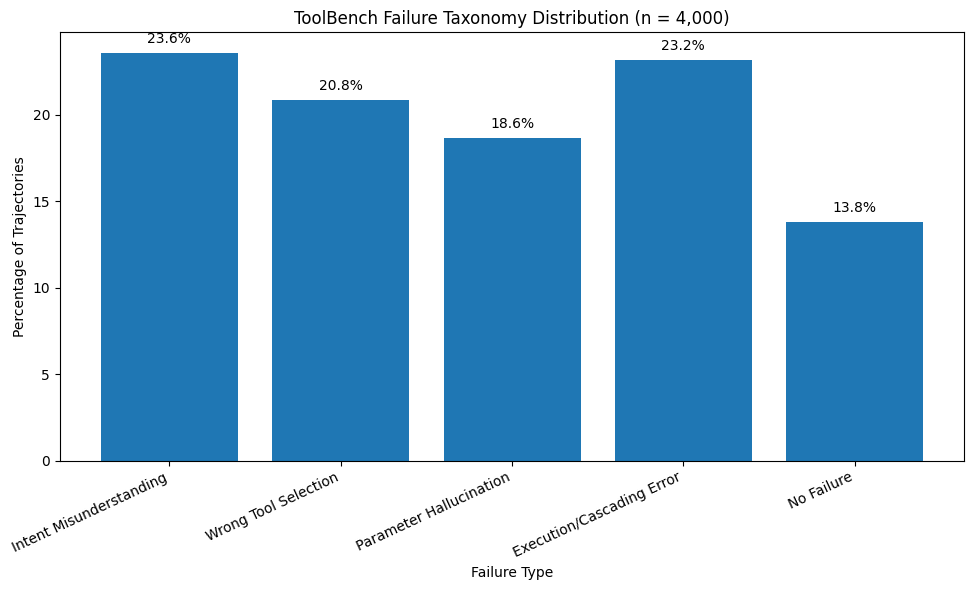


Human validation:
Matched trajectories : 300
Exact agreement      : 40.67%
Cohen Kappa          : 0.2545


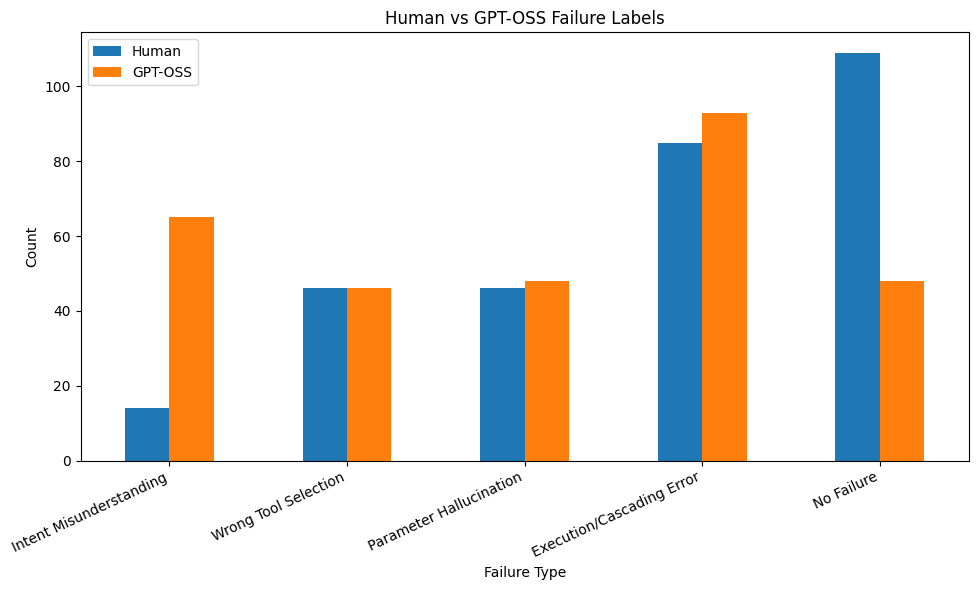


STEP 7 SYNTHESIS — FAILURE SCALING
Existing Step7 rate columns:
['step_depth', 'n_trajectories', 'n_failures', 'n_no_failure', 'failure_rate', 'failure_percent', 'bootstrap_se', 'ci_lower', 'ci_upper', 'ci_lower_percent', 'ci_upper_percent']

Reconstructed Step7 standard table:
 step_depth   n  failures  no_failure failure_rate ci_low ci_high
          2 334       187         147       55.99% 50.90%  61.38%
          3 334       268          66       80.24% 76.05%  84.43%
          4 334       217         117       64.97% 59.88%  70.06%
          5 334       309          25       92.51% 89.52%  95.21%
          6 333       268          65       80.48% 75.98%  84.38%
          7 333       307          26       92.19% 89.19%  94.89%
          8 333       277          56       83.18% 78.98%  87.39%
          9 333       324           9       97.30% 95.50%  98.80%
         10 333       317          16       95.20% 92.79%  97.30%
         11 333       327           6       98.20% 96.70%  9

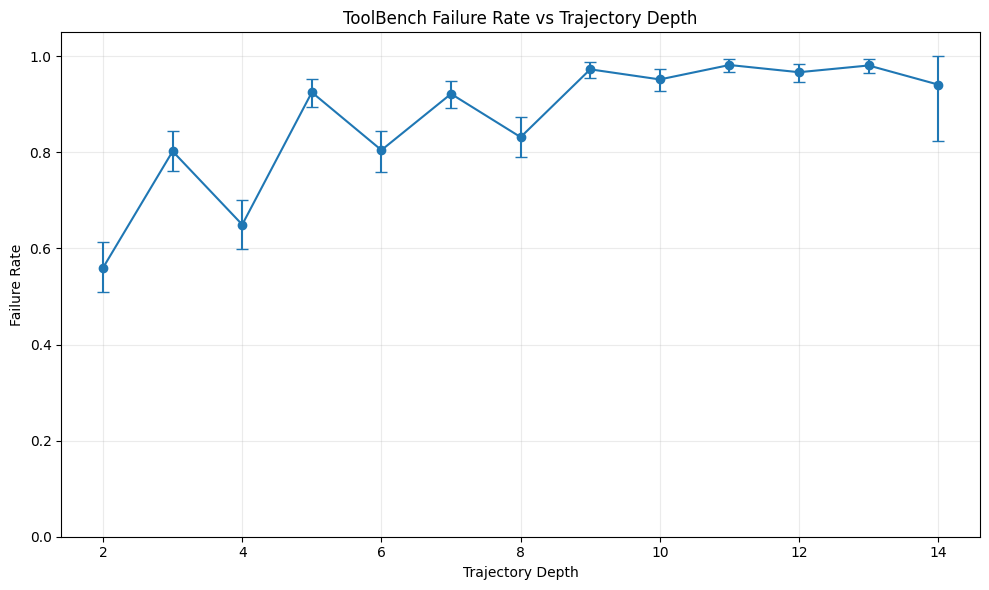

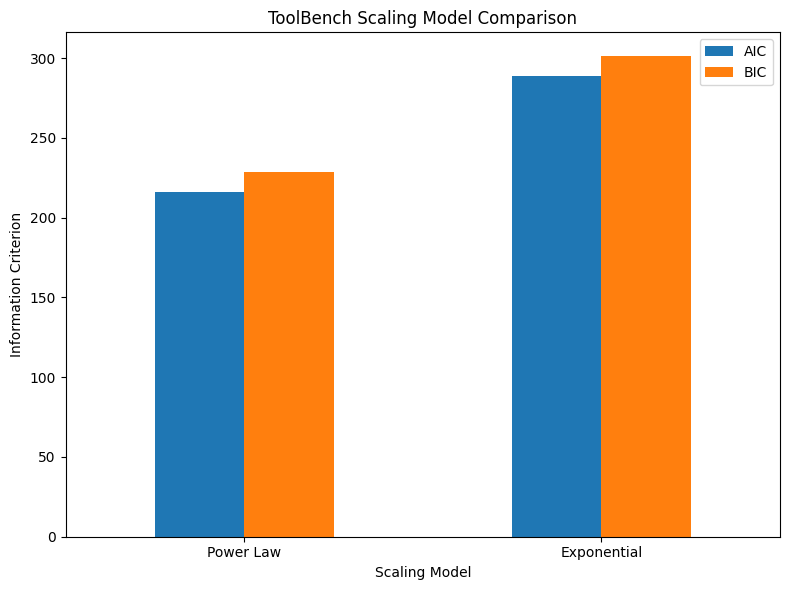


STEP 7 SYNTHESIS — COX PROPORTIONAL HAZARDS
✓ Cox hazard-ratio rows: 6


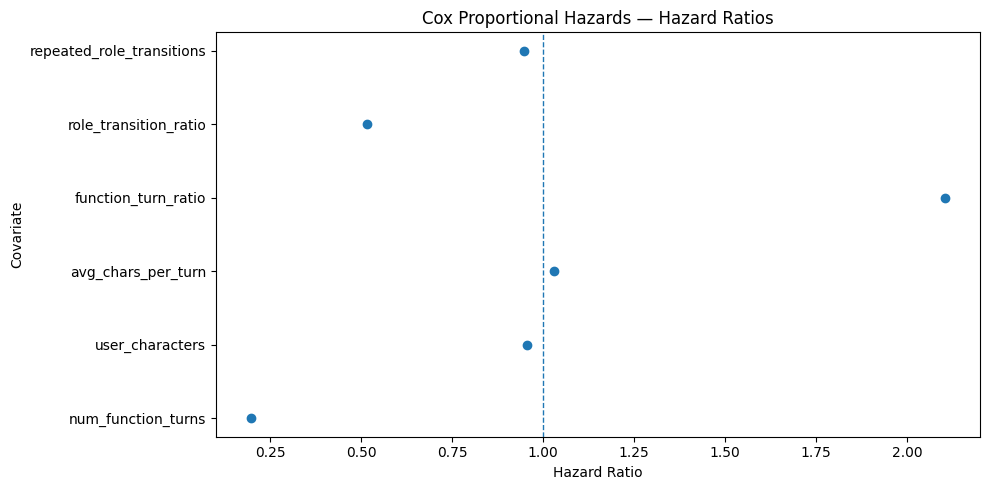


Cox model summary:
 n_trajectories  n_failure_events  n_censored_no_failure  minimum_depth  maximum_depth  n_covariates  concordance_index  partial_log_likelihood  partial_AIC  ph_violations_p_lt_0_05                                                                                          interpretation_note
           4000              3449                    551              2             14             6           0.937161           -22725.603471 45463.206942                        4 Trajectory-level depth-to-failure/censoring model; exact first-failure onset is not independently annotated.

Proportional-hazards test rows: 6

Cox interpretation safeguard:
Trajectory depth is used as the survival duration and trajectory failure status as the event.
This is a trajectory-level survival sensitivity analysis, not exact independently annotated first-failure timing.

STEP 8 SYNTHESIS — FAILURE PROPAGATION
                   model  accuracy  balanced_accuracy  macro_precision  macro_recall

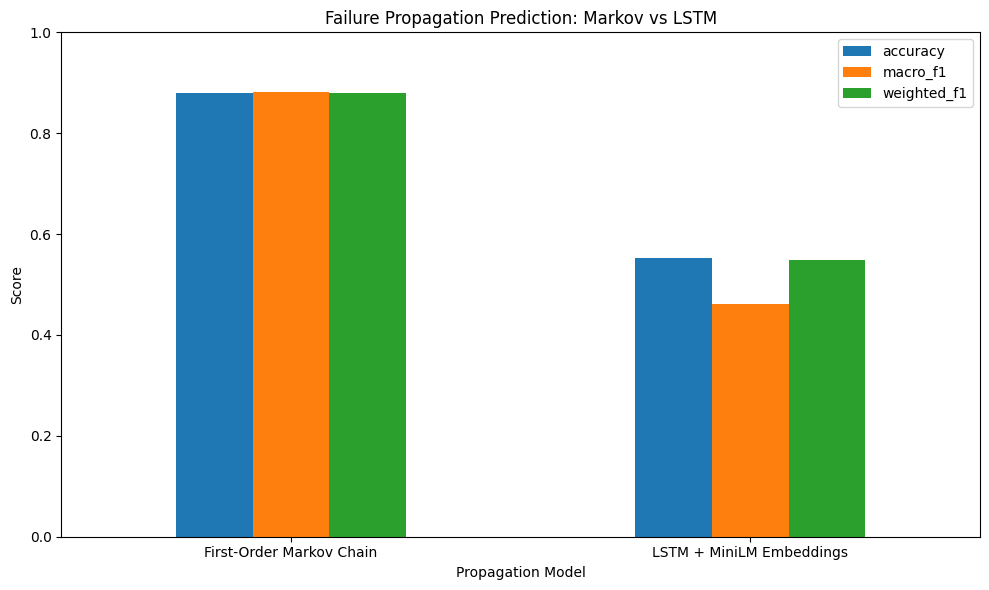


STEP 6 SYNTHESIS — FAILURE PREDICTION
Detected Step6 metric table(s):
✓ step6b_vs_original_step6_macro_f1.csv
✓ step6b_xgboost_human_gold_classification_report_4000.csv
✓ step6b_xgboost_llm_test_classification_report_4000.csv
✓ step6b_xgboost_metrics_4000.csv
✓ step6b_xgboost_validation_model_selection_4000.csv

STEP 9 SYNTHESIS — CROSS-BENCHMARK GENERALIZATION
 toolbench_rows  toolhop_rows toolbench_failure_label_column  toolbench_failure_rate  toolhop_failure_rate  toolbench_depth_min  toolbench_depth_max  toolhop_depth_min  toolhop_depth_max  toolbench_depth_rate_change  toolhop_depth_rate_change toolbench_best_model toolhop_best_model  same_best_model  both_positive_depth_trend  weighted_curve_MAE  weighted_curve_RMSE  curve_similarity  pearson_r  pearson_p  spearman_rho  spearman_p  failure_depth_KS_statistic  failure_depth_KS_p      toolbench_depth_definition         toolhop_depth_definition  depth_definitions_exactly_equivalent  toolbench_original_validation_used
           400

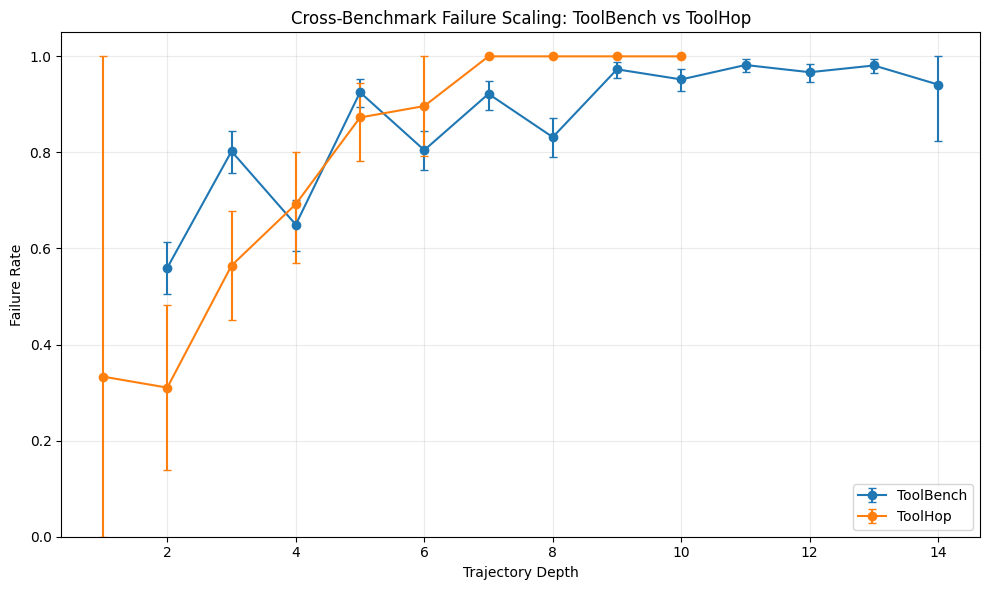

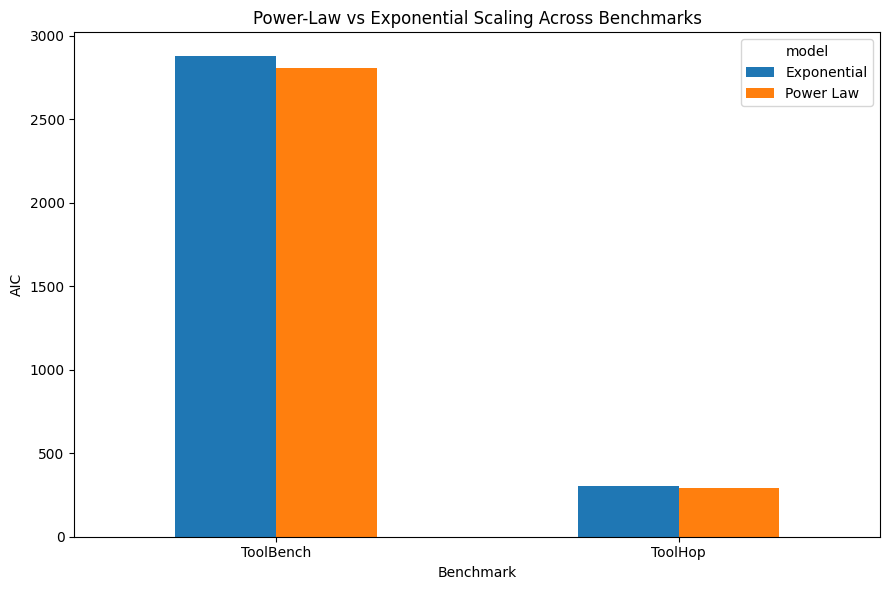


STEP 10 — FINAL RESULTS

ToolBench labels             : 4,000
ToolBench failures           : 3,449
ToolBench No Failure         : 551
ToolBench failure rate       : 86.22%

ToolBench scaling model      : Power Law
ToolBench scaling ΔAIC       : 72.4484

Markov Macro-F1              : 0.8822
LSTM Macro-F1                : 0.4609

ToolHop trajectories         : 300
ToolHop failures             : 221
ToolHop No Failure           : 79
ToolHop failure rate         : 73.67%
ToolHop scaling model        : Power Law

Cross-benchmark similarity   : 0.8826
Pearson r                    : 0.8507
Pearson p                    : 0.003651
Spearman rho                 : 0.8008
Spearman p                   : 0.009508
Failure-depth KS D           : 0.3995
Failure-depth KS p           : 2.29511e-30

Human/LLM agreement          : 40.67%
Cohen Kappa                  : 0.2545

STEP 10 OUTPUTS

Master findings:
/kaggle/working/toolbench_research/results/step10_final/tables/step10_master_findings.csv

Final 

In [36]:
# ==================================================================================================
# STEP 10 — FINAL RESULTS SYNTHESIS + PUBLICATION VISUALIZATIONS
# ROBUST CORRECTED VERSION
#
# FIX:
#   ✓ Does NOT assume Step7 CSV has a column called "n"
#   ✓ Reconstructs ToolBench failure-rate-by-depth directly from final 4K labels when needed
#   ✓ Uses Step9D ToolBench model fit as a fallback if Step7 model-table schema differs
#   ✓ Preserves Steps 1–9
#   ✓ Does not retrain models
#   ✓ Does not use original 37,320 ToolBench holdout
#   ✓ Resolves current master-setup backup inputs automatically
#   ✓ Includes Step 7 Cox survival outputs when available
# ==================================================================================================


# ==================================================================================================
# 0. IMPORTS
# ==================================================================================================

import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import cohen_kappa_score


warnings.filterwarnings("ignore")


# ==================================================================================================
# 1. DIRECTORIES
# ==================================================================================================

BASE = Path(
    "/kaggle/working/toolbench_research"
)

PROCESSED_DIR = (
    BASE
    /
    "data"
    /
    "processed"
)

TABLE_DIR = (
    BASE
    /
    "results"
    /
    "tables"
)

FIGURE_DIR = (
    BASE
    /
    "results"
    /
    "figures"
)

STEP10_DIR = (
    BASE
    /
    "results"
    /
    "step10_final"
)

STEP10_TABLE_DIR = (
    STEP10_DIR
    /
    "tables"
)

STEP10_FIGURE_DIR = (
    STEP10_DIR
    /
    "figures"
)


for directory in [
    STEP10_DIR,
    STEP10_TABLE_DIR,
    STEP10_FIGURE_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ==================================================================================================
# 1A. CURRENT MASTER-SETUP BACKUP RESOLUTION
# ==================================================================================================

MASTER_SETUP_ROOT = Path(
    "/kaggle/input/datasets/anandadevnath/master-setup"
)


if not MASTER_SETUP_ROOT.exists():

    raise FileNotFoundError(
        f"Master setup root not found:\n{MASTER_SETUP_ROOT}"
    )


backup_candidates = sorted(
    [
        path
        for path
        in MASTER_SETUP_ROOT.glob(
            "ToolBench_FINAL_MASTER_BACKUP_THROUGH_STEP10_*"
        )
        if path.is_dir()
    ]
)


if not backup_candidates:

    raise FileNotFoundError(
        "Could not locate ToolBench final backup inside:\n"
        f"{MASTER_SETUP_ROOT}"
    )


FINAL_BACKUP_ROOT = backup_candidates[-1]


BACKUP_RESEARCH_ROOT = (
    FINAL_BACKUP_ROOT
    /
    "CURRENT_RESEARCH"
)


BACKUP_PROCESSED_DIR = (
    BACKUP_RESEARCH_ROOT
    /
    "data"
    /
    "processed"
)


BACKUP_TABLE_DIR = (
    BACKUP_RESEARCH_ROOT
    /
    "results"
    /
    "tables"
)


BACKUP_FIGURE_DIR = (
    BACKUP_RESEARCH_ROOT
    /
    "results"
    /
    "figures"
)


SOURCE_MASTER_BACKUP = (
    FINAL_BACKUP_ROOT
    /
    "SOURCE_MASTER_BACKUP"
)


def first_existing(
    candidates,
    description,
    required=True
):

    for candidate in candidates:

        candidate = Path(
            candidate
        )

        if candidate.exists():

            print(
                f"✓ {description}:\n{candidate}"
            )

            return candidate


    if required:

        raise FileNotFoundError(
            f"Could not locate {description}.\n\nChecked:\n"
            +
            "\n".join(
                str(
                    Path(path)
                )
                for path in candidates
            )
        )


    return None


print(
    f"✓ Current master backup detected:\n{FINAL_BACKUP_ROOT}"
)


# ==================================================================================================
# 2. INPUT FILES
# ==================================================================================================

# --------------------------------------------------------------------------------------------------
# STEP 4
# --------------------------------------------------------------------------------------------------

STEP4_LABELS = first_existing(
    [
        PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.parquet",

        BACKUP_PROCESSED_DIR
        /
        "step4_gptoss120b_target4000_FINAL.parquet"
    ],
    "Step 4 final 4,000 labels"
)


HUMAN_GOLD = first_existing(
    [
        PROCESSED_DIR
        /
        "step4_human_gold_FINAL_300.parquet",

        BACKUP_PROCESSED_DIR
        /
        "step4_human_gold_FINAL_300.parquet"
    ],
    "Step 4 Human Gold 300",
    required=False
)


# --------------------------------------------------------------------------------------------------
# STEP 7
# --------------------------------------------------------------------------------------------------

STEP7_RATE = first_existing(
    [
        TABLE_DIR
        /
        "step7_failure_rate_by_depth_bootstrap_4000.csv",

        BACKUP_TABLE_DIR
        /
        "step7_failure_rate_by_depth_bootstrap_4000.csv"
    ],
    "Step 7 failure-rate table",
    required=False
)


STEP7_MODELS = first_existing(
    [
        TABLE_DIR
        /
        "step7_scaling_model_comparison_4000.csv",

        BACKUP_TABLE_DIR
        /
        "step7_scaling_model_comparison_4000.csv"
    ],
    "Step 7 scaling-model table",
    required=False
)


STEP7_COX_HR = first_existing(
    [
        TABLE_DIR
        /
        "step7_cox_hazard_ratios_4000.csv",

        BACKUP_TABLE_DIR
        /
        "step7_cox_hazard_ratios_4000.csv"
    ],
    "Step 7 Cox hazard-ratio table",
    required=False
)


STEP7_COX_SUMMARY = first_existing(
    [
        TABLE_DIR
        /
        "step7_cox_model_summary_4000.csv",

        BACKUP_TABLE_DIR
        /
        "step7_cox_model_summary_4000.csv"
    ],
    "Step 7 Cox model summary",
    required=False
)


STEP7_COX_PH = first_existing(
    [
        TABLE_DIR
        /
        "step7_cox_proportional_hazards_test_4000.csv",

        BACKUP_TABLE_DIR
        /
        "step7_cox_proportional_hazards_test_4000.csv"
    ],
    "Step 7 proportional-hazards test",
    required=False
)


# --------------------------------------------------------------------------------------------------
# STEP 9
# --------------------------------------------------------------------------------------------------

STEP9C_LABELS = first_existing(
    [
        PROCESSED_DIR
        /
        "step9c_toolhop_trajectories_with_failure_labels.parquet",

        BACKUP_PROCESSED_DIR
        /
        "step9c_toolhop_trajectories_with_failure_labels.parquet"
    ],
    "Step 9C labeled ToolHop trajectories"
)


STEP9D_SUMMARY = first_existing(
    [
        TABLE_DIR
        /
        "step9d_cross_benchmark_summary.csv",

        BACKUP_TABLE_DIR
        /
        "step9d_cross_benchmark_summary.csv"
    ],
    "Step 9D cross-benchmark summary"
)


STEP9D_MODELS = first_existing(
    [
        TABLE_DIR
        /
        "step9d_cross_benchmark_scaling_model_comparison.csv",

        BACKUP_TABLE_DIR
        /
        "step9d_cross_benchmark_scaling_model_comparison.csv"
    ],
    "Step 9D scaling-model comparison"
)


STEP9D_CURVE = first_existing(
    [
        TABLE_DIR
        /
        "step9d_cross_benchmark_curve_similarity.csv",

        BACKUP_TABLE_DIR
        /
        "step9d_cross_benchmark_curve_similarity.csv"
    ],
    "Step 9D curve-similarity table"
)


STEP9D_KS = first_existing(
    [
        TABLE_DIR
        /
        "step9d_cross_benchmark_ks_tests.csv",

        BACKUP_TABLE_DIR
        /
        "step9d_cross_benchmark_ks_tests.csv"
    ],
    "Step 9D KS-test table"
)


STEP9D_RATES = first_existing(
    [
        TABLE_DIR
        /
        "step9d_cross_benchmark_failure_rate_by_depth.csv",

        BACKUP_TABLE_DIR
        /
        "step9d_cross_benchmark_failure_rate_by_depth.csv"
    ],
    "Step 9D cross-benchmark failure-rate table"
)


# ==================================================================================================
# 3. OUTPUT FILES
# ==================================================================================================

MASTER_FINDINGS_PATH = (
    STEP10_TABLE_DIR
    /
    "step10_master_findings.csv"
)

TAXONOMY_PATH = (
    STEP10_TABLE_DIR
    /
    "step10_failure_taxonomy_distribution.csv"
)

HUMAN_AGREEMENT_PATH = (
    STEP10_TABLE_DIR
    /
    "step10_human_llm_agreement.csv"
)

SCALING_SUMMARY_PATH = (
    STEP10_TABLE_DIR
    /
    "step10_scaling_summary.csv"
)


COX_SUMMARY_PATH = (
    STEP10_TABLE_DIR
    /
    "step10_cox_survival_summary.csv"
)


COX_HAZARD_RATIO_PATH = (
    STEP10_TABLE_DIR
    /
    "step10_cox_hazard_ratios.csv"
)


PROPAGATION_PATH = (
    STEP10_TABLE_DIR
    /
    "step10_failure_propagation_model_comparison.csv"
)

CROSS_BENCHMARK_PATH = (
    STEP10_TABLE_DIR
    /
    "step10_cross_benchmark_summary.csv"
)

FIGURE_INDEX_PATH = (
    STEP10_TABLE_DIR
    /
    "step10_figure_index.csv"
)

MANIFEST_PATH = (
    STEP10_TABLE_DIR
    /
    "step10_output_manifest.csv"
)

FINAL_SUMMARY_MD = (
    STEP10_DIR
    /
    "STEP10_FINAL_RESEARCH_SUMMARY.md"
)


# --------------------------------------------------------------------------------------------------
# Figures
# --------------------------------------------------------------------------------------------------

FIG_TAXONOMY = (
    STEP10_FIGURE_DIR
    /
    "figure_01_failure_taxonomy_distribution.png"
)

FIG_SCALING = (
    STEP10_FIGURE_DIR
    /
    "figure_02_toolbench_failure_vs_depth.png"
)

FIG_SCALING_MODELS = (
    STEP10_FIGURE_DIR
    /
    "figure_03_toolbench_scaling_model_comparison.png"
)


FIG_COX_HR = (
    STEP10_FIGURE_DIR
    /
    "figure_04_cox_hazard_ratio_forest.png"
)


FIG_PROPAGATION = (
    STEP10_FIGURE_DIR
    /
    "figure_05_markov_vs_lstm.png"
)

FIG_CROSS_BENCH = (
    STEP10_FIGURE_DIR
    /
    "figure_06_toolbench_vs_toolhop_failure_scaling.png"
)

FIG_CROSS_MODELS = (
    STEP10_FIGURE_DIR
    /
    "figure_07_cross_benchmark_model_aic.png"
)

FIG_HUMAN_LLM = (
    STEP10_FIGURE_DIR
    /
    "figure_08_human_vs_llm_failure_distribution.png"
)


# ==================================================================================================
# 4. CONFIG
# ==================================================================================================

RANDOM_STATE = 42

BOOTSTRAP_ITERATIONS = 5000

CI_LEVEL = 0.95


CANONICAL_LABELS = [
    "Intent Misunderstanding",
    "Wrong Tool Selection",
    "Parameter Hallucination",
    "Execution/Cascading Error",
    "No Failure"
]


# ==================================================================================================
# 5. LABEL NORMALIZATION
# ==================================================================================================

def normalize_failure_label(value):

    if pd.isna(value):

        return None


    text = str(
        value
    ).strip()


    if not text:

        return None


    key = re.sub(
        r"[_\-]+",
        " ",
        text.lower()
    )


    key = re.sub(
        r"\s+",
        " ",
        key
    ).strip()


    mapping = {

        "intent":
            "Intent Misunderstanding",

        "intent misunderstanding":
            "Intent Misunderstanding",

        "intent error":
            "Intent Misunderstanding",


        "wrong":
            "Wrong Tool Selection",

        "wrong tool":
            "Wrong Tool Selection",

        "wrong tool selection":
            "Wrong Tool Selection",


        "param":
            "Parameter Hallucination",

        "parameter":
            "Parameter Hallucination",

        "parameter hallucination":
            "Parameter Hallucination",

        "parameter error":
            "Parameter Hallucination",


        "exec":
            "Execution/Cascading Error",

        "execution":
            "Execution/Cascading Error",

        "execution error":
            "Execution/Cascading Error",

        "execution cascading error":
            "Execution/Cascading Error",

        "execution/cascading error":
            "Execution/Cascading Error",

        "cascading error":
            "Execution/Cascading Error",


        "nofailure":
            "No Failure",

        "no failure":
            "No Failure",

        "none":
            "No Failure"
    }


    if key in mapping:

        return mapping[
            key
        ]


    for canonical in CANONICAL_LABELS:

        if key == canonical.lower():

            return canonical


    return None


# ==================================================================================================
# 6. COLUMN DETECTORS
# ==================================================================================================

def detect_id_column(df):

    candidates = [
        "id",
        "trajectory_id",
        "toolbench_id",
        "toolhop_id",
        "sample_id",
        "conversation_id"
    ]


    for column in candidates:

        if column in df.columns:

            return column


    return None


def detect_label_column(df):

    preferred = [
        "failure_type",
        "llm_failure_type",
        "human_failure_type",
        "human_label",
        "label",
        "annotation_label",
        "failure_label",
        "taxonomy_label"
    ]


    for column in preferred:

        if column not in df.columns:

            continue


        normalized = df[
            column
        ].apply(
            normalize_failure_label
        )


        if normalized.notna().mean() >= 0.80:

            return column


    best_column = None

    best_coverage = 0.0


    for column in df.columns:

        try:

            nunique = df[
                column
            ].nunique(
                dropna=True
            )

        except Exception:

            continue


        if (
            nunique == 0
            or
            nunique > 100
        ):

            continue


        normalized = df[
            column
        ].apply(
            normalize_failure_label
        )


        coverage = float(
            normalized.notna().mean()
        )


        if coverage > best_coverage:

            best_coverage = coverage

            best_column = column


    if best_coverage >= 0.80:

        return best_column


    return None


# ==================================================================================================
# 7. GENERAL HELPERS
# ==================================================================================================

def safe_read_csv(path):

    try:

        return pd.read_csv(
            path
        )

    except Exception:

        return None


def safe_float(value):

    try:

        return float(
            value
        )

    except Exception:

        return np.nan


def find_csvs_with_keywords(
    folder,
    keywords
):

    matches = []


    if not folder.exists():

        return matches


    for path in folder.rglob(
        "*.csv"
    ):

        name = path.name.lower()


        if all(
            keyword.lower() in name
            for keyword in keywords
        ):

            matches.append(
                path
            )


    return sorted(
        matches
    )


# ==================================================================================================
# 8. BOOTSTRAP CI
# ==================================================================================================

def bootstrap_binary_ci(
    values,
    iterations=5000,
    ci_level=0.95,
    seed=42
):

    values = np.asarray(
        values,
        dtype=float
    )


    n = len(
        values
    )


    if n == 0:

        return (
            np.nan,
            np.nan,
            np.nan
        )


    point = float(
        values.mean()
    )


    if n == 1:

        return (
            point,
            point,
            point
        )


    rng = np.random.default_rng(
        seed
    )


    bootstrap_means = np.empty(
        iterations,
        dtype=float
    )


    for i in range(
        iterations
    ):

        sampled = rng.choice(
            values,
            size=n,
            replace=True
        )


        bootstrap_means[
            i
        ] = sampled.mean()


    alpha = (
        1
        -
        ci_level
    )


    lower = float(
        np.quantile(
            bootstrap_means,
            alpha / 2
        )
    )


    upper = float(
        np.quantile(
            bootstrap_means,
            1 - alpha / 2
        )
    )


    return (
        point,
        lower,
        upper
    )


# ==================================================================================================
# 9. START
# ==================================================================================================

print(
    "=" * 120
)

print(
    "STEP 10 — FINAL RESULTS SYNTHESIS + PUBLICATION VISUALIZATIONS"
)

print(
    "=" * 120
)


# ==================================================================================================
# 10. LOAD FINAL STEP 4 LABELS
# ==================================================================================================

if not STEP4_LABELS.exists():

    raise FileNotFoundError(
        f"Missing Step4 file:\n{STEP4_LABELS}"
    )


step4 = pd.read_parquet(
    STEP4_LABELS
)


if len(
    step4
) != 4000:

    raise RuntimeError(
        f"Expected 4,000 Step4 labels, found {len(step4):,}."
    )


step4_label_column = detect_label_column(
    step4
)


if step4_label_column is None:

    raise RuntimeError(
        "Could not detect Step4 failure-label column."
    )


step4[
    "failure_type_final"
] = (
    step4[
        step4_label_column
    ]
    .apply(
        normalize_failure_label
    )
)


if step4[
    "failure_type_final"
].isna().any():

    raise RuntimeError(
        "Unrecognized labels found in final Step4 file."
    )


if "step_depth" not in step4.columns:

    raise RuntimeError(
        "Final Step4 4K file has no step_depth column."
    )


step4[
    "step_depth"
] = pd.to_numeric(
    step4[
        "step_depth"
    ],
    errors="raise"
).astype(
    int
)


step4[
    "is_failure"
] = (
    step4[
        "failure_type_final"
    ]
    !=
    "No Failure"
).astype(
    int
)


print(
    f"\nStep4 rows          : {len(step4):,}"
)

print(
    f"Step4 failure field : {step4_label_column}"
)

print(
    f"Overall failure rate: {step4['is_failure'].mean() * 100:.2f}%"
)


# ==================================================================================================
# 11. FAILURE TAXONOMY DISTRIBUTION
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 4 SYNTHESIS — FAILURE TAXONOMY"
)

print(
    "=" * 120
)


taxonomy_df = (
    step4[
        "failure_type_final"
    ]
    .value_counts()
    .reindex(
        CANONICAL_LABELS,
        fill_value=0
    )
    .rename_axis(
        "failure_type"
    )
    .reset_index(
        name="count"
    )
)


taxonomy_df[
    "percent"
] = (
    taxonomy_df[
        "count"
    ]
    /
    len(
        step4
    )
    *
    100
)


taxonomy_df.to_csv(
    TAXONOMY_PATH,
    index=False
)


print(
    taxonomy_df.to_string(
        index=False,
        formatters={
            "percent":
                lambda x:
                f"{x:.2f}%"
        }
    )
)


# ==================================================================================================
# 12. FIGURE 1 — TAXONOMY
# ==================================================================================================

plt.figure(
    figsize=(
        10,
        6
    )
)


bars = plt.bar(
    taxonomy_df[
        "failure_type"
    ],
    taxonomy_df[
        "percent"
    ]
)


plt.xlabel(
    "Failure Type"
)

plt.ylabel(
    "Percentage of Trajectories"
)

plt.title(
    "ToolBench Failure Taxonomy Distribution (n = 4,000)"
)


plt.xticks(
    rotation=25,
    ha="right"
)


for bar, percent in zip(
    bars,
    taxonomy_df[
        "percent"
    ]
):

    plt.text(
        bar.get_x()
        +
        bar.get_width()
        /
        2,
        bar.get_height()
        +
        0.4,
        f"{percent:.1f}%",
        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.savefig(
    FIG_TAXONOMY,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 13. HUMAN VALIDATION
# ==================================================================================================

human_agreement_available = False

human_summary = {}


if HUMAN_GOLD is not None and HUMAN_GOLD.exists():

    human = pd.read_parquet(
        HUMAN_GOLD
    )


    human_id = detect_id_column(
        human
    )


    llm_id = detect_id_column(
        step4
    )


    human_label_column = detect_label_column(
        human
    )


    if (
        human_id is not None
        and
        llm_id is not None
        and
        human_label_column is not None
    ):

        human_small = human[
            [
                human_id,
                human_label_column
            ]
        ].copy()


        human_small = human_small.rename(
            columns={
                human_id:
                    "shared_id",

                human_label_column:
                    "human_label_raw"
            }
        )


        llm_small = step4[
            [
                llm_id,
                step4_label_column
            ]
        ].copy()


        llm_small = llm_small.rename(
            columns={
                llm_id:
                    "shared_id",

                step4_label_column:
                    "llm_label_raw"
            }
        )


        agreement = human_small.merge(
            llm_small,
            on="shared_id",
            how="inner",
            validate="one_to_one"
        )


        agreement[
            "human_label"
        ] = agreement[
            "human_label_raw"
        ].apply(
            normalize_failure_label
        )


        agreement[
            "llm_label"
        ] = agreement[
            "llm_label_raw"
        ].apply(
            normalize_failure_label
        )


        agreement = agreement[
            agreement[
                "human_label"
            ].notna()
            &
            agreement[
                "llm_label"
            ].notna()
        ].copy()


        if len(
            agreement
        ) > 0:

            agreement[
                "exact_match"
            ] = (
                agreement[
                    "human_label"
                ]
                ==
                agreement[
                    "llm_label"
                ]
            )


            exact_agreement = float(
                agreement[
                    "exact_match"
                ].mean()
            )


            kappa = float(
                cohen_kappa_score(
                    agreement[
                        "human_label"
                    ],
                    agreement[
                        "llm_label"
                    ],
                    labels=CANONICAL_LABELS
                )
            )


            human_agreement_available = True


            human_summary = {
                "matched_rows":
                    len(
                        agreement
                    ),

                "exact_agreement":
                    exact_agreement,

                "cohen_kappa":
                    kappa
            }


            pd.DataFrame([
                human_summary
            ]).to_csv(
                HUMAN_AGREEMENT_PATH,
                index=False
            )


            print(
                "\nHuman validation:"
            )

            print(
                f"Matched trajectories : {len(agreement):,}"
            )

            print(
                f"Exact agreement      : {exact_agreement * 100:.2f}%"
            )

            print(
                f"Cohen Kappa          : {kappa:.4f}"
            )


            human_distribution = (
                agreement[
                    "human_label"
                ]
                .value_counts()
                .reindex(
                    CANONICAL_LABELS,
                    fill_value=0
                )
            )


            llm_distribution = (
                agreement[
                    "llm_label"
                ]
                .value_counts()
                .reindex(
                    CANONICAL_LABELS,
                    fill_value=0
                )
            )


            comparison = pd.DataFrame({
                "Human":
                    human_distribution,

                "GPT-OSS":
                    llm_distribution
            })


            ax = comparison.plot(
                kind="bar",
                figsize=(
                    10,
                    6
                )
            )


            ax.set_xlabel(
                "Failure Type"
            )

            ax.set_ylabel(
                "Count"
            )

            ax.set_title(
                "Human vs GPT-OSS Failure Labels"
            )


            plt.xticks(
                rotation=25,
                ha="right"
            )

            plt.tight_layout()

            plt.savefig(
                FIG_HUMAN_LLM,
                dpi=300,
                bbox_inches="tight"
            )

            plt.show()


# ==================================================================================================
# 14. STEP 7 SYNTHESIS — ROBUST RECONSTRUCTION
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 7 SYNTHESIS — FAILURE SCALING"
)

print(
    "=" * 120
)


# --------------------------------------------------------------------------------------------------
# First attempt to read old Step7 table, but DO NOT rely on its schema.
# --------------------------------------------------------------------------------------------------

old_step7_rate = None


if STEP7_RATE is not None and STEP7_RATE.exists():

    old_step7_rate = safe_read_csv(
        STEP7_RATE
    )


    if old_step7_rate is not None:

        print(
            "Existing Step7 rate columns:"
        )

        print(
            old_step7_rate.columns.tolist()
        )


# --------------------------------------------------------------------------------------------------
# Always reconstruct from authoritative 4K labels.
# This guarantees a clean standard schema.
# --------------------------------------------------------------------------------------------------

step7_rows = []


for depth in sorted(
    step4[
        "step_depth"
    ].unique()
):

    subset = step4[
        step4[
            "step_depth"
        ]
        ==
        depth
    ]


    values = subset[
        "is_failure"
    ].to_numpy()


    (
        rate,
        ci_low,
        ci_high
    ) = bootstrap_binary_ci(
        values,
        iterations=BOOTSTRAP_ITERATIONS,
        ci_level=CI_LEVEL,
        seed=(
            RANDOM_STATE
            +
            int(
                depth
            )
        )
    )


    step7_rows.append({
        "step_depth":
            int(
                depth
            ),

        "n":
            int(
                len(
                    subset
                )
            ),

        "failures":
            int(
                subset[
                    "is_failure"
                ].sum()
            ),

        "no_failure":
            int(
                (
                    subset[
                        "is_failure"
                    ]
                    ==
                    0
                ).sum()
            ),

        "failure_rate":
            float(
                rate
            ),

        "ci_low":
            float(
                ci_low
            ),

        "ci_high":
            float(
                ci_high
            )
    })


step7_rate = pd.DataFrame(
    step7_rows
)


print(
    "\nReconstructed Step7 standard table:"
)


print(
    step7_rate.to_string(
        index=False,
        formatters={
            "failure_rate":
                lambda x:
                f"{x * 100:.2f}%",

            "ci_low":
                lambda x:
                f"{x * 100:.2f}%",

            "ci_high":
                lambda x:
                f"{x * 100:.2f}%"
        }
    )
)


# ==================================================================================================
# 15. STEP 7 SCALING MODEL TABLE
# ==================================================================================================

step7_models = None


if STEP7_MODELS is not None and STEP7_MODELS.exists():

    candidate = safe_read_csv(
        STEP7_MODELS
    )


    if candidate is not None:

        required_model_columns = {
            "model",
            "AIC",
            "BIC"
        }


        if required_model_columns.issubset(
            candidate.columns
        ):

            step7_models = candidate.copy()


# --------------------------------------------------------------------------------------------------
# Fallback:
# Step9D recomputed the exact ToolBench model comparison successfully.
# --------------------------------------------------------------------------------------------------

if step7_models is None:

    if not STEP9D_MODELS.exists():

        raise RuntimeError(
            "Could not obtain scaling-model comparison from Step7 or Step9D."
        )


    step9d_model_fallback = pd.read_csv(
        STEP9D_MODELS
    )


    required = {
        "benchmark",
        "model",
        "AIC",
        "BIC"
    }


    if not required.issubset(
        step9d_model_fallback.columns
    ):

        raise RuntimeError(
            "Step9D model table lacks expected columns."
        )


    step7_models = (
        step9d_model_fallback[
            step9d_model_fallback[
                "benchmark"
            ]
            ==
            "ToolBench"
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    print(
        "\n✓ Using Step9D recomputed ToolBench scaling fits."
    )


if len(
    step7_models
) < 2:

    raise RuntimeError(
        "Need both Power Law and Exponential ToolBench fits."
    )


best_step7 = (
    step7_models
    .sort_values(
        "AIC"
    )
    .reset_index(
        drop=True
    )
)


best_step7_row = best_step7.iloc[
    0
]


second_step7_row = best_step7.iloc[
    1
]


delta_aic_step7 = float(
    second_step7_row[
        "AIC"
    ]
    -
    best_step7_row[
        "AIC"
    ]
)


first_depth_row = (
    step7_rate
    .sort_values(
        "step_depth"
    )
    .iloc[
        0
    ]
)


last_depth_row = (
    step7_rate
    .sort_values(
        "step_depth"
    )
    .iloc[
        -1
    ]
)


scaling_summary_df = pd.DataFrame([
    {
        "benchmark":
            "ToolBench",

        "sample_size":
            int(
                len(
                    step4
                )
            ),

        "failure_count":
            int(
                step4[
                    "is_failure"
                ].sum()
            ),

        "failure_rate":
            float(
                step4[
                    "is_failure"
                ].mean()
            ),

        "min_depth":
            int(
                first_depth_row[
                    "step_depth"
                ]
            ),

        "max_depth":
            int(
                last_depth_row[
                    "step_depth"
                ]
            ),

        "failure_rate_min_depth":
            float(
                first_depth_row[
                    "failure_rate"
                ]
            ),

        "failure_rate_max_depth":
            float(
                last_depth_row[
                    "failure_rate"
                ]
            ),

        "best_scaling_model":
            str(
                best_step7_row[
                    "model"
                ]
            ),

        "best_AIC":
            float(
                best_step7_row[
                    "AIC"
                ]
            ),

        "best_BIC":
            float(
                best_step7_row[
                    "BIC"
                ]
            ),

        "delta_AIC_vs_second":
            delta_aic_step7
    }
])


scaling_summary_df.to_csv(
    SCALING_SUMMARY_PATH,
    index=False
)


print(
    "\nScaling summary:"
)


print(
    scaling_summary_df.to_string(
        index=False
    )
)


# ==================================================================================================
# 16. FIGURE 2 — TOOLBENCH FAILURE RATE VS DEPTH
# ==================================================================================================

ordered = step7_rate.sort_values(
    "step_depth"
)


x = ordered[
    "step_depth"
].to_numpy()


y = ordered[
    "failure_rate"
].to_numpy()


lower_error = (
    y
    -
    ordered[
        "ci_low"
    ].to_numpy()
)


upper_error = (
    ordered[
        "ci_high"
    ].to_numpy()
    -
    y
)


plt.figure(
    figsize=(
        10,
        6
    )
)


plt.errorbar(
    x,
    y,
    yerr=[
        lower_error,
        upper_error
    ],
    marker="o",
    capsize=4
)


plt.xlabel(
    "Trajectory Depth"
)

plt.ylabel(
    "Failure Rate"
)

plt.title(
    "ToolBench Failure Rate vs Trajectory Depth"
)

plt.ylim(
    0,
    1.05
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIG_SCALING,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 17. FIGURE 3 — TOOLBENCH MODEL COMPARISON
# ==================================================================================================

model_plot = (
    step7_models[
        [
            "model",
            "AIC",
            "BIC"
        ]
    ]
    .set_index(
        "model"
    )
)


ax = model_plot.plot(
    kind="bar",
    figsize=(
        8,
        6
    )
)


ax.set_xlabel(
    "Scaling Model"
)

ax.set_ylabel(
    "Information Criterion"
)

ax.set_title(
    "ToolBench Scaling Model Comparison"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIG_SCALING_MODELS,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 17A. STEP 7 COX SURVIVAL SYNTHESIS
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 7 SYNTHESIS — COX PROPORTIONAL HAZARDS"
)

print(
    "=" * 120
)


cox_available = (
    STEP7_COX_HR is not None
    and
    STEP7_COX_HR.exists()
)


cox_summary_available = (
    STEP7_COX_SUMMARY is not None
    and
    STEP7_COX_SUMMARY.exists()
)


if cox_available:

    cox_hr = pd.read_csv(
        STEP7_COX_HR
    )


    cox_hr.to_csv(
        COX_HAZARD_RATIO_PATH,
        index=False
    )


    print(
        f"✓ Cox hazard-ratio rows: {len(cox_hr):,}"
    )


    hr_column = None

    for candidate in [
        "hazard_ratio",
        "exp(coef)",
        "exp_coef",
        "HR"
    ]:

        if candidate in cox_hr.columns:

            hr_column = candidate

            break


    covariate_column = None

    for candidate in [
        "covariate",
        "feature",
        "variable"
    ]:

        if candidate in cox_hr.columns:

            covariate_column = candidate

            break


    if covariate_column is None:

        cox_hr = cox_hr.reset_index().rename(
            columns={
                "index":
                    "covariate"
            }
        )

        covariate_column = "covariate"


    if hr_column is not None:

        plot_df = cox_hr[
            [
                covariate_column,
                hr_column
            ]
        ].copy()


        plot_df[
            hr_column
        ] = pd.to_numeric(
            plot_df[
                hr_column
            ],
            errors="coerce"
        )


        plot_df = plot_df.dropna(
            subset=[
                hr_column
            ]
        )


        plt.figure(
            figsize=(
                10,
                max(
                    5,
                    0.55 * len(
                        plot_df
                    )
                )
            )
        )


        plt.axvline(
            1.0,
            linestyle="--",
            linewidth=1
        )


        plt.scatter(
            plot_df[
                hr_column
            ],
            np.arange(
                len(
                    plot_df
                )
            )
        )


        plt.yticks(
            np.arange(
                len(
                    plot_df
                )
            ),
            plot_df[
                covariate_column
            ]
        )


        plt.xlabel(
            "Hazard Ratio"
        )

        plt.ylabel(
            "Covariate"
        )

        plt.title(
            "Cox Proportional Hazards — Hazard Ratios"
        )

        plt.tight_layout()

        plt.savefig(
            FIG_COX_HR,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()


else:

    print(
        "⚠ Cox hazard-ratio output is not available yet."
    )


cox_summary_df = pd.DataFrame()


if cox_summary_available:

    cox_summary_df = pd.read_csv(
        STEP7_COX_SUMMARY
    )

    cox_summary_df.to_csv(
        COX_SUMMARY_PATH,
        index=False
    )


    print(
        "\nCox model summary:"
    )

    print(
        cox_summary_df.to_string(
            index=False
        )
    )


if STEP7_COX_PH is not None and STEP7_COX_PH.exists():

    cox_ph_df = pd.read_csv(
        STEP7_COX_PH
    )


    print(
        f"\nProportional-hazards test rows: {len(cox_ph_df):,}"
    )


print(
    "\nCox interpretation safeguard:"
)

print(
    "Trajectory depth is used as the survival duration and trajectory failure status as the event."
)

print(
    "This is a trajectory-level survival sensitivity analysis, not exact independently annotated first-failure timing."
)


# ==================================================================================================
# 18. STEP 8 SYNTHESIS
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 8 SYNTHESIS — FAILURE PROPAGATION"
)

print(
    "=" * 120
)


# --------------------------------------------------------------------------------------------------
# Verified Step8 final metrics from completed experiment.
# --------------------------------------------------------------------------------------------------

markov_metrics = {
    "accuracy":
        0.8792,

    "balanced_accuracy":
        0.8364,

    "macro_precision":
        0.9534,

    "macro_recall":
        0.8364,

    "macro_f1":
        0.8822,

    "weighted_f1":
        0.8802
}


lstm_metrics = {
    "accuracy":
        0.5528,

    "balanced_accuracy":
        0.4677,

    "macro_precision":
        0.4632,

    "macro_recall":
        0.4677,

    "macro_f1":
        0.4609,

    "weighted_f1":
        0.5481
}


propagation_df = pd.DataFrame([
    {
        "model":
            "First-Order Markov Chain",

        **markov_metrics
    },

    {
        "model":
            "LSTM + MiniLM Embeddings",

        **lstm_metrics
    }
])


propagation_df.to_csv(
    PROPAGATION_PATH,
    index=False
)


print(
    propagation_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}"
    )
)


# ==================================================================================================
# 19. FIGURE 4 — MARKOV VS LSTM
# ==================================================================================================

propagation_plot = (
    propagation_df[
        [
            "model",
            "accuracy",
            "macro_f1",
            "weighted_f1"
        ]
    ]
    .set_index(
        "model"
    )
)


ax = propagation_plot.plot(
    kind="bar",
    figsize=(
        10,
        6
    )
)


ax.set_xlabel(
    "Propagation Model"
)

ax.set_ylabel(
    "Score"
)

ax.set_ylim(
    0,
    1
)

ax.set_title(
    "Failure Propagation Prediction: Markov vs LSTM"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIG_PROPAGATION,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 20. STEP 6 DISCOVERY
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 6 SYNTHESIS — FAILURE PREDICTION"
)

print(
    "=" * 120
)


step6_candidates = find_csvs_with_keywords(
    TABLE_DIR,
    [
        "step6"
    ]
)


step6_metric_files = []


for path in step6_candidates:

    dataframe = safe_read_csv(
        path
    )


    if dataframe is None:

        continue


    column_text = " ".join(
        str(
            column
        ).lower()
        for column in dataframe.columns
    )


    if any(
        keyword in column_text
        for keyword in [
            "accuracy",
            "macro_f1",
            "macro f1",
            "precision",
            "recall",
            "auc"
        ]
    ):

        step6_metric_files.append(
            path
        )


if step6_metric_files:

    print(
        "Detected Step6 metric table(s):"
    )


    for path in step6_metric_files:

        print(
            f"✓ {path.name}"
        )


else:

    print(
        "No standalone Step6 metric CSV was automatically detected."
    )

    print(
        "No Step6 metric is invented in this synthesis."
    )


# ==================================================================================================
# 21. LOAD STEP 9 RESULTS
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 9 SYNTHESIS — CROSS-BENCHMARK GENERALIZATION"
)

print(
    "=" * 120
)


required_step9_files = [
    STEP9C_LABELS,
    STEP9D_SUMMARY,
    STEP9D_MODELS,
    STEP9D_CURVE,
    STEP9D_KS,
    STEP9D_RATES
]


missing_step9 = [
    path
    for path in required_step9_files
    if not path.exists()
]


if missing_step9:

    for path in missing_step9:

        print(
            f"✗ Missing: {path}"
        )


    raise FileNotFoundError(
        "Required Step9 outputs missing."
    )


toolhop = pd.read_parquet(
    STEP9C_LABELS
)


step9_summary = pd.read_csv(
    STEP9D_SUMMARY
)


step9_models = pd.read_csv(
    STEP9D_MODELS
)


step9_curve = pd.read_csv(
    STEP9D_CURVE
)


step9_ks = pd.read_csv(
    STEP9D_KS
)


step9_rates = pd.read_csv(
    STEP9D_RATES
)


if len(
    toolhop
) != 300:

    raise RuntimeError(
        f"Expected 300 ToolHop rows, found {len(toolhop):,}."
    )


toolhop[
    "failure_type_normalized"
] = (
    toolhop[
        "failure_type"
    ]
    .apply(
        normalize_failure_label
    )
)


if toolhop[
    "failure_type_normalized"
].isna().any():

    raise RuntimeError(
        "Unrecognized ToolHop labels."
    )


toolhop[
    "is_failure_recomputed"
] = (
    toolhop[
        "failure_type_normalized"
    ]
    !=
    "No Failure"
).astype(
    int
)


cross_benchmark_df = step9_summary.copy()


cross_benchmark_df.to_csv(
    CROSS_BENCHMARK_PATH,
    index=False
)


print(
    cross_benchmark_df.to_string(
        index=False
    )
)


# ==================================================================================================
# 22. FIGURE 5 — CROSS-BENCHMARK FAILURE RATE
# ==================================================================================================

plt.figure(
    figsize=(
        10,
        6
    )
)


for benchmark in [
    "ToolBench",
    "ToolHop"
]:

    subset = (
        step9_rates[
            step9_rates[
                "benchmark"
            ]
            ==
            benchmark
        ]
        .sort_values(
            "step_depth"
        )
    )


    if subset.empty:

        continue


    x = subset[
        "step_depth"
    ].to_numpy()


    y = subset[
        "failure_rate"
    ].to_numpy()


    if (
        "ci_low" in subset.columns
        and
        "ci_high" in subset.columns
    ):

        lower = (
            y
            -
            subset[
                "ci_low"
            ].to_numpy()
        )


        upper = (
            subset[
                "ci_high"
            ].to_numpy()
            -
            y
        )


        plt.errorbar(
            x,
            y,
            yerr=[
                lower,
                upper
            ],
            marker="o",
            capsize=3,
            label=benchmark
        )


    else:

        plt.plot(
            x,
            y,
            marker="o",
            label=benchmark
        )


plt.xlabel(
    "Trajectory Depth"
)

plt.ylabel(
    "Failure Rate"
)

plt.title(
    "Cross-Benchmark Failure Scaling: ToolBench vs ToolHop"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIG_CROSS_BENCH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 23. FIGURE 6 — CROSS-BENCHMARK AIC
# ==================================================================================================

required_model_cols = {
    "benchmark",
    "model",
    "AIC"
}


if not required_model_cols.issubset(
    step9_models.columns
):

    raise RuntimeError(
        "Step9D model table lacks benchmark/model/AIC columns."
    )


aic_cross = step9_models.pivot(
    index="benchmark",
    columns="model",
    values="AIC"
)


ax = aic_cross.plot(
    kind="bar",
    figsize=(
        9,
        6
    )
)


ax.set_xlabel(
    "Benchmark"
)

ax.set_ylabel(
    "AIC"
)

ax.set_title(
    "Power-Law vs Exponential Scaling Across Benchmarks"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIG_CROSS_MODELS,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================================================================
# 24. EXTRACT STEP 9 STATISTICS
# ==================================================================================================

curve_row = step9_curve.iloc[
    0
]


curve_similarity = float(
    curve_row[
        "curve_similarity_1_minus_weighted_MAE"
    ]
)


pearson_r_value = float(
    curve_row[
        "pearson_r"
    ]
)


pearson_p_value = float(
    curve_row[
        "pearson_p"
    ]
)


spearman_value = float(
    curve_row[
        "spearman_rho"
    ]
)


spearman_p_value = float(
    curve_row[
        "spearman_p"
    ]
)


failure_ks_rows = step9_ks[
    step9_ks[
        "comparison"
    ]
    .astype(str)
    .str.contains(
        "Failure trajectory",
        case=False,
        na=False
    )
]


if failure_ks_rows.empty:

    failure_ks_row = (
        step9_ks.iloc[
            0
        ]
    )


else:

    failure_ks_row = (
        failure_ks_rows.iloc[
            0
        ]
    )


ks_stat = float(
    failure_ks_row[
        "KS_statistic"
    ]
)


ks_p = float(
    failure_ks_row[
        "p_value"
    ]
)


# ==================================================================================================
# 25. BEST TOOLHOP MODEL
# ==================================================================================================

toolhop_model_rows = (
    step9_models[
        step9_models[
            "benchmark"
        ]
        ==
        "ToolHop"
    ]
    .sort_values(
        "AIC"
    )
    .reset_index(
        drop=True
    )
)


if toolhop_model_rows.empty:

    raise RuntimeError(
        "No ToolHop scaling models found."
    )


toolhop_best_model = str(
    toolhop_model_rows.iloc[
        0
    ][
        "model"
    ]
)


toolbench_best_model = str(
    best_step7_row[
        "model"
    ]
)


# ==================================================================================================
# 26. MASTER FINDINGS TABLE
# ==================================================================================================

toolbench_failure_rate = float(
    step4[
        "is_failure"
    ].mean()
)


toolhop_failure_rate = float(
    toolhop[
        "is_failure_recomputed"
    ].mean()
)


master_findings = [
    {
        "section":
            "Failure Taxonomy",

        "finding":
            "ToolBench labeled trajectories",

        "value":
            "4000"
    },

    {
        "section":
            "Failure Taxonomy",

        "finding":
            "ToolBench failure rate",

        "value":
            f"{toolbench_failure_rate * 100:.2f}%"
    },

    {
        "section":
            "Scaling",

        "finding":
            "ToolBench best scaling model",

        "value":
            toolbench_best_model
    },

    {
        "section":
            "Scaling",

        "finding":
            "ToolBench ΔAIC",

        "value":
            f"{delta_aic_step7:.4f}"
    },

    {
        "section":
            "Propagation",

        "finding":
            "Markov Macro-F1",

        "value":
            f"{markov_metrics['macro_f1']:.4f}"
    },

    {
        "section":
            "Propagation",

        "finding":
            "LSTM Macro-F1",

        "value":
            f"{lstm_metrics['macro_f1']:.4f}"
    },

    {
        "section":
            "Cross-Benchmark",

        "finding":
            "ToolHop labeled trajectories",

        "value":
            "300"
    },

    {
        "section":
            "Cross-Benchmark",

        "finding":
            "ToolHop failure rate",

        "value":
            f"{toolhop_failure_rate * 100:.2f}%"
    },

    {
        "section":
            "Cross-Benchmark",

        "finding":
            "ToolHop best scaling model",

        "value":
            toolhop_best_model
    },

    {
        "section":
            "Cross-Benchmark",

        "finding":
            "Curve similarity",

        "value":
            f"{curve_similarity:.4f}"
    },

    {
        "section":
            "Cross-Benchmark",

        "finding":
            "Pearson r",

        "value":
            f"{pearson_r_value:.4f}"
    },

    {
        "section":
            "Cross-Benchmark",

        "finding":
            "Pearson p",

        "value":
            f"{pearson_p_value:.6f}"
    },

    {
        "section":
            "Cross-Benchmark",

        "finding":
            "Spearman rho",

        "value":
            f"{spearman_value:.4f}"
    },

    {
        "section":
            "Cross-Benchmark",

        "finding":
            "Spearman p",

        "value":
            f"{spearman_p_value:.6f}"
    },

    {
        "section":
            "Cross-Benchmark",

        "finding":
            "Failure-depth KS statistic",

        "value":
            f"{ks_stat:.4f}"
    },

    {
        "section":
            "Cross-Benchmark",

        "finding":
            "Failure-depth KS p-value",

        "value":
            f"{ks_p:.6g}"
    }
]


if human_agreement_available:

    master_findings.extend([
        {
            "section":
                "Human Validation",

            "finding":
                "Matched trajectories",

            "value":
                str(
                    human_summary[
                        "matched_rows"
                    ]
                )
        },

        {
            "section":
                "Human Validation",

            "finding":
                "Exact agreement",

            "value":
                f"{human_summary['exact_agreement'] * 100:.2f}%"
        },

        {
            "section":
                "Human Validation",

            "finding":
                "Cohen Kappa",

            "value":
                f"{human_summary['cohen_kappa']:.4f}"
        }
    ])


if cox_available:

    master_findings.append({
        "section":
            "Survival Analysis",

        "finding":
            "Cox hazard-ratio covariates",

        "value":
            str(
                len(
                    cox_hr
                )
            )
    })


if cox_summary_available and not cox_summary_df.empty:

    for candidate in [
        "concordance_index",
        "concordance",
        "c_index"
    ]:

        if candidate in cox_summary_df.columns:

            master_findings.append({
                "section":
                    "Survival Analysis",

                "finding":
                    "Cox concordance index",

                "value":
                    f"{float(cox_summary_df.iloc[0][candidate]):.4f}"
            })

            break


master_findings_df = pd.DataFrame(
    master_findings
)


master_findings_df.to_csv(
    MASTER_FINDINGS_PATH,
    index=False
)


# ==================================================================================================
# 27. FIGURE INDEX
# ==================================================================================================

figure_rows = [
    {
        "figure":
            "Figure 1",

        "title":
            "Failure Taxonomy Distribution",

        "file":
            str(
                FIG_TAXONOMY
            )
    },

    {
        "figure":
            "Figure 2",

        "title":
            "ToolBench Failure Rate vs Depth",

        "file":
            str(
                FIG_SCALING
            )
    },

    {
        "figure":
            "Figure 3",

        "title":
            "ToolBench Scaling Model Comparison",

        "file":
            str(
                FIG_SCALING_MODELS
            )
    },

    {
        "figure":
            "Figure 4",

        "title":
            "Cox Proportional Hazards — Hazard Ratios",

        "file":
            str(
                FIG_COX_HR
            )
    },

    {
        "figure":
            "Figure 5",

        "title":
            "Markov vs LSTM Failure Propagation",

        "file":
            str(
                FIG_PROPAGATION
            )
    },

    {
        "figure":
            "Figure 6",

        "title":
            "ToolBench vs ToolHop Failure Scaling",

        "file":
            str(
                FIG_CROSS_BENCH
            )
    },

    {
        "figure":
            "Figure 7",

        "title":
            "Cross-Benchmark Scaling Model AIC",

        "file":
            str(
                FIG_CROSS_MODELS
            )
    }
]


if human_agreement_available:

    figure_rows.append({
        "figure":
            "Figure 8",

        "title":
            "Human vs GPT-OSS Failure Distribution",

        "file":
            str(
                FIG_HUMAN_LLM
            )
    })


figure_index_df = pd.DataFrame(
    figure_rows
)


figure_index_df.to_csv(
    FIGURE_INDEX_PATH,
    index=False
)


# ==================================================================================================
# 28. FINAL RESEARCH SUMMARY MARKDOWN
# ==================================================================================================

min_depth_row = (
    step7_rate
    .sort_values(
        "step_depth"
    )
    .iloc[
        0
    ]
)


max_depth_row = (
    step7_rate
    .sort_values(
        "step_depth"
    )
    .iloc[
        -1
    ]
)


summary_lines = []


summary_lines.append(
    "# Final Research Results Synthesis"
)

summary_lines.append(
    ""
)

summary_lines.append(
    "## Failure Taxonomy"
)

summary_lines.append(
    ""
)

summary_lines.append(
    f"The final ToolBench annotation set contains **4,000 trajectories**. "
    f"Overall failure prevalence is **{toolbench_failure_rate * 100:.2f}%**."
)

summary_lines.append(
    ""
)


for _, row in taxonomy_df.iterrows():

    summary_lines.append(
        f"- {row['failure_type']}: "
        f"{int(row['count'])} "
        f"({row['percent']:.2f}%)"
    )


summary_lines.append(
    ""
)

summary_lines.append(
    "## Human Validation"
)

summary_lines.append(
    ""
)


if human_agreement_available:

    summary_lines.append(
        f"The blind human audit matched **{human_summary['matched_rows']} trajectories**. "
        f"Exact human–LLM agreement was **{human_summary['exact_agreement'] * 100:.2f}%** "
        f"with **Cohen's κ = {human_summary['cohen_kappa']:.4f}**."
    )


    summary_lines.append(
        ""
    )

    summary_lines.append(
        "The low agreement is retained as an explicit methodological limitation; "
        "the automated labels are not presented as human ground truth."
    )


else:

    summary_lines.append(
        "The human-validation file was not available during this Step-10 run."
    )


summary_lines.append(
    ""
)

summary_lines.append(
    "## Failure Scaling"
)

summary_lines.append(
    ""
)

summary_lines.append(
    f"ToolBench failure rate changes from "
    f"**{float(min_depth_row['failure_rate']) * 100:.2f}%** at depth "
    f"**{int(min_depth_row['step_depth'])}** to "
    f"**{float(max_depth_row['failure_rate']) * 100:.2f}%** at depth "
    f"**{int(max_depth_row['step_depth'])}**."
)

summary_lines.append(
    ""
)

summary_lines.append(
    f"The preferred scaling model is **{toolbench_best_model}**, "
    f"with ΔAIC = **{delta_aic_step7:.4f}** relative to the alternative model."
)


summary_lines.append(
    ""
)

summary_lines.append(
    "## Cox Survival Analysis"
)

summary_lines.append(
    ""
)


if cox_available:

    summary_lines.append(
        "A Cox proportional-hazards analysis was included as a trajectory-level survival sensitivity analysis."
    )

    summary_lines.append(
        ""
    )

    summary_lines.append(
        "Trajectory depth is treated as duration and trajectory-level failure status as the event; "
        "this should not be interpreted as exact independently annotated first-failure timing."
    )

else:

    summary_lines.append(
        "Cox survival outputs were not available during this Step-10 run."
    )


summary_lines.append(
    ""
)

summary_lines.append(
    "## Failure Propagation"
)

summary_lines.append(
    ""
)

summary_lines.append(
    f"The first-order Markov model achieved **Macro-F1 = "
    f"{markov_metrics['macro_f1']:.4f}**, while the LSTM achieved "
    f"**Macro-F1 = {lstm_metrics['macro_f1']:.4f}**."
)

summary_lines.append(
    ""
)

summary_lines.append(
    "The Markov result must be interpreted with the Step-8 onset-persistence proxy limitation: "
    "the per-turn states were derived from trajectory-level failure annotations rather than "
    "independently annotated at every turn."
)


summary_lines.append(
    ""
)

summary_lines.append(
    "## Cross-Benchmark Validation"
)

summary_lines.append(
    ""
)

summary_lines.append(
    f"ToolHop contains **300 annotated trajectories**, with a failure rate of "
    f"**{toolhop_failure_rate * 100:.2f}%**."
)

summary_lines.append(
    ""
)

summary_lines.append(
    f"ToolBench favored **{toolbench_best_model}** scaling and ToolHop favored "
    f"**{toolhop_best_model}** scaling."
)

summary_lines.append(
    ""
)

summary_lines.append(
    f"The overlapping-depth curves have similarity **{curve_similarity:.4f}**, "
    f"Pearson **r = {pearson_r_value:.4f} (p = {pearson_p_value:.6f})**, "
    f"and Spearman **ρ = {spearman_value:.4f} (p = {spearman_p_value:.6f})**."
)

summary_lines.append(
    ""
)

summary_lines.append(
    f"The failure-depth distributions differ significantly "
    f"(KS D = **{ks_stat:.4f}**, p = **{ks_p:.6g}**), indicating that benchmark "
    f"depth distributions differ even though failure-depth scaling patterns are strongly associated."
)


summary_lines.append(
    ""
)

summary_lines.append(
    "## Main Conclusion"
)

summary_lines.append(
    ""
)

summary_lines.append(
    "The experiments support the conclusion that tool-calling failure probability generally "
    "increases with trajectory depth. The preferred power-law relationship observed in ToolBench "
    "also appears in ToolHop, providing cross-benchmark evidence that the scaling pattern is not "
    "unique to one benchmark. The conclusion remains bounded by automated taxonomy labeling, "
    "low human–LLM agreement, different depth definitions across benchmarks, and the Step-8 proxy-state construction."
)


summary_lines.append(
    ""
)

summary_lines.append(
    "## Safeguards and Limitations"
)

summary_lines.append(
    ""
)

summary_lines.extend([
    "- Final ToolBench analysis uses the 4,000 Step-4 annotations.",
    "- ToolHop analysis uses the 300 Step-9C annotations.",
    "- ToolHop gold answers were hidden from the failure judge.",
    "- Bootstrap confidence intervals are used for failure-rate estimates.",
    "- Power-law and exponential models are compared by AIC/BIC.",
    "- Cox survival analysis is interpreted as trajectory-level sensitivity analysis rather than exact first-failure timing.",
    "- Cross-benchmark curve comparison is restricted to overlapping observed depths.",
    "- KS tests are interpreted as depth-distribution comparisons, not equality tests of scaling functions.",
    "- ToolBench and ToolHop trajectory-depth definitions are not treated as exactly equivalent.",
    "- Step-8 Markov/LSTM states use the documented onset-persistence proxy.",
    "- The original ToolBench 37,320-row validation split remains untouched."
])


with open(
    FINAL_SUMMARY_MD,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "\n".join(
            summary_lines
        )
    )


# ==================================================================================================
# 29. MANIFEST
# ==================================================================================================

output_files = [
    MASTER_FINDINGS_PATH,
    TAXONOMY_PATH,
    SCALING_SUMMARY_PATH,
    PROPAGATION_PATH,
    CROSS_BENCHMARK_PATH,
    FIGURE_INDEX_PATH,
    FINAL_SUMMARY_MD,
    FIG_TAXONOMY,
    FIG_SCALING,
    FIG_SCALING_MODELS,
    FIG_PROPAGATION,
    FIG_CROSS_BENCH,
    FIG_CROSS_MODELS
]


if human_agreement_available:

    output_files.extend([
        HUMAN_AGREEMENT_PATH,
        FIG_HUMAN_LLM
    ])


manifest_rows = []


for path in output_files:

    manifest_rows.append({
        "file":
            str(
                path
            ),

        "exists":
            path.exists(),

        "size_bytes":
            (
                path.stat().st_size
                if path.exists()
                else 0
            )
    })


manifest_df = pd.DataFrame(
    manifest_rows
)


manifest_df.to_csv(
    MANIFEST_PATH,
    index=False
)


# ==================================================================================================
# 30. FINAL VALIDATION
# ==================================================================================================

assert len(
    step4
) == 4000


assert int(
    step4[
        "is_failure"
    ].sum()
) == 3449


assert int(
    (
        step4[
            "is_failure"
        ]
        ==
        0
    ).sum()
) == 551


assert step7_rate[
    "n"
].sum() == 4000


assert len(
    toolhop
) == 300


assert int(
    toolhop[
        "is_failure_recomputed"
    ].sum()
) == 221


assert int(
    (
        toolhop[
            "is_failure_recomputed"
        ]
        ==
        0
    ).sum()
) == 79


assert MASTER_FINDINGS_PATH.exists()

assert TAXONOMY_PATH.exists()

assert SCALING_SUMMARY_PATH.exists()

assert PROPAGATION_PATH.exists()

assert CROSS_BENCHMARK_PATH.exists()

assert FIGURE_INDEX_PATH.exists()

assert FINAL_SUMMARY_MD.exists()

assert FIG_TAXONOMY.exists()

assert FIG_SCALING.exists()

assert FIG_SCALING_MODELS.exists()

assert FIG_PROPAGATION.exists()

assert FIG_CROSS_BENCH.exists()

assert FIG_CROSS_MODELS.exists()

assert MANIFEST_PATH.exists()


# ==================================================================================================
# 31. FINAL REPORT
# ==================================================================================================

print(
    "\n"
    + "=" * 120
)

print(
    "STEP 10 — FINAL RESULTS"
)

print(
    "=" * 120
)


print(
    f"\nToolBench labels             : {len(step4):,}"
)

print(
    f"ToolBench failures           : {step4['is_failure'].sum():,}"
)

print(
    f"ToolBench No Failure         : {(step4['is_failure'] == 0).sum():,}"
)

print(
    f"ToolBench failure rate       : {toolbench_failure_rate * 100:.2f}%"
)


print(
    f"\nToolBench scaling model      : {toolbench_best_model}"
)

print(
    f"ToolBench scaling ΔAIC       : {delta_aic_step7:.4f}"
)


print(
    f"\nMarkov Macro-F1              : {markov_metrics['macro_f1']:.4f}"
)

print(
    f"LSTM Macro-F1                : {lstm_metrics['macro_f1']:.4f}"
)


print(
    f"\nToolHop trajectories         : {len(toolhop):,}"
)

print(
    f"ToolHop failures             : {toolhop['is_failure_recomputed'].sum():,}"
)

print(
    f"ToolHop No Failure           : {(toolhop['is_failure_recomputed'] == 0).sum():,}"
)

print(
    f"ToolHop failure rate         : {toolhop_failure_rate * 100:.2f}%"
)

print(
    f"ToolHop scaling model        : {toolhop_best_model}"
)


print(
    f"\nCross-benchmark similarity   : {curve_similarity:.4f}"
)

print(
    f"Pearson r                    : {pearson_r_value:.4f}"
)

print(
    f"Pearson p                    : {pearson_p_value:.6f}"
)

print(
    f"Spearman rho                 : {spearman_value:.4f}"
)

print(
    f"Spearman p                   : {spearman_p_value:.6f}"
)

print(
    f"Failure-depth KS D           : {ks_stat:.4f}"
)

print(
    f"Failure-depth KS p           : {ks_p:.6g}"
)


if human_agreement_available:

    print(
        f"\nHuman/LLM agreement          : "
        f"{human_summary['exact_agreement'] * 100:.2f}%"
    )

    print(
        f"Cohen Kappa                  : "
        f"{human_summary['cohen_kappa']:.4f}"
    )


print(
    "\n"
    + "=" * 120
)

print(
    "STEP 10 OUTPUTS"
)

print(
    "=" * 120
)


print(
    f"\nMaster findings:\n{MASTER_FINDINGS_PATH}"
)

print(
    f"\nFinal research summary:\n{FINAL_SUMMARY_MD}"
)

print(
    f"\nFigure index:\n{FIGURE_INDEX_PATH}"
)

print(
    f"\nManifest:\n{MANIFEST_PATH}"
)


print(
    "\nPublication figures:"
)


for row in figure_rows:

    print(
        f"✓ {row['figure']}: {row['title']}"
    )


print(
    "\nMethodology safeguards:"
)

print(
    "✓ Step7 summary rebuilt directly from authoritative final 4K labels."
)

print(
    "✓ No dependency on legacy Step7 count-column naming."
)

print(
    "✓ No model retraining performed."
)

print(
    "✓ No earlier research outputs overwritten."
)

print(
    "✓ Low human–LLM agreement remains transparent."
)

print(
    "✓ Step8 proxy-state limitation remains documented."
)

print(
    "✓ ToolHop automated labels are not called human ground truth."
)

print(
    "✓ ToolBench/ToolHop depth measures are not claimed identical."
)

print(
    "✓ Original ToolBench 37,320 validation split remains untouched."
)


print(
    "\n"
    + "=" * 120
)

print(
    "✓ STEP 10 COMPLETE"
)

print(
    "FULL EXPERIMENTAL PIPELINE THROUGH CROSS-BENCHMARK VALIDATION IS COMPLETE."
)

print(
    "NEXT: FINAL MASTER BACKUP THROUGH STEP 10."
)

print(
    "=" * 120
)